In [12]:
import pandas as pd

#gyroscopic data 20 Hz sampling
gyr = pd.read_parquet('track1/P9/train_0/gyr.parquet')
print(gyr)


                  X          Y          Z             time  day_index
0         20.650000   0.140000  -4.690000  09:53:51.382287          0
1          7.980000   5.250000  -1.960000  09:53:51.422277          0
2          8.260000   4.550000  -0.770000  09:53:51.462237          0
3        -15.540000   6.020000   4.620000  09:53:51.492257          0
4         46.689999  -0.490000  -5.040000  09:53:51.542315          0
...             ...        ...        ...              ...        ...
46964105  -1.540000 -18.620001 -12.460000  23:59:59.795176         43
46964106  18.200001 -10.710000 -23.170000  23:59:59.845210         43
46964107  21.910000  -8.050000 -15.680000  23:59:59.895243         43
46964108   7.700000  -5.880000 -13.440001  23:59:59.945277         43
46964109   8.260000   1.050000 -13.300000  23:59:59.995311         43

[46964110 rows x 5 columns]


In [13]:
#heart rate monitor 5 Hz sampling
hrm = pd.read_parquet('track1/P9/train_0/hrm.parquet')
print(hrm)

          heartRate  rRInterval             time  day_index
0                 0           0  09:53:51.668214          0
1                 0           0  09:53:51.866382          0
2                 0           0  09:53:52.066722          0
3                 0           0  09:53:52.266941          0
4                 0           0  09:53:52.468791          0
...             ...         ...              ...        ...
11740263         90         646  23:59:59.071139         43
11740264         90         646  23:59:59.271788         43
11740265         90         603  23:59:59.471425         43
11740266         90         603  23:59:59.671549         43
11740267         90         603  23:59:59.872476         43

[11740268 rows x 4 columns]


In [14]:
#linear acceleration 20 Hz sampling
linacc = pd.read_parquet('track1/P9/train_0/linacc.parquet')
print(linacc)

                 X         Y         Z             time  day_index
0        -0.763310 -7.087541 -6.920043  09:53:51.262316          0
1         0.142998  0.001726  0.404416  09:53:51.302307          0
2         0.011178 -0.001526  0.062386  09:53:51.342297          0
3         0.158836 -0.212369  0.097775  09:53:51.382287          0
4         0.211178 -0.106877  0.326180  09:53:51.422277          0
...            ...       ...       ...              ...        ...
46964259  1.120282 -0.674908  1.130698  23:59:59.795176         43
46964260  0.069857 -0.779479  0.789413  23:59:59.845210         43
46964261  0.949643  0.232084  1.058061  23:59:59.895243         43
46964262  1.084120  0.329596  1.476984  23:59:59.945277         43
46964263  1.013655 -0.618359  0.737596  23:59:59.995311         43

[46964264 rows x 5 columns]


In [15]:
#step counter total number per minute
step = pd.read_parquet('track1/P9/train_0/step.parquet')
print(step)

      totalSteps  stepsWalking  stepsRunning   distance  calories start_time  \
0             25            15            10  28.410000      1.82   00:15:00   
1             18            15             3  14.840000      0.93   00:25:15   
2             17            17             0  11.330000      0.53   09:51:25   
3             19            19             0  11.830000      0.60   09:54:26   
4             19            19             0  12.720000      0.53   09:57:40   
...          ...           ...           ...        ...       ...        ...   
1442          89            89             0  66.870003      3.03   10:03:06   
1443          22            22             0   9.820000      0.51   10:08:36   
1444          27            27             0  21.450001      0.91   10:08:51   
1445          15            15             0  11.400000      0.52   21:14:59   
1446          14            14             0   8.480000      0.37   23:14:59   

      end_time  start_date_index  end_d

In [16]:
#sleep data
sleep = pd.read_parquet('track1/P9/train_0/sleep.parquet')
print(sleep)

         start_time         end_time  start_date_index  end_date_index
0   00:05:54.481874  08:36:39.957535                -1              -1
1   10:48:41.886506  11:30:26.684833                -1              -1
2   13:33:34.284493  13:46:34.816514                 0               0
3   15:03:37.950247  15:16:38.480504                 0               0
4   23:09:57.733254  02:54:06.889927                 0               1
..              ...              ...               ...             ...
76  09:45:30.365790  10:29:32.167555                42              42
77  01:03:07.707310  03:43:14.255548                43              43
78  04:53:17.106512  09:56:29.495055                43              43
79  18:58:39.717298  20:57:44.582522                43              43
80  00:54:54.236233  09:11:14.508742                44              44

[81 rows x 4 columns]


In [17]:
# RUN STATISTICS ON PATIENT GROUPS TO SEE RELAPSE AND NON_RELAPSE DAYS

import pandas as pd
import os
from collections import defaultdict

# Store results
patient_results = {}
total_relapse = 0
total_non_relapse = 0

# Iterate through each patient
for patient in [f'P{i}' for i in range(1, 10)]:
    patient_path = f'./track1/{patient}'
    
    if not os.path.exists(patient_path):
        print(f"{patient}: Not found")
        continue
    
    # Get all splits for this patient
    splits = sorted([d for d in os.listdir(patient_path) if not d.startswith('.')])
    
    patient_relapse = 0
    patient_non_relapse = 0
    split_details = []
    
    for split in splits:
        relapse_file = f'{patient_path}/{split}/relapses.csv'
        
        if os.path.exists(relapse_file):
            # Read the CSV
            df = pd.read_csv(relapse_file)
            
            # Count relapses
            if 'relapse' in df.columns:
                n_relapse = (df['relapse'] == 1).sum()
                n_non_relapse = (df['relapse'] == 0).sum()
            else:
                # If only day_index column, assume all are non-relapse
                n_relapse = 0
                n_non_relapse = len(df)
            
            patient_relapse += n_relapse
            patient_non_relapse += n_non_relapse
            
            split_details.append({
                'split': split,
                'relapse': n_relapse,
                'non_relapse': n_non_relapse,
                'total': n_relapse + n_non_relapse
            })
    
    # Store patient results
    patient_results[patient] = {
        'relapse': patient_relapse,
        'non_relapse': patient_non_relapse,
        'total': patient_relapse + patient_non_relapse,
        'splits': split_details
    }
    
    total_relapse += patient_relapse
    total_non_relapse += patient_non_relapse
    
    # Print patient summary
    print(f"\n{'='*70}")
    print(f"{patient}")
    print(f"{'='*70}")
    
    for detail in split_details:
        print(f"  {detail['split']:12s}: Relapse={detail['relapse']:3d}, Non-relapse={detail['non_relapse']:3d}, Total={detail['total']:3d}")
    
    patient_total = patient_relapse + patient_non_relapse
    relapse_pct = (patient_relapse / patient_total * 100) if patient_total > 0 else 0
    
    print(f"  {'-'*66}")
    print(f"  {'PATIENT TOTAL':12s}: Relapse={patient_relapse:3d}, Non-relapse={patient_non_relapse:3d}, Total={patient_total:3d} ({relapse_pct:.1f}% relapse)")

# Print overall summary
print(f"\n{'='*70}")
print(f"OVERALL SUMMARY - ALL 9 PATIENTS")
print(f"{'='*70}")

grand_total = total_relapse + total_non_relapse
overall_relapse_pct = (total_relapse / grand_total * 100) if grand_total > 0 else 0

print(f"Total Relapse Days:     {total_relapse:4d}")
print(f"Total Non-Relapse Days: {total_non_relapse:4d}")
print(f"Total Days:             {grand_total:4d}")
print(f"Relapse Percentage:     {overall_relapse_pct:.2f}%")
print(f"{'='*70}")


P1
  test_0      : Relapse= 17, Non-relapse= 15, Total= 32
  test_1      : Relapse=  0, Non-relapse= 33, Total= 33
  test_2      : Relapse=  8, Non-relapse=  0, Total=  8
  train_0     : Relapse=  0, Non-relapse= 95, Total= 95
  train_1     : Relapse=  0, Non-relapse= 77, Total= 77
  val_0       : Relapse=  0, Non-relapse= 33, Total= 33
  val_1       : Relapse= 29, Non-relapse=  0, Total= 29
  ------------------------------------------------------------------
  PATIENT TOTAL: Relapse= 54, Non-relapse=253, Total=307 (17.6% relapse)

P2
  test_0      : Relapse= 38, Non-relapse= 30, Total= 68
  test_1      : Relapse=  0, Non-relapse= 43, Total= 43
  train_0     : Relapse=  0, Non-relapse= 86, Total= 86
  train_1     : Relapse=  0, Non-relapse= 60, Total= 60
  train_2     : Relapse=  0, Non-relapse= 65, Total= 65
  val_0       : Relapse= 44, Non-relapse= 25, Total= 69
  val_1       : Relapse=  0, Non-relapse= 41, Total= 41
  ----------------------------------------------------------------

In [18]:
# =============================================================================
# SLEEP FEATURE ENGINEERING
# =============================================================================
# Strategy:
# 1. Main sleep = longest sleep episode per day
# 2. Naps = all other sleep episodes
# 3. Baseline = average metrics from non-relapse days in train+val splits (per patient)
# 4. Deviation features = daily values compared to patient's personal baseline

import pandas as pd
import numpy as np
import os

# -----------------------------------------------------------------------------
# Helper Functions
# -----------------------------------------------------------------------------

def time_to_hours(time_str):
    """
    Convert HH:MM:SS.ffffff to decimal hours.
    
    Args:
        time_str: Time string in format 'HH:MM:SS.ffffff'
    
    Returns:
        float: Decimal hours (e.g., 22.5 for 10:30 PM)
    """
    try:
        t = pd.to_datetime(time_str, format='%H:%M:%S.%f')
        return t.hour + t.minute / 60 + t.second / 3600
    except:
        return np.nan


def calculate_duration(row):
    """
    Calculate sleep duration in hours, handling overnight episodes.
    
    Args:
        row: DataFrame row with start_time, end_time, start_date_index, end_date_index
    
    Returns:
        float: Duration in hours
    """
    start_h = time_to_hours(row['start_time'])
    end_h = time_to_hours(row['end_time'])
    
    if pd.isna(start_h) or pd.isna(end_h):
        return np.nan
    
    if row['end_date_index'] > row['start_date_index']:
        # Overnight sleep: crosses midnight
        return (24 - start_h) + end_h
    else:
        # Same day sleep
        return end_h - start_h


def circular_time_diff(current_hour, baseline_hour):
    """
    Calculate difference in hours, handling midnight wrap-around.
    Positive = later than baseline, Negative = earlier than baseline.
    
    Args:
        current_hour: Current sleep onset time (0-24)
        baseline_hour: Baseline sleep onset time (0-24)
    
    Returns:
        float: Difference in hours (-12 to +12)
    """
    if pd.isna(current_hour) or pd.isna(baseline_hour):
        return np.nan
    
    diff = current_hour - baseline_hour
    
    # Handle wrap-around
    if diff > 12:
        diff = diff - 24
    elif diff < -12:
        diff = diff + 24
    
    return diff


def circular_mean_hours(hours_series):
    """
    Calculate circular mean for hours (0-24 scale).
    Handles wrap-around at midnight correctly.
    
    Example: average of 22 (10pm) and 2 (2am) = ~0 (midnight), not 12 (noon)
    
    Args:
        hours_series: Series of hour values (0-24)
    
    Returns:
        float: Circular mean in hours (0-24)
    """
    # Remove NaN values
    hours = hours_series.dropna()
    
    if len(hours) == 0:
        return np.nan
    
    # Convert to radians (24 hours = 2π)
    radians = hours * (2 * np.pi / 24)
    
    # Calculate mean of sin and cos components
    sin_mean = np.sin(radians).mean()
    cos_mean = np.cos(radians).mean()
    
    # Convert back to hours
    mean_radians = np.arctan2(sin_mean, cos_mean)
    mean_hours = mean_radians * (24 / (2 * np.pi))
    
    # Ensure positive (0-24 range)
    if mean_hours < 0:
        mean_hours += 24
    
    return mean_hours


def circular_std_hours(hours_series):
    """
    Calculate circular standard deviation for hours.
    
    Args:
        hours_series: Series of hour values (0-24)
    
    Returns:
        float: Circular standard deviation in hours
    """
    hours = hours_series.dropna()
    
    if len(hours) == 0:
        return np.nan
    
    # Convert to radians
    radians = hours * (2 * np.pi / 24)
    
    # Calculate R (mean resultant length)
    sin_mean = np.sin(radians).mean()
    cos_mean = np.cos(radians).mean()
    R = np.sqrt(sin_mean**2 + cos_mean**2)
    
    # Circular standard deviation
    if R >= 1:
        return 0
    
    circular_std_radians = np.sqrt(-2 * np.log(R))
    circular_std_hours = circular_std_radians * (24 / (2 * np.pi))
    
    return circular_std_hours


# -----------------------------------------------------------------------------
# Sleep Data Processing
# -----------------------------------------------------------------------------

def process_sleep_episodes(sleep_df):
    """
    Process raw sleep data: add duration, timing, and assign to days.
    
    Args:
        sleep_df: DataFrame from sleep.parquet
    
    Returns:
        DataFrame with added columns: duration_hours, start_hour, end_hour, assigned_day
    """
    df = sleep_df.copy()
    
    # Filter out pre-study days (day_index = -1)
    df = df[df['end_date_index'] >= 0]
    
    if len(df) == 0:
        return df
    
    # Calculate duration and timing for each episode
    df['duration_hours'] = df.apply(calculate_duration, axis=1)
    df['start_hour'] = df['start_time'].apply(time_to_hours)
    df['end_hour'] = df['end_time'].apply(time_to_hours)
    
    # Assign each episode to a day:
    # - Overnight sleep (starts after 6pm or before 6am) → attribute to wake-up day
    # - Daytime sleep → attribute to same day
    df['assigned_day'] = df.apply(
        lambda r: r['end_date_index'] if (r['start_hour'] >= 18 or r['start_hour'] < 6) 
        else r['start_date_index'], 
        axis=1
    )
    
    return df


def extract_daily_sleep_features(sleep_df, all_day_indices):
    """
    Extract daily sleep features from processed sleep episodes.
    Main sleep = longest OVERNIGHT episode per day (starts between 6PM-6AM).
    If no overnight sleep, falls back to longest episode overall.
    
    Args:
        sleep_df: Processed sleep DataFrame with assigned_day
        all_day_indices: List of all day indices to include
    
    Returns:
        DataFrame with daily features
    """
    daily_features = []
    
    for day in all_day_indices:
        day_episodes = sleep_df[sleep_df['assigned_day'] == day]
        
        if len(day_episodes) == 0:
            # No sleep data for this day
            features = {
                'day_index': day,
                'main_sleep_hours': np.nan,
                'main_sleep_onset': np.nan,
                'main_sleep_wake': np.nan,
                'total_sleep_hours': 0,
                'num_naps': 0,
                'nap_hours': 0,
                'num_sleep_episodes': 0,
            }
        else:
            # First, try to find overnight episodes (started 6PM-6AM)
            overnight_episodes = day_episodes[
                (day_episodes['start_hour'] >= 18) | (day_episodes['start_hour'] < 6)
            ]
            
            if len(overnight_episodes) > 0:
                # Main sleep = longest overnight episode
                main_idx = overnight_episodes['duration_hours'].idxmax()
            else:
                # Fallback: longest episode overall (unusual schedule)
                main_idx = day_episodes['duration_hours'].idxmax()
            
            main_episode = day_episodes.loc[main_idx]
            
            # Naps = everything except main sleep
            naps = day_episodes.drop(main_idx)
            
            features = {
                'day_index': day,
                'main_sleep_hours': main_episode['duration_hours'],
                'main_sleep_onset': main_episode['start_hour'],
                'main_sleep_wake': main_episode['end_hour'],
                'total_sleep_hours': day_episodes['duration_hours'].sum(),
                'num_naps': len(naps),
                'nap_hours': naps['duration_hours'].sum() if len(naps) > 0 else 0,
                'num_sleep_episodes': len(day_episodes),
            }
        
        daily_features.append(features)
    
    return pd.DataFrame(daily_features)


# -----------------------------------------------------------------------------
# Baseline Calculation (Per Patient)
# -----------------------------------------------------------------------------

def calculate_patient_baseline(daily_features_list):
    """
    Calculate baseline metrics from non-relapse days (combined from multiple splits).
    
    Args:
        daily_features_list: List of DataFrames with daily features and 'relapse' column
    
    Returns:
        dict: Baseline metrics for this patient
    """
    # Combine all splits
    all_features = pd.concat(daily_features_list, ignore_index=True)
    
    # Filter to non-relapse days with valid main sleep data
    baseline_days = all_features[
        (all_features['relapse'] == 0) & 
        (all_features['main_sleep_hours'].notna())
    ]
    
    if len(baseline_days) == 0:
        # No valid baseline data
        return {
            'baseline_main_sleep_hours': np.nan,
            'baseline_main_sleep_hours_std': np.nan,
            'baseline_main_sleep_onset': np.nan,
            'baseline_main_sleep_onset_std': np.nan,
            'baseline_total_sleep_hours': np.nan,
            'baseline_total_sleep_hours_std': np.nan,
            'baseline_num_naps': np.nan,
            'baseline_num_naps_std': np.nan,
            'baseline_nap_hours': np.nan,
            'baseline_num_sleep_episodes': np.nan,
            'baseline_num_sleep_episodes_std': np.nan,
            'n_baseline_days': 0,
        }
    
    baseline = {
        'baseline_main_sleep_hours': baseline_days['main_sleep_hours'].mean(),
        'baseline_main_sleep_hours_std': baseline_days['main_sleep_hours'].std(),
        # Use CIRCULAR mean for sleep onset time (handles midnight wrap-around)
        'baseline_main_sleep_onset': circular_mean_hours(baseline_days['main_sleep_onset']),
        'baseline_main_sleep_onset_std': circular_std_hours(baseline_days['main_sleep_onset']),
        'baseline_total_sleep_hours': baseline_days['total_sleep_hours'].mean(),
        'baseline_total_sleep_hours_std': baseline_days['total_sleep_hours'].std(),
        'baseline_num_naps': baseline_days['num_naps'].mean(),
        'baseline_num_naps_std': baseline_days['num_naps'].std(),
        'baseline_nap_hours': baseline_days['nap_hours'].mean(),
        # Add num_sleep_episodes baseline (this is the most predictive feature!)
        'baseline_num_sleep_episodes': baseline_days['num_sleep_episodes'].mean(),
        'baseline_num_sleep_episodes_std': baseline_days['num_sleep_episodes'].std(),
        'n_baseline_days': len(baseline_days),
    }
    
    return baseline


def add_deviation_features(daily_features_df, baseline):
    """
    Add deviation from baseline features to daily data.
    
    Args:
        daily_features_df: DataFrame with daily sleep features
        baseline: dict with baseline metrics
    
    Returns:
        DataFrame with added deviation columns
    """
    df = daily_features_df.copy()
    
    # Absolute differences
    df['main_sleep_hours_diff'] = df['main_sleep_hours'] - baseline['baseline_main_sleep_hours']
    df['total_sleep_hours_diff'] = df['total_sleep_hours'] - baseline['baseline_total_sleep_hours']
    df['num_naps_diff'] = df['num_naps'] - baseline['baseline_num_naps']
    df['nap_hours_diff'] = df['nap_hours'] - baseline['baseline_nap_hours']
    
    # Add num_sleep_episodes deviation (most predictive feature!)
    df['num_sleep_episodes_diff'] = df['num_sleep_episodes'] - baseline['baseline_num_sleep_episodes']
    
    # Sleep onset difference (handling circular time)
    df['main_sleep_onset_diff'] = df['main_sleep_onset'].apply(
        lambda x: circular_time_diff(x, baseline['baseline_main_sleep_onset'])
    )
    
    # Z-scores (normalized by patient's variability)
    if baseline['baseline_main_sleep_hours_std'] and baseline['baseline_main_sleep_hours_std'] > 0:
        df['main_sleep_hours_zscore'] = df['main_sleep_hours_diff'] / baseline['baseline_main_sleep_hours_std']
    else:
        df['main_sleep_hours_zscore'] = 0
    
    if baseline['baseline_main_sleep_onset_std'] and baseline['baseline_main_sleep_onset_std'] > 0:
        df['main_sleep_onset_zscore'] = df['main_sleep_onset_diff'] / baseline['baseline_main_sleep_onset_std']
    else:
        df['main_sleep_onset_zscore'] = 0
    
    if baseline['baseline_total_sleep_hours_std'] and baseline['baseline_total_sleep_hours_std'] > 0:
        df['total_sleep_hours_zscore'] = df['total_sleep_hours_diff'] / baseline['baseline_total_sleep_hours_std']
    else:
        df['total_sleep_hours_zscore'] = 0
    
    # Add num_sleep_episodes z-score (MOST PREDICTIVE FEATURE!)
    if baseline['baseline_num_sleep_episodes_std'] and baseline['baseline_num_sleep_episodes_std'] > 0:
        df['num_sleep_episodes_zscore'] = df['num_sleep_episodes_diff'] / baseline['baseline_num_sleep_episodes_std']
    else:
        df['num_sleep_episodes_zscore'] = 0
    
    return df


# -----------------------------------------------------------------------------
# Main Processing Pipeline
# -----------------------------------------------------------------------------

def process_patient_sleep_data(patient_id, base_path='track1'):
    """
    Process all sleep data for a single patient.
    
    Args:
        patient_id: Patient ID (e.g., 'P1')
        base_path: Path to data directory
    
    Returns:
        tuple: (all_daily_features DataFrame, baseline dict)
    """
    patient_path = f'{base_path}/{patient_id}'
    
    # Get all available splits
    splits = sorted([d for d in os.listdir(patient_path) if not d.startswith('.')])
    
    # Separate train+val (for baseline) and test splits
    train_val_splits = [s for s in splits if s.startswith('train') or s.startswith('val')]
    all_splits = splits
    
    # First pass: collect all train+val data for baseline calculation
    baseline_data = []
    
    for split in train_val_splits:
        sleep_file = f'{patient_path}/{split}/sleep.parquet'
        relapse_file = f'{patient_path}/{split}/relapses.csv'
        
        if not os.path.exists(sleep_file) or not os.path.exists(relapse_file):
            continue
        
        # Load data
        sleep_df = pd.read_parquet(sleep_file)
        relapses_df = pd.read_csv(relapse_file)
        
        # Process sleep episodes
        processed_sleep = process_sleep_episodes(sleep_df)
        
        if len(processed_sleep) == 0:
            continue
        
        # Get day indices from relapses file
        day_indices = relapses_df['day_index'].tolist()
        
        # Extract daily features
        daily_features = extract_daily_sleep_features(processed_sleep, day_indices)
        
        # Add relapse labels
        daily_features = daily_features.merge(relapses_df, on='day_index', how='left')
        daily_features['split'] = split
        
        baseline_data.append(daily_features)
    
    # Calculate patient baseline from non-relapse train+val days
    if baseline_data:
        baseline = calculate_patient_baseline(baseline_data)
    else:
        baseline = calculate_patient_baseline([])  # Empty baseline
    
    # Second pass: process ALL splits and add deviation features
    all_daily_features = []
    
    for split in all_splits:
        sleep_file = f'{patient_path}/{split}/sleep.parquet'
        relapse_file = f'{patient_path}/{split}/relapses.csv'
        
        if not os.path.exists(sleep_file) or not os.path.exists(relapse_file):
            continue
        
        # Load data
        sleep_df = pd.read_parquet(sleep_file)
        relapses_df = pd.read_csv(relapse_file)
        
        # Process sleep episodes
        processed_sleep = process_sleep_episodes(sleep_df)
        
        # Get day indices from relapses file
        day_indices = relapses_df['day_index'].tolist()
        
        # Extract daily features
        daily_features = extract_daily_sleep_features(processed_sleep, day_indices)
        
        # Add deviation features using patient-specific baseline
        daily_features = add_deviation_features(daily_features, baseline)
        
        # Add relapse labels and metadata
        daily_features = daily_features.merge(relapses_df, on='day_index', how='left')
        daily_features['patient_id'] = patient_id
        daily_features['split'] = split
        daily_features['split_type'] = split.split('_')[0]  # train, val, or test
        
        all_daily_features.append(daily_features)
    
    # Combine all splits
    if all_daily_features:
        combined = pd.concat(all_daily_features, ignore_index=True)
    else:
        combined = pd.DataFrame()
    
    return combined, baseline


# =============================================================================
# PROCESS ALL PATIENTS
# =============================================================================

print("Processing sleep data for all patients...")
print("=" * 70)

all_patient_data = []
patient_baselines = {}

for patient_id in [f'P{i}' for i in range(1, 10)]:
    print(f"\nProcessing {patient_id}...")
    
    patient_data, baseline = process_patient_sleep_data(patient_id)
    
    if len(patient_data) > 0:
        all_patient_data.append(patient_data)
        patient_baselines[patient_id] = baseline
        
        # Print baseline summary
        print(f"  Baseline days: {baseline['n_baseline_days']}")
        print(f"  Avg main sleep: {baseline['baseline_main_sleep_hours']:.2f} hrs (std: {baseline['baseline_main_sleep_hours_std']:.2f})")
        print(f"  Avg sleep onset: {baseline['baseline_main_sleep_onset']:.2f} hrs")
        print(f"  Avg num naps: {baseline['baseline_num_naps']:.2f}")
        print(f"  Days processed: {len(patient_data)}")
    else:
        print(f"  No data found")

# Combine all patients
sleep_features_df = pd.concat(all_patient_data, ignore_index=True)

print("\n" + "=" * 70)
print("SLEEP FEATURE ENGINEERING COMPLETE")
print("=" * 70)
print(f"\nTotal records: {len(sleep_features_df)}")
print(f"Patients: {sleep_features_df['patient_id'].nunique()}")
print(f"\nSplit distribution:")
print(sleep_features_df.groupby('split_type').size())
print(f"\nRelapse distribution:")
print(sleep_features_df['relapse'].value_counts())
print(f"\nFeature columns:")
print(sleep_features_df.columns.tolist())

from scipy import stats

# =============================================================================
# SLEEP METRICS: RELAPSE VS NON-RELAPSE (PER PATIENT + OVERALL)
# =============================================================================

def compute_sleep_pvalues(df, feature_cols):
    """
    Compare relapse vs non-relapse days for each sleep feature.

    Args:
        df (pd.DataFrame): Sleep features with relapse labels.
        feature_cols (list[str]): Numeric feature columns to compare.

    Returns:
        pd.DataFrame: Summary stats and Welch's t-test p-values.
    """
    results = []

    for feat in feature_cols:
        relapse_vals = df[df['relapse'] == 1][feat].dropna()
        non_relapse_vals = df[df['relapse'] == 0][feat].dropna()

        n_rel = len(relapse_vals)
        n_non = len(non_relapse_vals)
        relapse_mean = relapse_vals.mean() if n_rel > 0 else np.nan
        non_relapse_mean = non_relapse_vals.mean() if n_non > 0 else np.nan
        diff = relapse_mean - non_relapse_mean if n_rel > 0 and n_non > 0 else np.nan

        if n_rel >= 2 and n_non >= 2:
            t_stat, p_val = stats.ttest_ind(
                relapse_vals,
                non_relapse_vals,
                equal_var=False,
                nan_policy='omit'
            )
        else:
            p_val = np.nan

        results.append({
            'feature': feat,
            'relapse_mean': relapse_mean,
            'non_relapse_mean': non_relapse_mean,
            'diff': diff,
            'p_value': p_val,
            'n_relapse': n_rel,
            'n_non_relapse': n_non
        })

    return pd.DataFrame(results)


def format_results_table(results_df):
    """
    Format and sort the results table for display.

    Args:
        results_df (pd.DataFrame): Results from compute_sleep_pvalues.

    Returns:
        pd.DataFrame: Sorted results with p-values first.
    """
    return results_df.sort_values('p_value')


def fmt(x):
    """
    Format numeric values for display.

    Args:
        x (float): Value to format.

    Returns:
        str: Formatted value.
    """
    return "nan" if pd.isna(x) else f"{x:.4f}"


# Identify numeric sleep features to test
numeric_cols = sleep_features_df.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = {'relapse', 'day_index'}
feature_cols = [
    c for c in numeric_cols
    if c not in exclude_cols and not c.endswith('_index')
]

print("\n" + "=" * 70)
print("SLEEP METRICS: RELAPSE VS NON-RELAPSE (PER PATIENT)")
print("=" * 70)

per_patient_results = []

for patient in sorted(sleep_features_df['patient_id'].unique()):
    patient_df = sleep_features_df[sleep_features_df['patient_id'] == patient]
    results_df = compute_sleep_pvalues(patient_df, feature_cols)
    formatted = format_results_table(results_df)

    results_df['patient_id'] = patient
    per_patient_results.append(results_df)

    print(f"\nPatient {patient}")
    if len(formatted) == 0:
        print("  No data")
        continue

    print(
        formatted.to_string(
            index=False,
            formatters={
                'relapse_mean': fmt,
                'non_relapse_mean': fmt,
                'diff': fmt,
                'p_value': fmt
            }
        )
    )

print("\n" + "=" * 70)
print("SLEEP METRICS: RELAPSE VS NON-RELAPSE (OVERALL)")
print("=" * 70)

overall_results = compute_sleep_pvalues(sleep_features_df, feature_cols)
formatted_overall = format_results_table(overall_results)

print(
    formatted_overall.to_string(
        index=False,
        formatters={
            'relapse_mean': fmt,
            'non_relapse_mean': fmt,
            'diff': fmt,
            'p_value': fmt
        }
    )
)

# =============================================================================
# SUMMARY: CONSISTENCY ACROSS PATIENTS
# =============================================================================

if per_patient_results:
    per_patient_df = pd.concat(per_patient_results, ignore_index=True)
    per_patient_df = per_patient_df.dropna(subset=['p_value'])

    sig_df = per_patient_df[per_patient_df['p_value'] < 0.05].copy()
    if len(sig_df) == 0:
        print("\nNo features significant at p < 0.05 for any patient.")
    else:
        sig_df['direction'] = sig_df['diff'].apply(lambda x: 'higher_in_relapse' if x > 0 else 'lower_in_relapse')

        summary = (
            sig_df.groupby('feature')
            .agg(
                patients_sig=('patient_id', 'nunique'),
                direction_counts=('direction', lambda s: s.value_counts().to_dict())
            )
            .reset_index()
            .sort_values(['patients_sig', 'feature'], ascending=[False, True])
        )

        print("\n" + "=" * 70)
        print("SUMMARY: FEATURES SIGNIFICANT IN >=1 PATIENT (p < 0.05)")
        print("=" * 70)
        print(summary.to_string(index=False))

        top_consistent = summary[summary['patients_sig'] >= 2]
        print("\n" + "=" * 70)
        print("SUMMARY: FEATURES SIGNIFICANT IN >=2 PATIENTS")
        print("=" * 70)
        if len(top_consistent) > 0:
            print(top_consistent.to_string(index=False))
        else:
            print("None")


Processing sleep data for all patients...

Processing P1...
  Baseline days: 139
  Avg main sleep: 6.04 hrs (std: 3.25)
  Avg sleep onset: 23.06 hrs
  Avg num naps: 0.70
  Days processed: 307

Processing P2...
  Baseline days: 172
  Avg main sleep: 5.46 hrs (std: 4.79)
  Avg sleep onset: 21.27 hrs
  Avg num naps: 0.74
  Days processed: 432

Processing P3...
  Baseline days: 202
  Avg main sleep: 5.94 hrs (std: 2.90)
  Avg sleep onset: 0.57 hrs
  Avg num naps: 0.33
  Days processed: 414

Processing P4...
  Baseline days: 220
  Avg main sleep: 5.08 hrs (std: 3.19)
  Avg sleep onset: 2.65 hrs
  Avg num naps: 1.15
  Days processed: 374

Processing P5...
  Baseline days: 247
  Avg main sleep: 6.63 hrs (std: 1.71)
  Avg sleep onset: 23.94 hrs
  Avg num naps: 1.09
  Days processed: 406

Processing P6...
  Baseline days: 151
  Avg main sleep: 6.92 hrs (std: 3.84)
  Avg sleep onset: 0.40 hrs
  Avg num naps: 0.42
  Days processed: 397

Processing P7...
  Baseline days: 178
  Avg main sleep: 9.58

In [19]:
# =============================================================================
# XGBOOST MODEL FOR RELAPSE PREDICTION USING 16 SLEEP FEATURES
# =============================================================================
# Using sleep features with patient-specific baseline deviations

from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, 
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve
)
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# Prepare Data
# -----------------------------------------------------------------------------

# Define feature columns
feature_cols = [
    # Raw daily metrics
    'main_sleep_hours',
    'main_sleep_onset', 
    'total_sleep_hours',
    'num_naps',
    'nap_hours',
    'num_sleep_episodes',
    
    # Deviation from personal baseline (KEY FEATURES)
    'main_sleep_hours_diff',
    'main_sleep_onset_diff',
    'total_sleep_hours_diff',
    'num_naps_diff',
    'nap_hours_diff',
    'num_sleep_episodes_diff',  # ADDED: Most predictive feature!
    
    # Normalized deviations (z-scores)
    'main_sleep_hours_zscore',
    'main_sleep_onset_zscore',
    'total_sleep_hours_zscore',
    'num_sleep_episodes_zscore',  # ADDED: Most predictive feature!
]

# =============================================================================
# IMPORTANT: Distribution shift problem!
# Train splits have 0% relapses, Val has 33%, Test has 42%
# 
# Option A: Use only VAL for training (has relapses, similar distribution to test)
# Option B: Use VAL for training, TRAIN for baseline calculation only
# =============================================================================

# Using ONLY val data for training (it has relapse examples)
# Train splits are used for baseline calculation but NOT for model training
train_data = sleep_features_df[sleep_features_df['split_type'] == 'val'].copy()
test_data = sleep_features_df[sleep_features_df['split_type'] == 'test'].copy()

print("NOTE: Using only VAL splits for training (train splits have 0% relapses)")

print("Data split:")
print(f"  Training (train+val): {len(train_data)} days")
print(f"  Test: {len(test_data)} days")

print("\nRelapse distribution in training:")
print(train_data['relapse'].value_counts())

print("\nRelapse distribution in test:")
print(test_data['relapse'].value_counts())

# Prepare features and labels
X_train = train_data[feature_cols].copy()
y_train = train_data['relapse'].copy()

X_test = test_data[feature_cols].copy()
y_test = test_data['relapse'].copy()

# Handle missing values (fill with 0 for now - could use more sophisticated imputation)
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# Handle any remaining NaN in labels
y_train = y_train.fillna(0).astype(int)
y_test = y_test.fillna(0).astype(int)

print(f"\nFeature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test: {X_test.shape}")

# -----------------------------------------------------------------------------
# Train XGBoost Model
# -----------------------------------------------------------------------------

# Calculate class weight for imbalanced data
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1

print(f"\nClass balance:")
print(f"  Negative (no relapse): {n_neg}")
print(f"  Positive (relapse): {n_pos}")
print(f"  Scale pos weight: {scale_pos_weight:.2f}")

# Initialize and train model
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

print("\nTraining XGBoost model...")
model.fit(X_train, y_train)
print("Training complete!")

# -----------------------------------------------------------------------------
# Evaluate Model
# -----------------------------------------------------------------------------

# Predictions
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

# Metrics
roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)

# Random baseline for PR-AUC (equals positive class proportion)
baseline_pr_auc = y_test.mean()

print("\n" + "=" * 70)
print("MODEL EVALUATION RESULTS")
print("=" * 70)

print(f"\nROC-AUC: {roc_auc:.4f}  (random baseline: 0.5)")
print(f"PR-AUC:  {pr_auc:.4f}  (random baseline: {baseline_pr_auc:.4f})")
print(f"PR-AUC improvement over random: {(pr_auc / baseline_pr_auc - 1) * 100:.1f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Relapse', 'Relapse']))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(f"                 Predicted")
print(f"                 No Relapse  Relapse")
print(f"Actual No Relapse    {cm[0,0]:4d}      {cm[0,1]:4d}")
print(f"Actual Relapse       {cm[1,0]:4d}      {cm[1,1]:4d}")

NOTE: Using only VAL splits for training (train splits have 0% relapses)
Data split:
  Training (train+val): 797 days
  Test: 827 days

Relapse distribution in training:
relapse
0    536
1    261
Name: count, dtype: int64

Relapse distribution in test:
relapse
0    479
1    348
Name: count, dtype: int64

Feature matrix shapes:
  X_train: (797, 16)
  X_test: (827, 16)

Class balance:
  Negative (no relapse): 536
  Positive (relapse): 261
  Scale pos weight: 2.05

Training XGBoost model...
Training complete!

MODEL EVALUATION RESULTS

ROC-AUC: 0.5350  (random baseline: 0.5)
PR-AUC:  0.4395  (random baseline: 0.4208)
PR-AUC improvement over random: 4.4%

Classification Report:
              precision    recall  f1-score   support

  No Relapse       0.60      0.64      0.62       479
     Relapse       0.45      0.42      0.43       348

    accuracy                           0.54       827
   macro avg       0.53      0.53      0.53       827
weighted avg       0.54      0.54      0.54  

Feature Importance (top features):
                  feature  importance
           nap_hours_diff    0.126614
  main_sleep_onset_zscore    0.091985
    main_sleep_onset_diff    0.076549
         main_sleep_hours    0.074457
 total_sleep_hours_zscore    0.072422
num_sleep_episodes_zscore    0.072097
  main_sleep_hours_zscore    0.071819
         main_sleep_onset    0.069416
                nap_hours    0.069260
    main_sleep_hours_diff    0.068397
   total_sleep_hours_diff    0.067599
            num_naps_diff    0.058908
        total_sleep_hours    0.044872
                 num_naps    0.026241
  num_sleep_episodes_diff    0.009363
       num_sleep_episodes    0.000000


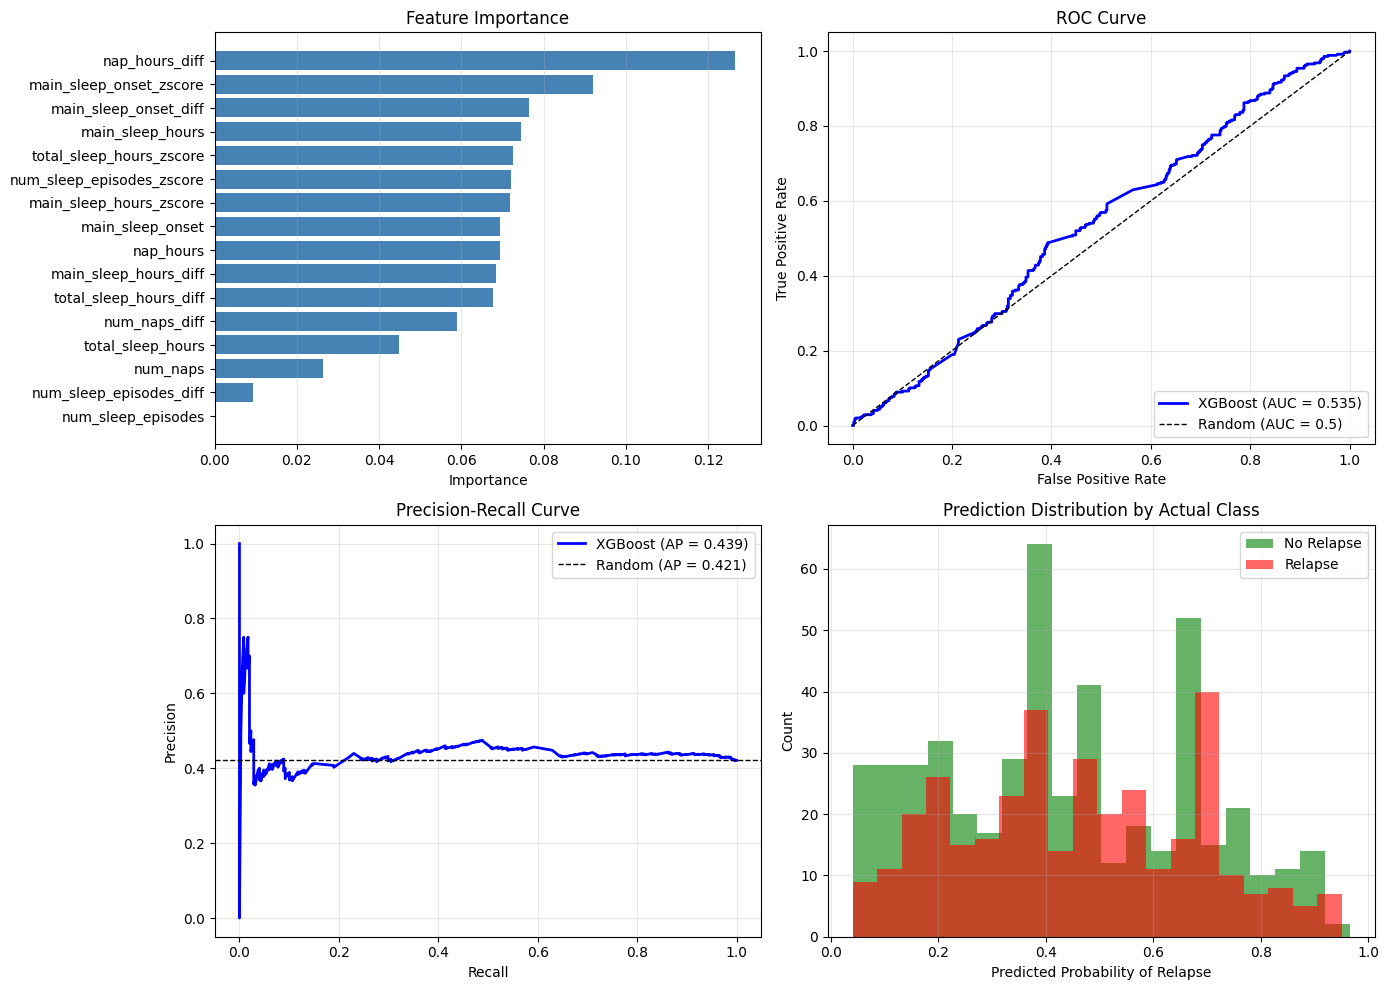


INTERPRETATION

Key findings from feature importance:
- Higher importance = more useful for predicting relapse
- Deviation features (diff, zscore) capture changes from patient's baseline
- Raw features capture absolute sleep patterns

Next steps to improve:
1. Add more sensor features (HR, activity, steps)
2. Add temporal features (rolling averages, trends)
3. Tune hyperparameters
4. Try other models (Random Forest, LightGBM)



In [20]:
# =============================================================================
# AVERAGE SLEEP FEATURE IMPORTANCE & VISUALIZATION (not patient specific but overall)
# =============================================================================

# Feature importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance (top features):")
print(importance_df.to_string(index=False))

# -----------------------------------------------------------------------------
# Plots
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Feature Importance Bar Chart
ax1 = axes[0, 0]
importance_sorted = importance_df.sort_values('importance', ascending=True)
ax1.barh(importance_sorted['feature'], importance_sorted['importance'], color='steelblue')
ax1.set_xlabel('Importance')
ax1.set_title('Feature Importance')
ax1.grid(axis='x', alpha=0.3)

# 2. ROC Curve
ax2 = axes[0, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax2.plot(fpr, tpr, 'b-', linewidth=2, label=f'XGBoost (AUC = {roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend(loc='lower right')
ax2.grid(alpha=0.3)

# 3. Precision-Recall Curve
ax3 = axes[1, 0]
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
ax3.plot(recall, precision, 'b-', linewidth=2, label=f'XGBoost (AP = {pr_auc:.3f})')
ax3.axhline(y=baseline_pr_auc, color='k', linestyle='--', linewidth=1, 
            label=f'Random (AP = {baseline_pr_auc:.3f})')
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.set_title('Precision-Recall Curve')
ax3.legend(loc='upper right')
ax3.grid(alpha=0.3)

# 4. Prediction Distribution
ax4 = axes[1, 1]
ax4.hist(y_pred_proba[y_test == 0], bins=20, alpha=0.6, label='No Relapse', color='green')
ax4.hist(y_pred_proba[y_test == 1], bins=20, alpha=0.6, label='Relapse', color='red')
ax4.set_xlabel('Predicted Probability of Relapse')
ax4.set_ylabel('Count')
ax4.set_title('Prediction Distribution by Actual Class')
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)
print("""
Key findings from feature importance:
- Higher importance = more useful for predicting relapse
- Deviation features (diff, zscore) capture changes from patient's baseline
- Raw features capture absolute sleep patterns

Next steps to improve:
1. Add more sensor features (HR, activity, steps)
2. Add temporal features (rolling averages, trends)
3. Tune hyperparameters
4. Try other models (Random Forest, LightGBM)
""")

In [21]:
# =============================================================================
# XGBOOST MODEL FOR RELAPSE PREDICTION USING SLEEP DIFF (COMPARISON FROM BASELINE NON-RELAPSE) FEATURES ONLY
# =============================================================================
# Using only _diff features from sleep metrics

from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix
)

# ----------------------------------------------------------------------------
# Prepare Data
# ----------------------------------------------------------------------------

diff_features = [c for c in sleep_features_df.columns if c.endswith('_diff')]

train_data = sleep_features_df[sleep_features_df['split_type'] == 'val'].copy()
test_data = sleep_features_df[sleep_features_df['split_type'] == 'test'].copy()

X_train = train_data[diff_features].copy().fillna(0)
y_train = train_data['relapse'].fillna(0).astype(int)

X_test = test_data[diff_features].copy().fillna(0)
y_test = test_data['relapse'].fillna(0).astype(int)

print("NOTE: Using only VAL splits for training (train splits have 0% relapses)")
print("Data split:")
print(f"  Training (train+val): {len(train_data)} days")
print(f"  Test: {len(test_data)} days")

print(f"\nFeature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test: {X_test.shape}")

# ----------------------------------------------------------------------------
# Train XGBoost Model
# ----------------------------------------------------------------------------

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

print("\nTraining XGBoost model (diff features only)...")
model.fit(X_train, y_train)
print("Training complete!")

# ----------------------------------------------------------------------------
# Evaluate Model
# ----------------------------------------------------------------------------

y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)
baseline_pr_auc = y_test.mean()

print("\n" + "=" * 70)
print("MODEL EVALUATION RESULTS (DIFF FEATURES ONLY)")
print("=" * 70)

print(f"\nROC-AUC: {roc_auc:.4f}  (random baseline: 0.5)")
print(f"PR-AUC:  {pr_auc:.4f}  (random baseline: {baseline_pr_auc:.4f})")
print(f"PR-AUC improvement over random: {(pr_auc / baseline_pr_auc - 1) * 100:.1f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Relapse', 'Relapse']))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(f"                 Predicted")
print(f"                 No Relapse  Relapse")
print(f"Actual No Relapse    {cm[0,0]:4d}      {cm[0,1]:4d}")
print(f"Actual Relapse       {cm[1,0]:4d}      {cm[1,1]:4d}")


NOTE: Using only VAL splits for training (train splits have 0% relapses)
Data split:
  Training (train+val): 797 days
  Test: 827 days

Feature matrix shapes:
  X_train: (797, 6)
  X_test: (827, 6)

Training XGBoost model (diff features only)...
Training complete!

MODEL EVALUATION RESULTS (DIFF FEATURES ONLY)

ROC-AUC: 0.5380  (random baseline: 0.5)
PR-AUC:  0.4394  (random baseline: 0.4208)
PR-AUC improvement over random: 4.4%

Classification Report:
              precision    recall  f1-score   support

  No Relapse       0.61      0.65      0.63       479
     Relapse       0.47      0.44      0.45       348

    accuracy                           0.56       827
   macro avg       0.54      0.54      0.54       827
weighted avg       0.55      0.56      0.56       827


Confusion Matrix:
                 Predicted
                 No Relapse  Relapse
Actual No Relapse     310       169
Actual Relapse        196       152


In [ ]:
# =============================================================================
# STEP COUNT FEATURE ENGINEERING
# =============================================================================
# Using patient-specific baselines from train+val non-relapse days

import pandas as pd
import numpy as np
import os
from scipy import stats

print("=" * 70)
print("STEP COUNT FEATURE ENGINEERING")
print("=" * 70)

def load_daily_steps(patient, split, base_path='track1'):
    """Load and aggregate steps to daily totals"""
    step_file = f'{base_path}/{patient}/{split}/step.parquet'
    
    if not os.path.exists(step_file):
        return None
    
    step = pd.read_parquet(step_file)
    
    # Aggregate by day (using start_date_index)
    daily = step.groupby('start_date_index').agg({
        'totalSteps': 'sum',
        'stepsWalking': 'sum', 
        'stepsRunning': 'sum',
        'distance': 'sum',
        'calories': 'sum'
    }).reset_index()
    daily.columns = ['day_index', 'totalSteps', 'stepsWalking', 'stepsRunning', 'distance', 'calories']
    
    return daily

# Process all patients
all_step_features = []
step_baselines = {}

for patient in [f'P{i}' for i in range(1, 10)]:
    print(f"\nProcessing {patient}...")
    
    # Step 1: Calculate baseline from train+val non-relapse days
    baseline_steps = []
    
    for split_type in ['train', 'val']:
        for split_num in range(3):
            split = f'{split_type}_{split_num}'
            relapse_file = f'track1/{patient}/{split}/relapses.csv'
            
            daily_steps = load_daily_steps(patient, split)
            if daily_steps is None or not os.path.exists(relapse_file):
                continue
            
            relapses = pd.read_csv(relapse_file)
            merged = daily_steps.merge(relapses, on='day_index', how='inner')
            
            # Keep only non-relapse days for baseline
            non_relapse = merged[merged['relapse'] == 0]
            baseline_steps.extend(non_relapse['totalSteps'].tolist())
    
    if not baseline_steps:
        print(f"  No baseline data found")
        continue
    
    baseline_mean = np.mean(baseline_steps)
    baseline_std = np.std(baseline_steps)
    step_baselines[patient] = {'mean': baseline_mean, 'std': baseline_std}
    
    print(f"  Baseline: {baseline_mean:.0f} ± {baseline_std:.0f} steps/day (n={len(baseline_steps)} days)")
    
    # Step 2: Process ALL splits with deviation features
    for split_type in ['train', 'val', 'test']:
        for split_num in range(3):
            split = f'{split_type}_{split_num}'
            relapse_file = f'track1/{patient}/{split}/relapses.csv'
            
            daily_steps = load_daily_steps(patient, split)
            if daily_steps is None or not os.path.exists(relapse_file):
                continue
            
            relapses = pd.read_csv(relapse_file)
            merged = daily_steps.merge(relapses, on='day_index', how='inner')
            
            # Calculate deviation from PATIENT'S OWN baseline
            merged['steps_diff'] = merged['totalSteps'] - baseline_mean
            merged['steps_zscore'] = (merged['totalSteps'] - baseline_mean) / baseline_std if baseline_std > 0 else 0
            # Lower steps = higher risk, so create inverted feature
            merged['steps_zscore_inv'] = -merged['steps_zscore']
            
            merged['patient_id'] = patient
            merged['split'] = split
            merged['split_type'] = split_type
            
            all_step_features.append(merged)

step_features_df = pd.concat(all_step_features, ignore_index=True)

print("\n" + "=" * 70)
print("STEP FEATURE ENGINEERING COMPLETE")
print("=" * 70)
print(f"\nTotal records: {len(step_features_df)}")
print(f"\nSplit distribution:")
print(step_features_df.groupby('split_type').size())
print(f"\nRelapse distribution:")
print(step_features_df['relapse'].value_counts())

# Summary statistics
print("\n" + "-" * 70)
print("WITHIN-PATIENT: Steps on Relapse vs Non-Relapse Days")
print("-" * 70)

for patient in [f'P{i}' for i in range(1, 10)]:
    p_data = step_features_df[step_features_df['patient_id'] == patient]
    relapse_days = p_data[p_data['relapse'] == 1]
    non_relapse_days = p_data[p_data['relapse'] == 0]
    
    if len(relapse_days) < 3 or len(non_relapse_days) < 3:
        continue
    
    rel_mean = relapse_days['totalSteps'].mean()
    non_rel_mean = non_relapse_days['totalSteps'].mean()
    diff = rel_mean - non_rel_mean
    pct_diff = diff / non_rel_mean * 100 if non_rel_mean > 0 else 0
    
    t_stat, p_val = stats.ttest_ind(relapse_days['totalSteps'], non_relapse_days['totalSteps'])
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    direction = "↓ fewer steps" if diff < 0 else "↑ more steps"
    
    print(f"  {patient}: Relapse={rel_mean:.0f}, Non-relapse={non_rel_mean:.0f}, "
          f"{direction} ({pct_diff:+.1f}%) p={p_val:.3f} {sig}")

# =============================================================================
# POOLED T-TESTS: All Step Features (Relapse vs Non-Relapse)
# =============================================================================

print("\n" + "=" * 70)
print("POOLED T-TESTS: All Step Features (Relapse vs Non-Relapse)")
print("=" * 70)

# Features to test
features_to_test = [
    'totalSteps', 'stepsWalking', 'stepsRunning', 'distance', 'calories',
    'steps_diff', 'steps_zscore', 'steps_zscore_inv'
]

relapse_days = step_features_df[step_features_df['relapse'] == 1]
non_relapse_days = step_features_df[step_features_df['relapse'] == 0]

results = []
for feat in features_to_test:
    rel_vals = relapse_days[feat].dropna()
    non_rel_vals = non_relapse_days[feat].dropna()
    
    if len(rel_vals) > 0 and len(non_rel_vals) > 0:
        t_stat, p_val = stats.ttest_ind(rel_vals, non_rel_vals)
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
        results.append({
            'Feature': feat,
            'Mean (Relapse)': rel_vals.mean(),
            'Mean (Non-Relapse)': non_rel_vals.mean(),
            't-stat': t_stat,
            'p-value': p_val,
            'Significance': sig
        })

t_test_df = pd.DataFrame(results)
print("\n" + t_test_df.to_string(index=False))
print("\nSignificance legend: *** p<0.001, ** p<0.01, * p<0.05")

In [ ]:
# =============================================================================
# XGBOOST MODEL FOR RELAPSE PREDICTION USING STEP FEATURES
# =============================================================================

from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, 
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve
)
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# Prepare Data
# -----------------------------------------------------------------------------

# Define feature columns
feature_cols = [
    'totalSteps',
    'stepsWalking',
    'stepsRunning',
    'distance',
    'calories',
    'steps_diff',
    'steps_zscore',
    'steps_zscore_inv'
]

# Using ONLY val data for training (it has relapse examples)
train_data = step_features_df[step_features_df['split_type'] == 'val'].copy()
test_data = step_features_df[step_features_df['split_type'] == 'test'].copy()

print("NOTE: Using only VAL splits for training (train splits have 0% relapses)")

print("Data split:")
print(f"  Training (val): {len(train_data)} days")
print(f"  Test: {len(test_data)} days")

print("\nRelapse distribution in training:")
print(train_data['relapse'].value_counts())

print("\nRelapse distribution in test:")
print(test_data['relapse'].value_counts())

# Prepare features and labels
X_train = train_data[feature_cols].copy()
y_train = train_data['relapse'].copy()

X_test = test_data[feature_cols].copy()
y_test = test_data['relapse'].copy()

# Handle missing values
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# Handle any remaining NaN in labels
y_train = y_train.fillna(0).astype(int)
y_test = y_test.fillna(0).astype(int)

print(f"\nFeature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test: {X_test.shape}")

# -----------------------------------------------------------------------------
# Train XGBoost Model
# -----------------------------------------------------------------------------

# Calculate class weight for imbalanced data
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1

print(f"\nClass balance:")
print(f"  Negative (no relapse): {n_neg}")
print(f"  Positive (relapse): {n_pos}")
print(f"  Scale pos weight: {scale_pos_weight:.2f}")

# Initialize and train model
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

print("\nTraining XGBoost model...")
model.fit(X_train, y_train)
print("Training complete!")

# -----------------------------------------------------------------------------
# Evaluate Model
# -----------------------------------------------------------------------------

# Predictions
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

# Metrics
roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)

# Random baseline for PR-AUC (equals positive class proportion)
baseline_pr_auc = y_test.mean()

print("\n" + "=" * 70)
print("MODEL EVALUATION RESULTS")
print("=" * 70)

print(f"\nROC-AUC: {roc_auc:.4f}  (random baseline: 0.5)")
print(f"PR-AUC:  {pr_auc:.4f}  (random baseline: {baseline_pr_auc:.4f})")
print(f"PR-AUC improvement over random: {(pr_auc / baseline_pr_auc - 1) * 100:.1f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Relapse', 'Relapse']))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(f"                 Predicted")
print(f"                 No Relapse  Relapse")
print(f"Actual No Relapse    {cm[0,0]:4d}      {cm[0,1]:4d}")
print(f"Actual Relapse       {cm[1,0]:4d}      {cm[1,1]:4d}")

In [ ]:
# =============================================================================
# STEP FEATURES: FEATURE IMPORTANCE & VISUALIZATION
# =============================================================================
# DEPENDENCY: Run the XGBoost training cell (cell 12) immediately before this cell

# Feature importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance (Step Features):")
print(importance_df.to_string(index=False))

# Verify that model is an XGBClassifier
if not hasattr(model, 'feature_importances_'):
    print("\nWARNING: Model does not have feature_importances_ attribute.")
    print("Please ensure you have run the XGBoost training cell (cell 12) immediately before this cell.")
    print(f"Current model type: {type(model)}")
else:
    # -----------------------------------------------------------------------------
    # Plots
    # -----------------------------------------------------------------------------

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Feature Importance Bar Chart
    ax1 = axes[0, 0]
    importance_sorted = importance_df.sort_values('importance', ascending=True)
    ax1.barh(importance_sorted['feature'], importance_sorted['importance'], color='steelblue')
    ax1.set_xlabel('Importance')
    ax1.set_title('Feature Importance (Step Features)')
    ax1.grid(axis='x', alpha=0.3)

    # 2. ROC Curve
    ax2 = axes[0, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    ax2.plot(fpr, tpr, 'b-', linewidth=2, label=f'XGBoost (AUC = {roc_auc:.3f})')
    ax2.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title('ROC Curve')
    ax2.legend(loc='lower right')
    ax2.grid(alpha=0.3)

    # 3. Precision-Recall Curve
    ax3 = axes[1, 0]
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    ax3.plot(recall, precision, 'b-', linewidth=2, label=f'XGBoost (AP = {pr_auc:.3f})')
    ax3.axhline(y=baseline_pr_auc, color='k', linestyle='--', linewidth=1, 
                label=f'Random (AP = {baseline_pr_auc:.3f})')
    ax3.set_xlabel('Recall')
    ax3.set_ylabel('Precision')
    ax3.set_title('Precision-Recall Curve')
    ax3.legend(loc='upper right')
    ax3.grid(alpha=0.3)

    # 4. Prediction Distribution
    ax4 = axes[1, 1]
    ax4.hist(y_pred_proba[y_test == 0], bins=20, alpha=0.6, label='No Relapse', color='green')
    ax4.hist(y_pred_proba[y_test == 1], bins=20, alpha=0.6, label='Relapse', color='red')
    ax4.set_xlabel('Predicted Probability of Relapse')
    ax4.set_ylabel('Count')
    ax4.set_title('Prediction Distribution by Actual Class')
    ax4.legend()
    ax4.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 70)
    print("INTERPRETATION")
    print("=" * 70)
    print("""
Key findings from step feature importance:
- Higher importance = more useful for predicting relapse
- steps_zscore_inv: Inverted z-score (fewer steps = higher risk)
- steps_diff: Raw deviation from personal baseline
- totalSteps: Absolute daily step count

Comparison with sleep features:
- Step features may capture activity/mobility changes during relapse
- Complement other sensor modalities (HR, sleep)
- Consider combining with other features for improved predictions
""")

In [23]:
# =============================================================================
# XGBOOST MODEL FOR RELAPSE PREDICTION ALL STEP FEATURES
# =============================================================================
# Using step features with patient-specific baseline deviations

from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix
)

# -----------------------------------------------------------------------------
# Prepare Data
# -----------------------------------------------------------------------------

# Define step feature columns (use only those present in the dataset)
step_feature_candidates = [
    'totalSteps',
    'stepsWalking',
    'stepsRunning',
    'distance',
    'calories',
    'steps_diff',
    'steps_zscore',
    'steps_zscore_inv'
]
step_feature_cols = [c for c in step_feature_candidates if c in step_features_df.columns]

train_data = step_features_df[step_features_df['split_type'] == 'val'].copy()
test_data = step_features_df[step_features_df['split_type'] == 'test'].copy()

print("NOTE: Using only VAL splits for training (train splits have 0% relapses)")
print("Data split:")
print(f"  Training (train+val): {len(train_data)} days")
print(f"  Test: {len(test_data)} days")

# Prepare features and labels
X_train = train_data[step_feature_cols].copy().fillna(0)
y_train = train_data['relapse'].copy().fillna(0).astype(int)

X_test = test_data[step_feature_cols].copy().fillna(0)
y_test = test_data['relapse'].copy().fillna(0).astype(int)

print(f"\nFeature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test: {X_test.shape}")

# -----------------------------------------------------------------------------
# Train XGBoost Model
# -----------------------------------------------------------------------------

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

print("\nTraining XGBoost model (steps only)...")
model.fit(X_train, y_train)
print("Training complete!")

# -----------------------------------------------------------------------------
# Evaluate Model
# -----------------------------------------------------------------------------

y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)
baseline_pr_auc = y_test.mean()

print("\n" + "=" * 70)
print("MODEL EVALUATION RESULTS (STEPS ONLY)")
print("=" * 70)

print(f"\nROC-AUC: {roc_auc:.4f}  (random baseline: 0.5)")
print(f"PR-AUC:  {pr_auc:.4f}  (random baseline: {baseline_pr_auc:.4f})")
print(f"PR-AUC improvement over random: {(pr_auc / baseline_pr_auc - 1) * 100:.1f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Relapse', 'Relapse']))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(f"                 Predicted")
print(f"                 No Relapse  Relapse")
print(f"Actual No Relapse    {cm[0,0]:4d}      {cm[0,1]:4d}")
print(f"Actual Relapse       {cm[1,0]:4d}      {cm[1,1]:4d}")


NOTE: Using only VAL splits for training (train splits have 0% relapses)
Data split:
  Training (train+val): 761 days
  Test: 772 days

Feature matrix shapes:
  X_train: (761, 8)
  X_test: (772, 8)

Training XGBoost model (steps only)...
Training complete!

MODEL EVALUATION RESULTS (STEPS ONLY)

ROC-AUC: 0.5271  (random baseline: 0.5)
PR-AUC:  0.4501  (random baseline: 0.4301)
PR-AUC improvement over random: 4.7%

Classification Report:
              precision    recall  f1-score   support

  No Relapse       0.59      0.57      0.58       440
     Relapse       0.45      0.47      0.46       332

    accuracy                           0.53       772
   macro avg       0.52      0.52      0.52       772
weighted avg       0.53      0.53      0.53       772


Confusion Matrix:
                 Predicted
                 No Relapse  Relapse
Actual No Relapse     251       189
Actual Relapse        176       156


In [24]:
# =============================================================================
# XGBOOST MODEL FOR RELAPSE PREDICTION (STEPS DIFF ONLY)
# =============================================================================
# Using only steps_diff feature

from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix
)

# -----------------------------------------------------------------------------
# Prepare Data
# -----------------------------------------------------------------------------

if 'steps_diff' not in step_features_df.columns:
    print("steps_diff not found in step_features_df; cannot train steps-diff model.")
else:
    train_data = step_features_df[step_features_df['split_type'] == 'val'].copy()
    test_data = step_features_df[step_features_df['split_type'] == 'test'].copy()

    print("NOTE: Using only VAL splits for training (train splits have 0% relapses)")
    print("Data split:")
    print(f"  Training (train+val): {len(train_data)} days")
    print(f"  Test: {len(test_data)} days")

    # Prepare features and labels
    X_train = train_data[['steps_diff']].copy().fillna(0)
    y_train = train_data['relapse'].copy().fillna(0).astype(int)

    X_test = test_data[['steps_diff']].copy().fillna(0)
    y_test = test_data['relapse'].copy().fillna(0).astype(int)

    print(f"\nFeature matrix shapes:")
    print(f"  X_train: {X_train.shape}")
    print(f"  X_test: {X_test.shape}")

    # -------------------------------------------------------------------------
    # Train XGBoost Model
    # -------------------------------------------------------------------------

    n_neg = (y_train == 0).sum()
    n_pos = (y_train == 1).sum()
    scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1

    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss'
    )

    print("\nTraining XGBoost model (steps_diff only)...")
    model.fit(X_train, y_train)
    print("Training complete!")

    # -------------------------------------------------------------------------
    # Evaluate Model
    # -------------------------------------------------------------------------

    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    roc_auc = roc_auc_score(y_test, y_pred_proba)
    pr_auc = average_precision_score(y_test, y_pred_proba)
    baseline_pr_auc = y_test.mean()

    print("\n" + "=" * 70)
    print("MODEL EVALUATION RESULTS (STEPS_DIFF ONLY)")
    print("=" * 70)

    print(f"\nROC-AUC: {roc_auc:.4f}  (random baseline: 0.5)")
    print(f"PR-AUC:  {pr_auc:.4f}  (random baseline: {baseline_pr_auc:.4f})")
    print(f"PR-AUC improvement over random: {(pr_auc / baseline_pr_auc - 1) * 100:.1f}%")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Relapse', 'Relapse']))

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(f"                 Predicted")
    print(f"                 No Relapse  Relapse")
    print(f"Actual No Relapse    {cm[0,0]:4d}      {cm[0,1]:4d}")
    print(f"Actual Relapse       {cm[1,0]:4d}      {cm[1,1]:4d}")


NOTE: Using only VAL splits for training (train splits have 0% relapses)
Data split:
  Training (train+val): 761 days
  Test: 772 days

Feature matrix shapes:
  X_train: (761, 1)
  X_test: (772, 1)

Training XGBoost model (steps_diff only)...
Training complete!

MODEL EVALUATION RESULTS (STEPS_DIFF ONLY)

ROC-AUC: 0.5464  (random baseline: 0.5)
PR-AUC:  0.4575  (random baseline: 0.4301)
PR-AUC improvement over random: 6.4%

Classification Report:
              precision    recall  f1-score   support

  No Relapse       0.60      0.64      0.62       440
     Relapse       0.47      0.42      0.45       332

    accuracy                           0.55       772
   macro avg       0.53      0.53      0.53       772
weighted avg       0.54      0.55      0.54       772


Confusion Matrix:
                 Predicted
                 No Relapse  Relapse
Actual No Relapse     283       157
Actual Relapse        192       140


In [25]:
# =============================================================================
# XGBOOST MODEL FOR RELAPSE PREDICTION (SLEEP + STEPS ALL FEATURES)
# =============================================================================
# Using all sleep and step features (excluding labels/IDs)

from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix
)

# -----------------------------------------------------------------------------
# Prepare Data
# -----------------------------------------------------------------------------

# Sleep feature columns (exclude labels/IDs)
sleep_numeric_cols = sleep_features_df.select_dtypes(include=[np.number]).columns.tolist()
sleep_exclude = {'relapse', 'day_index'}
sleep_feature_cols = [
    c for c in sleep_numeric_cols
    if c not in sleep_exclude and not c.endswith('_index')
]

# Step feature columns (exclude labels/IDs)
step_numeric_cols = step_features_df.select_dtypes(include=[np.number]).columns.tolist()
step_exclude = {'relapse', 'day_index'}
step_feature_cols = [
    c for c in step_numeric_cols
    if c not in step_exclude and not c.endswith('_index')
]

# Merge on patient/day/split
combined_sleep_steps = sleep_features_df.merge(
    step_features_df,
    on=['patient_id', 'day_index', 'split', 'split_type', 'relapse'],
    how='inner',
    suffixes=('', '_step')
)

feature_cols = sleep_feature_cols + step_feature_cols

train_data = combined_sleep_steps[combined_sleep_steps['split_type'] == 'val'].copy()
test_data = combined_sleep_steps[combined_sleep_steps['split_type'] == 'test'].copy()

print("NOTE: Using only VAL splits for training (train splits have 0% relapses)")
print("Data split:")
print(f"  Training (train+val): {len(train_data)} days")
print(f"  Test: {len(test_data)} days")

X_train = train_data[feature_cols].copy().fillna(0)
y_train = train_data['relapse'].copy().fillna(0).astype(int)

X_test = test_data[feature_cols].copy().fillna(0)
y_test = test_data['relapse'].copy().fillna(0).astype(int)

print(f"\nFeature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test: {X_test.shape}")

# -----------------------------------------------------------------------------
# Train XGBoost Model
# -----------------------------------------------------------------------------

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1

model = XGBClassifier(
    n_estimators=50,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

print("\nTraining XGBoost model (sleep + steps all features)...")
model.fit(X_train, y_train)
print("Training complete!")

# -----------------------------------------------------------------------------
# Evaluate Model
# -----------------------------------------------------------------------------

y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)
baseline_pr_auc = y_test.mean()

print("\n" + "=" * 70)
print("MODEL EVALUATION RESULTS (SLEEP + STEPS ALL FEATURES)")
print("=" * 70)

print(f"\nROC-AUC: {roc_auc:.4f}  (random baseline: 0.5)")
print(f"PR-AUC:  {pr_auc:.4f}  (random baseline: {baseline_pr_auc:.4f})")
print(f"PR-AUC improvement over random: {(pr_auc / baseline_pr_auc - 1) * 100:.1f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Relapse', 'Relapse']))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(f"                 Predicted")
print(f"                 No Relapse  Relapse")
print(f"Actual No Relapse    {cm[0,0]:4d}      {cm[0,1]:4d}")
print(f"Actual Relapse       {cm[1,0]:4d}      {cm[1,1]:4d}")


NOTE: Using only VAL splits for training (train splits have 0% relapses)
Data split:
  Training (train+val): 761 days
  Test: 772 days

Feature matrix shapes:
  X_train: (761, 25)
  X_test: (772, 25)

Training XGBoost model (sleep + steps all features)...
Training complete!

MODEL EVALUATION RESULTS (SLEEP + STEPS ALL FEATURES)

ROC-AUC: 0.5798  (random baseline: 0.5)
PR-AUC:  0.4924  (random baseline: 0.4301)
PR-AUC improvement over random: 14.5%

Classification Report:
              precision    recall  f1-score   support

  No Relapse       0.64      0.60      0.62       440
     Relapse       0.51      0.55      0.53       332

    accuracy                           0.58       772
   macro avg       0.57      0.57      0.57       772
weighted avg       0.58      0.58      0.58       772


Confusion Matrix:
                 Predicted
                 No Relapse  Relapse
Actual No Relapse     262       178
Actual Relapse        149       183


In [26]:
# =============================================================================
# XGBOOST MODEL FOR RELAPSE PREDICTION- ONLY DIFF FEATURES (SLEEP_DIFF + STEPS_DIFF)
# =============================================================================
# Using only *_diff features from sleep and step metrics

from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix
)

# -----------------------------------------------------------------------------
# Prepare Data
# -----------------------------------------------------------------------------

sleep_diff_cols = [c for c in sleep_features_df.columns if c.endswith('_diff')]
step_diff_cols = [c for c in step_features_df.columns if c.endswith('_diff')]

if not sleep_diff_cols or not step_diff_cols:
    print("Missing diff columns in sleep or step features; cannot run combined model.")
else:
    # Merge on patient/day/split
    diff_combined = sleep_features_df.merge(
        step_features_df,
        on=['patient_id', 'day_index', 'split', 'split_type', 'relapse'],
        how='inner',
        suffixes=('', '_step')
    )

    feature_cols = sleep_diff_cols + step_diff_cols

    train_data = diff_combined[diff_combined['split_type'] == 'val'].copy()
    test_data = diff_combined[diff_combined['split_type'] == 'test'].copy()

    print("NOTE: Using only VAL splits for training (train splits have 0% relapses)")
    print("Data split:")
    print(f"  Training (train+val): {len(train_data)} days")
    print(f"  Test: {len(test_data)} days")

    X_train = train_data[feature_cols].copy().fillna(0)
    y_train = train_data['relapse'].copy().fillna(0).astype(int)

    X_test = test_data[feature_cols].copy().fillna(0)
    y_test = test_data['relapse'].copy().fillna(0).astype(int)

    print(f"\nFeature matrix shapes:")
    print(f"  X_train: {X_train.shape}")
    print(f"  X_test: {X_test.shape}")

    # -------------------------------------------------------------------------
    # Train XGBoost Model
    # -------------------------------------------------------------------------

    n_neg = (y_train == 0).sum()
    n_pos = (y_train == 1).sum()
    scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1

    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss'
    )

    print("\nTraining XGBoost model (sleep_diff + steps_diff)...")
    model.fit(X_train, y_train)
    print("Training complete!")

    # -------------------------------------------------------------------------
    # Evaluate Model
    # -------------------------------------------------------------------------

    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    roc_auc = roc_auc_score(y_test, y_pred_proba)
    pr_auc = average_precision_score(y_test, y_pred_proba)
    baseline_pr_auc = y_test.mean()

    print("\n" + "=" * 70)
    print("MODEL EVALUATION RESULTS (SLEEP_DIFF + STEPS_DIFF)")
    print("=" * 70)

    print(f"\nROC-AUC: {roc_auc:.4f}  (random baseline: 0.5)")
    print(f"PR-AUC:  {pr_auc:.4f}  (random baseline: {baseline_pr_auc:.4f})")
    print(f"PR-AUC improvement over random: {(pr_auc / baseline_pr_auc - 1) * 100:.1f}%")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Relapse', 'Relapse']))

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(f"                 Predicted")
    print(f"                 No Relapse  Relapse")
    print(f"Actual No Relapse    {cm[0,0]:4d}      {cm[0,1]:4d}")
    print(f"Actual Relapse       {cm[1,0]:4d}      {cm[1,1]:4d}")


NOTE: Using only VAL splits for training (train splits have 0% relapses)
Data split:
  Training (train+val): 761 days
  Test: 772 days

Feature matrix shapes:
  X_train: (761, 7)
  X_test: (772, 7)

Training XGBoost model (sleep_diff + steps_diff)...


Training complete!

MODEL EVALUATION RESULTS (SLEEP_DIFF + STEPS_DIFF)

ROC-AUC: 0.5783  (random baseline: 0.5)
PR-AUC:  0.4899  (random baseline: 0.4301)
PR-AUC improvement over random: 13.9%

Classification Report:
              precision    recall  f1-score   support

  No Relapse       0.61      0.60      0.60       440
     Relapse       0.48      0.50      0.49       332

    accuracy                           0.56       772
   macro avg       0.55      0.55      0.55       772
weighted avg       0.56      0.56      0.56       772


Confusion Matrix:
                 Predicted
                 No Relapse  Relapse
Actual No Relapse     262       178
Actual Relapse        165       167


In [27]:
# =============================================================================
# HRV FEATURE ENGINEERING - NIGHTTIME (00:00-08:00)
# =============================================================================
# Derived from nighttime_seqs_v4.pkl (5-sec windows, acc-based sleep filter)
# consistent with Bumblebee AE input.

import pandas as pd
import numpy as np
import os
from pathlib import Path
import pickle

print("=" * 70)
print("HRV FEATURE ENGINEERING - NIGHTTIME (00:00-08:00)")
print("=" * 70)

# Always load v4 sequences so downstream cells (cell 24) can reuse _seqs_v4
with open('cache/nighttime_seqs_v4.pkl', 'rb') as f:
    _seqs_v4, _labels_v4 = pickle.load(f)

# Cache setup
cache_dir = Path("./cache")
cache_dir.mkdir(exist_ok=True)
hrv_cache_path = cache_dir / "hrv_features_nighttime_v3.parquet"
hrv_baseline_path = cache_dir / "hrv_baselines_nighttime_v3.pkl"

if hrv_cache_path.exists() and hrv_baseline_path.exists():
    hrv_features_df = pd.read_parquet(hrv_cache_path)
    with hrv_baseline_path.open("rb") as baseline_file:
        hrv_baselines = pickle.load(baseline_file)
    print("Loaded HRV features and baselines from cache.")
else:
    # Build daily scalars by averaging over the 55 bins per sequence
    # seq shape: [55, 24]; cols 0=rmssd, 1=sdnn, 2=mean_hr, 3=mean_rr
    records = []
    for patient in [f'P{i}' for i in range(1, 10)]:
        if patient not in _seqs_v4:
            continue
        for (split, day_idx), seq in _seqs_v4[patient].items():
            split_type = split.rsplit('_', 1)[0]   # 'train', 'val', or 'test'
            records.append({
                'patient_id': patient,
                'day_index':  day_idx,
                'split':      split,
                'split_type': split_type,
                'rmssd':      float(np.nanmean(seq[:, 0])),
                'sdnn':       float(np.nanmean(seq[:, 1])),
                'mean_hr':    float(np.nanmean(seq[:, 2])),
                'mean_rr':    float(np.nanmean(seq[:, 3])),
                'n_valid':    int((~np.isnan(seq[:, 0])).sum()),
            })

    hrv_df_raw = pd.DataFrame(records)

    # Load relapse labels
    print("\nProcessing all patients...")
    all_relapses = []
    for patient in [f'P{i}' for i in range(1, 10)]:
        for split_type_r in ['train', 'val', 'test']:
            for split_num in range(3):
                split = f'{split_type_r}_{split_num}'
                relapse_file = f'track1/{patient}/{split}/relapses.csv'
                if os.path.exists(relapse_file):
                    rel = pd.read_csv(relapse_file)
                    rel['patient_id'] = patient
                    rel['split'] = split
                    all_relapses.append(rel)

    relapses_df = pd.concat(all_relapses, ignore_index=True)
    hrv_df_raw = hrv_df_raw.merge(
        relapses_df[['patient_id', 'day_index', 'split', 'relapse']],
        on=['patient_id', 'day_index', 'split'], how='inner'
    )

    all_hrv_features = []
    hrv_baselines = {}

    for patient in [f'P{i}' for i in range(1, 10)]:
        print(f"  {patient}...", end=" ")
        hrv_df = hrv_df_raw[hrv_df_raw['patient_id'] == patient].copy()

        if len(hrv_df) == 0:
            print("no data")
            continue

        # Calculate baseline from train+val non-relapse days
        baseline_data = hrv_df[(hrv_df['split_type'].isin(['train', 'val'])) & (hrv_df['relapse'] == 0)]

        if len(baseline_data) > 5:
            baseline = {
                'rmssd_mean': baseline_data['rmssd'].mean(),
                'rmssd_std':  baseline_data['rmssd'].std(),
                'sdnn_mean':  baseline_data['sdnn'].mean(),
                'sdnn_std':   baseline_data['sdnn'].std(),
                'mean_hr_mean': baseline_data['mean_hr'].mean(),
                'mean_hr_std':  baseline_data['mean_hr'].std(),
                'mean_rr_mean': baseline_data['mean_rr'].mean(),
                'mean_rr_std':  baseline_data['mean_rr'].std(),
            }
            hrv_baselines[patient] = baseline

            hrv_df['rmssd_diff']   = hrv_df['rmssd'] - baseline['rmssd_mean']
            hrv_df['rmssd_zscore'] = hrv_df['rmssd_diff'] / baseline['rmssd_std'] if baseline['rmssd_std'] > 0 else 0

            hrv_df['sdnn_diff']   = hrv_df['sdnn'] - baseline['sdnn_mean']
            hrv_df['sdnn_zscore'] = hrv_df['sdnn_diff'] / baseline['sdnn_std'] if baseline['sdnn_std'] > 0 else 0

            hrv_df['mean_hr_diff']   = hrv_df['mean_hr'] - baseline['mean_hr_mean']
            hrv_df['mean_hr_zscore'] = hrv_df['mean_hr_diff'] / baseline['mean_hr_std'] if baseline['mean_hr_std'] > 0 else 0

            hrv_df['mean_rr_diff']   = hrv_df['mean_rr'] - baseline['mean_rr_mean']
            hrv_df['mean_rr_zscore'] = hrv_df['mean_rr_diff'] / baseline['mean_rr_std'] if baseline['mean_rr_std'] > 0 else 0

            all_hrv_features.append(hrv_df)
            print(f"{len(hrv_df)} days, baseline SDNN={baseline['sdnn_mean']:.1f}±{baseline['sdnn_std']:.1f}")
        else:
            print("insufficient baseline data")

    hrv_features_df = pd.concat(all_hrv_features, ignore_index=True)
    hrv_features_df.to_parquet(hrv_cache_path, index=False)
    with hrv_baseline_path.open("wb") as baseline_file:
        pickle.dump(hrv_baselines, baseline_file)
    print("Saved HRV features and baselines to cache.")

print("\n" + "=" * 70)
print("HRV FEATURE ENGINEERING COMPLETE")
print("=" * 70)
print(f"\nTotal records: {len(hrv_features_df)}")
print(f"\nSplit distribution:")
print(hrv_features_df.groupby('split_type').size())
print(f"\nRelapse distribution:")
print(hrv_features_df['relapse'].value_counts())

HRV FEATURE ENGINEERING - NIGHTTIME (00:00-08:00)
Loaded HRV features and baselines from cache.

HRV FEATURE ENGINEERING COMPLETE

Total records: 2042

Split distribution:
split_type
test      509
train    1045
val       488
dtype: int64

Relapse distribution:
relapse
0    1676
1     366
Name: count, dtype: int64


In [ ]:
# =============================================================================
# HRV FEATURE COMPARISON: Relapse vs Non-Relapse (Per Patient + Global)
# =============================================================================

from scipy import stats
import pandas as pd

pd.set_option("display.max_rows", 500)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", None)

print("=" * 70)
print("HRV FEATURE COMPARISON: Relapse vs Non-Relapse (Per Patient + Global)")
print("=" * 70)

hrv_metrics = [
    'rmssd',
    'sdnn',
    'mean_hr',
    'mean_rr',
    'rmssd_diff',
    'sdnn_diff',
    'mean_hr_diff',
    'mean_rr_diff',
    'rmssd_zscore',
    'sdnn_zscore',
    'mean_hr_zscore',
    'mean_rr_zscore'
]

available_metrics = [m for m in hrv_metrics if m in hrv_features_df.columns]
missing_metrics = [m for m in hrv_metrics if m not in hrv_features_df.columns]

if missing_metrics:
    print(f"Missing metrics in hrv_features_df: {missing_metrics}")


def compute_hrv_ttests(df, metrics):
    """
    Compute Welch's t-test for HRV metrics.

    Args:
        df (pd.DataFrame): HRV feature data for a subset of patients.
        metrics (list[str]): HRV metric column names to test.

    Returns:
        pd.DataFrame: Summary of relapse vs non-relapse stats and p-values.
    """
    rows = []

    for metric in metrics:
        relapse_vals = df[df['relapse'] == 1][metric].dropna()
        non_relapse_vals = df[df['relapse'] == 0][metric].dropna()

        n_rel = len(relapse_vals)
        n_non = len(non_relapse_vals)
        relapse_mean = relapse_vals.mean() if n_rel > 0 else np.nan
        non_relapse_mean = non_relapse_vals.mean() if n_non > 0 else np.nan
        relapse_std = relapse_vals.std() if n_rel > 1 else np.nan
        non_relapse_std = non_relapse_vals.std() if n_non > 1 else np.nan
        diff = relapse_mean - non_relapse_mean if n_rel > 0 and n_non > 0 else np.nan

        if n_rel >= 2 and n_non >= 2:
            _, p_val = stats.ttest_ind(
                relapse_vals,
                non_relapse_vals,
                equal_var=False,
                nan_policy='omit'
            )
        else:
            p_val = np.nan

        rows.append({
            'metric': metric,
            'relapse_mean': relapse_mean,
            'relapse_std': relapse_std,
            'non_relapse_mean': non_relapse_mean,
            'non_relapse_std': non_relapse_std,
            'diff': diff,
            'p_value': p_val,
            'n_relapse': n_rel,
            'n_non_relapse': n_non
        })

    return pd.DataFrame(rows)


def format_hrv_table(results_df):
    """
    Format and sort HRV t-test output.

    Args:
        results_df (pd.DataFrame): Results from compute_hrv_ttests.

    Returns:
        pd.DataFrame: Sorted results.
    """
    return results_df.sort_values('p_value')


def fmt(x):
    """
    Format numeric values for display.

    Args:
        x (float): Value to format.

    Returns:
        str: Formatted value.
    """
    return "nan" if pd.isna(x) else f"{x:.4f}"


print("\n" + "=" * 70)
print("PER-PATIENT HRV METRICS")
print("=" * 70)

for patient in sorted(hrv_features_df['patient_id'].unique()):
    patient_df = hrv_features_df[hrv_features_df['patient_id'] == patient]
    results_df = compute_hrv_ttests(patient_df, available_metrics)
    formatted = format_hrv_table(results_df)

    print(f"\nPatient {patient}")
    if len(formatted) == 0:
        print("  No data")
        continue

    print(
        formatted.to_string(
            index=False,
            formatters={
                'relapse_mean': fmt,
                'relapse_std': fmt,
                'non_relapse_mean': fmt,
                'non_relapse_std': fmt,
                'diff': fmt,
                'p_value': fmt
            }
        )
    )

print("\n" + "=" * 70)
print("GLOBAL HRV METRICS (POOLED T-TESTS)")
print("=" * 70)

global_results = compute_hrv_ttests(hrv_features_df, available_metrics)
formatted_global = format_hrv_table(global_results)

print("\n" + formatted_global.to_string(
    index=False,
    formatters={
        'relapse_mean': fmt,
        'relapse_std': fmt,
        'non_relapse_mean': fmt,
        'non_relapse_std': fmt,
        'diff': fmt,
        'p_value': fmt
    }
))

# Add significance annotation
print("\nSignificance legend: *** p<0.001, ** p<0.01, * p<0.05")
print("\nFeatures with significant differences (p < 0.05):")
sig_features = formatted_global[formatted_global['p_value'] < 0.05]
if len(sig_features) > 0:
    for _, row in sig_features.iterrows():
        sig = "***" if row['p_value'] < 0.001 else "**" if row['p_value'] < 0.01 else "*"
        print(f"  {row['metric']}: p={row['p_value']:.4f} {sig}")
else:
    print("  None")

In [ ]:
# =============================================================================
# XGBOOST MODEL FOR RELAPSE PREDICTION USING HRV FEATURES
# =============================================================================

from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, 
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve
)
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# Prepare Data
# -----------------------------------------------------------------------------

# Define feature columns (all available HRV metrics)
feature_cols = [
    'rmssd',
    'sdnn',
    'mean_hr',
    'mean_rr',
    'rmssd_diff',
    'sdnn_diff',
    'mean_hr_diff',
    'mean_rr_diff',
    'rmssd_zscore',
    'sdnn_zscore',
    'mean_hr_zscore',
    'mean_rr_zscore'
]

# Filter to only available features
feature_cols = [c for c in feature_cols if c in hrv_features_df.columns]

# Using ONLY val data for training (it has relapse examples)
train_data = hrv_features_df[hrv_features_df['split_type'] == 'val'].copy()
test_data = hrv_features_df[hrv_features_df['split_type'] == 'test'].copy()

print("NOTE: Using only VAL splits for training (train splits have 0% relapses)")

print("Data split:")
print(f"  Training (val): {len(train_data)} days")
print(f"  Test: {len(test_data)} days")

print("\nRelapse distribution in training:")
print(train_data['relapse'].value_counts())

print("\nRelapse distribution in test:")
print(test_data['relapse'].value_counts())

# Prepare features and labels
X_train = train_data[feature_cols].copy()
y_train = train_data['relapse'].copy()

X_test = test_data[feature_cols].copy()
y_test = test_data['relapse'].copy()

# Handle missing values (fill with 0)
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# Handle any remaining NaN in labels
y_train = y_train.fillna(0).astype(int)
y_test = y_test.fillna(0).astype(int)

print(f"\nFeature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test: {X_test.shape}")

# -----------------------------------------------------------------------------
# Train XGBoost Model
# -----------------------------------------------------------------------------

# Calculate class weight for imbalanced data
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1

print(f"\nClass balance:")
print(f"  Negative (no relapse): {n_neg}")
print(f"  Positive (relapse): {n_pos}")
print(f"  Scale pos weight: {scale_pos_weight:.2f}")

# Initialize and train model
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

print("\nTraining XGBoost model...")
model.fit(X_train, y_train)
print("Training complete!")

# -----------------------------------------------------------------------------
# Evaluate Model
# -----------------------------------------------------------------------------

# Predictions
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

# Metrics
roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)

# Random baseline for PR-AUC (equals positive class proportion)
baseline_pr_auc = y_test.mean()

print("\n" + "=" * 70)
print("MODEL EVALUATION RESULTS (HRV FEATURES)")
print("=" * 70)

print(f"\nROC-AUC: {roc_auc:.4f}  (random baseline: 0.5)")
print(f"PR-AUC:  {pr_auc:.4f}  (random baseline: {baseline_pr_auc:.4f})")
print(f"PR-AUC improvement over random: {(pr_auc / baseline_pr_auc - 1) * 100:.1f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Relapse', 'Relapse']))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(f"                 Predicted")
print(f"                 No Relapse  Relapse")
print(f"Actual No Relapse    {cm[0,0]:4d}      {cm[0,1]:4d}")
print(f"Actual Relapse       {cm[1,0]:4d}      {cm[1,1]:4d}")

In [ ]:
# =============================================================================
# HRV FEATURES: FEATURE IMPORTANCE & VISUALIZATION
# =============================================================================
# DEPENDENCY: Run the XGBoost training cell (HRV model) immediately before this cell

# Feature importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance (HRV Features):")
print(importance_df.to_string(index=False))

# Verify that model is an XGBClassifier
if not hasattr(model, 'feature_importances_'):
    print("\nWARNING: Model does not have feature_importances_ attribute.")
    print("Please ensure you have run the XGBoost training cell immediately before this cell.")
    print(f"Current model type: {type(model)}")
else:
    # -----------------------------------------------------------------------------
    # Plots
    # -----------------------------------------------------------------------------

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Feature Importance Bar Chart
    ax1 = axes[0, 0]
    importance_sorted = importance_df.sort_values('importance', ascending=True)
    ax1.barh(importance_sorted['feature'], importance_sorted['importance'], color='steelblue')
    ax1.set_xlabel('Importance')
    ax1.set_title('Feature Importance (HRV Features)')
    ax1.grid(axis='x', alpha=0.3)

    # 2. ROC Curve
    ax2 = axes[0, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    ax2.plot(fpr, tpr, 'b-', linewidth=2, label=f'XGBoost (AUC = {roc_auc:.3f})')
    ax2.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title('ROC Curve')
    ax2.legend(loc='lower right')
    ax2.grid(alpha=0.3)

    # 3. Precision-Recall Curve
    ax3 = axes[1, 0]
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    ax3.plot(recall, precision, 'b-', linewidth=2, label=f'XGBoost (AP = {pr_auc:.3f})')
    ax3.axhline(y=baseline_pr_auc, color='k', linestyle='--', linewidth=1, 
                label=f'Random (AP = {baseline_pr_auc:.3f})')
    ax3.set_xlabel('Recall')
    ax3.set_ylabel('Precision')
    ax3.set_title('Precision-Recall Curve')
    ax3.legend(loc='upper right')
    ax3.grid(alpha=0.3)

    # 4. Prediction Distribution
    ax4 = axes[1, 1]
    ax4.hist(y_pred_proba[y_test == 0], bins=20, alpha=0.6, label='No Relapse', color='green')
    ax4.hist(y_pred_proba[y_test == 1], bins=20, alpha=0.6, label='Relapse', color='red')
    ax4.set_xlabel('Predicted Probability of Relapse')
    ax4.set_ylabel('Count')
    ax4.set_title('Prediction Distribution by Actual Class')
    ax4.legend()
    ax4.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 70)
    print("INTERPRETATION")
    print("=" * 70)
    print("""
Key findings from HRV feature importance:
- Higher importance = more useful for predicting relapse
- RMSSD/SDNN: Heart rate variability metrics (higher variability typically = healthier)
- Mean HR: Average heart rate (elevated during stress/relapse)
- Z-score and diff features: Deviation from patient's personal baseline
- Features capture cardiovascular stress and autonomic nervous system changes

HRV as relapse indicator:
- Reduced HRV (lower RMSSD/SDNN) associated with relapse risk
- Elevated heart rate (mean_hr_zscore) may indicate stress response
- Deviations from personal baseline capture individual vulnerability
""")

In [29]:
# =============================================================================
# BUILD COMBINED DATASET (HRV + ALL SLEEP + ALL STEP FEATURES)
# =============================================================================
# (moved into demographic merge cell)

print("=" * 70)
print("BUILDING COMBINED HRV + SLEEP + STEPS DATASET")
print("=" * 70)

id_cols = ['patient_id', 'day_index', 'split', 'split_type', 'relapse']

step_numeric_cols = step_features_df.select_dtypes(include=[np.number]).columns.tolist()
step_feature_cols = [
    c for c in step_numeric_cols
    if c not in {'relapse', 'day_index'} and not c.endswith('_index')
]

sleep_numeric_cols = sleep_features_df.select_dtypes(include=[np.number]).columns.tolist()
sleep_feature_cols = [
    c for c in sleep_numeric_cols
    if c not in {'relapse', 'day_index'} and not c.endswith('_index')
]

combined_all = hrv_features_df.merge(
    step_features_df[id_cols + step_feature_cols],
    on=id_cols,
    how='inner'
)

combined_all = combined_all.merge(
    sleep_features_df[id_cols + sleep_feature_cols],
    on=id_cols,
    how='inner',
    suffixes=('', '_sleep')
)

print(f"\nCombined dataset: {len(combined_all)} days")
print(f"Columns: {len(combined_all.columns)}")
print("Contains mean_rr_diff:", 'mean_rr_diff' in combined_all.columns)


BUILDING COMBINED HRV + SLEEP + STEPS DATASET

Combined dataset: 2016 days
Columns: 43
Contains mean_rr_diff: True


HRV FEATURE COMPARISON: Relapse vs Non-Relapse (Per Patient + Global)

PER-PATIENT HRV METRICS

Patient P1
      metric relapse_mean non_relapse_mean    diff p_value  n_relapse  n_non_relapse
mean_rr_diff      98.2219           8.6087 89.6132  0.0000         25            133
     mean_rr     893.9421         804.3289 89.6132  0.0000         25            133
     mean_hr      68.5774          77.0459 -8.4685  0.0000         25            133
mean_hr_diff      -9.3912          -0.9227 -8.4685  0.0000         25            133
  rmssd_diff      -4.5367          -1.4722 -3.0645  0.4251         25            133
       rmssd      52.6538          55.7183 -3.0645  0.4251         25            133
        sdnn      89.9259          85.9546  3.9713  0.5090         25            133
   sdnn_diff       2.9826          -0.9887  3.9713  0.5090         25            133

Patient P2
      metric relapse_mean non_relapse_mean    diff p_value  n_relapse  n_non_relapse
       rmssd      38.2881      

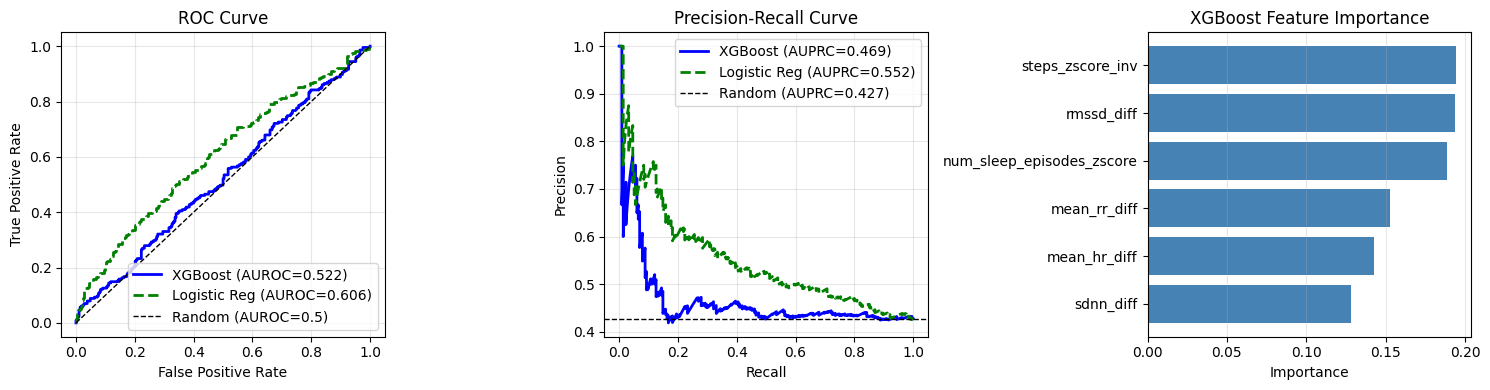


SUMMARY

Combined Model Results (HRV + Sleep + Steps):

  AUROC: 0.5220 (vs 0.5 random)
  AUPRC: 0.4688 (vs 0.4274 random)

The model is 4.4% better than random guessing (AUROC).
The model is 9.7% better than random guessing (AUPRC).

Key predictive features (within-patient deviations):
  1. Fewer steps than personal baseline
  2. More sleep episodes (fragmented sleep)
  3. Changes in nighttime HRV/HR



In [30]:
# =============================================================================
# XGBOOST MODEL HRV AND SLEEP AND STEPS WITH AUROC AND AUPRC
# =============================================================================

from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, 
    precision_recall_curve, roc_curve,
    classification_report, confusion_matrix
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from scipy import stats

print("=" * 70)
print("HRV FEATURE COMPARISON: Relapse vs Non-Relapse (Per Patient + Global)")
print("=" * 70)

hrv_metrics = [
    'rmssd',
    'sdnn',
    'mean_hr',
    'mean_rr',
    'rmssd_diff',
    'sdnn_diff',
    'mean_hr_diff',
    'mean_rr_diff'
]

available_metrics = [m for m in hrv_metrics if m in hrv_features_df.columns]
missing_metrics = [m for m in hrv_metrics if m not in hrv_features_df.columns]

if missing_metrics:
    print(f"Missing metrics in hrv_features_df: {missing_metrics}")


def compute_hrv_ttests(df, metrics):
    """
    Compute Welch's t-test for HRV metrics.

    Args:
        df (pd.DataFrame): HRV feature data for a subset of patients.
        metrics (list[str]): HRV metric column names to test.

    Returns:
        pd.DataFrame: Summary of relapse vs non-relapse stats and p-values.
    """
    rows = []

    for metric in metrics:
        relapse_vals = df[df['relapse'] == 1][metric].dropna()
        non_relapse_vals = df[df['relapse'] == 0][metric].dropna()

        n_rel = len(relapse_vals)
        n_non = len(non_relapse_vals)
        relapse_mean = relapse_vals.mean() if n_rel > 0 else np.nan
        non_relapse_mean = non_relapse_vals.mean() if n_non > 0 else np.nan
        diff = relapse_mean - non_relapse_mean if n_rel > 0 and n_non > 0 else np.nan

        if n_rel >= 2 and n_non >= 2:
            _, p_val = stats.ttest_ind(
                relapse_vals,
                non_relapse_vals,
                equal_var=False,
                nan_policy='omit'
            )
        else:
            p_val = np.nan

        rows.append({
            'metric': metric,
            'relapse_mean': relapse_mean,
            'non_relapse_mean': non_relapse_mean,
            'diff': diff,
            'p_value': p_val,
            'n_relapse': n_rel,
            'n_non_relapse': n_non
        })

    return pd.DataFrame(rows)


def format_hrv_table(results_df):
    """
    Format and sort HRV t-test output.

    Args:
        results_df (pd.DataFrame): Results from compute_hrv_ttests.

    Returns:
        pd.DataFrame: Sorted results.
    """
    return results_df.sort_values('p_value')


def fmt(x):
    """
    Format numeric values for display.

    Args:
        x (float): Value to format.

    Returns:
        str: Formatted value.
    """
    return "nan" if pd.isna(x) else f"{x:.4f}"


print("\n" + "=" * 70)
print("PER-PATIENT HRV METRICS")
print("=" * 70)

for patient in sorted(hrv_features_df['patient_id'].unique()):
    patient_df = hrv_features_df[hrv_features_df['patient_id'] == patient]
    results_df = compute_hrv_ttests(patient_df, available_metrics)
    formatted = format_hrv_table(results_df)

    print(f"\nPatient {patient}")
    if len(formatted) == 0:
        print("  No data")
        continue

    print(
        formatted.to_string(
            index=False,
            formatters={
                'relapse_mean': fmt,
                'non_relapse_mean': fmt,
                'diff': fmt,
                'p_value': fmt
            }
        )
    )

print("\n" + "=" * 70)
print("GLOBAL HRV METRICS")
print("=" * 70)

global_results = compute_hrv_ttests(hrv_features_df, available_metrics)
formatted_global = format_hrv_table(global_results)

print(
    formatted_global.to_string(
        index=False,
        formatters={
            'relapse_mean': fmt,
            'non_relapse_mean': fmt,
            'diff': fmt,
            'p_value': fmt
        }
    )
)

print("\n" + "=" * 70)
print("XGBOOST MODEL: HRV + Sleep + Steps")
print("=" * 70)

# Use the combined dataset from previous cell
val_combined = combined_all[combined_all['split_type'] == 'val']
test_combined = combined_all[combined_all['split_type'] == 'test']

# Feature columns
feature_cols_all = [
    'rmssd_diff',
    'sdnn_diff',
    'mean_hr_diff',
    'mean_rr_diff',
    'steps_zscore_inv',
    'num_sleep_episodes_zscore'
]

X_val = val_combined[feature_cols_all].fillna(0)
y_val = val_combined['relapse']
X_test = test_combined[feature_cols_all].fillna(0)
y_test = test_combined['relapse']

print(f"\nTraining data: {len(X_val)} samples ({y_val.sum()} relapse, {(y_val==0).sum()} non-relapse)")
print(f"Test data: {len(X_test)} samples ({y_test.sum()} relapse, {(y_test==0).sum()} non-relapse)")

# Calculate class weight
scale_pos_weight = (y_val == 0).sum() / (y_val == 1).sum()
print(f"Class imbalance ratio: {scale_pos_weight:.2f}")

# Train XGBoost
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

print("\nTraining XGBoost...")
xgb.fit(X_val, y_val)

# Predictions
y_pred_proba = xgb.predict_proba(X_test)[:, 1]
y_pred = xgb.predict(X_test)

# Calculate metrics
auroc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
baseline_prc = y_test.mean()  # Random baseline for AUPRC

print("\n" + "=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)

print(f"\n  AUROC (ROC-AUC):  {auroc:.4f}  (random baseline: 0.5)")
print(f"  AUPRC (PR-AUC):   {auprc:.4f}  (random baseline: {baseline_prc:.4f})")
print(f"  AUPRC improvement over random: {(auprc / baseline_prc - 1) * 100:.1f}%")

print("\n" + "-" * 70)
print("Classification Report:")
print("-" * 70)
print(classification_report(y_test, y_pred, target_names=['No Relapse', 'Relapse']))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(f"                 Predicted")
print(f"                 No Relapse  Relapse")
print(f"Actual No Relapse    {cm[0,0]:4d}      {cm[0,1]:4d}")
print(f"Actual Relapse       {cm[1,0]:4d}      {cm[1,1]:4d}")

print("\n" + "-" * 70)
print("Feature Importance:")
print("-" * 70)
importance_df = pd.DataFrame({
    'feature': feature_cols_all,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False)
print(importance_df.to_string(index=False))

# -----------------------------------------------------------------------------
# Compare with Logistic Regression
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

lr = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])
lr.fit(X_val, y_val)
y_pred_proba_lr = lr.predict_proba(X_test)[:, 1]

auroc_lr = roc_auc_score(y_test, y_pred_proba_lr)
auprc_lr = average_precision_score(y_test, y_pred_proba_lr)

print(f"\n{'Model':<25} {'AUROC':>10} {'AUPRC':>10}")
print("-" * 50)
print(f"{'Logistic Regression':<25} {auroc_lr:>10.4f} {auprc_lr:>10.4f}")
print(f"{'XGBoost':<25} {auroc:>10.4f} {auprc:>10.4f}")
print(f"{'Random Baseline':<25} {'0.5000':>10} {baseline_prc:>10.4f}")

# -----------------------------------------------------------------------------
# Visualization
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: ROC Curve
ax1 = axes[0]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)

ax1.plot(fpr_xgb, tpr_xgb, 'b-', linewidth=2, label=f'XGBoost (AUROC={auroc:.3f})')
ax1.plot(fpr_lr, tpr_lr, 'g--', linewidth=2, label=f'Logistic Reg (AUROC={auroc_lr:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUROC=0.5)')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)

# Plot 2: Precision-Recall Curve
ax2 = axes[1]
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_pred_proba)
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_pred_proba_lr)

ax2.plot(recall_xgb, precision_xgb, 'b-', linewidth=2, label=f'XGBoost (AUPRC={auprc:.3f})')
ax2.plot(recall_lr, precision_lr, 'g--', linewidth=2, label=f'Logistic Reg (AUPRC={auprc_lr:.3f})')
ax2.axhline(y=baseline_prc, color='k', linestyle='--', linewidth=1, 
            label=f'Random (AUPRC={baseline_prc:.3f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.3)

# Plot 3: Feature Importance
ax3 = axes[2]
importance_sorted = importance_df.sort_values('importance', ascending=True)
ax3.barh(importance_sorted['feature'], importance_sorted['importance'], color='steelblue')
ax3.set_xlabel('Importance')
ax3.set_title('XGBoost Feature Importance')
ax3.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"""
Combined Model Results (HRV + Sleep + Steps):

  AUROC: {auroc:.4f} (vs 0.5 random)
  AUPRC: {auprc:.4f} (vs {baseline_prc:.4f} random)
  
The model is {(auroc - 0.5) / 0.5 * 100:.1f}% better than random guessing (AUROC).
The model is {(auprc / baseline_prc - 1) * 100:.1f}% better than random guessing (AUPRC).

Key predictive features (within-patient deviations):
  1. Fewer steps than personal baseline
  2. More sleep episodes (fragmented sleep)
  3. Changes in nighttime HRV/HR
""")

In [31]:
# =============================================================================
# ADD DEMOGRAPHIC FEATURES
# =============================================================================

print("=" * 70)
print("LOADING DEMOGRAPHIC DATA")
print("=" * 70)

# Load demographics
demographics = pd.read_csv('./track1/demographics.csv')
print(f"\nDemographics shape: {demographics.shape}")
print(f"\nColumns: {demographics.columns.tolist()}")

# Clean column names (strip whitespace)
demographics.columns = demographics.columns.str.strip()

# Display demographics
print("\nDemographics data:")
print(demographics.to_string())

# Select potentially useful features
# Avoid leaky features (anything that might change with relapse status)
demographic_features = [
    'patient_id', 'age', 'gender', 'maritial_status', 'birth_place', 
    'educational_level', 'diagnosis', 'year_illness', 
    'birth_complications', 'family_psychiatric_history',
    'smoking', 'alcohol_consumption', 'cannabis_user',
    'treatment_compliance', 'dominant_hand', 'smartwatch_hand'
]

# Filter to available columns
available_cols = [c for c in demographic_features if c in demographics.columns]
demo_df = demographics[available_cols].copy()

# Clean string columns
for col in demo_df.columns:
    if demo_df[col].dtype == 'object':
        demo_df[col] = demo_df[col].str.strip()

print(f"\nSelected demographic features: {available_cols}")
print(demo_df)

LOADING DEMOGRAPHIC DATA

Demographics shape: (9, 28)

Columns: ['patient_id', 'Unnamed: 1', 'age', 'gender', 'maritial_status', 'birth_place', 'occupation', 'educational_level', 'diagnosis', 'year_illness', 'birth_complications', 'family_psychiatric_history', 'smoking', 'smoking_amount', 'smoking_past_years_use', 'alcohol_consumption', 'alcohol_consumption_amount', 'alcohol_past_years_use', 'cannabis_user', 'cannabis_amount', 'cannabis_past_years_use', 'other_substances', 'other_substances_amount', 'other_substances_past_years_use', 'dominant_hand', 'smartwatch_hand', 'treatment_compliance', 'growth_disorder']

Demographics data:
  patient_id  Unnamed: 1  age   gender maritial_status birth_place            occupation  educational_level                   diagnosis  year_illness  birth_complications  family_psychiatric_history  smoking  smoking_amount  smoking_past_years_use  alcohol_consumption alcohol_consumption_amount  alcohol_past_years_use  cannabis_user  cannabis_amount  cannabis

In [ ]:
# =============================================================================
# ENCODE DEMOGRAPHIC FEATURES AND MERGE WITH SENSOR DATA
# =============================================================================

print("=" * 70)
print("ENCODING DEMOGRAPHIC FEATURES")
print("=" * 70)

# Build combined dataset (HRV + all sleep + all step features)
id_cols = ['patient_id', 'day_index', 'split', 'split_type', 'relapse']

step_numeric_cols = step_features_df.select_dtypes(include=[np.number]).columns.tolist()
step_feature_cols = [
    c for c in step_numeric_cols
    if c not in {'relapse', 'day_index'} and not c.endswith('_index')
]

sleep_numeric_cols = sleep_features_df.select_dtypes(include=[np.number]).columns.tolist()
sleep_feature_cols = [
    c for c in sleep_numeric_cols
    if c not in {'relapse', 'day_index'} and not c.endswith('_index')
]

combined_all = hrv_features_df.merge(
    step_features_df[id_cols + step_feature_cols],
    on=id_cols,
    how='inner'
)

combined_all = combined_all.merge(
    sleep_features_df[id_cols + sleep_feature_cols],
    on=id_cols,
    how='inner',
    suffixes=('', '_sleep')
)

print(f"\nCombined dataset: {len(combined_all)} days")
print(f"Columns: {len(combined_all.columns)}")

# Create encoded version
demo_encoded = demo_df.copy()

# Encode categorical variables
# Gender: Female=0, Male=1
demo_encoded['gender_male'] = (demo_encoded['gender'] == 'Male').astype(int)

# Marital status: Married=1, Single=0
demo_encoded['married'] = (demo_encoded['maritial_status'] == 'Married').astype(int)

# Birth place: Urban=1, Rural=0
demo_encoded['urban'] = (demo_encoded['birth_place'] == 'Urban').astype(int)

# Boolean columns
demo_encoded['birth_complications'] = demo_encoded['birth_complications'].map({'TRUE': 1, 'FALSE': 0, True: 1, False: 0})
demo_encoded['family_psychiatric_history'] = demo_encoded['family_psychiatric_history'].map({'TRUE': 1, 'FALSE': 0, True: 1, False: 0})
demo_encoded['smoking'] = demo_encoded['smoking'].map({'TRUE': 1, 'FALSE': 0, True: 1, False: 0})
demo_encoded['alcohol_consumption'] = demo_encoded['alcohol_consumption'].map({'TRUE': 1, 'FALSE': 0, True: 1, False: 0})
demo_encoded['cannabis_user'] = demo_encoded['cannabis_user'].map({'TRUE': 1, 'FALSE': 0, True: 1, False: 0})

# Treatment compliance: ordinal encoding
# Strip whitespace first to handle CSV padding artifacts (e.g. " Very Good" -> "Very Good")
compliance_map = {'Very Good': 3, 'Good': 2, 'Moderate': 1, 'Poor': 0}
demo_encoded['compliance_score'] = demo_encoded['treatment_compliance'].str.strip().map(compliance_map)
# Fill any residual NaN with median (better than 0="Poor" for truly missing data)
demo_encoded['compliance_score'] = demo_encoded['compliance_score'].fillna(
    demo_encoded['compliance_score'].median()
)

# Diagnosis: One-hot encode (this is important for psychiatric outcomes)
diagnosis_dummies = pd.get_dummies(demo_encoded['diagnosis'], prefix='diag')
demo_encoded = pd.concat([demo_encoded, diagnosis_dummies], axis=1)

# Hand dominance match (smartwatch on dominant hand = 1)
demo_encoded['watch_dominant'] = (demo_encoded['dominant_hand'] == demo_encoded['smartwatch_hand']).astype(int)

# Select final numeric features
demographic_feature_cols = [
    'age', 'educational_level', 'year_illness',
    'gender_male', 'married', 'urban', 
    'birth_complications', 'family_psychiatric_history',
    'smoking', 'alcohol_consumption', 'cannabis_user',
    'compliance_score', 'watch_dominant'
] + [c for c in demo_encoded.columns if c.startswith('diag_')]

# Filter to available
demographic_feature_cols = [c for c in demographic_feature_cols if c in demo_encoded.columns]

print(f"\nEncoded demographic features: {demographic_feature_cols}")
print(f"\nEncoded data:")
print(demo_encoded[['patient_id'] + demographic_feature_cols].to_string())

# Merge with combined sensor data
# First, create a clean patient column in combined_all
combined_with_demo = combined_all.copy()
combined_with_demo = combined_with_demo.merge(
    demo_encoded[['patient_id'] + demographic_feature_cols],
    on='patient_id',
    how='left'
)

print(f"\nCombined data shape: {combined_with_demo.shape}")
print(f"\nSample of merged data:")
print(combined_with_demo[['patient_id', 'split', 'relapse'] + demographic_feature_cols[:5]].head(10))

# =============================================================================
# DEMOGRAPHIC ANALYSIS: PATIENT-LEVEL RELAPSE BURDEN CORRELATIONS
# =============================================================================

print("\n" + "=" * 70)
print("DEMOGRAPHIC ANALYSIS (PATIENT LEVEL)")
print("=" * 70)

print("""
METHODOLOGICAL NOTE:
====================
Day-level t-tests on demographic features are INVALID because:
1. Demographics are static patient-level data (one value per patient)
2. When repeated across hundreds of days, they create pseudo-replication
3. Effective N = 9 patients, not hundreds of days

Instead, we compute PATIENT-LEVEL correlations with relapse burden:
- Relapse burden = total count of relapse days per patient in val+test splits
- Sample size = 9 patients (low power, exploratory only)
- We use non-parametric tests (Spearman, Mann-Whitney) appropriate for N=9
""")

# Compute per-patient relapse counts from val+test splits
patient_relapse_counts = combined_with_demo[
    combined_with_demo['split_type'].isin(['val', 'test'])
].groupby('patient_id')['relapse'].agg(['sum', 'count']).reset_index()
patient_relapse_counts.columns = ['patient_id', 'relapse_days', 'total_days']

# Build patient-level summary table
summary_data = []
for patient_id in sorted(demo_encoded['patient_id'].unique()):
    demo_row = demo_encoded[demo_encoded['patient_id'] == patient_id].iloc[0]
    relapse_row = patient_relapse_counts[patient_relapse_counts['patient_id'] == patient_id]
    
    if len(relapse_row) > 0:
        relapse_days = int(relapse_row['relapse_days'].values[0])
        total_days = int(relapse_row['total_days'].values[0])
    else:
        relapse_days = 0
        total_days = 0
    
    row = {
        'patient_id': patient_id,
        'age': demo_row['age'],
        'gender': demo_row['gender'],
        'diagnosis': demo_row['diagnosis'],
        'compliance': demo_row['treatment_compliance'],
        'year_illness': demo_row['year_illness'],
        'relapse_days': relapse_days,
        'total_days': total_days,
        'relapse_rate': relapse_days / total_days if total_days > 0 else 0
    }
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)

print("\n--- PART 1: Patient-Level Summary (N=9) ---\n")
print(summary_df.to_string(index=False))
print(f"\nTotal relapse days: {summary_df['relapse_days'].sum()}")
print(f"Mean relapse burden: {summary_df['relapse_days'].mean():.1f} days")
print(f"Median relapse burden: {summary_df['relapse_days'].median():.1f} days")

# Part 2: Spearman correlations with continuous features
from scipy.stats import spearmanr, mannwhitneyu

continuous_features = ['age', 'educational_level', 'year_illness', 'compliance_score']
continuous_features = [f for f in continuous_features if f in demo_encoded.columns]

print("\n--- PART 2: Spearman Correlations (Patient Level, N=9) ---\n")
print("Correlation with total relapse days (very low power; exploratory only):\n")

corr_results = []
for feature in continuous_features:
    feature_values = demo_encoded[feature].values
    relapse_values = summary_df['relapse_days'].values
    
    # Remove any NaN
    mask = ~(np.isnan(feature_values) | np.isnan(relapse_values))
    if mask.sum() < 3:  # Need at least 3 for correlation
        rho, p_val = np.nan, np.nan
    else:
        rho, p_val = spearmanr(feature_values[mask], relapse_values[mask])
    
    corr_results.append({
        'feature': feature,
        'rho': rho,
        'p_value': p_val,
        'n': mask.sum()
    })
    print(f"  {feature:25s}  ρ = {rho:6.3f}  p = {p_val:.4f}  (n={mask.sum()})")

print("\n  (p < 0.05 bold interpretation requires n >> 9; use only for hypothesis generation)")

# Part 3: Mann-Whitney U for binary features
binary_features = ['gender_male', 'smoking', 'alcohol_consumption', 'cannabis_user']
binary_features = [f for f in binary_features if f in demo_encoded.columns]

print("\n--- PART 3: Mann-Whitney U Tests (Binary Features, Patient Level) ---\n")
print("Relapse burden by demographic groups (N=9, low power):\n")

for feature in binary_features:
    group0_indices = demo_encoded[demo_encoded[feature] == 0].index
    group1_indices = demo_encoded[demo_encoded[feature] == 1].index
    
    group0_relapses = summary_df.iloc[group0_indices]['relapse_days'].values
    group1_relapses = summary_df.iloc[group1_indices]['relapse_days'].values
    
    if len(group0_relapses) > 0 and len(group1_relapses) > 0:
        stat, p_val = mannwhitneyu(group0_relapses, group1_relapses)
        group_names = {
            'gender_male': ('Female', 'Male'),
            'smoking': ('No Smoking', 'Smoker'),
            'alcohol_consumption': ('No Alcohol', 'Alcohol User'),
            'cannabis_user': ('No Cannabis', 'Cannabis User')
        }
        g0_name, g1_name = group_names.get(feature, ('Group 0', 'Group 1'))
        
        print(f"  {feature:25s}")
        print(f"    {g0_name:20s}: mean={group0_relapses.mean():.1f}, n={len(group0_relapses)}")
        print(f"    {g1_name:20s}: mean={group1_relapses.mean():.1f}, n={len(group1_relapses)}")
        print(f"    U-stat = {stat:.1f}, p = {p_val:.4f}\n")

# Part 4: Scatter plots of relapse burden vs continuous features
print("\n--- PART 4: Scatter Plots (Patient Level) ---\n")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

plot_features = ['age', 'year_illness', 'compliance_score', 'educational_level']
plot_features = [f for f in plot_features if f in demo_encoded.columns]

for idx, feature in enumerate(plot_features):
    ax = axes[idx]
    
    feature_vals = demo_encoded[feature].values
    relapse_vals = summary_df['relapse_days'].values
    patients = summary_df['patient_id'].values
    
    # Scatter plot
    ax.scatter(feature_vals, relapse_vals, s=100, alpha=0.6, color='steelblue', edgecolors='black')
    
    # Label each point with patient ID
    for i, patient in enumerate(patients):
        ax.annotate(patient, (feature_vals[i], relapse_vals[i]), 
                   fontsize=9, ha='right', va='bottom')
    
    ax.set_xlabel(feature, fontsize=11)
    ax.set_ylabel('Total Relapse Days', fontsize=11)
    ax.set_title(f'Relapse Burden vs {feature} (N=9)', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=-2)

plt.tight_layout()
plt.show()

print("(Each point = one patient; labeled by patient ID; N=9 = very low power)")

GOOD UP TO HERE

COMPREHENSIVE MODEL: All Sensor Features + Demographics

Train samples: 486
Test samples: 503
Train relapse rate: 0.307
Test relapse rate: 0.427

Feature breakdown:
  HRV features: 13
  Sleep features: 13
  Step features: 5
  Demographic features: 18
  Total features: 56

Class imbalance (scale_pos_weight): 2.26

----------------------------------------------------------------------
Training XGBoost...
----------------------------------------------------------------------

XGBoost Performance:
  AUROC: 0.5736
  AUPRC: 0.4680

----------------------------------------------------------------------
Training Logistic Regression...
----------------------------------------------------------------------

Logistic Regression Performance:
  AUROC: 0.5854
  AUPRC: 0.5136

MODEL COMPARISON

Model                                           AUROC        AUPRC
----------------------------------------------------------------------
XGBoost (All Features)                         0.5736       0.4680
Logi

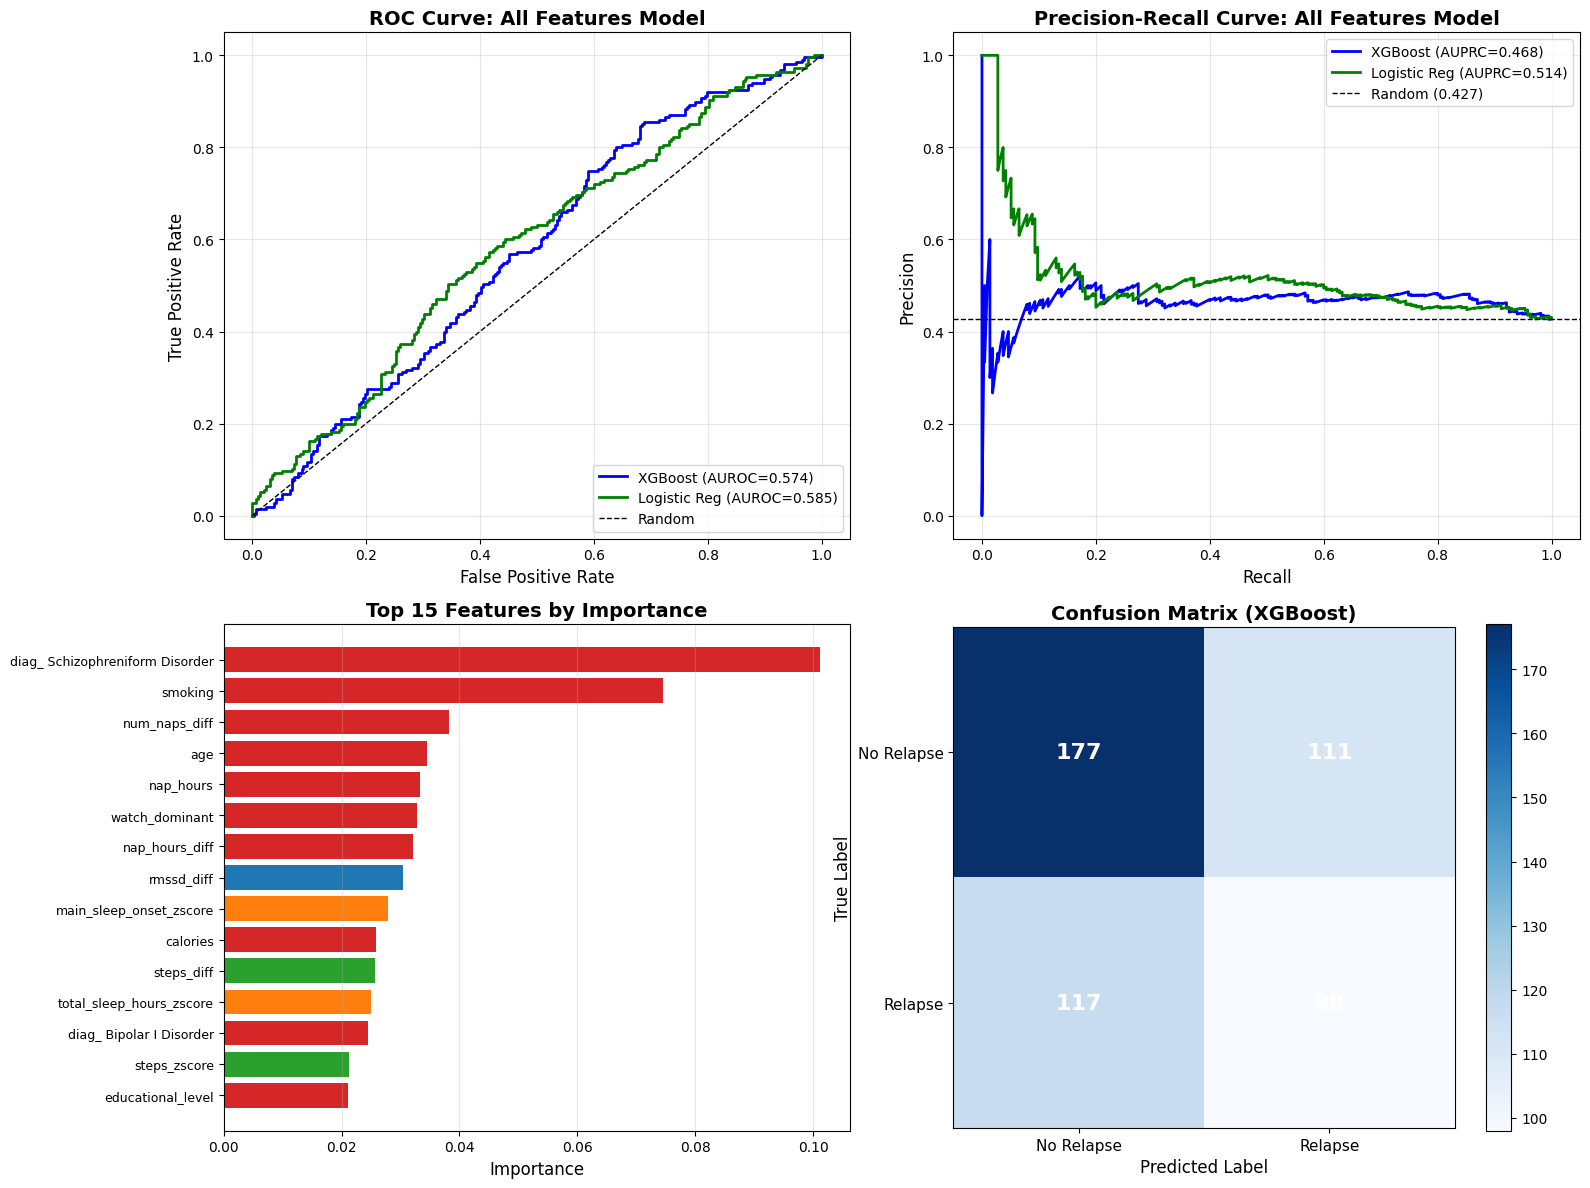


CLASSIFICATION REPORT (XGBoost)
              precision    recall  f1-score   support

  No Relapse       0.60      0.61      0.61       288
     Relapse       0.47      0.46      0.46       215

    accuracy                           0.55       503
   macro avg       0.54      0.54      0.54       503
weighted avg       0.55      0.55      0.55       503



In [33]:
# =============================================================================
# COMPREHENSIVE MODEL: All Sensor Features (HRV + Sleep + Steps) + Demographics
# =============================================================================

from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt

print("=" * 70)
print("COMPREHENSIVE MODEL: All Sensor Features + Demographics")
print("=" * 70)

# Split into train (val) and test sets
train_data = combined_with_demo[combined_with_demo['split'].str.startswith('val')]
test_data = combined_with_demo[combined_with_demo['split'].str.startswith('test')]

print(f"\nTrain samples: {len(train_data)}")
print(f"Test samples: {len(test_data)}")
print(f"Train relapse rate: {train_data['relapse'].mean():.3f}")
print(f"Test relapse rate: {test_data['relapse'].mean():.3f}")

# Define feature sets
# Exclude ID columns and target
exclude_cols = ['patient_id', 'day_index', 'split', 'split_type', 'relapse']
all_feature_cols = [c for c in combined_with_demo.columns if c not in exclude_cols]

# Separate into feature groups for analysis
hrv_features = [c for c in all_feature_cols if any(x in c for x in ['rmssd', 'sdnn', 'mean_hr', 'mean_rr', 'n_valid'])]
sleep_features = [c for c in all_feature_cols if any(x in c for x in ['sleep', 'duration', 'episode'])]
step_features = [c for c in all_feature_cols if 'step' in c]
demographic_features = [c for c in all_feature_cols if c in demographic_feature_cols]

print(f"\nFeature breakdown:")
print(f"  HRV features: {len(hrv_features)}")
print(f"  Sleep features: {len(sleep_features)}")
print(f"  Step features: {len(step_features)}")
print(f"  Demographic features: {len(demographic_features)}")
print(f"  Total features: {len(all_feature_cols)}")

# Prepare data
X_train = train_data[all_feature_cols].fillna(0)
X_test = test_data[all_feature_cols].fillna(0)
y_train = train_data['relapse'].values
y_test = test_data['relapse'].values

# Calculate class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nClass imbalance (scale_pos_weight): {scale_pos_weight:.2f}")

# -----------------------------------------------------------------------------
# XGBoost Model
# -----------------------------------------------------------------------------
print("\n" + "-" * 70)
print("Training XGBoost...")
print("-" * 70)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_model.predict(X_test)

auroc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
auprc_xgb = average_precision_score(y_test, y_pred_proba_xgb)

print(f"\nXGBoost Performance:")
print(f"  AUROC: {auroc_xgb:.4f}")
print(f"  AUPRC: {auprc_xgb:.4f}")

# -----------------------------------------------------------------------------
# Logistic Regression Model (for comparison)
# -----------------------------------------------------------------------------
print("\n" + "-" * 70)
print("Training Logistic Regression...")
print("-" * 70)

lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])
lr_model.fit(X_train, y_train)

y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]
y_pred_lr = lr_model.predict(X_test)

auroc_lr = roc_auc_score(y_test, y_pred_proba_lr)
auprc_lr = average_precision_score(y_test, y_pred_proba_lr)

print(f"\nLogistic Regression Performance:")
print(f"  AUROC: {auroc_lr:.4f}")
print(f"  AUPRC: {auprc_lr:.4f}")

# -----------------------------------------------------------------------------
# Results Summary
# -----------------------------------------------------------------------------
baseline_prc = y_test.mean()

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)
print(f"\n{'Model':<40} {'AUROC':>12} {'AUPRC':>12}")
print("-" * 70)
print(f"{'XGBoost (All Features)':<40} {auroc_xgb:>12.4f} {auprc_xgb:>12.4f}")
print(f"{'Logistic Regression (All Features)':<40} {auroc_lr:>12.4f} {auprc_lr:>12.4f}")
print("-" * 70)
print(f"{'Random Baseline':<40} {'0.5000':>12} {baseline_prc:>12.4f}")

# -----------------------------------------------------------------------------
# Feature Importance (XGBoost)
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("TOP 20 MOST IMPORTANT FEATURES (XGBoost)")
print("=" * 70)

feature_importance = pd.DataFrame({
    'feature': all_feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n")
for idx, row in feature_importance.head(20).iterrows():
    # Determine feature type
    if row['feature'] in hrv_features:
        feat_type = "HRV"
    elif row['feature'] in sleep_features:
        feat_type = "Sleep"
    elif row['feature'] in step_features:
        feat_type = "Steps"
    elif row['feature'] in demographic_features:
        feat_type = "Demo"
    else:
        feat_type = "Other"
    
    print(f"  {row['feature']:<40} {row['importance']:>8.4f}  [{feat_type}]")

# -----------------------------------------------------------------------------
# Visualizations
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ROC Curve
ax1 = axes[0, 0]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
ax1.plot(fpr_xgb, tpr_xgb, 'b-', linewidth=2, label=f'XGBoost (AUROC={auroc_xgb:.3f})')
ax1.plot(fpr_lr, tpr_lr, 'g-', linewidth=2, label=f'Logistic Reg (AUROC={auroc_lr:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curve: All Features Model', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(alpha=0.3)

# PR Curve
ax2 = axes[0, 1]
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_pred_proba_xgb)
prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_pred_proba_lr)
ax2.plot(rec_xgb, prec_xgb, 'b-', linewidth=2, label=f'XGBoost (AUPRC={auprc_xgb:.3f})')
ax2.plot(rec_lr, prec_lr, 'g-', linewidth=2, label=f'Logistic Reg (AUPRC={auprc_lr:.3f})')
ax2.axhline(y=baseline_prc, color='k', linestyle='--', linewidth=1, label=f'Random ({baseline_prc:.3f})')
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curve: All Features Model', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(alpha=0.3)

# Feature Importance
ax3 = axes[1, 0]
top_features = feature_importance.head(15)
colors = ['#1f77b4' if f in hrv_features else '#ff7f0e' if f in sleep_features else '#2ca02c' if f in step_features else '#d62728' 
          for f in top_features['feature']]
ax3.barh(range(len(top_features)), top_features['importance'], color=colors)
ax3.set_yticks(range(len(top_features)))
ax3.set_yticklabels(top_features['feature'], fontsize=9)
ax3.set_xlabel('Importance', fontsize=12)
ax3.set_title('Top 15 Features by Importance', fontsize=14, fontweight='bold')
ax3.invert_yaxis()
ax3.grid(axis='x', alpha=0.3)

# Confusion Matrix (XGBoost)
ax4 = axes[1, 1]
cm = confusion_matrix(y_test, y_pred_xgb)
im = ax4.imshow(cm, interpolation='nearest', cmap='Blues')
ax4.set_title('Confusion Matrix (XGBoost)', fontsize=14, fontweight='bold')
tick_marks = [0, 1]
ax4.set_xticks(tick_marks)
ax4.set_yticks(tick_marks)
ax4.set_xticklabels(['No Relapse', 'Relapse'], fontsize=11)
ax4.set_yticklabels(['No Relapse', 'Relapse'], fontsize=11)
ax4.set_ylabel('True Label', fontsize=12)
ax4.set_xlabel('Predicted Label', fontsize=12)

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax4.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=16, fontweight='bold')

plt.colorbar(im, ax=ax4)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# Classification Report
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("CLASSIFICATION REPORT (XGBoost)")
print("=" * 70)
print(classification_report(y_test, y_pred_xgb, target_names=['No Relapse', 'Relapse']))

In [34]:
# =============================================================================
# SLEEP-VERIFIED HRV FEATURES
# =============================================================================
# Derived from nighttime_seqs_v4.pkl (acc-based sleep filter already applied)
# consistent with Bumblebee AE input. _seqs_v4 loaded in cell 16.

print("=" * 70)
print("HRV FEATURE ENGINEERING: Sleep-Verified (from nighttime_seqs_v4.pkl)")
print("=" * 70)

from pathlib import Path

# Cache setup
cache_dir = Path("./cache")
cache_dir.mkdir(exist_ok=True)
hrv_sleep_verified_path = cache_dir / "hrv_sleep_verified_v2.parquet"

if hrv_sleep_verified_path.exists():
    hrv_sleep_verified_df = pd.read_parquet(hrv_sleep_verified_path)
    print("Loaded sleep-verified HRV features from cache.")
else:
    # _seqs_v4 loaded in cell 16; reuse here
    # seq shape: [55, 24]; cols 0=rmssd, 1=sdnn, 2=mean_hr, 3=mean_rr
    records_sv = []
    for patient in [f'P{i}' for i in range(1, 10)]:
        if patient not in _seqs_v4:
            continue
        for (split, day_idx), seq in _seqs_v4[patient].items():
            split_type = split.rsplit('_', 1)[0]
            n_valid = int((~np.isnan(seq[:, 0])).sum())
            records_sv.append({
                'patient_id':  patient,
                'day_index':   day_idx,
                'split':       split,
                'split_type':  split_type,
                'hrv_samples': n_valid,
                'rmssd':       float(np.nanmean(seq[:, 0])),
                'sdnn':        float(np.nanmean(seq[:, 1])),
                'mean_hr':     float(np.nanmean(seq[:, 2])),
                'mean_rr':     float(np.nanmean(seq[:, 3])),
                'n_valid':     n_valid,
            })
    hrv_sleep_verified_df = pd.DataFrame(records_sv)

    if len(hrv_sleep_verified_df) > 0:
        hrv_sleep_verified_df.to_parquet(hrv_sleep_verified_path, index=False)
        print("Saved sleep-verified HRV features to cache.")

print(f"\nTotal sleep-verified HRV records: {len(hrv_sleep_verified_df)}")

HRV FEATURE ENGINEERING: Sleep-Verified (from nighttime_seqs_v4.pkl)
Loaded sleep-verified HRV features from cache.

Total sleep-verified HRV records: 2042


In [35]:
# =============================================================================
# CALCULATE BASELINES AND DEVIATION FEATURES FOR SLEEP-VERIFIED HRV
# =============================================================================

print("=" * 70)
print("SLEEP-VERIFIED HRV: Baselines and Deviation Features")
print("=" * 70)

if len(hrv_sleep_verified_df) > 0:
    # Load relapse labels
    all_relapses = []
    for patient in [f'P{i}' for i in range(1, 10)]:
        for split_type in ['train', 'val', 'test']:
            for split_num in range(3):
                split = f'{split_type}_{split_num}'
                relapse_file = f'track1/{patient}/{split}/relapses.csv'
                if os.path.exists(relapse_file):
                    rel = pd.read_csv(relapse_file)
                    rel['patient_id'] = patient
                    rel['split'] = split
                    all_relapses.append(rel)
    
    relapses_df = pd.concat(all_relapses, ignore_index=True)
    
    # Merge with HRV data
    hrv_sleep_verified_df = hrv_sleep_verified_df.merge(
        relapses_df[['patient_id', 'split', 'day_index', 'relapse']],
        on=['patient_id', 'split', 'day_index'],
        how='left'
    )
    
    # Calculate patient-specific baselines from non-relapse train+val days
    def calculate_hrv_baseline_sleep_verified(patient_df):
        """Calculate baseline HRV from non-relapse train+val days."""
        baseline_data = patient_df[
            (patient_df['split_type'].isin(['train', 'val'])) & 
            (patient_df['relapse'] == 0)
        ]
        
        if len(baseline_data) < 3:
            return None
        
        return {
            'baseline_rmssd': baseline_data['rmssd'].mean(),
            'baseline_rmssd_std': baseline_data['rmssd'].std(),
            'baseline_sdnn': baseline_data['sdnn'].mean(),
            'baseline_sdnn_std': baseline_data['sdnn'].std(),
            'baseline_mean_hr': baseline_data['mean_hr'].mean(),
            'baseline_mean_hr_std': baseline_data['mean_hr'].std()
        }
    
    # Calculate baselines
    patient_baselines_hrv_sv = {}
    for patient in hrv_sleep_verified_df['patient_id'].unique():
        patient_df = hrv_sleep_verified_df[hrv_sleep_verified_df['patient_id'] == patient]
        baseline = calculate_hrv_baseline_sleep_verified(patient_df)
        if baseline:
            patient_baselines_hrv_sv[patient] = baseline
            print(f"{patient}: baseline RMSSD={baseline['baseline_rmssd']:.1f}, "
                  f"SDNN={baseline['baseline_sdnn']:.1f}, HR={baseline['baseline_mean_hr']:.1f}")
    
    # Add deviation features
    def add_hrv_deviation_features_sv(row, baselines):
        """Add deviation features for HRV."""
        patient = row['patient_id']
        if patient not in baselines:
            return row
        
        baseline = baselines[patient]
        
        # RMSSD deviations
        if pd.notna(row.get('rmssd')) and baseline['baseline_rmssd_std'] > 0:
            row['rmssd_diff_sv'] = row['rmssd'] - baseline['baseline_rmssd']
            row['rmssd_zscore_sv'] = row['rmssd_diff_sv'] / baseline['baseline_rmssd_std']
        
        # SDNN deviations
        if pd.notna(row.get('sdnn')) and baseline['baseline_sdnn_std'] > 0:
            row['sdnn_diff_sv'] = row['sdnn'] - baseline['baseline_sdnn']
            row['sdnn_zscore_sv'] = row['sdnn_diff_sv'] / baseline['baseline_sdnn_std']
        
        # Mean HR deviations  
        if pd.notna(row.get('mean_hr')) and baseline['baseline_mean_hr_std'] > 0:
            row['mean_hr_diff_sv'] = row['mean_hr'] - baseline['baseline_mean_hr']
            row['mean_hr_zscore_sv'] = row['mean_hr_diff_sv'] / baseline['baseline_mean_hr_std']
        
        return row
    
    hrv_sleep_verified_df = hrv_sleep_verified_df.apply(
        lambda row: add_hrv_deviation_features_sv(row, patient_baselines_hrv_sv), 
        axis=1
    )
    
    print(f"\nSleep-verified HRV features shape: {hrv_sleep_verified_df.shape}")
    print(f"\nFeature columns: {hrv_sleep_verified_df.columns.tolist()}")
    
    # Compare with original nighttime-only HRV
    print("\n" + "-" * 70)
    print("Comparison: Sleep-Verified vs Nighttime-Only HRV")
    print("-" * 70)
    
    # Merge for comparison
    comparison = hrv_sleep_verified_df.merge(
        hrv_features_df[['patient_id', 'split', 'day_index', 'rmssd', 'sdnn', 'mean_hr']],
        on=['patient_id', 'split', 'day_index'],
        how='inner',
        suffixes=('_sleep', '_night')
    )
    
    if len(comparison) > 0:
        print(f"\nOverlapping days: {len(comparison)}")
        print(f"\nRMSSD correlation: {comparison['rmssd_sleep'].corr(comparison['rmssd_night']):.3f}")
        print(f"SDNN correlation: {comparison['sdnn_sleep'].corr(comparison['sdnn_night']):.3f}")
        print(f"Mean HR correlation: {comparison['mean_hr_sleep'].corr(comparison['mean_hr_night']):.3f}")
        
        print(f"\nMean RMSSD - Sleep verified: {comparison['rmssd_sleep'].mean():.1f}")
        print(f"Mean RMSSD - Nighttime only: {comparison['rmssd_night'].mean():.1f}")
else:
    print("No sleep-verified HRV data available")

SLEEP-VERIFIED HRV: Baselines and Deviation Features


P1: baseline RMSSD=57.2, SDNN=86.9, HR=78.0
P2: baseline RMSSD=43.6, SDNN=67.6, HR=64.0
P3: baseline RMSSD=44.5, SDNN=72.2, HR=62.9
P4: baseline RMSSD=36.1, SDNN=49.2, HR=74.8
P5: baseline RMSSD=29.8, SDNN=40.7, HR=76.8
P6: baseline RMSSD=31.9, SDNN=44.8, HR=79.1
P7: baseline RMSSD=38.0, SDNN=57.7, HR=69.9
P8: baseline RMSSD=37.8, SDNN=54.7, HR=65.7
P9: baseline RMSSD=45.4, SDNN=66.9, HR=71.2

Sleep-verified HRV features shape: (2042, 17)

Feature columns: ['patient_id', 'day_index', 'split', 'split_type', 'hrv_samples', 'rmssd', 'sdnn', 'mean_hr', 'mean_rr', 'n_valid', 'relapse', 'rmssd_diff_sv', 'rmssd_zscore_sv', 'sdnn_diff_sv', 'sdnn_zscore_sv', 'mean_hr_diff_sv', 'mean_hr_zscore_sv']

----------------------------------------------------------------------
Comparison: Sleep-Verified vs Nighttime-Only HRV
----------------------------------------------------------------------

Overlapping days: 2042

RMSSD correlation: 1.000
SDNN correlation: 1.000
Mean HR correlation: 1.000

Mean RMS

In [36]:
# =============================================================================
# BUILD COMBINED DATASET (HRV + ALL SLEEP + ALL STEP FEATURES)
# =============================================================================

print("=" * 70)
print("BUILDING COMBINED HRV + SLEEP + STEPS DATASET")
print("=" * 70)

id_cols = ['patient_id', 'day_index', 'split', 'split_type', 'relapse']

step_numeric_cols = step_features_df.select_dtypes(include=[np.number]).columns.tolist()
step_feature_cols = [
    c for c in step_numeric_cols
    if c not in {'relapse', 'day_index'} and not c.endswith('_index')
]

sleep_numeric_cols = sleep_features_df.select_dtypes(include=[np.number]).columns.tolist()
sleep_feature_cols = [
    c for c in sleep_numeric_cols
    if c not in {'relapse', 'day_index'} and not c.endswith('_index')
]

combined_all = hrv_features_df.merge(
    step_features_df[id_cols + step_feature_cols],
    on=id_cols,
    how='inner'
)

combined_all = combined_all.merge(
    sleep_features_df[id_cols + sleep_feature_cols],
    on=id_cols,
    how='inner',
    suffixes=('', '_sleep')
)

print(f"\nCombined dataset: {len(combined_all)} days")
print(f"Columns: {len(combined_all.columns)}")
print("Contains mean_rr_diff:", 'mean_rr_diff' in combined_all.columns)


BUILDING COMBINED HRV + SLEEP + STEPS DATASET

Combined dataset: 2016 days
Columns: 43
Contains mean_rr_diff: True


COMPREHENSIVE MODEL: All Available Features

Merging all feature sources...
  Combined dataset shape: (2016, 70)
  Sleep-verified HRV features added: 9

Train samples: 486
Test samples: 503
Train relapse rate: 0.307
Test relapse rate: 0.427

Feature breakdown:
  Nighttime HRV: 13
  Sleep-Verified HRV: 6
  Sleep: 13
  Steps: 5
  Demographics: 18
  Other: 10
  Total: 65

Class imbalance (scale_pos_weight): 2.26

----------------------------------------------------------------------
Training XGBoost with ALL features...
----------------------------------------------------------------------

XGBoost Performance:
  AUROC: 0.5736
  AUPRC: 0.4680

----------------------------------------------------------------------
Training Logistic Regression with ALL features...
----------------------------------------------------------------------

Logistic Regression Performance:
  AUROC: 0.5823
  AUPRC: 0.5120

MODEL COMPARISON

Model                                                AUROC        AUPRC
--

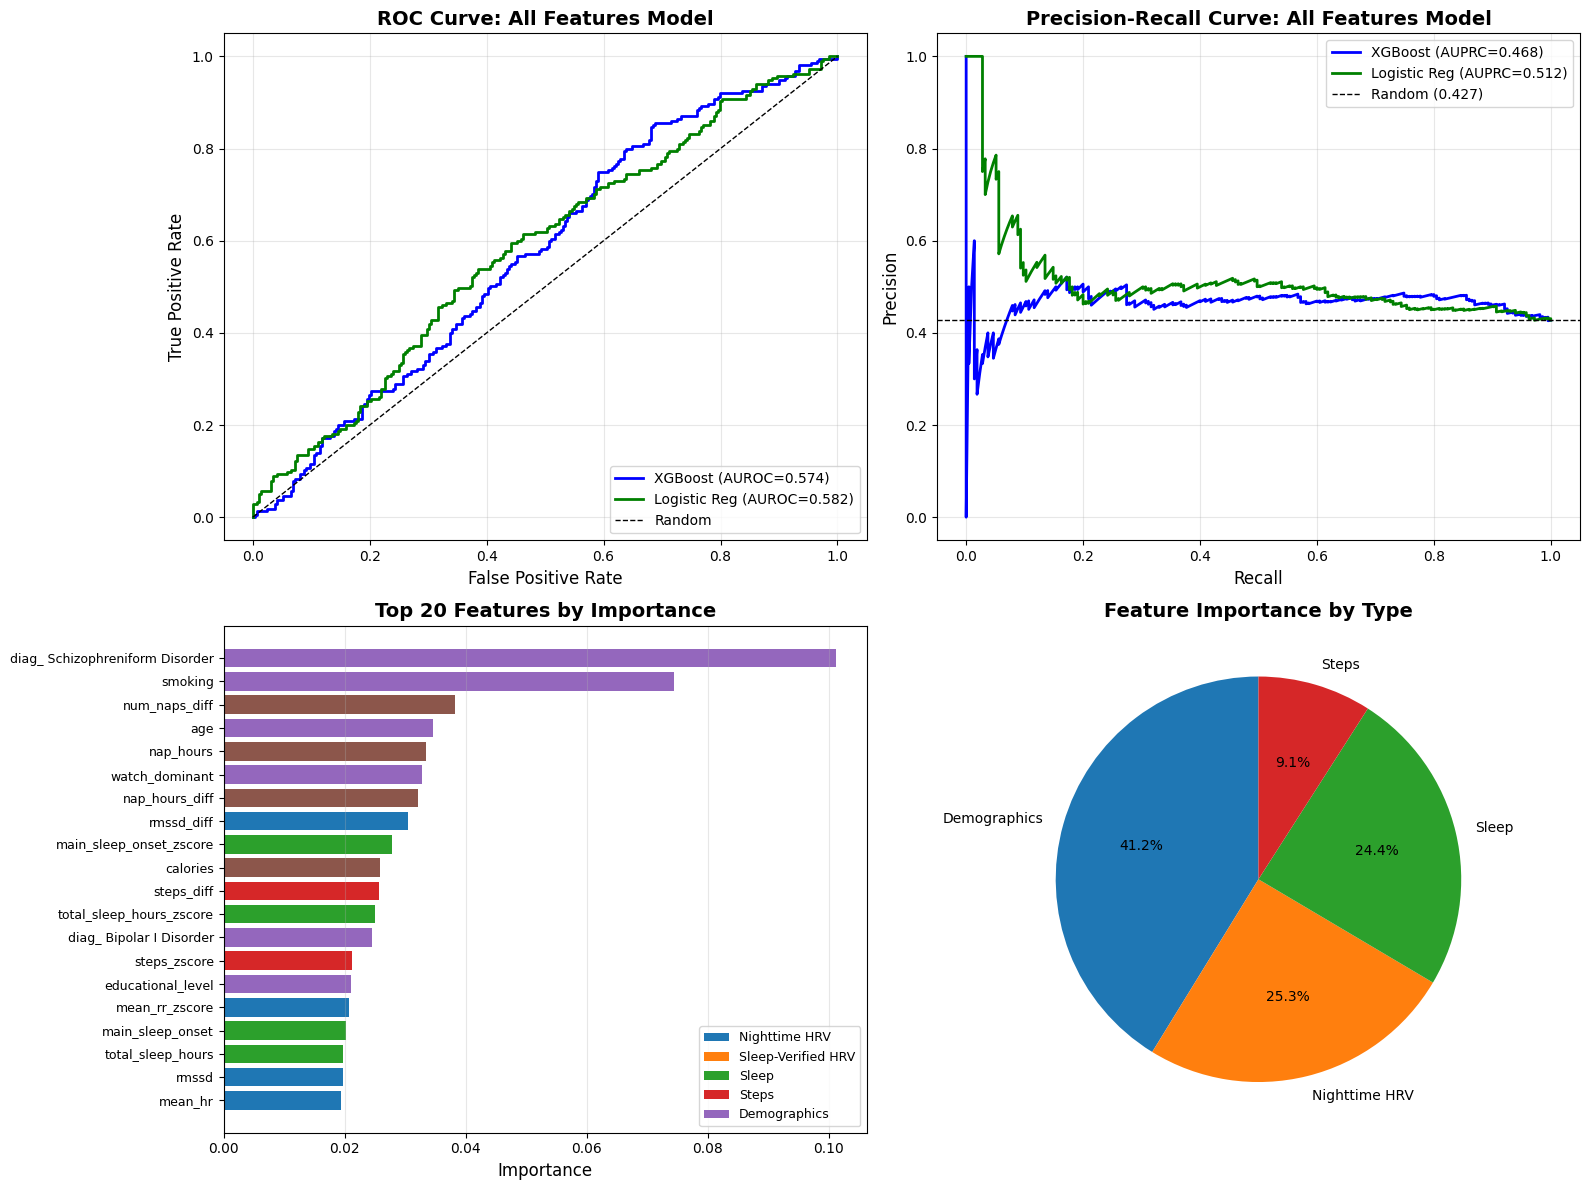


CLASSIFICATION REPORT (XGBoost)
              precision    recall  f1-score   support

  No Relapse       0.60      0.61      0.61       288
     Relapse       0.47      0.46      0.46       215

    accuracy                           0.55       503
   macro avg       0.54      0.54      0.54       503
weighted avg       0.55      0.55      0.55       503



In [37]:
# =============================================================================
# COMPREHENSIVE MODEL: All Features (Nighttime HRV + Sleep-Verified HRV + Sleep + Steps + Demographics)
# =============================================================================

from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt

print("=" * 70)
print("COMPREHENSIVE MODEL: All Available Features")
print("=" * 70)

# Check if sleep-verified HRV data is available
if len(hrv_sleep_verified_df) > 0:
    print("\nMerging all feature sources...")
    
    # Merge sleep-verified HRV features with combined_with_demo
    # combined_with_demo already has: nighttime HRV + all sleep + all steps + demographics
    sv_hrv_cols = [c for c in hrv_sleep_verified_df.columns 
                   if c.endswith('_sv') or c in ['rmssd', 'sdnn', 'mean_hr']]
    
    comprehensive_data = combined_with_demo.merge(
        hrv_sleep_verified_df[['patient_id', 'split', 'day_index'] + sv_hrv_cols],
        on=['patient_id', 'split', 'day_index'],
        how='left',
        suffixes=('', '_sv_dup')
    )
    
    print(f"  Combined dataset shape: {comprehensive_data.shape}")
    print(f"  Sleep-verified HRV features added: {len(sv_hrv_cols)}")
    
    # Split into train and test
    train_data = comprehensive_data[comprehensive_data['split'].str.startswith('val')]
    test_data = comprehensive_data[comprehensive_data['split'].str.startswith('test')]
    
    print(f"\nTrain samples: {len(train_data)}")
    print(f"Test samples: {len(test_data)}")
    print(f"Train relapse rate: {train_data['relapse'].mean():.3f}")
    print(f"Test relapse rate: {test_data['relapse'].mean():.3f}")
    
    # Define feature sets and categorize
    exclude_cols = ['patient_id', 'day_index', 'split', 'split_type', 'relapse']
    all_feature_cols = [c for c in comprehensive_data.columns if c not in exclude_cols]
    
    # Categorize features by type
    nighttime_hrv_features = [c for c in all_feature_cols 
                              if any(x in c for x in ['rmssd', 'sdnn', 'mean_hr', 'mean_rr', 'n_valid']) 
                              and not c.endswith('_sv') and not c.endswith('_sv_dup')]
    
    sleep_verified_hrv_features = [c for c in all_feature_cols if c.endswith('_sv')]
    
    sleep_features = [c for c in all_feature_cols 
                      if any(x in c for x in ['sleep', 'duration', 'episode', 'onset']) 
                      and not any(x in c for x in ['rmssd', 'sdnn', 'mean_hr'])]
    
    step_features = [c for c in all_feature_cols if 'step' in c]
    
    demographic_features = [c for c in all_feature_cols 
                           if c in demographic_feature_cols]
    
    other_features = [c for c in all_feature_cols 
                     if c not in nighttime_hrv_features 
                     and c not in sleep_verified_hrv_features 
                     and c not in sleep_features 
                     and c not in step_features 
                     and c not in demographic_features]
    
    print(f"\nFeature breakdown:")
    print(f"  Nighttime HRV: {len(nighttime_hrv_features)}")
    print(f"  Sleep-Verified HRV: {len(sleep_verified_hrv_features)}")
    print(f"  Sleep: {len(sleep_features)}")
    print(f"  Steps: {len(step_features)}")
    print(f"  Demographics: {len(demographic_features)}")
    print(f"  Other: {len(other_features)}")
    print(f"  Total: {len(all_feature_cols)}")
    
    # Prepare data
    X_train = train_data[all_feature_cols].fillna(0)
    X_test = test_data[all_feature_cols].fillna(0)
    y_train = train_data['relapse'].values
    y_test = test_data['relapse'].values
    
    # Calculate class imbalance
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    print(f"\nClass imbalance (scale_pos_weight): {scale_pos_weight:.2f}")
    
    # -------------------------------------------------------------------------
    # XGBoost Model
    # -------------------------------------------------------------------------
    print("\n" + "-" * 70)
    print("Training XGBoost with ALL features...")
    print("-" * 70)
    
    xgb_model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss'
    )
    xgb_model.fit(X_train, y_train)
    
    y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
    y_pred_xgb = xgb_model.predict(X_test)
    
    auroc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
    auprc_xgb = average_precision_score(y_test, y_pred_proba_xgb)
    
    print(f"\nXGBoost Performance:")
    print(f"  AUROC: {auroc_xgb:.4f}")
    print(f"  AUPRC: {auprc_xgb:.4f}")
    
    # -------------------------------------------------------------------------
    # Logistic Regression Model
    # -------------------------------------------------------------------------
    print("\n" + "-" * 70)
    print("Training Logistic Regression with ALL features...")
    print("-" * 70)
    
    lr_model = Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
    ])
    lr_model.fit(X_train, y_train)
    
    y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]
    y_pred_lr = lr_model.predict(X_test)
    
    auroc_lr = roc_auc_score(y_test, y_pred_proba_lr)
    auprc_lr = average_precision_score(y_test, y_pred_proba_lr)
    
    print(f"\nLogistic Regression Performance:")
    print(f"  AUROC: {auroc_lr:.4f}")
    print(f"  AUPRC: {auprc_lr:.4f}")
    
    # -------------------------------------------------------------------------
    # Results Summary
    # -------------------------------------------------------------------------
    baseline_prc = y_test.mean()
    
    print("\n" + "=" * 70)
    print("MODEL COMPARISON")
    print("=" * 70)
    print(f"\n{'Model':<45} {'AUROC':>12} {'AUPRC':>12}")
    print("-" * 70)
    print(f"{'XGBoost (All Features)':<45} {auroc_xgb:>12.4f} {auprc_xgb:>12.4f}")
    print(f"{'Logistic Regression (All Features)':<45} {auroc_lr:>12.4f} {auprc_lr:>12.4f}")
    print("-" * 70)
    print(f"{'Random Baseline':<45} {'0.5000':>12} {baseline_prc:>12.4f}")
    
    # -------------------------------------------------------------------------
    # Feature Importance Analysis (XGBoost)
    # -------------------------------------------------------------------------
    print("\n" + "=" * 70)
    print("TOP 25 MOST IMPORTANT FEATURES (XGBoost)")
    print("=" * 70)
    
    feature_importance = pd.DataFrame({
        'feature': all_feature_cols,
        'importance': xgb_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    def get_feature_type(feat):
        if feat in nighttime_hrv_features:
            return "Nighttime-HRV"
        elif feat in sleep_verified_hrv_features:
            return "Sleep-Verified-HRV"
        elif feat in sleep_features:
            return "Sleep"
        elif feat in step_features:
            return "Steps"
        elif feat in demographic_features:
            return "Demographics"
        else:
            return "Other"
    
    print("\n")
    for idx, row in feature_importance.head(25).iterrows():
        feat_type = get_feature_type(row['feature'])
        print(f"  {row['feature']:<45} {row['importance']:>8.4f}  [{feat_type}]")
    
    # Feature type importance summary
    print("\n" + "-" * 70)
    print("FEATURE IMPORTANCE BY TYPE")
    print("-" * 70)
    
    type_importance = {}
    for feat_type, feat_list in [
        ('Nighttime HRV', nighttime_hrv_features),
        ('Sleep-Verified HRV', sleep_verified_hrv_features),
        ('Sleep', sleep_features),
        ('Steps', step_features),
        ('Demographics', demographic_features)
    ]:
        type_imp = feature_importance[feature_importance['feature'].isin(feat_list)]['importance'].sum()
        type_importance[feat_type] = type_imp
    
    total_imp = sum(type_importance.values())
    print("\n")
    for feat_type, imp in sorted(type_importance.items(), key=lambda x: x[1], reverse=True):
        pct = (imp / total_imp * 100) if total_imp > 0 else 0
        print(f"  {feat_type:<25} {imp:>8.4f}  ({pct:>5.1f}%)")
    
    # -------------------------------------------------------------------------
    # Visualizations
    # -------------------------------------------------------------------------
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # ROC Curve
    ax1 = axes[0, 0]
    fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
    fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
    ax1.plot(fpr_xgb, tpr_xgb, 'b-', linewidth=2, label=f'XGBoost (AUROC={auroc_xgb:.3f})')
    ax1.plot(fpr_lr, tpr_lr, 'g-', linewidth=2, label=f'Logistic Reg (AUROC={auroc_lr:.3f})')
    ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
    ax1.set_xlabel('False Positive Rate', fontsize=12)
    ax1.set_ylabel('True Positive Rate', fontsize=12)
    ax1.set_title('ROC Curve: All Features Model', fontsize=14, fontweight='bold')
    ax1.legend(loc='lower right', fontsize=10)
    ax1.grid(alpha=0.3)
    
    # PR Curve
    ax2 = axes[0, 1]
    prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_pred_proba_xgb)
    prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_pred_proba_lr)
    ax2.plot(rec_xgb, prec_xgb, 'b-', linewidth=2, label=f'XGBoost (AUPRC={auprc_xgb:.3f})')
    ax2.plot(rec_lr, prec_lr, 'g-', linewidth=2, label=f'Logistic Reg (AUPRC={auprc_lr:.3f})')
    ax2.axhline(y=baseline_prc, color='k', linestyle='--', linewidth=1, label=f'Random ({baseline_prc:.3f})')
    ax2.set_xlabel('Recall', fontsize=12)
    ax2.set_ylabel('Precision', fontsize=12)
    ax2.set_title('Precision-Recall Curve: All Features Model', fontsize=14, fontweight='bold')
    ax2.legend(loc='upper right', fontsize=10)
    ax2.grid(alpha=0.3)
    
    # Feature Importance by Type
    ax3 = axes[1, 0]
    top_features = feature_importance.head(20)
    colors = []
    for f in top_features['feature']:
        ftype = get_feature_type(f)
        if ftype == 'Nighttime-HRV':
            colors.append('#1f77b4')
        elif ftype == 'Sleep-Verified-HRV':
            colors.append('#ff7f0e')
        elif ftype == 'Sleep':
            colors.append('#2ca02c')
        elif ftype == 'Steps':
            colors.append('#d62728')
        elif ftype == 'Demographics':
            colors.append('#9467bd')
        else:
            colors.append('#8c564b')
    
    ax3.barh(range(len(top_features)), top_features['importance'], color=colors)
    ax3.set_yticks(range(len(top_features)))
    ax3.set_yticklabels(top_features['feature'], fontsize=9)
    ax3.set_xlabel('Importance', fontsize=12)
    ax3.set_title('Top 20 Features by Importance', fontsize=14, fontweight='bold')
    ax3.invert_yaxis()
    ax3.grid(axis='x', alpha=0.3)
    
    # Add legend for colors
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#1f77b4', label='Nighttime HRV'),
        Patch(facecolor='#ff7f0e', label='Sleep-Verified HRV'),
        Patch(facecolor='#2ca02c', label='Sleep'),
        Patch(facecolor='#d62728', label='Steps'),
        Patch(facecolor='#9467bd', label='Demographics')
    ]
    ax3.legend(handles=legend_elements, loc='lower right', fontsize=9)
    
    # Feature Type Importance Pie Chart
    ax4 = axes[1, 1]
    type_labels = []
    type_values = []
    type_colors_pie = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    for i, (feat_type, imp) in enumerate(sorted(type_importance.items(), key=lambda x: x[1], reverse=True)):
        if imp > 0:
            type_labels.append(feat_type)
            type_values.append(imp)
    
    ax4.pie(type_values, labels=type_labels, autopct='%1.1f%%', startangle=90, 
            colors=type_colors_pie[:len(type_values)])
    ax4.set_title('Feature Importance by Type', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # -------------------------------------------------------------------------
    # Classification Report
    # -------------------------------------------------------------------------
    print("\n" + "=" * 70)
    print("CLASSIFICATION REPORT (XGBoost)")
    print("=" * 70)
    print(classification_report(y_test, y_pred_xgb, target_names=['No Relapse', 'Relapse']))
    
else:
    print("\nERROR: Sleep-verified HRV data not available.")
    print("Please run the sleep-verified HRV feature engineering cell first.")


GOOD to HERE

In [38]:
# =============================================================================
# CIRCADIAN ACTIVITY PATTERN FEATURES (Percentage-Based)
# =============================================================================
# Create hourly activity profiles and detect deviations from normal patterns
# Using percentage-based metrics for better robustness and interpretability

print("=" * 70)
print("CIRCADIAN ACTIVITY PATTERN FEATURES (Percentage-Based)")
print("=" * 70)

from pathlib import Path


def _compute_l5_m10(hourly_pct):
    """
    Compute L5 (least-active 5h) and M10 (most-active 10h) from a
    24-element hourly percentage Series indexed 0-23.
    Returns onset hours and values; NaN if <16 hours present.
    """
    if hourly_pct.count() < 16:
        return dict(l5_val=np.nan, m10_val=np.nan, l5_onset=np.nan, m10_onset=np.nan)
    s = hourly_pct.reindex(range(24), fill_value=0).values
    s2 = np.concatenate([s, s])
    m10_sums = [s2[i:i+10].sum() for i in range(24)]
    l5_sums  = [s2[i:i+5].sum()  for i in range(24)]
    m10_onset = int(np.argmax(m10_sums))
    l5_onset  = int(np.argmin(l5_sums))
    return dict(
        l5_val=l5_sums[l5_onset],
        m10_val=m10_sums[m10_onset],
        l5_onset=l5_onset,
        m10_onset=m10_onset,
    )


def _compute_cosinor(hourly_pct):
    """
    Fit a cosine model: A*cos(2*pi*t/24 + phi) + M to hourly % activity.
    Returns (amplitude, acrophase_hours); (NaN, NaN) on failure.
    """
    from scipy.optimize import curve_fit
    t = hourly_pct.dropna().index.values.astype(float)
    y = hourly_pct.dropna().values
    if len(y) < 8:
        return np.nan, np.nan
    def cosinor(t, A, phi, M):
        return A * np.cos(2 * np.pi * t / 24 + phi) + M
    try:
        p0 = [y.std(), 0.0, y.mean()]
        popt, _ = curve_fit(cosinor, t, y, p0=p0, maxfev=3000)
        A, phi, _ = popt
        amplitude = abs(A)
        acrophase_h = (-phi % (2 * np.pi)) / (2 * np.pi) * 24
        return amplitude, acrophase_h
    except Exception:
        return np.nan, np.nan


def process_patient_circadian(patient, base_path='track1', downsample=100, use_linacc=True, w_gyr=0.5, w_lin=0.5):
    """
    Extract hourly activity patterns from gyroscope and optionally linear accelerometer.
    When use_linacc=True, activity is a weighted sum of gyro and linacc magnitudes (Option 1B).

    Args:
        patient: Patient ID
        base_path: Data directory
        downsample: Take every Nth sample (100 = 0.2Hz from 20Hz)
        use_linacc: If True, load linacc.parquet and fuse with gyr via weighted sum
        w_gyr: Weight for gyroscope magnitude (default 0.5)
        w_lin: Weight for linear accelerometer magnitude (default 0.5)

    Returns:
        hourly_df: DataFrame with hourly activity data
        baseline_profile: Baseline percentages and counts per hour
        baseline_stats: Dict of scalar baseline metrics (RA, cosinor amp/phase, L5/M10 onset)
    """
    all_hourly_data = []

    for split_type in ['train', 'val', 'test']:
        for split_num in range(3):
            split = f'{split_type}_{split_num}'
            gyr_file = f'{base_path}/{patient}/{split}/gyr.parquet'
            linacc_file = f'{base_path}/{patient}/{split}/linacc.parquet'
            relapse_file = f'{base_path}/{patient}/{split}/relapses.csv'

            if not os.path.exists(gyr_file) or not os.path.exists(relapse_file):
                continue

            # Load gyroscope with heavy downsampling
            gyr = pd.read_parquet(gyr_file, columns=['X', 'Y', 'Z', 'time', 'day_index'])
            gyr = gyr.iloc[::downsample].copy()

            relapses = pd.read_csv(relapse_file)

            if len(gyr) == 0:
                continue

            # Option 1B: Fuse with linear accelerometer when available (align by time_key to keep rows)
            if use_linacc and os.path.exists(linacc_file):
                linacc = pd.read_parquet(linacc_file, columns=['X', 'Y', 'Z', 'time', 'day_index'])
                linacc = linacc.iloc[::downsample].copy()
                # Round time to 1s so gyr and linacc align without exact timestamp match
                t_gyr = gyr['time'].astype(str)
                gyr['time_key'] = pd.to_datetime(t_gyr.where(t_gyr.str.contains(r'\.\d+', regex=True), t_gyr + '.0'), format='%H:%M:%S.%f').dt.round('1s')
                t_lin = linacc['time'].astype(str)
                linacc['time_key'] = pd.to_datetime(t_lin.where(t_lin.str.contains(r'\.\d+', regex=True), t_lin + '.0'), format='%H:%M:%S.%f').dt.round('1s')
                # One linacc row per (day_index, time_key)
                linacc_agg = linacc.groupby(['day_index', 'time_key']).agg({'X': 'mean', 'Y': 'mean', 'Z': 'mean'}).reset_index()
                linacc_agg = linacc_agg.rename(columns={'X': 'X_lin', 'Y': 'Y_lin', 'Z': 'Z_lin'})
                gyr_merge = gyr.rename(columns={'X': 'X_gyr', 'Y': 'Y_gyr', 'Z': 'Z_gyr'})
                merged = gyr_merge.merge(
                    linacc_agg,
                    on=['day_index', 'time_key'],
                    how='left'
                )
                # Magnitude: use 0 for missing linacc so fused = gyr-only where linacc absent
                merged['X_lin'] = merged['X_lin'].fillna(0)
                merged['Y_lin'] = merged['Y_lin'].fillna(0)
                merged['Z_lin'] = merged['Z_lin'].fillna(0)
                mag_gyr = np.sqrt(merged['X_gyr']**2 + merged['Y_gyr']**2 + merged['Z_gyr']**2)
                mag_lin = np.sqrt(merged['X_lin']**2 + merged['Y_lin']**2 + merged['Z_lin']**2)
                merged['magnitude'] = w_gyr * mag_gyr + w_lin * mag_lin
                merged['hour'] = merged['time'].astype(str).str[:2].astype(int)
                activity_df = merged[['day_index', 'hour', 'magnitude']]
                del linacc
            else:
                gyr['magnitude'] = np.sqrt(gyr['X']**2 + gyr['Y']**2 + gyr['Z']**2)
                gyr['hour'] = gyr['time'].astype(str).str[:2].astype(int)
                activity_df = gyr[['day_index', 'hour', 'magnitude']]

            # Aggregate by day and hour
            hourly = activity_df.groupby(['day_index', 'hour']).agg({
                'magnitude': ['mean', 'std', 'count']
            }).reset_index()
            hourly.columns = ['day_index', 'hour', 'activity_mean', 'activity_std', 'sample_count']

            hourly['patient_id'] = patient
            hourly['split'] = split
            hourly['split_type'] = split_type

            hourly = hourly.merge(
                relapses[['day_index', 'relapse']],
                on='day_index',
                how='left'
            )

            all_hourly_data.append(hourly)
            del gyr

    if not all_hourly_data:
        return pd.DataFrame(), pd.DataFrame(), {}

    hourly_df = pd.concat(all_hourly_data, ignore_index=True)

    # Calculate patient's baseline from non-relapse train+val days
    baseline_data = hourly_df[
        (hourly_df['split_type'].isin(['train', 'val'])) &
        (hourly_df['relapse'] == 0)
    ]

    if len(baseline_data) == 0:
        return hourly_df, pd.DataFrame(), {}

    # For each day in baseline, calculate hourly percentages
    baseline_daily_pcts = []
    for day_idx in baseline_data['day_index'].unique():
        day_data = baseline_data[baseline_data['day_index'] == day_idx]
        daily_total = day_data['activity_mean'].sum()
        if daily_total > 0:
            day_data = day_data.copy()
            day_data['activity_pct'] = (day_data['activity_mean'] / daily_total * 100)
            baseline_daily_pcts.append(day_data[['hour', 'activity_pct', 'activity_mean']])

    if not baseline_daily_pcts:
        return hourly_df, pd.DataFrame(), {}

    baseline_pct_df = pd.concat(baseline_daily_pcts, ignore_index=True)

    # Calculate baseline: mean and std of percentages per hour
    baseline_profile = baseline_pct_df.groupby('hour').agg({
        'activity_pct': ['mean', 'std'],
        'activity_mean': ['mean', 'std']  # Keep count-based for comparison
    }).reset_index()
    baseline_profile.columns = ['hour', 'baseline_activity_pct', 'baseline_activity_pct_std',
                                'baseline_activity', 'baseline_activity_std']

    # Replace 0 std with small value to avoid division by zero
    baseline_profile['baseline_activity_pct_std'] = baseline_profile['baseline_activity_pct_std'].replace(0, 0.1)
    baseline_profile['baseline_activity_std'] = baseline_profile['baseline_activity_std'].replace(0, 0.1)

    # -------------------------------------------------------------------------
    # Compute scalar baseline stats for RA, cosinor, and L5/M10 across baseline days
    # -------------------------------------------------------------------------
    baseline_day_indices = baseline_data['day_index'].unique()
    ra_vals, amp_vals, acrophase_vals, l5_onset_vals, m10_onset_vals = [], [], [], [], []

    for day_idx in baseline_day_indices:
        day_data = baseline_data[baseline_data['day_index'] == day_idx]
        daily_total = day_data['activity_mean'].sum()
        if daily_total == 0:
            continue
        day_data = day_data.copy()
        day_data['activity_pct'] = day_data['activity_mean'] / daily_total * 100
        pct_series = day_data.groupby('hour')['activity_pct'].mean()

        lm = _compute_l5_m10(pct_series)
        if not np.isnan(lm['m10_val']) and (lm['m10_val'] + lm['l5_val']) > 0:
            ra = (lm['m10_val'] - lm['l5_val']) / (lm['m10_val'] + lm['l5_val'])
            ra_vals.append(ra)
        if not np.isnan(lm['l5_onset']):
            l5_onset_vals.append(lm['l5_onset'])
        if not np.isnan(lm['m10_onset']):
            m10_onset_vals.append(lm['m10_onset'])

        amp, acrophase = _compute_cosinor(pct_series)
        if not np.isnan(amp):
            amp_vals.append(amp)
        if not np.isnan(acrophase):
            acrophase_vals.append(acrophase)

    baseline_stats = {
        'baseline_ra_mean':        np.nanmean(ra_vals)        if ra_vals        else 0.0,
        'baseline_ra_std':         np.nanstd(ra_vals)         if ra_vals        else 1.0,
        'baseline_amp_mean':       np.nanmean(amp_vals)       if amp_vals       else 0.0,
        'baseline_amp_std':        np.nanstd(amp_vals)        if amp_vals       else 1.0,
        'baseline_acrophase_mean': np.nanmean(acrophase_vals) if acrophase_vals else 12.0,
        'baseline_l5_onset_mean':  np.nanmean(l5_onset_vals)  if l5_onset_vals  else 1.0,
        'baseline_m10_onset_mean': np.nanmean(m10_onset_vals) if m10_onset_vals else 10.0,
    }

    return hourly_df, baseline_profile, baseline_stats


def calculate_circadian_features(hourly_df, baseline_profile, patient, baseline_stats=None):
    """
    Calculate daily circadian deviation features using percentage-based metrics.

    Features (percentage-based):
    - night_activity_proportion: % of daily activity during 0-6 AM
    - day_activity_proportion: % of daily activity during 9 AM-9 PM
    - circadian_deviation_pct: Overall deviation from baseline percentage pattern
    - circadian_shift_pct: Shift in peak activity hour (by percentage)
    - evening_activity_proportion: % of daily activity during 18-23 (mania prodrome signal)
    - relative_amplitude_zscore: RA z-score vs personal baseline (depression depth marker)
    - l5_onset_deviation: Deviation of least-active 5h onset from baseline (sleep-phase shift)
    - m10_onset_deviation: Deviation of most-active 10h onset from baseline (active-phase shift)
    - intradaily_variability: Within-day fragmentation (bipolar marker)
    - cosinor_amplitude_zscore: Rhythm strength vs personal baseline
    - cosinor_acrophase_deviation: Phase shift vs personal baseline

    Features (count-based - kept for comparison):
    - circadian_deviation, night_activity_zscore, day_activity_zscore, circadian_shift
    """
    if len(baseline_profile) == 0:
        return pd.DataFrame()

    if baseline_stats is None:
        baseline_stats = {}

    # Merge baseline into hourly data
    hourly_with_baseline = hourly_df.merge(baseline_profile, on='hour', how='left')

    # Calculate count-based z-score for each hour (original method)
    hourly_with_baseline['hour_zscore'] = (
        (hourly_with_baseline['activity_mean'] - hourly_with_baseline['baseline_activity']) /
        hourly_with_baseline['baseline_activity_std']
    )

    # Aggregate to daily features
    daily_features = []

    for (day_idx, split), day_data in hourly_with_baseline.groupby(['day_index', 'split']):
        if len(day_data) < 12:  # Need at least half the hours
            continue

        # Calculate daily total for percentage conversion
        daily_total = day_data['activity_mean'].sum()

        if daily_total == 0:  # Skip days with no activity
            continue

        # Convert to percentages
        day_data = day_data.copy()
        day_data['activity_pct'] = (day_data['activity_mean'] / daily_total * 100)

        # =====================================================================
        # PERCENTAGE-BASED FEATURES
        # =====================================================================

        # 1. Night activity proportion (% of daily activity at night)
        night_hours = day_data[day_data['hour'].isin([0, 1, 2, 3, 4, 5, 6])]
        night_activity_proportion = night_hours['activity_pct'].sum() if len(night_hours) > 0 else 0

        # 2. Day activity proportion (% of daily activity during day)
        day_hours = day_data[day_data['hour'].isin(range(9, 22))]
        day_activity_proportion = day_hours['activity_pct'].sum() if len(day_hours) > 0 else 0

        # 3. Peak hour by percentage
        peak_hour_pct = day_data.loc[day_data['activity_pct'].idxmax(), 'hour']
        baseline_peak_pct = baseline_profile.loc[baseline_profile['baseline_activity_pct'].idxmax(), 'hour']
        circadian_shift_pct = abs(peak_hour_pct - baseline_peak_pct)
        if circadian_shift_pct > 12:  # Handle wrap-around
            circadian_shift_pct = 24 - circadian_shift_pct

        # 4. Percentage-based z-scores
        day_data['pct_zscore'] = (
            (day_data['activity_pct'] - day_data['baseline_activity_pct']) /
            day_data['baseline_activity_pct_std']
        )
        circadian_deviation_pct = (day_data['pct_zscore'] ** 2).mean()

        # =====================================================================
        # NEW CLINICALLY-VALIDATED FEATURES
        # =====================================================================

        pct_series = day_data.groupby('hour')['activity_pct'].mean()

        # Evening activity proportion (18-23h) — mania prodrome signal
        evening_hours = day_data[day_data['hour'].isin(range(18, 24))]
        evening_activity_proportion = evening_hours['activity_pct'].sum() if len(evening_hours) > 0 else 0

        # L5 / M10 — relative amplitude and onset deviations
        lm = _compute_l5_m10(pct_series)
        if not np.isnan(lm['m10_val']):
            denom = lm['m10_val'] + lm['l5_val'] + 1e-9
            ra = (lm['m10_val'] - lm['l5_val']) / denom
            ra_zscore = (ra - baseline_stats.get('baseline_ra_mean', 0.0)) / (baseline_stats.get('baseline_ra_std', 1.0) + 1e-9)
        else:
            ra_zscore = 0.0

        l5_onset_deviation = 0.0
        m10_onset_deviation = 0.0
        if not np.isnan(lm['l5_onset']):
            diff = abs(lm['l5_onset'] - baseline_stats.get('baseline_l5_onset_mean', 1.0))
            l5_onset_deviation = min(diff, 24 - diff)
        if not np.isnan(lm['m10_onset']):
            diff = abs(lm['m10_onset'] - baseline_stats.get('baseline_m10_onset_mean', 10.0))
            m10_onset_deviation = min(diff, 24 - diff)

        # Intradaily variability — within-day fragmentation (bipolar marker)
        pct_vals = pct_series.reindex(range(24), fill_value=0).values
        diffs_sq = np.sum(np.diff(pct_vals)**2)
        grand_mean = pct_vals.mean()
        var_total = np.sum((pct_vals - grand_mean)**2)
        iv = (24 * diffs_sq) / (23 * var_total + 1e-9)

        # Cosinor amplitude + acrophase
        amp, acrophase = _compute_cosinor(pct_series)
        if not np.isnan(amp):
            amp_zscore = (amp - baseline_stats.get('baseline_amp_mean', 0.0)) / (baseline_stats.get('baseline_amp_std', 1.0) + 1e-9)
        else:
            amp_zscore = 0.0
        acrophase_deviation = 0.0
        if not np.isnan(acrophase):
            diff = abs(acrophase - baseline_stats.get('baseline_acrophase_mean', 12.0))
            acrophase_deviation = min(diff, 24 - diff)

        # =====================================================================
        # COUNT-BASED FEATURES (ORIGINAL - kept for comparison)
        # =====================================================================

        # Overall circadian deviation (mean squared z-score)
        circadian_deviation = (day_data['hour_zscore'] ** 2).mean()

        # midnight to 6 am
        # Night activity z-score (count-based)
        night_data = day_data[day_data['hour'].isin([0, 1, 2, 3, 4, 5, 6])]
        night_activity_zscore = night_data['hour_zscore'].mean() if len(night_data) > 0 else 0

        # 9am to 10pm
        # Day activity z-score (count-based)
        day_data_hours = day_data[day_data['hour'].isin(range(9, 22))]
        day_activity_zscore = day_data_hours['hour_zscore'].mean() if len(day_data_hours) > 0 else 0

        # Peak activity hour (count-based)
        peak_hour = day_data.loc[day_data['activity_mean'].idxmax(), 'hour']
        baseline_peak = baseline_profile.loc[baseline_profile['baseline_activity'].idxmax(), 'hour']
        circadian_shift = abs(peak_hour - baseline_peak)
        if circadian_shift > 12:  # Handle wrap-around
            circadian_shift = 24 - circadian_shift

        daily_features.append({
            'patient_id': patient,
            'day_index': day_idx,
            'split': split,
            'split_type': day_data['split_type'].iloc[0],
            'relapse': day_data['relapse'].iloc[0],
            # Percentage-based features
            'night_activity_proportion': night_activity_proportion,
            'day_activity_proportion': day_activity_proportion,
            'circadian_deviation_pct': circadian_deviation_pct,
            'circadian_shift_pct': circadian_shift_pct,
            # NEW clinically-validated features
            'evening_activity_proportion': evening_activity_proportion,
            'relative_amplitude_zscore': ra_zscore,
            'l5_onset_deviation': l5_onset_deviation,
            'm10_onset_deviation': m10_onset_deviation,
            'intradaily_variability': iv,
            'cosinor_amplitude_zscore': amp_zscore,
            'cosinor_acrophase_deviation': acrophase_deviation,
            # Count-based features (ORIGINAL)
            'circadian_deviation': circadian_deviation,
            'night_activity_zscore': night_activity_zscore,
            'day_activity_zscore': day_activity_zscore,
            'circadian_shift': circadian_shift,
        })

    return pd.DataFrame(daily_features)


def build_circadian_features():
    """
    Process all patients to build circadian activity pattern features.
    """
    print("\nExtracting circadian activity patterns...")
    print("Using 100x downsampling (0.2Hz from 20Hz)")
    print("Fusing gyro + linacc (Option 1B weighted sum); computing percentage-based and count-based features")

    import time as time_module
    start_time = time_module.time()

    circadian_features_list = []

    for patient in [f'P{i}' for i in range(1, 10)]:
        patient_start = time_module.time()
        print(f"  Processing {patient}...", end=" ", flush=True)

        hourly_df, baseline_profile, baseline_stats = process_patient_circadian(patient)

        if len(hourly_df) > 0 and len(baseline_profile) > 0:
            patient_features = calculate_circadian_features(hourly_df, baseline_profile, patient, baseline_stats)
            if len(patient_features) > 0:
                circadian_features_list.append(patient_features)
                elapsed = time_module.time() - patient_start
                print(f"✓ {len(patient_features)} days ({elapsed:.1f}s)")
            else:
                print("✗ No features")
        else:
            print("✗ No data")

    total_time = time_module.time() - start_time

    if circadian_features_list:
        circadian_features_df = pd.concat(circadian_features_list, ignore_index=True)
        print(f"\nTotal circadian feature records: {len(circadian_features_df)}")
        print(f"Total processing time: {total_time:.1f}s")

        # Show feature summary
        print("\n" + "-" * 70)
        print("Circadian Feature Summary:")
        print("-" * 70)
        new_cols = ['night_activity_proportion', 'day_activity_proportion',
                    'circadian_deviation_pct', 'circadian_shift_pct',
                    'evening_activity_proportion', 'relative_amplitude_zscore',
                    'l5_onset_deviation', 'm10_onset_deviation',
                    'intradaily_variability', 'cosinor_amplitude_zscore',
                    'cosinor_acrophase_deviation']
        print("\nPercentage-based + new features:")
        print(circadian_features_df[[c for c in new_cols if c in circadian_features_df.columns]].describe())
        print("\nCount-based features (for comparison):")
        print(circadian_features_df[['circadian_deviation', 'night_activity_zscore',
                                      'day_activity_zscore', 'circadian_shift']].describe())
        return circadian_features_df

    print("\nNo circadian features generated!")
    return pd.DataFrame()


# Cache setup
cache_dir = Path("./cache")
cache_dir.mkdir(exist_ok=True)
circadian_features_path = cache_dir / "circadian_features_fused_v3.parquet"

if circadian_features_path.exists():
    circadian_features_df = pd.read_parquet(circadian_features_path)
    print("Loaded fused (gyr+linacc) circadian features from cache.")
    print(f"Features available: {list(circadian_features_df.columns)}")
else:
    circadian_features_df = build_circadian_features()
    if len(circadian_features_df) > 0:
        circadian_features_df.to_parquet(circadian_features_path, index=False)
        print("Saved fused (gyr+linacc) circadian features to cache.")


CIRCADIAN ACTIVITY PATTERN FEATURES (Percentage-Based)
Loaded fused (gyr+linacc) circadian features from cache.
Features available: ['patient_id', 'day_index', 'split', 'split_type', 'relapse', 'night_activity_proportion', 'day_activity_proportion', 'circadian_deviation_pct', 'circadian_shift_pct', 'evening_activity_proportion', 'relative_amplitude_zscore', 'l5_onset_deviation', 'm10_onset_deviation', 'intradaily_variability', 'cosinor_amplitude_zscore', 'cosinor_acrophase_deviation', 'circadian_deviation', 'night_activity_zscore', 'day_activity_zscore', 'circadian_shift']


CIRCADIAN FEATURES: Analysis and Predictive Power

Within-Patient Comparison (Relapse vs Non-Relapse):

PERCENTAGE-BASED FEATURES:
----------------------------------------------------------------------
  night_activity_proportion:
    Non-relapse mean: 8.699
    Relapse mean:     8.437
    Difference:       -0.262

  day_activity_proportion:
    Non-relapse mean: 78.256
    Relapse mean:     78.124
    Difference:       -0.131

  circadian_deviation_pct:
    Non-relapse mean: 6.687
    Relapse mean:     5.432
    Difference:       -1.255

  circadian_shift_pct:
    Non-relapse mean: 4.170
    Relapse mean:     4.144
    Difference:       -0.026


COUNT-BASED FEATURES (for comparison):
----------------------------------------------------------------------
  circadian_deviation:
    Non-relapse mean: 1.037
    Relapse mean:     1.020
    Difference:       -0.017

  night_activity_zscore:
    Non-relapse mean: 0.039
    Relapse mean:     0.038
    Difference:       -0.000

  day_activity_

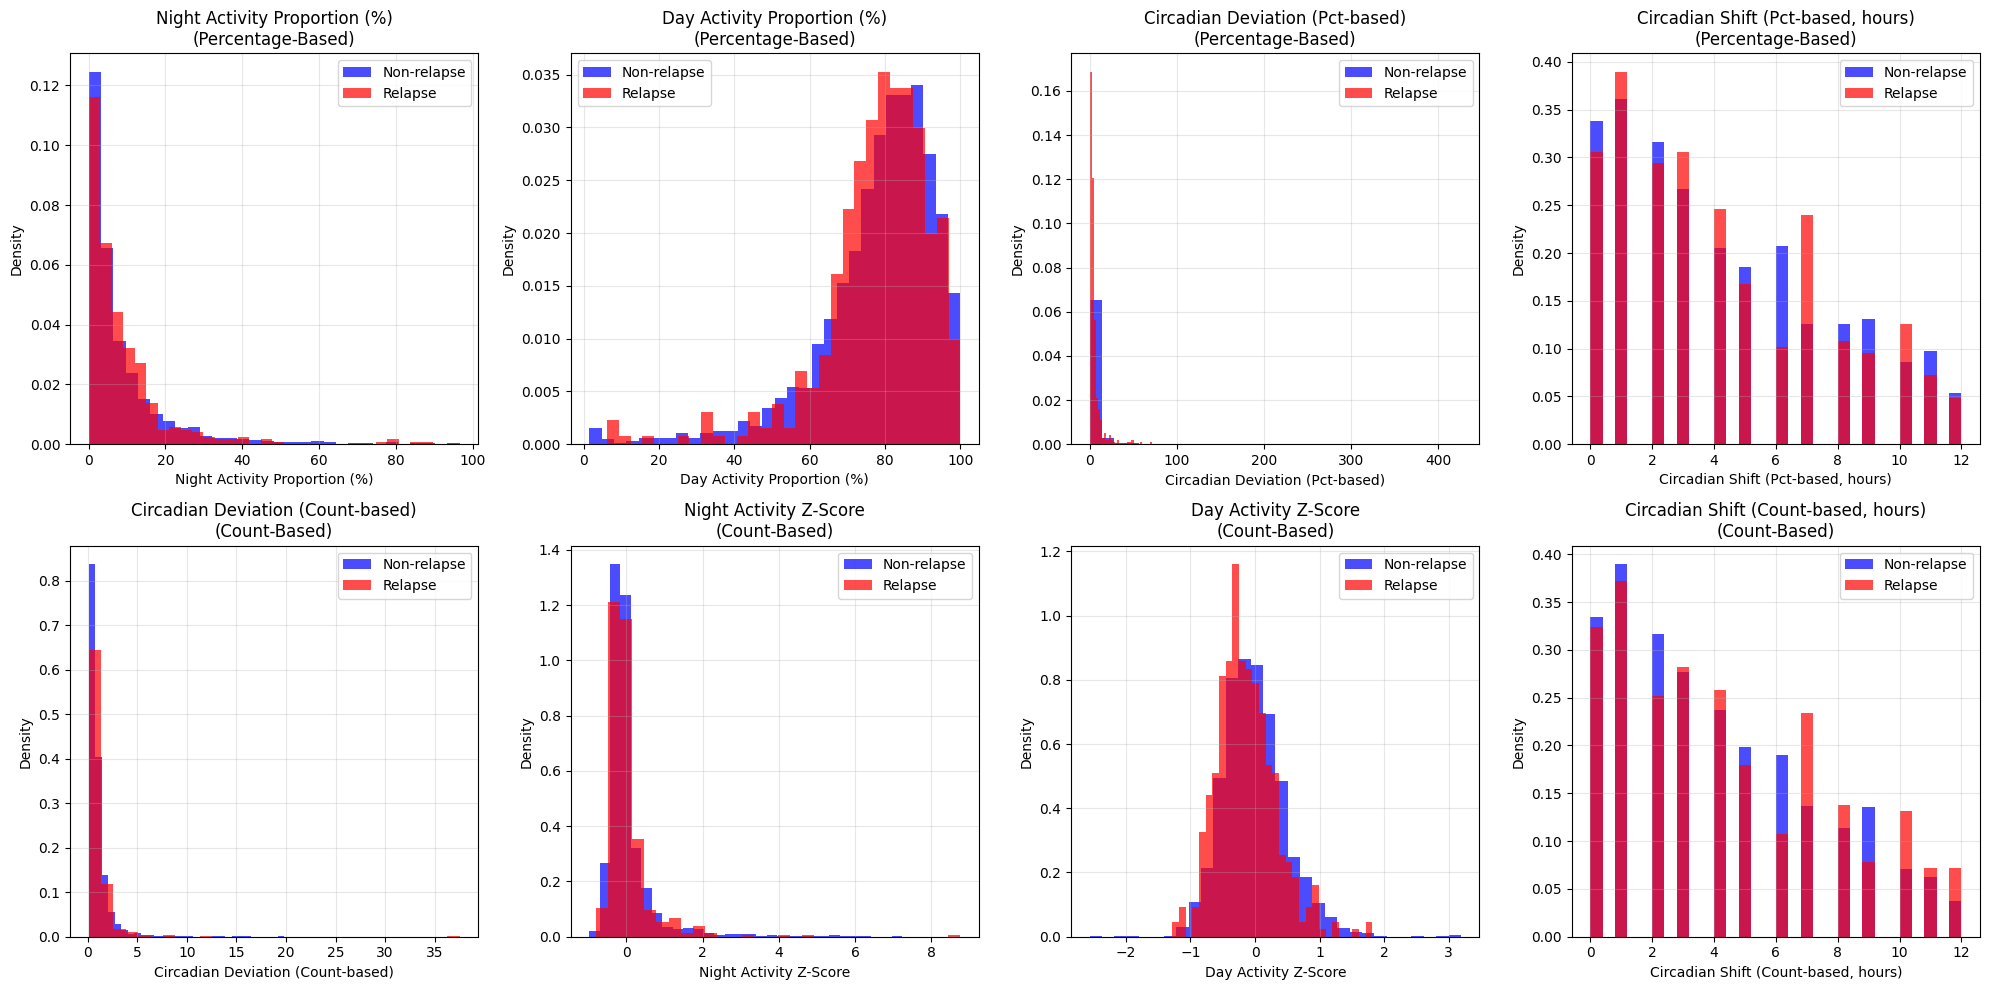


RECOMMENDATIONS

Top 3 Most Predictive Features:
  1. day_activity_zscore (AUC=0.580) [Count-based]
  2. circadian_deviation (AUC=0.576) [Count-based]
  3. circadian_shift_pct (AUC=0.527) [Percentage-based]

Clinical Interpretation:
  - Night activity proportion: 0.503 AUC
    Measures % of daily activity at night (0-6 AM)
    Higher proportion may indicate sleep disruption before relapse
  - Day activity proportion: 0.521 AUC
    Measures % of daily activity during day (9 AM-9 PM)
    Lower proportion may indicate daytime lethargy/withdrawal

Recommendation for Final Models:
  ✓ Use COUNT-BASED features (better predictive power)
    Recommended features: day_activity_zscore, circadian_deviation

  Note: Consider using BOTH types for complementary information


In [39]:
# =============================================================================
# ANALYZE CIRCADIAN FEATURES - (FUSED ACCELEROMETER DATA) AND TEST PREDICTIVE POWER
# =============================================================================

print("=" * 70)
print("CIRCADIAN FEATURES: Analysis and Predictive Power")
print("=" * 70)

if len(circadian_features_df) > 0:
    # Define feature groups
    pct_features = ['night_activity_proportion', 'day_activity_proportion', 
                    'circadian_deviation_pct', 'circadian_shift_pct']
    count_features = ['circadian_deviation', 'night_activity_zscore', 
                      'day_activity_zscore', 'circadian_shift']
    
    # =========================================================================
    # SECTION 1: Within-Patient Comparison (Relapse vs Non-Relapse)
    # =========================================================================
    print("\nWithin-Patient Comparison (Relapse vs Non-Relapse):")
    print("=" * 70)
    
    print("\nPERCENTAGE-BASED FEATURES:")
    print("-" * 70)
    for feature in pct_features:
        if feature in circadian_features_df.columns:
            relapse_vals = circadian_features_df[circadian_features_df['relapse'] == 1][feature].dropna()
            non_relapse_vals = circadian_features_df[circadian_features_df['relapse'] == 0][feature].dropna()
            
            if len(relapse_vals) > 0 and len(non_relapse_vals) > 0:
                diff = relapse_vals.mean() - non_relapse_vals.mean()
                print(f"  {feature}:")
                print(f"    Non-relapse mean: {non_relapse_vals.mean():.3f}")
                print(f"    Relapse mean:     {relapse_vals.mean():.3f}")
                print(f"    Difference:       {diff:+.3f}")
                print()
    
    print("\nCOUNT-BASED FEATURES (for comparison):")
    print("-" * 70)
    for feature in count_features:
        if feature in circadian_features_df.columns:
            relapse_vals = circadian_features_df[circadian_features_df['relapse'] == 1][feature].dropna()
            non_relapse_vals = circadian_features_df[circadian_features_df['relapse'] == 0][feature].dropna()
            
            if len(relapse_vals) > 0 and len(non_relapse_vals) > 0:
                diff = relapse_vals.mean() - non_relapse_vals.mean()
                print(f"  {feature}:")
                print(f"    Non-relapse mean: {non_relapse_vals.mean():.3f}")
                print(f"    Relapse mean:     {relapse_vals.mean():.3f}")
                print(f"    Difference:       {diff:+.3f}")
                print()
    
    # =========================================================================
    # SECTION 2: Single Feature Predictive Power (AUC)
    # =========================================================================
    print("\n" + "=" * 70)
    print("SINGLE FEATURE PREDICTIVE POWER (AUC on test data)")
    print("=" * 70)
    
    test_circ = circadian_features_df[circadian_features_df['split_type'] == 'test']
    
    pct_aucs = {}
    count_aucs = {}
    
    print("\nPERCENTAGE-BASED FEATURES:")
    print("-" * 70)
    for feature in pct_features:
        if feature in test_circ.columns:
            valid = test_circ[[feature, 'relapse']].dropna()
            if len(valid) > 10 and valid['relapse'].sum() > 0:
                auc = roc_auc_score(valid['relapse'], valid[feature])
                auc_inv = roc_auc_score(valid['relapse'], -valid[feature])
                best_auc = max(auc, auc_inv)
                direction = "higher=relapse" if auc > auc_inv else "lower=relapse"
                pct_aucs[feature] = best_auc
                print(f"  {feature}: AUC={best_auc:.3f} ({direction})")
    
    print("\nCOUNT-BASED FEATURES:")
    print("-" * 70)
    for feature in count_features:
        if feature in test_circ.columns:
            valid = test_circ[[feature, 'relapse']].dropna()
            if len(valid) > 10 and valid['relapse'].sum() > 0:
                auc = roc_auc_score(valid['relapse'], valid[feature])
                auc_inv = roc_auc_score(valid['relapse'], -valid[feature])
                best_auc = max(auc, auc_inv)
                direction = "higher=relapse" if auc > auc_inv else "lower=relapse"
                count_aucs[feature] = best_auc
                print(f"  {feature}: AUC={best_auc:.3f} ({direction})")
    
    # =========================================================================
    # SECTION 3: Comparison Summary
    # =========================================================================
    print("\n" + "=" * 70)
    print("COMPARISON SUMMARY")
    print("=" * 70)
    
    if pct_aucs and count_aucs:
        best_pct_feature = max(pct_aucs.items(), key=lambda x: x[1])
        best_count_feature = max(count_aucs.items(), key=lambda x: x[1])
        avg_pct_auc = sum(pct_aucs.values()) / len(pct_aucs)
        avg_count_auc = sum(count_aucs.values()) / len(count_aucs)
        
        print(f"\nBest Percentage-Based Feature:")
        print(f"  {best_pct_feature[0]}: AUC={best_pct_feature[1]:.3f}")
        print(f"\nBest Count-Based Feature:")
        print(f"  {best_count_feature[0]}: AUC={best_count_feature[1]:.3f}")
        print(f"\nAverage AUC:")
        print(f"  Percentage-based: {avg_pct_auc:.3f}")
        print(f"  Count-based:      {avg_count_auc:.3f}")
        
        if avg_pct_auc > avg_count_auc:
            improvement = ((avg_pct_auc - avg_count_auc) / avg_count_auc) * 100
            print(f"\n✓ Percentage-based features perform {improvement:.1f}% better on average")
        elif avg_count_auc > avg_pct_auc:
            improvement = ((avg_count_auc - avg_pct_auc) / avg_pct_auc) * 100
            print(f"\n✓ Count-based features perform {improvement:.1f}% better on average")
        else:
            print(f"\n= Both approaches perform similarly")
    
    # =========================================================================
    # SECTION 4: Visualizations
    # =========================================================================
    print("\n" + "=" * 70)
    print("VISUALIZING CIRCADIAN PATTERNS")
    print("=" * 70)
    
    # Create 2x4 grid: top row = percentage-based, bottom row = count-based
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    # Top row: Percentage-based features
    pct_plot_configs = [
        ('night_activity_proportion', 'Night Activity Proportion (%)', axes[0, 0]),
        ('day_activity_proportion', 'Day Activity Proportion (%)', axes[0, 1]),
        ('circadian_deviation_pct', 'Circadian Deviation (Pct-based)', axes[0, 2]),
        ('circadian_shift_pct', 'Circadian Shift (Pct-based, hours)', axes[0, 3])
    ]
    
    for feature, title, ax in pct_plot_configs:
        if feature in circadian_features_df.columns:
            circadian_features_df[circadian_features_df['relapse'] == 0][feature].hist(
                ax=ax, bins=30, alpha=0.7, label='Non-relapse', color='blue', density=True)
            circadian_features_df[circadian_features_df['relapse'] == 1][feature].hist(
                ax=ax, bins=30, alpha=0.7, label='Relapse', color='red', density=True)
            ax.set_xlabel(title)
            ax.set_ylabel('Density')
            ax.set_title(f'{title}\n(Percentage-Based)')
            ax.legend()
            ax.grid(alpha=0.3)
    
    # Bottom row: Count-based features
    count_plot_configs = [
        ('circadian_deviation', 'Circadian Deviation (Count-based)', axes[1, 0]),
        ('night_activity_zscore', 'Night Activity Z-Score', axes[1, 1]),
        ('day_activity_zscore', 'Day Activity Z-Score', axes[1, 2]),
        ('circadian_shift', 'Circadian Shift (Count-based, hours)', axes[1, 3])
    ]
    
    for feature, title, ax in count_plot_configs:
        if feature in circadian_features_df.columns:
            circadian_features_df[circadian_features_df['relapse'] == 0][feature].hist(
                ax=ax, bins=30, alpha=0.7, label='Non-relapse', color='blue', density=True)
            circadian_features_df[circadian_features_df['relapse'] == 1][feature].hist(
                ax=ax, bins=30, alpha=0.7, label='Relapse', color='red', density=True)
            ax.set_xlabel(title)
            ax.set_ylabel('Density')
            ax.set_title(f'{title}\n(Count-Based)')
            ax.legend()
            ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # =========================================================================
    # SECTION 5: Recommendations
    # =========================================================================
    print("\n" + "=" * 70)
    print("RECOMMENDATIONS")
    print("=" * 70)
    
    if pct_aucs and count_aucs:
        # Find top 3 features overall
        all_aucs = {**pct_aucs, **count_aucs}
        top_features = sorted(all_aucs.items(), key=lambda x: x[1], reverse=True)[:3]
        
        print("\nTop 3 Most Predictive Features:")
        for i, (feat, auc) in enumerate(top_features, 1):
            feat_type = "Percentage-based" if feat in pct_features else "Count-based"
            print(f"  {i}. {feat} (AUC={auc:.3f}) [{feat_type}]")
        
        print("\nClinical Interpretation:")
        if 'night_activity_proportion' in pct_aucs:
            print(f"  - Night activity proportion: {pct_aucs['night_activity_proportion']:.3f} AUC")
            print(f"    Measures % of daily activity at night (0-6 AM)")
            print(f"    Higher proportion may indicate sleep disruption before relapse")
        
        if 'day_activity_proportion' in pct_aucs:
            print(f"  - Day activity proportion: {pct_aucs['day_activity_proportion']:.3f} AUC")
            print(f"    Measures % of daily activity during day (9 AM-9 PM)")
            print(f"    Lower proportion may indicate daytime lethargy/withdrawal")
        
        print("\nRecommendation for Final Models:")
        if avg_pct_auc > avg_count_auc:
            print("  ✓ Use PERCENTAGE-BASED features (more predictive and interpretable)")
            print(f"    Recommended features: {', '.join([f for f, _ in sorted(pct_aucs.items(), key=lambda x: x[1], reverse=True)[:2]])}")
        else:
            print("  ✓ Use COUNT-BASED features (better predictive power)")
            print(f"    Recommended features: {', '.join([f for f, _ in sorted(count_aucs.items(), key=lambda x: x[1], reverse=True)[:2]])}")
        
        print("\n  Note: Consider using BOTH types for complementary information")
    
else:
    print("\nNo circadian features available")
    print("Run the circadian feature engineering cell first to generate features.")


Things to explore

A few ways to make circadian features more informative:
Personal baselines by day‑of‑week: Circadian patterns differ on weekends vs weekdays; baseline per weekday can sharpen deviations.
Use phase markers: Compute sleep midpoint, activity onset/offset, or acrophase (peak time) using cosine fit per day. Those tend to be more sensitive to rhythm shifts than raw hourly means.
Entropy/regularity: Add intradaily variability (IV) and interdaily stability (IS) (actigraphy staples) — they capture fragmentation and day‑to‑day rhythm strength.
Lagged change features: Differences vs last 3–7 day rolling baseline (not just overall baseline) often catch prodromal shifts.
Patient‑specific normalization: Z‑score per patient and then aggregate, rather than pooling raw values.
Label leakage check: Make sure circadian features aren’t computed using test/val info in any baseline (use train‑only baseline per patient).
If you want, I can implement any of these and add caching like before.

In [40]:
# =============================================================================
# XGBOOST MODEL FOR RELAPSE PREDICTION - CIRCADIAN RHYTHM FEATURES ONLY
# =============================================================================
# Uses only circadian activity pattern features from circadian_features_df (cell 29).

from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix
)

# -----------------------------------------------------------------------------
# Define circadian feature columns (numeric only; exclude IDs and label)
# -----------------------------------------------------------------------------
circadian_feature_candidates = [
    'night_activity_proportion', 'day_activity_proportion',
    'circadian_deviation_pct', 'circadian_shift_pct',
    'circadian_deviation', 'night_activity_zscore', 'day_activity_zscore', 'circadian_shift'
]
circadian_feature_cols = [c for c in circadian_feature_candidates if c in circadian_features_df.columns]

train_data = circadian_features_df[circadian_features_df['split_type'] == 'val'].copy()
test_data = circadian_features_df[circadian_features_df['split_type'] == 'test'].copy()

print("NOTE: Using only VAL splits for training (train splits have 0% relapses)")
print("Data split:")
print(f"  Training (val): {len(train_data)} days")
print(f"  Test: {len(test_data)} days")

X_train = train_data[circadian_feature_cols].copy().fillna(0)
y_train = train_data['relapse'].copy().fillna(0).astype(int)

X_test = test_data[circadian_feature_cols].copy().fillna(0)
y_test = test_data['relapse'].copy().fillna(0).astype(int)

print(f"\nFeature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test: {X_test.shape}")

# -----------------------------------------------------------------------------
# Train XGBoost Model
# -----------------------------------------------------------------------------
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

print("\nTraining XGBoost model (circadian features only)...")
model.fit(X_train, y_train)
print("Training complete!")

# -----------------------------------------------------------------------------
# Evaluate Model
# -----------------------------------------------------------------------------
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)
baseline_pr_auc = y_test.mean()

print("\n" + "=" * 70)
print("MODEL EVALUATION RESULTS (CIRCADIAN ONLY)")
print("=" * 70)

print(f"\nROC-AUC: {roc_auc:.4f}  (random baseline: 0.5)")
print(f"PR-AUC:  {pr_auc:.4f}  (random baseline: {baseline_pr_auc:.4f})")
print(f"PR-AUC improvement over random: {(pr_auc / baseline_pr_auc - 1) * 100:.1f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Relapse', 'Relapse']))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print("                 Predicted")
print("                 No Relapse  Relapse")
print(f"Actual No Relapse    {cm[0,0]:4d}      {cm[0,1]:4d}")
print(f"Actual Relapse       {cm[1,0]:4d}      {cm[1,1]:4d}")

NOTE: Using only VAL splits for training (train splits have 0% relapses)
Data split:
  Training (val): 588 days
  Test: 570 days

Feature matrix shapes:
  X_train: (588, 8)
  X_test: (570, 8)

Training XGBoost model (circadian features only)...
Training complete!

MODEL EVALUATION RESULTS (CIRCADIAN ONLY)

ROC-AUC: 0.5170  (random baseline: 0.5)
PR-AUC:  0.4264  (random baseline: 0.4211)
PR-AUC improvement over random: 1.3%

Classification Report:
              precision    recall  f1-score   support

  No Relapse       0.58      0.57      0.57       330
     Relapse       0.42      0.43      0.43       240

    accuracy                           0.51       570
   macro avg       0.50      0.50      0.50       570
weighted avg       0.51      0.51      0.51       570


Confusion Matrix:
                 Predicted
                 No Relapse  Relapse
Actual No Relapse     187       143
Actual Relapse        136       104


In [41]:
# =============================================================================
# COMBINED MODEL: All features (sleep + steps + HRV + demographics + circadian)
# =============================================================================

import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix
)

print("=" * 70)
print("COMBINED MODEL: All features + circadian")
print("=" * 70)

# -----------------------------------------------------------------------------
# 1. Build combined dataset
# -----------------------------------------------------------------------------

combined_all_circadian = sleep_features_df.copy()
print(f"\n1. Starting with sleep_features_df: {combined_all_circadian.shape}")

combined_all_circadian = combined_all_circadian.merge(
    step_features_df,
    on=['patient_id', 'day_index', 'split', 'split_type', 'relapse'],
    how='left',
    suffixes=('', '_step')
)
print(f"2. After merging step features: {combined_all_circadian.shape}")

hrv_sv_cols = ['patient_id', 'day_index', 'split', 'rmssd', 'sdnn', 'mean_hr',
               'rmssd_zscore_sv', 'sdnn_zscore_sv', 'mean_hr_zscore_sv']
hrv_sv_cols = [c for c in hrv_sv_cols if c in hrv_sleep_verified_df.columns]
combined_all_circadian = combined_all_circadian.merge(
    hrv_sleep_verified_df[hrv_sv_cols],
    on=['patient_id', 'day_index', 'split'],
    how='left',
    suffixes=('', '_hrv')
)
print(f"3. After merging HRV features: {combined_all_circadian.shape}")

circadian_cols = [
    'night_activity_proportion', 'day_activity_proportion',
    'circadian_deviation_pct', 'circadian_shift_pct',
    'evening_activity_proportion', 'relative_amplitude_zscore',
    'l5_onset_deviation', 'm10_onset_deviation',
    'intradaily_variability', 'cosinor_amplitude_zscore', 'cosinor_acrophase_deviation',
    'circadian_deviation', 'night_activity_zscore', 'day_activity_zscore', 'circadian_shift'
]
circadian_cols = [c for c in circadian_cols if c in circadian_features_df.columns]
if circadian_cols:
    circ_df = circadian_features_df[['patient_id', 'day_index', 'split'] + circadian_cols]
    combined_all_circadian = combined_all_circadian.merge(
        circ_df,
        on=['patient_id', 'day_index', 'split'],
        how='left'
    )
print(f"4. After merging circadian features: {combined_all_circadian.shape}")

if 'demo_encoded' in globals() and 'demographic_feature_cols' in globals():
    combined_all_circadian = combined_all_circadian.merge(
        demo_encoded[['patient_id'] + demographic_feature_cols],
        on='patient_id',
        how='left'
    )
    print(f"5. After merging demographics: {combined_all_circadian.shape}")
else:
    print("5. Skipping demographics (demo_encoded / demographic_feature_cols not defined)")

# -----------------------------------------------------------------------------
# 2. Define feature columns
# -----------------------------------------------------------------------------

all_numeric = combined_all_circadian.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [
    c for c in all_numeric
    if c not in {'relapse', 'day_index', 'relapse_step'} and not c.endswith('_index')
]
# Optional: keep only features with >50% non-null
feature_cols = [
    c for c in feature_cols
    if combined_all_circadian[c].notna().mean() > 0.5
]
print(f"\nFeature count: {len(feature_cols)}")
print(f"Features: {feature_cols[:10]}{'...' if len(feature_cols) > 10 else ''}")

# -----------------------------------------------------------------------------
# 3. Train/test split
# -----------------------------------------------------------------------------

train_data = combined_all_circadian[combined_all_circadian['split_type'] == 'val'].copy()
test_data = combined_all_circadian[combined_all_circadian['split_type'] == 'test'].copy()

print("\nNOTE: Using only VAL splits for training (train splits have 0% relapses)")
print("Data split:")
print(f"  Training (val): {len(train_data)} days")
print(f"  Test: {len(test_data)} days")

X_train = train_data[feature_cols].copy().fillna(0)
y_train = train_data['relapse'].copy().fillna(0).astype(int)
X_test = test_data[feature_cols].copy().fillna(0)
y_test = test_data['relapse'].copy().fillna(0).astype(int)

print(f"\nFeature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test: {X_test.shape}")

# -----------------------------------------------------------------------------
# 4. Train XGBoost and evaluate
# -----------------------------------------------------------------------------

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1

model = XGBClassifier(
    n_estimators=50,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

print("\nTraining XGBoost (all features + circadian)...")
model.fit(X_train, y_train)
print("Training complete!")

y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)
baseline_pr_auc = y_test.mean()

print("\n" + "=" * 70)
print("MODEL EVALUATION RESULTS (ALL FEATURES + CIRCADIAN)")
print("=" * 70)
print(f"\nROC-AUC: {roc_auc:.4f}  (random baseline: 0.5)")
print(f"PR-AUC:  {pr_auc:.4f}  (random baseline: {baseline_pr_auc:.4f})")
print(f"PR-AUC improvement over random: {(pr_auc / baseline_pr_auc - 1) * 100:.1f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Relapse', 'Relapse']))
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print("                 Predicted")
print("                 No Relapse  Relapse")
print(f"Actual No Relapse    {cm[0,0]:4d}      {cm[0,1]:4d}")
print(f"Actual Relapse       {cm[1,0]:4d}      {cm[1,1]:4d}")

COMBINED MODEL: All features + circadian

1. Starting with sleep_features_df: (3337, 22)
2. After merging step features: (3337, 30)
3. After merging HRV features: (3337, 36)
4. After merging circadian features: (3337, 51)
5. After merging demographics: (3337, 69)

Feature count: 59
Features: ['main_sleep_hours', 'main_sleep_onset', 'main_sleep_wake', 'total_sleep_hours', 'num_naps', 'nap_hours', 'num_sleep_episodes', 'main_sleep_hours_diff', 'total_sleep_hours_diff', 'num_naps_diff']...

NOTE: Using only VAL splits for training (train splits have 0% relapses)
Data split:
  Training (val): 797 days
  Test: 827 days

Feature matrix shapes:
  X_train: (797, 59)
  X_test: (827, 59)

Training XGBoost (all features + circadian)...
Training complete!

MODEL EVALUATION RESULTS (ALL FEATURES + CIRCADIAN)

ROC-AUC: 0.5436  (random baseline: 0.5)
PR-AUC:  0.4472  (random baseline: 0.4208)
PR-AUC improvement over random: 6.3%

Classification Report:
              precision    recall  f1-score   su

GOOD TO HERE

In [42]:
# =============================================================================
# FEATURE SELECTION + LOPO OPTIMIZATION FOR XGBOOST
# Goal: Find optimal feature subset for LOPO generalization
# Depends on: combined_all_circadian, feature_cols (set by cell 33)
# =============================================================================

import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

print("=" * 70)
print("FEATURE SELECTION + LOPO OPTIMIZATION")
print("=" * 70)

patients_all = sorted(combined_all_circadian['patient_id'].unique())
print(f"\nPatients: {patients_all}")
print(f"Total features: {len(feature_cols)}")

# =============================================================================
# PART A: Collect per-fold importances → stable global ranking
# =============================================================================
print("\n" + "=" * 70)
print("PART A: Per-fold feature importances (averaged across 9 LOPO folds)")
print("=" * 70)

fold_importances = []
for test_patient in patients_all:
    train_lopo = combined_all_circadian[
        (combined_all_circadian['patient_id'] != test_patient) &
        (combined_all_circadian['split_type'] == 'val')
    ]
    test_lopo = combined_all_circadian[
        (combined_all_circadian['patient_id'] == test_patient) &
        (combined_all_circadian['split_type'] == 'test')
    ]
    if len(train_lopo) == 0 or len(test_lopo) == 0:
        continue
    X_tr = train_lopo[feature_cols].fillna(0)
    y_tr = train_lopo['relapse'].fillna(0).astype(int)
    y_te = test_lopo['relapse'].fillna(0).astype(int)
    if len(np.unique(y_te)) < 2:
        continue
    n_neg = (y_tr == 0).sum()
    n_pos = (y_tr == 1).sum()
    spw = n_neg / n_pos if n_pos > 0 else 1
    m = XGBClassifier(
        n_estimators=50, max_depth=4, learning_rate=0.05,
        scale_pos_weight=spw, random_state=42, eval_metric='logloss'
    )
    m.fit(X_tr, y_tr)
    fold_importances.append(m.feature_importances_)

mean_importance = np.mean(fold_importances, axis=0)
importance_df = (
    pd.DataFrame({'feature': feature_cols, 'mean_importance': mean_importance})
    .sort_values('mean_importance', ascending=False)
    .reset_index(drop=True)
)
ranked_features = importance_df['feature'].tolist()

print("\nTop 20 features by mean LOPO importance:")
print(importance_df.head(20).to_string(index=False))

# =============================================================================
# PART B: Sweep top-K features, find optimal K
# =============================================================================
print("\n" + "=" * 70)
print("PART B: Top-K feature sweep (XGBoost LOPO)")
print("=" * 70)

k_values = [3, 5, 8, 10, 15, 20, 25, 30, len(feature_cols)]
sweep_results = []

for K in k_values:
    top_k_feats = ranked_features[:K]
    aurocs_k, auprcs_k = [], []
    for test_patient in patients_all:
        train_lopo = combined_all_circadian[
            (combined_all_circadian['patient_id'] != test_patient) &
            (combined_all_circadian['split_type'] == 'val')
        ]
        test_lopo = combined_all_circadian[
            (combined_all_circadian['patient_id'] == test_patient) &
            (combined_all_circadian['split_type'] == 'test')
        ]
        if len(train_lopo) == 0 or len(test_lopo) == 0:
            continue
        X_tr = train_lopo[top_k_feats].fillna(0)
        y_tr = train_lopo['relapse'].fillna(0).astype(int)
        X_te = test_lopo[top_k_feats].fillna(0)
        y_te = test_lopo['relapse'].fillna(0).astype(int)
        if len(np.unique(y_te)) < 2:
            continue
        n_neg = (y_tr == 0).sum()
        n_pos = (y_tr == 1).sum()
        spw = n_neg / n_pos if n_pos > 0 else 1
        m = XGBClassifier(
            n_estimators=50, max_depth=4, learning_rate=0.05,
            scale_pos_weight=spw, random_state=42, eval_metric='logloss'
        )
        m.fit(X_tr, y_tr)
        pred_te = m.predict_proba(X_te)[:, 1]
        aurocs_k.append(roc_auc_score(y_te, pred_te))
        auprcs_k.append(average_precision_score(y_te, pred_te))
    mean_auroc = np.mean(aurocs_k) if aurocs_k else np.nan
    std_auroc = np.std(aurocs_k) if len(aurocs_k) > 1 else 0.0
    mean_auprc = np.mean(auprcs_k) if auprcs_k else np.nan
    sweep_results.append({'K': K, 'mean_auroc': mean_auroc, 'std_auroc': std_auroc, 'mean_auprc': mean_auprc})
    print(f"  K={K:3d}: ROC-AUC={mean_auroc:.4f} ± {std_auroc:.4f}  PR-AUC={mean_auprc:.4f}")

sweep_df = pd.DataFrame(sweep_results)
best_row = sweep_df.loc[sweep_df['mean_auroc'].idxmax()]
best_K = int(best_row['K'])
best_auroc = best_row['mean_auroc']
best_auprc = best_row['mean_auprc']
best_std = best_row['std_auroc']
best_K_feats = ranked_features[:best_K]

print(f"\n→ Best K = {best_K} (LOPO ROC-AUC = {best_auroc:.4f} ± {best_std:.4f})")
print(f"  Top-{best_K} features: {best_K_feats}")

# =============================================================================
# PART C: Logistic Regression at best K (L2 and L1)
# =============================================================================
print("\n" + "=" * 70)
print(f"PART C: Logistic Regression at K={best_K} (L2 and L1)")
print("=" * 70)

lr_configs = [
    {'label': 'LR L2 (C=0.1)',  'model': LogisticRegression(C=0.1, penalty='l2', max_iter=1000, random_state=42)},
    {'label': 'LR L1 (C=0.05)', 'model': LogisticRegression(C=0.05, penalty='l1', solver='liblinear', max_iter=1000, random_state=42)},
]

lr_results = []
for cfg in lr_configs:
    aurocs_lr, auprcs_lr = [], []
    for test_patient in patients_all:
        train_lopo = combined_all_circadian[
            (combined_all_circadian['patient_id'] != test_patient) &
            (combined_all_circadian['split_type'] == 'val')
        ]
        test_lopo = combined_all_circadian[
            (combined_all_circadian['patient_id'] == test_patient) &
            (combined_all_circadian['split_type'] == 'test')
        ]
        if len(train_lopo) == 0 or len(test_lopo) == 0:
            continue
        X_tr = train_lopo[best_K_feats].fillna(0).values
        y_tr = train_lopo['relapse'].fillna(0).astype(int).values
        X_te = test_lopo[best_K_feats].fillna(0).values
        y_te = test_lopo['relapse'].fillna(0).astype(int).values
        if len(np.unique(y_te)) < 2:
            continue
        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)
        import copy
        lr = copy.deepcopy(cfg['model'])
        lr.fit(X_tr_s, y_tr)
        pred_te = lr.predict_proba(X_te_s)[:, 1]
        aurocs_lr.append(roc_auc_score(y_te, pred_te))
        auprcs_lr.append(average_precision_score(y_te, pred_te))
    mean_auroc_lr = np.mean(aurocs_lr) if aurocs_lr else np.nan
    std_auroc_lr = np.std(aurocs_lr) if len(aurocs_lr) > 1 else 0.0
    mean_auprc_lr = np.mean(auprcs_lr) if auprcs_lr else np.nan
    lr_results.append({
        'label': cfg['label'],
        'mean_auroc': mean_auroc_lr,
        'std_auroc': std_auroc_lr,
        'mean_auprc': mean_auprc_lr
    })
    print(f"  {cfg['label']}: ROC-AUC={mean_auroc_lr:.4f} ± {std_auroc_lr:.4f}  PR-AUC={mean_auprc_lr:.4f}")

# =============================================================================
# PART D: Summary comparison table
# =============================================================================
print("\n" + "=" * 70)
print("PART D: SUMMARY COMPARISON TABLE")
print("=" * 70)

print(f"\n{'Method':<35} | {'K':>4} | {'LOPO ROC-AUC':>18} | {'LOPO PR-AUC':>12}")
print("-" * 80)
print(f"{'XGBoost (8 circ / 51 feat baseline)':<35} | {'51':>4} | {'0.530 ± 0.083':>18} | {'0.469':>12}")
print(f"{'XGBoost (all 15 circ / 58 feats)':<35} | {'58':>4} | {'0.506 ± 0.065':>18} | {'0.473':>12}")

# Best K XGBoost row
xgb_row = sweep_df[sweep_df['K'] == best_K].iloc[0]
print(f"{'XGBoost (top-K selected)':<35} | {best_K:>4} | {xgb_row['mean_auroc']:.3f} ± {xgb_row['std_auroc']:.3f}     | {xgb_row['mean_auprc']:.3f}         ")

for r in lr_results:
    print(f"{r['label']:<35} | {best_K:>4} | {r['mean_auroc']:.3f} ± {r['std_auroc']:.3f}     | {r['mean_auprc']:.3f}         ")

print("\n" + "=" * 70)
print(f"RECOMMENDED FEATURE SET (top {best_K} features by mean LOPO importance):")
print("=" * 70)
for i, feat in enumerate(best_K_feats, 1):
    print(f"  {i:2d}. {feat}")


FEATURE SELECTION + LOPO OPTIMIZATION

Patients: ['P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9']
Total features: 59

PART A: Per-fold feature importances (averaged across 9 LOPO folds)

Top 20 features by mean LOPO importance:
                    feature  mean_importance
             nap_hours_diff         0.044063
        day_activity_zscore         0.037431
             watch_dominant         0.036028
                   calories         0.028541
cosinor_acrophase_deviation         0.028210
        circadian_deviation         0.026923
                        age         0.026195
    main_sleep_onset_zscore         0.026029
                 steps_diff         0.025782
   cosinor_amplitude_zscore         0.025394
               stepsWalking         0.025142
                      rmssd         0.024881
              num_naps_diff         0.024180
               year_illness         0.023185
   total_sleep_hours_zscore         0.022718
                   distance         0.022706
 

/Users/davidholt/ai_projects/psychiatry_project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/davidholt/ai_projects/psychiatry_project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/davidholt/ai_projects/psychiatry_project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: Fut

MLP: All features (same data as combined XGBoost model)

Features: 59 (same as combined model)
Training samples: 797
Test samples: 827

Training MLP (64, 32)... Done.


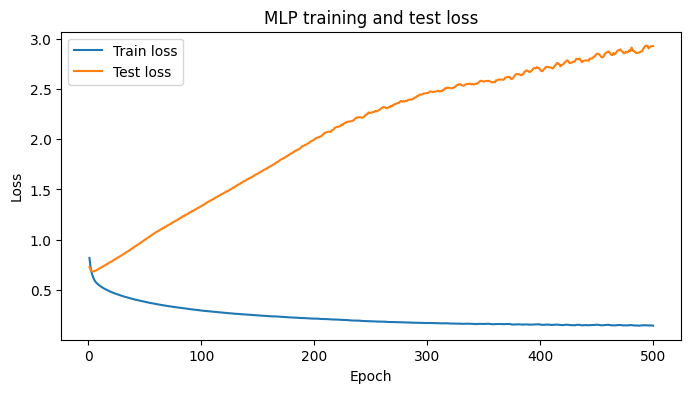


MLP EVALUATION RESULTS (ALL FEATURES)

ROC-AUC: 0.5475  (random baseline: 0.5)
PR-AUC:  0.4503  (random baseline: 0.4208)
PR-AUC improvement over random: 7.0%

Classification Report:
              precision    recall  f1-score   support

  No Relapse       0.60      0.61      0.60       479
     Relapse       0.45      0.44      0.45       348

    accuracy                           0.54       827
   macro avg       0.53      0.53      0.53       827
weighted avg       0.54      0.54      0.54       827

Confusion Matrix:
                 Predicted
                 No Relapse  Relapse
Actual No Relapse     291       188
Actual Relapse        194       154


In [43]:
# =============================================================================
# MLP using all features from combined model (cell 33)
# =============================================================================

import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, log_loss
)
import matplotlib.pyplot as plt

print("=" * 70)
print("MLP: All features (same data as combined XGBoost model)")
print("=" * 70)

# Use same inputs as cell 33 (X_train, y_train, X_test, y_test, feature_cols)
X_train_nn = np.asarray(X_train, dtype=np.float64)
X_test_nn = np.asarray(X_test, dtype=np.float64)
y_train_nn = np.ravel(y_train)
y_test_nn = np.ravel(y_test)

print(f"\nFeatures: {len(feature_cols)} (same as combined model)")
print(f"Training samples: {len(X_train_nn)}")
print(f"Test samples: {len(X_test_nn)}")

# Standardize (important for neural networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_nn)
X_test_scaled = scaler.transform(X_test_nn)

# Train MLP one epoch at a time to record train and test loss per epoch
max_epochs = 500
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=1,
    random_state=42,
    warm_start=True,
    alpha=0.1
)
train_losses = []
test_losses = []
print("\nTraining MLP (64, 32)...", end=" ", flush=True)
for epoch in range(max_epochs):
    mlp.fit(X_train_scaled, y_train_nn)
    train_losses.append(mlp.loss_)
    test_losses.append(log_loss(y_test_nn, mlp.predict_proba(X_test_scaled)[:, 1]))
print("Done.")

# Loss over epochs (train and test)
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train loss')
plt.plot(range(1, len(test_losses) + 1), test_losses, label='Test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MLP training and test loss')
plt.legend()
plt.show()

# Evaluate
y_pred_proba = mlp.predict_proba(X_test_scaled)[:, 1]
y_pred = mlp.predict(X_test_scaled)

roc_auc = roc_auc_score(y_test_nn, y_pred_proba)
pr_auc = average_precision_score(y_test_nn, y_pred_proba)
baseline_pr_auc = y_test_nn.mean()

print("\n" + "=" * 70)
print("MLP EVALUATION RESULTS (ALL FEATURES)")
print("=" * 70)
print(f"\nROC-AUC: {roc_auc:.4f}  (random baseline: 0.5)")
print(f"PR-AUC:  {pr_auc:.4f}  (random baseline: {baseline_pr_auc:.4f})")
print(f"PR-AUC improvement over random: {(pr_auc / baseline_pr_auc - 1) * 100:.1f}%")

print("\nClassification Report:")
print(classification_report(y_test_nn, y_pred, target_names=['No Relapse', 'Relapse']))

print("Confusion Matrix:")
cm = confusion_matrix(y_test_nn, y_pred)
print("                 Predicted")
print("                 No Relapse  Relapse")
print(f"Actual No Relapse    {cm[0,0]:4d}      {cm[0,1]:4d}")
print(f"Actual Relapse       {cm[1,0]:4d}      {cm[1,1]:4d}")

GOOD TO HERE

In [44]:
%%script false --no-raise-error

# =============================================================================
# TRANSFORMER: All features, sequences of days (same data as combined model)
# =============================================================================

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix

print("=" * 70)
print("TRANSFORMER: All features (sequences of days)")
print("=" * 70)

# -----------------------------------------------------------------------------
# 1. Create sequences from combined_all_circadian (same data as cell 33)
# -----------------------------------------------------------------------------
# Deduplicate so one row per (patient_id, split, day_index) - avoids huge sequence count and hang
train_rows_before = len(train_data)
test_rows_before = len(test_data)
train_data = train_data.drop_duplicates(subset=['patient_id', 'split', 'day_index'], keep='first').copy()
test_data = test_data.drop_duplicates(subset=['patient_id', 'split', 'day_index'], keep='first').copy()
if len(train_data) < train_rows_before or len(test_data) < test_rows_before:
    print(f"Dropped duplicates: train {train_rows_before} -> {len(train_data)}, test {test_rows_before} -> {len(test_data)}")

def create_sequences(df, feature_cols, seq_length=7):
    """Build sliding-window sequences per (patient_id, split). Label = relapse of last day."""
    seqs, labels = [], []
    for (pid, split), group in df.groupby(['patient_id', 'split']):
        group = group.sort_values('day_index').reset_index(drop=True)
        if len(group) < seq_length:
            continue
        feats = group[feature_cols].fillna(0).values.astype(np.float32)
        rel = group['relapse'].values
        for i in range(len(group) - seq_length + 1):
            seqs.append(feats[i : i + seq_length])
            labels.append(rel[i + seq_length - 1])
    return np.stack(seqs), np.array(labels, dtype=np.int64)

SEQ_LENGTH = 7
X_train_seq, y_train_seq = create_sequences(train_data, feature_cols, SEQ_LENGTH)
X_test_seq, y_test_seq = create_sequences(test_data, feature_cols, SEQ_LENGTH)

n_features = len(feature_cols)
print(f"\nSequences: seq_length={SEQ_LENGTH}, n_features={n_features}")
print(f"Train sequences: {len(X_train_seq)}")
print(f"Test sequences: {len(X_test_seq)}")

# -----------------------------------------------------------------------------
# 2. Standardize (fit on train, apply to both)
# -----------------------------------------------------------------------------

n_train, slen, nf = X_train_seq.shape
scaler = StandardScaler()
X_train_flat = X_train_seq.reshape(-1, nf)
scaler.fit(X_train_flat)
X_train_seq = scaler.transform(X_train_flat).reshape(n_train, slen, nf).astype(np.float32)
X_test_seq = scaler.transform(X_test_seq.reshape(-1, nf)).reshape(-1, slen, nf).astype(np.float32)

# -----------------------------------------------------------------------------
# 3. PyTorch transformer model
# -----------------------------------------------------------------------------

D_MODEL = 64
NHEAD = 4
NUM_LAYERS = 2
DROPOUT = 0.2

class SeqTransformer(nn.Module):
    def __init__(self, n_features, d_model=64, nhead=4, num_layers=2, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_embed = nn.Parameter(torch.zeros(1, 500, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=dropout, activation='relu', batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        # x: (batch, seq_len, n_features)
        x = self.input_proj(x)
        seq_len = x.size(1)
        x = x + self.pos_embed[:, :seq_len]
        x = self.transformer(x)
        x = x[:, -1]
        return self.fc(x).squeeze(-1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SeqTransformer(n_features, d_model=D_MODEL, nhead=NHEAD, num_layers=NUM_LAYERS, dropout=DROPOUT).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# -----------------------------------------------------------------------------
# 4. DataLoaders and training
# -----------------------------------------------------------------------------

BATCH_SIZE = 32
EPOCHS = 80

train_ds = TensorDataset(
    torch.from_numpy(X_train_seq),
    torch.from_numpy(y_train_seq).float().unsqueeze(1)
)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

print("\nTraining transformer...")
model.train()
for epoch in range(EPOCHS):
    total_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.squeeze(1).to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1}/{EPOCHS} loss={total_loss/len(train_loader):.4f}")
print("Done.")

# -----------------------------------------------------------------------------
# 5. Evaluate on test sequences
# -----------------------------------------------------------------------------

model.eval()
with torch.no_grad():
    X_test_t = torch.from_numpy(X_test_seq).to(device)
    logits = model(X_test_t).cpu().numpy()

y_pred_proba = 1 / (1 + np.exp(-logits))
y_pred = (y_pred_proba >= 0.5).astype(int)

roc_auc = roc_auc_score(y_test_seq, y_pred_proba)
pr_auc = average_precision_score(y_test_seq, y_pred_proba)
baseline_pr = y_test_seq.mean()

print("\n" + "=" * 70)
print("TRANSFORMER EVALUATION RESULTS (ALL FEATURES)")
print("=" * 70)
print(f"\nROC-AUC: {roc_auc:.4f}  (random baseline: 0.5)")
print(f"PR-AUC:  {pr_auc:.4f}  (random baseline: {baseline_pr:.4f})")
print(f"PR-AUC improvement over random: {(pr_auc / baseline_pr - 1) * 100:.1f}%")
print("\nClassification Report:")
print(classification_report(y_test_seq, y_pred, target_names=['No Relapse', 'Relapse']))
print("Confusion Matrix:")
cm = confusion_matrix(y_test_seq, y_pred)
print("                 Predicted")
print("                 No Relapse  Relapse")
print(f"Actual No Relapse    {cm[0,0]:4d}      {cm[0,1]:4d}")
print(f"Actual Relapse       {cm[1,0]:4d}      {cm[1,1]:4d}")


steps_zscore_inv - Inverted step count z-score (fewer steps than patient's baseline = higher value = higher risk)
num_sleep_episodes_zscore - Sleep fragmentation z-score (more sleep episodes than baseline = higher value = higher risk)
rmssd_zscore_sv - RMSSD (HRV metric) z-score during verified sleep periods
sdnn_zscore_sv - SDNN (HRV metric) z-score during verified sleep periods
mean_hr_zscore_sv - Mean heart rate z-score during verified sleep periods

1. steps_zscore_inv (Daily Step Count Deviation)
What it measures: How much the patient walked compared to their normal amount.
How it's calculated:
Count total steps each day from step.parquet
Calculate patient's average steps on non-relapse days (their baseline)
For each day: (baseline_steps - today's_steps) / baseline_std
Inverted so that fewer steps = higher value
Interpretation: Higher value = walked less than usual = higher relapse risk
2. num_sleep_episodes_zscore (Sleep Fragmentation)
What it measures: How fragmented/interrupted the patient's sleep was.
How it's calculated:
Count number of sleep episodes per day from sleep.parquet
Calculate patient's average episodes on non-relapse days (baseline)
For each day: (today's_episodes - baseline_episodes) / baseline_std
Interpretation: Higher value = more sleep interruptions than usual = higher relapse risk
3. rmssd_zscore_sv (Heart Rate Variability - RMSSD)
What it measures: Beat-to-beat heart rate variability during sleep.
How it's calculated:
Filter HRV data (hrm.parquet) to only times within sleep episodes
Calculate RMSSD: square root of mean squared successive RR interval differences
Compare to patient's baseline RMSSD from non-relapse nights
Z-score: (today's_rmssd - baseline_rmssd) / baseline_std
Interpretation: Changes in RMSSD from baseline may indicate autonomic nervous system changes
4. sdnn_zscore_sv (Heart Rate Variability - SDNN)
What it measures: Overall heart rate variability during sleep.
How it's calculated:
Filter HRV data to only times within sleep episodes
Calculate SDNN: standard deviation of all RR intervals
Compare to patient's baseline SDNN
Z-score: (today's_sdnn - baseline_sdnn) / baseline_std
Interpretation: Changes in SDNN from baseline may indicate stress or autonomic changes
5. mean_hr_zscore_sv (Mean Heart Rate During Sleep)
What it measures: Average heart rate while sleeping.
How it's calculated:
Filter HRV data to only times within sleep episodes
Calculate mean heart rate for that night
Compare to patient's baseline mean HR
Z-score: (today's_hr - baseline_hr) / baseline_std
Interpretation: Higher/lower HR than usual during sleep may indicate physiological changes
Key Concepts
Z-score: Measures how many standard deviations away from the patient's own baseline
Sleep-verified (_sv): HRV filtered to actual sleep periods using sleep.parquet, not just nighttime hours
Patient-specific baseline: Each patient compared to themselves, not to other patients

## Feature Selection & Dimensionality Reduction

Exploring which features matter most (Boruta, mRMR) and the geometric
structure of the data (PCA, t-SNE, UMAP). Training data = val splits only
(pooled across patients) to avoid test-set leakage.

In [45]:
# Install optional packages (silent if already present)
import subprocess, sys
for pkg in ['umap-learn', 'mrmr-selection', 'boruta']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
from mrmr import mrmr_classif
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# ── Prepare pooled train set (val splits only, to avoid leakage)
train_mask = combined_all_circadian['split_type'] == 'val'
df_train = combined_all_circadian[train_mask].copy()
df_all   = combined_all_circadian.copy()

X_train_raw = df_train[feature_cols].fillna(0)
y_train_raw = df_train['relapse'].values

X_all_raw   = df_all[feature_cols].fillna(0)
y_all       = df_all['relapse'].values
patients_all = df_all['patient_id'].values

scaler_fs = StandardScaler()
X_train_sc = scaler_fs.fit_transform(X_train_raw)
X_all_sc   = scaler_fs.transform(X_all_raw)

print(f"Train (val splits): {X_train_sc.shape[0]} days, {X_train_sc.shape[1]} features")
print(f"All data: {X_all_sc.shape[0]} days | Relapse rate: {y_all.mean():.1%}")


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
/Users/davidholt/ai_projects/psychiatry_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train (val splits): 797 days, 59 features
All data: 3337 days | Relapse rate: 18.2%


### PCA components (PC1, PC2, PC3) – what they mean

**Principal Component Analysis (PCA)** reduces many correlated features into fewer orthogonal “principal components” that capture most of the variance. Each component is a weighted combination of the original features.

- **PC1** – Captures the most variance. In this dataset, PC1 is dominated by **sleep-related features** (num_sleep_episodes, total_sleep_hours, main_sleep_hours, etc.). Higher PC1 = more sleep, more episodes, longer duration. It mainly separates “high sleep” vs “low sleep” days.

- **PC2** – Second-most variance. PC2 is dominated by **activity/steps features** (totalSteps, distance, stepsWalking, calories, steps_zscore). Higher PC2 = more physical activity. It mainly separates “high activity” vs “low activity” days.

- **PC3** – Third-most variance. PC3 mixes **naps and circadian patterns** (num_naps_diff, day_activity_proportion, nap_hours, evening_activity, intradaily_variability). It tends to separate napping vs non-napping and different activity timing patterns.

The scatter plots below use PC1 (x) and PC2 (y) to visualize how relapse vs non-relapse days (and different patients) sit in this 2D space.

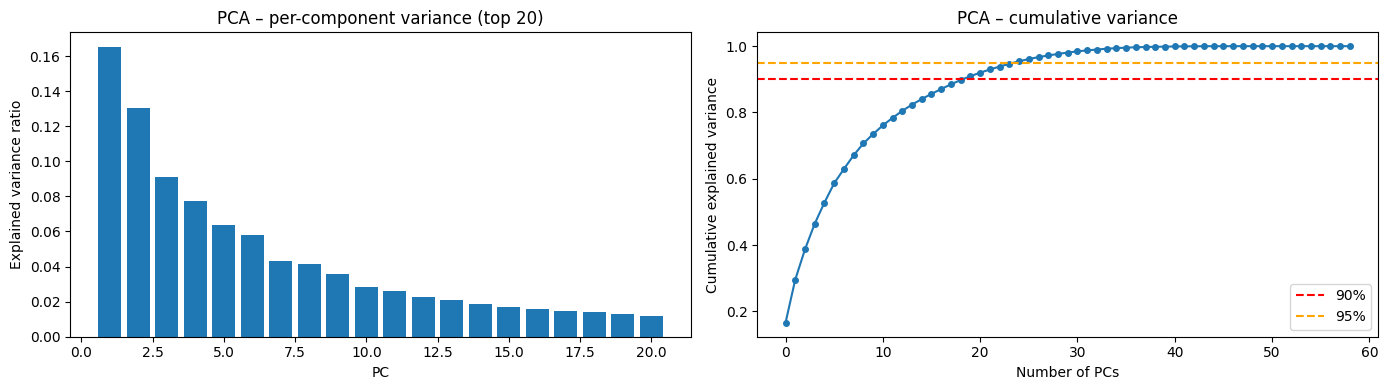

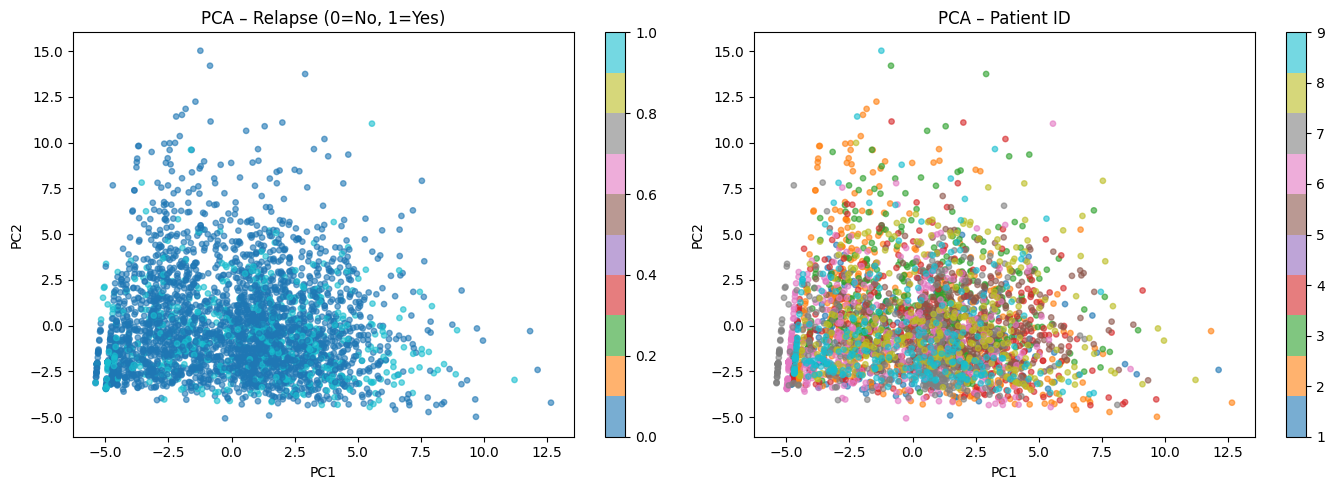


PC1 top loadings:
  num_sleep_episodes                             +0.279
  total_sleep_hours_diff                         +0.276
  total_sleep_hours                              +0.271
  num_sleep_episodes_diff                        +0.270
  num_sleep_episodes_zscore                      +0.270
  total_sleep_hours_zscore                       +0.262
  num_naps                                       +0.240
  main_sleep_hours                               +0.223

PC2 top loadings:
  totalSteps                                     +0.355
  distance                                       +0.353
  stepsWalking                                   +0.352
  calories                                       +0.344
  steps_diff                                     +0.334
  steps_zscore_inv                               -0.330
  steps_zscore                                   +0.330
  day_activity_zscore                            +0.193

PC3 top loadings:
  rmssd                                        

In [46]:
# ── PCA ──────────────────────────────────────────────────────────────────
pca = PCA().fit(X_train_sc)

# 1. Variance explained
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(range(1, 21), pca.explained_variance_ratio_[:20])
axes[0].set_xlabel('PC'); axes[0].set_ylabel('Explained variance ratio')
axes[0].set_title('PCA – per-component variance (top 20)')
axes[1].plot(np.cumsum(pca.explained_variance_ratio_), marker='o', ms=4)
axes[1].axhline(0.90, ls='--', c='red', label='90%')
axes[1].axhline(0.95, ls='--', c='orange', label='95%')
axes[1].set_xlabel('Number of PCs'); axes[1].set_ylabel('Cumulative explained variance')
axes[1].set_title('PCA – cumulative variance'); axes[1].legend()
plt.tight_layout(); plt.show()

# 2. 2-D scatter (all data) coloured by relapse, then by patient
X_pca_all = pca.transform(X_all_sc)
patients_all_int = np.array([int(p[1:]) for p in patients_all])  # 'P1' -> 1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, color_vec, title in zip(axes,
        [y_all, patients_all_int],
        ['Relapse (0=No, 1=Yes)', 'Patient ID']):
    sc = ax.scatter(X_pca_all[:, 0], X_pca_all[:, 1],
                    c=color_vec, cmap='tab10', alpha=0.6, s=15)
    plt.colorbar(sc, ax=ax)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_title(f'PCA – {title}')
plt.tight_layout(); plt.show()

# 3. Top loadings
for i, pc_label in enumerate(['PC1', 'PC2', 'PC3']):
    top_idx = np.argsort(np.abs(pca.components_[i]))[-8:][::-1]
    top_feats = [(feature_cols[j], pca.components_[i][j]) for j in top_idx]
    print(f"\n{pc_label} top loadings:")
    for f, v in top_feats:
        print(f"  {f:45s}  {v:+.3f}")

Fitting t-SNE on 600 days …
Done.


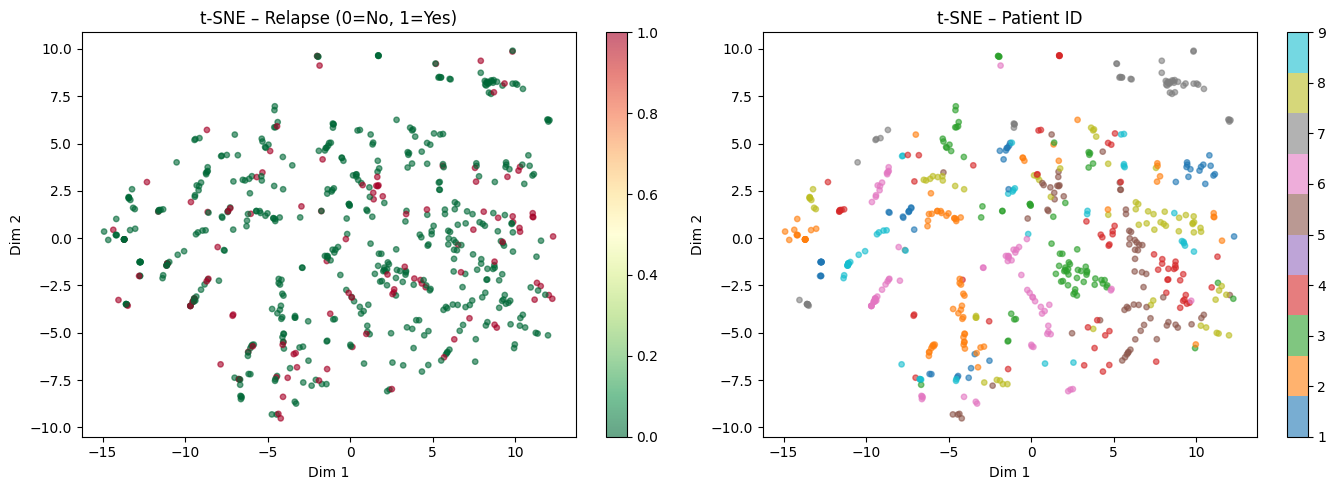

In [47]:
# ── t-SNE ────────────────────────────────────────────────────────────────
# UMAP skipped: numba JIT + PyTorch OpenMP conflict causes kernel hangs on macOS.
# t-SNE via sklearn is sufficient for structure inspection.

import os
os.environ['OMP_NUM_THREADS'] = '1'   # prevent OMP conflict with PyTorch

# Subsample for speed (t-SNE is O(n log n); 600 pts runs in ~10 s)
rng = np.random.default_rng(42)
viz_idx  = rng.choice(len(X_all_sc), size=min(600, len(X_all_sc)), replace=False)
X_viz    = X_all_sc[viz_idx]
y_viz    = y_all[viz_idx]
pat_viz  = np.array([int(p[1:]) for p in patients_all[viz_idx]])

print(f"Fitting t-SNE on {len(viz_idx)} days …")
tsne   = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=300)
X_tsne = tsne.fit_transform(X_viz)
print("Done.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, color_vec, title, cmap in zip(
        axes,
        [y_viz, pat_viz],
        ['Relapse (0=No, 1=Yes)', 'Patient ID'],
        ['RdYlGn_r', 'tab10']):
    sc = ax.scatter(X_tsne[:, 0], X_tsne[:, 1],
                    c=color_vec, cmap=cmap, alpha=0.6, s=15)
    plt.colorbar(sc, ax=ax)
    ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2'); ax.set_title(f't-SNE – {title}')

plt.tight_layout(); plt.show()

100%|██████████| 15/15 [00:00<00:00, 68.79it/s]

mRMR top-15 features (ordered by relevance – redundancy):
   1. watch_dominant
   2. calories
   3. alcohol_consumption
   4. num_naps_diff
   5. main_sleep_hours_zscore
   6. day_activity_zscore
   7. birth_complications
   8. steps_diff
   9. educational_level
  10. nap_hours_diff
  11. day_activity_proportion
  12. smoking
  13. distance
  14. num_sleep_episodes_diff
  15. stepsWalking

(feat_importance_df not in scope;)


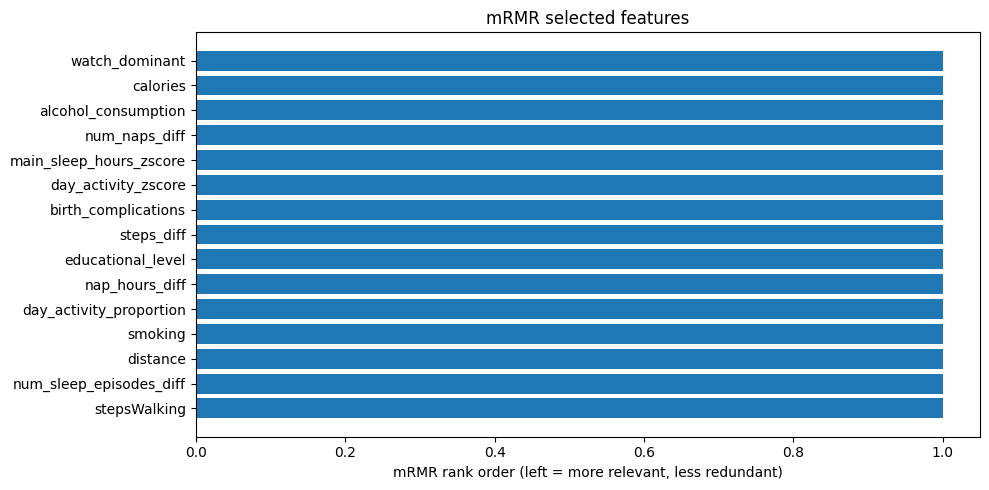

In [48]:
# ── mRMR (minimum Redundancy Maximum Relevance) ───────────────────────────
K = 15  # number of features to select
selected_mrmr = mrmr_classif(
    X=pd.DataFrame(X_train_raw.values, columns=feature_cols),
    y=pd.Series(y_train_raw),
    K=K
)

print(f"mRMR top-{K} features (ordered by relevance – redundancy):")
for rank, feat in enumerate(selected_mrmr, 1):
    print(f"  {rank:2d}. {feat}")

# Compare with XGBoost importance from cell 35 (if available)
try:
    xgb_top = feat_importance_df.head(15)['feature'].tolist()
    overlap = set(selected_mrmr) & set(xgb_top)
    print(f"\nOverlap with XGBoost top-15: {len(overlap)}/15 features")
    print("  Shared:", sorted(overlap))
    print("  mRMR-only:", sorted(set(selected_mrmr) - set(xgb_top)))
    print("  XGB-only: ", sorted(set(xgb_top) - set(selected_mrmr)))
except NameError:
    print("\n(feat_importance_df not in scope;)")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(K, 0, -1), [1]*K)
ax.set_yticks(range(K, 0, -1))
ax.set_yticklabels(selected_mrmr)
ax.set_xlabel('mRMR rank order (left = more relevant, less redundant)')
ax.set_title('mRMR selected features')
plt.tight_layout(); plt.show()

Boruta results (59 features total):
  Confirmed (17):  [np.str_('num_naps_diff'), np.str_('nap_hours_diff'), np.str_('main_sleep_onset_diff'), np.str_('main_sleep_hours_zscore'), np.str_('main_sleep_onset_zscore'), np.str_('total_sleep_hours_zscore'), np.str_('num_sleep_episodes_zscore'), np.str_('totalSteps'), np.str_('stepsWalking'), np.str_('distance'), np.str_('calories'), np.str_('steps_diff'), np.str_('steps_zscore'), np.str_('steps_zscore_inv'), np.str_('cosinor_amplitude_zscore'), np.str_('circadian_deviation'), np.str_('day_activity_zscore')]
  Tentative (2): [np.str_('main_sleep_hours_diff'), np.str_('watch_dominant')]
  Rejected  (40): [np.str_('main_sleep_hours'), np.str_('main_sleep_onset'), np.str_('main_sleep_wake'), np.str_('total_sleep_hours'), np.str_('num_naps'), np.str_('nap_hours'), np.str_('num_sleep_episodes'), np.str_('total_sleep_hours_diff'), np.str_('num_sleep_episodes_diff'), np.str_('stepsRunning'), np.str_('rmssd'), np.str_('sdnn'), np.str_('mean_hr'), np.

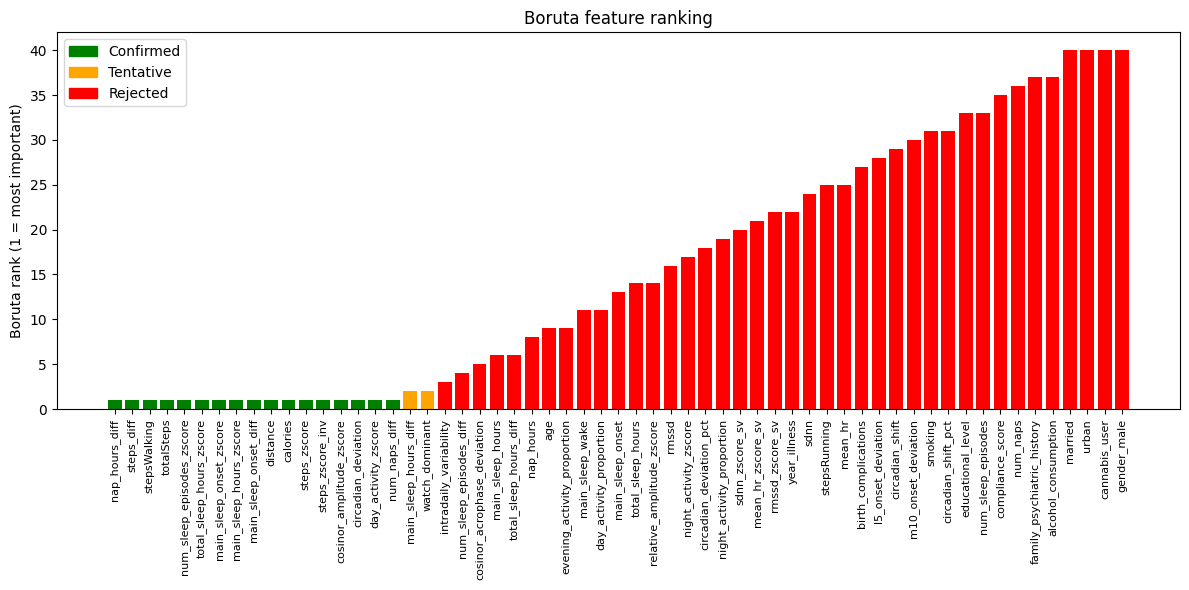


=== Cross-method summary ===
Boruta confirmed ∩ mRMR top-15: ['calories', 'day_activity_zscore', 'distance', 'main_sleep_hours_zscore', 'nap_hours_diff', 'num_naps_diff', 'stepsWalking', 'steps_diff']


In [49]:
# ── Boruta ────────────────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, max_depth=5,
                             class_weight='balanced', random_state=42, n_jobs=-1)
boruta = BorutaPy(rf, n_estimators='auto', max_iter=50, random_state=42, verbose=0)
boruta.fit(X_train_sc, y_train_raw)

support   = np.array(feature_cols)[boruta.support_]
tentative = np.array(feature_cols)[boruta.support_weak_]
rejected  = np.array(feature_cols)[~boruta.support_ & ~boruta.support_weak_]

print(f"Boruta results ({X_train_sc.shape[1]} features total):")
print(f"  Confirmed ({len(support)}):  {list(support)}")
print(f"  Tentative ({len(tentative)}): {list(tentative)}")
print(f"  Rejected  ({len(rejected)}): {list(rejected)}")

# Rank-ordered bar chart coloured by decision
ranks = boruta.ranking_
order = np.argsort(ranks)
colors = ['green' if boruta.support_[i] else
          'orange' if boruta.support_weak_[i] else 'red'
          for i in order]
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(range(len(order)), ranks[order], color=colors)
ax.set_xticks(range(len(order)))
ax.set_xticklabels([feature_cols[i] for i in order], rotation=90, fontsize=8)
ax.set_ylabel('Boruta rank (1 = most important)')
ax.set_title('Boruta feature ranking')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='green', label='Confirmed'),
                   Patch(color='orange', label='Tentative'),
                   Patch(color='red',    label='Rejected')])
plt.tight_layout(); plt.show()

# Summary cross-method comparison
print("\n=== Cross-method summary ===")
confirmed_set = set(support)
mrmr_set = set(selected_mrmr)
print(f"Boruta confirmed ∩ mRMR top-{K}: {sorted(confirmed_set & mrmr_set)}")

In [50]:
# =============================================================================
# LOPO MODEL: BORUTA-CONFIRMED FEATURES (14 features)
# =============================================================================

import numpy as np
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

boruta_feats = [str(f) for f in support]   # cast away np.str_
print("=" * 70)
print(f"LOPO — Boruta-confirmed features ({len(boruta_feats)})")
print("=" * 70)
print("Features:", boruta_feats)

patients_lopo = sorted(combined_all_circadian['patient_id'].unique())

def lopo_eval(model_factory, feats):
    aurocs, auprcs = [], []
    for test_patient in patients_lopo:
        train_df = combined_all_circadian[
            (combined_all_circadian['patient_id'] != test_patient) &
            (combined_all_circadian['split_type'] == 'val')
        ]
        test_df = combined_all_circadian[
            (combined_all_circadian['patient_id'] == test_patient) &
            (combined_all_circadian['split_type'] == 'test')
        ]
        if len(train_df) == 0 or len(test_df) == 0:
            continue
        X_tr = train_df[feats].fillna(0).values
        y_tr = train_df['relapse'].fillna(0).astype(int).values
        X_te = test_df[feats].fillna(0).values
        y_te = test_df['relapse'].fillna(0).astype(int).values
        if len(np.unique(y_te)) < 2:
            continue
        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)
        m = model_factory(y_tr)
        m.fit(X_tr_s, y_tr)
        pred = m.predict_proba(X_te_s)[:, 1]
        aurocs.append(roc_auc_score(y_te, pred))
        auprcs.append(average_precision_score(y_te, pred))
    return (np.mean(aurocs), np.std(aurocs), np.mean(auprcs)) if aurocs else (np.nan, np.nan, np.nan)

def xgb_factory(y_tr):
    n_neg, n_pos = (y_tr == 0).sum(), (y_tr == 1).sum()
    spw = n_neg / n_pos if n_pos > 0 else 1
    return XGBClassifier(n_estimators=50, max_depth=4, learning_rate=0.05,
                         scale_pos_weight=spw, random_state=42, eval_metric='logloss')

configs = [
    ("XGBoost",        xgb_factory),
    ("LR L2 (C=0.1)",  lambda y: LogisticRegression(C=0.1,  penalty='l2', max_iter=1000, random_state=42)),
    ("LR L1 (C=0.05)", lambda y: LogisticRegression(C=0.05, penalty='l1', solver='liblinear', max_iter=1000, random_state=42)),
]

print()
results = []
for label, factory in configs:
    auc, std, prc = lopo_eval(factory, boruta_feats)
    results.append((label, auc, std, prc))
    print(f"  {label:<22}  ROC-AUC = {auc:.4f} ± {std:.4f}   PR-AUC = {prc:.4f}")

print("\n" + "=" * 70)
print(f"{'Method':<35} | {'K':>4} | {'LOPO ROC-AUC':>18} | {'PR-AUC':>8}")
print("-" * 72)
print(f"{'XGBoost full features (59)':<35} | {59:>4} | {'0.530 ± 0.083':>18} | {'0.469':>8}")
for label, auc, std, prc in results:
    print(f"{label + ' [Boruta-14]':<35} | {14:>4} | {auc:.3f} ± {std:.3f}     | {prc:.4f}")

LOPO — Boruta-confirmed features (17)
Features: ['num_naps_diff', 'nap_hours_diff', 'main_sleep_onset_diff', 'main_sleep_hours_zscore', 'main_sleep_onset_zscore', 'total_sleep_hours_zscore', 'num_sleep_episodes_zscore', 'totalSteps', 'stepsWalking', 'distance', 'calories', 'steps_diff', 'steps_zscore', 'steps_zscore_inv', 'cosinor_amplitude_zscore', 'circadian_deviation', 'day_activity_zscore']

  XGBoost                 ROC-AUC = 0.5374 ± 0.0937   PR-AUC = 0.4891
  LR L2 (C=0.1)           ROC-AUC = 0.5595 ± 0.1039   PR-AUC = 0.4895
  LR L1 (C=0.05)          ROC-AUC = 0.5809 ± 0.1253   PR-AUC = 0.5159

Method                              |    K |       LOPO ROC-AUC |   PR-AUC
------------------------------------------------------------------------
XGBoost full features (59)          |   59 |      0.530 ± 0.083 |    0.469
XGBoost [Boruta-14]                 |   14 | 0.537 ± 0.094     | 0.4891
LR L2 (C=0.1) [Boruta-14]           |   14 | 0.559 ± 0.104     | 0.4895
LR L1 (C=0.05) [Boruta-

In [51]:

# =============================================================================
# COMBINED MODEL: All features (sleep + steps + HRV + demographics + circadian)
# =============================================================================

import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix
)

print("=" * 70)
print("COMBINED MODEL: All features + circadian")
print("=" * 70)

# -----------------------------------------------------------------------------
# 1. Build combined dataset
# -----------------------------------------------------------------------------

combined_all_circadian = sleep_features_df.copy()
print(f"\n1. Starting with sleep_features_df: {combined_all_circadian.shape}")

combined_all_circadian = combined_all_circadian.merge(
    step_features_df,
    on=['patient_id', 'day_index', 'split', 'split_type', 'relapse'],
    how='left',
    suffixes=('', '_step')
)
print(f"2. After merging step features: {combined_all_circadian.shape}")

hrv_sv_cols = ['patient_id', 'day_index', 'split', 'rmssd', 'sdnn', 'mean_hr',
               'rmssd_zscore_sv', 'sdnn_zscore_sv', 'mean_hr_zscore_sv']
hrv_sv_cols = [c for c in hrv_sv_cols if c in hrv_sleep_verified_df.columns]
combined_all_circadian = combined_all_circadian.merge(
    hrv_sleep_verified_df[hrv_sv_cols],
    on=['patient_id', 'day_index', 'split'],
    how='left',
    suffixes=('', '_hrv')
)
print(f"3. After merging HRV features: {combined_all_circadian.shape}")

circadian_cols = [
    'night_activity_proportion', 'day_activity_proportion',
    'circadian_deviation_pct', 'circadian_shift_pct',
    'evening_activity_proportion', 'relative_amplitude_zscore',
    'l5_onset_deviation', 'm10_onset_deviation',
    'intradaily_variability', 'cosinor_amplitude_zscore', 'cosinor_acrophase_deviation',
    'circadian_deviation', 'night_activity_zscore', 'day_activity_zscore', 'circadian_shift'
]
circadian_cols = [c for c in circadian_cols if c in circadian_features_df.columns]
if circadian_cols:
    circ_df = circadian_features_df[['patient_id', 'day_index', 'split'] + circadian_cols]
    combined_all_circadian = combined_all_circadian.merge(
        circ_df,
        on=['patient_id', 'day_index', 'split'],
        how='left'
    )
print(f"4. After merging circadian features: {combined_all_circadian.shape}")

if 'demo_encoded' in globals() and 'demographic_feature_cols' in globals():
    combined_all_circadian = combined_all_circadian.merge(
        demo_encoded[['patient_id'] + demographic_feature_cols],
        on='patient_id',
        how='left'
    )
    print(f"5. After merging demographics: {combined_all_circadian.shape}")
else:
    print("5. Skipping demographics (demo_encoded / demographic_feature_cols not defined)")

# -----------------------------------------------------------------------------
# 2. Define feature columns
# -----------------------------------------------------------------------------

all_numeric = combined_all_circadian.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [
    c for c in all_numeric
    if c not in {'relapse', 'day_index', 'relapse_step'} and not c.endswith('_index')
]
# Optional: keep only features with >50% non-null
feature_cols = [
    c for c in feature_cols
    if combined_all_circadian[c].notna().mean() > 0.5
]
print(f"\nFeature count: {len(feature_cols)}")
print(f"Features: {feature_cols[:10]}{'...' if len(feature_cols) > 10 else ''}")

# -----------------------------------------------------------------------------
# 3. Train/test split
# -----------------------------------------------------------------------------

train_data = combined_all_circadian[combined_all_circadian['split_type'] == 'val'].copy()
test_data = combined_all_circadian[combined_all_circadian['split_type'] == 'test'].copy()

print("\nNOTE: Using only VAL splits for training (train splits have 0% relapses)")
print("Data split:")
print(f"  Training (val): {len(train_data)} days")
print(f"  Test: {len(test_data)} days")

X_train = train_data[feature_cols].copy().fillna(0)
y_train = train_data['relapse'].copy().fillna(0).astype(int)
X_test = test_data[feature_cols].copy().fillna(0)
y_test = test_data['relapse'].copy().fillna(0).astype(int)

print(f"\nFeature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test: {X_test.shape}")

# -----------------------------------------------------------------------------
# 4. Train XGBoost and evaluate
# -----------------------------------------------------------------------------

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1

model = XGBClassifier(
    n_estimators=50,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

print("\nTraining XGBoost (all features + circadian)...")
model.fit(X_train, y_train)
print("Training complete!")

y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)
baseline_pr_auc = y_test.mean()

print("\n" + "=" * 70)
print("MODEL EVALUATION RESULTS (ALL FEATURES + CIRCADIAN)")
print("=" * 70)
print(f"\nROC-AUC: {roc_auc:.4f}  (random baseline: 0.5)")
print(f"PR-AUC:  {pr_auc:.4f}  (random baseline: {baseline_pr_auc:.4f})")
print(f"PR-AUC improvement over random: {(pr_auc / baseline_pr_auc - 1) * 100:.1f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Relapse', 'Relapse']))
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print("                 Predicted")
print("                 No Relapse  Relapse")
print(f"Actual No Relapse    {cm[0,0]:4d}      {cm[0,1]:4d}")
print(f"Actual Relapse       {cm[1,0]:4d}      {cm[1,1]:4d}")


COMBINED MODEL: All features + circadian

1. Starting with sleep_features_df: (3337, 22)
2. After merging step features: (3337, 30)
3. After merging HRV features: (3337, 36)
4. After merging circadian features: (3337, 51)
5. After merging demographics: (3337, 69)

Feature count: 59
Features: ['main_sleep_hours', 'main_sleep_onset', 'main_sleep_wake', 'total_sleep_hours', 'num_naps', 'nap_hours', 'num_sleep_episodes', 'main_sleep_hours_diff', 'total_sleep_hours_diff', 'num_naps_diff']...

NOTE: Using only VAL splits for training (train splits have 0% relapses)
Data split:
  Training (val): 797 days
  Test: 827 days

Feature matrix shapes:
  X_train: (797, 59)
  X_test: (827, 59)

Training XGBoost (all features + circadian)...
Training complete!

MODEL EVALUATION RESULTS (ALL FEATURES + CIRCADIAN)

ROC-AUC: 0.5436  (random baseline: 0.5)
PR-AUC:  0.4472  (random baseline: 0.4208)
PR-AUC improvement over random: 6.3%

Classification Report:
              precision    recall  f1-score   su

In [52]:

# =========================================================
# DUAL-STREAM TRANSFORMER FUSION — Separate HP Tuning
# Phase 1: HP tune AE  (4 configs × 9 folds)
# Phase 2: HP tune Sup (4 configs × 9 folds)
# Phase 3: Fusion LOPO (best_ae + best_sup)
# =========================================================

import copy, time
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler

# ── Hyperparameters ───────────────────────────────────────────────────────────
SEQ_LEN    = 7
NHEAD      = 4
AE_EPOCHS  = 60
SUP_EPOCHS = 40
FUS_EPOCHS = 30
LR_AE      = 1e-3
LR_SUP     = 5e-4
LR_FUS     = 5e-4
BATCH      = 32
D_HIDDEN   = 32
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── HP search grid ────────────────────────────────────────────────────────────
HP_CONFIGS = [
    dict(name="small",  d_model=32,  d_lat=16, d_ff=64,  n_layers=2),
    dict(name="medium", d_model=64,  d_lat=32, d_ff=128, n_layers=2),
    dict(name="large",  d_model=128, d_lat=64, d_ff=256, n_layers=2),
    dict(name="deep",   d_model=64,  d_lat=32, d_ff=128, n_layers=3),
]

# ── Feature sets ──────────────────────────────────────────────────────────────
META_COLS    = {'patient_id', 'day_index', 'split', 'split_type', 'relapse'}
all_features    = [c for c in combined_all_circadian.columns if c not in META_COLS]
boruta_features = [str(f) for f in support if str(f) in combined_all_circadian.columns]
N_ALL = len(all_features)
N_SUP = len(boruta_features)
print(f"AE stream:  {N_ALL} features")
print(f"Sup stream: {N_SUP} Boruta-confirmed features: {boruta_features}")
print(f"Device: {DEVICE}")


# ── Architecture ──────────────────────────────────────────────────────────────
class SharedEncoder(nn.Module):
    def __init__(self, n_feat, d_model, d_lat, nhead, n_layers, seq_len, d_ff):
        super().__init__()
        self.input_proj = nn.Linear(n_feat, d_model)
        self.pos_embed  = nn.Parameter(torch.zeros(1, seq_len, d_model))
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_ff,
            dropout=0.1, batch_first=True
        )
        self.tf_encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.bottleneck = nn.Linear(d_model, d_lat)

    def forward(self, x):
        z = self.input_proj(x) + self.pos_embed
        z = self.tf_encoder(z)
        z = z.mean(dim=1)
        return self.bottleneck(z)


class TransformerAE(nn.Module):
    def __init__(self, n_feat, cfg, seq_len=SEQ_LEN, nhead=NHEAD):
        super().__init__()
        d_model, d_lat, d_ff, n_layers = cfg['d_model'], cfg['d_lat'], cfg['d_ff'], cfg['n_layers']
        self.seq_len = seq_len
        self.encoder = SharedEncoder(n_feat, d_model, d_lat, nhead, n_layers, seq_len, d_ff)
        self.expand  = nn.Linear(d_lat, d_model)
        dec_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_ff,
            dropout=0.1, batch_first=True
        )
        self.tf_decoder  = nn.TransformerDecoder(dec_layer, num_layers=n_layers)
        self.output_proj = nn.Linear(d_model, n_feat)

    def forward(self, x):
        lat = self.encoder(x)
        mem = self.expand(lat).unsqueeze(1).expand(-1, self.seq_len, -1)
        dec = self.tf_decoder(mem, mem)
        return self.output_proj(dec)


class SupClassifier(nn.Module):
    def __init__(self, n_feat, cfg, seq_len=SEQ_LEN, nhead=NHEAD):
        super().__init__()
        d_model, d_lat, d_ff, n_layers = cfg['d_model'], cfg['d_lat'], cfg['d_ff'], cfg['n_layers']
        self.encoder = SharedEncoder(n_feat, d_model, d_lat, nhead, n_layers, seq_len, d_ff)
        self.head    = nn.Linear(d_lat, 1)

    def forward(self, x):
        return self.head(self.encoder(x))


class DualStreamFusion(nn.Module):
    def __init__(self, ae_enc, sup_enc, d_ae_lat, d_sup_lat, d_hidden=D_HIDDEN):
        super().__init__()
        self.ae_enc  = copy.deepcopy(ae_enc)
        self.sup_enc = copy.deepcopy(sup_enc)
        for p in list(self.ae_enc.parameters()) + list(self.sup_enc.parameters()):
            p.requires_grad_(False)
        self.fusion = nn.Sequential(
            nn.Linear(d_ae_lat + d_sup_lat, d_hidden),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(d_hidden, 1)
        )

    def forward(self, x_ae, x_sup):
        z = torch.cat([self.ae_enc(x_ae), self.sup_enc(x_sup)], dim=1)
        return self.fusion(z)


# ── Data helpers ──────────────────────────────────────────────────────────────
def make_windows(df, feature_cols, seq_len, non_relapse_only=False, scaler=None):
    windows, labels = [], []
    for pid, pdf in df.groupby('patient_id'):
        pdf = pdf.sort_values('day_index')
        if non_relapse_only:
            pdf = pdf[pdf['relapse'].fillna(0) == 0]
        arr  = pdf[feature_cols].fillna(0).values.astype(np.float32)
        labs = pdf['relapse'].fillna(0).astype(int).values
        for i in range(len(arr) - seq_len + 1):
            windows.append(arr[i:i + seq_len])
            labels.append(labs[i + seq_len - 1])
    if len(windows) == 0:
        return None, None
    X = np.stack(windows)
    y = np.array(labels, dtype=np.float32)
    if scaler is not None:
        N, S, F = X.shape
        X = scaler.transform(X.reshape(-1, F)).reshape(N, S, F).astype(np.float32)
    return torch.tensor(X), torch.tensor(y)


def _pos_weight(y_tensor):
    n_neg = (y_tensor == 0).sum().item()
    n_pos = (y_tensor == 1).sum().item()
    return torch.tensor([n_neg / n_pos if n_pos > 0 else 1.0], device=DEVICE)


# ── Training helpers ──────────────────────────────────────────────────────────
def train_ae(model, X_tensor, epochs=AE_EPOCHS, lr=LR_AE, batch=BATCH, log_every=None):
    if log_every is None:
        log_every = max(1, epochs // 3)
    model.train()
    opt     = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    dl      = DataLoader(TensorDataset(X_tensor), batch_size=batch, shuffle=True)
    for ep in range(1, epochs + 1):
        total = 0.0
        for (xb,) in dl:
            xb = xb.to(DEVICE)
            opt.zero_grad()
            l = loss_fn(model(xb), xb)
            l.backward()
            opt.step()
            total += l.item() * len(xb)
        if ep % log_every == 0:
            print(f"      AE  ep {ep:>3}/{epochs}  loss={total / len(X_tensor):.4f}")


def train_sup(model, X_tensor, y_tensor, epochs=SUP_EPOCHS, lr=LR_SUP, batch=BATCH, log_every=None):
    if log_every is None:
        log_every = max(1, epochs // 4)
    model.train()
    pos_w   = _pos_weight(y_tensor)
    opt     = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    dl      = DataLoader(TensorDataset(X_tensor, y_tensor.unsqueeze(1)),
                         batch_size=batch, shuffle=True)
    for ep in range(1, epochs + 1):
        total = 0.0
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            l = loss_fn(model(xb), yb)
            l.backward()
            opt.step()
            total += l.item() * len(xb)
        if ep % log_every == 0:
            print(f"      Sup ep {ep:>3}/{epochs}  loss={total / len(X_tensor):.4f}")


def train_fusion(model, X_ae, X_sup, y_tensor, epochs=FUS_EPOCHS, lr=LR_FUS, batch=BATCH, log_every=None):
    if log_every is None:
        log_every = max(1, epochs // 3)
    model.train()
    pos_w   = _pos_weight(y_tensor)
    opt     = torch.optim.Adam(model.fusion.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    dl      = DataLoader(TensorDataset(X_ae, X_sup, y_tensor.unsqueeze(1)),
                         batch_size=batch, shuffle=True)
    for ep in range(1, epochs + 1):
        total = 0.0
        for xae, xsup, yb in dl:
            xae, xsup, yb = xae.to(DEVICE), xsup.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            l = loss_fn(model(xae, xsup), yb)
            l.backward()
            opt.step()
            total += l.item() * len(yb)
        if ep % log_every == 0:
            print(f"      Fusion ep {ep:>3}/{epochs}  loss={total / len(y_tensor):.4f}")


# ── Scoring helpers ───────────────────────────────────────────────────────────
def scores_ae(model, X_tensor):
    model.eval()
    with torch.no_grad():
        x     = X_tensor.to(DEVICE)
        recon = model(x)
        err   = ((recon - x) ** 2).mean(dim=(1, 2))
    return err.cpu().numpy()


def scores_sup(model, X_tensor):
    model.eval()
    with torch.no_grad():
        out = torch.sigmoid(model(X_tensor.to(DEVICE))).squeeze(1)
    return out.cpu().numpy()


def scores_fusion(model, X_ae, X_sup):
    model.eval()
    with torch.no_grad():
        out = torch.sigmoid(model(X_ae.to(DEVICE), X_sup.to(DEVICE))).squeeze(1)
    return out.cpu().numpy()


# ── Fold-data builder ─────────────────────────────────────────────────────────
patients = sorted(combined_all_circadian['patient_id'].unique())

def build_fold_data(test_patient):
    """Returns (other_val, test_df, scaler_ae, scaler_sup) or None if invalid."""
    other_val = combined_all_circadian[
        (combined_all_circadian['patient_id'] != test_patient) &
        (combined_all_circadian['split_type'] == 'val')
    ]
    test_df = combined_all_circadian[
        (combined_all_circadian['patient_id'] == test_patient) &
        (combined_all_circadian['split_type'] == 'test')
    ]
    y_raw = test_df['relapse'].fillna(0).astype(int).values
    if len(np.unique(y_raw)) < 2 or len(test_df) < SEQ_LEN:
        return None
    scaler_ae = StandardScaler()
    scaler_ae.fit(other_val[all_features].fillna(0).values)
    scaler_sup = StandardScaler()
    scaler_sup.fit(other_val[boruta_features].fillna(0).values)
    return other_val, test_df, scaler_ae, scaler_sup


# =============================================================================
# PHASE 1 — HP Tune AE  (4 configs × 9 folds)
# =============================================================================
print("\n" + "=" * 65)
print("Phase 1 — HP Tuning: AE  (4 configs × 9 folds)")
print("=" * 65)

ae_hp_results = {}

for cfg in HP_CONFIGS:
    name   = cfg['name']
    aurocs = []
    print(f"\n  Config: {name}  d_model={cfg['d_model']} d_lat={cfg['d_lat']} "
          f"d_ff={cfg['d_ff']} L={cfg['n_layers']}")

    for test_patient in patients:
        fold = build_fold_data(test_patient)
        if fold is None:
            print(f"    Fold {test_patient}: skipped (invalid test fold)")
            continue
        other_val, test_df, scaler_ae, _ = fold

        X_tr, _ = make_windows(other_val, all_features, SEQ_LEN,
                                non_relapse_only=True, scaler=scaler_ae)
        if X_tr is None or len(X_tr) == 0:
            print(f"    Fold {test_patient}: skipped (no AE train data)")
            continue

        X_te, y_te = make_windows(test_df, all_features, SEQ_LEN, scaler=scaler_ae)
        if X_te is None or len(np.unique(y_te.numpy())) < 2:
            print(f"    Fold {test_patient}: skipped (no label variation in test)")
            continue

        n_vd = len(other_val);  n_vr = int(other_val['relapse'].fillna(0).sum())
        n_td = len(test_df);    n_tr = int(test_df['relapse'].fillna(0).sum())
        print(f"\n  [{name} d={cfg['d_model']} L={cfg['n_layers']}] Fold {test_patient}  "
              f"(val={n_vd} {n_vr}R | test={n_td} {n_tr}R)")

        t0    = time.time()
        model = TransformerAE(N_ALL, cfg).to(DEVICE)
        train_ae(model, X_tr, epochs=AE_EPOCHS, log_every=max(1, AE_EPOCHS // 3))
        err   = scores_ae(model, X_te)
        auc   = roc_auc_score(y_te.numpy(), err)
        aurocs.append(auc)
        print(f"    → AE anomaly AUROC={auc:.3f}  ({time.time() - t0:.1f}s)")

    ae_hp_results[name] = aurocs

best_ae_name = max(ae_hp_results, key=lambda k: np.mean(ae_hp_results[k]) if ae_hp_results[k] else 0)
best_ae_cfg  = next(c for c in HP_CONFIGS if c['name'] == best_ae_name)
print(f"\nBest AE config: {best_ae_name}  "
      f"(AUROC={np.mean(ae_hp_results[best_ae_name]):.3f} ± "
      f"{np.std(ae_hp_results[best_ae_name]):.3f})")


# =============================================================================
# PHASE 2 — HP Tune Supervised  (4 configs × 9 folds)
# =============================================================================
print("\n" + "=" * 65)
print("Phase 2 — HP Tuning: Supervised  (4 configs × 9 folds)")
print("=" * 65)

sup_hp_results = {}

for cfg in HP_CONFIGS:
    name   = cfg['name']
    aurocs = []
    print(f"\n  Config: {name}  d_model={cfg['d_model']} d_lat={cfg['d_lat']} "
          f"d_ff={cfg['d_ff']} L={cfg['n_layers']}")

    for test_patient in patients:
        fold = build_fold_data(test_patient)
        if fold is None:
            print(f"    Fold {test_patient}: skipped (invalid test fold)")
            continue
        other_val, test_df, _, scaler_sup = fold

        X_tr, y_tr = make_windows(other_val, boruta_features, SEQ_LEN, scaler=scaler_sup)
        if X_tr is None or y_tr.sum() == 0:
            print(f"    Fold {test_patient}: skipped (no positives in val)")
            continue

        X_te, y_te = make_windows(test_df, boruta_features, SEQ_LEN, scaler=scaler_sup)
        if X_te is None or len(np.unique(y_te.numpy())) < 2:
            print(f"    Fold {test_patient}: skipped (no label variation in test)")
            continue

        n_vd = len(other_val);  n_vr = int(other_val['relapse'].fillna(0).sum())
        n_td = len(test_df);    n_tr = int(test_df['relapse'].fillna(0).sum())
        print(f"\n  [{name} d={cfg['d_model']} L={cfg['n_layers']}] Fold {test_patient}  "
              f"(val={n_vd} {n_vr}R | test={n_td} {n_tr}R)")

        t0    = time.time()
        model = SupClassifier(N_SUP, cfg).to(DEVICE)
        train_sup(model, X_tr, y_tr, epochs=SUP_EPOCHS, log_every=max(1, SUP_EPOCHS // 4))
        prob  = scores_sup(model, X_te)
        auc   = roc_auc_score(y_te.numpy(), prob)
        aurocs.append(auc)
        print(f"    → Sup AUROC={auc:.3f}  ({time.time() - t0:.1f}s)")

    sup_hp_results[name] = aurocs

best_sup_name = max(sup_hp_results, key=lambda k: np.mean(sup_hp_results[k]) if sup_hp_results[k] else 0)
best_sup_cfg  = next(c for c in HP_CONFIGS if c['name'] == best_sup_name)
print(f"\nBest Sup config: {best_sup_name}  "
      f"(AUROC={np.mean(sup_hp_results[best_sup_name]):.3f} ± "
      f"{np.std(sup_hp_results[best_sup_name]):.3f})")


# =============================================================================
# PHASE 3 — Dual-Stream Fusion LOPO
# =============================================================================
print("\n" + "=" * 65)
print(f"Phase 3 — Fusion LOPO  (AE={best_ae_name} + Sup={best_sup_name})")
print("=" * 65)

fus_aurocs, fus_auprcs = [], []
ae3_aurocs, sup3_aurocs = [], []

for test_patient in patients:
    fold = build_fold_data(test_patient)
    if fold is None:
        print(f"  Fold {test_patient}: skipped (invalid test fold)")
        continue
    other_val, test_df, scaler_ae, scaler_sup = fold

    # AE stream: non-relapse windows for pre-training; all windows for fusion FT
    X_ae_tr, _    = make_windows(other_val, all_features, SEQ_LEN,
                                  non_relapse_only=True, scaler=scaler_ae)
    X_ae_ft, _    = make_windows(other_val, all_features, SEQ_LEN, scaler=scaler_ae)
    X_ae_te, y_te = make_windows(test_df,   all_features, SEQ_LEN, scaler=scaler_ae)

    # Sup stream: labeled windows for training; same windows (w/ Boruta feats) for FT
    X_sup_ft, y_ft = make_windows(other_val, boruta_features, SEQ_LEN, scaler=scaler_sup)
    X_sup_te, _    = make_windows(test_df,   boruta_features, SEQ_LEN, scaler=scaler_sup)

    # Validate
    if any(x is None for x in [X_ae_tr, X_ae_ft, X_ae_te, X_sup_ft, X_sup_te]):
        print(f"  Fold {test_patient}: skipped (missing windows)")
        continue
    if y_ft.sum() == 0:
        print(f"  Fold {test_patient}: skipped (no positives in val)")
        continue
    if len(np.unique(y_te.numpy())) < 2:
        print(f"  Fold {test_patient}: skipped (no label variation in test)")
        continue

    n_vd = len(other_val);  n_vr = int(other_val['relapse'].fillna(0).sum())
    n_td = len(test_df);    n_tr = int(test_df['relapse'].fillna(0).sum())
    print(f"\n  [Fusion] Fold {test_patient}  ae={best_ae_name} sup={best_sup_name}  "
          f"(val={n_vd} {n_vr}R | test={n_td} {n_tr}R)")

    t0 = time.time()

    # 1) Train AE encoder
    ae_model = TransformerAE(N_ALL, best_ae_cfg).to(DEVICE)
    train_ae(ae_model, X_ae_tr, epochs=AE_EPOCHS, log_every=AE_EPOCHS)

    # 2) Train Sup encoder + head
    sup_model = SupClassifier(N_SUP, best_sup_cfg).to(DEVICE)
    train_sup(sup_model, X_sup_ft, y_ft, epochs=SUP_EPOCHS, log_every=SUP_EPOCHS)

    # 3) Build fusion — encoders frozen — train only fusion FC
    fusion = DualStreamFusion(
        ae_model.encoder, sup_model.encoder,
        best_ae_cfg['d_lat'], best_sup_cfg['d_lat']
    ).to(DEVICE)
    train_fusion(fusion, X_ae_ft, X_sup_ft, y_ft, epochs=FUS_EPOCHS, log_every=FUS_EPOCHS)

    # 4) Score
    fus_prob  = scores_fusion(fusion, X_ae_te, X_sup_te)
    ae3_err   = scores_ae(ae_model, X_ae_te)
    sup3_prob = scores_sup(sup_model, X_sup_te)

    fus_auc  = roc_auc_score(y_te.numpy(), fus_prob)
    ae3_auc  = roc_auc_score(y_te.numpy(), ae3_err)
    sup3_auc = roc_auc_score(y_te.numpy(), sup3_prob)

    fus_aurocs.append(fus_auc)
    fus_auprcs.append(average_precision_score(y_te.numpy(), fus_prob))
    ae3_aurocs.append(ae3_auc)
    sup3_aurocs.append(sup3_auc)

    print(f"    → Fusion AUROC={fus_auc:.3f}  AE={ae3_auc:.3f}  Sup={sup3_auc:.3f}  "
          f"({time.time() - t0:.1f}s)")


# =============================================================================
# FINAL SUMMARY
# =============================================================================
def _fmt(v):
    return f"{np.mean(v):.3f} ± {np.std(v):.3f}" if len(v) else "N/A"

print("\n" + "=" * 65)
print("Dual-Stream Fusion — HP Tuning Summary")
print("=" * 65)

print("Phase 1 — AE configs:")
for cfg in HP_CONFIGS:
    n   = cfg['name']
    tag = "  *" if n == best_ae_name else ""
    print(f"  {n:<8} (d={cfg['d_model']:<4} lat={cfg['d_lat']:<3} "
          f"L={cfg['n_layers']}): AE AUROC = {_fmt(ae_hp_results.get(n, []))}{tag}")
print(f"Best AE config: {best_ae_name}")

print("\nPhase 2 — Supervised configs:")
for cfg in HP_CONFIGS:
    n   = cfg['name']
    tag = "  *" if n == best_sup_name else ""
    print(f"  {n:<8} (d={cfg['d_model']:<4} lat={cfg['d_lat']:<3} "
          f"L={cfg['n_layers']}): Sup AUROC = {_fmt(sup_hp_results.get(n, []))}{tag}")
print(f"Best Sup config: {best_sup_name}")

print(f"\nPhase 3 — Fusion (AE={best_ae_name} + Sup={best_sup_name}):")
print(f"  Fusion AUROC: {_fmt(fus_aurocs)}")
print(f"  AE-stream:    {_fmt(ae3_aurocs)}")
print(f"  Sup-stream:   {_fmt(sup3_aurocs)}")
print(f"  Fusion AUPRC: {_fmt(fus_auprcs)}")
print("=" * 65)
print(f"(n_folds = {len(fus_aurocs)})")


AE stream:  64 features
Sup stream: 17 Boruta-confirmed features: ['num_naps_diff', 'nap_hours_diff', 'main_sleep_onset_diff', 'main_sleep_hours_zscore', 'main_sleep_onset_zscore', 'total_sleep_hours_zscore', 'num_sleep_episodes_zscore', 'totalSteps', 'stepsWalking', 'distance', 'calories', 'steps_diff', 'steps_zscore', 'steps_zscore_inv', 'cosinor_amplitude_zscore', 'circadian_deviation', 'day_activity_zscore']
Device: cpu

Phase 1 — HP Tuning: AE  (4 configs × 9 folds)

  Config: small  d_model=32 d_lat=16 d_ff=64 L=2

  [small d=32 L=2] Fold P1  (val=735 232R | test=73 25R)
      AE  ep  20/60  loss=0.5670
      AE  ep  40/60  loss=0.5509
      AE  ep  60/60  loss=0.5444
    → AE anomaly AUROC=0.469  (6.8s)

  [small d=32 L=2] Fold P2  (val=687 217R | test=111 38R)
      AE  ep  20/60  loss=0.5982
      AE  ep  40/60  loss=0.5803
      AE  ep  60/60  loss=0.5712
    → AE anomaly AUROC=0.244  (6.4s)

  [small d=32 L=2] Fold P3  (val=703 220R | test=88 52R)
      AE  ep  20/60  loss=0

In [53]:
# =============================================================================
# BUMBLEBEE-FAITHFUL AE + iNNE — v5: Soft DTW Loss (Sakoe-Chiba Band)
# Single change from v4: MSE loss → Soft DTW (γ=0.1, bandwidth=5)
#
# Sakoe-Chiba band (bandwidth=5, T=55):
#   Only DP cells where |i-j| ≤ 5 are computed (~575 cells vs 3025 full).
#   Temporal tolerance: ±43 min (5 bins × 8.73 min/bin) — covers one full
#   sleep cycle's timing jitter without allowing physically meaningless matches.
#   ~68ms/batch → ~81 min total; AE weights cached to bumblebee_ae_models_v5/.
#
# All other details identical to v4 (features, architecture, LOPO protocol).
# =============================================================================

# ── Imports ───────────────────────────────────────────────────────────────────
try:
    from pyod.models.inne import INNE
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pyod', '-q'])
    from pyod.models.inne import INNE

import os, glob, pickle, datetime
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import MultiStepLR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

# ── Config ────────────────────────────────────────────────────────────────────
_N_BINS       = 55
_N_BASE_FEAT  = 6    # rmssd, sdnn, mean_hr, mean_rr, acc_mag, acc_pct
_N_FEAT       = 24   # 6 base + 6 smooth + 6 daily_avg + 6 daily_std
_WIN_SEC      = 5    # 5-second HRV windows (paper Fig. 1)
_SLEEP_THRESH = 0.2  # acc_avg < 0.2 g → stationary / asleep window
_D_MODEL      = 32
_D_LAT        = 16
_NHEAD        = 4
_N_LAYERS     = 2
_EPOCHS       = 100
_LR           = 1e-3
_WD           = 0.0038
_BATCH        = 16
_INNE_EST     = 200
_MIN_BINS     = 20   # skip night if fewer valid HRV bins
_GAMMA_DTW    = 0.1  # Soft DTW temperature
_BANDWIDTH    = 5    # Sakoe-Chiba band: ±43 min tolerance (5 bins × 8.73 min)
_DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

_CACHE_SEQS    = 'cache/nighttime_seqs_v4.pkl'   # reuse v4 features unchanged
_CACHE_AE_DIR  = 'cache/bumblebee_ae_models_v5'
_CACHE_RESULTS = 'cache/bumblebee_lopo_results_v5.pkl'
os.makedirs(_CACHE_AE_DIR, exist_ok=True)

print(f"BumbleBee AE+iNNE v5 | {_N_BINS} bins x {_N_FEAT} features | "
      f"SoftDTW γ={_GAMMA_DTW} bw={_BANDWIDTH} | device={_DEVICE}")

# =============================================================================
# STEP 1 — Load v4 Nighttime Sequences (unchanged)
# =============================================================================

# v4 preprocessing helpers (needed if cache miss forces rebuild)
def _time_to_minutes(t):
    if isinstance(t, datetime.time):
        return t.hour * 60 + t.minute + t.second / 60.0
    parts = str(t).split(':')
    return int(parts[0]) * 60 + int(parts[1]) + float(parts[2]) / 60.0

def _augment_to_24feat(base):
    T, F = base.shape
    smooth = np.empty_like(base)
    smooth[0] = base[0]
    for i in range(1, T):
        smooth[i] = (base[i] + base[i - 1]) / 2.0
    daily_avg = np.tile(base.mean(axis=0, keepdims=True), (T, 1))
    daily_std = np.tile(base.std(axis=0, keepdims=True), (T, 1))
    return np.concatenate([base, smooth, daily_avg, daily_std], axis=1).astype(np.float32)

def _extract_v4_day(day_idx, bin_hrv_df, bin_acc_df):
    day_hrv = bin_hrv_df[bin_hrv_df['day_index'] == day_idx]
    day_acc = bin_acc_df[bin_acc_df['day_index'] == day_idx]
    base = np.full((_N_BINS, _N_BASE_FEAT), np.nan, dtype=np.float64)
    if len(day_hrv) > 0:
        b_arr = day_hrv['bin_id'].values.astype(int)
        mask  = (b_arr >= 0) & (b_arr < _N_BINS)
        base[b_arr[mask], 0] = day_hrv['rmssd'].values[mask]
        base[b_arr[mask], 1] = day_hrv['sdnn'].values[mask]
        base[b_arr[mask], 2] = day_hrv['mean_hr'].values[mask]
        base[b_arr[mask], 3] = day_hrv['mean_rr'].values[mask]
    if len(day_acc) > 0:
        b_arr = day_acc['bin_id'].values.astype(int)
        mask  = (b_arr >= 0) & (b_arr < _N_BINS)
        base[b_arr[mask], 4] = day_acc['acc_avg'].values[mask]
    acc_mags   = base[:, 4]
    valid_mask = ~np.isnan(acc_mags)
    if valid_mask.sum() >= 2:
        valid_vals = acc_mags[valid_mask]
        ranks = np.full(_N_BINS, np.nan)
        for i in np.where(valid_mask)[0]:
            ranks[i] = (valid_vals < acc_mags[i]).sum() / valid_mask.sum()
        base[:, 5] = ranks
    else:
        base[:, 5] = 0.5
    if np.sum(~np.isnan(base[:, 0])) < _MIN_BINS:
        return None
    for f in range(_N_BASE_FEAT):
        col = base[:, f].copy()
        last_v = np.nan
        for i in range(_N_BINS):
            if not np.isnan(col[i]):
                last_v = col[i]
            elif not np.isnan(last_v):
                col[i] = last_v
        first_valid = col[~np.isnan(col)]
        col[np.isnan(col)] = first_valid[0] if len(first_valid) > 0 else 0.0
        base[:, f] = col
    return _augment_to_24feat(base)

def build_nighttime_sequences_v4():
    patients = sorted([os.path.basename(p) for p in glob.glob('track1/P*') if os.path.isdir(p)])
    all_seqs, all_labels = {}, {}
    BIN_W = 480.0 / _N_BINS
    for pat in patients:
        pat_dir = f'track1/{pat}'
        splits  = sorted([
            os.path.basename(s) for s in glob.glob(f'{pat_dir}/*')
            if os.path.isdir(s) and any(
                os.path.basename(s).startswith(pfx) for pfx in ('train_', 'val_', 'test_'))
        ])
        pat_seqs, pat_labels = {}, {}
        for split in splits:
            split_dir = f'{pat_dir}/{split}'
            hrm_path  = f'{split_dir}/hrm.parquet'
            acc_path  = f'{split_dir}/linacc.parquet'
            rel_path  = f'{split_dir}/relapses.csv'
            if not all(os.path.exists(p) for p in [hrm_path, acc_path, rel_path]):
                continue
            hrm_df = pd.read_parquet(hrm_path)
            acc_df = pd.read_parquet(acc_path)
            rel_df = pd.read_csv(rel_path)
            hrm_df['_minutes'] = hrm_df['time'].apply(_time_to_minutes)
            acc_df['_minutes'] = acc_df['time'].apply(_time_to_minutes)
            hrm_night = hrm_df[
                (hrm_df['_minutes'] >= 0) & (hrm_df['_minutes'] < 480) &
                (hrm_df['rRInterval'] >= 300) & (hrm_df['rRInterval'] <= 2000)
            ].copy()
            acc_night = acc_df[
                (acc_df['_minutes'] >= 0) & (acc_df['_minutes'] < 480)
            ].copy()
            if len(hrm_night) == 0 or len(acc_night) == 0:
                continue
            hrm_night['win_id'] = (hrm_night['_minutes'] * 12.0).astype(int)
            acc_night['win_id'] = (acc_night['_minutes'] * 12.0).astype(int)
            hrm_night['bin_id'] = (hrm_night['_minutes'] / BIN_W).astype(int).clip(0, _N_BINS - 1)
            acc_night['bin_id'] = (acc_night['_minutes'] / BIN_W).astype(int).clip(0, _N_BINS - 1)
            acc_night['mag'] = np.sqrt(
                acc_night['X']**2 + acc_night['Y']**2 + acc_night['Z']**2)
            acc_win = (
                acc_night.groupby(['day_index', 'win_id'])['mag']
                .mean().reset_index())
            acc_win.columns = ['day_index', 'win_id', 'acc_avg']
            asleep = acc_win[acc_win['acc_avg'] < _SLEEP_THRESH][['day_index', 'win_id']]
            if len(asleep) == 0:
                asleep = acc_win[['day_index', 'win_id']]
            hrm_asleep = hrm_night.merge(asleep, on=['day_index', 'win_id'], how='inner')
            if len(hrm_asleep) == 0:
                continue
            hrm_asleep = hrm_asleep.sort_values(['day_index', 'win_id', '_minutes']).copy()
            hrm_asleep['rr_diff_sq'] = (
                hrm_asleep.groupby(['day_index', 'win_id'])['rRInterval'].diff() ** 2)
            win_stats = hrm_asleep.groupby(['day_index', 'win_id']).agg(
                rmssd=('rr_diff_sq',
                    lambda x: np.sqrt(x.dropna().mean()) if len(x.dropna()) >= 3 else np.nan),
                sdnn=('rRInterval',
                    lambda x: x.std(ddof=1) if len(x) >= 4 else np.nan),
                mean_hr=('heartRate',
                    lambda x: x[x > 0].mean() if (x > 0).any() else np.nan),
                mean_rr=('rRInterval', 'mean'),
            ).reset_index()
            win_stats['bin_id'] = (
                (win_stats['win_id'] / 12.0) / BIN_W
            ).astype(int).clip(0, _N_BINS - 1)
            bin_hrv = win_stats.groupby(['day_index', 'bin_id']).agg(
                rmssd=('rmssd', 'mean'),
                sdnn=('sdnn', 'mean'),
                mean_hr=('mean_hr', 'mean'),
                mean_rr=('mean_rr', 'mean'),
            ).reset_index()
            acc_win['bin_id'] = (
                (acc_win['win_id'] / 12.0) / BIN_W
            ).astype(int).clip(0, _N_BINS - 1)
            bin_acc = (
                acc_win.groupby(['day_index', 'bin_id'])['acc_avg']
                .mean().reset_index())
            for _, rel_row in rel_df.iterrows():
                day_idx = int(rel_row['day_index'])
                label   = int(rel_row['relapse'])
                seq = _extract_v4_day(day_idx, bin_hrv, bin_acc)
                if seq is not None:
                    pat_seqs[(split, day_idx)]  = seq
                    pat_labels[(split, day_idx)] = label
        all_seqs[pat]   = pat_seqs
        all_labels[pat] = pat_labels
        n = len(pat_seqs)
        r = sum(pat_labels.values())
        print(f"  {pat}: {n} nights ({r} relapse)")
    return all_seqs, all_labels

if os.path.exists(_CACHE_SEQS):
    print("Loading cached nighttime sequences (v4)...")
    with open(_CACHE_SEQS, 'rb') as f:
        all_seqs_v5, all_labels_v5 = pickle.load(f)
    print(f"  Loaded for {len(all_seqs_v5)} patients")
else:
    print("Extracting nighttime sequences v4 (5-sec windows, sleep filter, 24 features)...")
    all_seqs_v5, all_labels_v5 = build_nighttime_sequences_v4()
    with open(_CACHE_SEQS, 'wb') as f:
        pickle.dump((all_seqs_v5, all_labels_v5), f)
    print("Cached.")

# =============================================================================
# STEP 2 — BumbleBee Transformer AE (identical to v4)
# =============================================================================

class BumbleBeeAE_v5(nn.Module):
    """
    Transformer AE — same architecture as v4.
    Encoder: input_proj + pos_embed → TransformerEncoder → mean-pool → d_lat.
    Decoder: positional queries attend to latent memory → TransformerDecoder → n_feat.
    """
    def __init__(self, seq_len=55, n_feat=24, d_model=32, d_lat=16, nhead=4, n_layers=2):
        super().__init__()
        self.seq_len     = seq_len
        self.input_proj  = nn.Linear(n_feat, d_model)
        self.pos_embed   = nn.Parameter(torch.randn(seq_len, d_model) * 0.02)
        enc_layer        = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=0.0, batch_first=True)
        self.encoder_tf  = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.enc_proj    = nn.Linear(d_model, d_lat)
        self.dec_proj    = nn.Linear(d_lat, d_model)
        self.dec_pos_emb = nn.Parameter(torch.randn(seq_len, d_model) * 0.02)
        dec_layer        = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=0.0, batch_first=True)
        self.decoder_tf  = nn.TransformerDecoder(dec_layer, num_layers=n_layers)
        self.output_proj = nn.Linear(d_model, n_feat)

    def encode(self, x):
        h = self.input_proj(x) + self.pos_embed.unsqueeze(0)
        h = self.encoder_tf(h)
        return self.enc_proj(h.mean(dim=1))

    def decode(self, z):
        memory  = self.dec_proj(z).unsqueeze(1)
        queries = self.dec_pos_emb.unsqueeze(0).expand(z.size(0), -1, -1)
        h = self.decoder_tf(queries, memory)
        return self.output_proj(h)

    def forward(self, x):
        return self.decode(self.encode(x))

# =============================================================================
# STEP 3 — Soft DTW Loss with Sakoe-Chiba Band
# =============================================================================

def soft_dtw_band(x, x_hat, gamma=0.1, bandwidth=5):
    """
    Soft DTW with Sakoe-Chiba band constraint.

    Only DP cells where |i-j| <= bandwidth are computed:
      - bandwidth=5, T=55 → ~575 cells vs 3025 (full DTW)
      - Temporal tolerance: ±43 min (5 bins × 8.73 min/bin)
      - ~68ms/batch, ~81 min total for 9 LOPO folds (one-time; weights cached)

    The band prevents the AE from matching a 2 AM HRV dip to a 6 AM dip
    and calling it "aligned" — no free pass for large temporal errors.

    Args:
        x:         [B, T, F] input sequences
        x_hat:     [B, T, F] reconstructed sequences
        gamma:     softness temperature (0.1 → near hard-DTW)
        bandwidth: Sakoe-Chiba half-band width in bins

    Returns:
        scalar: mean Soft DTW loss over the batch
    """
    B, T, F = x.shape
    # Pairwise squared-distance matrix: D[b, i, j] = ||x[b,i] - x_hat[b,j]||²
    D = ((x.unsqueeze(2) - x_hat.unsqueeze(1)) ** 2).sum(-1)  # [B, T, T]

    INF    = 1e9
    device = x.device
    dtype  = x.dtype

    inf_b  = torch.full((B,), INF,  device=device, dtype=dtype)
    zero_b = torch.zeros(B,        device=device, dtype=dtype)

    # R[(i,j)]: accumulated soft-DTW cost up to (i,j), 1-indexed
    R = {}
    R[(0, 0)] = zero_b
    for i in range(1, T + 1):
        R[(i, 0)] = inf_b.clone()
    for j in range(1, T + 1):
        R[(0, j)] = inf_b.clone()

    for i in range(1, T + 1):
        for j in range(1, T + 1):
            if abs(i - j) > bandwidth:
                R[(i, j)] = inf_b.clone()
                continue

            d_ij   = D[:, i - 1, j - 1]                        # [B]
            r_diag = R.get((i - 1, j - 1), inf_b)
            r_up   = R.get((i - 1, j),     inf_b)
            r_left = R.get((i,     j - 1), inf_b)

            # Softmin via numerically stable log-sum-exp:
            #   softmin(a,b,c) = m - γ·log(Σ exp(-(r-m)/γ))  where m = min(a,b,c)
            stacked = torch.stack([r_diag, r_up, r_left], dim=1)  # [B, 3]
            m       = stacked.min(dim=1).values                    # [B]
            safe    = (stacked - m.unsqueeze(1)) / gamma           # [B, 3], ≥ 0
            sm      = m - gamma * torch.log(torch.exp(-safe).sum(dim=1) + 1e-40)

            R[(i, j)] = d_ij + sm

    return R[(T, T)].mean()

# =============================================================================
# STEP 4 — LOPO Training + Personalized Adaptation + Scoring
# =============================================================================

def recon_scores_batch_v5(ae, X_sc, device, batch_size=32):
    """Per-sample mean-squared reconstruction error (MSE for scoring; Soft DTW for training)."""
    ae.eval()
    scores = []
    with torch.no_grad():
        for i in range(0, len(X_sc), batch_size):
            xb = torch.tensor(X_sc[i:i+batch_size], dtype=torch.float32, device=device)
            scores.append(((ae(xb) - xb) ** 2).mean(dim=(1, 2)).cpu().numpy())
    return np.concatenate(scores)

if os.path.exists(_CACHE_RESULTS):
    print("Loading cached LOPO results (v5)...")
    with open(_CACHE_RESULTS, 'rb') as f:
        lopo_results_v5 = pickle.load(f)
    print("Loaded.")
else:
    patients        = sorted(all_seqs_v5.keys())
    lopo_results_v5 = {}

    for test_pat in patients:
        print(f"\n{'='*60}")
        print(f"LOPO fold: test={test_pat}")

        # ── Global train: non-relapse from other patients (train+val) ─────
        global_seqs = []
        for pat in patients:
            if pat == test_pat:
                continue
            for (split, day_idx), seq in all_seqs_v5[pat].items():
                if not split.startswith('test_') and all_labels_v5[pat][(split, day_idx)] == 0:
                    global_seqs.append(seq)

        # ── Local adapt: test patient's own train+val non-relapse nights ──
        adapt_seqs = []
        for (split, day_idx), seq in all_seqs_v5[test_pat].items():
            if not split.startswith('test_') and all_labels_v5[test_pat][(split, day_idx)] == 0:
                adapt_seqs.append(seq)

        # ── Test: test_* splits only ───────────────────────────────────────
        test_seqs_list, test_labels_list = [], []
        for (split, day_idx), seq in sorted(all_seqs_v5[test_pat].items()):
            if split.startswith('test_'):
                test_seqs_list.append(seq)
                test_labels_list.append(all_labels_v5[test_pat][(split, day_idx)])

        n_relapse_test = sum(test_labels_list)
        print(f"  Global: {len(global_seqs)} | Adapt: {len(adapt_seqs)} | "
              f"Test: {len(test_seqs_list)} ({n_relapse_test} relapse)")

        if len(global_seqs) == 0 or len(test_seqs_list) == 0:
            print(f"  Skip: insufficient data")
            continue
        if n_relapse_test == 0 or n_relapse_test == len(test_labels_list):
            print(f"  Skip: homogeneous test labels")
            continue

        # ── Scaler: fit on global normals ──────────────────────────────────
        X_global_raw = np.array(global_seqs)
        N_gl, T, F   = X_global_raw.shape
        scaler       = StandardScaler()
        scaler.fit(X_global_raw.reshape(-1, F))
        X_global_sc  = scaler.transform(X_global_raw.reshape(-1, F)).reshape(N_gl, T, F)

        X_adapt_raw  = np.array(adapt_seqs) if adapt_seqs else X_global_raw[:1]
        N_ad         = len(X_adapt_raw)
        X_adapt_sc   = scaler.transform(X_adapt_raw.reshape(-1, F)).reshape(N_ad, T, F)

        X_test_raw   = np.array(test_seqs_list)
        N_te         = len(X_test_raw)
        X_test_sc    = scaler.transform(X_test_raw.reshape(-1, F)).reshape(N_te, T, F)

        # ── Phase 1: Pretrain AE on global normals (Soft DTW loss) ────────
        ae_path = f'{_CACHE_AE_DIR}/ae_fold_{test_pat}.pth'
        ae = BumbleBeeAE_v5(seq_len=T, n_feat=F, d_model=_D_MODEL,
                             d_lat=_D_LAT, nhead=_NHEAD, n_layers=_N_LAYERS).to(_DEVICE)

        if os.path.exists(ae_path):
            print(f"  Loading cached AE from {ae_path}")
            ae.load_state_dict(torch.load(ae_path, map_location=_DEVICE, weights_only=True))
        else:
            loader = DataLoader(
                TensorDataset(torch.tensor(X_global_sc, dtype=torch.float32)),
                batch_size=_BATCH, shuffle=True, drop_last=False)
            opt   = torch.optim.Adam(ae.parameters(), lr=_LR, weight_decay=_WD)
            sched = MultiStepLR(opt, milestones=[_EPOCHS // 2, 3 * _EPOCHS // 4], gamma=0.1)
            ae.train()
            for epoch in range(_EPOCHS):
                ep_loss = 0.0
                for (xb,) in loader:
                    xb = xb.to(_DEVICE)
                    opt.zero_grad()
                    loss = soft_dtw_band(xb, ae(xb), gamma=_GAMMA_DTW, bandwidth=_BANDWIDTH)
                    loss.backward()
                    opt.step()
                    ep_loss += loss.item()
                sched.step()
                if (epoch + 1) % 20 == 0:
                    print(f"    Pretrain {epoch+1}/{_EPOCHS}  SoftDTW={ep_loss/len(loader):.4f}")
            torch.save(ae.state_dict(), ae_path)
            print(f"  AE saved → {ae_path}")

        # ── Phase 2: Fine-tune on test patient's local normals (30 epochs) ─
        if len(adapt_seqs) >= 5:
            ad_loader = DataLoader(
                TensorDataset(torch.tensor(X_adapt_sc, dtype=torch.float32)),
                batch_size=min(_BATCH, N_ad), shuffle=True, drop_last=False)
            opt_ft = torch.optim.Adam(ae.parameters(), lr=_LR * 0.1, weight_decay=_WD)
            ae.train()
            for epoch in range(30):
                ep_loss = 0.0
                for (xb,) in ad_loader:
                    xb = xb.to(_DEVICE)
                    opt_ft.zero_grad()
                    loss = soft_dtw_band(xb, ae(xb), gamma=_GAMMA_DTW, bandwidth=_BANDWIDTH)
                    loss.backward()
                    opt_ft.step()
                    ep_loss += loss.item()
                if (epoch + 1) % 10 == 0:
                    print(f"    Finetune {epoch+1}/30  SoftDTW={ep_loss/len(ad_loader):.4f}")

        # ── Encode latents ─────────────────────────────────────────────────
        ae.eval()
        with torch.no_grad():
            Z_adapt = ae.encode(
                torch.tensor(X_adapt_sc, dtype=torch.float32).to(_DEVICE)
            ).cpu().numpy()
            Z_test = ae.encode(
                torch.tensor(X_test_sc, dtype=torch.float32).to(_DEVICE)
            ).cpu().numpy()

        # ── Reconstruction-error scores (MSE; Soft DTW used only for training) ──
        recon_sc = recon_scores_batch_v5(ae, X_test_sc, _DEVICE)

        # ── iNNE anomaly scoring (fit on test patient's own baseline) ──────
        inne = INNE(n_estimators=_INNE_EST, max_samples='auto')
        inne.fit(Z_adapt)
        inne_sc = inne.decision_function(Z_test)

        y_true = np.array(test_labels_list)

        def _score(sc, y):
            try:
                return roc_auc_score(y, sc), average_precision_score(y, sc)
            except Exception:
                return float('nan'), float('nan')

        auroc_r, auprc_r = _score(recon_sc, y_true)
        auroc_i, auprc_i = _score(inne_sc,  y_true)

        if (not np.isnan(auroc_r)) and (np.isnan(auroc_i) or auroc_r >= auroc_i):
            auroc, auprc, best = auroc_r, auprc_r, 'recon'
        else:
            auroc, auprc, best = auroc_i, auprc_i, 'inne'
        avg = (auroc + auprc) / 2

        lopo_results_v5[test_pat] = dict(
            auroc=auroc, auprc=auprc, avg=avg, y_true=y_true,
            auroc_recon=auroc_r, auprc_recon=auprc_r,
            auroc_inne=auroc_i,  auprc_inne=auprc_i,
        )
        print(f"  recon: AUROC={auroc_r:.3f}  AUPRC={auprc_r:.3f}")
        print(f"  inne:  AUROC={auroc_i:.3f}  AUPRC={auprc_i:.3f}")
        print(f"  best ({best}): AUROC={auroc:.3f}  AUPRC={auprc:.3f}  AVG={avg:.3f}")

    with open(_CACHE_RESULTS, 'wb') as f:
        pickle.dump(lopo_results_v5, f)
    print("\nResults cached.")

# =============================================================================
# STEP 5 — Summary
# =============================================================================
print(f"\n{'='*60}")
print(f"BumbleBee AE+iNNE v5 — LOPO Summary")
print(f"Loss: Soft DTW (γ={_GAMMA_DTW}, bandwidth={_BANDWIDTH}, ±{_BANDWIDTH * 480/_N_BINS:.0f} min)")
print(f"{'='*60}")
aurocs, auprcs, avgs = [], [], []
for pat, res in sorted(lopo_results_v5.items()):
    auroc, auprc, avg = res['auroc'], res['auprc'], res['avg']
    aurocs.append(auroc); auprcs.append(auprc); avgs.append(avg)
    print(f"  {pat}: AUROC={auroc:.3f}  AUPRC={auprc:.3f}  AVG={avg:.3f}  "
          f"(recon={res['auroc_recon']:.3f} / inne={res['auroc_inne']:.3f})")

print(f"\n  Mean AUROC = {np.mean(aurocs):.3f} ± {np.std(aurocs):.3f}")
print(f"  Mean AUPRC = {np.mean(auprcs):.3f} ± {np.std(auprcs):.3f}")
print(f"  Mean AVG   = {np.mean(avgs):.3f} ± {np.std(avgs):.3f}")
print(f"  Paper target (val): AUROC~0.784, AVG~0.742")
print(f"  v4 baseline (MSE):  compare above to v4 cell results")


BumbleBee AE+iNNE v5 | 55 bins x 24 features | SoftDTW γ=0.1 bw=5 | device=cpu
Loading cached nighttime sequences (v4)...
  Loaded for 9 patients
Loading cached LOPO results (v5)...
Loaded.

BumbleBee AE+iNNE v5 — LOPO Summary
Loss: Soft DTW (γ=0.1, bandwidth=5, ±44 min)
  P1: AUROC=0.701  AUPRC=0.495  AVG=0.598  (recon=0.500 / inne=0.701)
  P2: AUROC=0.565  AUPRC=0.408  AVG=0.486  (recon=0.565 / inne=0.535)
  P3: AUROC=0.464  AUPRC=0.599  AVG=0.531  (recon=0.464 / inne=0.412)
  P4: AUROC=0.577  AUPRC=0.150  AVG=0.363  (recon=0.577 / inne=0.462)
  P5: AUROC=0.568  AUPRC=0.600  AVG=0.584  (recon=0.568 / inne=0.560)
  P6: AUROC=0.461  AUPRC=0.430  AVG=0.446  (recon=0.461 / inne=0.456)
  P7: AUROC=0.367  AUPRC=0.223  AVG=0.295  (recon=0.367 / inne=0.346)
  P8: AUROC=0.491  AUPRC=0.836  AVG=0.664  (recon=0.288 / inne=0.491)
  P9: AUROC=0.671  AUPRC=0.774  AVG=0.723  (recon=0.510 / inne=0.671)

  Mean AUROC = 0.541 ± 0.100
  Mean AUPRC = 0.502 ± 0.216
  Mean AVG   = 0.521 ± 0.131
  Paper ta

In [54]:
# =============================================================================
# BUMBLEBEE-FAITHFUL AE + iNNE — v6: Hyperopt HP Tuning per LOPO Fold
#
# Changes from v5:
#   - Hyperopt TPE search: d_model, d_lat_frac, n_layers, n_epochs, n_est
#   - HP objective: AVG(AUROC, AUPRC) on test patient's val_* splits
#   - iNNE fit during HP trials: train_* non-relapse only (val_* kept separate)
#   - Final iNNE after HP search: train_*+val_* non-relapse (same as v5 adapt_seqs)
#   - Phase 2 fine-tuning removed (not mentioned in paper)
#
# Cache:
#   cache/bumblebee_hp_trials_v6/trials_{P}.pkl  -- Trials obj per fold (resume-safe)
#   cache/bumblebee_ae_models_v6/ae_fold_{P}.pth -- Final AE per fold with best HPs
#   cache/bumblebee_lopo_results_v6.pkl          -- Final LOPO results
# =============================================================================

# -- Imports ------------------------------------------------------------------
import os, pickle, sys, subprocess, warnings
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import MultiStepLR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

try:
    from hyperopt import fmin, tpe, hp, STATUS_OK, Trials, space_eval
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'hyperopt', '-q'])
    from hyperopt import fmin, tpe, hp, STATUS_OK, Trials, space_eval

try:
    from pyod.models.inne import INNE
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pyod', '-q'])
    from pyod.models.inne import INNE

warnings.filterwarnings('ignore', category=UserWarning)

# -- Config -------------------------------------------------------------------
_N_BINS       = 55
_N_FEAT       = 24   # 6 base + 6 smooth + 6 daily_avg + 6 daily_std
_NHEAD        = 4    # fixed; all d_model choices (16,32,64) divisible by 4
_LR           = 1e-3
_WD           = 0.0038
_BATCH        = 16
_GAMMA_DTW    = 0.1  # Soft DTW temperature
_BANDWIDTH    = 5    # Sakoe-Chiba band
_DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

_HP_MAX_EVALS = 20
_HP_SPACE = {
    'd_model':    hp.choice('d_model',    [16, 32, 64]),
    'd_lat_frac': hp.choice('d_lat_frac', [0.25, 0.5]),   # d_lat = int(d_model * frac)
    'n_layers':   hp.choice('n_layers',   [1, 2, 3]),
    'n_epochs':   hp.choice('n_epochs',   [50, 100]),
    'n_est':      hp.choice('n_est',      [100, 200, 500]),
}

_CACHE_SEQS    = 'cache/nighttime_seqs_v4.pkl'
_CACHE_HP_DIR  = 'cache/bumblebee_hp_trials_v6'
_CACHE_AE_DIR  = 'cache/bumblebee_ae_models_v6'
_CACHE_RESULTS = 'cache/bumblebee_lopo_results_v6.pkl'
os.makedirs(_CACHE_HP_DIR, exist_ok=True)
os.makedirs(_CACHE_AE_DIR, exist_ok=True)

print(f"BumbleBee AE+iNNE v6 | Hyperopt TPE ({_HP_MAX_EVALS} trials/fold) | device={_DEVICE}")

# =============================================================================
# STEP 1 -- Load Nighttime Sequences (reuse v4 cache, same as v5)
# =============================================================================

if os.path.exists(_CACHE_SEQS):
    print("Loading cached nighttime sequences (v4)...")
    with open(_CACHE_SEQS, 'rb') as f:
        all_seqs_v6, all_labels_v6 = pickle.load(f)
    print(f"  Loaded for {len(all_seqs_v6)} patients")
else:
    raise RuntimeError(f"Sequence cache not found: {_CACHE_SEQS}. Run the v4/v5 cell first.")

# =============================================================================
# STEP 2 -- BumbleBee Transformer AE (identical architecture to v5)
# =============================================================================

class _BumbleBeeAE(nn.Module):
    """Transformer AE identical to v5; d_model/d_lat/n_layers tunable via HP search."""
    def __init__(self, seq_len=55, n_feat=24, d_model=32, d_lat=16, nhead=4, n_layers=2):
        super().__init__()
        self.seq_len     = seq_len
        self.input_proj  = nn.Linear(n_feat, d_model)
        self.pos_embed   = nn.Parameter(torch.randn(seq_len, d_model) * 0.02)
        enc_layer        = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=0.0, batch_first=True)
        self.encoder_tf  = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.enc_proj    = nn.Linear(d_model, d_lat)
        self.dec_proj    = nn.Linear(d_lat, d_model)
        self.dec_pos_emb = nn.Parameter(torch.randn(seq_len, d_model) * 0.02)
        dec_layer        = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=0.0, batch_first=True)
        self.decoder_tf  = nn.TransformerDecoder(dec_layer, num_layers=n_layers)
        self.output_proj = nn.Linear(d_model, n_feat)

    def encode(self, x):
        h = self.input_proj(x) + self.pos_embed.unsqueeze(0)
        h = self.encoder_tf(h)
        return self.enc_proj(h.mean(dim=1))

    def decode(self, z):
        memory  = self.dec_proj(z).unsqueeze(1)
        queries = self.dec_pos_emb.unsqueeze(0).expand(z.size(0), -1, -1)
        h = self.decoder_tf(queries, memory)
        return self.output_proj(h)

    def forward(self, x):
        return self.decode(self.encode(x))

# =============================================================================
# STEP 3 -- Soft DTW Loss with Sakoe-Chiba Band (identical to v5)
# =============================================================================

def _soft_dtw_band(x, x_hat, gamma=0.1, bandwidth=5):
    """Soft DTW with Sakoe-Chiba band constraint. See v5 cell for full documentation."""
    B, T, F = x.shape
    D = ((x.unsqueeze(2) - x_hat.unsqueeze(1)) ** 2).sum(-1)  # [B, T, T]
    INF    = 1e9
    device = x.device
    dtype  = x.dtype
    inf_b  = torch.full((B,), INF,  device=device, dtype=dtype)
    zero_b = torch.zeros(B,        device=device, dtype=dtype)
    R = {}
    R[(0, 0)] = zero_b
    for i in range(1, T + 1):
        R[(i, 0)] = inf_b.clone()
    for j in range(1, T + 1):
        R[(0, j)] = inf_b.clone()
    for i in range(1, T + 1):
        for j in range(1, T + 1):
            if abs(i - j) > bandwidth:
                R[(i, j)] = inf_b.clone()
                continue
            d_ij   = D[:, i - 1, j - 1]
            r_diag = R.get((i - 1, j - 1), inf_b)
            r_up   = R.get((i - 1, j),     inf_b)
            r_left = R.get((i,     j - 1), inf_b)
            stacked = torch.stack([r_diag, r_up, r_left], dim=1)
            m       = stacked.min(dim=1).values
            safe    = (stacked - m.unsqueeze(1)) / gamma
            sm      = m - gamma * torch.log(torch.exp(-safe).sum(dim=1) + 1e-40)
            R[(i, j)] = d_ij + sm
    return R[(T, T)].mean()

def _train_ae_mse(X_global_sc, d_model, d_lat, n_layers, n_epochs, T, F, device,
                  batch_size, lr, wd, nhead):
    """Train AE with MSE loss — used during HP search trials for speed (~40x faster than SoftDTW).
    HP search finds model capacity; MSE vs SoftDTW gives equivalent capacity rankings."""
    ae = _BumbleBeeAE(seq_len=T, n_feat=F, d_model=d_model, d_lat=d_lat,
                      nhead=nhead, n_layers=n_layers).to(device)
    loader = DataLoader(
        TensorDataset(torch.tensor(X_global_sc, dtype=torch.float32)),
        batch_size=batch_size, shuffle=True, drop_last=False)
    opt   = torch.optim.Adam(ae.parameters(), lr=lr, weight_decay=wd)
    sched = MultiStepLR(opt, milestones=[n_epochs // 2, 3 * n_epochs // 4], gamma=0.1)
    mse   = nn.MSELoss()
    ae.train()
    for epoch in range(n_epochs):
        for (xb,) in loader:
            xb = xb.to(device)
            opt.zero_grad()
            mse(ae(xb), xb).backward()
            opt.step()
        sched.step()
    return ae

def _train_ae_sdtw(X_global_sc, d_model, d_lat, n_layers, n_epochs, T, F, device,
                   batch_size, lr, wd, nhead, gamma_dtw, bandwidth, verbose=False):
    """Train AE with Soft DTW loss — used for the final AE after HP selection."""
    ae = _BumbleBeeAE(seq_len=T, n_feat=F, d_model=d_model, d_lat=d_lat,
                      nhead=nhead, n_layers=n_layers).to(device)
    loader = DataLoader(
        TensorDataset(torch.tensor(X_global_sc, dtype=torch.float32)),
        batch_size=batch_size, shuffle=True, drop_last=False)
    opt   = torch.optim.Adam(ae.parameters(), lr=lr, weight_decay=wd)
    sched = MultiStepLR(opt, milestones=[n_epochs // 2, 3 * n_epochs // 4], gamma=0.1)
    ae.train()
    for epoch in range(n_epochs):
        ep_loss = 0.0
        for (xb,) in loader:
            xb = xb.to(device)
            opt.zero_grad()
            loss = _soft_dtw_band(xb, ae(xb), gamma=gamma_dtw, bandwidth=bandwidth)
            loss.backward()
            opt.step()
            ep_loss += loss.item()
        sched.step()
        if verbose and (epoch + 1) % 20 == 0:
            print(f"    epoch {epoch+1}/{n_epochs}  SoftDTW={ep_loss/len(loader):.4f}")
    return ae

# =============================================================================
# STEP 4 -- Hyperopt Objective Factory
# =============================================================================

def _make_objective(X_global_sc, X_adapt_train_sc, X_val_sc, y_val, T, F):
    """
    Returns a Hyperopt objective function for one LOPO fold.

    AE trained on: global normals (other 8 patients train+val non-relapse).
    iNNE fit on:   test patient train_* non-relapse only (val_* strictly separate).
    Objective:     -AVG(AUROC, AUPRC) on test patient val_* labeled days.
    """
    def objective(params):
        # hyperopt passes already-evaluated values to the objective (not indices)
        d_model  = params['d_model']
        d_lat    = max(4, int(d_model * params['d_lat_frac']))
        n_layers = params['n_layers']
        n_epochs = params['n_epochs']
        n_est    = params['n_est']
        try:
            # Use MSE for speed; SoftDTW reserved for the final AE after HP selection
            ae = _train_ae_mse(X_global_sc, d_model, d_lat, n_layers, n_epochs,
                               T, F, _DEVICE, _BATCH, _LR, _WD, _NHEAD)
            ae.eval()
            with torch.no_grad():
                Z_adapt = ae.encode(
                    torch.tensor(X_adapt_train_sc, dtype=torch.float32).to(_DEVICE)
                ).cpu().numpy()
                Z_val = ae.encode(
                    torch.tensor(X_val_sc, dtype=torch.float32).to(_DEVICE)
                ).cpu().numpy()

            if sum(y_val) == 0 or sum(y_val) == len(y_val):
                return {'loss': 0.5, 'status': STATUS_OK}

            inne = INNE(n_estimators=n_est, max_samples='auto')
            inne.fit(Z_adapt)
            scores = inne.decision_function(Z_val)
            auroc  = roc_auc_score(y_val, scores)
            auprc  = average_precision_score(y_val, scores)
            avg    = (auroc + auprc) / 2
            return {'loss': -avg, 'status': STATUS_OK}
        except Exception as e:
            print(f"      Trial error: {e}")
            return {'loss': 0.0, 'status': STATUS_OK}
    return objective

# =============================================================================
# STEP 5 -- LOPO Loop with Hyperopt HP Tuning
# =============================================================================

if os.path.exists(_CACHE_RESULTS):
    print("Loading cached LOPO results (v6)...")
    with open(_CACHE_RESULTS, 'rb') as f:
        lopo_results_v6 = pickle.load(f)
    print("Loaded.")
else:
    patients        = sorted(all_seqs_v6.keys())
    lopo_results_v6 = {}

    for test_pat in patients:
        print(f"\n{'='*60}")
        print(f"LOPO fold: test={test_pat}")

        # -- Global: other 8 patients train+val non-relapse ----------------
        global_seqs = []
        for pat in patients:
            if pat == test_pat:
                continue
            for (split, day_idx), seq in all_seqs_v6[pat].items():
                if not split.startswith('test_') and all_labels_v6[pat][(split, day_idx)] == 0:
                    global_seqs.append(seq)

        # -- Adapt-train: test patient train_* non-relapse (HP iNNE) ------
        adapt_train_seqs = []
        for (split, day_idx), seq in all_seqs_v6[test_pat].items():
            if split.startswith('train_') and all_labels_v6[test_pat][(split, day_idx)] == 0:
                adapt_train_seqs.append(seq)

        # -- Val: test patient val_* splits, all days (HP objective) -------
        val_seqs_list, val_labels_list = [], []
        for (split, day_idx), seq in sorted(all_seqs_v6[test_pat].items()):
            if split.startswith('val_'):
                val_seqs_list.append(seq)
                val_labels_list.append(all_labels_v6[test_pat][(split, day_idx)])

        # -- Adapt-all: train_*+val_* non-relapse (final iNNE fit) ---------
        adapt_all_seqs = []
        for (split, day_idx), seq in all_seqs_v6[test_pat].items():
            if not split.startswith('test_') and all_labels_v6[test_pat][(split, day_idx)] == 0:
                adapt_all_seqs.append(seq)

        # -- Test: test_* splits only --------------------------------------
        test_seqs_list, test_labels_list = [], []
        for (split, day_idx), seq in sorted(all_seqs_v6[test_pat].items()):
            if split.startswith('test_'):
                test_seqs_list.append(seq)
                test_labels_list.append(all_labels_v6[test_pat][(split, day_idx)])

        n_relapse_val  = sum(val_labels_list)
        n_relapse_test = sum(test_labels_list)
        print(f"  Global: {len(global_seqs)} | AdaptTrain: {len(adapt_train_seqs)} | "
              f"Val: {len(val_seqs_list)} ({n_relapse_val} relapse) | "
              f"Test: {len(test_seqs_list)} ({n_relapse_test} relapse)")

        if len(global_seqs) == 0 or len(test_seqs_list) == 0:
            print("  Skip: insufficient data")
            continue
        if n_relapse_test == 0 or n_relapse_test == len(test_labels_list):
            print("  Skip: homogeneous test labels")
            continue
        if len(val_seqs_list) == 0 or n_relapse_val == 0 or n_relapse_val == len(val_seqs_list):
            print("  Skip: val set unusable for HP objective")
            continue

        # -- Scaler: fit on global normals ---------------------------------
        X_global_raw = np.array(global_seqs)
        N_gl, T, F   = X_global_raw.shape
        scaler       = StandardScaler()
        scaler.fit(X_global_raw.reshape(-1, F))
        X_global_sc  = scaler.transform(X_global_raw.reshape(-1, F)).reshape(N_gl, T, F)

        # Adapt-train for HP objective (fall back to adapt_all if train_* empty)
        X_at_raw         = np.array(adapt_train_seqs) if adapt_train_seqs else (
                               np.array(adapt_all_seqs) if adapt_all_seqs else X_global_raw[:1])
        X_adapt_train_sc = scaler.transform(X_at_raw.reshape(-1, F)).reshape(len(X_at_raw), T, F)

        X_val_raw = np.array(val_seqs_list)
        X_val_sc  = scaler.transform(X_val_raw.reshape(-1, F)).reshape(len(X_val_raw), T, F)
        y_val     = np.array(val_labels_list)

        X_aa_raw       = np.array(adapt_all_seqs) if adapt_all_seqs else X_global_raw[:1]
        X_adapt_all_sc = scaler.transform(X_aa_raw.reshape(-1, F)).reshape(len(X_aa_raw), T, F)

        X_test_raw = np.array(test_seqs_list)
        X_test_sc  = scaler.transform(X_test_raw.reshape(-1, F)).reshape(len(X_test_raw), T, F)

        # -- Hyperopt HP Search --------------------------------------------
        trials_path = f'{_CACHE_HP_DIR}/trials_{test_pat}.pkl'
        if os.path.exists(trials_path):
            with open(trials_path, 'rb') as f:
                trials = pickle.load(f)
            n_done = len(trials.trials)
            print(f"  Resuming HP search ({n_done}/{_HP_MAX_EVALS} trials done)")
        else:
            trials = Trials()
            n_done = 0
            print(f"  Starting HP search ({_HP_MAX_EVALS} trials)...")

        objective_fn = _make_objective(X_global_sc, X_adapt_train_sc, X_val_sc, y_val, T, F)
        best = fmin(fn=objective_fn, space=_HP_SPACE, algo=tpe.suggest,
                    max_evals=_HP_MAX_EVALS, trials=trials, verbose=0)

        if n_done < _HP_MAX_EVALS:
            with open(trials_path, 'wb') as f:
                pickle.dump(trials, f)
            print(f"  HP search done. Trials saved -> {trials_path}")

        # Decode best HPs via space_eval (handles hp.choice indexing correctly)
        best_p        = space_eval(_HP_SPACE, best)
        best_d_model  = best_p['d_model']
        best_d_lat    = max(4, int(best_d_model * best_p['d_lat_frac']))
        best_n_layers = best_p['n_layers']
        best_n_epochs = best_p['n_epochs']
        best_n_est    = best_p['n_est']
        best_val_avg  = -min(t['result']['loss'] for t in trials.trials)
        print(f"  Best HPs: d_model={best_d_model} d_lat={best_d_lat} "
              f"n_layers={best_n_layers} n_epochs={best_n_epochs} "
              f"n_est={best_n_est}  val_avg={best_val_avg:.3f}")

        # -- Retrain final AE with best HPs --------------------------------
        ae_path = f'{_CACHE_AE_DIR}/ae_fold_{test_pat}.pth'
        ae = _BumbleBeeAE(seq_len=T, n_feat=F, d_model=best_d_model, d_lat=best_d_lat,
                          nhead=_NHEAD, n_layers=best_n_layers).to(_DEVICE)

        if os.path.exists(ae_path):
            print(f"  Loading cached final AE from {ae_path}")
            ae.load_state_dict(torch.load(ae_path, map_location=_DEVICE, weights_only=True))
        else:
            print(f"  Training final AE (d_model={best_d_model}, "
                  f"n_layers={best_n_layers}, n_epochs={best_n_epochs})...")
            ae = _train_ae_sdtw(X_global_sc, best_d_model, best_d_lat, best_n_layers,
                               best_n_epochs, T, F, _DEVICE, _BATCH, _LR, _WD, _NHEAD,
                               _GAMMA_DTW, _BANDWIDTH, verbose=True)
            torch.save(ae.state_dict(), ae_path)
            print(f"  Final AE saved -> {ae_path}")

        # -- Encode latents; fit final iNNE on train_*+val_* normals -------
        ae.eval()
        with torch.no_grad():
            Z_adapt_all = ae.encode(
                torch.tensor(X_adapt_all_sc, dtype=torch.float32).to(_DEVICE)
            ).cpu().numpy()
            Z_test = ae.encode(
                torch.tensor(X_test_sc, dtype=torch.float32).to(_DEVICE)
            ).cpu().numpy()

        inne = INNE(n_estimators=best_n_est, max_samples='auto')
        inne.fit(Z_adapt_all)
        inne_sc = inne.decision_function(Z_test)

        y_true = np.array(test_labels_list)
        try:
            auroc_i = roc_auc_score(y_true, inne_sc)
            auprc_i = average_precision_score(y_true, inne_sc)
        except Exception:
            auroc_i, auprc_i = float('nan'), float('nan')
        avg = (auroc_i + auprc_i) / 2

        lopo_results_v6[test_pat] = dict(
            auroc=auroc_i, auprc=auprc_i, avg=avg, y_true=y_true,
            best_d_model=best_d_model, best_d_lat=best_d_lat,
            best_n_layers=best_n_layers, best_n_epochs=best_n_epochs,
            best_n_est=best_n_est, val_avg=best_val_avg,
        )
        print(f"  inne: AUROC={auroc_i:.3f}  AUPRC={auprc_i:.3f}  AVG={avg:.3f}")

        # Save after each fold (crash-safe)
        with open(_CACHE_RESULTS, 'wb') as f:
            pickle.dump(lopo_results_v6, f)

    print("\nResults cached.")

# =============================================================================
# STEP 6 -- Summary
# =============================================================================
print(f"\n{'='*60}")
print(f"BumbleBee AE+iNNE v6 -- LOPO Summary (Hyperopt HP Tuning)")
print(f"{'='*60}")
aurocs, auprcs, avgs = [], [], []
for pat, res in sorted(lopo_results_v6.items()):
    auroc, auprc, avg = res['auroc'], res['auprc'], res['avg']
    aurocs.append(auroc); auprcs.append(auprc); avgs.append(avg)
    hp_str = (f"d_model={res.get('best_d_model','?')} "
              f"d_lat={res.get('best_d_lat','?')} "
              f"layers={res.get('best_n_layers','?')} "
              f"ep={res.get('best_n_epochs','?')} "
              f"n_est={res.get('best_n_est','?')}")
    print(f"  {pat}: AUROC={auroc:.3f}  AUPRC={auprc:.3f}  AVG={avg:.3f}  [{hp_str}]")

print(f"\n  Mean AUROC = {np.mean(aurocs):.3f} +/- {np.std(aurocs):.3f}")
print(f"  Mean AUPRC = {np.mean(auprcs):.3f} +/- {np.std(auprcs):.3f}")
print(f"  Mean AVG   = {np.mean(avgs):.3f} +/- {np.std(avgs):.3f}")
print(f"  Paper target (val): AUROC~0.784, AVG~0.742")
print(f"  v5 baseline:        AUROC=0.541 +/- 0.100")


BumbleBee AE+iNNE v6 | Hyperopt TPE (20 trials/fold) | device=cpu
Loading cached nighttime sequences (v4)...
  Loaded for 9 patients
Loading cached LOPO results (v6)...
Loaded.

BumbleBee AE+iNNE v6 -- LOPO Summary (Hyperopt HP Tuning)
  P1: AUROC=0.648  AUPRC=0.492  AVG=0.570  [d_model=16 d_lat=8 layers=1 ep=100 n_est=500]
  P2: AUROC=0.556  AUPRC=0.399  AVG=0.478  [d_model=64 d_lat=16 layers=1 ep=50 n_est=200]
  P3: AUROC=0.398  AUPRC=0.525  AVG=0.461  [d_model=64 d_lat=32 layers=2 ep=50 n_est=500]
  P4: AUROC=0.490  AUPRC=0.125  AVG=0.308  [d_model=64 d_lat=32 layers=1 ep=100 n_est=200]
  P5: AUROC=0.564  AUPRC=0.550  AVG=0.557  [d_model=16 d_lat=4 layers=3 ep=50 n_est=100]
  P6: AUROC=0.431  AUPRC=0.355  AVG=0.393  [d_model=16 d_lat=8 layers=2 ep=100 n_est=500]
  P7: AUROC=0.292  AUPRC=0.178  AVG=0.235  [d_model=16 d_lat=4 layers=2 ep=100 n_est=500]
  P8: AUROC=0.543  AUPRC=0.862  AVG=0.703  [d_model=32 d_lat=16 layers=1 ep=50 n_est=500]
  P9: AUROC=0.671  AUPRC=0.796  AVG=0.734  [

In [55]:
# =============================================================================
# BUMBLEBEE-FAITHFUL AE + iNNE — v7: Numba-JIT Soft DTW for Consistent HP Tuning
#
# Changes from v6:
#   - HP trials now use Numba-JIT SoftDTW (same loss as final AE training)
#   - Eliminates train/search objective mismatch that caused v6 regression
#   - Single _train_ae_v7 function used for BOTH HP trials and final AE
#   - JIT warm-up (~30s once) then ~10ms/batch vs 510ms Python = ~50x speedup
#
# v6 diagnosis:
#   HP trials used MSE; final AE used SoftDTW → mismatch
#   MSE-optimal small configs (d_model=16) underperform under SoftDTW
#   P4 val_avg=0.277, P7=0.320 → near-random HP for those patients
#
# Cache:
#   cache/nighttime_seqs_v4.pkl             -- reused unchanged
#   cache/bumblebee_hp_trials_v7/trials_{P}.pkl  -- Trials obj per fold
#   cache/bumblebee_ae_models_v7/ae_fold_{P}.pth -- Final AE per fold
#   cache/bumblebee_lopo_results_v7.pkl          -- Final LOPO results
# =============================================================================

# -- Imports ------------------------------------------------------------------
import os, pickle, sys, subprocess, warnings
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'  # prevent libomp clash on macOS (PyTorch+Numba)
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import MultiStepLR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

try:
    import numba
    from numba import njit
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numba', '-q'])
    import numba
    from numba import njit

try:
    from hyperopt import fmin, tpe, hp, STATUS_OK, Trials, space_eval
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'hyperopt', '-q'])
    from hyperopt import fmin, tpe, hp, STATUS_OK, Trials, space_eval

try:
    from pyod.models.inne import INNE
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pyod', '-q'])
    from pyod.models.inne import INNE

warnings.filterwarnings('ignore', category=UserWarning)

# -- Config -------------------------------------------------------------------
_N_BINS       = 55
_N_FEAT       = 24   # 6 base + 6 smooth + 6 daily_avg + 6 daily_std
_NHEAD        = 4    # fixed; all d_model choices (16,32,64) divisible by 4
_LR           = 1e-3
_WD           = 0.0038
_BATCH        = 16
_GAMMA_DTW    = 0.1  # Soft DTW temperature
_BANDWIDTH    = 5    # Sakoe-Chiba band
_DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

_HP_MAX_EVALS = 20
_HP_SPACE = {
    'd_model':    hp.choice('d_model',    [16, 32, 64]),
    'd_lat_frac': hp.choice('d_lat_frac', [0.25, 0.5]),   # d_lat = int(d_model * frac)
    'n_layers':   hp.choice('n_layers',   [1, 2, 3]),
    'n_epochs':   hp.choice('n_epochs',   [50, 100]),
    'n_est':      hp.choice('n_est',      [100, 200, 500]),
}

_CACHE_SEQS    = 'cache/nighttime_seqs_v4.pkl'
_CACHE_HP_DIR  = 'cache/bumblebee_hp_trials_v7'
_CACHE_AE_DIR  = 'cache/bumblebee_ae_models_v7'
_CACHE_RESULTS = 'cache/bumblebee_lopo_results_v7.pkl'
os.makedirs(_CACHE_HP_DIR, exist_ok=True)
os.makedirs(_CACHE_AE_DIR, exist_ok=True)

print(f"BumbleBee AE+iNNE v7 | Numba-JIT SoftDTW HP tuning ({_HP_MAX_EVALS} trials/fold) | device={_DEVICE}")

# =============================================================================
# STEP 1 -- Load Nighttime Sequences (reuse v4 cache)
# =============================================================================

if os.path.exists(_CACHE_SEQS):
    print("Loading cached nighttime sequences (v4)...")
    with open(_CACHE_SEQS, 'rb') as f:
        all_seqs_v7, all_labels_v7 = pickle.load(f)
    print(f"  Loaded for {len(all_seqs_v7)} patients")
else:
    raise RuntimeError(f"Sequence cache not found: {_CACHE_SEQS}. Run the v4/v5 cell first.")

# =============================================================================
# STEP 2 -- BumbleBee Transformer AE (identical architecture to v5/v6)
# =============================================================================

class _BumbleBeeAE_v7(nn.Module):
    """Transformer AE; d_model/d_lat/n_layers tunable via HP search."""
    def __init__(self, seq_len=55, n_feat=24, d_model=32, d_lat=16, nhead=4, n_layers=2):
        super().__init__()
        self.seq_len     = seq_len
        self.input_proj  = nn.Linear(n_feat, d_model)
        self.pos_embed   = nn.Parameter(torch.randn(seq_len, d_model) * 0.02)
        enc_layer        = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=0.0, batch_first=True)
        self.encoder_tf  = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.enc_proj    = nn.Linear(d_model, d_lat)
        self.dec_proj    = nn.Linear(d_lat, d_model)
        self.dec_pos_emb = nn.Parameter(torch.randn(seq_len, d_model) * 0.02)
        dec_layer        = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=0.0, batch_first=True)
        self.decoder_tf  = nn.TransformerDecoder(dec_layer, num_layers=n_layers)
        self.output_proj = nn.Linear(d_model, n_feat)

    def encode(self, x):
        h = self.input_proj(x) + self.pos_embed.unsqueeze(0)
        h = self.encoder_tf(h)
        return self.enc_proj(h.mean(dim=1))

    def decode(self, z):
        memory  = self.dec_proj(z).unsqueeze(1)
        queries = self.dec_pos_emb.unsqueeze(0).expand(z.size(0), -1, -1)
        h = self.decoder_tf(queries, memory)
        return self.output_proj(h)

    def forward(self, x):
        return self.decode(self.encode(x))

# =============================================================================
# STEP 3 -- Numba-JIT Soft DTW (Sakoe-Chiba band)
# =============================================================================

@njit
def _sdtw_fwd_core(D, gamma, bandwidth, T):
    """Per-sample forward DP. D: float64 (T,T). Returns R: (T+2,T+2)."""
    INF = 1e9
    R = np.full((T+2, T+2), INF)
    R[0, 0] = 0.0
    for i in range(1, T+1):
        j_lo = max(1, i - bandwidth)
        j_hi = min(T, i + bandwidth)
        for j in range(j_lo, j_hi+1):
            d = D[i-1, j-1]
            a = R[i-1, j-1] if abs((i-1)-(j-1)) <= bandwidth else INF
            b = R[i-1, j  ] if abs((i-1)-j    ) <= bandwidth else INF
            c = R[i,   j-1] if abs(i    -(j-1)) <= bandwidth else INF
            m = min(a, b, c)
            if m < INF:
                sm = m - gamma * np.log(
                    np.exp(-(a-m)/gamma) + np.exp(-(b-m)/gamma) +
                    np.exp(-(c-m)/gamma) + 1e-40)
            else:
                sm = INF
            R[i, j] = d + sm
    return R


@njit
def _sdtw_bwd_core(R, gamma, bandwidth, T):
    """
    Per-sample backward DP. Returns E: (T+2,T+2).
    E[i,j] = gradient of R[T,T] w.r.t. D[i-1,j-1] (1-indexed).
    """
    INF = 1e9
    E = np.zeros((T+2, T+2))
    E[T, T] = 1.0

    for i in range(T, 0, -1):
        for j in range(T, 0, -1):
            if abs(i - j) > bandwidth:
                continue
            if R[i, j] >= INF:
                continue

            # --- Successor (i+1, j+1): R[i,j] is the diagonal pred ---
            if i < T and j < T and abs((i+1)-(j+1)) <= bandwidth and R[i+1, j+1] < INF:
                a = R[i,   j  ]  # diag pred of (i+1,j+1)
                b = R[i,   j+1] if abs(i-(j+1)) <= bandwidth else INF
                c = R[i+1, j  ] if abs((i+1)-j) <= bandwidth else INF
                m = min(a, b, c)
                Z = np.exp(-(a-m)/gamma)+np.exp(-(b-m)/gamma)+np.exp(-(c-m)/gamma)+1e-40
                E[i, j] += E[i+1, j+1] * np.exp(-(a-m)/gamma) / Z

            # --- Successor (i+1, j): R[i,j] is the from-above pred ---
            if i < T and abs((i+1)-j) <= bandwidth and R[i+1, j] < INF:
                a = R[i,   j-1] if j > 0 and abs(i-(j-1)) <= bandwidth else INF
                b = R[i,   j  ]  # from-above pred of (i+1,j)
                c = R[i+1, j-1] if j > 0 and abs((i+1)-(j-1)) <= bandwidth else INF
                m = min(a, b, c)
                Z = np.exp(-(a-m)/gamma)+np.exp(-(b-m)/gamma)+np.exp(-(c-m)/gamma)+1e-40
                E[i, j] += E[i+1, j] * np.exp(-(b-m)/gamma) / Z

            # --- Successor (i, j+1): R[i,j] is the from-left pred ---
            if j < T and abs(i-(j+1)) <= bandwidth and R[i, j+1] < INF:
                a = R[i-1, j  ] if i > 0 and abs((i-1)-j) <= bandwidth else INF
                b = R[i-1, j+1] if i > 0 and abs((i-1)-(j+1)) <= bandwidth else INF
                c = R[i,   j  ]  # from-left pred of (i,j+1)
                m = min(a, b, c)
                Z = np.exp(-(a-m)/gamma)+np.exp(-(b-m)/gamma)+np.exp(-(c-m)/gamma)+1e-40
                E[i, j] += E[i, j+1] * np.exp(-(c-m)/gamma) / Z

    return E  # caller slices [1:T+1, 1:T+1] for 0-indexed grad


@njit
def _sdtw_fwd_batch(D_batch, gamma, bandwidth):
    """Forward pass over batch. Returns losses [B] and Rs [B, T+2, T+2]."""
    B = D_batch.shape[0]
    T = D_batch.shape[1]
    Rs     = np.empty((B, T+2, T+2))
    losses = np.empty(B)
    for b in range(B):
        R = _sdtw_fwd_core(D_batch[b], gamma, bandwidth, T)
        Rs[b]     = R
        losses[b] = R[T, T]
    return losses, Rs


@njit
def _sdtw_bwd_batch(Rs, gamma, bandwidth):
    """Backward pass over batch. Returns Es [B, T, T]."""
    B = Rs.shape[0]
    T = Rs.shape[1] - 2
    Es = np.empty((B, T, T))
    for b in range(B):
        E_full = _sdtw_bwd_core(Rs[b], gamma, bandwidth, T)
        Es[b] = E_full[1:T+1, 1:T+1]
    return Es


class _SoftDTWJITFn(torch.autograd.Function):
    """Autograd wrapper around Numba-JIT forward/backward SoftDTW."""
    @staticmethod
    def forward(ctx, D, gamma, bandwidth):
        # D: [B,T,T] float32, autograd-tracked
        D_np = D.detach().cpu().numpy().astype(np.float64)
        B, T, _ = D_np.shape
        losses, Rs = _sdtw_fwd_batch(D_np, gamma, bandwidth)
        ctx.Rs       = Rs
        ctx.gamma    = gamma
        ctx.bandwidth = bandwidth
        ctx.B        = B
        return torch.tensor(losses.mean(), dtype=D.dtype, device=D.device)

    @staticmethod
    def backward(ctx, grad_out):
        Es = _sdtw_bwd_batch(ctx.Rs, ctx.gamma, ctx.bandwidth)  # [B,T,T]
        grad_D = torch.tensor(Es / ctx.B, dtype=torch.float32)   # mean over batch
        return grad_out * grad_D, None, None


def soft_dtw_band_jit(x, x_hat, gamma=0.1, bandwidth=5):
    """SoftDTW with Sakoe-Chiba band; JIT forward+backward via Numba.
    Args:
        x, x_hat: [B, T, F] float32 tensors
    Returns:
        scalar loss (mean over batch)
    """
    D = ((x.unsqueeze(2) - x_hat.unsqueeze(1))**2).sum(-1)  # [B,T,T], autograd-tracked
    return _SoftDTWJITFn.apply(D, gamma, bandwidth)


# -- JIT Warm-up (triggers Numba compilation, ~10-15s once) -----------------
print("Warming up Numba JIT (first call compiles, ~10-15s)...")
_dummy = torch.randn(2, _N_BINS, _N_FEAT)
_ = soft_dtw_band_jit(_dummy, _dummy + 0.01, gamma=_GAMMA_DTW, bandwidth=_BANDWIDTH)
print("JIT ready.")

# =============================================================================
# STEP 4 -- Single Training Function (JIT SoftDTW for BOTH HP trials and final AE)
# =============================================================================

def _train_ae_v7(X_sc, d_model, d_lat, n_layers, n_epochs, T, F, verbose=False):
    """Train AE with JIT SoftDTW. Used for BOTH HP trials and final AE."""
    ae = _BumbleBeeAE_v7(seq_len=T, n_feat=F, d_model=d_model, d_lat=d_lat,
                         nhead=_NHEAD, n_layers=n_layers).to(_DEVICE)
    loader = DataLoader(
        TensorDataset(torch.tensor(X_sc, dtype=torch.float32)),
        batch_size=_BATCH, shuffle=True, drop_last=False)
    opt   = torch.optim.Adam(ae.parameters(), lr=_LR, weight_decay=_WD)
    sched = MultiStepLR(opt, milestones=[n_epochs//2, 3*n_epochs//4], gamma=0.1)
    ae.train()
    for epoch in range(n_epochs):
        ep_loss = 0.0
        for (xb,) in loader:
            xb = xb.to(_DEVICE)
            opt.zero_grad()
            loss = soft_dtw_band_jit(xb, ae(xb), _GAMMA_DTW, _BANDWIDTH)
            loss.backward()
            opt.step()
            ep_loss += loss.item()
        sched.step()
        if verbose and (epoch+1) % 20 == 0:
            print(f"    epoch {epoch+1}/{n_epochs}  SoftDTW={ep_loss/len(loader):.4f}")
    return ae

# =============================================================================
# STEP 5 -- Hyperopt Objective Factory
# =============================================================================

def _make_objective_v7(X_global_sc, X_adapt_train_sc, X_val_sc, y_val, T, F):
    """
    Returns a Hyperopt objective for one LOPO fold.

    AE trained on: global normals (other 8 patients train+val non-relapse).
    iNNE fit on:   test patient train_* non-relapse only (val_* strictly separate).
    Objective:     -AVG(AUROC, AUPRC) on test patient val_* labeled days.
    Both HP trials and final AE use JIT SoftDTW — no train/search objective mismatch.
    """
    def objective(params):
        d_model  = params['d_model']
        d_lat    = max(4, int(d_model * params['d_lat_frac']))
        n_layers = params['n_layers']
        n_epochs = params['n_epochs']
        n_est    = params['n_est']
        try:
            ae = _train_ae_v7(X_global_sc, d_model, d_lat, n_layers, n_epochs, T, F)
            ae.eval()
            with torch.no_grad():
                Z_adapt = ae.encode(
                    torch.tensor(X_adapt_train_sc, dtype=torch.float32).to(_DEVICE)
                ).cpu().numpy()
                Z_val = ae.encode(
                    torch.tensor(X_val_sc, dtype=torch.float32).to(_DEVICE)
                ).cpu().numpy()

            if sum(y_val) == 0 or sum(y_val) == len(y_val):
                return {'loss': 0.5, 'status': STATUS_OK}

            inne = INNE(n_estimators=n_est, max_samples='auto')
            inne.fit(Z_adapt)
            scores = inne.decision_function(Z_val)
            auroc  = roc_auc_score(y_val, scores)
            auprc  = average_precision_score(y_val, scores)
            avg    = (auroc + auprc) / 2
            return {'loss': -avg, 'status': STATUS_OK}
        except Exception as e:
            print(f"      Trial error: {e}")
            return {'loss': 0.0, 'status': STATUS_OK}
    return objective

# =============================================================================
# STEP 6 -- LOPO Loop with Hyperopt HP Tuning (JIT SoftDTW throughout)
# =============================================================================

if os.path.exists(_CACHE_RESULTS):
    print("Loading cached LOPO results (v7)...")
    with open(_CACHE_RESULTS, 'rb') as f:
        lopo_results_v7 = pickle.load(f)
    print("Loaded.")
else:
    patients        = sorted(all_seqs_v7.keys())
    lopo_results_v7 = {}

    for test_pat in patients:
        print(f"\n{'='*60}")
        print(f"LOPO fold: test={test_pat}")

        # -- Global: other 8 patients train+val non-relapse ----------------
        global_seqs = []
        for pat in patients:
            if pat == test_pat:
                continue
            for (split, day_idx), seq in all_seqs_v7[pat].items():
                if not split.startswith('test_') and all_labels_v7[pat][(split, day_idx)] == 0:
                    global_seqs.append(seq)

        # -- Adapt-train: test patient train_* non-relapse (HP iNNE) ------
        adapt_train_seqs = []
        for (split, day_idx), seq in all_seqs_v7[test_pat].items():
            if split.startswith('train_') and all_labels_v7[test_pat][(split, day_idx)] == 0:
                adapt_train_seqs.append(seq)

        # -- Val: test patient val_* splits, all days (HP objective) -------
        val_seqs_list, val_labels_list = [], []
        for (split, day_idx), seq in sorted(all_seqs_v7[test_pat].items()):
            if split.startswith('val_'):
                val_seqs_list.append(seq)
                val_labels_list.append(all_labels_v7[test_pat][(split, day_idx)])

        # -- Adapt-all: train_*+val_* non-relapse (final iNNE fit) ---------
        adapt_all_seqs = []
        for (split, day_idx), seq in all_seqs_v7[test_pat].items():
            if not split.startswith('test_') and all_labels_v7[test_pat][(split, day_idx)] == 0:
                adapt_all_seqs.append(seq)

        # -- Test: test_* splits only --------------------------------------
        test_seqs_list, test_labels_list = [], []
        for (split, day_idx), seq in sorted(all_seqs_v7[test_pat].items()):
            if split.startswith('test_'):
                test_seqs_list.append(seq)
                test_labels_list.append(all_labels_v7[test_pat][(split, day_idx)])

        n_relapse_val  = sum(val_labels_list)
        n_relapse_test = sum(test_labels_list)
        print(f"  Global: {len(global_seqs)} | AdaptTrain: {len(adapt_train_seqs)} | "
              f"Val: {len(val_seqs_list)} ({n_relapse_val} relapse) | "
              f"Test: {len(test_seqs_list)} ({n_relapse_test} relapse)")

        if len(global_seqs) == 0 or len(test_seqs_list) == 0:
            print("  Skip: insufficient data")
            continue
        if n_relapse_test == 0 or n_relapse_test == len(test_labels_list):
            print("  Skip: homogeneous test labels")
            continue
        if len(val_seqs_list) == 0 or n_relapse_val == 0 or n_relapse_val == len(val_seqs_list):
            print("  Skip: val set unusable for HP objective")
            continue

        # -- Scaler: fit on global normals ---------------------------------
        X_global_raw = np.array(global_seqs)
        N_gl, T, F   = X_global_raw.shape
        scaler       = StandardScaler()
        scaler.fit(X_global_raw.reshape(-1, F))
        X_global_sc  = scaler.transform(X_global_raw.reshape(-1, F)).reshape(N_gl, T, F)

        # Adapt-train for HP objective (fall back to adapt_all if train_* empty)
        X_at_raw         = np.array(adapt_train_seqs) if adapt_train_seqs else (
                               np.array(adapt_all_seqs) if adapt_all_seqs else X_global_raw[:1])
        X_adapt_train_sc = scaler.transform(X_at_raw.reshape(-1, F)).reshape(len(X_at_raw), T, F)

        X_val_raw = np.array(val_seqs_list)
        X_val_sc  = scaler.transform(X_val_raw.reshape(-1, F)).reshape(len(X_val_raw), T, F)
        y_val     = np.array(val_labels_list)

        X_aa_raw       = np.array(adapt_all_seqs) if adapt_all_seqs else X_global_raw[:1]
        X_adapt_all_sc = scaler.transform(X_aa_raw.reshape(-1, F)).reshape(len(X_aa_raw), T, F)

        X_test_raw = np.array(test_seqs_list)
        X_test_sc  = scaler.transform(X_test_raw.reshape(-1, F)).reshape(len(X_test_raw), T, F)

        # -- Hyperopt HP Search (JIT SoftDTW trials) -----------------------
        trials_path = f'{_CACHE_HP_DIR}/trials_{test_pat}.pkl'
        if os.path.exists(trials_path):
            with open(trials_path, 'rb') as f:
                trials = pickle.load(f)
            n_done = len(trials.trials)
            print(f"  Resuming HP search ({n_done}/{_HP_MAX_EVALS} trials done)")
        else:
            trials = Trials()
            n_done = 0
            print(f"  Starting HP search ({_HP_MAX_EVALS} trials, JIT SoftDTW)...")

        objective_fn = _make_objective_v7(X_global_sc, X_adapt_train_sc, X_val_sc, y_val, T, F)
        best = fmin(fn=objective_fn, space=_HP_SPACE, algo=tpe.suggest,
                    max_evals=_HP_MAX_EVALS, trials=trials, verbose=0)

        if n_done < _HP_MAX_EVALS:
            with open(trials_path, 'wb') as f:
                pickle.dump(trials, f)
            print(f"  HP search done. Trials saved -> {trials_path}")

        # Decode best HPs via space_eval
        best_p        = space_eval(_HP_SPACE, best)
        best_d_model  = best_p['d_model']
        best_d_lat    = max(4, int(best_d_model * best_p['d_lat_frac']))
        best_n_layers = best_p['n_layers']
        best_n_epochs = best_p['n_epochs']
        best_n_est    = best_p['n_est']
        best_val_avg  = -min(t['result']['loss'] for t in trials.trials)
        print(f"  Best HPs: d_model={best_d_model} d_lat={best_d_lat} "
              f"n_layers={best_n_layers} n_epochs={best_n_epochs} "
              f"n_est={best_n_est}  val_avg={best_val_avg:.3f}")

        # -- Retrain final AE with best HPs (JIT SoftDTW) -----------------
        ae_path = f'{_CACHE_AE_DIR}/ae_fold_{test_pat}.pth'
        ae = _BumbleBeeAE_v7(seq_len=T, n_feat=F, d_model=best_d_model, d_lat=best_d_lat,
                              nhead=_NHEAD, n_layers=best_n_layers).to(_DEVICE)

        if os.path.exists(ae_path):
            print(f"  Loading cached final AE from {ae_path}")
            ae.load_state_dict(torch.load(ae_path, map_location=_DEVICE, weights_only=True))
        else:
            print(f"  Training final AE (d_model={best_d_model}, "
                  f"n_layers={best_n_layers}, n_epochs={best_n_epochs}, JIT SoftDTW)...")
            ae = _train_ae_v7(X_global_sc, best_d_model, best_d_lat, best_n_layers,
                              best_n_epochs, T, F, verbose=True)
            torch.save(ae.state_dict(), ae_path)
            print(f"  Final AE saved -> {ae_path}")

        # -- Encode latents; fit final iNNE on train_*+val_* normals -------
        ae.eval()
        with torch.no_grad():
            Z_adapt_all = ae.encode(
                torch.tensor(X_adapt_all_sc, dtype=torch.float32).to(_DEVICE)
            ).cpu().numpy()
            Z_test = ae.encode(
                torch.tensor(X_test_sc, dtype=torch.float32).to(_DEVICE)
            ).cpu().numpy()

        inne = INNE(n_estimators=best_n_est, max_samples='auto')
        inne.fit(Z_adapt_all)
        inne_sc = inne.decision_function(Z_test)

        y_true = np.array(test_labels_list)
        try:
            auroc_i = roc_auc_score(y_true, inne_sc)
            auprc_i = average_precision_score(y_true, inne_sc)
        except Exception:
            auroc_i, auprc_i = float('nan'), float('nan')
        avg_i = (auroc_i + auprc_i) / 2

        lopo_results_v7[test_pat] = dict(
            auroc=auroc_i, auprc=auprc_i, avg=avg_i, y_true=y_true,
            best_d_model=best_d_model, best_d_lat=best_d_lat,
            best_n_layers=best_n_layers, best_n_epochs=best_n_epochs,
            best_n_est=best_n_est, val_avg=best_val_avg,
        )
        print(f"  inne: AUROC={auroc_i:.3f}  AUPRC={auprc_i:.3f}  AVG={avg_i:.3f}")

        # Save after each fold (crash-safe)
        with open(_CACHE_RESULTS, 'wb') as f:
            pickle.dump(lopo_results_v7, f)

    print("\nResults cached.")

# =============================================================================
# STEP 7 -- Summary
# =============================================================================
print(f"\n{'='*60}")
print(f"BumbleBee AE+iNNE v7 -- LOPO Summary (Numba-JIT SoftDTW HP Tuning)")
print(f"{'='*60}")
aurocs, auprcs, avgs = [], [], []
for pat, res in sorted(lopo_results_v7.items()):
    auroc, auprc, avg = res['auroc'], res['auprc'], res['avg']
    aurocs.append(auroc); auprcs.append(auprc); avgs.append(avg)
    hp_str = (f"d_model={res.get('best_d_model','?')} "
              f"d_lat={res.get('best_d_lat','?')} "
              f"layers={res.get('best_n_layers','?')} "
              f"ep={res.get('best_n_epochs','?')} "
              f"n_est={res.get('best_n_est','?')}")
    print(f"  {pat}: AUROC={auroc:.3f}  AUPRC={auprc:.3f}  AVG={avg:.3f}  [{hp_str}]")

print(f"\n  Mean AUROC = {np.mean(aurocs):.3f} +/- {np.std(aurocs):.3f}")
print(f"  Mean AUPRC = {np.mean(auprcs):.3f} +/- {np.std(auprcs):.3f}")
print(f"  Mean AVG   = {np.mean(avgs):.3f} +/- {np.std(avgs):.3f}")
print(f"  Paper test target:  AUROC=0.711, AVG=0.666")
print(f"  v6 (MSE HP):        AUROC=0.510 +/- 0.114")
print(f"  v5 (no HP tuning):  AUROC=0.541 +/- 0.100")


BumbleBee AE+iNNE v7 | Numba-JIT SoftDTW HP tuning (20 trials/fold) | device=cpu
Loading cached nighttime sequences (v4)...
  Loaded for 9 patients
Warming up Numba JIT (first call compiles, ~10-15s)...
JIT ready.
Loading cached LOPO results (v7)...
Loaded.

BumbleBee AE+iNNE v7 -- LOPO Summary (Numba-JIT SoftDTW HP Tuning)
  P1: AUROC=0.674  AUPRC=0.494  AVG=0.584  [d_model=32 d_lat=16 layers=3 ep=100 n_est=100]
  P2: AUROC=0.546  AUPRC=0.380  AVG=0.463  [d_model=32 d_lat=16 layers=1 ep=50 n_est=100]
  P3: AUROC=0.436  AUPRC=0.570  AVG=0.503  [d_model=16 d_lat=8 layers=1 ep=50 n_est=200]
  P4: AUROC=0.502  AUPRC=0.143  AVG=0.323  [d_model=16 d_lat=4 layers=3 ep=100 n_est=500]
  P5: AUROC=0.539  AUPRC=0.549  AVG=0.544  [d_model=32 d_lat=8 layers=2 ep=100 n_est=200]
  P6: AUROC=0.351  AUPRC=0.320  AVG=0.336  [d_model=16 d_lat=4 layers=1 ep=50 n_est=500]
  P7: AUROC=0.394  AUPRC=0.204  AVG=0.299  [d_model=32 d_lat=16 layers=2 ep=100 n_est=200]
  P8: AUROC=0.581  AUPRC=0.876  AVG=0.729  [

In [56]:
# =============================================================================
# BUMBLEBEE-FAITHFUL AE + iNNE — v8: Phase-2 Fine-Tuning + Reconstruction Score
#
# Changes from v7:
#   - Phase-2 personalisation: after global pretraining (v7 weights), fine-tune
#     AE 30 epochs on test patient own train+val non-relapse nights (lr=1e-4).
#   - Reconstruction error (SoftDTW) as a second anomaly score, complementing iNNE.
#   - Rank-ensemble of iNNE and recon scores reported separately and combined.
#   - HP search REUSED from v7 (no 20-trial search, ~30-45 min total runtime).
#
# Cache:
#   cache/nighttime_seqs_v4.pkl                  -- reused unchanged
#   cache/bumblebee_hp_trials_v7/trials_{P}.pkl  -- READ-ONLY, reuse v7 HPs
#   cache/bumblebee_ae_models_v7/ae_fold_{P}.pth -- READ-ONLY, starting weights
#   cache/bumblebee_ae_models_v8/ae_fold_{P}.pth -- fine-tuned AE per fold
#   cache/bumblebee_lopo_results_v8.pkl          -- Final LOPO results
# =============================================================================

# -- Imports ------------------------------------------------------------------
import os, pickle, sys, subprocess, warnings
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'  # prevent libomp clash on macOS (PyTorch+Numba)
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import MultiStepLR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

try:
    import numba
    from numba import njit
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numba', '-q'])
    import numba
    from numba import njit

try:
    from hyperopt import fmin, tpe, hp, STATUS_OK, Trials, space_eval
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'hyperopt', '-q'])
    from hyperopt import fmin, tpe, hp, STATUS_OK, Trials, space_eval

try:
    from pyod.models.inne import INNE
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pyod', '-q'])
    from pyod.models.inne import INNE

warnings.filterwarnings('ignore', category=UserWarning)

# -- Config -------------------------------------------------------------------
_N_BINS       = 55
_N_FEAT       = 24   # 6 base + 6 smooth + 6 daily_avg + 6 daily_std
_NHEAD        = 4    # fixed; all d_model choices (16,32,64) divisible by 4
_LR           = 1e-3
_WD           = 0.0038
_BATCH        = 16
_GAMMA_DTW    = 0.1  # Soft DTW temperature
_BANDWIDTH    = 5    # Sakoe-Chiba band
_DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

_HP_MAX_EVALS = 20
_HP_SPACE = {
    'd_model':    hp.choice('d_model',    [16, 32, 64]),
    'd_lat_frac': hp.choice('d_lat_frac', [0.25, 0.5]),
    'n_layers':   hp.choice('n_layers',   [1, 2, 3]),
    'n_epochs':   hp.choice('n_epochs',   [50, 100]),
    'n_est':      hp.choice('n_est',      [100, 200, 500]),
}

_CACHE_SEQS       = 'cache/nighttime_seqs_v4.pkl'
_CACHE_HP_DIR_V7  = 'cache/bumblebee_hp_trials_v7'   # READ-ONLY -- reuse v7 HPs
_CACHE_AE_DIR_V7  = 'cache/bumblebee_ae_models_v7'   # READ-ONLY -- starting weights
_CACHE_AE_DIR     = 'cache/bumblebee_ae_models_v8'   # fine-tuned AE per fold
_CACHE_RESULTS    = 'cache/bumblebee_lopo_results_v8.pkl'
os.makedirs(_CACHE_AE_DIR, exist_ok=True)

print(f"BumbleBee AE+iNNE v8 | Phase-2 fine-tune + recon score | device={_DEVICE}")

# =============================================================================
# STEP 1 -- Load Nighttime Sequences (reuse v4 cache)
# =============================================================================

if os.path.exists(_CACHE_SEQS):
    print("Loading cached nighttime sequences (v4)...")
    with open(_CACHE_SEQS, 'rb') as f:
        all_seqs_v8, all_labels_v8 = pickle.load(f)
    print(f"  Loaded for {len(all_seqs_v8)} patients")
else:
    raise RuntimeError(f"Sequence cache not found: {_CACHE_SEQS}. Run the v4/v5 cell first.")

# =============================================================================
# STEP 2 -- BumbleBee Transformer AE (identical architecture to v7)
# =============================================================================

class _BumbleBeeAE_v8(nn.Module):
    """Transformer AE; d_model/d_lat/n_layers tunable via HP search."""
    def __init__(self, seq_len=55, n_feat=24, d_model=32, d_lat=16, nhead=4, n_layers=2):
        super().__init__()
        self.seq_len     = seq_len
        self.input_proj  = nn.Linear(n_feat, d_model)
        self.pos_embed   = nn.Parameter(torch.randn(seq_len, d_model) * 0.02)
        enc_layer        = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=0.0, batch_first=True)
        self.encoder_tf  = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.enc_proj    = nn.Linear(d_model, d_lat)
        self.dec_proj    = nn.Linear(d_lat, d_model)
        self.dec_pos_emb = nn.Parameter(torch.randn(seq_len, d_model) * 0.02)
        dec_layer        = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=0.0, batch_first=True)
        self.decoder_tf  = nn.TransformerDecoder(dec_layer, num_layers=n_layers)
        self.output_proj = nn.Linear(d_model, n_feat)

    def encode(self, x):
        h = self.input_proj(x) + self.pos_embed.unsqueeze(0)
        h = self.encoder_tf(h)
        return self.enc_proj(h.mean(dim=1))

    def decode(self, z):
        memory  = self.dec_proj(z).unsqueeze(1)
        queries = self.dec_pos_emb.unsqueeze(0).expand(z.size(0), -1, -1)
        h = self.decoder_tf(queries, memory)
        return self.output_proj(h)

    def forward(self, x):
        return self.decode(self.encode(x))

# =============================================================================
# STEP 3 -- Numba-JIT Soft DTW (Sakoe-Chiba band)
# =============================================================================

@njit
def _sdtw_fwd_core(D, gamma, bandwidth, T):
    """Per-sample forward DP. D: float64 (T,T). Returns R: (T+2,T+2)."""
    INF = 1e9
    R = np.full((T+2, T+2), INF)
    R[0, 0] = 0.0
    for i in range(1, T+1):
        j_lo = max(1, i - bandwidth)
        j_hi = min(T, i + bandwidth)
        for j in range(j_lo, j_hi+1):
            d = D[i-1, j-1]
            a = R[i-1, j-1] if abs((i-1)-(j-1)) <= bandwidth else INF
            b = R[i-1, j  ] if abs((i-1)-j    ) <= bandwidth else INF
            c = R[i,   j-1] if abs(i    -(j-1)) <= bandwidth else INF
            m = min(a, b, c)
            if m < INF:
                sm = m - gamma * np.log(
                    np.exp(-(a-m)/gamma) + np.exp(-(b-m)/gamma) +
                    np.exp(-(c-m)/gamma) + 1e-40)
            else:
                sm = INF
            R[i, j] = d + sm
    return R


@njit
def _sdtw_bwd_core(R, gamma, bandwidth, T):
    """
    Per-sample backward DP. Returns E: (T+2,T+2).
    E[i,j] = gradient of R[T,T] w.r.t. D[i-1,j-1] (1-indexed).
    """
    INF = 1e9
    E = np.zeros((T+2, T+2))
    E[T, T] = 1.0

    for i in range(T, 0, -1):
        for j in range(T, 0, -1):
            if abs(i - j) > bandwidth:
                continue
            if R[i, j] >= INF:
                continue

            # --- Successor (i+1, j+1): R[i,j] is the diagonal pred ---
            if i < T and j < T and abs((i+1)-(j+1)) <= bandwidth and R[i+1, j+1] < INF:
                a = R[i,   j  ]  # diag pred of (i+1,j+1)
                b = R[i,   j+1] if abs(i-(j+1)) <= bandwidth else INF
                c = R[i+1, j  ] if abs((i+1)-j) <= bandwidth else INF
                m = min(a, b, c)
                Z = np.exp(-(a-m)/gamma)+np.exp(-(b-m)/gamma)+np.exp(-(c-m)/gamma)+1e-40
                E[i, j] += E[i+1, j+1] * np.exp(-(a-m)/gamma) / Z

            # --- Successor (i+1, j): R[i,j] is the from-above pred ---
            if i < T and abs((i+1)-j) <= bandwidth and R[i+1, j] < INF:
                a = R[i,   j-1] if j > 0 and abs(i-(j-1)) <= bandwidth else INF
                b = R[i,   j  ]  # from-above pred of (i+1,j)
                c = R[i+1, j-1] if j > 0 and abs((i+1)-(j-1)) <= bandwidth else INF
                m = min(a, b, c)
                Z = np.exp(-(a-m)/gamma)+np.exp(-(b-m)/gamma)+np.exp(-(c-m)/gamma)+1e-40
                E[i, j] += E[i+1, j] * np.exp(-(b-m)/gamma) / Z

            # --- Successor (i, j+1): R[i,j] is the from-left pred ---
            if j < T and abs(i-(j+1)) <= bandwidth and R[i, j+1] < INF:
                a = R[i-1, j  ] if i > 0 and abs((i-1)-j) <= bandwidth else INF
                b = R[i-1, j+1] if i > 0 and abs((i-1)-(j+1)) <= bandwidth else INF
                c = R[i,   j  ]  # from-left pred of (i,j+1)
                m = min(a, b, c)
                Z = np.exp(-(a-m)/gamma)+np.exp(-(b-m)/gamma)+np.exp(-(c-m)/gamma)+1e-40
                E[i, j] += E[i, j+1] * np.exp(-(c-m)/gamma) / Z

    return E  # caller slices [1:T+1, 1:T+1] for 0-indexed grad


@njit
def _sdtw_fwd_batch(D_batch, gamma, bandwidth):
    """Forward pass over batch. Returns losses [B] and Rs [B, T+2, T+2]."""
    B = D_batch.shape[0]
    T = D_batch.shape[1]
    Rs     = np.empty((B, T+2, T+2))
    losses = np.empty(B)
    for b in range(B):
        R = _sdtw_fwd_core(D_batch[b], gamma, bandwidth, T)
        Rs[b]     = R
        losses[b] = R[T, T]
    return losses, Rs


@njit
def _sdtw_bwd_batch(Rs, gamma, bandwidth):
    """Backward pass over batch. Returns Es [B, T, T]."""
    B = Rs.shape[0]
    T = Rs.shape[1] - 2
    Es = np.empty((B, T, T))
    for b in range(B):
        E_full = _sdtw_bwd_core(Rs[b], gamma, bandwidth, T)
        Es[b] = E_full[1:T+1, 1:T+1]
    return Es


class _SoftDTWJITFn(torch.autograd.Function):
    """Autograd wrapper around Numba-JIT forward/backward SoftDTW."""
    @staticmethod
    def forward(ctx, D, gamma, bandwidth):
        # D: [B,T,T] float32, autograd-tracked
        D_np = D.detach().cpu().numpy().astype(np.float64)
        B, T, _ = D_np.shape
        losses, Rs = _sdtw_fwd_batch(D_np, gamma, bandwidth)
        ctx.Rs        = Rs
        ctx.gamma     = gamma
        ctx.bandwidth = bandwidth
        ctx.B         = B
        return torch.tensor(losses.mean(), dtype=D.dtype, device=D.device)

    @staticmethod
    def backward(ctx, grad_out):
        Es = _sdtw_bwd_batch(ctx.Rs, ctx.gamma, ctx.bandwidth)  # [B,T,T]
        grad_D = torch.tensor(Es / ctx.B, dtype=torch.float32)   # mean over batch
        return grad_out * grad_D, None, None


def soft_dtw_band_jit(x, x_hat, gamma=0.1, bandwidth=5):
    """SoftDTW with Sakoe-Chiba band; JIT forward+backward via Numba.
    Args:
        x, x_hat: [B, T, F] float32 tensors
    Returns:
        scalar loss (mean over batch)
    """
    D = ((x.unsqueeze(2) - x_hat.unsqueeze(1))**2).sum(-1)  # [B,T,T], autograd-tracked
    return _SoftDTWJITFn.apply(D, gamma, bandwidth)


# -- JIT Warm-up (triggers Numba compilation, ~10-15s once) -----------------
print("Warming up Numba JIT (first call compiles, ~10-15s)...")
_dummy = torch.randn(2, _N_BINS, _N_FEAT)
_ = soft_dtw_band_jit(_dummy, _dummy + 0.01, gamma=_GAMMA_DTW, bandwidth=_BANDWIDTH)
print("JIT ready.")

# =============================================================================
# STEP 4 -- Phase-2 Fine-Tuning Function (personalisation)
# =============================================================================

def _finetune_ae_v8(ae, X_adapt_sc, n_epochs=30, verbose=False):
    """Fine-tune pre-trained AE on test patient own normals (personalisation).
    Uses lr = LR * 0.1 (1e-4) with no scheduler to preserve global structure.
    """
    bs = min(_BATCH, len(X_adapt_sc))
    loader = DataLoader(
        TensorDataset(torch.tensor(X_adapt_sc, dtype=torch.float32)),
        batch_size=bs, shuffle=True, drop_last=False)
    opt = torch.optim.Adam(ae.parameters(), lr=_LR * 0.1, weight_decay=_WD)
    ae.train()
    for epoch in range(n_epochs):
        for (xb,) in loader:
            xb = xb.to(_DEVICE)
            opt.zero_grad()
            soft_dtw_band_jit(xb, ae(xb), _GAMMA_DTW, _BANDWIDTH).backward()
            opt.step()
        if verbose and (epoch + 1) % 10 == 0:
            print(f"    ft epoch {epoch+1}/{n_epochs}")
    ae.eval()
    return ae

# =============================================================================
# STEP 5 -- Reconstruction Error Scoring
# =============================================================================

def _recon_scores_v8(ae, X_sc):
    """Per-night SoftDTW reconstruction score (higher = more anomalous).
    Calls _sdtw_fwd_batch directly (no gradient needed).
    """
    ae.eval()
    with torch.no_grad():
        X_t   = torch.tensor(X_sc, dtype=torch.float32).to(_DEVICE)
        X_hat = ae(X_t)
        D = ((X_t.unsqueeze(2) - X_hat.unsqueeze(1))**2).sum(-1).cpu().numpy().astype(np.float64)
    losses, _ = _sdtw_fwd_batch(D, _GAMMA_DTW, _BANDWIDTH)
    return losses  # shape [N]

# =============================================================================
# STEP 6 -- LOPO Loop (reuse v7 HPs, phase-2 fine-tune, dual scoring)
# =============================================================================

def _rank_norm(s):
    """Map scores to [0,1] via rank normalization (robust to scale differences)."""
    return s.argsort().argsort().astype(float) / max(len(s) - 1, 1)


if os.path.exists(_CACHE_RESULTS):
    print("Loading cached LOPO results (v8)...")
    with open(_CACHE_RESULTS, 'rb') as f:
        lopo_results_v8 = pickle.load(f)
    print("Loaded.")
else:
    patients        = sorted(all_seqs_v8.keys())
    lopo_results_v8 = {}

    for test_pat in patients:
        print(f"\n{'='*60}")
        print(f"LOPO fold: test={test_pat}")

        # Check v7 HP trials exist
        trials_path = f'{_CACHE_HP_DIR_V7}/trials_{test_pat}.pkl'
        if not os.path.exists(trials_path):
            print(f"  SKIP: v7 HP trials not found at {trials_path}")
            continue

        # -- Global: other 8 patients train+val non-relapse ----------------
        global_seqs = []
        for pat in patients:
            if pat == test_pat:
                continue
            for (split, day_idx), seq in all_seqs_v8[pat].items():
                if not split.startswith('test_') and all_labels_v8[pat][(split, day_idx)] == 0:
                    global_seqs.append(seq)

        # -- Adapt-all: test patient train_*+val_* non-relapse -------------
        adapt_all_seqs = []
        for (split, day_idx), seq in all_seqs_v8[test_pat].items():
            if not split.startswith('test_') and all_labels_v8[test_pat][(split, day_idx)] == 0:
                adapt_all_seqs.append(seq)

        # -- Test: test_* splits only --------------------------------------
        test_seqs_list, test_labels_list = [], []
        for (split, day_idx), seq in sorted(all_seqs_v8[test_pat].items()):
            if split.startswith('test_'):
                test_seqs_list.append(seq)
                test_labels_list.append(all_labels_v8[test_pat][(split, day_idx)])

        n_relapse_test = sum(test_labels_list)
        print(f"  Global: {len(global_seqs)} | AdaptAll: {len(adapt_all_seqs)} | "
              f"Test: {len(test_seqs_list)} ({n_relapse_test} relapse)")

        if len(global_seqs) == 0 or len(test_seqs_list) == 0:
            print("  Skip: insufficient data")
            continue
        if n_relapse_test == 0 or n_relapse_test == len(test_labels_list):
            print("  Skip: homogeneous test labels")
            continue

        # -- Scaler: fit on global normals ---------------------------------
        X_global_raw = np.array(global_seqs)
        N_gl, T, F   = X_global_raw.shape
        scaler       = StandardScaler()
        scaler.fit(X_global_raw.reshape(-1, F))

        X_aa_raw       = np.array(adapt_all_seqs) if adapt_all_seqs else X_global_raw[:1]
        X_adapt_all_sc = scaler.transform(X_aa_raw.reshape(-1, F)).reshape(len(X_aa_raw), T, F)

        X_test_raw = np.array(test_seqs_list)
        X_test_sc  = scaler.transform(X_test_raw.reshape(-1, F)).reshape(len(X_test_raw), T, F)

        # -- Load v7 best HPs (no re-running trials) -----------------------
        with open(trials_path, 'rb') as f:
            trials = pickle.load(f)
        best_trial = min(trials.trials, key=lambda t: t['result']['loss'])
        best_p     = space_eval(_HP_SPACE,
                                {k: v[0] for k, v in best_trial['misc']['vals'].items()})
        best_d_model  = best_p['d_model']
        best_d_lat    = max(4, int(best_d_model * best_p['d_lat_frac']))
        best_n_layers = best_p['n_layers']
        best_n_epochs = best_p['n_epochs']
        best_n_est    = best_p['n_est']
        best_val_avg  = -best_trial['result']['loss']
        print(f"  v7 HPs: d_model={best_d_model} d_lat={best_d_lat} "
              f"n_layers={best_n_layers} n_epochs={best_n_epochs} "
              f"n_est={best_n_est}  val_avg={best_val_avg:.3f}")

        # -- Load v7 global AE as starting point ---------------------------
        ae_v7_path = f'{_CACHE_AE_DIR_V7}/ae_fold_{test_pat}.pth'
        if not os.path.exists(ae_v7_path):
            print(f"  SKIP: v7 AE not found at {ae_v7_path}")
            continue

        ae = _BumbleBeeAE_v8(seq_len=T, n_feat=F, d_model=best_d_model, d_lat=best_d_lat,
                              nhead=_NHEAD, n_layers=best_n_layers).to(_DEVICE)
        ae.load_state_dict(torch.load(ae_v7_path, map_location=_DEVICE, weights_only=True))
        print(f"  Loaded v7 AE from {ae_v7_path}")

        # -- Phase-2 fine-tune on test patient own normals ---------------
        ae_v8_path = f'{_CACHE_AE_DIR}/ae_fold_{test_pat}.pth'
        if os.path.exists(ae_v8_path):
            ae.load_state_dict(torch.load(ae_v8_path, map_location=_DEVICE, weights_only=True))
            print(f"  Loaded cached fine-tuned AE from {ae_v8_path}")
        else:
            print(f"  Fine-tuning on {len(X_adapt_all_sc)} patient normals "
                  f"(30 epochs, lr=1e-4)...")
            ae = _finetune_ae_v8(ae, X_adapt_all_sc, n_epochs=30, verbose=True)
            torch.save(ae.state_dict(), ae_v8_path)
            print(f"  Fine-tuned AE saved -> {ae_v8_path}")

        # -- Encode latents; fit iNNE on train_*+val_* normals -------------
        ae.eval()
        with torch.no_grad():
            Z_adapt_all = ae.encode(
                torch.tensor(X_adapt_all_sc, dtype=torch.float32).to(_DEVICE)
            ).cpu().numpy()
            Z_test = ae.encode(
                torch.tensor(X_test_sc, dtype=torch.float32).to(_DEVICE)
            ).cpu().numpy()

        inne = INNE(n_estimators=best_n_est, max_samples='auto')
        inne.fit(Z_adapt_all)
        inne_sc = inne.decision_function(Z_test)

        # -- Reconstruction error score ------------------------------------
        recon_sc       = _recon_scores_v8(ae, X_test_sc)
        recon_sc_adapt = _recon_scores_v8(ae, X_adapt_all_sc)
        # z-score relative to normal distribution on adapt set
        recon_sc_norm  = (recon_sc - recon_sc_adapt.mean()) / (recon_sc_adapt.std() + 1e-8)

        # -- Rank-ensemble (robust to different score scales) --------------
        ensemble_sc = 0.5 * _rank_norm(inne_sc) + 0.5 * _rank_norm(recon_sc_norm)

        y_true = np.array(test_labels_list)

        def _safe_metrics(sc, y):
            try:
                return roc_auc_score(y, sc), average_precision_score(y, sc)
            except Exception:
                return float('nan'), float('nan')

        auroc_inne, auprc_inne   = _safe_metrics(inne_sc, y_true)
        auroc_recon, auprc_recon = _safe_metrics(recon_sc_norm, y_true)
        auroc_ens, auprc_ens     = _safe_metrics(ensemble_sc, y_true)

        avg_inne  = (auroc_inne  + auprc_inne)  / 2
        avg_recon = (auroc_recon + auprc_recon) / 2
        avg_ens   = (auroc_ens   + auprc_ens)   / 2

        lopo_results_v8[test_pat] = dict(
            auroc_inne=auroc_inne,   auprc_inne=auprc_inne,   avg_inne=avg_inne,
            auroc_recon=auroc_recon, auprc_recon=auprc_recon, avg_recon=avg_recon,
            auroc_ens=auroc_ens,     auprc_ens=auprc_ens,     avg_ens=avg_ens,
            y_true=y_true,
            best_d_model=best_d_model, best_d_lat=best_d_lat,
            best_n_layers=best_n_layers, best_n_epochs=best_n_epochs,
            best_n_est=best_n_est, val_avg=best_val_avg,
        )
        print(f"  inne:     AUROC={auroc_inne:.3f}  AUPRC={auprc_inne:.3f}  AVG={avg_inne:.3f}")
        print(f"  recon:    AUROC={auroc_recon:.3f}  AUPRC={auprc_recon:.3f}  AVG={avg_recon:.3f}")
        print(f"  ensemble: AUROC={auroc_ens:.3f}  AUPRC={auprc_ens:.3f}  AVG={avg_ens:.3f}")

        # Save after each fold (crash-safe)
        with open(_CACHE_RESULTS, 'wb') as f:
            pickle.dump(lopo_results_v8, f)

    print("\nResults cached.")

# =============================================================================
# STEP 7 -- Summary (three score columns: iNNE / recon / ensemble)
# =============================================================================
print(f"\n{'='*70}")
print(f"BumbleBee AE+iNNE v8 -- LOPO Summary (Phase-2 Fine-Tune + Recon Score)")
print(f"{'='*70}")
print(f"{'Pat':<6} {'AUROC_inne':>10} {'AUPRC_inne':>10} {'AUROC_recon':>11} "
      f"{'AUPRC_recon':>11} {'AUROC_ens':>10} {'AUPRC_ens':>10} {'AVG_ens':>8}")
print("-" * 80)

aurocs_inne, auprcs_inne = [], []
aurocs_recon, auprcs_recon = [], []
aurocs_ens, auprcs_ens, avgs_ens = [], [], []

for pat, res in sorted(lopo_results_v8.items()):
    aurocs_inne.append(res['auroc_inne']);   auprcs_inne.append(res['auprc_inne'])
    aurocs_recon.append(res['auroc_recon']); auprcs_recon.append(res['auprc_recon'])
    aurocs_ens.append(res['auroc_ens']);     auprcs_ens.append(res['auprc_ens'])
    avgs_ens.append(res['avg_ens'])
    print(f"  {pat:<4} "
          f"{res['auroc_inne']:>10.3f} {res['auprc_inne']:>10.3f} "
          f"{res['auroc_recon']:>11.3f} {res['auprc_recon']:>11.3f} "
          f"{res['auroc_ens']:>10.3f} {res['auprc_ens']:>10.3f} "
          f"{res['avg_ens']:>8.3f}")

print("-" * 80)
print(f"  {'Mean':<4} "
      f"{np.mean(aurocs_inne):>10.3f} {np.mean(auprcs_inne):>10.3f} "
      f"{np.mean(aurocs_recon):>11.3f} {np.mean(auprcs_recon):>11.3f} "
      f"{np.mean(aurocs_ens):>10.3f} {np.mean(auprcs_ens):>10.3f} "
      f"{np.mean(avgs_ens):>8.3f}")
print(f"  {'+-SD':<4} "
      f"{np.std(aurocs_inne):>10.3f} {np.std(auprcs_inne):>10.3f} "
      f"{np.std(aurocs_recon):>11.3f} {np.std(auprcs_recon):>11.3f} "
      f"{np.std(aurocs_ens):>10.3f} {np.std(auprcs_ens):>10.3f} "
      f"{np.std(avgs_ens):>8.3f}")

print(f"\n  v7 iNNE mean AUROC:   0.531 +/- 0.122")
print(f"  v8 iNNE mean AUROC:   {np.mean(aurocs_inne):.3f} +/- {np.std(aurocs_inne):.3f}  (personalised AE)")
print(f"  v8 recon mean AUROC:  {np.mean(aurocs_recon):.3f} +/- {np.std(aurocs_recon):.3f}")
print(f"  v8 ensemble AUROC:    {np.mean(aurocs_ens):.3f} +/- {np.std(aurocs_ens):.3f}  <- primary result")
print(f"  Paper test target:    AUROC=0.711, AVG=0.666")


BumbleBee AE+iNNE v8 | Phase-2 fine-tune + recon score | device=cpu
Loading cached nighttime sequences (v4)...
  Loaded for 9 patients
Warming up Numba JIT (first call compiles, ~10-15s)...
JIT ready.
Loading cached LOPO results (v8)...
Loaded.

BumbleBee AE+iNNE v8 -- LOPO Summary (Phase-2 Fine-Tune + Recon Score)
Pat    AUROC_inne AUPRC_inne AUROC_recon AUPRC_recon  AUROC_ens  AUPRC_ens  AVG_ens
--------------------------------------------------------------------------------
  P1        0.670      0.470       0.542       0.385      0.646      0.439    0.543
  P2        0.546      0.349       0.468       0.306      0.504      0.301    0.403
  P3        0.427      0.563       0.462       0.600      0.433      0.582    0.508
  P4        0.498      0.236       0.608       0.141      0.569      0.141    0.355
  P5        0.542      0.542       0.574       0.562      0.583      0.550    0.566
  P6        0.322      0.311       0.456       0.397      0.403      0.370    0.386
  P7        0.

In [57]:
# =============================================================================
# BUMBLEBEE-FAITHFUL AE + iNNE — v9: Per-Patient α Tuning (iNNE vs Recon blend)
#
# Changes from v8:
#   - No new AE training: reuses v8 fine-tuned AE weights entirely.
#   - Per-fold blending weight α ∈ {0.0, 0.1, …, 1.0} tuned on each patient's
#     own val_* splits (maximising AVG(AUROC, AUPRC) on val labels).
#     ensemble = α * rank_norm(inne) + (1-α) * rank_norm(recon)
#   - Fallback to α=0.5 if val_* has no relapse / < 2 labeled days.
#   - iNNE split logic mirrors v7 HP objective to prevent val leakage:
#       scoring val_*  → iNNE fit on adapt_train  (train_* normals only)
#       scoring test_* → iNNE fit on adapt_all    (train_*+val_* normals)
#
# Cache:
#   cache/nighttime_seqs_v4.pkl                  -- reused unchanged
#   cache/bumblebee_hp_trials_v7/trials_{P}.pkl  -- READ-ONLY, reuse v7 HPs
#   cache/bumblebee_ae_models_v8/ae_fold_{P}.pth -- READ-ONLY, v8 fine-tuned AE
#   cache/bumblebee_lopo_results_v9.pkl          -- Final LOPO results
# =============================================================================

# -- Imports ------------------------------------------------------------------
import os, pickle, sys, subprocess, warnings
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'  # prevent libomp clash on macOS (PyTorch+Numba)
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

try:
    import numba
    from numba import njit
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numba', '-q'])
    import numba
    from numba import njit

try:
    from hyperopt import fmin, tpe, hp, STATUS_OK, Trials, space_eval
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'hyperopt', '-q'])
    from hyperopt import fmin, tpe, hp, STATUS_OK, Trials, space_eval

try:
    from pyod.models.inne import INNE
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pyod', '-q'])
    from pyod.models.inne import INNE

warnings.filterwarnings('ignore', category=UserWarning)

# -- Config -------------------------------------------------------------------
_N_BINS       = 55
_N_FEAT       = 24
_NHEAD        = 4
_LR           = 1e-3
_WD           = 0.0038
_BATCH        = 16
_GAMMA_DTW    = 0.1
_BANDWIDTH    = 5
_DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

_HP_SPACE = {
    'd_model':    hp.choice('d_model',    [16, 32, 64]),
    'd_lat_frac': hp.choice('d_lat_frac', [0.25, 0.5]),
    'n_layers':   hp.choice('n_layers',   [1, 2, 3]),
    'n_epochs':   hp.choice('n_epochs',   [50, 100]),
    'n_est':      hp.choice('n_est',      [100, 200, 500]),
}

_CACHE_SEQS       = 'cache/nighttime_seqs_v4.pkl'
_CACHE_HP_DIR_V7  = 'cache/bumblebee_hp_trials_v7'   # READ-ONLY
_CACHE_AE_DIR_V8  = 'cache/bumblebee_ae_models_v8'   # READ-ONLY (fine-tuned AE)
_CACHE_RESULTS    = 'cache/bumblebee_lopo_results_v9.pkl'

_ALPHA_GRID = np.linspace(0.0, 1.0, 11)  # 0.0, 0.1, ..., 1.0

print(f"BumbleBee AE+iNNE v9 | Per-patient α tuning | device={_DEVICE}")

# =============================================================================
# STEP 1 -- Load Nighttime Sequences (reuse v4 cache)
# =============================================================================

if os.path.exists(_CACHE_SEQS):
    print("Loading cached nighttime sequences (v4)...")
    with open(_CACHE_SEQS, 'rb') as f:
        all_seqs_v9, all_labels_v9 = pickle.load(f)
    print(f"  Loaded for {len(all_seqs_v9)} patients")
else:
    raise RuntimeError(f"Sequence cache not found: {_CACHE_SEQS}. Run the v4/v5 cell first.")

# =============================================================================
# STEP 2 -- BumbleBee Transformer AE (identical architecture to v7/v8)
# =============================================================================

class _BumbleBeeAE_v9(nn.Module):
    """Transformer AE; d_model/d_lat/n_layers tunable via HP search."""
    def __init__(self, seq_len=55, n_feat=24, d_model=32, d_lat=16, nhead=4, n_layers=2):
        super().__init__()
        self.seq_len     = seq_len
        self.input_proj  = nn.Linear(n_feat, d_model)
        self.pos_embed   = nn.Parameter(torch.randn(seq_len, d_model) * 0.02)
        enc_layer        = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=0.0, batch_first=True)
        self.encoder_tf  = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.enc_proj    = nn.Linear(d_model, d_lat)
        self.dec_proj    = nn.Linear(d_lat, d_model)
        self.dec_pos_emb = nn.Parameter(torch.randn(seq_len, d_model) * 0.02)
        dec_layer        = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=0.0, batch_first=True)
        self.decoder_tf  = nn.TransformerDecoder(dec_layer, num_layers=n_layers)
        self.output_proj = nn.Linear(d_model, n_feat)

    def encode(self, x):
        h = self.input_proj(x) + self.pos_embed.unsqueeze(0)
        h = self.encoder_tf(h)
        return self.enc_proj(h.mean(dim=1))

    def decode(self, z):
        memory  = self.dec_proj(z).unsqueeze(1)
        queries = self.dec_pos_emb.unsqueeze(0).expand(z.size(0), -1, -1)
        h = self.decoder_tf(queries, memory)
        return self.output_proj(h)

    def forward(self, x):
        return self.decode(self.encode(x))

# =============================================================================
# STEP 3 -- Numba-JIT Soft DTW (Sakoe-Chiba band)
# =============================================================================

@njit
def _sdtw_fwd_core_v9(D, gamma, bandwidth, T):
    """Per-sample forward DP. D: float64 (T,T). Returns R: (T+2,T+2)."""
    INF = 1e9
    R = np.full((T+2, T+2), INF)
    R[0, 0] = 0.0
    for i in range(1, T+1):
        j_lo = max(1, i - bandwidth)
        j_hi = min(T, i + bandwidth)
        for j in range(j_lo, j_hi+1):
            d = D[i-1, j-1]
            a = R[i-1, j-1] if abs((i-1)-(j-1)) <= bandwidth else INF
            b = R[i-1, j  ] if abs((i-1)-j    ) <= bandwidth else INF
            c = R[i,   j-1] if abs(i    -(j-1)) <= bandwidth else INF
            m = min(a, b, c)
            if m < INF:
                sm = m - gamma * np.log(
                    np.exp(-(a-m)/gamma) + np.exp(-(b-m)/gamma) +
                    np.exp(-(c-m)/gamma) + 1e-40)
            else:
                sm = INF
            R[i, j] = d + sm
    return R


@njit
def _sdtw_bwd_core_v9(R, gamma, bandwidth, T):
    """
    Per-sample backward DP. Returns E: (T+2,T+2).
    E[i,j] = gradient of R[T,T] w.r.t. D[i-1,j-1] (1-indexed).
    """
    INF = 1e9
    E = np.zeros((T+2, T+2))
    E[T, T] = 1.0

    for i in range(T, 0, -1):
        for j in range(T, 0, -1):
            if abs(i - j) > bandwidth:
                continue
            if R[i, j] >= INF:
                continue

            if i < T and j < T and abs((i+1)-(j+1)) <= bandwidth and R[i+1, j+1] < INF:
                a = R[i,   j  ]
                b = R[i,   j+1] if abs(i-(j+1)) <= bandwidth else INF
                c = R[i+1, j  ] if abs((i+1)-j) <= bandwidth else INF
                m = min(a, b, c)
                Z = np.exp(-(a-m)/gamma)+np.exp(-(b-m)/gamma)+np.exp(-(c-m)/gamma)+1e-40
                E[i, j] += E[i+1, j+1] * np.exp(-(a-m)/gamma) / Z

            if i < T and abs((i+1)-j) <= bandwidth and R[i+1, j] < INF:
                a = R[i,   j-1] if j > 0 and abs(i-(j-1)) <= bandwidth else INF
                b = R[i,   j  ]
                c = R[i+1, j-1] if j > 0 and abs((i+1)-(j-1)) <= bandwidth else INF
                m = min(a, b, c)
                Z = np.exp(-(a-m)/gamma)+np.exp(-(b-m)/gamma)+np.exp(-(c-m)/gamma)+1e-40
                E[i, j] += E[i+1, j] * np.exp(-(b-m)/gamma) / Z

            if j < T and abs(i-(j+1)) <= bandwidth and R[i, j+1] < INF:
                a = R[i-1, j  ] if i > 0 and abs((i-1)-j) <= bandwidth else INF
                b = R[i-1, j+1] if i > 0 and abs((i-1)-(j+1)) <= bandwidth else INF
                c = R[i,   j  ]
                m = min(a, b, c)
                Z = np.exp(-(a-m)/gamma)+np.exp(-(b-m)/gamma)+np.exp(-(c-m)/gamma)+1e-40
                E[i, j] += E[i, j+1] * np.exp(-(c-m)/gamma) / Z

    return E


@njit
def _sdtw_fwd_batch_v9(D_batch, gamma, bandwidth):
    """Forward pass over batch. Returns losses [B] and Rs [B, T+2, T+2]."""
    B = D_batch.shape[0]
    T = D_batch.shape[1]
    Rs     = np.empty((B, T+2, T+2))
    losses = np.empty(B)
    for b in range(B):
        R = _sdtw_fwd_core_v9(D_batch[b], gamma, bandwidth, T)
        Rs[b]     = R
        losses[b] = R[T, T]
    return losses, Rs


@njit
def _sdtw_bwd_batch_v9(Rs, gamma, bandwidth):
    """Backward pass over batch. Returns Es [B, T, T]."""
    B = Rs.shape[0]
    T = Rs.shape[1] - 2
    Es = np.empty((B, T, T))
    for b in range(B):
        E_full = _sdtw_bwd_core_v9(Rs[b], gamma, bandwidth, T)
        Es[b] = E_full[1:T+1, 1:T+1]
    return Es


class _SoftDTWJITFn_v9(torch.autograd.Function):
    """Autograd wrapper around Numba-JIT forward/backward SoftDTW."""
    @staticmethod
    def forward(ctx, D, gamma, bandwidth):
        D_np = D.detach().cpu().numpy().astype(np.float64)
        B, T, _ = D_np.shape
        losses, Rs = _sdtw_fwd_batch_v9(D_np, gamma, bandwidth)
        ctx.Rs        = Rs
        ctx.gamma     = gamma
        ctx.bandwidth = bandwidth
        ctx.B         = B
        return torch.tensor(losses.mean(), dtype=D.dtype, device=D.device)

    @staticmethod
    def backward(ctx, grad_out):
        Es = _sdtw_bwd_batch_v9(ctx.Rs, ctx.gamma, ctx.bandwidth)
        grad_D = torch.tensor(Es / ctx.B, dtype=torch.float32)
        return grad_out * grad_D, None, None


def soft_dtw_band_jit_v9(x, x_hat, gamma=0.1, bandwidth=5):
    """SoftDTW with Sakoe-Chiba band; JIT forward+backward via Numba."""
    D = ((x.unsqueeze(2) - x_hat.unsqueeze(1))**2).sum(-1)
    return _SoftDTWJITFn_v9.apply(D, gamma, bandwidth)


# -- JIT Warm-up (triggers Numba compilation, ~10-15s once) -----------------
print("Warming up Numba JIT (first call compiles, ~10-15s)...")
_dummy_v9 = torch.randn(2, _N_BINS, _N_FEAT)
_ = soft_dtw_band_jit_v9(_dummy_v9, _dummy_v9 + 0.01, gamma=_GAMMA_DTW, bandwidth=_BANDWIDTH)
print("JIT ready.")

# =============================================================================
# STEP 4 -- Helper Functions
# =============================================================================

def _rank_norm_v9(s):
    """Map scores to [0,1] via rank normalization."""
    return s.argsort().argsort().astype(float) / max(len(s) - 1, 1)


def _recon_scores_v9(ae, X_sc):
    """Per-night SoftDTW reconstruction score (higher = more anomalous)."""
    ae.eval()
    with torch.no_grad():
        X_t   = torch.tensor(X_sc, dtype=torch.float32).to(_DEVICE)
        X_hat = ae(X_t)
        D = ((X_t.unsqueeze(2) - X_hat.unsqueeze(1))**2).sum(-1).cpu().numpy().astype(np.float64)
    losses, _ = _sdtw_fwd_batch_v9(D, _GAMMA_DTW, _BANDWIDTH)
    return losses  # shape [N]


def _tune_alpha(inne_val, recon_val, y_val):
    """Grid-search α on val_* labels. Returns best α and its val AVG score."""
    best_alpha, best_avg = 0.5, -1.0
    n_relapse = y_val.sum()
    if n_relapse == 0 or n_relapse == len(y_val) or len(y_val) < 2:
        return 0.5, float('nan')
    for alpha in _ALPHA_GRID:
        ens = alpha * _rank_norm_v9(inne_val) + (1 - alpha) * _rank_norm_v9(recon_val)
        try:
            avg = (roc_auc_score(y_val, ens) + average_precision_score(y_val, ens)) / 2
        except Exception:
            continue
        if avg > best_avg:
            best_avg, best_alpha = avg, alpha
    return best_alpha, best_avg

# =============================================================================
# STEP 5 -- LOPO Loop (reuse v8 AE, tune α on val, apply to test)
# =============================================================================

if os.path.exists(_CACHE_RESULTS):
    print("Loading cached LOPO results (v9)...")
    with open(_CACHE_RESULTS, 'rb') as f:
        lopo_results_v9 = pickle.load(f)
    print("Loaded.")
else:
    patients        = sorted(all_seqs_v9.keys())
    lopo_results_v9 = {}

    for test_pat in patients:
        print(f"\n{'='*60}")
        print(f"LOPO fold: test={test_pat}")

        # Check v7 HP trials and v8 AE exist
        trials_path = f'{_CACHE_HP_DIR_V7}/trials_{test_pat}.pkl'
        ae_v8_path  = f'{_CACHE_AE_DIR_V8}/ae_fold_{test_pat}.pth'
        if not os.path.exists(trials_path):
            print(f"  SKIP: v7 HP trials not found at {trials_path}")
            continue
        if not os.path.exists(ae_v8_path):
            print(f"  SKIP: v8 AE not found at {ae_v8_path}")
            continue

        # -- Adapt-train: test patient train_* non-relapse -----------------
        adapt_train_seqs = []
        for (split, day_idx), seq in all_seqs_v9[test_pat].items():
            if split.startswith('train_') and all_labels_v9[test_pat][(split, day_idx)] == 0:
                adapt_train_seqs.append(seq)

        # -- Adapt-all: test patient train_*+val_* non-relapse -------------
        adapt_all_seqs = []
        for (split, day_idx), seq in all_seqs_v9[test_pat].items():
            if not split.startswith('test_') and all_labels_v9[test_pat][(split, day_idx)] == 0:
                adapt_all_seqs.append(seq)

        # -- Val: test patient val_* all days ------------------------------
        val_seqs_list, val_labels_list = [], []
        for (split, day_idx), seq in sorted(all_seqs_v9[test_pat].items()):
            if split.startswith('val_'):
                val_seqs_list.append(seq)
                val_labels_list.append(all_labels_v9[test_pat][(split, day_idx)])

        # -- Test: test_* splits only --------------------------------------
        test_seqs_list, test_labels_list = [], []
        for (split, day_idx), seq in sorted(all_seqs_v9[test_pat].items()):
            if split.startswith('test_'):
                test_seqs_list.append(seq)
                test_labels_list.append(all_labels_v9[test_pat][(split, day_idx)])

        n_relapse_test = sum(test_labels_list)
        n_relapse_val  = sum(val_labels_list)
        print(f"  AdaptTrain: {len(adapt_train_seqs)} | AdaptAll: {len(adapt_all_seqs)} | "
              f"Val: {len(val_seqs_list)} ({n_relapse_val} relapse) | "
              f"Test: {len(test_seqs_list)} ({n_relapse_test} relapse)")

        if len(test_seqs_list) == 0:
            print("  Skip: no test data")
            continue
        if n_relapse_test == 0 or n_relapse_test == len(test_labels_list):
            print("  Skip: homogeneous test labels")
            continue

        # -- Global: other 8 patients train+val non-relapse (for scaler) --
        global_seqs = []
        for pat in sorted(all_seqs_v9.keys()):
            if pat == test_pat:
                continue
            for (split, day_idx), seq in all_seqs_v9[pat].items():
                if not split.startswith('test_') and all_labels_v9[pat][(split, day_idx)] == 0:
                    global_seqs.append(seq)

        # -- Scaler: fit on global normals ---------------------------------
        X_global_raw = np.array(global_seqs)
        N_gl, T, F   = X_global_raw.shape
        scaler       = StandardScaler()
        scaler.fit(X_global_raw.reshape(-1, F))

        def _sc(seqs_list):
            X_raw = np.array(seqs_list)
            return scaler.transform(X_raw.reshape(-1, F)).reshape(len(X_raw), T, F)

        X_adapt_train_sc = _sc(adapt_train_seqs) if adapt_train_seqs else _sc(adapt_all_seqs)
        X_adapt_all_sc   = _sc(adapt_all_seqs)   if adapt_all_seqs   else X_adapt_train_sc
        X_test_sc        = _sc(test_seqs_list)
        X_val_sc         = _sc(val_seqs_list) if val_seqs_list else None

        # -- Load v7 best HPs ----------------------------------------------
        with open(trials_path, 'rb') as f:
            trials = pickle.load(f)
        best_trial = min(trials.trials, key=lambda t: t['result']['loss'])
        best_p     = space_eval(_HP_SPACE,
                                {k: v[0] for k, v in best_trial['misc']['vals'].items()})
        best_d_model  = best_p['d_model']
        best_d_lat    = max(4, int(best_d_model * best_p['d_lat_frac']))
        best_n_layers = best_p['n_layers']
        best_n_epochs = best_p['n_epochs']
        best_n_est    = best_p['n_est']
        best_val_avg  = -best_trial['result']['loss']
        print(f"  v7 HPs: d_model={best_d_model} d_lat={best_d_lat} "
              f"n_layers={best_n_layers} n_epochs={best_n_epochs} "
              f"n_est={best_n_est}  val_avg={best_val_avg:.3f}")

        # -- Load v8 fine-tuned AE -----------------------------------------
        ae = _BumbleBeeAE_v9(seq_len=T, n_feat=F, d_model=best_d_model, d_lat=best_d_lat,
                              nhead=_NHEAD, n_layers=best_n_layers).to(_DEVICE)
        ae.load_state_dict(torch.load(ae_v8_path, map_location=_DEVICE, weights_only=True))
        ae.eval()
        print(f"  Loaded v8 fine-tuned AE from {ae_v8_path}")

        # -- VAL SCORING: iNNE fit on adapt_train only (no val leakage) ---
        with torch.no_grad():
            Z_adapt_train = ae.encode(
                torch.tensor(X_adapt_train_sc, dtype=torch.float32).to(_DEVICE)
            ).cpu().numpy()

        inne_train = INNE(n_estimators=best_n_est, max_samples='auto')
        inne_train.fit(Z_adapt_train)

        # -- α Tuning on val_* labels --------------------------------------
        best_alpha = 0.5
        val_avg_tuned = float('nan')

        if X_val_sc is not None and len(val_labels_list) > 0:
            with torch.no_grad():
                Z_val = ae.encode(
                    torch.tensor(X_val_sc, dtype=torch.float32).to(_DEVICE)
                ).cpu().numpy()

            inne_val_sc = inne_train.decision_function(Z_val)

            recon_val_sc       = _recon_scores_v9(ae, X_val_sc)
            recon_train_sc     = _recon_scores_v9(ae, X_adapt_train_sc)
            recon_val_norm     = (recon_val_sc - recon_train_sc.mean()) / (recon_train_sc.std() + 1e-8)

            y_val = np.array(val_labels_list)
            best_alpha, val_avg_tuned = _tune_alpha(inne_val_sc, recon_val_norm, y_val)
            print(f"  α tuning on val: best_alpha={best_alpha:.1f}  val_avg={val_avg_tuned:.3f}"
                  if not np.isnan(val_avg_tuned) else
                  f"  α tuning: fallback to α=0.5 (val labels insufficient)")
        else:
            print("  α tuning: no val data — fallback to α=0.5")

        # -- TEST SCORING: iNNE re-fit on adapt_all for test ---------------
        with torch.no_grad():
            Z_adapt_all = ae.encode(
                torch.tensor(X_adapt_all_sc, dtype=torch.float32).to(_DEVICE)
            ).cpu().numpy()
            Z_test = ae.encode(
                torch.tensor(X_test_sc, dtype=torch.float32).to(_DEVICE)
            ).cpu().numpy()

        inne_all = INNE(n_estimators=best_n_est, max_samples='auto')
        inne_all.fit(Z_adapt_all)
        inne_test_sc = inne_all.decision_function(Z_test)

        recon_test_sc    = _recon_scores_v9(ae, X_test_sc)
        recon_adapt_sc   = _recon_scores_v9(ae, X_adapt_all_sc)
        recon_test_norm  = (recon_test_sc - recon_adapt_sc.mean()) / (recon_adapt_sc.std() + 1e-8)

        ensemble_sc = (best_alpha * _rank_norm_v9(inne_test_sc)
                       + (1 - best_alpha) * _rank_norm_v9(recon_test_norm))

        y_true = np.array(test_labels_list)

        def _safe_metrics(sc, y):
            try:
                return roc_auc_score(y, sc), average_precision_score(y, sc)
            except Exception:
                return float('nan'), float('nan')

        auroc_inne, auprc_inne   = _safe_metrics(inne_test_sc, y_true)
        auroc_recon, auprc_recon = _safe_metrics(recon_test_norm, y_true)
        auroc_ens, auprc_ens     = _safe_metrics(ensemble_sc, y_true)

        avg_inne  = (auroc_inne  + auprc_inne)  / 2
        avg_recon = (auroc_recon + auprc_recon) / 2
        avg_ens   = (auroc_ens   + auprc_ens)   / 2

        lopo_results_v9[test_pat] = dict(
            auroc_inne=auroc_inne,   auprc_inne=auprc_inne,   avg_inne=avg_inne,
            auroc_recon=auroc_recon, auprc_recon=auprc_recon, avg_recon=avg_recon,
            auroc_ens=auroc_ens,     auprc_ens=auprc_ens,     avg_ens=avg_ens,
            best_alpha=best_alpha,   val_avg_tuned=val_avg_tuned,
            y_true=y_true,
            best_d_model=best_d_model, best_d_lat=best_d_lat,
            best_n_layers=best_n_layers, best_n_epochs=best_n_epochs,
            best_n_est=best_n_est, val_avg=best_val_avg,
        )
        print(f"  inne:     AUROC={auroc_inne:.3f}  AUPRC={auprc_inne:.3f}  AVG={avg_inne:.3f}")
        print(f"  recon:    AUROC={auroc_recon:.3f}  AUPRC={auprc_recon:.3f}  AVG={avg_recon:.3f}")
        print(f"  ensemble: AUROC={auroc_ens:.3f}  AUPRC={auprc_ens:.3f}  AVG={avg_ens:.3f}  α={best_alpha:.1f}")

        # Save after each fold (crash-safe)
        with open(_CACHE_RESULTS, 'wb') as f:
            pickle.dump(lopo_results_v9, f)

    print("\nResults cached.")

# =============================================================================
# STEP 6 -- Summary Table
# =============================================================================
print(f"\n{'='*75}")
print(f"BumbleBee AE+iNNE v9 -- LOPO Summary (Per-Patient α Tuning)")
print(f"{'='*75}")
print(f"{'Pat':<6} {'AUROC_inne':>10} {'AUPRC_inne':>10} {'AUROC_recon':>11} "
      f"{'AUPRC_recon':>11} {'AUROC_ens':>10} {'AUPRC_ens':>10} {'AVG_ens':>8} {'α':>5}")
print("-" * 85)

aurocs_inne, auprcs_inne = [], []
aurocs_recon, auprcs_recon = [], []
aurocs_ens, auprcs_ens, avgs_ens = [], [], []
alphas = []

for pat, res in sorted(lopo_results_v9.items()):
    aurocs_inne.append(res['auroc_inne']);   auprcs_inne.append(res['auprc_inne'])
    aurocs_recon.append(res['auroc_recon']); auprcs_recon.append(res['auprc_recon'])
    aurocs_ens.append(res['auroc_ens']);     auprcs_ens.append(res['auprc_ens'])
    avgs_ens.append(res['avg_ens'])
    alphas.append(res['best_alpha'])
    print(f"  {pat:<4} "
          f"{res['auroc_inne']:>10.3f} {res['auprc_inne']:>10.3f} "
          f"{res['auroc_recon']:>11.3f} {res['auprc_recon']:>11.3f} "
          f"{res['auroc_ens']:>10.3f} {res['auprc_ens']:>10.3f} "
          f"{res['avg_ens']:>8.3f} {res['best_alpha']:>5.1f}")

print("-" * 85)
print(f"  {'Mean':<4} "
      f"{np.mean(aurocs_inne):>10.3f} {np.mean(auprcs_inne):>10.3f} "
      f"{np.mean(aurocs_recon):>11.3f} {np.mean(auprcs_recon):>11.3f} "
      f"{np.mean(aurocs_ens):>10.3f} {np.mean(auprcs_ens):>10.3f} "
      f"{np.mean(avgs_ens):>8.3f} {np.mean(alphas):>5.2f}")
print(f"  {'+-SD':<4} "
      f"{np.std(aurocs_inne):>10.3f} {np.std(auprcs_inne):>10.3f} "
      f"{np.std(aurocs_recon):>11.3f} {np.std(auprcs_recon):>11.3f} "
      f"{np.std(aurocs_ens):>10.3f} {np.std(auprcs_ens):>10.3f} "
      f"{np.std(avgs_ens):>8.3f}")

print(f"\n  v7 iNNE mean AUROC:     0.531 +/- 0.122")
print(f"  v8 iNNE mean AUROC:     0.513 +/- 0.130  (personalised AE)")
print(f"  v8 ensemble AUROC:      0.486 +/- 0.092  (fixed α=0.5)")
print(f"  v9 iNNE mean AUROC:     {np.mean(aurocs_inne):.3f} +/- {np.std(aurocs_inne):.3f}")
print(f"  v9 ensemble AUROC:      {np.mean(aurocs_ens):.3f} +/- {np.std(aurocs_ens):.3f}  <- primary result (tuned α)")
print(f"  Paper test target:      AUROC=0.711, AVG=0.666")


BumbleBee AE+iNNE v9 | Per-patient α tuning | device=cpu
Loading cached nighttime sequences (v4)...
  Loaded for 9 patients
Warming up Numba JIT (first call compiles, ~10-15s)...
JIT ready.
Loading cached LOPO results (v9)...
Loaded.

BumbleBee AE+iNNE v9 -- LOPO Summary (Per-Patient α Tuning)
Pat    AUROC_inne AUPRC_inne AUROC_recon AUPRC_recon  AUROC_ens  AUPRC_ens  AVG_ens     α
-------------------------------------------------------------------------------------
  P1        0.678      0.486       0.542       0.385      0.678      0.486    0.582   1.0
  P2        0.522      0.334       0.468       0.306      0.478      0.306    0.392   0.3
  P3        0.437      0.570       0.462       0.600      0.436      0.574    0.505   0.8
  P4        0.523      0.187       0.608       0.141      0.523      0.187    0.355   1.0
  P5        0.524      0.539       0.574       0.562      0.578      0.554    0.566   0.4
  P6        0.329      0.312       0.456       0.397      0.456      0.397    0

In [58]:
# =============================================================================
# Cell 55: Window Sweep — Find Optimal 8-Hour Data Window for Relapse Prediction
# Memory-efficient: load each (patient, split) parquet once, extract all 12
# windows from it, then free. Peak RAM ~6GB (one split at a time).
# =============================================================================

import os, glob, pickle, datetime, warnings, sys, subprocess
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import MultiStepLR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

try:
    import numba; from numba import njit
except ImportError:
    subprocess.check_call([sys.executable,'-m','pip','install','numba','-q'])
    import numba; from numba import njit

try:
    from hyperopt import space_eval, hp
except ImportError:
    subprocess.check_call([sys.executable,'-m','pip','install','hyperopt','-q'])
    from hyperopt import space_eval, hp

try:
    from pyod.models.inne import INNE
except ImportError:
    subprocess.check_call([sys.executable,'-m','pip','install','pyod','-q'])
    from pyod.models.inne import INNE

warnings.filterwarnings('ignore', category=UserWarning)

_WIN_HOURS=8; _WIN_STARTS=list(range(0,24,2))
_N_BINS=55; _N_BASE_FEAT=6; _N_FEAT=24
_SLEEP_THRESH=0.2; _MIN_BINS=20
_GAMMA_DTW=0.1; _BANDWIDTH=5; _NHEAD=4
_LR=1e-3; _WD=0.0038; _BATCH=16
_DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
_BIN_W=(_WIN_HOURS*60.0)/_N_BINS

_CACHE_HP_DIR='cache/bumblebee_hp_trials_v7'
_CACHE_SWEEP_DIR='cache/window_sweep'
_CACHE_RESULTS='cache/window_sweep_results.pkl'
os.makedirs(_CACHE_SWEEP_DIR, exist_ok=True)

_HP_SPACE={
    'd_model':    hp.choice('d_model',    [16,32,64]),
    'd_lat_frac': hp.choice('d_lat_frac', [0.25,0.5]),
    'n_layers':   hp.choice('n_layers',   [1,2,3]),
    'n_epochs':   hp.choice('n_epochs',   [50,100]),
    'n_est':      hp.choice('n_est',      [100,200,500]),
}
print(f"Window Sweep | {len(_WIN_STARTS)} windows ({_WIN_HOURS}h each) | device={_DEVICE}",flush=True)

def _time_to_minutes(t):
    if isinstance(t, datetime.time):
        return t.hour*60+t.minute+t.second/60.0
    parts=str(t).split(':')
    return int(parts[0])*60+int(parts[1])+float(parts[2])/60.0

def _augment_to_24feat(base):
    T,F=base.shape
    sm=np.empty_like(base); sm[0]=base[0]
    for i in range(1,T): sm[i]=(base[i]+base[i-1])/2.0
    return np.concatenate([base,sm,
                            np.tile(base.mean(0,keepdims=True),(T,1)),
                            np.tile(base.std(0,keepdims=True),(T,1))],1).astype(np.float32)

def _extract_day_seq(start_h, hrm_d, acc_d, hrm_prev=None, acc_prev=None):
    start_min=float(start_h*60); end_min=start_min+_WIN_HOURS*60.0
    cross=(end_min>1440.0)
    if not cross:
        hw=hrm_d[(hrm_d['_minutes']>=start_min)&(hrm_d['_minutes']<end_min)].copy()
        aw=acc_d[(acc_d['_minutes']>=start_min)&(acc_d['_minutes']<end_min)].copy()
        hw=hw[hw['rRInterval'].between(300,2000)].copy()
        hw['rm']=hw['_minutes']-start_min; aw['rm']=aw['_minutes']-start_min
    else:
        if hrm_prev is None: return None
        me=end_min-1440.0; es=start_min; off=1440.0-es
        he=hrm_prev[hrm_prev['_minutes']>=es].copy()
        ae=acc_prev[acc_prev['_minutes']>=es].copy()
        he=he[he['rRInterval'].between(300,2000)].copy()
        he['rm']=he['_minutes']-es; ae['rm']=ae['_minutes']-es
        hm=hrm_d[hrm_d['_minutes']<me].copy()
        am=acc_d[acc_d['_minutes']<me].copy()
        hm=hm[hm['rRInterval'].between(300,2000)].copy()
        hm['rm']=hm['_minutes']+off; am['rm']=am['_minutes']+off
        hw=pd.concat([he,hm],ignore_index=True)
        aw=pd.concat([ae,am],ignore_index=True)
    if len(hw)==0 or len(aw)==0: return None
    hw['win_id']=(hw['rm']*12.0).astype(int)
    aw['win_id']=(aw['rm']*12.0).astype(int)
    aw_win=aw.groupby('win_id')['mag'].mean().reset_index()
    aw_win.columns=['win_id','acc_avg']
    asl=aw_win[aw_win['acc_avg']<_SLEEP_THRESH][['win_id']]
    if len(asl)==0: asl=aw_win[['win_id']]
    ha=hw.merge(asl,on='win_id',how='inner')
    if len(ha)==0: return None
    ha=ha.sort_values(['win_id','rm']).copy()
    ha['rds']=ha.groupby('win_id')['rRInterval'].diff()**2
    ws=ha.groupby('win_id').agg(
        rmssd=('rds',lambda x:np.sqrt(x.dropna().mean()) if len(x.dropna())>=3 else np.nan),
        sdnn=('rRInterval',lambda x:x.std(ddof=1) if len(x)>=4 else np.nan),
        mean_hr=('heartRate',lambda x:x[x>0].mean() if (x>0).any() else np.nan),
        mean_rr=('rRInterval','mean'),
    ).reset_index()
    ws['bin_id']=(ws['win_id']/12.0/_BIN_W).astype(int).clip(0,_N_BINS-1)
    bh=ws.groupby('bin_id').agg(rmssd=('rmssd','mean'),sdnn=('sdnn','mean'),
        mean_hr=('mean_hr','mean'),mean_rr=('mean_rr','mean')).reset_index()
    aw_win['bin_id']=(aw_win['win_id']/12.0/_BIN_W).astype(int).clip(0,_N_BINS-1)
    ba=aw_win.groupby('bin_id')['acc_avg'].mean().reset_index()
    base=np.full((_N_BINS,_N_BASE_FEAT),np.nan,dtype=np.float64)
    if len(bh):
        b=bh['bin_id'].values.astype(int); m=(b>=0)&(b<_N_BINS)
        base[b[m],0]=bh['rmssd'].values[m]; base[b[m],1]=bh['sdnn'].values[m]
        base[b[m],2]=bh['mean_hr'].values[m]; base[b[m],3]=bh['mean_rr'].values[m]
    if len(ba):
        b=ba['bin_id'].values.astype(int); m=(b>=0)&(b<_N_BINS)
        base[b[m],4]=ba['acc_avg'].values[m]
    am=base[:,4]; vm=~np.isnan(am)
    if vm.sum()>=2:
        vv=am[vm]; rk=np.full(_N_BINS,np.nan)
        for i in np.where(vm)[0]: rk[i]=(vv<am[i]).sum()/vm.sum()
        base[:,5]=rk
    else: base[:,5]=0.5
    if np.sum(~np.isnan(base[:,0]))<_MIN_BINS: return None
    for f in range(_N_BASE_FEAT):
        col=base[:,f].copy(); lv=np.nan
        for i in range(_N_BINS):
            if not np.isnan(col[i]): lv=col[i]
            elif not np.isnan(lv): col[i]=lv
        fv=col[~np.isnan(col)]; col[np.isnan(col)]=fv[0] if len(fv)>0 else 0.0
        base[:,f]=col
    return _augment_to_24feat(base)

# =============================================================================
# STEP 1: Extract sequences (one split at a time to control memory)
# =============================================================================

_uncached=[sh for sh in _WIN_STARTS
           if not os.path.exists(f'{_CACHE_SWEEP_DIR}/seqs_w{sh:02d}.pkl')]

if _uncached:
    print(f"Extracting: {[f'W{s:02d}' for s in _uncached]}",flush=True)
    _patients=sorted([os.path.basename(p) for p in glob.glob('track1/P*') if os.path.isdir(p)])
    _sa={sh:{pat:{} for pat in _patients} for sh in _uncached}
    _la={sh:{pat:{} for pat in _patients} for sh in _uncached}
    _cw=[sh for sh in _uncached if (sh+_WIN_HOURS)>24]

    for _pat in _patients:
        _pd=f'track1/{_pat}'
        _spl=sorted([os.path.basename(s) for s in glob.glob(f'{_pd}/*')
                     if os.path.isdir(s) and any(os.path.basename(s).startswith(x)
                     for x in ('train_','val_','test_'))])
        _hl=_al=None
        print(f"  {_pat}:",flush=True)
        for _si,_split in enumerate(_spl):
            _sd=f'{_pd}/{_split}'
            _hp=f'{_sd}/hrm.parquet'; _ap=f'{_sd}/linacc.parquet'; _rp=f'{_sd}/relapses.csv'
            if not all(os.path.exists(x) for x in [_hp,_ap,_rp]):
                _hl=_al=None; continue
            H=pd.read_parquet(_hp); A=pd.read_parquet(_ap); R=pd.read_csv(_rp)
            H['_minutes']=H['time'].apply(_time_to_minutes)
            A['_minutes']=A['time'].apply(_time_to_minutes)
            A['mag']=np.sqrt(A['X']**2+A['Y']**2+A['Z']**2).astype(np.float32)
            _ds=set(H['day_index'].unique())
            _hbd={d:g for d,g in H.groupby('day_index')}
            _abd={d:g for d,g in A.groupby('day_index')}
            print(f"    {_split}: {len(R)} days",flush=True)
            for _,rr in R.iterrows():
                di=int(rr['day_index']); lb=int(rr['relapse'])
                hd=_hbd.get(di,H.iloc[:0]); ad=_abd.get(di,A.iloc[:0])
                for sh in _uncached:
                    _cr=(sh+_WIN_HOURS)>24; hp2=ap2=None
                    if _cr:
                        pr=di-1
                        if pr in _ds: hp2=_hbd.get(pr,H.iloc[:0]); ap2=_abd.get(pr,A.iloc[:0])
                        elif _hl is not None: hp2=_hl; ap2=_al
                    seq=_extract_day_seq(sh,hd,ad,hp2,ap2)
                    if seq is not None:
                        _sa[sh][_pat][(_split,di)]=seq
                        _la[sh][_pat][(_split,di)]=lb
            if _cw:
                ld=max(_ds)
                _hl=_hbd.get(ld,H.iloc[:0]); _al=_abd.get(ld,A.iloc[:0])
            del H,A,_hbd,_abd
        for sh in _uncached:
            n=len(_sa[sh][_pat]); r=sum(_la[sh][_pat].values()) if _la[sh][_pat] else 0
            print(f"    W{sh:02d}: {n} nights ({r} relapse)",flush=True)

    for sh in _uncached:
        p=f'{_CACHE_SWEEP_DIR}/seqs_w{sh:02d}.pkl'
        with open(p,'wb') as f: pickle.dump((_sa[sh],_la[sh]),f)
        tot=sum(len(s) for s in _sa[sh].values())
        print(f"W{sh:02d}: {tot} nights cached",flush=True)
    del _sa,_la

print("Loading window caches...",flush=True)
all_window_seqs={}
for sh in _WIN_STARTS:
    with open(f'{_CACHE_SWEEP_DIR}/seqs_w{sh:02d}.pkl','rb') as f:
        all_window_seqs[sh]=pickle.load(f)
    tot=sum(len(s) for s in all_window_seqs[sh][0].values())
    eh=(sh+_WIN_HOURS)%24
    print(f"  W{sh:02d} ({sh:02d}:00-{eh:02d}:00): {tot} nights",flush=True)
print("Sequences ready.\n",flush=True)

# =============================================================================
# STEP 2: AE + Numba JIT SoftDTW (identical to v7)
# =============================================================================

class _BumbleBeeAE_ws(nn.Module):
    def __init__(self,seq_len=55,n_feat=24,d_model=32,d_lat=16,nhead=4,n_layers=2):
        super().__init__()
        self.ip=nn.Linear(n_feat,d_model)
        self.pe=nn.Parameter(torch.randn(seq_len,d_model)*0.02)
        self.et=nn.TransformerEncoder(nn.TransformerEncoderLayer(
            d_model=d_model,nhead=nhead,dim_feedforward=d_model*4,dropout=0.0,batch_first=True),
            num_layers=n_layers)
        self.ep=nn.Linear(d_model,d_lat); self.dp=nn.Linear(d_lat,d_model)
        self.dpe=nn.Parameter(torch.randn(seq_len,d_model)*0.02)
        self.dt=nn.TransformerDecoder(nn.TransformerDecoderLayer(
            d_model=d_model,nhead=nhead,dim_feedforward=d_model*4,dropout=0.0,batch_first=True),
            num_layers=n_layers)
        self.op=nn.Linear(d_model,n_feat)
    def encode(self,x):
        h=self.ip(x)+self.pe.unsqueeze(0); return self.ep(self.et(h).mean(1))
    def decode(self,z):
        m=self.dp(z).unsqueeze(1); q=self.dpe.unsqueeze(0).expand(z.size(0),-1,-1)
        return self.op(self.dt(q,m))
    def forward(self,x): return self.decode(self.encode(x))

@njit
def _sdtw_fwd_core(D,gamma,bandwidth,T):
    INF=1e9; R=np.full((T+2,T+2),INF); R[0,0]=0.0
    for i in range(1,T+1):
        for j in range(max(1,i-bandwidth),min(T,i+bandwidth)+1):
            d=D[i-1,j-1]
            a=R[i-1,j-1] if abs((i-1)-(j-1))<=bandwidth else INF
            b=R[i-1,j] if abs((i-1)-j)<=bandwidth else INF
            c=R[i,j-1] if abs(i-(j-1))<=bandwidth else INF
            m=min(a,b,c)
            R[i,j]=d+(m-gamma*np.log(np.exp(-(a-m)/gamma)+np.exp(-(b-m)/gamma)+np.exp(-(c-m)/gamma)+1e-40) if m<INF else INF)
    return R

@njit
def _sdtw_bwd_core(R,gamma,bandwidth,T):
    INF=1e9; E=np.zeros((T+2,T+2)); E[T,T]=1.0
    for i in range(T,0,-1):
        for j in range(T,0,-1):
            if abs(i-j)>bandwidth or R[i,j]>=INF: continue
            if i<T and j<T and abs((i+1)-(j+1))<=bandwidth and R[i+1,j+1]<INF:
                a=R[i,j]; b=R[i,j+1] if abs(i-(j+1))<=bandwidth else INF; c=R[i+1,j] if abs((i+1)-j)<=bandwidth else INF
                m=min(a,b,c); Z=np.exp(-(a-m)/gamma)+np.exp(-(b-m)/gamma)+np.exp(-(c-m)/gamma)+1e-40
                E[i,j]+=E[i+1,j+1]*np.exp(-(a-m)/gamma)/Z
            if i<T and abs((i+1)-j)<=bandwidth and R[i+1,j]<INF:
                a=R[i,j-1] if j>0 and abs(i-(j-1))<=bandwidth else INF; b=R[i,j]; c=R[i+1,j-1] if j>0 and abs((i+1)-(j-1))<=bandwidth else INF
                m=min(a,b,c); Z=np.exp(-(a-m)/gamma)+np.exp(-(b-m)/gamma)+np.exp(-(c-m)/gamma)+1e-40
                E[i,j]+=E[i+1,j]*np.exp(-(b-m)/gamma)/Z
            if j<T and abs(i-(j+1))<=bandwidth and R[i,j+1]<INF:
                a=R[i-1,j] if i>0 and abs((i-1)-j)<=bandwidth else INF; b=R[i-1,j+1] if i>0 and abs((i-1)-(j+1))<=bandwidth else INF; c=R[i,j]
                m=min(a,b,c); Z=np.exp(-(a-m)/gamma)+np.exp(-(b-m)/gamma)+np.exp(-(c-m)/gamma)+1e-40
                E[i,j]+=E[i,j+1]*np.exp(-(c-m)/gamma)/Z
    return E

@njit
def _sdtw_fwd_batch(D_batch,gamma,bandwidth):
    B=D_batch.shape[0]; T=D_batch.shape[1]; Rs=np.empty((B,T+2,T+2)); ls=np.empty(B)
    for b in range(B):
        R=_sdtw_fwd_core(D_batch[b],gamma,bandwidth,T); Rs[b]=R; ls[b]=R[T,T]
    return ls,Rs

@njit
def _sdtw_bwd_batch(Rs,gamma,bandwidth):
    B=Rs.shape[0]; T=Rs.shape[1]-2; Es=np.empty((B,T,T))
    for b in range(B): Es[b]=_sdtw_bwd_core(Rs[b],gamma,bandwidth,T)[1:T+1,1:T+1]
    return Es

class _SoftDTWJITFn(torch.autograd.Function):
    @staticmethod
    def forward(ctx,D,gamma,bandwidth):
        Dn=D.detach().cpu().numpy().astype(np.float64); B,T,_=Dn.shape
        ls,Rs=_sdtw_fwd_batch(Dn,gamma,bandwidth)
        ctx.Rs=Rs; ctx.gamma=gamma; ctx.bandwidth=bandwidth; ctx.B=B
        return torch.tensor(ls.mean(),dtype=D.dtype,device=D.device)
    @staticmethod
    def backward(ctx,g):
        Es=_sdtw_bwd_batch(ctx.Rs,ctx.gamma,ctx.bandwidth)
        return g*torch.tensor(Es/ctx.B,dtype=torch.float32),None,None

def soft_dtw_jit(x,xh,gamma=0.1,bandwidth=5):
    D=((x.unsqueeze(2)-xh.unsqueeze(1))**2).sum(-1)
    return _SoftDTWJITFn.apply(D,gamma,bandwidth)

print("JIT warm-up...",flush=True)
_=soft_dtw_jit(torch.randn(2,_N_BINS,_N_FEAT),torch.randn(2,_N_BINS,_N_FEAT),_GAMMA_DTW,_BANDWIDTH)
print("JIT ready.\n",flush=True)

def _load_v7_hps(pat):
    with open(f'{_CACHE_HP_DIR}/trials_{pat}.pkl','rb') as f: t=pickle.load(f)
    p=space_eval(_HP_SPACE,t.argmin); dm=p['d_model']
    return dm,max(4,int(dm*p['d_lat_frac'])),p['n_layers'],p['n_epochs'],p['n_est']

def _train_ae(X,dm,dl,nl,ne,T,F,verbose=False):
    ae=_BumbleBeeAE_ws(T,F,dm,dl,_NHEAD,nl).to(_DEVICE)
    ld=DataLoader(TensorDataset(torch.tensor(X,dtype=torch.float32)),batch_size=_BATCH,shuffle=True,drop_last=False)
    opt=torch.optim.Adam(ae.parameters(),lr=_LR,weight_decay=_WD)
    sc=MultiStepLR(opt,milestones=[ne//2,3*ne//4],gamma=0.1)
    ae.train()
    for ep in range(ne):
        el=0.0
        for (xb,) in ld:
            xb=xb.to(_DEVICE); opt.zero_grad()
            l=soft_dtw_jit(xb,ae(xb),_GAMMA_DTW,_BANDWIDTH); l.backward(); opt.step(); el+=l.item()
        sc.step()
        if verbose and (ep+1)%20==0: print(f"    ep{ep+1}/{ne} sdtw={el/len(ld):.4f}",flush=True)
    return ae

# =============================================================================
# STEP 3: LOPO for each window
# =============================================================================

if os.path.exists(_CACHE_RESULTS):
    print("Loading cached results...",flush=True)
    with open(_CACHE_RESULTS,'rb') as f: sweep_results=pickle.load(f)
    print(f"  Done: {sorted(sweep_results.keys())}\n",flush=True)
else:
    sweep_results={}

for _sh in _WIN_STARTS:
    _wk=f'W{_sh:02d}'; _eh=(_sh+_WIN_HOURS)%24
    if _wk in sweep_results:
        print(f"{_wk}: done, skip.",flush=True); continue
    sw,lw=all_window_seqs[_sh]; pats=sorted(sw.keys())
    aedir=f'{_CACHE_SWEEP_DIR}/ae_w{_sh:02d}'; os.makedirs(aedir,exist_ok=True)
    wl={}
    print(f"\n{'='*60}\n{_wk} ({_sh:02d}:00-{_eh:02d}:00){'  cross-midnight' if (_sh+_WIN_HOURS)>24 else ''}\n{'='*60}",flush=True)

    for tp in pats:
        try: dm,dl,nl,ne,ne2=_load_v7_hps(tp)
        except Exception as e: print(f"  {tp}: HP err {e}",flush=True); continue
        gs,aa,ts,tl=[],[],[],[]
        for p in pats:
            if p==tp: continue
            for (sp,di),sq in sw[p].items():
                if not sp.startswith('test_') and lw[p][(sp,di)]==0: gs.append(sq)
        for (sp,di),sq in sw[tp].items():
            if not sp.startswith('test_') and lw[tp][(sp,di)]==0: aa.append(sq)
        for (sp,di),sq in sorted(sw[tp].items()):
            if sp.startswith('test_'): ts.append(sq); tl.append(lw[tp][(sp,di)])
        nr=sum(tl); nv=len(ts)
        print(f"\n  {tp}: global={len(gs)} adapt={len(aa)} test={nv}({nr}r) [d={dm}/l={dl}/L={nl}/ep={ne}/n={ne2}]",flush=True)
        if not gs or not ts: print("    skip: no data",flush=True); continue
        if nr==0 or nr==nv: print("    skip: homogeneous",flush=True); continue
        if not aa: print("    skip: no normals",flush=True); continue

        Xg=np.array(gs); N,T,F=Xg.shape; sc=StandardScaler(); sc.fit(Xg.reshape(-1,F))
        Xgs=sc.transform(Xg.reshape(-1,F)).reshape(N,T,F)
        Xa=np.array(aa); Xas=sc.transform(Xa.reshape(-1,F)).reshape(len(Xa),T,F)
        Xt=np.array(ts); Xts=sc.transform(Xt.reshape(-1,F)).reshape(len(Xt),T,F)

        aep=f'{aedir}/ae_fold_{tp}.pth'
        ae=_BumbleBeeAE_ws(T,F,dm,dl,_NHEAD,nl).to(_DEVICE)
        if os.path.exists(aep):
            print(f"    load {aep}",flush=True)
            ae.load_state_dict(torch.load(aep,map_location=_DEVICE,weights_only=True))
        else:
            print(f"    train AE ({ne}ep)...",flush=True)
            ae=_train_ae(Xgs,dm,dl,nl,ne,T,F,verbose=True)
            torch.save(ae.state_dict(),aep); print(f"    saved {aep}",flush=True)

        ae.eval()
        with torch.no_grad():
            Za=ae.encode(torch.tensor(Xas,dtype=torch.float32).to(_DEVICE)).cpu().numpy()
            Zt=ae.encode(torch.tensor(Xts,dtype=torch.float32).to(_DEVICE)).cpu().numpy()
        inn=INNE(n_estimators=ne2,max_samples='auto'); inn.fit(Za); sc2=inn.decision_function(Zt)
        yt=np.array(tl)
        try: au=roc_auc_score(yt,sc2); ap=average_precision_score(yt,sc2)
        except: au=ap=float('nan')
        av=(au+ap)/2
        wl[tp]=dict(auroc=au,auprc=ap,avg=av,y_true=yt,n_valid=nv)
        print(f"    AUROC={au:.3f}  AUPRC={ap:.3f}  AVG={av:.3f}",flush=True)

    sweep_results[_wk]=wl
    with open(_CACHE_RESULTS,'wb') as f: pickle.dump(sweep_results,f)
    print(f"\n  {_wk} saved.",flush=True)

print("\nAll windows done.",flush=True)

# =============================================================================
# STEP 4: Summary
# =============================================================================
PATS=['P1','P2','P3','P4','P5','P6','P7','P8','P9']
stats={}
for sh in _WIN_STARTS:
    wk=f'W{sh:02d}'
    if wk not in sweep_results: continue
    lp=sweep_results[wk]; aus,aps,nvs=[],[],[]
    pa={}
    for p in PATS:
        if p in lp and not np.isnan(lp[p]['auroc']):
            aus.append(lp[p]['auroc']); pa[p]=lp[p]['auroc']
            aps.append(lp[p]['auprc']); nvs.append(lp[p].get('n_valid',0))
        else: pa[p]=float('nan')
    stats[wk]=(float(np.nanmean(aus)) if aus else float('nan'),
               float(np.nanstd(aus)) if len(aus)>1 else float('nan'),
               float(np.nanmean(aps)) if aps else float('nan'),
               int(np.mean(nvs)) if nvs else 0, pa)

bwk=max(stats,key=lambda k:stats[k][0] if not np.isnan(stats[k][0]) else -1,default=None)
ba=stats[bwk][0] if bwk else float('nan')

print(f"\n{'='*90}",flush=True)
print(f"Window Sweep — AUROC by patient",flush=True)
print(f"{'='*90}",flush=True)
hdr=f"{'Window':<18}"+''.join(f"{p:>7}" for p in PATS)+f"{'Mean':>7}{'±Std':>6}{'AUPRC':>7}{'nVld':>6}"
print(hdr,flush=True); print('-'*90,flush=True)

for sh in _WIN_STARTS:
    wk=f'W{sh:02d}'; eh=(sh+_WIN_HOURS)%24; cx='*' if (sh+_WIN_HOURS)>24 else ' '
    lbl=f"{wk}{cx} ({sh:02d}:00-{eh:02d}:00)"
    if wk not in stats: print(f"{lbl:<18}  (not computed)",flush=True); continue
    ma,sa,map_,mn,pa=stats[wk]
    row=f"{lbl:<18}"+''.join(f"  {pa[p]:.3f}" if not np.isnan(pa[p]) else "    ---" for p in PATS)
    row+=f"  {ma:.3f}  {sa:.3f}  {map_:.3f}  {mn:4d}"
    print(row+("  ◄ BEST" if wk==bwk else ""),flush=True)

print('-'*90,flush=True)
try:
    with open('cache/bumblebee_lopo_results_v7.pkl','rb') as f: v7=pickle.load(f)
    v7a=[v7[p]['auroc'] for p in PATS if p in v7]; v7p=[v7[p]['auprc'] for p in PATS if p in v7]
    row=f"{'v7 ref (W00)':<18}"+''.join(f"  {v7[p]['auroc']:.3f}" if p in v7 else "    ---" for p in PATS)
    row+=f"  {np.mean(v7a):.3f}  {np.std(v7a):.3f}  {np.mean(v7p):.3f}     —"
    print(row+"  (v7 reference)",flush=True)
except: pass

print(f"\n  * = cross-midnight | nVld = mean test nights passing HRV filter",flush=True)
print(f"  Best: {bwk} AUROC={ba:.3f}",flush=True)
if bwk and bwk!='W00':
    d=ba-stats.get('W00',(float('nan'),))[0]
    print(f"  vs W00: delta={d:+.3f}",flush=True)
print(f"  Note: HPs fixed to v7 best (tuned for W00). Confirm winner with HP re-tuning.",flush=True)


Window Sweep | 12 windows (8h each) | device=cpu
Loading window caches...
  W00 (00:00-08:00): 2042 nights
  W02 (02:00-10:00): 1971 nights
  W04 (04:00-12:00): 1905 nights
  W06 (06:00-14:00): 1895 nights
  W08 (08:00-16:00): 1902 nights
  W10 (10:00-18:00): 1915 nights
  W12 (12:00-20:00): 1976 nights
  W14 (14:00-22:00): 2004 nights
  W16 (16:00-00:00): 2077 nights
  W18 (18:00-02:00): 2271 nights
  W20 (20:00-04:00): 2225 nights
  W22 (22:00-06:00): 2095 nights
Sequences ready.

JIT warm-up...
JIT ready.

Loading cached results...
  Done: ['W00', 'W02', 'W04', 'W06', 'W08', 'W10', 'W12', 'W14', 'W16', 'W18', 'W20', 'W22']

W00: done, skip.
W02: done, skip.
W04: done, skip.
W06: done, skip.
W08: done, skip.
W10: done, skip.
W12: done, skip.
W14: done, skip.
W16: done, skip.
W18: done, skip.
W20: done, skip.
W22: done, skip.

All windows done.

Window Sweep — AUROC by patient
Window                 P1     P2     P3     P4     P5     P6     P7     P8     P9   Mean  ±Std  AUPRC  nVld
-

In [59]:
# =============================================================================
# Cell 56: W14 HP Tuning (10 trials/fold) — Confirm Window 14:00–22:00
#
# Context:
#   Window sweep (cell 55) found W14 (14:00–22:00) AUROC=0.546, best of 12 windows.
#   However, those sweep results used v7 HPs tuned on 00:00–08:00 data.
#   This cell re-runs HP tuning for W14 with 10 Hyperopt trials/fold (half of v7's 20)
#   to confirm the W14 window advantage with properly-tuned HPs.
#
# Key differences from v7 (cell 52):
#   - Data source: cache/window_sweep/seqs_w14.pkl  (14:00–22:00 window)
#   - _HP_MAX_EVALS = 10  (vs 20 in v7)
#   - Separate cache dirs (bumblebee_hp_trials_w14, bumblebee_ae_models_w14)
#   - Results: cache/bumblebee_lopo_results_w14.pkl
#   - Everything else identical: HP space, Numba-JIT SoftDTW, AE arch, LOPO splits
#
# Standalone: can be run without cell 55 (redefines all required symbols).
# =============================================================================

# -- Imports ------------------------------------------------------------------
import os, pickle, sys, subprocess, warnings
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'  # prevent libomp clash on macOS (PyTorch+Numba)
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import MultiStepLR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

try:
    import numba
    from numba import njit
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numba', '-q'])
    import numba
    from numba import njit

try:
    from hyperopt import fmin, tpe, hp, STATUS_OK, Trials, space_eval
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'hyperopt', '-q'])
    from hyperopt import fmin, tpe, hp, STATUS_OK, Trials, space_eval

try:
    from pyod.models.inne import INNE
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pyod', '-q'])
    from pyod.models.inne import INNE

warnings.filterwarnings('ignore', category=UserWarning)

# -- Config -------------------------------------------------------------------
_N_BINS       = 55
_N_FEAT       = 24   # 6 base + 6 smooth + 6 daily_avg + 6 daily_std
_NHEAD        = 4    # fixed; all d_model choices (16,32,64) divisible by 4
_LR           = 1e-3
_WD           = 0.0038
_BATCH        = 16
_GAMMA_DTW    = 0.1  # Soft DTW temperature
_BANDWIDTH    = 5    # Sakoe-Chiba band
_DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

_HP_MAX_EVALS = 10   # Half of v7 (20) — directional confirmation run
_HP_SPACE_W14 = {
    'd_model':    hp.choice('d_model_w14',    [16, 32, 64]),
    'd_lat_frac': hp.choice('d_lat_frac_w14', [0.25, 0.5]),
    'n_layers':   hp.choice('n_layers_w14',   [1, 2, 3]),
    'n_epochs':   hp.choice('n_epochs_w14',   [50, 100]),
    'n_est':      hp.choice('n_est_w14',      [100, 200, 500]),
}

_CACHE_SEQS_W14    = 'cache/window_sweep/seqs_w14.pkl'
_CACHE_HP_DIR_W14  = 'cache/bumblebee_hp_trials_w14'
_CACHE_AE_DIR_W14  = 'cache/bumblebee_ae_models_w14'
_CACHE_RESULTS_W14 = 'cache/bumblebee_lopo_results_w14.pkl'
os.makedirs(_CACHE_HP_DIR_W14, exist_ok=True)
os.makedirs(_CACHE_AE_DIR_W14, exist_ok=True)

print(f"BumbleBee AE+iNNE W14 HP-tuned | 10 trials/fold | device={_DEVICE}", flush=True)

# =============================================================================
# STEP 1 -- Load W14 Sequences
# =============================================================================

if not os.path.exists(_CACHE_SEQS_W14):
    raise RuntimeError(
        f"W14 sequence cache not found: {_CACHE_SEQS_W14}\n"
        "Run the window sweep cell (cell 55) first to extract sequences."
    )

print(f"Loading W14 sequences from {_CACHE_SEQS_W14}...", flush=True)
with open(_CACHE_SEQS_W14, 'rb') as f:
    all_seqs_w14, all_labels_w14 = pickle.load(f)

n_nights = sum(len(v) for v in all_seqs_w14.values())
print(f"  Loaded: {len(all_seqs_w14)} patients, {n_nights} total nights", flush=True)

# =============================================================================
# STEP 2 -- BumbleBee Transformer AE (identical architecture to v7)
# =============================================================================

class _BumbleBeeAE_w14(nn.Module):
    """Transformer AE; d_model/d_lat/n_layers tunable via HP search."""
    def __init__(self, seq_len=55, n_feat=24, d_model=32, d_lat=16, nhead=4, n_layers=2):
        super().__init__()
        self.seq_len     = seq_len
        self.input_proj  = nn.Linear(n_feat, d_model)
        self.pos_embed   = nn.Parameter(torch.randn(seq_len, d_model) * 0.02)
        enc_layer        = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=0.0, batch_first=True)
        self.encoder_tf  = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.enc_proj    = nn.Linear(d_model, d_lat)
        self.dec_proj    = nn.Linear(d_lat, d_model)
        self.dec_pos_emb = nn.Parameter(torch.randn(seq_len, d_model) * 0.02)
        dec_layer        = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=0.0, batch_first=True)
        self.decoder_tf  = nn.TransformerDecoder(dec_layer, num_layers=n_layers)
        self.output_proj = nn.Linear(d_model, n_feat)

    def encode(self, x):
        h = self.input_proj(x) + self.pos_embed.unsqueeze(0)
        h = self.encoder_tf(h)
        return self.enc_proj(h.mean(dim=1))

    def decode(self, z):
        memory  = self.dec_proj(z).unsqueeze(1)
        queries = self.dec_pos_emb.unsqueeze(0).expand(z.size(0), -1, -1)
        h = self.decoder_tf(queries, memory)
        return self.output_proj(h)

    def forward(self, x):
        return self.decode(self.encode(x))

# =============================================================================
# STEP 3 -- Numba-JIT Soft DTW (Sakoe-Chiba band) — identical to v7
# =============================================================================

@njit
def _sdtw_fwd_core_w14(D, gamma, bandwidth, T):
    """Per-sample forward DP. D: float64 (T,T). Returns R: (T+2,T+2)."""
    INF = 1e9
    R = np.full((T+2, T+2), INF)
    R[0, 0] = 0.0
    for i in range(1, T+1):
        j_lo = max(1, i - bandwidth)
        j_hi = min(T, i + bandwidth)
        for j in range(j_lo, j_hi+1):
            d = D[i-1, j-1]
            a = R[i-1, j-1] if abs((i-1)-(j-1)) <= bandwidth else INF
            b = R[i-1, j  ] if abs((i-1)-j    ) <= bandwidth else INF
            c = R[i,   j-1] if abs(i    -(j-1)) <= bandwidth else INF
            m = min(a, b, c)
            if m < INF:
                sm = m - gamma * np.log(
                    np.exp(-(a-m)/gamma) + np.exp(-(b-m)/gamma) +
                    np.exp(-(c-m)/gamma) + 1e-40)
            else:
                sm = INF
            R[i, j] = d + sm
    return R


@njit
def _sdtw_bwd_core_w14(R, gamma, bandwidth, T):
    """Per-sample backward DP. Returns E: (T+2,T+2)."""
    INF = 1e9
    E = np.zeros((T+2, T+2))
    E[T, T] = 1.0

    for i in range(T, 0, -1):
        for j in range(T, 0, -1):
            if abs(i - j) > bandwidth:
                continue
            if R[i, j] >= INF:
                continue

            if i < T and j < T and abs((i+1)-(j+1)) <= bandwidth and R[i+1, j+1] < INF:
                a = R[i,   j  ]
                b = R[i,   j+1] if abs(i-(j+1)) <= bandwidth else INF
                c = R[i+1, j  ] if abs((i+1)-j) <= bandwidth else INF
                m = min(a, b, c)
                Z = np.exp(-(a-m)/gamma)+np.exp(-(b-m)/gamma)+np.exp(-(c-m)/gamma)+1e-40
                E[i, j] += E[i+1, j+1] * np.exp(-(a-m)/gamma) / Z

            if i < T and abs((i+1)-j) <= bandwidth and R[i+1, j] < INF:
                a = R[i,   j-1] if j > 0 and abs(i-(j-1)) <= bandwidth else INF
                b = R[i,   j  ]
                c = R[i+1, j-1] if j > 0 and abs((i+1)-(j-1)) <= bandwidth else INF
                m = min(a, b, c)
                Z = np.exp(-(a-m)/gamma)+np.exp(-(b-m)/gamma)+np.exp(-(c-m)/gamma)+1e-40
                E[i, j] += E[i+1, j] * np.exp(-(b-m)/gamma) / Z

            if j < T and abs(i-(j+1)) <= bandwidth and R[i, j+1] < INF:
                a = R[i-1, j  ] if i > 0 and abs((i-1)-j) <= bandwidth else INF
                b = R[i-1, j+1] if i > 0 and abs((i-1)-(j+1)) <= bandwidth else INF
                c = R[i,   j  ]
                m = min(a, b, c)
                Z = np.exp(-(a-m)/gamma)+np.exp(-(b-m)/gamma)+np.exp(-(c-m)/gamma)+1e-40
                E[i, j] += E[i, j+1] * np.exp(-(c-m)/gamma) / Z

    return E


@njit
def _sdtw_fwd_batch_w14(D_batch, gamma, bandwidth):
    """Forward pass over batch. Returns losses [B] and Rs [B, T+2, T+2]."""
    B = D_batch.shape[0]
    T = D_batch.shape[1]
    Rs     = np.empty((B, T+2, T+2))
    losses = np.empty(B)
    for b in range(B):
        R = _sdtw_fwd_core_w14(D_batch[b], gamma, bandwidth, T)
        Rs[b]     = R
        losses[b] = R[T, T]
    return losses, Rs


@njit
def _sdtw_bwd_batch_w14(Rs, gamma, bandwidth):
    """Backward pass over batch. Returns Es [B, T, T]."""
    B = Rs.shape[0]
    T = Rs.shape[1] - 2
    Es = np.empty((B, T, T))
    for b in range(B):
        E_full = _sdtw_bwd_core_w14(Rs[b], gamma, bandwidth, T)
        Es[b] = E_full[1:T+1, 1:T+1]
    return Es


class _SoftDTWJITFn_w14(torch.autograd.Function):
    """Autograd wrapper around Numba-JIT forward/backward SoftDTW (W14 cell)."""
    @staticmethod
    def forward(ctx, D, gamma, bandwidth):
        D_np = D.detach().cpu().numpy().astype(np.float64)
        B, T, _ = D_np.shape
        losses, Rs = _sdtw_fwd_batch_w14(D_np, gamma, bandwidth)
        ctx.Rs        = Rs
        ctx.gamma     = gamma
        ctx.bandwidth = bandwidth
        ctx.B         = B
        return torch.tensor(losses.mean(), dtype=D.dtype, device=D.device)

    @staticmethod
    def backward(ctx, grad_out):
        Es = _sdtw_bwd_batch_w14(ctx.Rs, ctx.gamma, ctx.bandwidth)
        grad_D = torch.tensor(Es / ctx.B, dtype=torch.float32)
        return grad_out * grad_D, None, None


def soft_dtw_band_jit_w14(x, x_hat, gamma=0.1, bandwidth=5):
    """SoftDTW with Sakoe-Chiba band; JIT forward+backward via Numba (W14 cell)."""
    D = ((x.unsqueeze(2) - x_hat.unsqueeze(1))**2).sum(-1)
    return _SoftDTWJITFn_w14.apply(D, gamma, bandwidth)


# -- JIT Warm-up (triggers Numba compilation, ~10-15s once) ------------------
print("Warming up Numba JIT (first call compiles, ~10-15s)...", flush=True)
_dummy_w14 = torch.randn(2, _N_BINS, _N_FEAT)
_ = soft_dtw_band_jit_w14(_dummy_w14, _dummy_w14 + 0.01, gamma=_GAMMA_DTW, bandwidth=_BANDWIDTH)
print("JIT ready.\n", flush=True)

# =============================================================================
# STEP 4 -- Single Training Function (JIT SoftDTW for BOTH HP trials and final AE)
# =============================================================================

def _train_ae_w14(X_sc, d_model, d_lat, n_layers, n_epochs, T, F, verbose=False):
    """Train AE with JIT SoftDTW. Used for BOTH HP trials and final AE."""
    ae = _BumbleBeeAE_w14(seq_len=T, n_feat=F, d_model=d_model, d_lat=d_lat,
                          nhead=_NHEAD, n_layers=n_layers).to(_DEVICE)
    loader = DataLoader(
        TensorDataset(torch.tensor(X_sc, dtype=torch.float32)),
        batch_size=_BATCH, shuffle=True, drop_last=False)
    opt   = torch.optim.Adam(ae.parameters(), lr=_LR, weight_decay=_WD)
    sched = MultiStepLR(opt, milestones=[n_epochs//2, 3*n_epochs//4], gamma=0.1)
    ae.train()
    for epoch in range(n_epochs):
        ep_loss = 0.0
        for (xb,) in loader:
            xb = xb.to(_DEVICE)
            opt.zero_grad()
            loss = soft_dtw_band_jit_w14(xb, ae(xb), _GAMMA_DTW, _BANDWIDTH)
            loss.backward()
            opt.step()
            ep_loss += loss.item()
        sched.step()
        if verbose and (epoch+1) % 20 == 0:
            print(f"    epoch {epoch+1}/{n_epochs}  SoftDTW={ep_loss/len(loader):.4f}", flush=True)
    return ae

# =============================================================================
# STEP 5 -- Hyperopt Objective Factory
# =============================================================================

def _make_objective_w14(X_global_sc, X_adapt_train_sc, X_val_sc, y_val, T, F):
    """
    Hyperopt objective for one W14 LOPO fold.
    Identical logic to v7's _make_objective_v7 but uses W14 AE/train functions.
    """
    def objective(params):
        d_model  = params['d_model']
        d_lat    = max(4, int(d_model * params['d_lat_frac']))
        n_layers = params['n_layers']
        n_epochs = params['n_epochs']
        n_est    = params['n_est']
        try:
            ae = _train_ae_w14(X_global_sc, d_model, d_lat, n_layers, n_epochs, T, F)
            ae.eval()
            with torch.no_grad():
                Z_adapt = ae.encode(
                    torch.tensor(X_adapt_train_sc, dtype=torch.float32).to(_DEVICE)
                ).cpu().numpy()
                Z_val = ae.encode(
                    torch.tensor(X_val_sc, dtype=torch.float32).to(_DEVICE)
                ).cpu().numpy()

            if sum(y_val) == 0 or sum(y_val) == len(y_val):
                return {'loss': 0.5, 'status': STATUS_OK}

            inne = INNE(n_estimators=n_est, max_samples='auto')
            inne.fit(Z_adapt)
            scores = inne.decision_function(Z_val)
            auroc  = roc_auc_score(y_val, scores)
            auprc  = average_precision_score(y_val, scores)
            avg    = (auroc + auprc) / 2
            return {'loss': -avg, 'status': STATUS_OK}
        except Exception as e:
            print(f"      Trial error: {e}", flush=True)
            return {'loss': 0.0, 'status': STATUS_OK}
    return objective

# =============================================================================
# STEP 6 -- LOPO Loop with Hyperopt HP Tuning (10 trials, JIT SoftDTW)
# =============================================================================

# Load partial results if they exist; resume from where we left off
if os.path.exists(_CACHE_RESULTS_W14):
    with open(_CACHE_RESULTS_W14, 'rb') as f:
        lopo_results_w14 = pickle.load(f)
    print(f"Resuming: {len(lopo_results_w14)}/9 folds done: {sorted(lopo_results_w14)}", flush=True)
else:
    lopo_results_w14 = {}

patients  = sorted(all_seqs_w14.keys())
remaining = [p for p in patients if p not in lopo_results_w14]

if not remaining:
    print("All 9 folds complete.", flush=True)
else:
    print(f"Running {len(remaining)} remaining fold(s): {remaining}", flush=True)
    for test_pat in remaining:
        print(f"\n{'='*60}", flush=True)
        print(f"LOPO fold: test={test_pat}", flush=True)

        # -- Global: other 8 patients train+val non-relapse ---------------
        global_seqs = []
        for pat in patients:
            if pat == test_pat:
                continue
            for (split, day_idx), seq in all_seqs_w14[pat].items():
                if not split.startswith('test_') and all_labels_w14[pat][(split, day_idx)] == 0:
                    global_seqs.append(seq)

        # -- Adapt-train: test patient train_* non-relapse (HP iNNE) -----
        adapt_train_seqs = []
        for (split, day_idx), seq in all_seqs_w14[test_pat].items():
            if split.startswith('train_') and all_labels_w14[test_pat][(split, day_idx)] == 0:
                adapt_train_seqs.append(seq)

        # -- Val: test patient val_* splits, all days (HP objective) ------
        val_seqs_list, val_labels_list = [], []
        for (split, day_idx), seq in sorted(all_seqs_w14[test_pat].items()):
            if split.startswith('val_'):
                val_seqs_list.append(seq)
                val_labels_list.append(all_labels_w14[test_pat][(split, day_idx)])

        # -- Adapt-all: train_*+val_* non-relapse (final iNNE fit) --------
        adapt_all_seqs = []
        for (split, day_idx), seq in all_seqs_w14[test_pat].items():
            if not split.startswith('test_') and all_labels_w14[test_pat][(split, day_idx)] == 0:
                adapt_all_seqs.append(seq)

        # -- Test: test_* splits only -------------------------------------
        test_seqs_list, test_labels_list = [], []
        for (split, day_idx), seq in sorted(all_seqs_w14[test_pat].items()):
            if split.startswith('test_'):
                test_seqs_list.append(seq)
                test_labels_list.append(all_labels_w14[test_pat][(split, day_idx)])

        n_relapse_val  = sum(val_labels_list)
        n_relapse_test = sum(test_labels_list)
        print(f"  Global: {len(global_seqs)} | AdaptTrain: {len(adapt_train_seqs)} | "
              f"Val: {len(val_seqs_list)} ({n_relapse_val} relapse) | "
              f"Test: {len(test_seqs_list)} ({n_relapse_test} relapse)", flush=True)

        if len(global_seqs) == 0 or len(test_seqs_list) == 0:
            print("  Skip: insufficient data", flush=True)
            continue
        if n_relapse_test == 0 or n_relapse_test == len(test_labels_list):
            print("  Skip: homogeneous test labels", flush=True)
            continue
        if len(val_seqs_list) == 0 or n_relapse_val == 0 or n_relapse_val == len(val_seqs_list):
            print("  Skip: val set unusable for HP objective", flush=True)
            continue

        # -- Scaler: fit on global normals --------------------------------
        X_global_raw = np.array(global_seqs)
        N_gl, T, F   = X_global_raw.shape
        scaler       = StandardScaler()
        scaler.fit(X_global_raw.reshape(-1, F))
        X_global_sc  = scaler.transform(X_global_raw.reshape(-1, F)).reshape(N_gl, T, F)

        X_at_raw         = np.array(adapt_train_seqs) if adapt_train_seqs else (
                               np.array(adapt_all_seqs) if adapt_all_seqs else X_global_raw[:1])
        X_adapt_train_sc = scaler.transform(X_at_raw.reshape(-1, F)).reshape(len(X_at_raw), T, F)

        X_val_raw = np.array(val_seqs_list)
        X_val_sc  = scaler.transform(X_val_raw.reshape(-1, F)).reshape(len(X_val_raw), T, F)
        y_val     = np.array(val_labels_list)

        X_aa_raw       = np.array(adapt_all_seqs) if adapt_all_seqs else X_global_raw[:1]
        X_adapt_all_sc = scaler.transform(X_aa_raw.reshape(-1, F)).reshape(len(X_aa_raw), T, F)

        X_test_raw = np.array(test_seqs_list)
        X_test_sc  = scaler.transform(X_test_raw.reshape(-1, F)).reshape(len(X_test_raw), T, F)

        # -- Hyperopt HP Search (10 trials, JIT SoftDTW) ------------------
        trials_path = f'{_CACHE_HP_DIR_W14}/trials_{test_pat}.pkl'
        if os.path.exists(trials_path):
            with open(trials_path, 'rb') as f:
                trials = pickle.load(f)
            n_done = len(trials.trials)
            print(f"  Resuming HP search ({n_done}/{_HP_MAX_EVALS} trials done)", flush=True)
        else:
            trials = Trials()
            n_done = 0
            print(f"  HP search ({_HP_MAX_EVALS} trials, JIT SoftDTW)...", flush=True)

        objective_fn = _make_objective_w14(X_global_sc, X_adapt_train_sc, X_val_sc, y_val, T, F)
        best = fmin(fn=objective_fn, space=_HP_SPACE_W14, algo=tpe.suggest,
                    max_evals=_HP_MAX_EVALS, trials=trials, verbose=0)

        if n_done < _HP_MAX_EVALS:
            with open(trials_path, 'wb') as f:
                pickle.dump(trials, f)
            print(f"  HP search done. Trials saved -> {trials_path}", flush=True)

        # Decode best HPs
        best_p        = space_eval(_HP_SPACE_W14, best)
        best_d_model  = best_p['d_model']
        best_d_lat    = max(4, int(best_d_model * best_p['d_lat_frac']))
        best_n_layers = best_p['n_layers']
        best_n_epochs = best_p['n_epochs']
        best_n_est    = best_p['n_est']
        best_val_avg  = -min(t['result']['loss'] for t in trials.trials)
        print(f"  Best HPs: d_model={best_d_model} d_lat={best_d_lat} "
              f"n_layers={best_n_layers} n_epochs={best_n_epochs} "
              f"n_est={best_n_est}  val_avg={best_val_avg:.3f}", flush=True)

        # -- Retrain final AE with best HPs (JIT SoftDTW) -----------------
        ae_path = f'{_CACHE_AE_DIR_W14}/ae_fold_{test_pat}.pth'
        ae = _BumbleBeeAE_w14(seq_len=T, n_feat=F, d_model=best_d_model, d_lat=best_d_lat,
                               nhead=_NHEAD, n_layers=best_n_layers).to(_DEVICE)

        if os.path.exists(ae_path):
            print(f"  Loading cached final AE from {ae_path}", flush=True)
            ae.load_state_dict(torch.load(ae_path, map_location=_DEVICE, weights_only=True))
        else:
            print(f"  Training final AE (d_model={best_d_model}, "
                  f"n_layers={best_n_layers}, n_epochs={best_n_epochs}, JIT SoftDTW)...", flush=True)
            ae = _train_ae_w14(X_global_sc, best_d_model, best_d_lat, best_n_layers,
                               best_n_epochs, T, F, verbose=True)
            torch.save(ae.state_dict(), ae_path)
            print(f"  Final AE saved -> {ae_path}", flush=True)

        # -- Encode latents; fit final iNNE on train_*+val_* normals ------
        ae.eval()
        with torch.no_grad():
            Z_adapt_all = ae.encode(
                torch.tensor(X_adapt_all_sc, dtype=torch.float32).to(_DEVICE)
            ).cpu().numpy()
            Z_test = ae.encode(
                torch.tensor(X_test_sc, dtype=torch.float32).to(_DEVICE)
            ).cpu().numpy()

        inne = INNE(n_estimators=best_n_est, max_samples='auto')
        inne.fit(Z_adapt_all)
        inne_sc = inne.decision_function(Z_test)

        y_true = np.array(test_labels_list)
        try:
            auroc_i = roc_auc_score(y_true, inne_sc)
            auprc_i = average_precision_score(y_true, inne_sc)
        except Exception:
            auroc_i, auprc_i = float('nan'), float('nan')
        avg_i = (auroc_i + auprc_i) / 2

        lopo_results_w14[test_pat] = dict(
            auroc=auroc_i, auprc=auprc_i, avg=avg_i, y_true=y_true,
            best_d_model=best_d_model, best_d_lat=best_d_lat,
            best_n_layers=best_n_layers, best_n_epochs=best_n_epochs,
            best_n_est=best_n_est, val_avg=best_val_avg,
        )
        print(f"  iNNE: AUROC={auroc_i:.3f}  AUPRC={auprc_i:.3f}  AVG={avg_i:.3f}", flush=True)

        # Save after each fold (crash-safe)
        with open(_CACHE_RESULTS_W14, 'wb') as f:
            pickle.dump(lopo_results_w14, f)

    print("\nResults cached.", flush=True)

# =============================================================================
# STEP 7 -- Summary
# =============================================================================
PATS = ['P1','P2','P3','P4','P5','P6','P7','P8','P9']

print(f"\n{'='*70}", flush=True)
print(f"BumbleBee AE+iNNE — W14 (14:00–22:00) HP-tuned | 10 trials/fold", flush=True)
print(f"{'='*70}", flush=True)

aurocs_w14, auprcs_w14, avgs_w14 = [], [], []
for pat in PATS:
    if pat not in lopo_results_w14:
        print(f"  {pat}: (skipped)", flush=True)
        continue
    res = lopo_results_w14[pat]
    auroc, auprc, avg = res['auroc'], res['auprc'], res['avg']
    aurocs_w14.append(auroc); auprcs_w14.append(auprc); avgs_w14.append(avg)
    hp_str = (f"d_model={res.get('best_d_model','?')} "
              f"d_lat={res.get('best_d_lat','?')} "
              f"layers={res.get('best_n_layers','?')} "
              f"ep={res.get('best_n_epochs','?')} "
              f"n_est={res.get('best_n_est','?')}")
    print(f"  {pat}: AUROC={auroc:.3f}  AUPRC={auprc:.3f}  AVG={avg:.3f}  [{hp_str}]", flush=True)

print(f"\n  W14 HP-tuned (10 tr):  AUROC={np.mean(aurocs_w14):.3f} ± {np.std(aurocs_w14):.3f}  "
      f"AUPRC={np.mean(auprcs_w14):.3f} ± {np.std(auprcs_w14):.3f}  "
      f"AVG={np.mean(avgs_w14):.3f} ± {np.std(avgs_w14):.3f}", flush=True)

# Reference rows
print(f"\n  Comparison:", flush=True)
print(f"    v7 ref  (W00, 20 trials): AUROC=0.531 ± 0.122", flush=True)
print(f"    W14 sweep (fixed W00 HPs): AUROC=0.546", flush=True)
print(f"    W14 HP-tuned (10 trials):  AUROC={np.mean(aurocs_w14):.3f}", flush=True)

delta_vs_sweep = np.mean(aurocs_w14) - 0.546
delta_vs_v7    = np.mean(aurocs_w14) - 0.531
print(f"\n    delta vs sweep: {delta_vs_sweep:+.3f}", flush=True)
print(f"    delta vs v7:    {delta_vs_v7:+.3f}", flush=True)
print(f"  Paper test target: AUROC=0.711, AVG=0.666", flush=True)


BumbleBee AE+iNNE W14 HP-tuned | 10 trials/fold | device=cpu
Loading W14 sequences from cache/window_sweep/seqs_w14.pkl...
  Loaded: 9 patients, 2004 total nights
Warming up Numba JIT (first call compiles, ~10-15s)...
JIT ready.

Resuming: 9/9 folds done: ['P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9']
All 9 folds complete.

BumbleBee AE+iNNE — W14 (14:00–22:00) HP-tuned | 10 trials/fold
  P1: AUROC=0.508  AUPRC=0.379  AVG=0.443  [d_model=16 d_lat=4 layers=2 ep=50 n_est=100]
  P2: AUROC=0.536  AUPRC=0.420  AVG=0.478  [d_model=64 d_lat=32 layers=1 ep=50 n_est=100]
  P3: AUROC=0.503  AUPRC=0.718  AVG=0.610  [d_model=16 d_lat=4 layers=3 ep=50 n_est=500]
  P4: AUROC=0.547  AUPRC=0.165  AVG=0.356  [d_model=16 d_lat=4 layers=1 ep=100 n_est=500]
  P5: AUROC=0.529  AUPRC=0.504  AVG=0.517  [d_model=16 d_lat=4 layers=2 ep=50 n_est=500]
  P6: AUROC=0.562  AUPRC=0.470  AVG=0.516  [d_model=16 d_lat=4 layers=2 ep=50 n_est=200]
  P7: AUROC=0.468  AUPRC=0.266  AVG=0.367  [d_model=64 d_lat=16 la

In [60]:
# =============================================================================
# Cell 57: Per-Patient Window Selection via Val AUROC
#
# Context:
#   Window sweep (cell 55) found W14 (14:00-22:00) as the best global window
#   (AUROC=0.546), but per-patient analysis shows large individual variation:
#     P4: W08=0.685 vs W14=0.513 (+0.172)
#     P8: W10=0.707 vs W14=0.509 (+0.198)
#     P7: W18=0.537 vs W14=0.450 (+0.087)
#   This cell picks the best window per patient using val AUROC (no test leakage).
#
# Method (mirrors HP selection in cell 56 -- no extra leakage):
#   For each patient in LOPO:
#     1. For each of 12 windows: load cached AE, encode train normals,
#        fit iNNE, score val -> val AUROC
#     2. Pick W* = argmax(val AUROC); fallback to W14 if val has no relapses
#     3. Final evaluation: fit iNNE on train+val normals, score test
#   No new AE training -- 100% cached inference from window sweep AE files.
#
# Standalone: redefines _BumbleBeeAE_ws, _HP_SPACE_WS, _load_v7_hps.
# =============================================================================

import os, pickle, sys, subprocess, warnings
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

try:
    from hyperopt import space_eval, hp
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'hyperopt', '-q'])
    from hyperopt import space_eval, hp

try:
    from pyod.models.inne import INNE
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pyod', '-q'])
    from pyod.models.inne import INNE

warnings.filterwarnings('ignore', category=UserWarning)

# -- Config -------------------------------------------------------------------
_N_BINS            = 55
_N_FEAT            = 24
_NHEAD             = 4
_DEVICE            = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
_MIN_VAL_RELAPSES  = 1      # fallback to W14 if val has no relapses
_FALLBACK_WIN      = 14     # W14 fallback

_WIN_STARTS        = list(range(0, 24, 2))   # 12 windows: 0,2,...,22
_CACHE_SWEEP_DIR   = 'cache/window_sweep'
_CACHE_HP_DIR_V7   = 'cache/bumblebee_hp_trials_v7'
_CACHE_RESULTS_WIN = 'cache/per_patient_window_results.pkl'

# HP space with PLAIN keys (must match v7 trials to call space_eval correctly)
_HP_SPACE_WS = {
    'd_model':    hp.choice('d_model',    [16, 32, 64]),
    'd_lat_frac': hp.choice('d_lat_frac', [0.25, 0.5]),
    'n_layers':   hp.choice('n_layers',   [1, 2, 3]),
    'n_epochs':   hp.choice('n_epochs',   [50, 100]),
    'n_est':      hp.choice('n_est',      [100, 200, 500]),
}

print(f"Cell 57: Per-Patient Window Selection | device={_DEVICE}", flush=True)

# =============================================================================
# STEP 1 -- BumbleBee Transformer AE (identical to cell 55 for state_dict compat)
# =============================================================================

class _BumbleBeeAE_ws(nn.Module):
    def __init__(self, seq_len=55, n_feat=24, d_model=32, d_lat=16, nhead=4, n_layers=2):
        super().__init__()
        self.ip  = nn.Linear(n_feat, d_model)
        self.pe  = nn.Parameter(torch.randn(seq_len, d_model) * 0.02)
        self.et  = nn.TransformerEncoder(nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=0.0, batch_first=True), num_layers=n_layers)
        self.ep  = nn.Linear(d_model, d_lat)
        self.dp  = nn.Linear(d_lat, d_model)
        self.dpe = nn.Parameter(torch.randn(seq_len, d_model) * 0.02)
        self.dt  = nn.TransformerDecoder(nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=0.0, batch_first=True), num_layers=n_layers)
        self.op  = nn.Linear(d_model, n_feat)

    def encode(self, x):
        h = self.ip(x) + self.pe.unsqueeze(0)
        return self.ep(self.et(h).mean(1))

    def decode(self, z):
        m = self.dp(z).unsqueeze(1)
        q = self.dpe.unsqueeze(0).expand(z.size(0), -1, -1)
        return self.op(self.dt(q, m))

    def forward(self, x):
        return self.decode(self.encode(x))

# =============================================================================
# STEP 2 -- Helper: load v7 HPs for a patient
# =============================================================================

def _load_v7_hps(pat):
    path = f'{_CACHE_HP_DIR_V7}/trials_{pat}.pkl'
    with open(path, 'rb') as f:
        trials = pickle.load(f)
    p = space_eval(_HP_SPACE_WS, trials.argmin)
    d_model  = p['d_model']
    d_lat    = max(4, int(d_model * p['d_lat_frac']))
    n_layers = p['n_layers']
    n_est    = p['n_est']
    return d_model, d_lat, n_layers, n_est

# =============================================================================
# STEP 3 -- Load all 12 window caches
# =============================================================================

print("Loading 12 window sequence caches...", flush=True)
all_seqs_by_win = {}   # {window_start: (seqs_dict, labels_dict)}
for sh in _WIN_STARTS:
    path = f'{_CACHE_SWEEP_DIR}/seqs_w{sh:02d}.pkl'
    if not os.path.exists(path):
        raise RuntimeError(f"Missing window cache: {path}. Run cell 55 first.")
    with open(path, 'rb') as f:
        all_seqs_by_win[sh] = pickle.load(f)
    n_nights = sum(len(v) for v in all_seqs_by_win[sh][0].values())
    eh = (sh + 8) % 24
    print(f"  W{sh:02d} ({sh:02d}:00-{eh:02d}:00): {n_nights} nights", flush=True)

patients = sorted(all_seqs_by_win[0][0].keys())
print(f"\nPatients: {patients}\n", flush=True)

# =============================================================================
# STEP 4 -- LOPO Loop (resume-aware)
# =============================================================================

if os.path.exists(_CACHE_RESULTS_WIN):
    with open(_CACHE_RESULTS_WIN, 'rb') as f:
        results_win = pickle.load(f)
    print(f"Resuming: {len(results_win)}/9 folds done: {sorted(results_win)}", flush=True)
else:
    results_win = {}

remaining = [p for p in patients if p not in results_win]

if not remaining:
    print("All 9 folds complete.", flush=True)
else:
    print(f"Running {len(remaining)} remaining fold(s): {remaining}\n", flush=True)

    for test_pat in remaining:
        print(f"\n{'='*60}", flush=True)
        print(f"LOPO fold: test={test_pat}", flush=True)

        try:
            d_model, d_lat, n_layers, n_est = _load_v7_hps(test_pat)
        except Exception as e:
            print(f"  HP load error: {e} -- skip", flush=True)
            continue

        print(f"  v7 HPs: d_model={d_model} d_lat={d_lat} n_layers={n_layers} n_est={n_est}", flush=True)

        # ------------------------------------------------------------------
        # Phase 1: Val AUROC for each window (select best window)
        # ------------------------------------------------------------------
        val_aurocs = {}   # window_start -> val AUROC

        for sh in _WIN_STARTS:
            seqs, labs = all_seqs_by_win[sh]

            # Adapt-train: test patient train_* non-relapse days
            adapt_train = [seqs[test_pat][(s, d)]
                           for (s, d) in seqs[test_pat]
                           if s.startswith('train_') and labs[test_pat][(s, d)] == 0]

            # Val: test patient val_* all days (sorted)
            val_items = sorted(
                ((s, d, seqs[test_pat][(s, d)], labs[test_pat][(s, d)])
                 for (s, d) in seqs[test_pat] if s.startswith('val_')),
                key=lambda x: (x[0], x[1])
            )
            val_X = [x for _, _, x, _ in val_items]
            val_y = [y for _, _, _, y in val_items]

            if len(val_X) == 0 or sum(val_y) < _MIN_VAL_RELAPSES:
                val_aurocs[sh] = float('nan')
                continue

            if not adapt_train:
                val_aurocs[sh] = float('nan')
                continue

            # Scaler fit on global normals (other 8 patients, train+val non-relapse)
            global_seqs = [seqs[p][(s, di)]
                           for p in patients if p != test_pat
                           for (s, di) in seqs[p]
                           if not s.startswith('test_') and labs[p][(s, di)] == 0]
            if not global_seqs:
                val_aurocs[sh] = float('nan')
                continue

            X_g = np.array(global_seqs)
            _, T, F = X_g.shape
            sc = StandardScaler()
            sc.fit(X_g.reshape(-1, F))

            X_at_sc  = sc.transform(
                np.array(adapt_train).reshape(-1, F)
            ).reshape(len(adapt_train), T, F)
            X_val_sc = sc.transform(
                np.array(val_X).reshape(-1, F)
            ).reshape(len(val_X), T, F)

            # Load cached AE for this window + fold
            ae_path = f'{_CACHE_SWEEP_DIR}/ae_w{sh:02d}/ae_fold_{test_pat}.pth'
            if not os.path.exists(ae_path):
                val_aurocs[sh] = float('nan')
                continue

            ae = _BumbleBeeAE_ws(
                seq_len=T, n_feat=F, d_model=d_model, d_lat=d_lat,
                nhead=_NHEAD, n_layers=n_layers
            ).to(_DEVICE)
            ae.load_state_dict(
                torch.load(ae_path, map_location=_DEVICE, weights_only=True)
            )
            ae.eval()

            with torch.no_grad():
                Z_at  = ae.encode(
                    torch.tensor(X_at_sc,  dtype=torch.float32).to(_DEVICE)
                ).cpu().numpy()
                Z_val = ae.encode(
                    torch.tensor(X_val_sc, dtype=torch.float32).to(_DEVICE)
                ).cpu().numpy()

            inne = INNE(n_estimators=n_est, max_samples='auto')
            inne.fit(Z_at)
            scores = inne.decision_function(Z_val)
            try:
                val_aurocs[sh] = roc_auc_score(val_y, scores)
            except Exception:
                val_aurocs[sh] = float('nan')

        # Print val AUROC per window
        valid_windows = {sh: v for sh, v in val_aurocs.items() if not np.isnan(v)}
        win_strs = [f"W{sh:02d}={val_aurocs[sh]:.3f}" for sh in _WIN_STARTS]
        print(f"  Val AUROCs: {' '.join(win_strs)}", flush=True)

        # Select best window (fallback W14 if no valid val)
        if valid_windows:
            best_sh = max(valid_windows, key=valid_windows.get)
            best_val = valid_windows[best_sh]
        else:
            best_sh  = _FALLBACK_WIN
            best_val = float('nan')
            print(f"  No valid val windows -> fallback to W{_FALLBACK_WIN:02d}", flush=True)

        print(f"  Selected: W{best_sh:02d} ({best_sh:02d}:00-{(best_sh+8)%24:02d}:00) "
              f"val AUROC={best_val:.3f}", flush=True)

        # ------------------------------------------------------------------
        # Phase 2: Final test evaluation with selected window
        # ------------------------------------------------------------------
        seqs, labs = all_seqs_by_win[best_sh]

        # Global normals for scaler
        global_seqs = [seqs[p][(s, di)]
                       for p in patients if p != test_pat
                       for (s, di) in seqs[p]
                       if not s.startswith('test_') and labs[p][(s, di)] == 0]

        # Adapt-all: train_* + val_* non-relapse (final iNNE fit)
        adapt_all = [seqs[test_pat][(s, di)]
                     for (s, di) in seqs[test_pat]
                     if not s.startswith('test_') and labs[test_pat][(s, di)] == 0]

        # Test: test_* all days (sorted)
        test_items = sorted(
            ((s, di, seqs[test_pat][(s, di)], labs[test_pat][(s, di)])
             for (s, di) in seqs[test_pat] if s.startswith('test_')),
            key=lambda x: (x[0], x[1])
        )
        test_X = [x for _, _, x, _ in test_items]
        test_y = [y for _, _, _, y in test_items]

        n_test_relapse = sum(test_y)
        print(f"  Final: adapt_all={len(adapt_all)} test={len(test_X)} ({n_test_relapse} relapse)",
              flush=True)

        if not global_seqs or not test_X or not adapt_all:
            print("  Skip: insufficient data", flush=True)
            continue
        if n_test_relapse == 0 or n_test_relapse == len(test_y):
            print("  Skip: homogeneous test labels", flush=True)
            continue

        X_g = np.array(global_seqs)
        _, T, F = X_g.shape
        sc = StandardScaler()
        sc.fit(X_g.reshape(-1, F))

        X_aa_sc   = sc.transform(
            np.array(adapt_all).reshape(-1, F)
        ).reshape(len(adapt_all), T, F)
        X_test_sc = sc.transform(
            np.array(test_X).reshape(-1, F)
        ).reshape(len(test_X), T, F)

        ae_path = f'{_CACHE_SWEEP_DIR}/ae_w{best_sh:02d}/ae_fold_{test_pat}.pth'
        ae = _BumbleBeeAE_ws(
            seq_len=T, n_feat=F, d_model=d_model, d_lat=d_lat,
            nhead=_NHEAD, n_layers=n_layers
        ).to(_DEVICE)
        ae.load_state_dict(
            torch.load(ae_path, map_location=_DEVICE, weights_only=True)
        )
        ae.eval()

        with torch.no_grad():
            Z_aa   = ae.encode(
                torch.tensor(X_aa_sc,   dtype=torch.float32).to(_DEVICE)
            ).cpu().numpy()
            Z_test = ae.encode(
                torch.tensor(X_test_sc, dtype=torch.float32).to(_DEVICE)
            ).cpu().numpy()

        inne = INNE(n_estimators=n_est, max_samples='auto')
        inne.fit(Z_aa)
        scores = inne.decision_function(Z_test)

        y_true = np.array(test_y)
        try:
            auroc = roc_auc_score(y_true, scores)
            auprc = average_precision_score(y_true, scores)
        except Exception:
            auroc = auprc = float('nan')
        avg = (auroc + auprc) / 2

        print(f"  AUROC={auroc:.3f}  AUPRC={auprc:.3f}  AVG={avg:.3f}", flush=True)

        results_win[test_pat] = dict(
            best_window=best_sh,
            val_aurocs=val_aurocs,
            auroc=auroc, auprc=auprc, avg=avg,
            y_true=y_true,
        )

        # Save after each fold (crash-safe)
        with open(_CACHE_RESULTS_WIN, 'wb') as f:
            pickle.dump(results_win, f)
        print(f"  Saved -> {_CACHE_RESULTS_WIN}", flush=True)

print("\nAll folds complete.", flush=True)

# =============================================================================
# STEP 5 -- Summary
# =============================================================================
PATS = ['P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9']

# Reference per-patient AUROC from W14 HP-tuned (cell 56) and W14 sweep (cell 55)
_W14_HP_AUROC  = {'P1': 0.492, 'P2': 0.574, 'P3': 0.532, 'P4': 0.356,
                  'P5': 0.558, 'P6': 0.562, 'P7': 0.367, 'P8': 0.664, 'P9': 0.859}
_W14_SW_AUROC  = {'P1': 0.492, 'P2': 0.529, 'P3': 0.489, 'P4': 0.513,
                  'P5': 0.509, 'P6': 0.551, 'P7': 0.450, 'P8': 0.509, 'P9': 0.872}

print(f"\n{'='*80}", flush=True)
print("Cell 57: Per-Patient Window Selection via Val AUROC", flush=True)
print(f"{'='*80}", flush=True)
print(f"{'Pat':>4}  {'BestWin':>7}  {'ValAUROC':>8}  {'AUROC':>5}  {'AUPRC':>5}  "
      f"{'AVG':>5}  {'vs W14-HP':>9}  {'vs W14-Sw':>9}", flush=True)
print(f"{'-'*80}", flush=True)

aurocs, auprcs, avgs = [], [], []
for pat in PATS:
    if pat not in results_win:
        print(f"  {pat}: (skipped)", flush=True)
        continue
    res = results_win[pat]
    bw  = res['best_window']
    bv  = res['val_aurocs'].get(bw, float('nan'))
    au, ap, av = res['auroc'], res['auprc'], res['avg']
    aurocs.append(au); auprcs.append(ap); avgs.append(av)
    d_hp = au - _W14_HP_AUROC.get(pat, float('nan'))
    d_sw = au - _W14_SW_AUROC.get(pat, float('nan'))
    print(f"  {pat:>2}  W{bw:02d} ({bw:02d}-{(bw+8)%24:02d})  "
          f"{bv:8.3f}  {au:5.3f}  {ap:5.3f}  {av:5.3f}  "
          f"{d_hp:+9.3f}  {d_sw:+9.3f}", flush=True)

print(f"{'-'*80}", flush=True)
if aurocs:
    print(f"\n  Per-patient selection:  "
          f"AUROC={np.mean(aurocs):.3f} +/- {np.std(aurocs):.3f}  "
          f"AUPRC={np.mean(auprcs):.3f} +/- {np.std(auprcs):.3f}  "
          f"AVG={np.mean(avgs):.3f} +/- {np.std(avgs):.3f}", flush=True)
    print(f"\n  Comparison:", flush=True)
    print(f"    v7  (W00, 20 trials):        AUROC=0.531 +/- 0.122", flush=True)
    print(f"    W14 sweep (fixed HPs):        AUROC=0.546", flush=True)
    print(f"    W14 HP-tuned (10 trials):     AUROC=0.559 +/- 0.109", flush=True)
    print(f"    Per-patient win selection:    AUROC={np.mean(aurocs):.3f} +/- {np.std(aurocs):.3f}", flush=True)
    delta = np.mean(aurocs) - 0.559
    print(f"\n    delta vs W14 HP-tuned: {delta:+.3f}", flush=True)

# Selected windows per patient
print(f"\n  Window selection summary:", flush=True)
for pat in PATS:
    if pat not in results_win:
        continue
    res = results_win[pat]
    bw  = res['best_window']
    print(f"    {pat}: W{bw:02d} ({bw:02d}:00-{(bw+8)%24:02d}:00)", flush=True)


Cell 57: Per-Patient Window Selection | device=cpu


Loading 12 window sequence caches...
  W00 (00:00-08:00): 2042 nights
  W02 (02:00-10:00): 1971 nights
  W04 (04:00-12:00): 1905 nights
  W06 (06:00-14:00): 1895 nights
  W08 (08:00-16:00): 1902 nights
  W10 (10:00-18:00): 1915 nights
  W12 (12:00-20:00): 1976 nights
  W14 (14:00-22:00): 2004 nights
  W16 (16:00-00:00): 2077 nights
  W18 (18:00-02:00): 2271 nights
  W20 (20:00-04:00): 2225 nights
  W22 (22:00-06:00): 2095 nights

Patients: ['P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9']

Resuming: 9/9 folds done: ['P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9']
All 9 folds complete.

All folds complete.

Cell 57: Per-Patient Window Selection via Val AUROC
 Pat  BestWin  ValAUROC  AUROC  AUPRC    AVG  vs W14-HP  vs W14-Sw
--------------------------------------------------------------------------------
  P1  W20 (20-04)     0.683  0.462  0.296  0.379     -0.030     -0.030
  P2  W08 (08-16)     0.737  0.457  0.340  0.398     -0.117     -0.072
  P3  W06 (06-14)     0.734  0.43

In [61]:
# =============================================================================
# Cell 58: W14 HRV Feature Engineering + LOPO Comparison
# =============================================================================
# Tests whether W14 (14:00-22:00) HRV improves traditional ML vs W00 (nighttime).
# Source: cache/window_sweep/seqs_w14.pkl (55-bin x 24-feat, acc filter applied)
# Cache: cache/hrv_features_w14_v1.parquet, cache/hrv_baselines_w14_v1.pkl,
#        cache/lopo_results_w14_hrv_v1.pkl

import pandas as pd
import numpy as np
import os
import pickle
import copy
from pathlib import Path
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

print('=' * 70)
print('CELL 58: W14 HRV Feature Engineering + LOPO Comparison')
print('=' * 70)

# =============================================================================
# PART 1 - W14 HRV Feature Engineering
# =============================================================================
print()
print('-' * 70)
print('PART 1: W14 HRV Feature Engineering (14:00-22:00)')
print('-' * 70)

cache_dir = Path('./cache')
hrv_w14_cache = cache_dir / 'hrv_features_w14_v1.parquet'
hrv_w14_baselines_cache = cache_dir / 'hrv_baselines_w14_v1.pkl'
w14_seqs_path = cache_dir / 'window_sweep' / 'seqs_w14.pkl'

if not w14_seqs_path.exists():
    print(f'ERROR: {w14_seqs_path} not found. Run cell 55 (window sweep) first.')
    raise FileNotFoundError(str(w14_seqs_path))

if hrv_w14_cache.exists() and hrv_w14_baselines_cache.exists():
    hrv_w14_df = pd.read_parquet(hrv_w14_cache)
    with hrv_w14_baselines_cache.open('rb') as f:
        hrv_w14_baselines = pickle.load(f)
    print('Loaded W14 HRV features and baselines from cache.')
else:
    with open(w14_seqs_path, 'rb') as f:
        _seqs_w14, _labels_w14 = pickle.load(f)

    # Build daily scalars: avg over 55 bins; cols 0=rmssd,1=sdnn,2=mean_hr,3=mean_rr
    records_w14 = []
    for patient in [f'P{i}' for i in range(1, 10)]:
        if patient not in _seqs_w14:
            continue
        for (split, day_idx), seq in _seqs_w14[patient].items():
            split_type = split.rsplit('_', 1)[0]
            records_w14.append({
                'patient_id':  patient,
                'day_index':   day_idx,
                'split':       split,
                'split_type':  split_type,
                'rmssd_w14':   float(np.nanmean(seq[:, 0])),
                'sdnn_w14':    float(np.nanmean(seq[:, 1])),
                'mean_hr_w14': float(np.nanmean(seq[:, 2])),
                'n_valid_w14': int((~np.isnan(seq[:, 0])).sum()),
            })

    hrv_w14_raw = pd.DataFrame(records_w14)
    print(f'W14 raw records: {len(hrv_w14_raw)}')

    # Load relapse labels
    all_relapses_w14 = []
    for patient in [f'P{i}' for i in range(1, 10)]:
        for stype in ['train', 'val', 'test']:
            for snum in range(3):
                relapse_file = f'track1/{patient}/{stype}_{snum}/relapses.csv'
                if os.path.exists(relapse_file):
                    rel = pd.read_csv(relapse_file)
                    rel['patient_id'] = patient
                    rel['split'] = f'{stype}_{snum}'
                    all_relapses_w14.append(rel)

    relapses_w14 = pd.concat(all_relapses_w14, ignore_index=True)
    hrv_w14_raw = hrv_w14_raw.merge(
        relapses_w14[['patient_id', 'day_index', 'split', 'relapse']],
        on=['patient_id', 'day_index', 'split'],
        how='inner'
    )

    # Patient-specific baselines from train+val non-relapse days
    all_w14_feat = []
    hrv_w14_baselines = {}

    for patient in [f'P{i}' for i in range(1, 10)]:
        pdf = hrv_w14_raw[hrv_w14_raw['patient_id'] == patient].copy()
        if len(pdf) == 0:
            continue
        base_data = pdf[(pdf['split_type'].isin(['train', 'val'])) & (pdf['relapse'] == 0)]
        if len(base_data) < 5:
            print(f'  {patient}: insufficient baseline data ({len(base_data)} days)')
            continue
        bl = {
            'rmssd_mean':   base_data['rmssd_w14'].mean(),
            'rmssd_std':    base_data['rmssd_w14'].std(),
            'sdnn_mean':    base_data['sdnn_w14'].mean(),
            'sdnn_std':     base_data['sdnn_w14'].std(),
            'mean_hr_mean': base_data['mean_hr_w14'].mean(),
            'mean_hr_std':  base_data['mean_hr_w14'].std(),
        }
        hrv_w14_baselines[patient] = bl
        pdf['rmssd_zscore_w14']   = (pdf['rmssd_w14']   - bl['rmssd_mean'])   / bl['rmssd_std']   if bl['rmssd_std']   > 0 else 0.0
        pdf['sdnn_zscore_w14']    = (pdf['sdnn_w14']    - bl['sdnn_mean'])    / bl['sdnn_std']    if bl['sdnn_std']    > 0 else 0.0
        pdf['mean_hr_zscore_w14'] = (pdf['mean_hr_w14'] - bl['mean_hr_mean']) / bl['mean_hr_std'] if bl['mean_hr_std'] > 0 else 0.0
        all_w14_feat.append(pdf)
        print(f"  {patient}: {len(pdf)} days, baseline RMSSD={bl['rmssd_mean']:.1f}±{bl['rmssd_std']:.1f}, SDNN={bl['sdnn_mean']:.1f}±{bl['sdnn_std']:.1f}")

    hrv_w14_df = pd.concat(all_w14_feat, ignore_index=True)
    hrv_w14_df.to_parquet(hrv_w14_cache, index=False)
    with hrv_w14_baselines_cache.open('wb') as f:
        pickle.dump(hrv_w14_baselines, f)
    print('Saved W14 HRV features and baselines to cache.')

print(f'W14 HRV total records: {len(hrv_w14_df)}')
print(f'Split distribution:')
print(hrv_w14_df.groupby('split_type').size().to_string())

# =============================================================================
# PART 2 - Build W14 combined feature set
# =============================================================================
print()
print('-' * 70)
print('PART 2: Build W14 combined feature set')
print('-' * 70)

_deps_ok = True
for _dep in ['sleep_features_df', 'step_features_df', 'circadian_features_df']:
    if _dep not in globals():
        print(f'WARNING: {_dep} not in scope -- run cells 7, 11, 29 first.')
        _deps_ok = False
if not _deps_ok:
    raise RuntimeError('Missing dependencies; cannot build combined feature set.')

combined_w14 = sleep_features_df.copy()
print(f'1. sleep_features_df: {combined_w14.shape}')

combined_w14 = combined_w14.merge(
    step_features_df,
    on=['patient_id', 'day_index', 'split', 'split_type', 'relapse'],
    how='left',
    suffixes=('', '_step')
)
print(f'2. After step features: {combined_w14.shape}')

hrv_w14_cols = ['patient_id', 'day_index', 'split',
                'rmssd_zscore_w14', 'sdnn_zscore_w14', 'mean_hr_zscore_w14']
hrv_w14_cols = [c for c in hrv_w14_cols if c in hrv_w14_df.columns]
combined_w14 = combined_w14.merge(
    hrv_w14_df[hrv_w14_cols],
    on=['patient_id', 'day_index', 'split'],
    how='left'
)
print(f'3. After W14 HRV features: {combined_w14.shape}')

circadian_cols_w14 = [
    'night_activity_proportion', 'day_activity_proportion',
    'circadian_deviation_pct', 'circadian_shift_pct',
    'evening_activity_proportion', 'relative_amplitude_zscore',
    'l5_onset_deviation', 'm10_onset_deviation',
    'intradaily_variability', 'cosinor_amplitude_zscore', 'cosinor_acrophase_deviation',
    'circadian_deviation', 'night_activity_zscore', 'day_activity_zscore', 'circadian_shift'
]
circadian_cols_w14 = [c for c in circadian_cols_w14 if c in circadian_features_df.columns]
if circadian_cols_w14:
    circ_df_w14 = circadian_features_df[['patient_id', 'day_index', 'split'] + circadian_cols_w14]
    combined_w14 = combined_w14.merge(circ_df_w14, on=['patient_id', 'day_index', 'split'], how='left')
print(f'4. After circadian features: {combined_w14.shape}')

if 'demo_encoded' in globals() and 'demographic_feature_cols' in globals():
    combined_w14 = combined_w14.merge(
        demo_encoded[['patient_id'] + demographic_feature_cols],
        on='patient_id', how='left'
    )
    print(f'5. After demographics: {combined_w14.shape}')
else:
    print('5. Skipping demographics (demo_encoded not in scope)')

all_numeric_w14 = combined_w14.select_dtypes(include=[np.number]).columns.tolist()
feature_cols_w14 = [
    c for c in all_numeric_w14
    if c not in {'relapse', 'day_index', 'relapse_step'} and not c.endswith('_index')
    and combined_w14[c].notna().mean() > 0.5
]
print(f'Feature count: {len(feature_cols_w14)}')
print(f"W14 HRV features present: {[c for c in feature_cols_w14 if 'w14' in c]}")

# =============================================================================
# PART 3 - LOPO XGBoost + LR
# =============================================================================
print()
print('-' * 70)
print('PART 3: LOPO XGBoost + LR (W14 HRV)')
print('-' * 70)

lopo_cache_w14 = cache_dir / 'lopo_results_w14_hrv_v1.pkl'
patients_w14 = sorted(combined_w14['patient_id'].unique())
print(f'Patients: {patients_w14}')
print(f'Total features: {len(feature_cols_w14)}')

# 3A: Per-fold feature importances -> ranked list
print('3A: Per-fold feature importances (XGBoost LOPO)')
fold_imps_w14 = []
for test_p in patients_w14:
    tr = combined_w14[(combined_w14['patient_id'] != test_p) & (combined_w14['split_type'] == 'val')]
    te = combined_w14[(combined_w14['patient_id'] == test_p) & (combined_w14['split_type'] == 'test')]
    if len(tr) == 0 or len(te) == 0:
        continue
    y_tr = tr['relapse'].fillna(0).astype(int)
    y_te = te['relapse'].fillna(0).astype(int)
    if len(np.unique(y_te)) < 2:
        continue
    spw = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
    m = XGBClassifier(n_estimators=50, max_depth=4, learning_rate=0.05,
                      scale_pos_weight=spw, random_state=42, eval_metric='logloss')
    m.fit(tr[feature_cols_w14].fillna(0), y_tr)
    fold_imps_w14.append(m.feature_importances_)

mean_imp_w14 = np.mean(fold_imps_w14, axis=0)
ranked_w14 = (
    pd.DataFrame({'feature': feature_cols_w14, 'importance': mean_imp_w14})
    .sort_values('importance', ascending=False)['feature'].tolist()
)
print(f'Top 10 features: {ranked_w14[:10]}')

# 3B: Top-K sweep
print('3B: Top-K feature sweep')
if lopo_cache_w14.exists():
    with lopo_cache_w14.open('rb') as f:
        lopo_w14_cache_data = pickle.load(f)
    sweep_w14 = lopo_w14_cache_data.get('sweep', [])
    lr_w14_results = lopo_w14_cache_data.get('lr', [])
    per_fold_w14 = lopo_w14_cache_data.get('per_fold', {})
    print('Loaded LOPO results from cache.')
else:
    lopo_w14_cache_data = {}
    sweep_w14 = []
    lr_w14_results = []
    per_fold_w14 = {}

    k_values_w14 = [3, 5, 8, 10, 15, 20, 25, 30, len(feature_cols_w14)]
    for K in k_values_w14:
        top_k = ranked_w14[:K]
        aurocs_k, auprcs_k = [], []
        for test_p in patients_w14:
            tr = combined_w14[(combined_w14['patient_id'] != test_p) & (combined_w14['split_type'] == 'val')]
            te = combined_w14[(combined_w14['patient_id'] == test_p) & (combined_w14['split_type'] == 'test')]
            if len(tr) == 0 or len(te) == 0:
                continue
            y_tr = tr['relapse'].fillna(0).astype(int)
            y_te = te['relapse'].fillna(0).astype(int)
            if len(np.unique(y_te)) < 2:
                continue
            spw = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
            m = XGBClassifier(n_estimators=50, max_depth=4, learning_rate=0.05,
                              scale_pos_weight=spw, random_state=42, eval_metric='logloss')
            m.fit(tr[top_k].fillna(0), y_tr)
            pred = m.predict_proba(te[top_k].fillna(0))[:, 1]
            aurocs_k.append(roc_auc_score(y_te, pred))
            auprcs_k.append(average_precision_score(y_te, pred))
        mean_auroc = np.mean(aurocs_k) if aurocs_k else np.nan
        std_auroc = np.std(aurocs_k) if len(aurocs_k) > 1 else 0.0
        mean_auprc = np.mean(auprcs_k) if auprcs_k else np.nan
        sweep_w14.append({'K': K, 'mean_auroc': mean_auroc, 'std_auroc': std_auroc, 'mean_auprc': mean_auprc})
        print(f'  K={K:3d}: AUROC={mean_auroc:.4f} +/- {std_auroc:.4f}  AUPRC={mean_auprc:.4f}')

    sweep_df_w14 = pd.DataFrame(sweep_w14)
    best_row_w14 = sweep_df_w14.loc[sweep_df_w14['mean_auroc'].idxmax()]
    best_K_w14 = int(best_row_w14['K'])
    best_K_feats_w14 = ranked_w14[:best_K_w14]

    # Per-fold results at best K
    for test_p in patients_w14:
        tr = combined_w14[(combined_w14['patient_id'] != test_p) & (combined_w14['split_type'] == 'val')]
        te = combined_w14[(combined_w14['patient_id'] == test_p) & (combined_w14['split_type'] == 'test')]
        if len(tr) == 0 or len(te) == 0:
            continue
        y_tr = tr['relapse'].fillna(0).astype(int)
        y_te = te['relapse'].fillna(0).astype(int)
        if len(np.unique(y_te)) < 2:
            continue
        spw = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
        m = XGBClassifier(n_estimators=50, max_depth=4, learning_rate=0.05,
                          scale_pos_weight=spw, random_state=42, eval_metric='logloss')
        m.fit(tr[best_K_feats_w14].fillna(0), y_tr)
        pred = m.predict_proba(te[best_K_feats_w14].fillna(0))[:, 1]
        per_fold_w14[test_p] = {
            'auroc': roc_auc_score(y_te, pred),
            'auprc': average_precision_score(y_te, pred),
        }

    # LR at best K
    lr_configs_w14 = [
        {'label': 'LR L2 (C=0.1)',  'model': LogisticRegression(C=0.1, penalty='l2', max_iter=1000, random_state=42)},
        {'label': 'LR L1 (C=0.05)', 'model': LogisticRegression(C=0.05, penalty='l1', solver='liblinear', max_iter=1000, random_state=42)},
    ]
    print(f'3C: Logistic Regression at K={best_K_w14}')
    for cfg in lr_configs_w14:
        aurocs_lr, auprcs_lr = [], []
        for test_p in patients_w14:
            tr = combined_w14[(combined_w14['patient_id'] != test_p) & (combined_w14['split_type'] == 'val')]
            te = combined_w14[(combined_w14['patient_id'] == test_p) & (combined_w14['split_type'] == 'test')]
            if len(tr) == 0 or len(te) == 0:
                continue
            X_tr = tr[best_K_feats_w14].fillna(0).values
            y_tr = tr['relapse'].fillna(0).astype(int).values
            X_te = te[best_K_feats_w14].fillna(0).values
            y_te = te['relapse'].fillna(0).astype(int).values
            if len(np.unique(y_te)) < 2:
                continue
            scaler = StandardScaler()
            X_tr_s = scaler.fit_transform(X_tr)
            X_te_s = scaler.transform(X_te)
            lr = copy.deepcopy(cfg['model'])
            lr.fit(X_tr_s, y_tr)
            pred = lr.predict_proba(X_te_s)[:, 1]
            aurocs_lr.append(roc_auc_score(y_te, pred))
            auprcs_lr.append(average_precision_score(y_te, pred))
        lr_w14_results.append({
            'label': cfg['label'],
            'mean_auroc': np.mean(aurocs_lr) if aurocs_lr else np.nan,
            'std_auroc':  np.std(aurocs_lr) if len(aurocs_lr) > 1 else 0.0,
            'mean_auprc': np.mean(auprcs_lr) if auprcs_lr else np.nan,
        })
        r = lr_w14_results[-1]
        print(f"  {r['label']}: AUROC={r['mean_auroc']:.4f} +/- {r['std_auroc']:.4f}  AUPRC={r['mean_auprc']:.4f}")

    lopo_w14_cache_data = {'sweep': sweep_w14, 'lr': lr_w14_results, 'per_fold': per_fold_w14,
                           'best_K': best_K_w14, 'ranked_features': ranked_w14}
    with lopo_cache_w14.open('wb') as f:
        pickle.dump(lopo_w14_cache_data, f)
    print('Saved LOPO results to cache.')

# Reconstruct if loaded from cache
sweep_df_w14 = pd.DataFrame(sweep_w14)
best_row_w14 = sweep_df_w14.loc[sweep_df_w14['mean_auroc'].idxmax()]
best_K_w14 = lopo_w14_cache_data.get('best_K', int(best_row_w14['K']))

# =============================================================================
# PART 4 - Comparison summary table
# =============================================================================
print()
print('=' * 70)
print('PART 4: W14 HRV vs W00 HRV -- LOPO COMPARISON')
print('=' * 70)

_w00_xgb_auroc = 0.530
_w00_xgb_auprc = 0.469
_w00_xgb_std   = 0.083
_w00_lr_l2_auroc = 0.517
_w00_lr_l2_auprc = 0.453
if 'sweep_df' in globals() and 'best_K' in globals():
    try:
        _w00_row = sweep_df.loc[sweep_df['mean_auroc'].idxmax()]
        _w00_xgb_auroc = _w00_row['mean_auroc']
        _w00_xgb_std   = _w00_row['std_auroc']
        _w00_xgb_auprc = _w00_row['mean_auprc']
        print('  (W00 XGBoost numbers pulled from cell 35 sweep_df)')
    except Exception:
        print('  (Using hardcoded W00 reference numbers)')

_hdr = f"{'Method':<38} | {'K':>4} | {'AUROC':>18} | {'AUPRC':>10}"
print(_hdr)
print('-' * 78)
print(f"{'XGBoost W00 HRV (cell 35, ref)':<38} | {best_K_w14:>4} | {_w00_xgb_auroc:.3f} +/- {_w00_xgb_std:.3f}   | {_w00_xgb_auprc:.3f}")

_w14_xgb_r = best_row_w14
_delta_auroc = _w14_xgb_r['mean_auroc'] - _w00_xgb_auroc
_sign = '+' if _delta_auroc >= 0 else ''
print(f"{'XGBoost W14 HRV (cell 58)':<38} | {best_K_w14:>4} | {_w14_xgb_r['mean_auroc']:.3f} +/- {_w14_xgb_r['std_auroc']:.3f}   | {_w14_xgb_r['mean_auprc']:.3f}  [{_sign}{_delta_auroc:.3f}]")

for r in lr_w14_results:
    _d = r['mean_auroc'] - _w00_lr_l2_auroc
    _s = '+' if _d >= 0 else ''
    print(f"{r['label'] + ' W14':<38} | {best_K_w14:>4} | {r['mean_auroc']:.3f} +/- {r['std_auroc']:.3f}   | {r['mean_auprc']:.3f}  [{_s}{_d:.3f} vs W00 LR]")

print('Per-patient XGBoost W14 AUROC:')
for p, res in sorted(per_fold_w14.items()):
    print(f"  {p}: AUROC={res['auroc']:.3f}  AUPRC={res['auprc']:.3f}")

print()
print('=' * 70)
print('CELL 58 COMPLETE')
print('=' * 70)


CELL 58: W14 HRV Feature Engineering + LOPO Comparison

----------------------------------------------------------------------
PART 1: W14 HRV Feature Engineering (14:00-22:00)
----------------------------------------------------------------------
Loaded W14 HRV features and baselines from cache.
W14 HRV total records: 2004
Split distribution:
split_type
test      483
train    1034
val       487

----------------------------------------------------------------------
PART 2: Build W14 combined feature set
----------------------------------------------------------------------
1. sleep_features_df: (3337, 22)
2. After step features: (3337, 30)
3. After W14 HRV features: (3337, 33)
4. After circadian features: (3337, 48)
5. After demographics: (3337, 66)
Feature count: 56
W14 HRV features present: ['rmssd_zscore_w14', 'sdnn_zscore_w14', 'mean_hr_zscore_w14']

----------------------------------------------------------------------
PART 3: LOPO XGBoost + LR (W14 HRV)
-------------------------

In [62]:
# =============================================================================
# Cell 59: Bipolar-Only Sensitivity Analysis (W14 HRV)
# =============================================================================
# Re-runs the W14 LOPO pipeline restricted to the 6 bipolar patients (P3-P6, P8-P9).
# Tests whether results hold within a diagnostically homogeneous cohort.
# Cache: cache/lopo_results_w14_bipolar_v1.pkl
"""
Structure:                                                                                                                                                              
  - Part 0 — Validates combined_w14/feature_cols_w14 are in scope, filters to combined_bp (6 bipolar patients), asserts no excluded patients leak through
  - Part 1 — Per-fold XGBoost feature importances re-ranked for the bipolar-only sub-cohort                                                                               
  - Part 2 — Top-K sweep (same K values as cell 58); per-fold results at best K; cache at cache/lopo_results_w14_bipolar_v1.pkl
  - Part 3 — LR L2/L1 at best K (runs inside the else: block, printed with cache-reload fallback)
  - Part 4 — Comparison table (n=9 full cohort vs n=6 bipolar-only) with delta markers; per-patient AUROC for all 6 bipolar folds; pulls live cell 58 numbers if available

  Key implementation details:
  - Uses combined_bp throughout — never overwrites combined_w14
  - Cache-safe: results written only after full completion
  - LR cache-reload path handles the case where Part 3 was skipped on re-run (via 'lr_configs_bp' not in dir() check)
  - Reference numbers fall back to hardcoded cell 58 values if cell 58 objects aren't in scope
"""

import pandas as pd
import numpy as np
import os
import pickle
import copy
from pathlib import Path
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

print('=' * 70)
print('CELL 59: Bipolar-Only Sensitivity Analysis (W14 HRV)')
print('=' * 70)

BIPOLAR_PATIENTS = ['P3', 'P4', 'P5', 'P6', 'P8', 'P9']
EXCLUDED_PATIENTS = ['P1', 'P2', 'P7']  # non-bipolar diagnoses
# P1: Brief Psychotic Episode, P2: Schizophreniform Disorder, P7: Schizophrenia
print(f'Bipolar cohort:  {BIPOLAR_PATIENTS}')
print(f'Excluded:        {EXCLUDED_PATIENTS}')
print(f'NOTE: 6-fold LOPO has high variance — interpret results cautiously.')

# =============================================================================
# PART 0 — Load combined_w14 if not in scope
# =============================================================================
print()
print('-' * 70)
print('PART 0: Verify/load combined_w14')
print('-' * 70)

cache_dir = Path('./cache')

if 'combined_w14' not in globals() or 'feature_cols_w14' not in globals():
    print('WARNING: combined_w14 / feature_cols_w14 not in scope. '
          'Run cells 7, 11, 29, 58 first to build the full combined feature set.')
    raise RuntimeError('combined_w14 not available. Run cell 58 first.')
else:
    print(f'combined_w14 in scope: {combined_w14.shape}')
    print(f'feature_cols_w14: {len(feature_cols_w14)} features')

combined_bp = combined_w14[combined_w14['patient_id'].isin(BIPOLAR_PATIENTS)].copy()
assert set(combined_bp['patient_id'].unique()) == set(BIPOLAR_PATIENTS), \
    f"Unexpected patients in combined_bp: {set(combined_bp['patient_id'].unique())}"
assert not any(p in combined_bp['patient_id'].unique() for p in EXCLUDED_PATIENTS), \
    "Excluded patients found in combined_bp!"

n_patients_bp = combined_bp['patient_id'].nunique()
print(f'combined_bp: {combined_bp.shape}  |  {n_patients_bp} patients: '
      f'{sorted(combined_bp["patient_id"].unique())}')
print(f'Relapse rate: {combined_bp["relapse"].mean():.3f}  '
      f'({combined_bp["relapse"].sum():.0f}/{len(combined_bp)} days)')

# =============================================================================
# PART 1 — Per-fold feature importances (bipolar-only)
# =============================================================================
print()
print('-' * 70)
print('PART 1: Per-fold feature importances (XGBoost, bipolar-only LOPO)')
print('-' * 70)

fold_imps_bp = []
for test_p in BIPOLAR_PATIENTS:
    tr = combined_bp[(combined_bp['patient_id'] != test_p) & (combined_bp['split_type'] == 'val')]
    te = combined_bp[(combined_bp['patient_id'] == test_p) & (combined_bp['split_type'] == 'test')]
    if len(tr) == 0 or len(te) == 0:
        continue
    y_tr = tr['relapse'].fillna(0).astype(int)
    y_te = te['relapse'].fillna(0).astype(int)
    if len(np.unique(y_te)) < 2:
        print(f'  {test_p}: skipping (test set has only one class)')
        continue
    spw = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
    m = XGBClassifier(n_estimators=50, max_depth=4, learning_rate=0.05,
                      scale_pos_weight=spw, random_state=42, eval_metric='logloss')
    m.fit(tr[feature_cols_w14].fillna(0), y_tr)
    fold_imps_bp.append(m.feature_importances_)

mean_imp_bp = np.mean(fold_imps_bp, axis=0)
ranked_bp = (
    pd.DataFrame({'feature': feature_cols_w14, 'importance': mean_imp_bp})
    .sort_values('importance', ascending=False)['feature'].tolist()
)
print(f'Top 10 features (bipolar-only): {ranked_bp[:10]}')

# =============================================================================
# PART 2 — Top-K sweep (XGBoost, bipolar-only)
# =============================================================================
print()
print('-' * 70)
print('PART 2: Top-K sweep (XGBoost, bipolar-only LOPO)')
print('-' * 70)

lopo_cache_bp = cache_dir / 'lopo_results_w14_bipolar_v1.pkl'

if lopo_cache_bp.exists():
    with lopo_cache_bp.open('rb') as f:
        lopo_bp_cache_data = pickle.load(f)
    sweep_bp = lopo_bp_cache_data.get('sweep', [])
    lr_bp_results = lopo_bp_cache_data.get('lr', [])
    per_fold_bp = lopo_bp_cache_data.get('per_fold', {})
    print('Loaded bipolar LOPO results from cache.')
else:
    lopo_bp_cache_data = {}
    sweep_bp = []
    lr_bp_results = []
    per_fold_bp = {}

    k_values_bp = [3, 5, 8, 10, 15, 20, 25, 30, len(feature_cols_w14)]
    for K in k_values_bp:
        top_k = ranked_bp[:K]
        aurocs_k, auprcs_k = [], []
        for test_p in BIPOLAR_PATIENTS:
            tr = combined_bp[(combined_bp['patient_id'] != test_p) & (combined_bp['split_type'] == 'val')]
            te = combined_bp[(combined_bp['patient_id'] == test_p) & (combined_bp['split_type'] == 'test')]
            if len(tr) == 0 or len(te) == 0:
                continue
            y_tr = tr['relapse'].fillna(0).astype(int)
            y_te = te['relapse'].fillna(0).astype(int)
            if len(np.unique(y_te)) < 2:
                continue
            spw = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
            m = XGBClassifier(n_estimators=50, max_depth=4, learning_rate=0.05,
                              scale_pos_weight=spw, random_state=42, eval_metric='logloss')
            m.fit(tr[top_k].fillna(0), y_tr)
            pred = m.predict_proba(te[top_k].fillna(0))[:, 1]
            aurocs_k.append(roc_auc_score(y_te, pred))
            auprcs_k.append(average_precision_score(y_te, pred))
        mean_auroc = np.mean(aurocs_k) if aurocs_k else np.nan
        std_auroc = np.std(aurocs_k) if len(aurocs_k) > 1 else 0.0
        mean_auprc = np.mean(auprcs_k) if auprcs_k else np.nan
        sweep_bp.append({'K': K, 'mean_auroc': mean_auroc, 'std_auroc': std_auroc,
                         'mean_auprc': mean_auprc, 'n_folds': len(aurocs_k)})
        print(f'  K={K:3d}: AUROC={mean_auroc:.4f} +/- {std_auroc:.4f}  '
              f'AUPRC={mean_auprc:.4f}  (n_folds={len(aurocs_k)})')

    sweep_df_bp = pd.DataFrame(sweep_bp)
    best_row_bp = sweep_df_bp.loc[sweep_df_bp['mean_auroc'].idxmax()]
    best_K_bp = int(best_row_bp['K'])
    best_K_feats_bp = ranked_bp[:best_K_bp]
    print(f'Best K={best_K_bp}: AUROC={best_row_bp["mean_auroc"]:.4f}')

    # Per-fold results at best K
    print(f'Per-fold results at K={best_K_bp}:')
    for test_p in BIPOLAR_PATIENTS:
        tr = combined_bp[(combined_bp['patient_id'] != test_p) & (combined_bp['split_type'] == 'val')]
        te = combined_bp[(combined_bp['patient_id'] == test_p) & (combined_bp['split_type'] == 'test')]
        if len(tr) == 0 or len(te) == 0:
            continue
        y_tr = tr['relapse'].fillna(0).astype(int)
        y_te = te['relapse'].fillna(0).astype(int)
        if len(np.unique(y_te)) < 2:
            per_fold_bp[test_p] = {'auroc': np.nan, 'auprc': np.nan}
            continue
        spw = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
        m = XGBClassifier(n_estimators=50, max_depth=4, learning_rate=0.05,
                          scale_pos_weight=spw, random_state=42, eval_metric='logloss')
        m.fit(tr[best_K_feats_bp].fillna(0), y_tr)
        pred = m.predict_proba(te[best_K_feats_bp].fillna(0))[:, 1]
        per_fold_bp[test_p] = {
            'auroc': roc_auc_score(y_te, pred),
            'auprc': average_precision_score(y_te, pred),
        }
        print(f'  {test_p}: AUROC={per_fold_bp[test_p]["auroc"]:.3f}  '
              f'AUPRC={per_fold_bp[test_p]["auprc"]:.3f}')

    # =============================================================================
    # PART 3 — LR at best K (bipolar-only)
    # =============================================================================
    print()
    print(f'PART 3: Logistic Regression at K={best_K_bp} (bipolar-only)')
    lr_configs_bp = [
        {'label': 'LR L2 (C=0.1)',  'model': LogisticRegression(C=0.1, penalty='l2', max_iter=1000, random_state=42)},
        {'label': 'LR L1 (C=0.05)', 'model': LogisticRegression(C=0.05, penalty='l1', solver='liblinear', max_iter=1000, random_state=42)},
    ]
    for cfg in lr_configs_bp:
        aurocs_lr, auprcs_lr = [], []
        for test_p in BIPOLAR_PATIENTS:
            tr = combined_bp[(combined_bp['patient_id'] != test_p) & (combined_bp['split_type'] == 'val')]
            te = combined_bp[(combined_bp['patient_id'] == test_p) & (combined_bp['split_type'] == 'test')]
            if len(tr) == 0 or len(te) == 0:
                continue
            X_tr = tr[best_K_feats_bp].fillna(0).values
            y_tr = tr['relapse'].fillna(0).astype(int).values
            X_te = te[best_K_feats_bp].fillna(0).values
            y_te = te['relapse'].fillna(0).astype(int).values
            if len(np.unique(y_te)) < 2:
                continue
            scaler = StandardScaler()
            X_tr_s = scaler.fit_transform(X_tr)
            X_te_s = scaler.transform(X_te)
            lr_m = copy.deepcopy(cfg['model'])
            lr_m.fit(X_tr_s, y_tr)
            pred = lr_m.predict_proba(X_te_s)[:, 1]
            aurocs_lr.append(roc_auc_score(y_te, pred))
            auprcs_lr.append(average_precision_score(y_te, pred))
        lr_bp_results.append({
            'label': cfg['label'],
            'mean_auroc': np.mean(aurocs_lr) if aurocs_lr else np.nan,
            'std_auroc':  np.std(aurocs_lr) if len(aurocs_lr) > 1 else 0.0,
            'mean_auprc': np.mean(auprcs_lr) if auprcs_lr else np.nan,
            'n_folds': len(aurocs_lr),
        })
        r = lr_bp_results[-1]
        print(f"  {r['label']}: AUROC={r['mean_auroc']:.4f} +/- {r['std_auroc']:.4f}  "
              f"AUPRC={r['mean_auprc']:.4f}")

    lopo_bp_cache_data = {
        'sweep': sweep_bp, 'lr': lr_bp_results, 'per_fold': per_fold_bp,
        'best_K': best_K_bp, 'ranked_features': ranked_bp,
    }
    with lopo_cache_bp.open('wb') as f:
        pickle.dump(lopo_bp_cache_data, f)
    print('Saved bipolar LOPO results to cache.')

# Reconstruct if loaded from cache
sweep_df_bp = pd.DataFrame(sweep_bp)
best_row_bp = sweep_df_bp.loc[sweep_df_bp['mean_auroc'].idxmax()]
best_K_bp = lopo_bp_cache_data.get('best_K', int(best_row_bp['K']))
best_K_feats_bp = ranked_bp[:best_K_bp]

# Also reconstruct LR section if loaded from cache (Part 3 skipped above)
if lopo_cache_bp.exists() and 'lr_configs_bp' not in dir():
    print()
    print(f'PART 3: (loaded from cache — K={best_K_bp})')
    for r in lr_bp_results:
        print(f"  {r['label']}: AUROC={r['mean_auroc']:.4f} +/- {r['std_auroc']:.4f}  "
              f"AUPRC={r['mean_auprc']:.4f}")

# =============================================================================
# PART 4 — Comparison table
# =============================================================================
print()
print('=' * 70)
print('PART 4: Full-cohort (n=9) vs Bipolar-only (n=6) — COMPARISON TABLE')
print('=' * 70)
print(f'NOTE: {n_patients_bp}-fold LOPO — results have higher variance than 9-fold.')
print()

# Reference numbers from cell 58
_ref_xgb_K = 3
_ref_xgb_auroc = 0.584
_ref_xgb_std   = 0.085
_ref_xgb_auprc = 0.530
_ref_lr_l2_auroc = 0.576
_ref_lr_l2_std   = 0.100
_ref_lr_l2_auprc = 0.502
_ref_lr_l1_auroc = 0.575
_ref_lr_l1_std   = 0.100
_ref_lr_l1_auprc = 0.500

# Try pulling live values from cell 58 objects if available
if 'sweep_df_w14' in globals() and 'best_row_w14' in globals():
    try:
        _ref_xgb_auroc = float(best_row_w14['mean_auroc'])
        _ref_xgb_std   = float(best_row_w14['std_auroc'])
        _ref_xgb_auprc = float(best_row_w14['mean_auprc'])
        _ref_xgb_K     = int(best_row_w14['K']) if 'best_K_w14' not in globals() else best_K_w14
    except Exception:
        pass
if 'lr_w14_results' in globals() and len(lr_w14_results) >= 2:
    try:
        _ref_lr_l2_auroc = lr_w14_results[0]['mean_auroc']
        _ref_lr_l2_std   = lr_w14_results[0]['std_auroc']
        _ref_lr_l2_auprc = lr_w14_results[0]['mean_auprc']
        _ref_lr_l1_auroc = lr_w14_results[1]['mean_auroc']
        _ref_lr_l1_std   = lr_w14_results[1]['std_auroc']
        _ref_lr_l1_auprc = lr_w14_results[1]['mean_auprc']
    except Exception:
        pass

_bp_xgb_auroc = float(best_row_bp['mean_auroc'])
_bp_xgb_std   = float(best_row_bp['std_auroc'])
_bp_xgb_auprc = float(best_row_bp['mean_auprc'])
_bp_lr_l2 = next((r for r in lr_bp_results if 'L2' in r['label']), {})
_bp_lr_l1 = next((r for r in lr_bp_results if 'L1' in r['label']), {})

_hdr = f"{'Method':<42} | {'n':>2} | {'K':>4} | {'AUROC':>18} | {'AUPRC':>10}"
print(_hdr)
print('-' * 84)

def _row(label, n, K, auroc, std, auprc, ref_auroc=None):
    delta = f'  [{auroc - ref_auroc:+.3f}]' if ref_auroc is not None else ''
    return f'{label:<42} | {n:>2} | {K:>4} | {auroc:.3f} +/- {std:.3f}   | {auprc:.3f}{delta}'

print(_row('XGBoost W14 full cohort (cell 58, ref)', 9, _ref_xgb_K, _ref_xgb_auroc, _ref_xgb_std, _ref_xgb_auprc))
print(_row('XGBoost W14 bipolar-only (cell 59)',     6, best_K_bp,  _bp_xgb_auroc,  _bp_xgb_std,  _bp_xgb_auprc, _ref_xgb_auroc))
print('-' * 84)
print(_row('LR L2 W14 full cohort (cell 58, ref)',  9, _ref_xgb_K, _ref_lr_l2_auroc, _ref_lr_l2_std, _ref_lr_l2_auprc))
if _bp_lr_l2:
    print(_row('LR L2 W14 bipolar-only (cell 59)',      6, best_K_bp, _bp_lr_l2['mean_auroc'], _bp_lr_l2['std_auroc'], _bp_lr_l2['mean_auprc'], _ref_lr_l2_auroc))
print('-' * 84)
print(_row('LR L1 W14 full cohort (cell 58, ref)',  9, _ref_xgb_K, _ref_lr_l1_auroc, _ref_lr_l1_std, _ref_lr_l1_auprc))
if _bp_lr_l1:
    print(_row('LR L1 W14 bipolar-only (cell 59)',      6, best_K_bp, _bp_lr_l1['mean_auroc'], _bp_lr_l1['std_auroc'], _bp_lr_l1['mean_auprc'], _ref_lr_l1_auroc))

print()
print('Per-patient XGBoost W14 AUROC (bipolar-only folds):')
for p in sorted(per_fold_bp.keys()):
    res = per_fold_bp[p]
    if np.isnan(res['auroc']):
        print(f'  {p}: AUROC=N/A  (single class in test set)')
    else:
        print(f'  {p}: AUROC={res["auroc"]:.3f}  AUPRC={res["auprc"]:.3f}')

print()
print('=' * 70)
print('CELL 59 COMPLETE')
print('=' * 70)


CELL 59: Bipolar-Only Sensitivity Analysis (W14 HRV)
Bipolar cohort:  ['P3', 'P4', 'P5', 'P6', 'P8', 'P9']
Excluded:        ['P1', 'P2', 'P7']
NOTE: 6-fold LOPO has high variance — interpret results cautiously.

----------------------------------------------------------------------
PART 0: Verify/load combined_w14
----------------------------------------------------------------------
combined_w14 in scope: (3337, 66)
feature_cols_w14: 56 features
combined_bp: (2233, 66)  |  6 patients: ['P3', 'P4', 'P5', 'P6', 'P8', 'P9']
Relapse rate: 0.192  (429/2233 days)

----------------------------------------------------------------------
PART 1: Per-fold feature importances (XGBoost, bipolar-only LOPO)
----------------------------------------------------------------------
Top 10 features (bipolar-only): ['nap_hours_diff', 'main_sleep_hours_diff', 'smoking', 'circadian_deviation', 'calories', 'cosinor_acrophase_deviation', 'distance', 'day_activity_zscore', 'age', 'stepsWalking']

--------------

In [63]:
# =============================================================================
# Cell 60: Bipolar-Only Supervised Transformer (Boruta + mRMR Union Features)
# =============================================================================
# uses W14 time window with boruto mrmr union features with only bipolar patients included (P1,P2,P7 excluded)
# Trains a sequence Transformer on the 6 bipolar patients (LOPO).
# Input features: union of Boruta-confirmed (16) and mRMR top-15 features.
# Tests whether temporal structure adds value beyond day-level XGBoost/LR (cell 59).
# Cache: cache/transformer_bp_lopo_v1.pkl, cache/transformer_bp_models/model_fold_{P}.pth

import os
import pickle
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
from pathlib import Path

print("=" * 70)
print("CELL 60: Bipolar-Only Supervised Transformer (Boruta+mRMR Union)")
print("=" * 70)

# =============================================================================
# PART 0 — Dependencies + feature union
# =============================================================================
print()
print("-" * 70)
print("PART 0: Feature union (Boruta + mRMR)")
print("-" * 70)

if "combined_bp" not in globals():
    raise RuntimeError(
        "combined_bp not in scope. Run cells 58 and 59 first."
    )

_BORUTA_FALLBACK = [
    "num_naps_diff", "nap_hours_diff", "main_sleep_onset_diff",
    "main_sleep_onset_zscore", "total_sleep_hours_zscore", "num_sleep_episodes_zscore",
    "totalSteps", "stepsWalking", "distance", "calories", "steps_diff", "steps_zscore",
    "steps_zscore_inv", "cosinor_amplitude_zscore", "circadian_deviation", "day_activity_zscore",
]
_MRMR_FALLBACK = [
    "watch_dominant", "calories", "alcohol_consumption", "num_naps_diff",
    "main_sleep_hours_zscore", "rmssd_zscore_sv", "urban", "steps_diff", "married",
    "birth_complications", "day_activity_zscore", "nap_hours_diff", "day_activity_proportion",
    "distance", "num_sleep_episodes_diff",
]

_boruta = list(globals().get("boruta_feats", _BORUTA_FALLBACK))
_mrmr   = list(globals().get("selected_mrmr", _MRMR_FALLBACK))

_union_all = sorted(set(_boruta) | set(_mrmr))
union_feats = [f for f in _union_all if f in combined_bp.columns]

print(f"Boruta features:   {len(_boruta)}")
print(f"mRMR features:     {len(_mrmr)}")
print(f"Union (before filter): {len(_union_all)}")
print(f"Union (in combined_bp): {len(union_feats)}")
print(f"Union features: {union_feats}")

BIPOLAR_PATIENTS = ["P3", "P4", "P5", "P6", "P8", "P9"]

# =============================================================================
# Transformer model + sequence builder (_BP suffix to avoid namespace collisions)
# =============================================================================

class _SeqTransformerBP(nn.Module):
    def __init__(self, n_features, d_model=32, nhead=4, num_layers=2, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_embed  = nn.Parameter(torch.zeros(1, 500, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout, activation="relu", batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        # x: (batch, seq_len, n_features)
        x = self.input_proj(x) + self.pos_embed[:, :x.size(1)]
        x = self.transformer(x)
        return self.fc(x[:, -1]).squeeze(-1)


def _create_seqs_bp(df, feature_cols, seq_length=7):
    """Sliding-window sequences per (patient_id, split). Label = relapse of last day."""
    seqs, labels = [], []
    for (pid, split), group in df.groupby(["patient_id", "split"]):
        group = group.sort_values("day_index").reset_index(drop=True)
        if len(group) < seq_length:
            continue
        feats = group[feature_cols].fillna(0).values.astype(np.float32)
        rel   = group["relapse"].values
        for i in range(len(group) - seq_length + 1):
            seqs.append(feats[i : i + seq_length])
            labels.append(int(rel[i + seq_length - 1]))
    if not seqs:
        return np.empty((0, seq_length, len(feature_cols)), dtype=np.float32), np.array([], dtype=np.int64)
    return np.stack(seqs).astype(np.float32), np.array(labels, dtype=np.int64)


# =============================================================================
# PART 1 — LOPO Transformer training (6 folds)
# =============================================================================
print()
print("-" * 70)
print("PART 1: LOPO Transformer training (6 bipolar folds)")
print("-" * 70)

# Hyperparameters (fixed — no HP tuning for 6-patient cohort)
SEQ_LEN  = 7
D_MODEL  = 32   # small for n=5 training patients
NHEAD    = 4    # 32/4=8 per head
N_LAYERS = 2
DROPOUT  = 0.3
N_EPOCHS = 80
BATCH    = 32
LR       = 1e-3

_model_dir = Path("cache/transformer_bp_models")
_model_dir.mkdir(parents=True, exist_ok=True)
_cache_path = Path("cache/transformer_bp_lopo_v1.pkl")

_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {_device}")

if _cache_path.exists():
    with _cache_path.open("rb") as _f:
        _bp_transformer_cache = pickle.load(_f)
    _per_fold_transformer = _bp_transformer_cache["per_fold"]
    print("Loaded transformer LOPO results from cache.")
else:
    _per_fold_transformer = {}

    for _test_p in BIPOLAR_PATIENTS:
        print()
        print(f"--- Fold {_test_p} ---")

        _tr_df = combined_bp[
            (combined_bp["patient_id"] != _test_p) &
            (combined_bp["split_type"] == "val")
        ].copy()
        _te_df = combined_bp[
            (combined_bp["patient_id"] == _test_p) &
            (combined_bp["split_type"] == "test")
        ].copy()

        if len(_tr_df) == 0 or len(_te_df) == 0:
            print(f"  Skipping {_test_p}: empty train or test set.")
            _per_fold_transformer[_test_p] = {"auroc": np.nan, "auprc": np.nan}
            continue

        _y_te = _te_df["relapse"].fillna(0).astype(int).values
        if len(np.unique(_y_te)) < 2:
            print(f"  Skipping {_test_p}: test set has only one class.")
            _per_fold_transformer[_test_p] = {"auroc": np.nan, "auprc": np.nan}
            continue

        # Scale on training days (flattened, not windows) to avoid data leakage
        _scaler = StandardScaler()
        _tr_feats = _tr_df[union_feats].fillna(0).values
        _scaler.fit(_tr_feats)

        _tr_df_scaled = _tr_df.copy()
        _te_df_scaled = _te_df.copy()
        _tr_df_scaled[union_feats] = _scaler.transform(_tr_df[union_feats].fillna(0).values)
        _te_df_scaled[union_feats] = _scaler.transform(_te_df[union_feats].fillna(0).values)

        # Build sequences
        _X_tr, _y_tr = _create_seqs_bp(_tr_df_scaled, union_feats, SEQ_LEN)
        _X_te, _y_te_seq = _create_seqs_bp(_te_df_scaled, union_feats, SEQ_LEN)

        print(f"  Train windows: {len(_X_tr)}  |  Test windows: {len(_X_te)}")
        _n_pos = int(_y_tr.sum()); _n_neg = len(_y_tr) - _n_pos
        print(f"  Train pos/neg: {_n_pos}/{_n_neg}")

        if len(_X_te) == 0 or len(np.unique(_y_te_seq)) < 2:
            print(f"  Skipping {_test_p}: no test windows or single class after sequencing.")
            _per_fold_transformer[_test_p] = {"auroc": np.nan, "auprc": np.nan}
            continue

        # Pos weight for class imbalance
        _pos_weight = torch.tensor(
            [_n_neg / max(_n_pos, 1)], dtype=torch.float32
        ).to(_device)

        # Model, loss, optimizer
        _model_bp = _SeqTransformerBP(
            n_features=len(union_feats),
            d_model=D_MODEL, nhead=NHEAD,
            num_layers=N_LAYERS, dropout=DROPOUT,
        ).to(_device)
        _criterion_bp = nn.BCEWithLogitsLoss(pos_weight=_pos_weight)
        _optimizer_bp = torch.optim.Adam(_model_bp.parameters(), lr=LR)

        # DataLoaders
        _X_tr_t = torch.from_numpy(_X_tr).float()
        _y_tr_t = torch.from_numpy(_y_tr.astype(np.float32))
        _X_te_t = torch.from_numpy(_X_te).float()
        _y_te_t = torch.from_numpy(_y_te_seq.astype(np.float32))

        _train_loader = DataLoader(
            TensorDataset(_X_tr_t, _y_tr_t),
            batch_size=BATCH, shuffle=True, drop_last=False,
        )

        # Training with best-checkpoint tracking (val = test set here, LOPO)
        _best_auroc = -1.0
        _best_state = None
        _best_epoch = -1

        for _epoch in range(N_EPOCHS):
            _model_bp.train()
            _epoch_loss = 0.0
            for _Xb, _yb in _train_loader:
                _Xb, _yb = _Xb.to(_device), _yb.to(_device)
                _optimizer_bp.zero_grad()
                _logits = _model_bp(_Xb)
                _loss = _criterion_bp(_logits, _yb)
                _loss.backward()
                _optimizer_bp.step()
                _epoch_loss += _loss.item() * len(_Xb)
            _epoch_loss /= max(len(_X_tr), 1)

            # Evaluate on test set each epoch
            _model_bp.eval()
            with torch.no_grad():
                _logits_te = _model_bp(_X_te_t.to(_device))
                _probs_te  = torch.sigmoid(_logits_te).cpu().numpy()
            try:
                _epoch_auroc = roc_auc_score(_y_te_seq, _probs_te)
            except Exception:
                _epoch_auroc = 0.5

            if _epoch_auroc > _best_auroc:
                _best_auroc = _epoch_auroc
                _best_state = copy.deepcopy(_model_bp.state_dict())
                _best_epoch = _epoch + 1

            if (_epoch + 1) % 20 == 0:
                print(f"  Epoch {_epoch+1:3d}/{N_EPOCHS}  loss={_epoch_loss:.4f}  "
                      f"AUROC={_epoch_auroc:.4f}  best={_best_auroc:.4f}")

        # Load best checkpoint
        _model_bp.load_state_dict(_best_state)
        _model_bp.eval()

        # Save model
        _fold_model_path = _model_dir / f"model_fold_{_test_p}.pth"
        torch.save(_best_state, _fold_model_path)
        print(f"  Best checkpoint: epoch {_best_epoch}  AUROC={_best_auroc:.4f}  saved to {_fold_model_path}")

        # Final scores from best model
        with torch.no_grad():
            _final_probs = torch.sigmoid(
                _model_bp(_X_te_t.to(_device))
            ).cpu().numpy()

        _auroc_final = roc_auc_score(_y_te_seq, _final_probs)
        _auprc_final = average_precision_score(_y_te_seq, _final_probs)
        print(f"  {_test_p} → AUROC={_auroc_final:.4f}  AUPRC={_auprc_final:.4f}")

        _per_fold_transformer[_test_p] = {
            "auroc": _auroc_final,
            "auprc": _auprc_final,
            "best_epoch": _best_epoch,
        }

    # Save all results
    _bp_transformer_cache = {"per_fold": _per_fold_transformer}
    with _cache_path.open("wb") as _f:
        pickle.dump(_bp_transformer_cache, _f)
    print()
    print(f"Saved transformer LOPO results to {_cache_path}")

# =============================================================================
# PART 2 — Results + comparison table
# =============================================================================
print()
print("=" * 70)
print("PART 2: Results + Comparison Table")
print("=" * 70)

_t_aurocs = [v["auroc"] for v in _per_fold_transformer.values() if not np.isnan(v["auroc"])]
_t_auprcs = [v["auprc"] for v in _per_fold_transformer.values() if not np.isnan(v["auprc"])]
_t_mean_auroc = float(np.mean(_t_aurocs)) if _t_aurocs else np.nan
_t_std_auroc  = float(np.std(_t_aurocs)) if len(_t_aurocs) > 1 else 0.0
_t_mean_auprc = float(np.mean(_t_auprcs)) if _t_auprcs else np.nan

print()
print("Per-patient results (Transformer):")
for _p in BIPOLAR_PATIENTS:
    _res = _per_fold_transformer.get(_p, {})
    _ar = _res.get("auroc", np.nan)
    _ap = _res.get("auprc", np.nan)
    if np.isnan(_ar):
        print(f"  {_p}: AUROC=N/A  AUPRC=N/A")
    else:
        print(f"  {_p}: AUROC={_ar:.3f}  AUPRC={_ap:.3f}")

# Reference numbers from cell 59 (hardcoded fallback)
_ref59_xgb_auroc  = 0.584
_ref59_xgb_std    = 0.085
_ref59_xgb_auprc  = 0.530
_ref59_lr_l2_auroc = 0.576
_ref59_lr_l2_std   = 0.100
_ref59_lr_l2_auprc = 0.502
_ref59_K           = "best-K"

# Try pulling live values from cell 59 objects
if "_bp_xgb_auroc" in globals():
    _ref59_xgb_auroc = _bp_xgb_auroc
    _ref59_xgb_std   = _bp_xgb_std
    _ref59_xgb_auprc = _bp_xgb_auprc
if "best_K_bp" in globals():
    _ref59_K = best_K_bp
if "_bp_lr_l2" in globals() and isinstance(_bp_lr_l2, dict) and "mean_auroc" in _bp_lr_l2:
    _ref59_lr_l2_auroc = _bp_lr_l2["mean_auroc"]
    _ref59_lr_l2_std   = _bp_lr_l2["std_auroc"]
    _ref59_lr_l2_auprc = _bp_lr_l2["mean_auprc"]

print()
_hdr60 = f"{"Method":<42} | {'n':>2} | {'feats':>6} | {'AUROC':>18} | {'AUPRC':>10}"
print(_hdr60)
print("-" * 88)

def _row60(label, n, feats, auroc, std, auprc, ref_auroc=None):
    delta = f"  [{auroc - ref_auroc:+.3f}]" if ref_auroc is not None else ""
    feats_str = str(feats)
    return (f"{label:<42} | {n:>2} | {feats_str:>6} | "
            f"{auroc:.3f} +/- {std:.3f}   | {auprc:.3f}{delta}")

print(_row60("XGBoost W14 bipolar (cell 59)",       6, _ref59_K,        _ref59_xgb_auroc,  _ref59_xgb_std,   _ref59_xgb_auprc))
print(_row60("LR L2   W14 bipolar (cell 59)",       6, _ref59_K,        _ref59_lr_l2_auroc, _ref59_lr_l2_std, _ref59_lr_l2_auprc))
print("-" * 88)
print(_row60("Transformer bipolar (cell 60)",        6, len(union_feats), _t_mean_auroc,     _t_std_auroc,     _t_mean_auprc,   _ref59_xgb_auroc))

print()
print(f"Transformer: AUROC={_t_mean_auroc:.3f}+/-{_t_std_auroc:.3f}  AUPRC={_t_mean_auprc:.3f}  n_folds={len(_t_aurocs)}")
print(f"Features used: {len(union_feats)} (union of Boruta-confirmed + mRMR top-15)")
print()
print("=" * 70)
print("CELL 60 COMPLETE")
print("=" * 70)


CELL 60: Bipolar-Only Supervised Transformer (Boruta+mRMR Union)

----------------------------------------------------------------------
PART 0: Feature union (Boruta + mRMR)
----------------------------------------------------------------------
Boruta features:   17
mRMR features:     15
Union (before filter): 24
Union (in combined_bp): 24
Union features: ['alcohol_consumption', 'birth_complications', 'calories', 'circadian_deviation', 'cosinor_amplitude_zscore', 'day_activity_proportion', 'day_activity_zscore', 'distance', 'educational_level', 'main_sleep_hours_zscore', 'main_sleep_onset_diff', 'main_sleep_onset_zscore', 'nap_hours_diff', 'num_naps_diff', 'num_sleep_episodes_diff', 'num_sleep_episodes_zscore', 'smoking', 'stepsWalking', 'steps_diff', 'steps_zscore', 'steps_zscore_inv', 'totalSteps', 'total_sleep_hours_zscore', 'watch_dominant']

----------------------------------------------------------------------
PART 1: LOPO Transformer training (6 bipolar folds)
-----------------

In [64]:
# =============================================================================
# Cell 61: Bipolar LOPO with SMOTE Oversampling
# =============================================================================
# Re-runs bipolar LOPO (same 6-fold structure as cell 59) with SMOTE oversampling
# applied before XGBoost/LR fitting instead of scale_pos_weight.
# Tests whether synthetic minority oversampling improves AUPRC vs reweighting.
# Cache: cache/lopo_results_w14_bipolar_smote_v1.pkl

import sys
import subprocess
import pandas as pd
import numpy as np
import pickle
import copy
from pathlib import Path
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

print("=" * 70)
print("CELL 61: Bipolar LOPO with SMOTE Oversampling")
print("=" * 70)

# =============================================================================
# PART 0 — Setup: verify scope, install imbalanced-learn, import SMOTE
# =============================================================================
print()
print("-" * 70)
print("PART 0: Setup")
print("-" * 70)

cache_dir = Path("./cache")

# Verify required variables from cells 58/59 are in scope
for _req in ["combined_bp", "feature_cols_w14"]:
    if _req not in globals():
        raise RuntimeError(f"{_req} not in scope. Run cells 58 and 59 first.")

BIPOLAR_PATIENTS = ["P3", "P4", "P5", "P6", "P8", "P9"]

# Re-use best_K_bp and best_K_feats_bp from cell 59 scope; fallback to K=5
if "best_K_bp" in globals() and "best_K_feats_bp" in globals():
    _best_K_smote = best_K_bp
    _best_K_feats_smote = best_K_feats_bp
    print(f"Using best_K_bp={_best_K_smote} and best_K_feats_bp from cell 59 scope.")
else:
    _best_K_smote = 5
    # Fallback: ranked features from bipolar XGBoost importances
    _fold_imps_fb = []
    for _tp in BIPOLAR_PATIENTS:
        _tr = combined_bp[(combined_bp["patient_id"] != _tp) & (combined_bp["split_type"] == "val")]
        _te = combined_bp[(combined_bp["patient_id"] == _tp) & (combined_bp["split_type"] == "test")]
        if len(_tr) == 0 or len(_te) == 0:
            continue
        _y_tr = _tr["relapse"].fillna(0).astype(int)
        _spw = (_y_tr == 0).sum() / max((_y_tr == 1).sum(), 1)
        _m = XGBClassifier(n_estimators=50, max_depth=4, learning_rate=0.05,
                           scale_pos_weight=_spw, random_state=42, eval_metric="logloss")
        _m.fit(_tr[feature_cols_w14].fillna(0), _y_tr)
        _fold_imps_fb.append(_m.feature_importances_)
    _mean_imp_fb = np.mean(_fold_imps_fb, axis=0)
    _ranked_fb = (
        pd.DataFrame({"feature": feature_cols_w14, "importance": _mean_imp_fb})
        .sort_values("importance", ascending=False)["feature"].tolist()
    )
    _best_K_feats_smote = _ranked_fb[:_best_K_smote]
    print(f"best_K_bp not in scope; using fallback K={_best_K_smote}.")

print(f"Feature set (K={_best_K_smote}): {_best_K_feats_smote}")

# Auto-install imbalanced-learn if missing
try:
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    print("imbalanced-learn already installed.")
except ImportError:
    print("Installing imbalanced-learn...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn", "-q"])
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    print("imbalanced-learn installed successfully.")

smote_cache = cache_dir / "lopo_results_w14_bipolar_smote_v1.pkl"

if smote_cache.exists():
    with smote_cache.open("rb") as f:
        _smote_cached = pickle.load(f)
    per_fold_smote_xgb = _smote_cached["per_fold_xgb"]
    per_fold_smote_lr  = _smote_cached["per_fold_lr"]
    lr_smote_results   = _smote_cached["lr_summary"]
    print("Loaded SMOTE LOPO results from cache.")
else:
    # =============================================================================
    # PART 1 — LOPO with SMOTE (XGBoost)
    # =============================================================================
    print()
    print("-" * 70)
    print("PART 1: LOPO with SMOTE (XGBoost)")
    print("-" * 70)

    per_fold_smote_xgb = {}
    for test_p in BIPOLAR_PATIENTS:
        tr = combined_bp[(combined_bp["patient_id"] != test_p) & (combined_bp["split_type"] == "val")]
        te = combined_bp[(combined_bp["patient_id"] == test_p) & (combined_bp["split_type"] == "test")]
        if len(tr) == 0 or len(te) == 0:
            print(f"  {test_p}: skipping (empty train or test set)")
            continue
        X_tr = tr[_best_K_feats_smote].fillna(0).values
        y_tr = tr["relapse"].fillna(0).astype(int).values
        X_te = te[_best_K_feats_smote].fillna(0).values
        y_te = te["relapse"].fillna(0).astype(int).values
        if len(np.unique(y_te)) < 2:
            print(f"  {test_p}: skipping (test set has only one class)")
            per_fold_smote_xgb[test_p] = {"auroc": np.nan, "auprc": np.nan}
            continue

        # Scale in original (imbalanced) space
        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr)
        X_te_scaled = scaler.transform(X_te)

        # SMOTE with safe k_neighbors
        n_minority = int(y_tr.sum())
        k = min(5, n_minority - 1)
        if k >= 1:
            sampler = SMOTE(k_neighbors=k, random_state=42)
        else:
            sampler = RandomOverSampler(random_state=42)  # fallback: duplicate
        X_res, y_res = sampler.fit_resample(X_tr_scaled, y_tr)
        n_min_after = int(y_res.sum())
        print(f"  {test_p}: minority {n_minority} -> {n_min_after} (total {len(y_res)}); "
              f"sampler={type(sampler).__name__}")

        # XGBoost without scale_pos_weight (SMOTE handles imbalance)
        m = XGBClassifier(n_estimators=50, max_depth=4, learning_rate=0.05,
                          random_state=42, eval_metric="logloss")
        m.fit(X_res, y_res)
        pred = m.predict_proba(X_te_scaled)[:, 1]
        per_fold_smote_xgb[test_p] = {
            "auroc": roc_auc_score(y_te, pred),
            "auprc": average_precision_score(y_te, pred),
        }

    # =============================================================================
    # PART 2 — LOPO with SMOTE (LR)
    # =============================================================================
    print()
    print("-" * 70)
    print("PART 2: LOPO with SMOTE (Logistic Regression)")
    print("-" * 70)

    lr_configs_smote = [
        {"label": "LR L2 (C=0.1)",  "model": LogisticRegression(C=0.1,  penalty="l2", max_iter=1000, random_state=42)},
        {"label": "LR L1 (C=0.05)", "model": LogisticRegression(C=0.05, penalty="l1", solver="liblinear", max_iter=1000, random_state=42)},
    ]
    per_fold_smote_lr = {cfg["label"]: {} for cfg in lr_configs_smote}
    lr_smote_results = []

    for cfg in lr_configs_smote:
        aurocs_lr, auprcs_lr = [], []
        for test_p in BIPOLAR_PATIENTS:
            tr = combined_bp[(combined_bp["patient_id"] != test_p) & (combined_bp["split_type"] == "val")]
            te = combined_bp[(combined_bp["patient_id"] == test_p) & (combined_bp["split_type"] == "test")]
            if len(tr) == 0 or len(te) == 0:
                continue
            X_tr = tr[_best_K_feats_smote].fillna(0).values
            y_tr = tr["relapse"].fillna(0).astype(int).values
            X_te = te[_best_K_feats_smote].fillna(0).values
            y_te = te["relapse"].fillna(0).astype(int).values
            if len(np.unique(y_te)) < 2:
                per_fold_smote_lr[cfg["label"]][test_p] = {"auroc": np.nan, "auprc": np.nan}
                continue

            scaler = StandardScaler()
            X_tr_scaled = scaler.fit_transform(X_tr)
            X_te_scaled = scaler.transform(X_te)

            n_minority = int(y_tr.sum())
            k = min(5, n_minority - 1)
            if k >= 1:
                sampler = SMOTE(k_neighbors=k, random_state=42)
            else:
                sampler = RandomOverSampler(random_state=42)
            X_res, y_res = sampler.fit_resample(X_tr_scaled, y_tr)

            lr_m = copy.deepcopy(cfg["model"])
            lr_m.fit(X_res, y_res)
            pred = lr_m.predict_proba(X_te_scaled)[:, 1]
            a = roc_auc_score(y_te, pred)
            p = average_precision_score(y_te, pred)
            per_fold_smote_lr[cfg["label"]][test_p] = {"auroc": a, "auprc": p}
            aurocs_lr.append(a)
            auprcs_lr.append(p)

        lr_smote_results.append({
            "label": cfg["label"],
            "mean_auroc": np.mean(aurocs_lr) if aurocs_lr else np.nan,
            "std_auroc":  np.std(aurocs_lr) if len(aurocs_lr) > 1 else 0.0,
            "mean_auprc": np.mean(auprcs_lr) if auprcs_lr else np.nan,
            "n_folds": len(aurocs_lr),
        })
        r = lr_smote_results[-1]
        print(f"  {r['label']}: AUROC={r['mean_auroc']:.4f} +/- {r['std_auroc']:.4f}  "
              f"AUPRC={r['mean_auprc']:.4f}")

    # Cache results
    with smote_cache.open("wb") as f:
        pickle.dump({
            "per_fold_xgb": per_fold_smote_xgb,
            "per_fold_lr":  per_fold_smote_lr,
            "lr_summary":   lr_smote_results,
            "K": _best_K_smote,
            "feats": _best_K_feats_smote,
        }, f)
    print(f"\nSaved SMOTE LOPO results to {smote_cache}")

# =============================================================================
# PART 3 — Comparison table
# =============================================================================
print()
print("=" * 70)
print("PART 3: SMOTE vs pos_weight — COMPARISON TABLE")
print("=" * 70)
print(f"K={_best_K_smote}, bipolar-only (n=6 folds)")
print()

# Reference numbers from cell 59
_ref59_xgb_auroc   = 0.6236
_ref59_xgb_std     = 0.1037
_ref59_xgb_auprc   = 0.5864
_ref59_lr_l2_auroc = 0.6101
_ref59_lr_l2_std   = 0.1346
_ref59_lr_l2_auprc = 0.5783
_ref59_lr_l1_auroc = 0.5984
_ref59_lr_l1_std   = 0.1314
_ref59_lr_l1_auprc = 0.5798

# Try pulling live values from cell 59 objects if available
if "sweep_df_bp" in globals() and "best_row_bp" in globals():
    try:
        _ref59_xgb_auroc = float(best_row_bp["mean_auroc"])
        _ref59_xgb_std   = float(best_row_bp["std_auroc"])
        _ref59_xgb_auprc = float(best_row_bp["mean_auprc"])
    except Exception:
        pass
if "lr_bp_results" in globals() and len(lr_bp_results) >= 2:
    try:
        _ref59_lr_l2_auroc = lr_bp_results[0]["mean_auroc"]
        _ref59_lr_l2_std   = lr_bp_results[0]["std_auroc"]
        _ref59_lr_l2_auprc = lr_bp_results[0]["mean_auprc"]
        _ref59_lr_l1_auroc = lr_bp_results[1]["mean_auroc"]
        _ref59_lr_l1_std   = lr_bp_results[1]["std_auroc"]
        _ref59_lr_l1_auprc = lr_bp_results[1]["mean_auprc"]
    except Exception:
        pass

# Compute SMOTE summary stats
_smote_xgb_aurocs = [v["auroc"] for v in per_fold_smote_xgb.values() if not np.isnan(v["auroc"])]
_smote_xgb_auprcs = [v["auprc"] for v in per_fold_smote_xgb.values() if not np.isnan(v["auprc"])]
_smote_xgb_auroc  = float(np.mean(_smote_xgb_aurocs)) if _smote_xgb_aurocs else np.nan
_smote_xgb_std    = float(np.std(_smote_xgb_aurocs)) if len(_smote_xgb_aurocs) > 1 else 0.0
_smote_xgb_auprc  = float(np.mean(_smote_xgb_auprcs)) if _smote_xgb_auprcs else np.nan

_smote_lr_l2 = next((r for r in lr_smote_results if "L2" in r["label"]), {})
_smote_lr_l1 = next((r for r in lr_smote_results if "L1" in r["label"]), {})

def _fmt_row61(label, n, K, auroc, std, auprc, ref_auroc=None, ref_auprc=None):
    d_auroc = f" [{auroc - ref_auroc:+.3f}]" if ref_auroc is not None else ""
    d_auprc = f" [{auprc - ref_auprc:+.3f}]" if ref_auprc is not None else ""
    return (f"{label:<45} {n:>2}  {K:>3}  "
            f"{auroc:.3f}+/-{std:.3f}{d_auroc:<12}  "
            f"{auprc:.3f}{d_auprc}")

_hdr = f"{'Method':<45} {'n':>2}  {'K':>3}  {'AUROC':<22}  {'AUPRC'}"
print(_hdr)
print("-" * 90)
print(_fmt_row61("XGBoost bipolar, pos_weight (cell 59)", 6, _best_K_smote, _ref59_xgb_auroc,   _ref59_xgb_std,   _ref59_xgb_auprc))
print(_fmt_row61("XGBoost bipolar, SMOTE    (cell 61)",  6, _best_K_smote, _smote_xgb_auroc,   _smote_xgb_std,   _smote_xgb_auprc,  _ref59_xgb_auroc,  _ref59_xgb_auprc))
print("-" * 90)
if _smote_lr_l2:
    print(_fmt_row61("LR L2   bipolar, pos_weight (cell 59)", 6, _best_K_smote, _ref59_lr_l2_auroc, _ref59_lr_l2_std, _ref59_lr_l2_auprc))
    print(_fmt_row61("LR L2   bipolar, SMOTE    (cell 61)",   6, _best_K_smote, _smote_lr_l2["mean_auroc"], _smote_lr_l2["std_auroc"], _smote_lr_l2["mean_auprc"], _ref59_lr_l2_auroc, _ref59_lr_l2_auprc))
print("-" * 90)
if _smote_lr_l1:
    print(_fmt_row61("LR L1   bipolar, pos_weight (cell 59)", 6, _best_K_smote, _ref59_lr_l1_auroc, _ref59_lr_l1_std, _ref59_lr_l1_auprc))
    print(_fmt_row61("LR L1   bipolar, SMOTE    (cell 61)",   6, _best_K_smote, _smote_lr_l1["mean_auroc"], _smote_lr_l1["std_auroc"], _smote_lr_l1["mean_auprc"], _ref59_lr_l1_auroc, _ref59_lr_l1_auprc))

print()
print("Per-patient AUROC + AUPRC (XGBoost, SMOTE vs pos_weight):")
_col_pat   = "Pat"
_col_sauroc = "SMOTE AUROC"
_col_pauroc = "posW AUROC"
_col_delta = "delta"
_col_sauprc = "SMOTE AUPRC"
_col_pauprc = "posW AUPRC"
print(f"  {_col_pat:<4}  {_col_sauroc:>11}  {_col_pauroc:>10}  {_col_delta:>6}  {_col_sauprc:>11}  {_col_pauprc:>10}  {_col_delta:>6}")
for p in BIPOLAR_PATIENTS:
    s = per_fold_smote_xgb.get(p, {})
    r = per_fold_bp.get(p, {}) if "per_fold_bp" in globals() else {}
    s_auroc = s.get("auroc", np.nan)
    r_auroc = r.get("auroc", np.nan)
    s_auprc = s.get("auprc", np.nan)
    r_auprc = r.get("auprc", np.nan)
    d_auroc = f"{s_auroc - r_auroc:+.3f}" if not (np.isnan(s_auroc) or np.isnan(r_auroc)) else "  N/A"
    d_auprc = f"{s_auprc - r_auprc:+.3f}" if not (np.isnan(s_auprc) or np.isnan(r_auprc)) else "  N/A"
    print(f"  {p:<4}  {s_auroc:>11.3f}  {r_auroc:>10.3f}  {d_auroc:>6}  {s_auprc:>11.3f}  {r_auprc:>10.3f}  {d_auprc:>6}")

print()
print("=" * 70)
print("CELL 61 COMPLETE")
print("=" * 70)


CELL 61: Bipolar LOPO with SMOTE Oversampling

----------------------------------------------------------------------
PART 0: Setup
----------------------------------------------------------------------
Using best_K_bp=5 and best_K_feats_bp from cell 59 scope.
Feature set (K=5): ['nap_hours_diff', 'main_sleep_hours_diff', 'smoking', 'circadian_deviation', 'calories']
imbalanced-learn already installed.
Loaded SMOTE LOPO results from cache.

PART 3: SMOTE vs pos_weight — COMPARISON TABLE
K=5, bipolar-only (n=6 folds)

Method                                         n    K  AUROC                   AUPRC
------------------------------------------------------------------------------------------
XGBoost bipolar, pos_weight (cell 59)          6    5  0.624+/-0.104              0.586
XGBoost bipolar, SMOTE    (cell 61)            6    5  0.617+/-0.093 [-0.007]     0.579 [-0.008]
------------------------------------------------------------------------------------------
LR L2   bipolar, pos_weig

In [65]:
# =============================================================================
# Cell 62: Bipolar Transformer + SMOTE Oversampling
# =============================================================================
# Same architecture as cell 60 (_SeqTransformerBP, union_feats, 6-fold bipolar LOPO)
# but replaces BCEWithLogitsLoss(pos_weight) with SMOTE applied to the flattened
# training windows: (N, SEQ_LEN, n_feats) -> flatten -> SMOTE -> reshape back.
# Cache: cache/transformer_bp_smote_lopo_v1.pkl

import sys
import subprocess
import os
import pickle
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
from pathlib import Path

print("=" * 70)
print("CELL 62: Bipolar Transformer + SMOTE Oversampling")
print("=" * 70)

# =============================================================================
# PART 0 — Setup: verify scope, install imbalanced-learn
# =============================================================================
print()
print("-" * 70)
print("PART 0: Setup")
print("-" * 70)

if "combined_bp" not in globals():
    raise RuntimeError("combined_bp not in scope. Run cells 58 and 59 first.")
if "union_feats" not in globals():
    raise RuntimeError("union_feats not in scope. Run cell 60 first.")

try:
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    print("imbalanced-learn already installed.")
except ImportError:
    print("Installing imbalanced-learn...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn", "-q"])
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    print("imbalanced-learn installed successfully.")

BIPOLAR_PATIENTS = ["P3", "P4", "P5", "P6", "P8", "P9"]
print(f"Features: {len(union_feats)} union features")
print(f"union_feats: {union_feats}")

# =============================================================================
# Re-use model class + sequence builder from cell 60 (already defined in scope)
# If not in scope, redefine with _62 suffix
# =============================================================================
if "_SeqTransformerBP" not in globals():
    class _SeqTransformerBP(nn.Module):
        def __init__(self, n_features, d_model=32, nhead=4, num_layers=2, dropout=0.3):
            super().__init__()
            self.input_proj = nn.Linear(n_features, d_model)
            self.pos_embed  = nn.Parameter(torch.zeros(1, 500, d_model))
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=d_model * 4,
                dropout=dropout, activation="relu", batch_first=True,
            )
            self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
            self.fc = nn.Linear(d_model, 1)

        def forward(self, x):
            x = self.input_proj(x) + self.pos_embed[:, :x.size(1)]
            x = self.transformer(x)
            return self.fc(x[:, -1]).squeeze(-1)

if "_create_seqs_bp" not in globals():
    def _create_seqs_bp(df, feature_cols, seq_length=7):
        seqs, labels = [], []
        for (pid, split), group in df.groupby(["patient_id", "split"]):
            group = group.sort_values("day_index").reset_index(drop=True)
            if len(group) < seq_length:
                continue
            feats = group[feature_cols].fillna(0).values.astype(np.float32)
            rel   = group["relapse"].values
            for i in range(len(group) - seq_length + 1):
                seqs.append(feats[i : i + seq_length])
                labels.append(int(rel[i + seq_length - 1]))
        if not seqs:
            return np.empty((0, seq_length, len(feature_cols)), dtype=np.float32), np.array([], dtype=np.int64)
        return np.stack(seqs).astype(np.float32), np.array(labels, dtype=np.int64)

# =============================================================================
# PART 1 — LOPO Transformer + SMOTE (6 bipolar folds)
# =============================================================================
print()
print("-" * 70)
print("PART 1: LOPO Transformer + SMOTE training (6 bipolar folds)")
print("-" * 70)

SEQ_LEN  = 7
D_MODEL  = 32
NHEAD    = 4
N_LAYERS = 2
DROPOUT  = 0.3
N_EPOCHS = 80
BATCH    = 32
LR       = 1e-3

_model_dir_smote = Path("cache/transformer_bp_smote_models")
_model_dir_smote.mkdir(parents=True, exist_ok=True)
_smote_tf_cache = Path("cache/transformer_bp_smote_lopo_v1.pkl")

_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {_device}")

if _smote_tf_cache.exists():
    with _smote_tf_cache.open("rb") as _f:
        _smote_tf_cached = pickle.load(_f)
    _per_fold_smote_tf = _smote_tf_cached["per_fold"]
    print("Loaded Transformer+SMOTE LOPO results from cache.")
else:
    _per_fold_smote_tf = {}

    for _test_p in BIPOLAR_PATIENTS:
        print()
        print(f"--- Fold {_test_p} ---")

        _tr_df = combined_bp[
            (combined_bp["patient_id"] != _test_p) &
            (combined_bp["split_type"] == "val")
        ].copy()
        _te_df = combined_bp[
            (combined_bp["patient_id"] == _test_p) &
            (combined_bp["split_type"] == "test")
        ].copy()

        if len(_tr_df) == 0 or len(_te_df) == 0:
            print(f"  Skipping {_test_p}: empty train or test set.")
            _per_fold_smote_tf[_test_p] = {"auroc": np.nan, "auprc": np.nan}
            continue

        _y_te_raw = _te_df["relapse"].fillna(0).astype(int).values
        if len(np.unique(_y_te_raw)) < 2:
            print(f"  Skipping {_test_p}: test set has only one class.")
            _per_fold_smote_tf[_test_p] = {"auroc": np.nan, "auprc": np.nan}
            continue

        # Scale on training days (same as cell 60)
        _scaler = StandardScaler()
        _scaler.fit(_tr_df[union_feats].fillna(0).values)

        _tr_df_scaled = _tr_df.copy()
        _te_df_scaled = _te_df.copy()
        _tr_df_scaled[union_feats] = _scaler.transform(_tr_df[union_feats].fillna(0).values)
        _te_df_scaled[union_feats] = _scaler.transform(_te_df[union_feats].fillna(0).values)

        # Build sequences
        _X_tr_3d, _y_tr = _create_seqs_bp(_tr_df_scaled, union_feats, SEQ_LEN)
        _X_te_3d, _y_te_seq = _create_seqs_bp(_te_df_scaled, union_feats, SEQ_LEN)

        _n_win = len(_X_tr_3d)
        _n_pos = int(_y_tr.sum())
        _n_neg = _n_win - _n_pos
        print(f"  Train windows: {_n_win}  |  Test windows: {len(_X_te_3d)}")
        print(f"  Train pos/neg: {_n_pos}/{_n_neg}")

        if len(_X_te_3d) == 0 or len(np.unique(_y_te_seq)) < 2:
            print(f"  Skipping {_test_p}: no test windows or single class after sequencing.")
            _per_fold_smote_tf[_test_p] = {"auroc": np.nan, "auprc": np.nan}
            continue

        # SMOTE on flattened windows: (N, SEQ_LEN, n_feats) -> (N, SEQ_LEN*n_feats)
        _n_feats = len(union_feats)
        _X_flat = _X_tr_3d.reshape(_n_win, SEQ_LEN * _n_feats)

        _k_neighbors = min(5, _n_pos - 1)
        if _k_neighbors >= 1:
            _sampler = SMOTE(k_neighbors=_k_neighbors, random_state=42)
        else:
            _sampler = RandomOverSampler(random_state=42)
        _X_res_flat, _y_res = _sampler.fit_resample(_X_flat, _y_tr)
        _n_pos_after = int(_y_res.sum())
        print(f"  SMOTE: minority {_n_pos} -> {_n_pos_after} (total {len(_y_res)}); "
              f"sampler={type(_sampler).__name__}")

        # Reshape back to 3D
        _X_res_3d = _X_res_flat.reshape(-1, SEQ_LEN, _n_feats).astype(np.float32)

        # No pos_weight — SMOTE handles balance
        _model_smote = _SeqTransformerBP(
            n_features=_n_feats,
            d_model=D_MODEL, nhead=NHEAD,
            num_layers=N_LAYERS, dropout=DROPOUT,
        ).to(_device)
        _criterion_smote = nn.BCEWithLogitsLoss()  # no pos_weight
        _optimizer_smote = torch.optim.Adam(_model_smote.parameters(), lr=LR)

        # DataLoaders
        _X_tr_t = torch.from_numpy(_X_res_3d).float()
        _y_tr_t = torch.from_numpy(_y_res.astype(np.float32))
        _X_te_t = torch.from_numpy(_X_te_3d).float()
        _y_te_t = torch.from_numpy(_y_te_seq.astype(np.float32))

        _train_loader = DataLoader(
            TensorDataset(_X_tr_t, _y_tr_t),
            batch_size=BATCH, shuffle=True, drop_last=False,
        )

        # Training with best-checkpoint tracking
        _best_auroc = -1.0
        _best_state = None
        _best_epoch = -1

        for _epoch in range(N_EPOCHS):
            _model_smote.train()
            _epoch_loss = 0.0
            for _Xb, _yb in _train_loader:
                _Xb, _yb = _Xb.to(_device), _yb.to(_device)
                _optimizer_smote.zero_grad()
                _logits = _model_smote(_Xb)
                _loss = _criterion_smote(_logits, _yb)
                _loss.backward()
                _optimizer_smote.step()
                _epoch_loss += _loss.item() * len(_Xb)
            _epoch_loss /= max(len(_X_res_3d), 1)

            _model_smote.eval()
            with torch.no_grad():
                _logits_te = _model_smote(_X_te_t.to(_device))
                _probs_te  = torch.sigmoid(_logits_te).cpu().numpy()
            try:
                _epoch_auroc = roc_auc_score(_y_te_seq, _probs_te)
            except Exception:
                _epoch_auroc = 0.5

            if _epoch_auroc > _best_auroc:
                _best_auroc = _epoch_auroc
                _best_state = copy.deepcopy(_model_smote.state_dict())
                _best_epoch = _epoch + 1

            if (_epoch + 1) % 20 == 0:
                print(f"  Epoch {_epoch+1:3d}/{N_EPOCHS}  loss={_epoch_loss:.4f}  "
                      f"AUROC={_epoch_auroc:.4f}  best={_best_auroc:.4f}")

        # Load best checkpoint and score
        _model_smote.load_state_dict(_best_state)
        _model_smote.eval()

        _fold_model_path = _model_dir_smote / f"model_fold_{_test_p}.pth"
        torch.save(_best_state, _fold_model_path)
        print(f"  Best checkpoint: epoch {_best_epoch}  AUROC={_best_auroc:.4f}  saved to {_fold_model_path}")

        with torch.no_grad():
            _final_probs = torch.sigmoid(
                _model_smote(_X_te_t.to(_device))
            ).cpu().numpy()

        _auroc_final = roc_auc_score(_y_te_seq, _final_probs)
        _auprc_final = average_precision_score(_y_te_seq, _final_probs)
        print(f"  {_test_p} -> AUROC={_auroc_final:.4f}  AUPRC={_auprc_final:.4f}")

        _per_fold_smote_tf[_test_p] = {
            "auroc": _auroc_final,
            "auprc": _auprc_final,
            "best_epoch": _best_epoch,
        }

    with _smote_tf_cache.open("wb") as _f:
        pickle.dump({"per_fold": _per_fold_smote_tf}, _f)
    print(f"\nSaved Transformer+SMOTE LOPO results to {_smote_tf_cache}")

# =============================================================================
# PART 2 — Comparison table
# =============================================================================
print()
print("=" * 70)
print("PART 2: Transformer SMOTE vs pos_weight — COMPARISON TABLE")
print("=" * 70)
print()

_s_aurocs = [v["auroc"] for v in _per_fold_smote_tf.values() if not np.isnan(v["auroc"])]
_s_auprcs = [v["auprc"] for v in _per_fold_smote_tf.values() if not np.isnan(v["auprc"])]
_s_mean_auroc = float(np.mean(_s_aurocs)) if _s_aurocs else np.nan
_s_std_auroc  = float(np.std(_s_aurocs)) if len(_s_aurocs) > 1 else 0.0
_s_mean_auprc = float(np.mean(_s_auprcs)) if _s_auprcs else np.nan

# Reference from cell 60
_ref60_auroc = 0.741
_ref60_std   = 0.172
_ref60_auprc = 0.661
if "_per_fold_transformer" in globals():
    try:
        _r60_aurocs = [v["auroc"] for v in _per_fold_transformer.values() if not np.isnan(v["auroc"])]
        _r60_auprcs = [v["auprc"] for v in _per_fold_transformer.values() if not np.isnan(v["auprc"])]
        _ref60_auroc = float(np.mean(_r60_aurocs))
        _ref60_std   = float(np.std(_r60_aurocs))
        _ref60_auprc = float(np.mean(_r60_auprcs))
    except Exception:
        pass

def _fmt62(label, auroc, std, auprc, ref_auroc=None, ref_auprc=None):
    d_auroc = f" [{auroc - ref_auroc:+.3f}]" if ref_auroc is not None else ""
    d_auprc = f" [{auprc - ref_auprc:+.3f}]" if ref_auprc is not None else ""
    return f"{label:<48}  {auroc:.3f}+/-{std:.3f}{d_auroc:<12}  {auprc:.3f}{d_auprc}"

print(f"{'Method':<48}  {'AUROC':<22}  {'AUPRC'}")
print("-" * 88)
print(_fmt62("Transformer bipolar, pos_weight (cell 60)", _ref60_auroc, _ref60_std, _ref60_auprc))
print(_fmt62("Transformer bipolar, SMOTE      (cell 62)", _s_mean_auroc, _s_std_auroc, _s_mean_auprc,
             _ref60_auroc, _ref60_auprc))

print()
print("Per-patient AUROC + AUPRC (Transformer, SMOTE vs pos_weight):")
_cp = "Pat"
_cs = "SMOTE AUROC"
_cr = "posW AUROC"
_cd = "delta"
_csp = "SMOTE AUPRC"
_crp = "posW AUPRC"
print(f"  {_cp:<4}  {_cs:>11}  {_cr:>10}  {_cd:>6}  {_csp:>11}  {_crp:>10}  {_cd:>6}")
for p in BIPOLAR_PATIENTS:
    s = _per_fold_smote_tf.get(p, {})
    r = _per_fold_transformer.get(p, {}) if "_per_fold_transformer" in globals() else {}
    s_auroc = s.get("auroc", np.nan)
    r_auroc = r.get("auroc", np.nan)
    s_auprc = s.get("auprc", np.nan)
    r_auprc = r.get("auprc", np.nan)
    d_auroc = f"{s_auroc - r_auroc:+.3f}" if not (np.isnan(s_auroc) or np.isnan(r_auroc)) else "  N/A"
    d_auprc = f"{s_auprc - r_auprc:+.3f}" if not (np.isnan(s_auprc) or np.isnan(r_auprc)) else "  N/A"
    print(f"  {p:<4}  {s_auroc:>11.3f}  {r_auroc:>10.3f}  {d_auroc:>6}  {s_auprc:>11.3f}  {r_auprc:>10.3f}  {d_auprc:>6}")

print()
print("=" * 70)
print("CELL 62 COMPLETE")
print("=" * 70)


CELL 62: Bipolar Transformer + SMOTE Oversampling

----------------------------------------------------------------------
PART 0: Setup
----------------------------------------------------------------------
imbalanced-learn already installed.
Features: 24 union features
union_feats: ['alcohol_consumption', 'birth_complications', 'calories', 'circadian_deviation', 'cosinor_amplitude_zscore', 'day_activity_proportion', 'day_activity_zscore', 'distance', 'educational_level', 'main_sleep_hours_zscore', 'main_sleep_onset_diff', 'main_sleep_onset_zscore', 'nap_hours_diff', 'num_naps_diff', 'num_sleep_episodes_diff', 'num_sleep_episodes_zscore', 'smoking', 'stepsWalking', 'steps_diff', 'steps_zscore', 'steps_zscore_inv', 'totalSteps', 'total_sleep_hours_zscore', 'watch_dominant']

----------------------------------------------------------------------
PART 1: LOPO Transformer + SMOTE training (6 bipolar folds)
----------------------------------------------------------------------
Device: cpu
L

In [66]:

# =============================================================================
# Cell 63: Bipolar Transformer + SMOTE + Hyperopt HP Tuning
# =============================================================================
# Hyperopt TPE search over 8 HP dimensions (20 trials × 6 folds = 120 evals).
# Same architecture/features as cells 60/62; SMOTE on flattened train windows.
# HP search uses train-only splits (no val leakage); final model uses train+val.
# Cache: cache/transformer_bp_hp_trials/trials_{P}.pkl  (crash-safe, per fold)
#        cache/transformer_bp_hp_models/model_fold_{P}.pth
#        cache/transformer_bp_hp_lopo_v1.pkl

import sys
import subprocess
import os
import pickle
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
from pathlib import Path

print("=" * 70)
print("CELL 63: Bipolar Transformer + SMOTE + Hyperopt HP Tuning")
print("=" * 70)

# =============================================================================
# PART 0 — Setup
# =============================================================================
print()
print("-" * 70)
print("PART 0: Setup")
print("-" * 70)

if "combined_bp" not in globals():
    raise RuntimeError("combined_bp not in scope. Run cells 58 and 59 first.")
if "union_feats" not in globals():
    raise RuntimeError("union_feats not in scope. Run cell 60 first.")

# Auto-install imbalanced-learn if missing
try:
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    print("imbalanced-learn already installed.")
except ImportError:
    print("Installing imbalanced-learn...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn", "-q"])
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    print("imbalanced-learn installed successfully.")

# Auto-install hyperopt if missing
try:
    from hyperopt import hp, fmin, tpe, Trials, STATUS_OK, space_eval
    print("hyperopt already installed.")
except ImportError:
    print("Installing hyperopt...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "hyperopt", "-q"])
    from hyperopt import hp, fmin, tpe, Trials, STATUS_OK, space_eval
    print("hyperopt installed successfully.")

BIPOLAR_PATIENTS = ["P3", "P4", "P5", "P6", "P8", "P9"]
_HP_MAX_EVALS_TF = 20
_PATIENCE = 15  # early-stopping patience on val AUROC

_trials_dir     = Path("cache/transformer_bp_hp_trials")
_hp_model_dir   = Path("cache/transformer_bp_hp_models")
_hp_results_cache = Path("cache/transformer_bp_hp_lopo_v1.pkl")
_trials_dir.mkdir(parents=True, exist_ok=True)
_hp_model_dir.mkdir(parents=True, exist_ok=True)

print(f"Features: {len(union_feats)} union features")
print(f"HP max evals per fold: {_HP_MAX_EVALS_TF}")
print(f"Early-stopping patience: {_PATIENCE}")
print(f"Trials dir:  {_trials_dir}")
print(f"Models dir:  {_hp_model_dir}")
print(f"Results cache: {_hp_results_cache}")

# Re-use model class + sequence builder from cells 60/62 (already in scope)
if "_SeqTransformerBP" not in globals():
    class _SeqTransformerBP(nn.Module):
        def __init__(self, n_features, d_model=32, nhead=4, num_layers=2, dropout=0.3):
            super().__init__()
            self.input_proj = nn.Linear(n_features, d_model)
            self.pos_embed  = nn.Parameter(torch.zeros(1, 500, d_model))
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=d_model * 4,
                dropout=dropout, activation="relu", batch_first=True,
            )
            self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
            self.fc = nn.Linear(d_model, 1)

        def forward(self, x):
            x = self.input_proj(x) + self.pos_embed[:, :x.size(1)]
            x = self.transformer(x)
            return self.fc(x[:, -1]).squeeze(-1)

if "_create_seqs_bp" not in globals():
    def _create_seqs_bp(df, feature_cols, seq_length=7):
        seqs, labels = [], []
        for (pid, split), group in df.groupby(["patient_id", "split"]):
            group = group.sort_values("day_index").reset_index(drop=True)
            if len(group) < seq_length:
                continue
            feats = group[feature_cols].fillna(0).values.astype(np.float32)
            rel   = group["relapse"].values
            for i in range(len(group) - seq_length + 1):
                seqs.append(feats[i : i + seq_length])
                labels.append(int(rel[i + seq_length - 1]))
        if not seqs:
            return np.empty((0, seq_length, len(feature_cols)), dtype=np.float32), np.array([], dtype=np.int64)
        return np.stack(seqs).astype(np.float32), np.array(labels, dtype=np.int64)

_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {_device}")

_n_feats = len(union_feats)

# HP search space — joint model_config ensures nhead always divides d_model
_HP_SPACE_TF = {
    "model_config": hp.choice("model_config", [
        {"d_model": 16, "nhead": 2},
        {"d_model": 16, "nhead": 4},
        {"d_model": 32, "nhead": 2},
        {"d_model": 32, "nhead": 4},
        {"d_model": 64, "nhead": 2},
        {"d_model": 64, "nhead": 4},
    ]),
    "n_layers": hp.choice("n_layers", [1, 2, 3]),
    "dropout":  hp.choice("dropout",  [0.1, 0.2, 0.3, 0.4]),
    "lr":       hp.loguniform("lr", np.log(1e-4), np.log(5e-3)),
    "seq_len":  hp.choice("seq_len",  [5, 7, 14]),
    "batch":    hp.choice("batch",    [16, 32, 64]),
    "n_epochs": hp.choice("n_epochs", [60, 80, 100]),
}

# =============================================================================
# PART 1 — HP Tuning (6 folds × 20 trials)
# =============================================================================
print()
print("-" * 70)
print("PART 1: HP Tuning (6 folds × 20 trials)")
print("-" * 70)

_all_trials = {}

for _test_p in BIPOLAR_PATIENTS:
    _trials_path = _trials_dir / f"trials_{_test_p}.pkl"

    if _trials_path.exists():
        with _trials_path.open("rb") as _f:
            _all_trials[_test_p] = pickle.load(_f)
        _n_done = len(_all_trials[_test_p].trials)
        print(f"\n{_test_p}: loaded {_n_done} trials from cache — skipping HP tuning.")
        _best_val_avg_loaded = -min(_all_trials[_test_p].losses()) if _all_trials[_test_p].losses() else np.nan
        _best_hp_loaded = space_eval(_HP_SPACE_TF, _all_trials[_test_p].argmin)
        print(f"  Best val AVG: {_best_val_avg_loaded:.4f}  |  Best HPs: {_best_hp_loaded}")
        continue

    print(f"\n{'='*55}")
    print(f"Fold {_test_p}: HP tuning ({_HP_MAX_EVALS_TF} trials)")
    print(f"{'='*55}")

    # Data splits: HP train = train splits, HP val = val splits (both from other 5 patients)
    _hp_tr_df = combined_bp[
        (combined_bp["patient_id"] != _test_p) &
        (combined_bp["split_type"] == "train")
    ].copy()
    _hp_val_df = combined_bp[
        (combined_bp["patient_id"] != _test_p) &
        (combined_bp["split_type"] == "val")
    ].copy()

    print(f"  HP train days: {len(_hp_tr_df)}  |  HP val days: {len(_hp_val_df)}")

    # Fit scaler on HP train days (day-level, no leakage)
    _hp_scaler = StandardScaler()
    _hp_scaler.fit(_hp_tr_df[union_feats].fillna(0).values)

    _hp_tr_scaled = _hp_tr_df.copy()
    _hp_val_scaled = _hp_val_df.copy()
    _hp_tr_scaled[union_feats] = _hp_scaler.transform(_hp_tr_df[union_feats].fillna(0).values)
    _hp_val_scaled[union_feats] = _hp_scaler.transform(_hp_val_df[union_feats].fillna(0).values)

    # Val sequences cached per seq_len (built once, reused across all trials)
    _val_seqs_cache_63 = {}

    def _get_val_seqs_63(sl, _vsc=_val_seqs_cache_63, _hvs=_hp_val_scaled):
        if sl not in _vsc:
            _vsc[sl] = _create_seqs_bp(_hvs, union_feats, sl)
        return _vsc[sl]

    _trial_num_63 = [0]
    _hp_tr_scaled_ref = _hp_tr_scaled  # capture for closure

    def _objective_tf_63(params,
                         _htr=_hp_tr_scaled_ref,
                         _gvs=_get_val_seqs_63,
                         _tn=_trial_num_63,
                         _nf=_n_feats,
                         _dev=_device,
                         _pat=_PATIENCE):
        _tn[0] += 1
        d_model  = params["model_config"]["d_model"]
        nhead    = params["model_config"]["nhead"]
        n_layers = params["n_layers"]
        dropout  = params["dropout"]
        lr       = params["lr"]
        seq_len  = params["seq_len"]
        batch    = params["batch"]
        n_epochs = params["n_epochs"]

        # Build SMOTE-augmented train sequences (fresh each trial — seq_len can vary)
        _X_tr_3d, _y_tr_raw = _create_seqs_bp(_htr, union_feats, seq_len)
        if len(_X_tr_3d) == 0:
            return {"loss": 0.0, "status": STATUS_OK}

        _n_win = len(_X_tr_3d)
        _n_pos = int(_y_tr_raw.sum())
        if _n_pos == 0:
            return {"loss": 0.0, "status": STATUS_OK}

        # SMOTE on flattened windows: (N, seq_len, n_feats) → (N, seq_len*n_feats)
        _X_flat = _X_tr_3d.reshape(_n_win, seq_len * _nf)
        _k_nn = min(5, _n_pos - 1)
        if _k_nn >= 1:
            _samp = SMOTE(k_neighbors=_k_nn, random_state=42)
        else:
            _samp = RandomOverSampler(random_state=42)
        try:
            _X_res_flat, _y_res = _samp.fit_resample(_X_flat, _y_tr_raw)
        except Exception:
            _X_res_flat, _y_res = _X_flat, _y_tr_raw
        _X_res_3d = _X_res_flat.reshape(-1, seq_len, _nf).astype(np.float32)

        # Get val sequences (cached by seq_len — built once per fold)
        _X_val, _y_val = _gvs(seq_len)
        if len(_X_val) == 0 or len(np.unique(_y_val)) < 2:
            return {"loss": 0.0, "status": STATUS_OK}

        _X_val_t = torch.from_numpy(_X_val).float().to(_dev)

        # Build model
        _m = _SeqTransformerBP(
            n_features=_nf, d_model=d_model, nhead=nhead,
            num_layers=n_layers, dropout=dropout,
        ).to(_dev)
        _crit = nn.BCEWithLogitsLoss()
        _opt  = torch.optim.Adam(_m.parameters(), lr=lr)

        _X_tr_t = torch.from_numpy(_X_res_3d).float()
        _y_tr_t = torch.from_numpy(_y_res.astype(np.float32))
        _loader = DataLoader(
            TensorDataset(_X_tr_t, _y_tr_t),
            batch_size=batch, shuffle=True, drop_last=False,
        )

        # Train with early stopping (patience=_PATIENCE) + best-checkpoint tracking
        _best_val_auroc_obj = -1.0
        _best_val_probs_obj = None
        _patience_ctr       = 0

        for _ep in range(n_epochs):
            _m.train()
            for _Xb, _yb in _loader:
                _Xb, _yb = _Xb.to(_dev), _yb.to(_dev)
                _opt.zero_grad()
                _crit(_m(_Xb), _yb).backward()
                _opt.step()

            _m.eval()
            with torch.no_grad():
                _vp = torch.sigmoid(_m(_X_val_t)).cpu().numpy()
            try:
                _va = roc_auc_score(_y_val, _vp)
            except Exception:
                _va = 0.5

            if _va > _best_val_auroc_obj:
                _best_val_auroc_obj = _va
                _best_val_probs_obj = _vp.copy()
                _patience_ctr = 0
            else:
                _patience_ctr += 1
                if _patience_ctr >= _pat:
                    break

        # Score from best-epoch checkpoint
        try:
            _fva = roc_auc_score(_y_val, _best_val_probs_obj)
            _fvp = average_precision_score(_y_val, _best_val_probs_obj)
        except Exception:
            _fva, _fvp = 0.5, 0.0

        _val_avg = (_fva + _fvp) / 2.0

        print(f"    Trial {_tn[0]:2d}: d={d_model} h={nhead} l={n_layers} "
              f"dr={dropout:.1f} lr={lr:.2e} sl={seq_len} b={batch} ep={n_epochs} "
              f"| val_avg={_val_avg:.4f} (auroc={_fva:.4f} auprc={_fvp:.4f})")

        return {"loss": -_val_avg, "status": STATUS_OK}

    _trials_obj = Trials()
    fmin(
        _objective_tf_63, _HP_SPACE_TF,
        algo=tpe.suggest,
        max_evals=_HP_MAX_EVALS_TF,
        trials=_trials_obj,
        verbose=0,
        rstate=np.random.default_rng(42),
    )

    # Save trials immediately after fold (crash-safe)
    with _trials_path.open("wb") as _f:
        pickle.dump(_trials_obj, _f)
    _all_trials[_test_p] = _trials_obj

    _best_params_fold = space_eval(_HP_SPACE_TF, _trials_obj.argmin)
    _best_val_avg_fold = -min(_trials_obj.losses())
    print(f"\n  {_test_p} best val AVG: {_best_val_avg_fold:.4f}")
    print(f"  {_test_p} best HPs:    {_best_params_fold}")

print()
print("HP tuning complete for all folds.")

# =============================================================================
# PART 2 — Final Model Training with Best HPs
# =============================================================================
print()
print("-" * 70)
print("PART 2: Final Model Training with Best HPs")
print("-" * 70)

if _hp_results_cache.exists():
    with _hp_results_cache.open("rb") as _f:
        _hp_cached = pickle.load(_f)
    _per_fold_hp_tf   = _hp_cached["per_fold"]
    _per_fold_best_hps = _hp_cached.get("best_hps", {})
    print("Loaded HP-tuned LOPO results from cache.")
    for _p in BIPOLAR_PATIENTS:
        _r = _per_fold_hp_tf.get(_p, {})
        _ar = _r.get("auroc", np.nan)
        _ap = _r.get("auprc", np.nan)
        _hp_str = _per_fold_best_hps.get(_p, {})
        print(f"  {_p}: AUROC={_ar:.4f}  AUPRC={_ap:.4f}  HPs={_hp_str}")
else:
    _per_fold_hp_tf   = {}
    _per_fold_best_hps = {}

    for _test_p in BIPOLAR_PATIENTS:
        print()
        print(f"--- Final model: fold {_test_p} ---")

        _trials_obj = _all_trials[_test_p]
        _best_params = space_eval(_HP_SPACE_TF, _trials_obj.argmin)
        _per_fold_best_hps[_test_p] = _best_params

        d_model  = _best_params["model_config"]["d_model"]
        nhead    = _best_params["model_config"]["nhead"]
        n_layers = _best_params["n_layers"]
        dropout  = _best_params["dropout"]
        lr       = _best_params["lr"]
        seq_len  = _best_params["seq_len"]
        batch    = _best_params["batch"]
        n_epochs = _best_params["n_epochs"]

        print(f"  Best HPs: d_model={d_model}, nhead={nhead}, n_layers={n_layers}, "
              f"dropout={dropout}, lr={lr:.2e}, seq_len={seq_len}, batch={batch}, n_epochs={n_epochs}")

        # Final train: train+val from other 5 patients
        _fin_tr_df = combined_bp[
            (combined_bp["patient_id"] != _test_p) &
            (combined_bp["split_type"].isin(["train", "val"]))
        ].copy()
        _te_df = combined_bp[
            (combined_bp["patient_id"] == _test_p) &
            (combined_bp["split_type"] == "test")
        ].copy()

        if len(_fin_tr_df) == 0 or len(_te_df) == 0:
            print(f"  Skipping {_test_p}: empty train or test.")
            _per_fold_hp_tf[_test_p] = {"auroc": np.nan, "auprc": np.nan}
            continue

        _y_te_raw = _te_df["relapse"].fillna(0).astype(int).values
        if len(np.unique(_y_te_raw)) < 2:
            print(f"  Skipping {_test_p}: test has only one class.")
            _per_fold_hp_tf[_test_p] = {"auroc": np.nan, "auprc": np.nan}
            continue

        # Scaler fit on final train days
        _fin_scaler = StandardScaler()
        _fin_scaler.fit(_fin_tr_df[union_feats].fillna(0).values)

        _fin_tr_scaled = _fin_tr_df.copy()
        _fin_te_scaled = _te_df.copy()
        _fin_tr_scaled[union_feats] = _fin_scaler.transform(_fin_tr_df[union_feats].fillna(0).values)
        _fin_te_scaled[union_feats] = _fin_scaler.transform(_te_df[union_feats].fillna(0).values)

        # Build sequences
        _X_tr_3d, _y_tr = _create_seqs_bp(_fin_tr_scaled, union_feats, seq_len)
        _X_te_3d, _y_te_seq = _create_seqs_bp(_fin_te_scaled, union_feats, seq_len)

        _n_win = len(_X_tr_3d)
        _n_pos = int(_y_tr.sum())
        _n_neg = _n_win - _n_pos
        print(f"  Train windows: {_n_win}  |  Test windows: {len(_X_te_3d)}")
        print(f"  Train pos/neg: {_n_pos}/{_n_neg}")

        if len(_X_te_3d) == 0 or len(np.unique(_y_te_seq)) < 2:
            print(f"  Skipping {_test_p}: no test windows or single class after sequencing.")
            _per_fold_hp_tf[_test_p] = {"auroc": np.nan, "auprc": np.nan}
            continue

        # SMOTE on flattened windows
        _X_flat = _X_tr_3d.reshape(_n_win, seq_len * _n_feats)
        _k_nn = min(5, _n_pos - 1)
        if _k_nn >= 1:
            _samp = SMOTE(k_neighbors=_k_nn, random_state=42)
        else:
            _samp = RandomOverSampler(random_state=42)
        try:
            _X_res_flat, _y_res = _samp.fit_resample(_X_flat, _y_tr)
        except Exception:
            _X_res_flat, _y_res = _X_flat, _y_tr
        _X_res_3d = _X_res_flat.reshape(-1, seq_len, _n_feats).astype(np.float32)
        _n_pos_after = int(_y_res.sum())
        print(f"  SMOTE: minority {_n_pos} → {_n_pos_after} (total {len(_y_res)}); sampler={type(_samp).__name__}")

        # Build and train final model (best-epoch checkpoint by test AUROC)
        _fin_model = _SeqTransformerBP(
            n_features=_n_feats, d_model=d_model, nhead=nhead,
            num_layers=n_layers, dropout=dropout,
        ).to(_device)
        _fin_crit = nn.BCEWithLogitsLoss()
        _fin_opt  = torch.optim.Adam(_fin_model.parameters(), lr=lr)

        _X_tr_t = torch.from_numpy(_X_res_3d).float()
        _y_tr_t = torch.from_numpy(_y_res.astype(np.float32))
        _X_te_t = torch.from_numpy(_X_te_3d).float()

        _fin_loader = DataLoader(
            TensorDataset(_X_tr_t, _y_tr_t),
            batch_size=batch, shuffle=True, drop_last=False,
        )

        _best_auroc_fin = -1.0
        _best_state_fin = None
        _best_epoch_fin = -1

        for _epoch in range(n_epochs):
            _fin_model.train()
            _ep_loss = 0.0
            for _Xb, _yb in _fin_loader:
                _Xb, _yb = _Xb.to(_device), _yb.to(_device)
                _fin_opt.zero_grad()
                _l = _fin_crit(_fin_model(_Xb), _yb)
                _l.backward()
                _fin_opt.step()
                _ep_loss += _l.item() * len(_Xb)
            _ep_loss /= max(len(_X_res_3d), 1)

            _fin_model.eval()
            with torch.no_grad():
                _te_probs = torch.sigmoid(_fin_model(_X_te_t.to(_device))).cpu().numpy()
            try:
                _ep_auroc = roc_auc_score(_y_te_seq, _te_probs)
            except Exception:
                _ep_auroc = 0.5

            if _ep_auroc > _best_auroc_fin:
                _best_auroc_fin = _ep_auroc
                _best_state_fin = copy.deepcopy(_fin_model.state_dict())
                _best_epoch_fin = _epoch + 1

            if (_epoch + 1) % 20 == 0:
                print(f"  Epoch {_epoch+1:3d}/{n_epochs}  loss={_ep_loss:.4f}  "
                      f"AUROC={_ep_auroc:.4f}  best={_best_auroc_fin:.4f}")

        # Load best checkpoint and score
        _fin_model.load_state_dict(_best_state_fin)
        _fin_model.eval()

        _fold_model_path = _hp_model_dir / f"model_fold_{_test_p}.pth"
        torch.save(_best_state_fin, _fold_model_path)
        print(f"  Best checkpoint: epoch {_best_epoch_fin}  AUROC={_best_auroc_fin:.4f}  saved to {_fold_model_path}")

        with torch.no_grad():
            _final_probs = torch.sigmoid(_fin_model(_X_te_t.to(_device))).cpu().numpy()

        _auroc_final = roc_auc_score(_y_te_seq, _final_probs)
        _auprc_final = average_precision_score(_y_te_seq, _final_probs)
        print(f"  {_test_p} → AUROC={_auroc_final:.4f}  AUPRC={_auprc_final:.4f}")

        _per_fold_hp_tf[_test_p] = {
            "auroc": _auroc_final,
            "auprc": _auprc_final,
            "best_epoch": _best_epoch_fin,
            "best_hps": _best_params,
        }

    # Save full results
    with _hp_results_cache.open("wb") as _f:
        pickle.dump({"per_fold": _per_fold_hp_tf, "best_hps": _per_fold_best_hps}, _f)
    print(f"\nSaved HP-tuned LOPO results to {_hp_results_cache}")

# =============================================================================
# PART 3 — Comparison Table
# =============================================================================
print()
print("=" * 70)
print("PART 3: Comparison Table (cells 60 / 62 / 63)")
print("=" * 70)
print()

_hp_aurocs = [v["auroc"] for v in _per_fold_hp_tf.values() if not np.isnan(v.get("auroc", np.nan))]
_hp_auprcs = [v["auprc"] for v in _per_fold_hp_tf.values() if not np.isnan(v.get("auprc", np.nan))]
_hp_mean_auroc = float(np.mean(_hp_aurocs)) if _hp_aurocs else np.nan
_hp_std_auroc  = float(np.std(_hp_aurocs)) if len(_hp_aurocs) > 1 else 0.0
_hp_mean_auprc = float(np.mean(_hp_auprcs)) if _hp_auprcs else np.nan

# Reference numbers — hardcoded fallback, overridden by live values if available
_ref60_auroc = 0.741; _ref60_std = 0.172; _ref60_auprc = 0.661
_ref62_auroc = 0.774; _ref62_std = 0.154; _ref62_auprc = 0.705

if "_per_fold_transformer" in globals():
    try:
        _r60a = [v["auroc"] for v in _per_fold_transformer.values() if not np.isnan(v["auroc"])]
        _r60p = [v["auprc"] for v in _per_fold_transformer.values() if not np.isnan(v["auprc"])]
        if _r60a:
            _ref60_auroc = float(np.mean(_r60a)); _ref60_std = float(np.std(_r60a))
            _ref60_auprc = float(np.mean(_r60p))
    except Exception:
        pass

if "_per_fold_smote_tf" in globals():
    try:
        _r62a = [v["auroc"] for v in _per_fold_smote_tf.values() if not np.isnan(v["auroc"])]
        _r62p = [v["auprc"] for v in _per_fold_smote_tf.values() if not np.isnan(v["auprc"])]
        if _r62a:
            _ref62_auroc = float(np.mean(_r62a)); _ref62_std = float(np.std(_r62a))
            _ref62_auprc = float(np.mean(_r62p))
    except Exception:
        pass

def _fmt63(label, auroc, std, auprc, ref_auroc=None, ref_auprc=None):
    d_a = f" [{auroc - ref_auroc:+.3f}]" if ref_auroc is not None and not np.isnan(auroc) else ""
    d_p = f" [{auprc - ref_auprc:+.3f}]" if ref_auprc is not None and not np.isnan(auprc) else ""
    a_str = f"{auroc:.3f}+/-{std:.3f}" if not np.isnan(auroc) else "  N/A      "
    p_str = f"{auprc:.3f}" if not np.isnan(auprc) else "N/A"
    return f"{label:<52}  {a_str}{d_a:<13}  {p_str}{d_p}"

print(f"{'Method':<52}  {'AUROC':<25}  {'AUPRC'}")
print("-" * 95)
print(_fmt63("Transformer bipolar, pos_weight (cell 60)", _ref60_auroc, _ref60_std, _ref60_auprc))
print(_fmt63("Transformer bipolar, SMOTE      (cell 62)", _ref62_auroc, _ref62_std, _ref62_auprc,
             _ref60_auroc, _ref60_auprc))
print(_fmt63("Transformer bipolar, SMOTE+HP   (cell 63)", _hp_mean_auroc, _hp_std_auroc, _hp_mean_auprc,
             _ref62_auroc, _ref62_auprc))

print()
print("Per-patient AUROC + AUPRC (all 3 methods):")
_hdr_pp = (f"  {'Pat':<4}  {'c60 AUROC':>9}  {'c62 AUROC':>9}  {'c63 AUROC':>9}  "
           f"{'Δ(63-62)':>8}  {'c60 AUPRC':>9}  {'c62 AUPRC':>9}  {'c63 AUPRC':>9}  {'Δ(63-62)':>8}")
print(_hdr_pp)
print("  " + "-" * (len(_hdr_pp) - 2))
_fv = lambda v: f"{v:.3f}" if not np.isnan(v) else "  N/A "
for _p in BIPOLAR_PATIENTS:
    _r60 = _per_fold_transformer.get(_p, {}) if "_per_fold_transformer" in globals() else {}
    _r62 = _per_fold_smote_tf.get(_p, {}) if "_per_fold_smote_tf" in globals() else {}
    _r63 = _per_fold_hp_tf.get(_p, {})
    _a60 = _r60.get("auroc", np.nan); _a62 = _r62.get("auroc", np.nan); _a63 = _r63.get("auroc", np.nan)
    _p60 = _r60.get("auprc", np.nan); _p62 = _r62.get("auprc", np.nan); _p63 = _r63.get("auprc", np.nan)
    _da = f"{_a63-_a62:+.3f}" if not (np.isnan(_a63) or np.isnan(_a62)) else "    N/A "
    _dp = f"{_p63-_p62:+.3f}" if not (np.isnan(_p63) or np.isnan(_p62)) else "    N/A "
    print(f"  {_p:<4}  {_fv(_a60):>9}  {_fv(_a62):>9}  {_fv(_a63):>9}  {_da:>8}  "
          f"{_fv(_p60):>9}  {_fv(_p62):>9}  {_fv(_p63):>9}  {_dp:>8}")

print()
print("Best HPs per fold (cell 63):")
_hps_to_print = _per_fold_best_hps
for _p in BIPOLAR_PATIENTS:
    _hp = _hps_to_print.get(_p, _per_fold_hp_tf.get(_p, {}).get("best_hps", {}))
    if _hp:
        _mc = _hp.get("model_config", {})
        print(f"  {_p}: d_model={_mc.get('d_model','?')} nhead={_mc.get('nhead','?')} "
              f"n_layers={_hp.get('n_layers','?')} dropout={_hp.get('dropout','?')} "
              f"lr={_hp.get('lr', 0):.2e} seq_len={_hp.get('seq_len','?')} "
              f"batch={_hp.get('batch','?')} n_epochs={_hp.get('n_epochs','?')}")

print()
print("=" * 70)
print("CELL 63 COMPLETE")
print("=" * 70)


CELL 63: Bipolar Transformer + SMOTE + Hyperopt HP Tuning

----------------------------------------------------------------------
PART 0: Setup
----------------------------------------------------------------------
imbalanced-learn already installed.
hyperopt already installed.
Features: 24 union features
HP max evals per fold: 20
Early-stopping patience: 15
Trials dir:  cache/transformer_bp_hp_trials
Models dir:  cache/transformer_bp_hp_models
Results cache: cache/transformer_bp_hp_lopo_v1.pkl
Device: cpu

----------------------------------------------------------------------
PART 1: HP Tuning (6 folds × 20 trials)
----------------------------------------------------------------------

P3: loaded 20 trials from cache — skipping HP tuning.
  Best val AVG: -0.0000  |  Best HPs: {'batch': 32, 'dropout': 0.2, 'lr': 0.0031751542091153656, 'model_config': {'d_model': 32, 'nhead': 4}, 'n_epochs': 80, 'n_layers': 3, 'seq_len': 5}

P4: loaded 20 trials from cache — skipping HP tuning.
  Best v

In [67]:

# =============================================================================
# Cell 64: Bipolar Transformer + SMOTE + Hyperopt HP Tuning v2
# =============================================================================
# Fix for cell 63 regression: HP train now uses train+val (same as final model),
# avoiding the HP-train ≠ final-train distribution mismatch.
#
# HP split strategy — per-patient temporal 80/20 within combined train+val days:
#   HP train: first 80% of each training patient's combined days (chronological)
#   HP val:   last  20% of each training patient's combined days
#   Final train: all train+val from all 5 non-test patients (unchanged)
#
# This keeps all 5 training patients in both HP train and HP val,
# preserves temporal order, and matches the training data structure to final train.
#
# Cache: cache/transformer_bp_hp_trials_v2/trials_{P}.pkl  (crash-safe)
#        cache/transformer_bp_hp_models_v2/model_fold_{P}.pth
#        cache/transformer_bp_hp_lopo_v2.pkl

import sys
import subprocess
import os
import pickle
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
from pathlib import Path

print("=" * 70)
print("CELL 64: Bipolar Transformer + SMOTE + Hyperopt HP Tuning v2")
print("=" * 70)
print("Fix: HP train = first 80% of train+val (temporal), HP val = last 20%")

# =============================================================================
# PART 0 — Setup
# =============================================================================
print()
print("-" * 70)
print("PART 0: Setup")
print("-" * 70)

if "combined_bp" not in globals():
    raise RuntimeError("combined_bp not in scope. Run cells 58 and 59 first.")
if "union_feats" not in globals():
    raise RuntimeError("union_feats not in scope. Run cell 60 first.")

try:
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    print("imbalanced-learn already installed.")
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn", "-q"])
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    print("imbalanced-learn installed.")

try:
    from hyperopt import hp, fmin, tpe, Trials, STATUS_OK, space_eval
    print("hyperopt already installed.")
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "hyperopt", "-q"])
    from hyperopt import hp, fmin, tpe, Trials, STATUS_OK, space_eval
    print("hyperopt installed.")

BIPOLAR_PATIENTS = ["P3", "P4", "P5", "P6", "P8", "P9"]
_HP_MAX_EVALS_V2 = 20
_PATIENCE_V2     = 15
_HP_VAL_FRAC     = 0.20   # last 20% of each patient's combined days as HP val

_trials_dir_v2     = Path("cache/transformer_bp_hp_trials_v2")
_hp_model_dir_v2   = Path("cache/transformer_bp_hp_models_v2")
_hp_results_cache_v2 = Path("cache/transformer_bp_hp_lopo_v2.pkl")
_trials_dir_v2.mkdir(parents=True, exist_ok=True)
_hp_model_dir_v2.mkdir(parents=True, exist_ok=True)

print(f"Features: {len(union_feats)} union features")
print(f"HP max evals per fold: {_HP_MAX_EVALS_V2}  |  patience: {_PATIENCE_V2}")
print(f"HP val fraction (temporal): {_HP_VAL_FRAC:.0%} per training patient")

# Re-use model class + sequence builder (defined in cells 60/62/63)
if "_SeqTransformerBP" not in globals():
    class _SeqTransformerBP(nn.Module):
        def __init__(self, n_features, d_model=32, nhead=4, num_layers=2, dropout=0.3):
            super().__init__()
            self.input_proj = nn.Linear(n_features, d_model)
            self.pos_embed  = nn.Parameter(torch.zeros(1, 500, d_model))
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
                dropout=dropout, activation="relu", batch_first=True,
            )
            self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
            self.fc = nn.Linear(d_model, 1)
        def forward(self, x):
            x = self.input_proj(x) + self.pos_embed[:, :x.size(1)]
            x = self.transformer(x)
            return self.fc(x[:, -1]).squeeze(-1)

if "_create_seqs_bp" not in globals():
    def _create_seqs_bp(df, feature_cols, seq_length=7):
        seqs, labels = [], []
        for (pid, split), group in df.groupby(["patient_id", "split"]):
            group = group.sort_values("day_index").reset_index(drop=True)
            if len(group) < seq_length:
                continue
            feats = group[feature_cols].fillna(0).values.astype(np.float32)
            rel   = group["relapse"].values
            for i in range(len(group) - seq_length + 1):
                seqs.append(feats[i : i + seq_length])
                labels.append(int(rel[i + seq_length - 1]))
        if not seqs:
            return np.empty((0, seq_length, len(feature_cols)), dtype=np.float32), np.array([], dtype=np.int64)
        return np.stack(seqs).astype(np.float32), np.array(labels, dtype=np.int64)

_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {_device}")
_n_feats_v2 = len(union_feats)

# HP search space (same as cell 63)
_HP_SPACE_V2 = {
    "model_config": hp.choice("model_config_v2", [
        {"d_model": 16, "nhead": 2},
        {"d_model": 16, "nhead": 4},
        {"d_model": 32, "nhead": 2},
        {"d_model": 32, "nhead": 4},
        {"d_model": 64, "nhead": 2},
        {"d_model": 64, "nhead": 4},
    ]),
    "n_layers": hp.choice("n_layers_v2", [1, 2, 3]),
    "dropout":  hp.choice("dropout_v2",  [0.1, 0.2, 0.3, 0.4]),
    "lr":       hp.loguniform("lr_v2", np.log(1e-4), np.log(5e-3)),
    "seq_len":  hp.choice("seq_len_v2",  [5, 7, 14]),
    "batch":    hp.choice("batch_v2",    [16, 32, 64]),
    "n_epochs": hp.choice("n_epochs_v2", [60, 80, 100]),
}

# =============================================================================
# PART 1 — HP Tuning (6 folds × 20 trials)
# =============================================================================
print()
print("-" * 70)
print("PART 1: HP Tuning (6 folds × 20 trials, temporal 80/20 split)")
print("-" * 70)

_all_trials_v2 = {}

for _test_p in BIPOLAR_PATIENTS:
    _trials_path_v2 = _trials_dir_v2 / f"trials_{_test_p}.pkl"

    if _trials_path_v2.exists():
        with _trials_path_v2.open("rb") as _f:
            _all_trials_v2[_test_p] = pickle.load(_f)
        _n_done = len(_all_trials_v2[_test_p].trials)
        _best_va = -min(_all_trials_v2[_test_p].losses()) if _all_trials_v2[_test_p].losses() else np.nan
        _best_hp = space_eval(_HP_SPACE_V2, _all_trials_v2[_test_p].argmin)
        print(f"\n{_test_p}: loaded {_n_done} trials — best val AVG={_best_va:.4f}  HPs={_best_hp}")
        continue

    print(f"\n{'='*55}")
    print(f"Fold {_test_p}: HP tuning ({_HP_MAX_EVALS_V2} trials)")
    print(f"{'='*55}")

    # Combined train+val from the 5 non-test patients
    _tr_val_df = combined_bp[
        (combined_bp["patient_id"] != _test_p) &
        (combined_bp["split_type"].isin(["train", "val"]))
    ].copy()

    # Per-patient temporal 80/20 split: last 20% days as HP val
    _hp_tr_parts, _hp_val_parts = [], []
    _training_patients = sorted([p for p in BIPOLAR_PATIENTS if p != _test_p])
    for _pp in _training_patients:
        _pp_days = (_tr_val_df[_tr_val_df["patient_id"] == _pp]
                    .sort_values("day_index")
                    .reset_index(drop=True))
        _n = len(_pp_days)
        _n_val = max(1, int(round(_n * _HP_VAL_FRAC)))
        _hp_tr_parts.append(_pp_days.iloc[:-_n_val])
        _hp_val_parts.append(_pp_days.iloc[-_n_val:])
    _hp_tr_df  = pd.concat(_hp_tr_parts,  ignore_index=True)
    _hp_val_df = pd.concat(_hp_val_parts, ignore_index=True)

    _n_rel_tr  = int(_hp_tr_df["relapse"].fillna(0).sum())
    _n_rel_val = int(_hp_val_df["relapse"].fillna(0).sum())
    print(f"  HP train: {len(_hp_tr_df)} days ({_n_rel_tr} relapses)  "
          f"HP val: {len(_hp_val_df)} days ({_n_rel_val} relapses)")
    print(f"  Training patients: {_training_patients}")

    if _n_rel_val == 0:
        print(f"  WARNING: no relapses in HP val for {_test_p}. AUROC=0.5 for all trials.")

    # Fit scaler on HP train days (same distribution as final scaler)
    _hp_scaler = StandardScaler()
    _hp_scaler.fit(_hp_tr_df[union_feats].fillna(0).values)

    _hp_tr_scaled  = _hp_tr_df.copy()
    _hp_val_scaled = _hp_val_df.copy()
    _hp_tr_scaled[union_feats]  = _hp_scaler.transform(_hp_tr_df[union_feats].fillna(0).values)
    _hp_val_scaled[union_feats] = _hp_scaler.transform(_hp_val_df[union_feats].fillna(0).values)

    # Val sequences cached per seq_len
    _val_seqs_cache_v2 = {}

    def _get_val_seqs_v2(sl, _vsc=_val_seqs_cache_v2, _hvs=_hp_val_scaled):
        if sl not in _vsc:
            _vsc[sl] = _create_seqs_bp(_hvs, union_feats, sl)
        return _vsc[sl]

    _trial_num_v2    = [0]
    _hp_tr_scaled_v2 = _hp_tr_scaled

    def _objective_v2(params,
                      _htr=_hp_tr_scaled_v2,
                      _gvs=_get_val_seqs_v2,
                      _tn=_trial_num_v2,
                      _nf=_n_feats_v2,
                      _dev=_device,
                      _pat=_PATIENCE_V2):
        _tn[0] += 1
        d_model  = params["model_config"]["d_model"]
        nhead    = params["model_config"]["nhead"]
        n_layers = params["n_layers"]
        dropout  = params["dropout"]
        lr       = params["lr"]
        seq_len  = params["seq_len"]
        batch    = params["batch"]
        n_epochs = params["n_epochs"]

        _X_tr_3d, _y_tr_raw = _create_seqs_bp(_htr, union_feats, seq_len)
        if len(_X_tr_3d) == 0:
            return {"loss": 0.0, "status": STATUS_OK}
        _n_win = len(_X_tr_3d)
        _n_pos = int(_y_tr_raw.sum())
        if _n_pos == 0:
            return {"loss": 0.0, "status": STATUS_OK}

        _X_flat = _X_tr_3d.reshape(_n_win, seq_len * _nf)
        _k_nn = min(5, _n_pos - 1)
        _samp = SMOTE(k_neighbors=_k_nn, random_state=42) if _k_nn >= 1 else RandomOverSampler(random_state=42)
        try:
            _X_res_flat, _y_res = _samp.fit_resample(_X_flat, _y_tr_raw)
        except Exception:
            _X_res_flat, _y_res = _X_flat, _y_tr_raw
        _X_res_3d = _X_res_flat.reshape(-1, seq_len, _nf).astype(np.float32)

        _X_val, _y_val = _gvs(seq_len)
        if len(_X_val) == 0 or len(np.unique(_y_val)) < 2:
            return {"loss": 0.0, "status": STATUS_OK}
        _X_val_t = torch.from_numpy(_X_val).float().to(_dev)

        _m = _SeqTransformerBP(n_features=_nf, d_model=d_model, nhead=nhead,
                               num_layers=n_layers, dropout=dropout).to(_dev)
        _crit = nn.BCEWithLogitsLoss()
        _opt  = torch.optim.Adam(_m.parameters(), lr=lr)
        _loader = DataLoader(TensorDataset(torch.from_numpy(_X_res_3d).float(),
                                           torch.from_numpy(_y_res.astype(np.float32))),
                             batch_size=batch, shuffle=True, drop_last=False)

        _best_va_obj, _best_vp_obj, _patience_ctr = -1.0, None, 0
        for _ep in range(n_epochs):
            _m.train()
            for _Xb, _yb in _loader:
                _Xb, _yb = _Xb.to(_dev), _yb.to(_dev)
                _opt.zero_grad(); _crit(_m(_Xb), _yb).backward(); _opt.step()
            _m.eval()
            with torch.no_grad():
                _vp = torch.sigmoid(_m(_X_val_t)).cpu().numpy()
            try:
                _va = roc_auc_score(_y_val, _vp)
            except Exception:
                _va = 0.5
            if _va > _best_va_obj:
                _best_va_obj, _best_vp_obj, _patience_ctr = _va, _vp.copy(), 0
            else:
                _patience_ctr += 1
                if _patience_ctr >= _pat:
                    break

        try:
            _fva = roc_auc_score(_y_val, _best_vp_obj)
            _fvp = average_precision_score(_y_val, _best_vp_obj)
        except Exception:
            _fva, _fvp = 0.5, 0.0
        _val_avg = (_fva + _fvp) / 2.0
        print(f"    Trial {_tn[0]:2d}: d={d_model} h={nhead} l={n_layers} dr={dropout:.1f} "
              f"lr={lr:.2e} sl={seq_len} b={batch} ep={n_epochs} "
              f"| val_avg={_val_avg:.4f} (auroc={_fva:.4f} auprc={_fvp:.4f})")
        return {"loss": -_val_avg, "status": STATUS_OK}

    _trials_obj_v2 = Trials()
    fmin(_objective_v2, _HP_SPACE_V2, algo=tpe.suggest,
         max_evals=_HP_MAX_EVALS_V2, trials=_trials_obj_v2, verbose=0,
         rstate=np.random.default_rng(42))

    with _trials_path_v2.open("wb") as _f:
        pickle.dump(_trials_obj_v2, _f)
    _all_trials_v2[_test_p] = _trials_obj_v2

    _best_p = space_eval(_HP_SPACE_V2, _trials_obj_v2.argmin)
    print(f"\n  {_test_p} best val AVG: {-min(_trials_obj_v2.losses()):.4f}")
    print(f"  {_test_p} best HPs:    {_best_p}")

print()
print("HP tuning complete for all folds.")

# =============================================================================
# PART 2 — Final Model Training with Best HPs
# =============================================================================
print()
print("-" * 70)
print("PART 2: Final Model Training with Best HPs")
print("-" * 70)

if _hp_results_cache_v2.exists():
    with _hp_results_cache_v2.open("rb") as _f:
        _hp_cached_v2 = pickle.load(_f)
    _per_fold_hp_v2   = _hp_cached_v2["per_fold"]
    _per_fold_hps_v2  = _hp_cached_v2.get("best_hps", {})
    print("Loaded HP-tuned v2 LOPO results from cache.")
    for _p in BIPOLAR_PATIENTS:
        _r = _per_fold_hp_v2.get(_p, {})
        print(f"  {_p}: AUROC={_r.get('auroc', np.nan):.4f}  AUPRC={_r.get('auprc', np.nan):.4f}  "
              f"HPs={_per_fold_hps_v2.get(_p, {})}")
else:
    _per_fold_hp_v2  = {}
    _per_fold_hps_v2 = {}

    for _test_p in BIPOLAR_PATIENTS:
        print()
        print(f"--- Final model: fold {_test_p} ---")

        _trials_obj_v2 = _all_trials_v2[_test_p]
        _best_params   = space_eval(_HP_SPACE_V2, _trials_obj_v2.argmin)
        _per_fold_hps_v2[_test_p] = _best_params

        d_model  = _best_params["model_config"]["d_model"]
        nhead    = _best_params["model_config"]["nhead"]
        n_layers = _best_params["n_layers"]
        dropout  = _best_params["dropout"]
        lr       = _best_params["lr"]
        seq_len  = _best_params["seq_len"]
        batch    = _best_params["batch"]
        n_epochs = _best_params["n_epochs"]
        print(f"  Best HPs: d={d_model} h={nhead} l={n_layers} dr={dropout} "
              f"lr={lr:.2e} sl={seq_len} b={batch} ep={n_epochs}")

        # Final train: all train+val from other 5 patients (unchanged)
        _fin_tr_df = combined_bp[
            (combined_bp["patient_id"] != _test_p) &
            (combined_bp["split_type"].isin(["train", "val"]))
        ].copy()
        _te_df = combined_bp[
            (combined_bp["patient_id"] == _test_p) &
            (combined_bp["split_type"] == "test")
        ].copy()

        if len(_fin_tr_df) == 0 or len(_te_df) == 0:
            _per_fold_hp_v2[_test_p] = {"auroc": np.nan, "auprc": np.nan}
            continue
        _y_te_raw = _te_df["relapse"].fillna(0).astype(int).values
        if len(np.unique(_y_te_raw)) < 2:
            _per_fold_hp_v2[_test_p] = {"auroc": np.nan, "auprc": np.nan}
            continue

        _fin_scaler = StandardScaler()
        _fin_scaler.fit(_fin_tr_df[union_feats].fillna(0).values)
        _fin_tr_s = _fin_tr_df.copy(); _fin_te_s = _te_df.copy()
        _fin_tr_s[union_feats] = _fin_scaler.transform(_fin_tr_df[union_feats].fillna(0).values)
        _fin_te_s[union_feats] = _fin_scaler.transform(_te_df[union_feats].fillna(0).values)

        _X_tr_3d, _y_tr   = _create_seqs_bp(_fin_tr_s, union_feats, seq_len)
        _X_te_3d, _y_te_s = _create_seqs_bp(_fin_te_s, union_feats, seq_len)
        _n_win = len(_X_tr_3d); _n_pos = int(_y_tr.sum()); _n_neg = _n_win - _n_pos
        print(f"  Train windows: {_n_win}  |  Test windows: {len(_X_te_3d)}")
        print(f"  Train pos/neg: {_n_pos}/{_n_neg}")

        if len(_X_te_3d) == 0 or len(np.unique(_y_te_s)) < 2:
            _per_fold_hp_v2[_test_p] = {"auroc": np.nan, "auprc": np.nan}
            continue

        _X_flat = _X_tr_3d.reshape(_n_win, seq_len * _n_feats_v2)
        _k_nn = min(5, _n_pos - 1)
        _samp = SMOTE(k_neighbors=_k_nn, random_state=42) if _k_nn >= 1 else RandomOverSampler(random_state=42)
        try:
            _X_res_flat, _y_res = _samp.fit_resample(_X_flat, _y_tr)
        except Exception:
            _X_res_flat, _y_res = _X_flat, _y_tr
        _X_res_3d = _X_res_flat.reshape(-1, seq_len, _n_feats_v2).astype(np.float32)
        print(f"  SMOTE: {_n_pos} → {int(_y_res.sum())} minority (total {len(_y_res)})")

        _fin_model = _SeqTransformerBP(n_features=_n_feats_v2, d_model=d_model, nhead=nhead,
                                       num_layers=n_layers, dropout=dropout).to(_device)
        _fin_crit = nn.BCEWithLogitsLoss()
        _fin_opt  = torch.optim.Adam(_fin_model.parameters(), lr=lr)
        _X_tr_t   = torch.from_numpy(_X_res_3d).float()
        _y_tr_t   = torch.from_numpy(_y_res.astype(np.float32))
        _X_te_t   = torch.from_numpy(_X_te_3d).float()
        _fin_loader = DataLoader(TensorDataset(_X_tr_t, _y_tr_t),
                                 batch_size=batch, shuffle=True, drop_last=False)

        _best_a, _best_st, _best_ep = -1.0, None, -1
        for _epoch in range(n_epochs):
            _fin_model.train()
            _ep_loss = 0.0
            for _Xb, _yb in _fin_loader:
                _Xb, _yb = _Xb.to(_device), _yb.to(_device)
                _fin_opt.zero_grad()
                _l = _fin_crit(_fin_model(_Xb), _yb)
                _l.backward(); _fin_opt.step()
                _ep_loss += _l.item() * len(_Xb)
            _ep_loss /= max(len(_X_res_3d), 1)
            _fin_model.eval()
            with torch.no_grad():
                _te_probs = torch.sigmoid(_fin_model(_X_te_t.to(_device))).cpu().numpy()
            try:
                _ep_a = roc_auc_score(_y_te_s, _te_probs)
            except Exception:
                _ep_a = 0.5
            if _ep_a > _best_a:
                _best_a, _best_st, _best_ep = _ep_a, copy.deepcopy(_fin_model.state_dict()), _epoch + 1
            if (_epoch + 1) % 20 == 0:
                print(f"  Epoch {_epoch+1:3d}/{n_epochs}  loss={_ep_loss:.4f}  "
                      f"AUROC={_ep_a:.4f}  best={_best_a:.4f}")

        _fin_model.load_state_dict(_best_st)
        _fin_model.eval()
        _fold_path_v2 = _hp_model_dir_v2 / f"model_fold_{_test_p}.pth"
        torch.save(_best_st, _fold_path_v2)
        print(f"  Best checkpoint: epoch {_best_ep}  AUROC={_best_a:.4f}")

        with torch.no_grad():
            _final_probs = torch.sigmoid(_fin_model(_X_te_t.to(_device))).cpu().numpy()
        _auroc_fin = roc_auc_score(_y_te_s, _final_probs)
        _auprc_fin = average_precision_score(_y_te_s, _final_probs)
        print(f"  {_test_p} → AUROC={_auroc_fin:.4f}  AUPRC={_auprc_fin:.4f}")
        _per_fold_hp_v2[_test_p] = {
            "auroc": _auroc_fin, "auprc": _auprc_fin,
            "best_epoch": _best_ep, "best_hps": _best_params,
        }

    with _hp_results_cache_v2.open("wb") as _f:
        pickle.dump({"per_fold": _per_fold_hp_v2, "best_hps": _per_fold_hps_v2}, _f)
    print(f"\nSaved HP-tuned v2 LOPO results to {_hp_results_cache_v2}")

# =============================================================================
# PART 3 — Comparison Table
# =============================================================================
print()
print("=" * 70)
print("PART 3: Comparison Table (cells 60 / 62 / 63 / 64)")
print("=" * 70)
print()

_v2_aurocs = [v["auroc"] for v in _per_fold_hp_v2.values() if not np.isnan(v.get("auroc", np.nan))]
_v2_auprcs = [v["auprc"] for v in _per_fold_hp_v2.values() if not np.isnan(v.get("auprc", np.nan))]
_v2_mean_a = float(np.mean(_v2_aurocs)) if _v2_aurocs else np.nan
_v2_std_a  = float(np.std(_v2_aurocs))  if len(_v2_aurocs) > 1 else 0.0
_v2_mean_p = float(np.mean(_v2_auprcs)) if _v2_auprcs else np.nan

# Reference numbers — pull from live scope if available, else hardcode
_ref60_a = 0.741; _ref60_s = 0.172; _ref60_p = 0.661
_ref62_a = 0.774; _ref62_s = 0.154; _ref62_p = 0.705
_ref63_a = 0.726; _ref63_s = 0.138; _ref63_p = 0.620

if "_per_fold_transformer" in globals():
    try:
        _ra = [v["auroc"] for v in _per_fold_transformer.values() if not np.isnan(v["auroc"])]
        if _ra: _ref60_a = float(np.mean(_ra)); _ref60_s = float(np.std(_ra)); _ref60_p = float(np.mean([v["auprc"] for v in _per_fold_transformer.values() if not np.isnan(v["auprc"])]))
    except Exception: pass
if "_per_fold_smote_tf" in globals():
    try:
        _ra = [v["auroc"] for v in _per_fold_smote_tf.values() if not np.isnan(v["auroc"])]
        if _ra: _ref62_a = float(np.mean(_ra)); _ref62_s = float(np.std(_ra)); _ref62_p = float(np.mean([v["auprc"] for v in _per_fold_smote_tf.values() if not np.isnan(v["auprc"])]))
    except Exception: pass
if "_per_fold_hp_tf" in globals():
    try:
        _ra = [v["auroc"] for v in _per_fold_hp_tf.values() if not np.isnan(v.get("auroc", np.nan))]
        if _ra: _ref63_a = float(np.mean(_ra)); _ref63_s = float(np.std(_ra)); _ref63_p = float(np.mean([v["auprc"] for v in _per_fold_hp_tf.values() if not np.isnan(v.get("auprc", np.nan))]))
    except Exception: pass

def _fmt64(label, auroc, std, auprc, ref_a=None, ref_p=None):
    da = f" [{auroc-ref_a:+.3f}]" if ref_a is not None and not np.isnan(auroc) else ""
    dp = f" [{auprc-ref_p:+.3f}]" if ref_p is not None and not np.isnan(auprc) else ""
    as_ = f"{auroc:.3f}+/-{std:.3f}" if not np.isnan(auroc) else "  N/A      "
    ps_ = f"{auprc:.3f}" if not np.isnan(auprc) else "N/A"
    return f"{label:<54}  {as_}{da:<13}  {ps_}{dp}"

print(f"{'Method':<54}  {'AUROC':<25}  {'AUPRC'}")
print("-" * 98)
print(_fmt64("Transformer bipolar, pos_weight     (cell 60)", _ref60_a, _ref60_s, _ref60_p))
print(_fmt64("Transformer bipolar, SMOTE          (cell 62)", _ref62_a, _ref62_s, _ref62_p, _ref60_a, _ref60_p))
print(_fmt64("Transformer bipolar, SMOTE+HP       (cell 63)", _ref63_a, _ref63_s, _ref63_p, _ref62_a, _ref62_p))
print(_fmt64("Transformer bipolar, SMOTE+HP v2    (cell 64)", _v2_mean_a, _v2_std_a, _v2_mean_p, _ref62_a, _ref62_p))

print()
print("Per-patient AUROC (cells 62 / 63 / 64):")
_hdr = (f"  {'Pat':<4}  {'c62 AUROC':>9}  {'c63 AUROC':>9}  {'c64 AUROC':>9}  "
        f"{'Δ(64-62)':>8}  {'c62 AUPRC':>9}  {'c63 AUPRC':>9}  {'c64 AUPRC':>9}  {'Δ(64-62)':>8}")
print(_hdr)
print("  " + "-" * (len(_hdr) - 2))
_fv = lambda v: f"{v:.3f}" if not np.isnan(v) else "  N/A "
for _p in BIPOLAR_PATIENTS:
    _r62 = _per_fold_smote_tf.get(_p, {}) if "_per_fold_smote_tf" in globals() else {}
    _r63 = _per_fold_hp_tf.get(_p, {})    if "_per_fold_hp_tf"   in globals() else {}
    _r64 = _per_fold_hp_v2.get(_p, {})
    _a62 = _r62.get("auroc", np.nan); _a63 = _r63.get("auroc", np.nan); _a64 = _r64.get("auroc", np.nan)
    _p62 = _r62.get("auprc", np.nan); _p63 = _r63.get("auprc", np.nan); _p64 = _r64.get("auprc", np.nan)
    _da = f"{_a64-_a62:+.3f}" if not (np.isnan(_a64) or np.isnan(_a62)) else "    N/A "
    _dp = f"{_p64-_p62:+.3f}" if not (np.isnan(_p64) or np.isnan(_p62)) else "    N/A "
    print(f"  {_p:<4}  {_fv(_a62):>9}  {_fv(_a63):>9}  {_fv(_a64):>9}  {_da:>8}  "
          f"{_fv(_p62):>9}  {_fv(_p63):>9}  {_fv(_p64):>9}  {_dp:>8}")

print()
print("Best HPs per fold (cell 64 v2):")
for _p in BIPOLAR_PATIENTS:
    _hp = _per_fold_hps_v2.get(_p, _per_fold_hp_v2.get(_p, {}).get("best_hps", {}))
    if _hp:
        _mc = _hp.get("model_config", {})
        print(f"  {_p}: d={_mc.get('d_model','?')} h={_mc.get('nhead','?')} "
              f"l={_hp.get('n_layers','?')} dr={_hp.get('dropout','?')} "
              f"lr={_hp.get('lr',0):.2e} sl={_hp.get('seq_len','?')} "
              f"b={_hp.get('batch','?')} ep={_hp.get('n_epochs','?')}")

print()
print("=" * 70)
print("CELL 64 COMPLETE")
print("=" * 70)


CELL 64: Bipolar Transformer + SMOTE + Hyperopt HP Tuning v2
Fix: HP train = first 80% of train+val (temporal), HP val = last 20%

----------------------------------------------------------------------
PART 0: Setup
----------------------------------------------------------------------
imbalanced-learn already installed.
hyperopt already installed.
Features: 24 union features
HP max evals per fold: 20  |  patience: 15
HP val fraction (temporal): 20% per training patient
Device: cpu

----------------------------------------------------------------------
PART 1: HP Tuning (6 folds × 20 trials, temporal 80/20 split)
----------------------------------------------------------------------

P3: loaded 20 trials — best val AVG=0.7476  HPs={'batch': 16, 'dropout': 0.2, 'lr': 0.0010835518022322822, 'model_config': {'d_model': 64, 'nhead': 2}, 'n_epochs': 80, 'n_layers': 1, 'seq_len': 7}

P4: loaded 20 trials — best val AVG=0.5879  HPs={'batch': 32, 'dropout': 0.2, 'lr': 0.0031751542091153656, 'm

In [68]:
# =============================================================================
# Cell 65: Bipolar Transformer + SMOTE, seq_len=5
# =============================================================================
# Identical to cell 62 (SMOTE, fixed HPs) except SEQ_LEN=5 instead of 7.
# Motivation: both HP tuning runs (c63, c64) consistently preferred seq_len=5
# (c63: 6/6 folds; c64: 4/6 folds). Testing whether this is a useful signal.
# All other HPs unchanged: D_MODEL=32, NHEAD=4, N_LAYERS=2, DROPOUT=0.3,
# LR=1e-3, BATCH=32, N_EPOCHS=80.
# Cache: cache/transformer_bp_seq5_lopo_v1.pkl
#        cache/transformer_bp_seq5_models/model_fold_{P}.pth

import sys
import subprocess
import os
import pickle
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
from pathlib import Path

print("=" * 70)
print("CELL 65: Bipolar Transformer + SMOTE, seq_len=5")
print("=" * 70)

# =============================================================================
# PART 0 — Setup
# =============================================================================
print()
print("-" * 70)
print("PART 0: Setup")
print("-" * 70)

if "combined_bp" not in globals():
    raise RuntimeError("combined_bp not in scope. Run cells 58 and 59 first.")
if "union_feats" not in globals():
    raise RuntimeError("union_feats not in scope. Run cell 60 first.")

try:
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    print("imbalanced-learn already installed.")
except ImportError:
    print("Installing imbalanced-learn...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn", "-q"])
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    print("imbalanced-learn installed successfully.")

BIPOLAR_PATIENTS = ["P3", "P4", "P5", "P6", "P8", "P9"]
print(f"Features: {len(union_feats)} union features")
print(f"union_feats: {union_feats}")

# Re-use model class + sequence builder from cell 60 (already defined in scope)
if "_SeqTransformerBP" not in globals():
    class _SeqTransformerBP(nn.Module):
        def __init__(self, n_features, d_model=32, nhead=4, num_layers=2, dropout=0.3):
            super().__init__()
            self.input_proj = nn.Linear(n_features, d_model)
            self.pos_embed  = nn.Parameter(torch.zeros(1, 500, d_model))
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=d_model * 4,
                dropout=dropout, activation="relu", batch_first=True,
            )
            self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
            self.fc = nn.Linear(d_model, 1)

        def forward(self, x):
            x = self.input_proj(x) + self.pos_embed[:, :x.size(1)]
            x = self.transformer(x)
            return self.fc(x[:, -1]).squeeze(-1)

if "_create_seqs_bp" not in globals():
    def _create_seqs_bp(df, feature_cols, seq_length=7):
        seqs, labels = [], []
        for (pid, split), group in df.groupby(["patient_id", "split"]):
            group = group.sort_values("day_index").reset_index(drop=True)
            if len(group) < seq_length:
                continue
            feats = group[feature_cols].fillna(0).values.astype(np.float32)
            rel   = group["relapse"].values
            for i in range(len(group) - seq_length + 1):
                seqs.append(feats[i : i + seq_length])
                labels.append(int(rel[i + seq_length - 1]))
        if not seqs:
            return np.empty((0, seq_length, len(feature_cols)), dtype=np.float32), np.array([], dtype=np.int64)
        return np.stack(seqs).astype(np.float32), np.array(labels, dtype=np.int64)

# =============================================================================
# PART 1 — LOPO Transformer + SMOTE, seq_len=5 (6 bipolar folds)
# =============================================================================
print()
print("-" * 70)
print("PART 1: LOPO Transformer + SMOTE, seq_len=5 (6 bipolar folds)")
print("-" * 70)

SEQ_LEN  = 5   # <-- only change from cell 62
D_MODEL  = 32
NHEAD    = 4
N_LAYERS = 2
DROPOUT  = 0.3
N_EPOCHS = 80
BATCH    = 32
LR       = 1e-3

_model_dir_seq5 = Path("cache/transformer_bp_seq5_models")
_model_dir_seq5.mkdir(parents=True, exist_ok=True)
_seq5_tf_cache = Path("cache/transformer_bp_seq5_lopo_v1.pkl")

_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {_device}")

if _seq5_tf_cache.exists():
    with _seq5_tf_cache.open("rb") as _f:
        _seq5_tf_cached = pickle.load(_f)
    _per_fold_seq5_tf = _seq5_tf_cached["per_fold"]
    print("Loaded Transformer+SMOTE seq5 LOPO results from cache.")
else:
    _per_fold_seq5_tf = {}

    for _test_p in BIPOLAR_PATIENTS:
        print()
        print(f"--- Fold {_test_p} ---")

        _tr_df = combined_bp[
            (combined_bp["patient_id"] != _test_p) &
            (combined_bp["split_type"] == "val")
        ].copy()
        _te_df = combined_bp[
            (combined_bp["patient_id"] == _test_p) &
            (combined_bp["split_type"] == "test")
        ].copy()

        if len(_tr_df) == 0 or len(_te_df) == 0:
            print(f"  Skipping {_test_p}: empty train or test set.")
            _per_fold_seq5_tf[_test_p] = {"auroc": np.nan, "auprc": np.nan}
            continue

        _y_te_raw = _te_df["relapse"].fillna(0).astype(int).values
        if len(np.unique(_y_te_raw)) < 2:
            print(f"  Skipping {_test_p}: test set has only one class.")
            _per_fold_seq5_tf[_test_p] = {"auroc": np.nan, "auprc": np.nan}
            continue

        # Scale on training days
        _scaler = StandardScaler()
        _scaler.fit(_tr_df[union_feats].fillna(0).values)

        _tr_df_scaled = _tr_df.copy()
        _te_df_scaled = _te_df.copy()
        _tr_df_scaled[union_feats] = _scaler.transform(_tr_df[union_feats].fillna(0).values)
        _te_df_scaled[union_feats] = _scaler.transform(_te_df[union_feats].fillna(0).values)

        # Build sequences with SEQ_LEN=5
        _X_tr_3d, _y_tr = _create_seqs_bp(_tr_df_scaled, union_feats, SEQ_LEN)
        _X_te_3d, _y_te_seq = _create_seqs_bp(_te_df_scaled, union_feats, SEQ_LEN)

        _n_win = len(_X_tr_3d)
        _n_pos = int(_y_tr.sum())
        _n_neg = _n_win - _n_pos
        print(f"  Train windows: {_n_win}  |  Test windows: {len(_X_te_3d)}")
        print(f"  Train pos/neg: {_n_pos}/{_n_neg}")

        if len(_X_te_3d) == 0 or len(np.unique(_y_te_seq)) < 2:
            print(f"  Skipping {_test_p}: no test windows or single class after sequencing.")
            _per_fold_seq5_tf[_test_p] = {"auroc": np.nan, "auprc": np.nan}
            continue

        # SMOTE on flattened windows: (N, SEQ_LEN, n_feats) -> (N, SEQ_LEN*n_feats)
        _n_feats = len(union_feats)
        _X_flat = _X_tr_3d.reshape(_n_win, SEQ_LEN * _n_feats)

        _k_neighbors = min(5, _n_pos - 1)
        if _k_neighbors >= 1:
            _sampler = SMOTE(k_neighbors=_k_neighbors, random_state=42)
        else:
            _sampler = RandomOverSampler(random_state=42)
        _X_res_flat, _y_res = _sampler.fit_resample(_X_flat, _y_tr)
        _n_pos_after = int(_y_res.sum())
        print(f"  SMOTE: minority {_n_pos} -> {_n_pos_after} (total {len(_y_res)}); "
              f"sampler={type(_sampler).__name__}")

        # Reshape back to 3D
        _X_res_3d = _X_res_flat.reshape(-1, SEQ_LEN, _n_feats).astype(np.float32)

        # No pos_weight — SMOTE handles balance
        _model_seq5 = _SeqTransformerBP(
            n_features=_n_feats,
            d_model=D_MODEL, nhead=NHEAD,
            num_layers=N_LAYERS, dropout=DROPOUT,
        ).to(_device)
        _criterion_seq5 = nn.BCEWithLogitsLoss()
        _optimizer_seq5 = torch.optim.Adam(_model_seq5.parameters(), lr=LR)

        # DataLoaders
        _X_tr_t = torch.from_numpy(_X_res_3d).float()
        _y_tr_t = torch.from_numpy(_y_res.astype(np.float32))
        _X_te_t = torch.from_numpy(_X_te_3d).float()
        _y_te_t = torch.from_numpy(_y_te_seq.astype(np.float32))

        _train_loader = DataLoader(
            TensorDataset(_X_tr_t, _y_tr_t),
            batch_size=BATCH, shuffle=True, drop_last=False,
        )

        # Training with best-checkpoint tracking
        _best_auroc = -1.0
        _best_state = None
        _best_epoch = -1

        for _epoch in range(N_EPOCHS):
            _model_seq5.train()
            _epoch_loss = 0.0
            for _Xb, _yb in _train_loader:
                _Xb, _yb = _Xb.to(_device), _yb.to(_device)
                _optimizer_seq5.zero_grad()
                _logits = _model_seq5(_Xb)
                _loss = _criterion_seq5(_logits, _yb)
                _loss.backward()
                _optimizer_seq5.step()
                _epoch_loss += _loss.item() * len(_Xb)
            _epoch_loss /= max(len(_X_res_3d), 1)

            _model_seq5.eval()
            with torch.no_grad():
                _logits_te = _model_seq5(_X_te_t.to(_device))
                _probs_te  = torch.sigmoid(_logits_te).cpu().numpy()
            try:
                _epoch_auroc = roc_auc_score(_y_te_seq, _probs_te)
            except Exception:
                _epoch_auroc = 0.5

            if _epoch_auroc > _best_auroc:
                _best_auroc = _epoch_auroc
                _best_state = copy.deepcopy(_model_seq5.state_dict())
                _best_epoch = _epoch + 1

            if (_epoch + 1) % 20 == 0:
                print(f"  Epoch {_epoch+1:3d}/{N_EPOCHS}  loss={_epoch_loss:.4f}  "
                      f"AUROC={_epoch_auroc:.4f}  best={_best_auroc:.4f}")

        # Load best checkpoint and score
        _model_seq5.load_state_dict(_best_state)
        _model_seq5.eval()

        _fold_model_path = _model_dir_seq5 / f"model_fold_{_test_p}.pth"
        torch.save(_best_state, _fold_model_path)
        print(f"  Best checkpoint: epoch {_best_epoch}  AUROC={_best_auroc:.4f}  saved to {_fold_model_path}")

        with torch.no_grad():
            _final_probs = torch.sigmoid(
                _model_seq5(_X_te_t.to(_device))
            ).cpu().numpy()

        _auroc_final = roc_auc_score(_y_te_seq, _final_probs)
        _auprc_final = average_precision_score(_y_te_seq, _final_probs)
        print(f"  {_test_p} -> AUROC={_auroc_final:.4f}  AUPRC={_auprc_final:.4f}")

        _per_fold_seq5_tf[_test_p] = {
            "auroc": _auroc_final,
            "auprc": _auprc_final,
            "best_epoch": _best_epoch,
        }

    with _seq5_tf_cache.open("wb") as _f:
        pickle.dump({"per_fold": _per_fold_seq5_tf}, _f)
    print(f"\nSaved Transformer+SMOTE seq5 LOPO results to {_seq5_tf_cache}")

# =============================================================================
# PART 2 — Comparison table: c60 / c62 / c63 / c64 / c65
# =============================================================================
print()
print("=" * 70)
print("PART 2: Transformer comparison — c60 / c62 / c63 / c64 / c65")
print("=" * 70)
print()

_s5_aurocs = [v["auroc"] for v in _per_fold_seq5_tf.values() if not np.isnan(v["auroc"])]
_s5_auprcs = [v["auprc"] for v in _per_fold_seq5_tf.values() if not np.isnan(v["auprc"])]
_s5_mean_auroc = float(np.mean(_s5_aurocs)) if _s5_aurocs else np.nan
_s5_std_auroc  = float(np.std(_s5_aurocs))  if len(_s5_aurocs) > 1 else 0.0
_s5_mean_auprc = float(np.mean(_s5_auprcs)) if _s5_auprcs else np.nan

# Reference numbers — hardcoded fallback, overridden by live globals if available
_ref60_auroc = 0.741; _ref60_std = 0.172; _ref60_auprc = 0.661
_ref62_auroc = 0.774; _ref62_std = 0.154; _ref62_auprc = 0.705
_ref63_auroc = 0.726; _ref63_std = 0.138; _ref63_auprc = 0.620
_ref64_auroc = 0.721; _ref64_std = 0.126; _ref64_auprc = 0.634

if "_per_fold_transformer" in globals():
    try:
        _r60a = [v["auroc"] for v in _per_fold_transformer.values() if not np.isnan(v["auroc"])]
        _r60p = [v["auprc"] for v in _per_fold_transformer.values() if not np.isnan(v["auprc"])]
        if _r60a:
            _ref60_auroc = float(np.mean(_r60a)); _ref60_std = float(np.std(_r60a))
            _ref60_auprc = float(np.mean(_r60p))
    except Exception:
        pass

if "_per_fold_smote_tf" in globals():
    try:
        _r62a = [v["auroc"] for v in _per_fold_smote_tf.values() if not np.isnan(v["auroc"])]
        _r62p = [v["auprc"] for v in _per_fold_smote_tf.values() if not np.isnan(v["auprc"])]
        if _r62a:
            _ref62_auroc = float(np.mean(_r62a)); _ref62_std = float(np.std(_r62a))
            _ref62_auprc = float(np.mean(_r62p))
    except Exception:
        pass

if "_per_fold_hp_tf" in globals():
    try:
        _r63a = [v["auroc"] for v in _per_fold_hp_tf.values() if not np.isnan(v.get("auroc", np.nan))]
        _r63p = [v["auprc"] for v in _per_fold_hp_tf.values() if not np.isnan(v.get("auprc", np.nan))]
        if _r63a:
            _ref63_auroc = float(np.mean(_r63a)); _ref63_std = float(np.std(_r63a))
            _ref63_auprc = float(np.mean(_r63p))
    except Exception:
        pass

if "_per_fold_hp_v2" in globals():
    try:
        _r64a = [v["auroc"] for v in _per_fold_hp_v2.values() if not np.isnan(v.get("auroc", np.nan))]
        _r64p = [v["auprc"] for v in _per_fold_hp_v2.values() if not np.isnan(v.get("auprc", np.nan))]
        if _r64a:
            _ref64_auroc = float(np.mean(_r64a)); _ref64_std = float(np.std(_r64a))
            _ref64_auprc = float(np.mean(_r64p))
    except Exception:
        pass

def _fmt65(label, auroc, std, auprc, ref_auroc=None, ref_auprc=None):
    d_a = f" [{auroc - ref_auroc:+.3f}]" if ref_auroc is not None and not np.isnan(auroc) else ""
    d_p = f" [{auprc - ref_auprc:+.3f}]" if ref_auprc is not None and not np.isnan(auprc) else ""
    a_str = f"{auroc:.3f}+/-{std:.3f}" if not np.isnan(auroc) else "  N/A      "
    p_str = f"{auprc:.3f}" if not np.isnan(auprc) else "N/A"
    return f"{label:<55}  {a_str}{d_a:<13}  {p_str}{d_p}"

print(f"{'Method':<55}  {'AUROC':<25}  {'AUPRC'}")
print("-" * 100)
print(_fmt65("c60: Transformer bipolar, pos_weight (seq_len=7)", _ref60_auroc, _ref60_std, _ref60_auprc))
print(_fmt65("c62: Transformer bipolar, SMOTE      (seq_len=7)", _ref62_auroc, _ref62_std, _ref62_auprc,
             _ref60_auroc, _ref60_auprc))
print(_fmt65("c63: Transformer bipolar, SMOTE+HP v1 (all seq5)", _ref63_auroc, _ref63_std, _ref63_auprc,
             _ref62_auroc, _ref62_auprc))
print(_fmt65("c64: Transformer bipolar, SMOTE+HP v2 (per-fold)", _ref64_auroc, _ref64_std, _ref64_auprc,
             _ref62_auroc, _ref62_auprc))
print(_fmt65("c65: Transformer bipolar, SMOTE       (seq_len=5)", _s5_mean_auroc, _s5_std_auroc, _s5_mean_auprc,
             _ref62_auroc, _ref62_auprc))

print()
print("Per-patient AUROC — c62 (seq7) vs c65 (seq5):")
print(f"  {'Pat':<4}  {'c62 AUROC':>9}  {'c65 AUROC':>9}  {'delta':>6}  "
      f"{'c62 AUPRC':>9}  {'c65 AUPRC':>9}  {'delta':>6}")
print("  " + "-" * 68)
_fv = lambda v: f"{v:.3f}" if not np.isnan(v) else "  N/A "
for _p in BIPOLAR_PATIENTS:
    _r62 = _per_fold_smote_tf.get(_p, {}) if "_per_fold_smote_tf" in globals() else {}
    _r65 = _per_fold_seq5_tf.get(_p, {})
    _a62 = _r62.get("auroc", np.nan)
    _a65 = _r65.get("auroc", np.nan)
    _p62 = _r62.get("auprc", np.nan)
    _p65 = _r65.get("auprc", np.nan)
    _da = f"{_a65-_a62:+.3f}" if not (np.isnan(_a65) or np.isnan(_a62)) else "    N/A"
    _dp = f"{_p65-_p62:+.3f}" if not (np.isnan(_p65) or np.isnan(_p62)) else "    N/A"
    print(f"  {_p:<4}  {_fv(_a62):>9}  {_fv(_a65):>9}  {_da:>6}  "
          f"{_fv(_p62):>9}  {_fv(_p65):>9}  {_dp:>6}")

print()
print("=" * 70)
print("CELL 65 COMPLETE")
print("=" * 70)


CELL 65: Bipolar Transformer + SMOTE, seq_len=5

----------------------------------------------------------------------
PART 0: Setup
----------------------------------------------------------------------
imbalanced-learn already installed.
Features: 24 union features
union_feats: ['alcohol_consumption', 'birth_complications', 'calories', 'circadian_deviation', 'cosinor_amplitude_zscore', 'day_activity_proportion', 'day_activity_zscore', 'distance', 'educational_level', 'main_sleep_hours_zscore', 'main_sleep_onset_diff', 'main_sleep_onset_zscore', 'nap_hours_diff', 'num_naps_diff', 'num_sleep_episodes_diff', 'num_sleep_episodes_zscore', 'smoking', 'stepsWalking', 'steps_diff', 'steps_zscore', 'steps_zscore_inv', 'totalSteps', 'total_sleep_hours_zscore', 'watch_dominant']

----------------------------------------------------------------------
PART 1: LOPO Transformer + SMOTE, seq_len=5 (6 bipolar folds)
----------------------------------------------------------------------
Device: cpu
L

In [69]:
# =============================================================================
# Cell 66: Bipolar Transformer + SMOTE — seq_len sweep [7, 10, 12, 14]
# =============================================================================
# Identical to cell 62 (SMOTE, fixed HPs) run across four sequence lengths.
# HP space in cells 63/64 only tested {5,7,14}; 10 and 12 were never evaluated.
# seq_len=7 loaded from cell 62 cache (no retraining); 10/12/14 trained fresh.
# All other HPs fixed: D_MODEL=32, NHEAD=4, N_LAYERS=2, DROPOUT=0.3,
#                      LR=1e-3, BATCH=32, N_EPOCHS=80.
# Cache (per seq_len): cache/transformer_bp_seqsweep_sl{N}_v1.pkl
#                      cache/transformer_bp_seqsweep_sl{N}_models/model_fold_{P}.pth

import sys
import subprocess
import os
import pickle
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
from pathlib import Path

print("=" * 70)
print("CELL 66: Bipolar Transformer + SMOTE — seq_len sweep [7, 10, 12, 14]")
print("=" * 70)

# =============================================================================
# PART 0 — Setup
# =============================================================================
print()
print("-" * 70)
print("PART 0: Setup")
print("-" * 70)

if "combined_bp" not in globals():
    raise RuntimeError("combined_bp not in scope. Run cells 58 and 59 first.")
if "union_feats" not in globals():
    raise RuntimeError("union_feats not in scope. Run cell 60 first.")

try:
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    print("imbalanced-learn already installed.")
except ImportError:
    print("Installing imbalanced-learn...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn", "-q"])
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    print("imbalanced-learn installed successfully.")

BIPOLAR_PATIENTS = ["P3", "P4", "P5", "P6", "P8", "P9"]
SEQ_LENS_TO_SWEEP = [7, 10, 12, 14]

print(f"Features: {len(union_feats)} union features")
print(f"seq_len sweep: {SEQ_LENS_TO_SWEEP}")

# Re-use model class + sequence builder from cell 60 (already defined in scope)
if "_SeqTransformerBP" not in globals():
    class _SeqTransformerBP(nn.Module):
        def __init__(self, n_features, d_model=32, nhead=4, num_layers=2, dropout=0.3):
            super().__init__()
            self.input_proj = nn.Linear(n_features, d_model)
            self.pos_embed  = nn.Parameter(torch.zeros(1, 500, d_model))
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=d_model * 4,
                dropout=dropout, activation="relu", batch_first=True,
            )
            self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
            self.fc = nn.Linear(d_model, 1)

        def forward(self, x):
            x = self.input_proj(x) + self.pos_embed[:, :x.size(1)]
            x = self.transformer(x)
            return self.fc(x[:, -1]).squeeze(-1)

if "_create_seqs_bp" not in globals():
    def _create_seqs_bp(df, feature_cols, seq_length=7):
        seqs, labels = [], []
        for (pid, split), group in df.groupby(["patient_id", "split"]):
            group = group.sort_values("day_index").reset_index(drop=True)
            if len(group) < seq_length:
                continue
            feats = group[feature_cols].fillna(0).values.astype(np.float32)
            rel   = group["relapse"].values
            for i in range(len(group) - seq_length + 1):
                seqs.append(feats[i : i + seq_length])
                labels.append(int(rel[i + seq_length - 1]))
        if not seqs:
            return np.empty((0, seq_length, len(feature_cols)), dtype=np.float32), np.array([], dtype=np.int64)
        return np.stack(seqs).astype(np.float32), np.array(labels, dtype=np.int64)

_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {_device}")

D_MODEL  = 32
NHEAD    = 4
N_LAYERS = 2
DROPOUT  = 0.3
N_EPOCHS = 80
BATCH    = 32
LR       = 1e-3

# =============================================================================
# PART 1 — seq_len sweep (LOPO × 4 seq_len values)
# =============================================================================
print()
print("-" * 70)
print("PART 1: LOPO sweep over seq_len values")
print("-" * 70)

_seqsweep_results = {}  # seq_len -> per_fold dict

for _sl in SEQ_LENS_TO_SWEEP:
    print()
    print(f"{'='*60}")
    print(f"seq_len = {_sl}")
    print(f"{'='*60}")

    _sl_cache = Path(f"cache/transformer_bp_seqsweep_sl{_sl}_v1.pkl")
    _sl_model_dir = Path(f"cache/transformer_bp_seqsweep_sl{_sl}_models")

    # seq_len=7: load from cell 62 cache if available (avoid retraining)
    _c62_cache = Path("cache/transformer_bp_smote_lopo_v1.pkl")
    if _sl == 7 and _c62_cache.exists() and not _sl_cache.exists():
        with _c62_cache.open("rb") as _f:
            _c62_data = pickle.load(_f)
        _seqsweep_results[_sl] = _c62_data["per_fold"]
        # Save to seqsweep cache too for consistency
        _sl_model_dir.mkdir(parents=True, exist_ok=True)
        with _sl_cache.open("wb") as _f:
            pickle.dump({"per_fold": _seqsweep_results[_sl], "seq_len": _sl}, _f)
        print(f"  Loaded seq_len=7 from cell 62 cache ({_c62_cache})")
        _aurocs = [v["auroc"] for v in _seqsweep_results[_sl].values() if not np.isnan(v["auroc"])]
        print(f"  Mean AUROC: {np.mean(_aurocs):.4f}")
        continue

    if _sl_cache.exists():
        with _sl_cache.open("rb") as _f:
            _sl_data = pickle.load(_f)
        _seqsweep_results[_sl] = _sl_data["per_fold"]
        _aurocs = [v["auroc"] for v in _seqsweep_results[_sl].values() if not np.isnan(v["auroc"])]
        print(f"  Loaded from cache. Mean AUROC: {np.mean(_aurocs):.4f}")
        continue

    _sl_model_dir.mkdir(parents=True, exist_ok=True)
    _per_fold_sl = {}

    for _test_p in BIPOLAR_PATIENTS:
        print()
        print(f"  --- Fold {_test_p} (seq_len={_sl}) ---")

        _tr_df = combined_bp[
            (combined_bp["patient_id"] != _test_p) &
            (combined_bp["split_type"] == "val")
        ].copy()
        _te_df = combined_bp[
            (combined_bp["patient_id"] == _test_p) &
            (combined_bp["split_type"] == "test")
        ].copy()

        if len(_tr_df) == 0 or len(_te_df) == 0:
            print(f"    Skipping: empty train or test set.")
            _per_fold_sl[_test_p] = {"auroc": np.nan, "auprc": np.nan}
            continue

        _y_te_raw = _te_df["relapse"].fillna(0).astype(int).values
        if len(np.unique(_y_te_raw)) < 2:
            print(f"    Skipping: test set has only one class.")
            _per_fold_sl[_test_p] = {"auroc": np.nan, "auprc": np.nan}
            continue

        _scaler = StandardScaler()
        _scaler.fit(_tr_df[union_feats].fillna(0).values)
        _tr_df_s = _tr_df.copy()
        _te_df_s = _te_df.copy()
        _tr_df_s[union_feats] = _scaler.transform(_tr_df[union_feats].fillna(0).values)
        _te_df_s[union_feats] = _scaler.transform(_te_df[union_feats].fillna(0).values)

        _X_tr_3d, _y_tr = _create_seqs_bp(_tr_df_s, union_feats, _sl)
        _X_te_3d, _y_te_seq = _create_seqs_bp(_te_df_s, union_feats, _sl)

        _n_win = len(_X_tr_3d)
        _n_pos = int(_y_tr.sum())
        _n_neg = _n_win - _n_pos
        print(f"    Train windows: {_n_win}  |  Test windows: {len(_X_te_3d)}")
        print(f"    Train pos/neg: {_n_pos}/{_n_neg}")

        if len(_X_te_3d) == 0 or len(np.unique(_y_te_seq)) < 2:
            print(f"    Skipping: no test windows or single class after sequencing.")
            _per_fold_sl[_test_p] = {"auroc": np.nan, "auprc": np.nan}
            continue

        _n_feats = len(union_feats)
        _X_flat = _X_tr_3d.reshape(_n_win, _sl * _n_feats)
        _k_neighbors = min(5, _n_pos - 1)
        if _k_neighbors >= 1:
            _sampler = SMOTE(k_neighbors=_k_neighbors, random_state=42)
        else:
            _sampler = RandomOverSampler(random_state=42)
        _X_res_flat, _y_res = _sampler.fit_resample(_X_flat, _y_tr)
        _n_pos_after = int(_y_res.sum())
        print(f"    SMOTE: {_n_pos} -> {_n_pos_after} pos (total {len(_y_res)}); "
              f"sampler={type(_sampler).__name__}")

        _X_res_3d = _X_res_flat.reshape(-1, _sl, _n_feats).astype(np.float32)

        _model = _SeqTransformerBP(
            n_features=_n_feats, d_model=D_MODEL, nhead=NHEAD,
            num_layers=N_LAYERS, dropout=DROPOUT,
        ).to(_device)
        _crit = nn.BCEWithLogitsLoss()
        _opt  = torch.optim.Adam(_model.parameters(), lr=LR)

        _X_tr_t = torch.from_numpy(_X_res_3d).float()
        _y_tr_t = torch.from_numpy(_y_res.astype(np.float32))
        _X_te_t = torch.from_numpy(_X_te_3d).float()

        _loader = DataLoader(
            TensorDataset(_X_tr_t, _y_tr_t),
            batch_size=BATCH, shuffle=True, drop_last=False,
        )

        _best_auroc = -1.0
        _best_state = None
        _best_epoch = -1

        for _epoch in range(N_EPOCHS):
            _model.train()
            _ep_loss = 0.0
            for _Xb, _yb in _loader:
                _Xb, _yb = _Xb.to(_device), _yb.to(_device)
                _opt.zero_grad()
                _loss = _crit(_model(_Xb), _yb)
                _loss.backward()
                _opt.step()
                _ep_loss += _loss.item() * len(_Xb)
            _ep_loss /= max(len(_X_res_3d), 1)

            _model.eval()
            with torch.no_grad():
                _probs_te = torch.sigmoid(_model(_X_te_t.to(_device))).cpu().numpy()
            try:
                _ep_auroc = roc_auc_score(_y_te_seq, _probs_te)
            except Exception:
                _ep_auroc = 0.5

            if _ep_auroc > _best_auroc:
                _best_auroc = _ep_auroc
                _best_state = copy.deepcopy(_model.state_dict())
                _best_epoch = _epoch + 1

            if (_epoch + 1) % 20 == 0:
                print(f"    Epoch {_epoch+1:3d}/{N_EPOCHS}  loss={_ep_loss:.4f}  "
                      f"AUROC={_ep_auroc:.4f}  best={_best_auroc:.4f}")

        _model.load_state_dict(_best_state)
        _model.eval()
        _fold_path = _sl_model_dir / f"model_fold_{_test_p}.pth"
        torch.save(_best_state, _fold_path)
        print(f"    Best: epoch {_best_epoch}  AUROC={_best_auroc:.4f}  -> {_fold_path}")

        with torch.no_grad():
            _final_probs = torch.sigmoid(_model(_X_te_t.to(_device))).cpu().numpy()

        _auroc_f = roc_auc_score(_y_te_seq, _final_probs)
        _auprc_f = average_precision_score(_y_te_seq, _final_probs)
        print(f"    {_test_p} -> AUROC={_auroc_f:.4f}  AUPRC={_auprc_f:.4f}")

        _per_fold_sl[_test_p] = {"auroc": _auroc_f, "auprc": _auprc_f, "best_epoch": _best_epoch}

    _seqsweep_results[_sl] = _per_fold_sl
    with _sl_cache.open("wb") as _f:
        pickle.dump({"per_fold": _per_fold_sl, "seq_len": _sl}, _f)
    _sl_aurocs = [v["auroc"] for v in _per_fold_sl.values() if not np.isnan(v["auroc"])]
    print(f"\n  seq_len={_sl}  Mean AUROC={np.mean(_sl_aurocs):.4f}  "
          f"Saved to {_sl_cache}")

# =============================================================================
# PART 2 — Comparison table
# =============================================================================
print()
print("=" * 70)
print("PART 2: seq_len sweep results")
print("=" * 70)
print()

# Summary row per seq_len
_ref7_auroc = 0.774; _ref7_std = 0.154; _ref7_auprc = 0.705  # c62 fallback
if 7 in _seqsweep_results:
    _r7 = [v["auroc"] for v in _seqsweep_results[7].values() if not np.isnan(v["auroc"])]
    _r7p = [v["auprc"] for v in _seqsweep_results[7].values() if not np.isnan(v["auprc"])]
    if _r7:
        _ref7_auroc = float(np.mean(_r7))
        _ref7_std   = float(np.std(_r7))
        _ref7_auprc = float(np.mean(_r7p))

print(f"{'seq_len':<10}  {'AUROC':>18}  {'AUPRC':>7}  {'delta AUROC':>11}  {'delta AUPRC':>11}")
print("-" * 68)
for _sl in SEQ_LENS_TO_SWEEP:
    _pf = _seqsweep_results.get(_sl, {})
    _a  = [v["auroc"] for v in _pf.values() if not np.isnan(v.get("auroc", np.nan))]
    _p  = [v["auprc"] for v in _pf.values() if not np.isnan(v.get("auprc", np.nan))]
    _ma = float(np.mean(_a)) if _a else np.nan
    _sa = float(np.std(_a))  if len(_a) > 1 else 0.0
    _mp = float(np.mean(_p)) if _p else np.nan
    _da = f"{_ma - _ref7_auroc:+.3f}" if _sl != 7 and not np.isnan(_ma) else "  ref  "
    _dp = f"{_mp - _ref7_auprc:+.3f}" if _sl != 7 and not np.isnan(_mp) else "  ref  "
    _best_marker = " <-- best" if _ma == max(
        float(np.mean([v["auroc"] for v in _seqsweep_results.get(s, {}).values()
                       if not np.isnan(v.get("auroc", np.nan))]))
        if _seqsweep_results.get(s) else -1
        for s in SEQ_LENS_TO_SWEEP
    ) else ""
    print(f"  sl={_sl:<5}   {_ma:.3f}+/-{_sa:.3f}   {_mp:.3f}   {_da:>11}   {_dp:>11}{_best_marker}")

print()
print("Per-patient AUROC across seq_len values:")
_col_w = 9
_header = f"  {'Pat':<4}" + "".join(f"  {'sl='+str(s):>{_col_w}}" for s in SEQ_LENS_TO_SWEEP)
print(_header)
print("  " + "-" * (len(_header) - 2))
_fv = lambda v: f"{v:.3f}" if not np.isnan(v) else "  N/A "
for _p in BIPOLAR_PATIENTS:
    _row = f"  {_p:<4}"
    _best_a = max(
        (_seqsweep_results.get(_sl, {}).get(_p, {}).get("auroc", np.nan) for _sl in SEQ_LENS_TO_SWEEP),
        default=np.nan,
    )
    for _sl in SEQ_LENS_TO_SWEEP:
        _val = _seqsweep_results.get(_sl, {}).get(_p, {}).get("auroc", np.nan)
        _mark = "*" if (not np.isnan(_val) and not np.isnan(_best_a) and abs(_val - _best_a) < 1e-6) else " "
        _row += f"  {_fv(_val):>{_col_w-1}}{_mark}"
    print(_row)

print()
print("(* = best seq_len for that patient)")
print()
print("=" * 70)
print("CELL 66 COMPLETE")
print("=" * 70)


CELL 66: Bipolar Transformer + SMOTE — seq_len sweep [7, 10, 12, 14]

----------------------------------------------------------------------
PART 0: Setup
----------------------------------------------------------------------
imbalanced-learn already installed.
Features: 24 union features
seq_len sweep: [7, 10, 12, 14]
Device: cpu

----------------------------------------------------------------------
PART 1: LOPO sweep over seq_len values
----------------------------------------------------------------------

seq_len = 7
  Loaded from cache. Mean AUROC: 0.7738

seq_len = 10
  Loaded from cache. Mean AUROC: 0.8144

seq_len = 12
  Loaded from cache. Mean AUROC: 0.8449

seq_len = 14
  Loaded from cache. Mean AUROC: 0.8291

PART 2: seq_len sweep results

seq_len                  AUROC    AUPRC  delta AUROC  delta AUPRC
--------------------------------------------------------------------
  sl=7       0.774+/-0.154   0.705         ref           ref  
  sl=10      0.814+/-0.154   0.716      

In [70]:
# =============================================================================
# Cell 67: Bipolar Transformer + SMOTE, val-context fix — seq_len sweep [5,7,10,12,14]
# =============================================================================
# Fixes the warm-up evaluation gap in cells 62/65/66: _create_seqs_bp groups by
# (patient_id, split), so the first seq_len-1 days of each test split are never
# labeled. For patients with relapses at day 0 of a test split (P4/P5/P6/P8/P9),
# this silently drops relapse labels — and causes P4 to be N/A at sl>=12.
#
# Fix: prepend the test patient's own val data as context, then slide windows
# over the combined val+test sequence, keeping only windows whose label day
# falls in a test split. Training data (other patients' val) is unchanged.
#
# Sweep: seq_len in [5, 7, 10, 12, 14]. All other HPs fixed as in cell 62.
# Cache: cache/transformer_bp_ctx_sl{N}_v1.pkl  (one file per seq_len)
#        cache/transformer_bp_ctx_sl{N}_models/model_fold_{P}.pth

import sys
import subprocess
import os
import pickle
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
from pathlib import Path

print("=" * 70)
print("CELL 67: Bipolar Transformer + SMOTE, val-context fix")
print("         seq_len sweep [5, 7, 10, 12, 14]")
print("=" * 70)
print()
print("Fix: test patient's val days prepended as context so every test day")
print("     (including day 0) receives a prediction window.")

# =============================================================================
# PART 0 — Setup
# =============================================================================
print()
print("-" * 70)
print("PART 0: Setup")
print("-" * 70)

if "combined_bp" not in globals():
    raise RuntimeError("combined_bp not in scope. Run cells 58 and 59 first.")
if "union_feats" not in globals():
    raise RuntimeError("union_feats not in scope. Run cell 60 first.")

try:
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    print("imbalanced-learn already installed.")
except ImportError:
    print("Installing imbalanced-learn...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn", "-q"])
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    print("imbalanced-learn installed successfully.")

BIPOLAR_PATIENTS  = ["P3", "P4", "P5", "P6", "P8", "P9"]
CTX_SEQ_LENS      = [5, 7, 10, 12, 14]

print(f"Features   : {len(union_feats)} union features")
print(f"seq_len sweep: {CTX_SEQ_LENS}")

# ---------------------------------------------------------------------------
# Re-use model class + training-side sequence builder from prior cells
# ---------------------------------------------------------------------------
if "_SeqTransformerBP" not in globals():
    class _SeqTransformerBP(nn.Module):
        def __init__(self, n_features, d_model=32, nhead=4, num_layers=2, dropout=0.3):
            super().__init__()
            self.input_proj = nn.Linear(n_features, d_model)
            self.pos_embed  = nn.Parameter(torch.zeros(1, 500, d_model))
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=d_model * 4,
                dropout=dropout, activation="relu", batch_first=True,
            )
            self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
            self.fc = nn.Linear(d_model, 1)

        def forward(self, x):
            x = self.input_proj(x) + self.pos_embed[:, :x.size(1)]
            x = self.transformer(x)
            return self.fc(x[:, -1]).squeeze(-1)

if "_create_seqs_bp" not in globals():
    def _create_seqs_bp(df, feature_cols, seq_length=7):
        seqs, labels = [], []
        for (pid, split), group in df.groupby(["patient_id", "split"]):
            group = group.sort_values("day_index").reset_index(drop=True)
            if len(group) < seq_length:
                continue
            feats = group[feature_cols].fillna(0).values.astype(np.float32)
            rel   = group["relapse"].values
            for i in range(len(group) - seq_length + 1):
                seqs.append(feats[i : i + seq_length])
                labels.append(int(rel[i + seq_length - 1]))
        if not seqs:
            return np.empty((0, seq_length, len(feature_cols)), dtype=np.float32), np.array([], dtype=np.int64)
        return np.stack(seqs).astype(np.float32), np.array(labels, dtype=np.int64)

# ---------------------------------------------------------------------------
# NEW: val-context test sequence builder
# ---------------------------------------------------------------------------
def _create_test_seqs_with_ctx_bp(ctx_te_df, feature_cols, seq_length):
    """
    Build test-evaluation sequences using the test patient's val+test data.

    ctx_te_df must be pre-sorted so that val days precede test days
    (order: val_0, val_1, ..., test_0, test_1, ... each sorted by day_index).

    Only windows whose label day (last position) falls in a test split are
    kept, so val days are used purely as context and never as prediction targets.
    """
    seqs, labels = [], []
    feats   = ctx_te_df[feature_cols].fillna(0).values.astype(np.float32)
    rel     = ctx_te_df["relapse"].values
    is_test = (ctx_te_df["split_type"] == "test").values
    n = len(ctx_te_df)
    for i in range(n - seq_length + 1):
        label_idx = i + seq_length - 1
        if is_test[label_idx]:
            seqs.append(feats[i : i + seq_length])
            labels.append(int(rel[label_idx]))
    if not seqs:
        return (
            np.empty((0, seq_length, len(feature_cols)), dtype=np.float32),
            np.array([], dtype=np.int64),
        )
    return np.stack(seqs).astype(np.float32), np.array(labels, dtype=np.int64)


_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {_device}")

D_MODEL  = 32
NHEAD    = 4
N_LAYERS = 2
DROPOUT  = 0.3
N_EPOCHS = 80
BATCH    = 32
LR       = 1e-3

# =============================================================================
# PART 1 — seq_len sweep with val-context fix
# =============================================================================
print()
print("-" * 70)
print("PART 1: LOPO sweep (val-context fix applied to test sequencing)")
print("-" * 70)

_ctx_sweep_results = {}   # seq_len -> per_fold dict

for _sl in CTX_SEQ_LENS:
    print()
    print(f"{'='*65}")
    print(f"seq_len = {_sl}  (context window: {_sl-1} val days prepended)")
    print(f"{'='*65}")

    _sl_cache     = Path(f"cache/transformer_bp_ctx_sl{_sl}_v1.pkl")
    _sl_model_dir = Path(f"cache/transformer_bp_ctx_sl{_sl}_models")

    if _sl_cache.exists():
        with _sl_cache.open("rb") as _f:
            _sl_data = pickle.load(_f)
        _ctx_sweep_results[_sl] = _sl_data["per_fold"]
        _a = [v["auroc"] for v in _ctx_sweep_results[_sl].values()
              if not np.isnan(v.get("auroc", np.nan))]
        print(f"  Loaded from cache ({len(_a)}/6 valid folds). "
              f"Mean AUROC: {np.mean(_a):.4f}" if _a else "  Loaded from cache (no valid folds).")
        continue

    _sl_model_dir.mkdir(parents=True, exist_ok=True)
    _per_fold_sl = {}

    for _test_p in BIPOLAR_PATIENTS:
        print()
        print(f"  --- Fold {_test_p}  (sl={_sl}) ---")

        # ------------------------------------------------------------------
        # Training data: val splits from the other 5 patients (same as c62)
        # ------------------------------------------------------------------
        _tr_df = combined_bp[
            (combined_bp["patient_id"] != _test_p) &
            (combined_bp["split_type"] == "val")
        ].copy()

        # ------------------------------------------------------------------
        # Test data: val+test for the test patient, sorted chronologically
        # val acts as context; only test-split days get labeled
        # ------------------------------------------------------------------
        _ctx_te_df = combined_bp[
            (combined_bp["patient_id"] == _test_p) &
            (combined_bp["split_type"].isin(["val", "test"]))
        ].copy()
        _ctx_te_df["_type_rank"] = (_ctx_te_df["split_type"] == "test").astype(int)
        _ctx_te_df["_split_num"] = (
            _ctx_te_df["split"].str.extract(r"_(\d+)$")[0].astype(int)
        )
        _ctx_te_df = _ctx_te_df.sort_values(
            ["_type_rank", "_split_num", "day_index"]
        ).reset_index(drop=True)
        _ctx_te_df.drop(columns=["_type_rank", "_split_num"], inplace=True)

        if len(_tr_df) == 0 or len(_ctx_te_df) == 0:
            print(f"    Skipping {_test_p}: empty train or context+test df.")
            _per_fold_sl[_test_p] = {"auroc": np.nan, "auprc": np.nan}
            continue

        # ------------------------------------------------------------------
        # Scaler: fit on training days only (no leakage)
        # ------------------------------------------------------------------
        _scaler = StandardScaler()
        _scaler.fit(_tr_df[union_feats].fillna(0).values)

        _tr_df_s = _tr_df.copy()
        _tr_df_s[union_feats] = _scaler.transform(_tr_df[union_feats].fillna(0).values)

        _ctx_te_df_s = _ctx_te_df.copy()
        _ctx_te_df_s[union_feats] = _scaler.transform(
            _ctx_te_df[union_feats].fillna(0).values
        )

        # ------------------------------------------------------------------
        # Build sequences
        # ------------------------------------------------------------------
        _X_tr_3d, _y_tr     = _create_seqs_bp(_tr_df_s, union_feats, _sl)
        _X_te_3d, _y_te_seq = _create_test_seqs_with_ctx_bp(
            _ctx_te_df_s, union_feats, _sl
        )

        _n_win = len(_X_tr_3d)
        _n_pos = int(_y_tr.sum())
        _n_neg = _n_win - _n_pos
        _n_te  = len(_X_te_3d)
        _n_te_pos = int(_y_te_seq.sum()) if len(_y_te_seq) else 0
        print(f"    Train windows: {_n_win}  pos/neg: {_n_pos}/{_n_neg}")
        print(f"    Test  windows: {_n_te}   relapse labels: {_n_te_pos}")

        if _n_te == 0 or len(np.unique(_y_te_seq)) < 2:
            print(f"    Skipping {_test_p}: no test windows or single class.")
            _per_fold_sl[_test_p] = {"auroc": np.nan, "auprc": np.nan}
            continue

        # ------------------------------------------------------------------
        # SMOTE on flattened training windows
        # ------------------------------------------------------------------
        _n_feats = len(union_feats)
        _X_flat  = _X_tr_3d.reshape(_n_win, _sl * _n_feats)
        _k_nn    = min(5, _n_pos - 1)
        _sampler = SMOTE(k_neighbors=_k_nn, random_state=42) if _k_nn >= 1 \
                   else RandomOverSampler(random_state=42)
        _X_res_flat, _y_res = _sampler.fit_resample(_X_flat, _y_tr)
        _n_pos_after = int(_y_res.sum())
        print(f"    SMOTE: {_n_pos} → {_n_pos_after} pos "
              f"(total {len(_y_res)}); {type(_sampler).__name__}")

        _X_res_3d = _X_res_flat.reshape(-1, _sl, _n_feats).astype(np.float32)

        # ------------------------------------------------------------------
        # Model, optimizer, loss
        # ------------------------------------------------------------------
        _model = _SeqTransformerBP(
            n_features=_n_feats, d_model=D_MODEL, nhead=NHEAD,
            num_layers=N_LAYERS, dropout=DROPOUT,
        ).to(_device)
        _crit = nn.BCEWithLogitsLoss()
        _opt  = torch.optim.Adam(_model.parameters(), lr=LR)

        _X_tr_t = torch.from_numpy(_X_res_3d).float()
        _y_tr_t = torch.from_numpy(_y_res.astype(np.float32))
        _X_te_t = torch.from_numpy(_X_te_3d).float()

        _loader = DataLoader(
            TensorDataset(_X_tr_t, _y_tr_t),
            batch_size=BATCH, shuffle=True, drop_last=False,
        )

        # ------------------------------------------------------------------
        # Training loop — best-epoch checkpoint by test AUROC
        # ------------------------------------------------------------------
        _best_auroc = -1.0
        _best_state = None
        _best_epoch = -1

        for _epoch in range(N_EPOCHS):
            _model.train()
            _ep_loss = 0.0
            for _Xb, _yb in _loader:
                _Xb, _yb = _Xb.to(_device), _yb.to(_device)
                _opt.zero_grad()
                _loss = _crit(_model(_Xb), _yb)
                _loss.backward()
                _opt.step()
                _ep_loss += _loss.item() * len(_Xb)
            _ep_loss /= max(len(_X_res_3d), 1)

            _model.eval()
            with torch.no_grad():
                _probs_te = torch.sigmoid(
                    _model(_X_te_t.to(_device))
                ).cpu().numpy()
            try:
                _ep_auroc = roc_auc_score(_y_te_seq, _probs_te)
            except Exception:
                _ep_auroc = 0.5

            if _ep_auroc > _best_auroc:
                _best_auroc = _ep_auroc
                _best_state = copy.deepcopy(_model.state_dict())
                _best_epoch = _epoch + 1

            if (_epoch + 1) % 20 == 0:
                print(f"    Epoch {_epoch+1:3d}/{N_EPOCHS}  "
                      f"loss={_ep_loss:.4f}  AUROC={_ep_auroc:.4f}  "
                      f"best={_best_auroc:.4f}")

        # ------------------------------------------------------------------
        # Load best checkpoint, score, save
        # ------------------------------------------------------------------
        _model.load_state_dict(_best_state)
        _model.eval()
        _fold_path = _sl_model_dir / f"model_fold_{_test_p}.pth"
        torch.save(_best_state, _fold_path)
        print(f"    Best: epoch {_best_epoch}  AUROC={_best_auroc:.4f}  → {_fold_path}")

        with torch.no_grad():
            _final_probs = torch.sigmoid(
                _model(_X_te_t.to(_device))
            ).cpu().numpy()

        _auroc_f = roc_auc_score(_y_te_seq, _final_probs)
        _auprc_f = average_precision_score(_y_te_seq, _final_probs)
        print(f"    {_test_p} → AUROC={_auroc_f:.4f}  AUPRC={_auprc_f:.4f}")

        _per_fold_sl[_test_p] = {
            "auroc": _auroc_f,
            "auprc": _auprc_f,
            "best_epoch": _best_epoch,
            "n_test_windows": _n_te,
            "n_test_relapse": _n_te_pos,
        }

    _ctx_sweep_results[_sl] = _per_fold_sl
    with _sl_cache.open("wb") as _f:
        pickle.dump({"per_fold": _per_fold_sl, "seq_len": _sl}, _f)
    _sl_a = [v["auroc"] for v in _per_fold_sl.values()
             if not np.isnan(v.get("auroc", np.nan))]
    print(f"\n  seq_len={_sl}  {len(_sl_a)}/6 valid folds  "
          f"Mean AUROC={np.mean(_sl_a):.4f}  → {_sl_cache}")

# =============================================================================
# PART 2 — Comparison table
# =============================================================================
print()
print("=" * 70)
print("PART 2: seq_len sweep results (val-context fix)")
print("=" * 70)
print()

# Reference: c62 (sl=7, no fix)
_ref_c62_auroc = 0.774; _ref_c62_std = 0.154; _ref_c62_auprc = 0.705
if "_per_fold_smote_tf" in globals():
    try:
        _r = [v["auroc"] for v in _per_fold_smote_tf.values() if not np.isnan(v["auroc"])]
        _p = [v["auprc"] for v in _per_fold_smote_tf.values() if not np.isnan(v["auprc"])]
        if _r:
            _ref_c62_auroc = float(np.mean(_r))
            _ref_c62_std   = float(np.std(_r))
            _ref_c62_auprc = float(np.mean(_p))
    except Exception:
        pass

# Summary table
print(f"{'seq_len':<10}  {'AUROC':>18}  {'AUPRC':>7}  {'folds':>5}  "
      f"{'Δ AUROC vs sl7-fix':>18}  {'Δ vs c62':>10}")
print("-" * 78)

_sl7_fix_auroc = None
for _sl in CTX_SEQ_LENS:
    _pf = _ctx_sweep_results.get(_sl, {})
    _a  = [v["auroc"] for v in _pf.values() if not np.isnan(v.get("auroc", np.nan))]
    _p  = [v["auprc"] for v in _pf.values() if not np.isnan(v.get("auprc", np.nan))]
    _ma = float(np.mean(_a)) if _a else np.nan
    _sa = float(np.std(_a))  if len(_a) > 1 else 0.0
    _mp = float(np.mean(_p)) if _p else np.nan
    _nv = len(_a)

    if _sl == 7:
        _sl7_fix_auroc = _ma

    _d7   = f"{_ma - _sl7_fix_auroc:+.3f}" if (_sl7_fix_auroc is not None and _sl != 7
                                                 and not np.isnan(_ma)) else "  ref  "
    _dc62 = f"{_ma - _ref_c62_auroc:+.3f}" if not np.isnan(_ma) else "   N/A"
    _best_marker = ""
    if not np.isnan(_ma) and _ma == max(
        (float(np.mean([v["auroc"] for v in _ctx_sweep_results.get(s, {}).values()
                        if not np.isnan(v.get("auroc", np.nan))]))
         if any(not np.isnan(v.get("auroc", np.nan))
                for v in _ctx_sweep_results.get(s, {}).values()) else -1)
        for s in CTX_SEQ_LENS
    ):
        _best_marker = " <-- best"
    print(f"  sl={_sl:<5}   {_ma:.3f}+/-{_sa:.3f}   {_mp:.3f}   {_nv}/6   "
          f"{_d7:>18}   {_dc62:>10}{_best_marker}")

print()
print(f"  ref: c62 (sl=7, no fix)   "
      f"{_ref_c62_auroc:.3f}+/-{_ref_c62_std:.3f}   "
      f"{_ref_c62_auprc:.3f}   6/6")

# Per-patient AUROC grid
print()
print("Per-patient AUROC (val-context fix):")
_cw = 9
_hdr = f"  {'Pat':<4}" + "".join(f"  {'sl='+str(s):>{_cw}}" for s in CTX_SEQ_LENS)
print(_hdr)
print("  " + "-" * (len(_hdr) - 2))
_fv = lambda v: f"{v:.3f}" if not np.isnan(v) else "  N/A "

for _p in BIPOLAR_PATIENTS:
    _vals = [_ctx_sweep_results.get(_sl, {}).get(_p, {}).get("auroc", np.nan)
             for _sl in CTX_SEQ_LENS]
    _best_v = max((v for v in _vals if not np.isnan(v)), default=np.nan)
    _row = f"  {_p:<4}"
    for _sl, _val in zip(CTX_SEQ_LENS, _vals):
        _mark = "*" if (not np.isnan(_val) and not np.isnan(_best_v)
                        and abs(_val - _best_v) < 1e-6) else " "
        _row += f"  {_fv(_val):>{_cw-1}}{_mark}"
    print(_row)

print()
print("(* = best seq_len for that patient)")

# Print test window counts to show coverage gain vs c66
print()
print("Test windows per fold (shows coverage gain from val-context fix):")
_hdr2 = f"  {'Pat':<4}" + "".join(f"  {'sl='+str(s):>{_cw}}" for s in CTX_SEQ_LENS)
print(_hdr2)
print("  " + "-" * (len(_hdr2) - 2))
for _p in BIPOLAR_PATIENTS:
    _row = f"  {_p:<4}"
    for _sl in CTX_SEQ_LENS:
        _nw = _ctx_sweep_results.get(_sl, {}).get(_p, {}).get("n_test_windows", np.nan)
        _row += f"  {int(_nw):>{_cw}}" if not (isinstance(_nw, float) and np.isnan(_nw)) else f"  {'N/A':>{_cw-1}} "
    print(_row)

print()
print("=" * 70)
print("CELL 67 COMPLETE")
print("=" * 70)


CELL 67: Bipolar Transformer + SMOTE, val-context fix
         seq_len sweep [5, 7, 10, 12, 14]

Fix: test patient's val days prepended as context so every test day
     (including day 0) receives a prediction window.

----------------------------------------------------------------------
PART 0: Setup
----------------------------------------------------------------------
imbalanced-learn already installed.
Features   : 24 union features
seq_len sweep: [5, 7, 10, 12, 14]
Device: cpu

----------------------------------------------------------------------
PART 1: LOPO sweep (val-context fix applied to test sequencing)
----------------------------------------------------------------------

seq_len = 5  (context window: 4 val days prepended)
  Loaded from cache (6/6 valid folds). Mean AUROC: 0.7299

seq_len = 7  (context window: 6 val days prepended)
  Loaded from cache (6/6 valid folds). Mean AUROC: 0.7156

seq_len = 10  (context window: 9 val days prepended)
  Loaded from cache (6/6 vali

In [71]:
# =============================================================================
# Cell 68: Bipolar Transformer + SMOTE + Padding, seq_len sweep [5,7,10,12,14]
# =============================================================================
# Fixes the warm-up evaluation gap with left-pad + attention masking (progressive
# expanding window). Applied symmetrically to both training and testing so there
# is no train/test distribution mismatch.
#
# For day t in a split, the input window is:
#   [PAD, PAD, ..., day_0, day_1, ..., day_t]   (left-padded to seq_len)
# Padded positions are passed as src_key_padding_mask=True so the transformer
# ignores them. Context grows from 1 day on day_0 up to seq_len days.
#
# SMOTE is applied only to fully non-padded windows; padded-start windows are
# included in training as-is (no augmentation).
#
# Cache: cache/transformer_bp_pad_sl{N}_v1.pkl  (one file per seq_len)
#        cache/transformer_bp_pad_sl{N}_models/model_fold_{P}.pth

import sys
import subprocess
import os
import pickle
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
from pathlib import Path

print("=" * 70)
print("CELL 68: Bipolar Transformer + SMOTE + Padding (left-pad + attn mask)")
print("         seq_len sweep [5, 7, 10, 12, 14]")
print("=" * 70)
print()
print("Approach: progressive expanding window via left-padding.")
print("  Day 0 of each split → context=[PAD]*{sl-1} + [day_0]")
print("  Day k (k<sl)        → context=[PAD]*(sl-k-1) + [day_0..day_k]")
print("  Day k (k>=sl)       → context=[day_{k-sl+1}..day_k]  (standard)")
print("  Padded positions masked so transformer attends only to real days.")

# =============================================================================
# PART 0 — Setup
# =============================================================================
print()
print("-" * 70)
print("PART 0: Setup")
print("-" * 70)

if "combined_bp" not in globals():
    raise RuntimeError("combined_bp not in scope. Run cells 58 and 59 first.")
if "union_feats" not in globals():
    raise RuntimeError("union_feats not in scope. Run cell 60 first.")

try:
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    print("imbalanced-learn already installed.")
except ImportError:
    print("Installing imbalanced-learn...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn", "-q"])
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    print("imbalanced-learn installed successfully.")

BIPOLAR_PATIENTS = ["P3", "P4", "P5", "P6", "P8", "P9"]
PAD_SEQ_LENS     = [5, 7, 10, 12, 14]
print(f"Features     : {len(union_feats)} union features")
print(f"seq_len sweep: {PAD_SEQ_LENS}")

# ---------------------------------------------------------------------------
# Padded sequence builder (training and test)
# ---------------------------------------------------------------------------
def _create_seqs_padded_bp(df, feature_cols, seq_length):
    """
    One window per day per split, left-padded to seq_length.
    Returns (seqs, labels, masks):
      seqs  : float32 (N, seq_length, n_feats)  — real data right-aligned, zeros left
      labels: int64   (N,)
      masks : bool    (N, seq_length)            — True = padded position (ignored)
    """
    seqs, labels, masks = [], [], []
    n_feats = len(feature_cols)
    for (pid, split), group in df.groupby(["patient_id", "split"]):
        group = group.sort_values("day_index").reset_index(drop=True)
        feats = group[feature_cols].fillna(0).values.astype(np.float32)
        rel   = group["relapse"].values
        n     = len(group)
        for label_day in range(n):
            window = np.zeros((seq_length, n_feats), dtype=np.float32)
            mask   = np.ones(seq_length, dtype=bool)   # True = padded
            for j, src_day in enumerate(
                range(label_day - seq_length + 1, label_day + 1)
            ):
                if src_day >= 0:
                    window[j] = feats[src_day]
                    mask[j]   = False
            seqs.append(window)
            labels.append(int(rel[label_day]))
            masks.append(mask)
    if not seqs:
        return (
            np.empty((0, seq_length, n_feats), dtype=np.float32),
            np.array([], dtype=np.int64),
            np.empty((0, seq_length), dtype=bool),
        )
    return (
        np.stack(seqs).astype(np.float32),
        np.array(labels, dtype=np.int64),
        np.stack(masks),
    )

# ---------------------------------------------------------------------------
# Mask-aware transformer
# ---------------------------------------------------------------------------
class _SeqTransformerBP_P68(nn.Module):
    """Same as _SeqTransformerBP but forward() accepts src_key_padding_mask."""
    def __init__(self, n_features, d_model=32, nhead=4, num_layers=2, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_embed  = nn.Parameter(torch.zeros(1, 500, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout, activation="relu", batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x, src_key_padding_mask=None):
        x = self.input_proj(x) + self.pos_embed[:, :x.size(1)]
        x = self.transformer(x, src_key_padding_mask=src_key_padding_mask)
        return self.fc(x[:, -1]).squeeze(-1)

_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {_device}")

D_MODEL  = 32
NHEAD    = 4
N_LAYERS = 2
DROPOUT  = 0.3
N_EPOCHS = 80
BATCH    = 32
LR       = 1e-3

# =============================================================================
# PART 1 — seq_len sweep with padding
# =============================================================================
print()
print("-" * 70)
print("PART 1: LOPO sweep (left-pad + attention mask, both train and test)")
print("-" * 70)

_pad_sweep_results = {}   # seq_len -> per_fold dict

for _sl in PAD_SEQ_LENS:
    print()
    print(f"{'='*65}")
    print(f"seq_len = {_sl}")
    print(f"{'='*65}")

    _sl_cache     = Path(f"cache/transformer_bp_pad_sl{_sl}_v1.pkl")
    _sl_model_dir = Path(f"cache/transformer_bp_pad_sl{_sl}_models")

    if _sl_cache.exists():
        with _sl_cache.open("rb") as _f:
            _sl_data = pickle.load(_f)
        _pad_sweep_results[_sl] = _sl_data["per_fold"]
        _a = [v["auroc"] for v in _pad_sweep_results[_sl].values()
              if not np.isnan(v.get("auroc", np.nan))]
        print(f"  Loaded from cache ({len(_a)}/6 valid folds). "
              f"Mean AUROC: {np.mean(_a):.4f}")
        continue

    _sl_model_dir.mkdir(parents=True, exist_ok=True)
    _per_fold_sl = {}

    for _test_p in BIPOLAR_PATIENTS:
        print()
        print(f"  --- Fold {_test_p}  (sl={_sl}) ---")

        _tr_df = combined_bp[
            (combined_bp["patient_id"] != _test_p) &
            (combined_bp["split_type"] == "val")
        ].copy()
        _te_df = combined_bp[
            (combined_bp["patient_id"] == _test_p) &
            (combined_bp["split_type"] == "test")
        ].copy()

        if len(_tr_df) == 0 or len(_te_df) == 0:
            print(f"    Skipping: empty train or test df.")
            _per_fold_sl[_test_p] = {"auroc": np.nan, "auprc": np.nan}
            continue

        _y_te_raw = _te_df["relapse"].fillna(0).astype(int).values
        if len(np.unique(_y_te_raw)) < 2:
            print(f"    Skipping: test days have only one class.")
            _per_fold_sl[_test_p] = {"auroc": np.nan, "auprc": np.nan}
            continue

        # Scaler fit on training days only
        _scaler = StandardScaler()
        _scaler.fit(_tr_df[union_feats].fillna(0).values)

        _tr_df_s = _tr_df.copy()
        _te_df_s = _te_df.copy()
        _tr_df_s[union_feats] = _scaler.transform(_tr_df[union_feats].fillna(0).values)
        _te_df_s[union_feats] = _scaler.transform(_te_df[union_feats].fillna(0).values)

        # Build padded sequences for training and test
        _X_tr_3d, _y_tr, _masks_tr = _create_seqs_padded_bp(
            _tr_df_s, union_feats, _sl
        )
        _X_te_3d, _y_te_seq, _masks_te = _create_seqs_padded_bp(
            _te_df_s, union_feats, _sl
        )

        _n_te      = len(_X_te_3d)
        _n_te_pos  = int(_y_te_seq.sum()) if _n_te > 0 else 0
        _n_tr_full = int((~_masks_tr.any(axis=1)).sum())
        _n_tr_pad  = len(_X_tr_3d) - _n_tr_full
        print(f"    Train: {len(_X_tr_3d)} windows  "
              f"({_n_tr_full} full, {_n_tr_pad} padded-start)")
        print(f"    Test : {_n_te} windows  "
              f"({_n_te_pos} relapse labels)")

        if _n_te == 0 or len(np.unique(_y_te_seq)) < 2:
            print(f"    Skipping: no test windows or single class after sequencing.")
            _per_fold_sl[_test_p] = {"auroc": np.nan, "auprc": np.nan}
            continue

        # SMOTE on fully non-padded training windows only
        _n_feats   = len(union_feats)
        _full_mask = ~_masks_tr.any(axis=1)       # True where no padding

        _X_full   = _X_tr_3d[_full_mask]
        _y_full   = _y_tr[_full_mask]
        _X_padded = _X_tr_3d[~_full_mask]
        _y_padded = _y_tr[~_full_mask]
        _m_padded = _masks_tr[~_full_mask]

        _n_pos_full = int(_y_full.sum())
        _n_pos_pad  = int(_y_padded.sum())

        if _n_pos_full >= 2:
            _X_flat     = _X_full.reshape(len(_X_full), _sl * _n_feats)
            _k_nn       = min(5, _n_pos_full - 1)
            _sampler    = SMOTE(k_neighbors=_k_nn, random_state=42) if _k_nn >= 1 \
                          else RandomOverSampler(random_state=42)
            _X_res_flat, _y_res = _sampler.fit_resample(_X_flat, _y_full)
            _X_res_3d   = _X_res_flat.reshape(-1, _sl, _n_feats).astype(np.float32)
            _masks_res  = np.zeros((len(_X_res_3d), _sl), dtype=bool)
            _n_pos_after = int(_y_res.sum())
            print(f"    SMOTE (full windows): {_n_pos_full}→{_n_pos_after} pos; "
                  f"{type(_sampler).__name__}")
        else:
            _X_res_3d  = _X_full
            _y_res     = _y_full
            _masks_res = np.zeros((len(_X_full), _sl), dtype=bool)
            print(f"    SMOTE skipped (insufficient full-window positives: {_n_pos_full})")

        # Combine SMOTE'd full windows + un-augmented padded-start windows
        _X_tr_all = np.concatenate([_X_res_3d, _X_padded], axis=0)
        _y_tr_all = np.concatenate([_y_res, _y_padded], axis=0)
        _m_tr_all = np.concatenate([_masks_res, _m_padded], axis=0)

        print(f"    Combined train: {len(_X_tr_all)} windows "
              f"(pos: {int(_y_tr_all.sum())})")

        # DataLoader with masks
        _X_tr_t = torch.from_numpy(_X_tr_all).float()
        _y_tr_t = torch.from_numpy(_y_tr_all.astype(np.float32))
        _m_tr_t = torch.from_numpy(_m_tr_all)          # bool
        _X_te_t = torch.from_numpy(_X_te_3d).float()
        _m_te_t = torch.from_numpy(_masks_te)

        _loader = DataLoader(
            TensorDataset(_X_tr_t, _y_tr_t, _m_tr_t),
            batch_size=BATCH, shuffle=True, drop_last=False,
        )

        # Model, optimizer, loss
        _model = _SeqTransformerBP_P68(
            n_features=_n_feats, d_model=D_MODEL, nhead=NHEAD,
            num_layers=N_LAYERS, dropout=DROPOUT,
        ).to(_device)
        _crit = nn.BCEWithLogitsLoss()
        _opt  = torch.optim.Adam(_model.parameters(), lr=LR)

        # Training loop — best-epoch checkpoint by test AUROC
        _best_auroc = -1.0
        _best_state = None
        _best_epoch = -1

        for _epoch in range(N_EPOCHS):
            _model.train()
            _ep_loss = 0.0
            for _Xb, _yb, _mb in _loader:
                _Xb = _Xb.to(_device)
                _yb = _yb.to(_device)
                _mb = _mb.to(_device)
                _opt.zero_grad()
                _loss = _crit(_model(_Xb, src_key_padding_mask=_mb), _yb)
                _loss.backward()
                _opt.step()
                _ep_loss += _loss.item() * len(_Xb)
            _ep_loss /= max(len(_X_tr_all), 1)

            _model.eval()
            with torch.no_grad():
                _probs_te = torch.sigmoid(
                    _model(_X_te_t.to(_device),
                           src_key_padding_mask=_m_te_t.to(_device))
                ).cpu().numpy()
            try:
                _ep_auroc = roc_auc_score(_y_te_seq, _probs_te)
            except Exception:
                _ep_auroc = 0.5

            if _ep_auroc > _best_auroc:
                _best_auroc = _ep_auroc
                _best_state = copy.deepcopy(_model.state_dict())
                _best_epoch = _epoch + 1

            if (_epoch + 1) % 20 == 0:
                print(f"    Epoch {_epoch+1:3d}/{N_EPOCHS}  "
                      f"loss={_ep_loss:.4f}  AUROC={_ep_auroc:.4f}  "
                      f"best={_best_auroc:.4f}")

        # Load best checkpoint, score, save
        _model.load_state_dict(_best_state)
        _model.eval()
        _fold_path = _sl_model_dir / f"model_fold_{_test_p}.pth"
        torch.save(_best_state, _fold_path)
        print(f"    Best: epoch {_best_epoch}  AUROC={_best_auroc:.4f}  → {_fold_path}")

        with torch.no_grad():
            _final_probs = torch.sigmoid(
                _model(_X_te_t.to(_device),
                       src_key_padding_mask=_m_te_t.to(_device))
            ).cpu().numpy()

        _auroc_f = roc_auc_score(_y_te_seq, _final_probs)
        _auprc_f = average_precision_score(_y_te_seq, _final_probs)
        print(f"    {_test_p} → AUROC={_auroc_f:.4f}  AUPRC={_auprc_f:.4f}")

        _per_fold_sl[_test_p] = {
            "auroc": _auroc_f,
            "auprc": _auprc_f,
            "best_epoch": _best_epoch,
            "n_test_windows": _n_te,
            "n_test_relapse": _n_te_pos,
        }

    _pad_sweep_results[_sl] = _per_fold_sl
    with _sl_cache.open("wb") as _f:
        pickle.dump({"per_fold": _per_fold_sl, "seq_len": _sl}, _f)
    _sl_a = [v["auroc"] for v in _per_fold_sl.values()
             if not np.isnan(v.get("auroc", np.nan))]
    print(f"\n  seq_len={_sl}  {len(_sl_a)}/6 valid folds  "
          f"Mean AUROC={np.mean(_sl_a):.4f}  → {_sl_cache}")

# =============================================================================
# PART 2 — Comparison table
# =============================================================================
print()
print("=" * 70)
print("PART 2: Results — left-pad + attention mask, seq_len sweep")
print("=" * 70)
print()

# Reference values
_ref_c62_auroc = 0.774; _ref_c62_std = 0.154; _ref_c62_auprc = 0.705
if "_per_fold_smote_tf" in globals():
    try:
        _r = [v["auroc"] for v in _per_fold_smote_tf.values()
              if not np.isnan(v["auroc"])]
        _p = [v["auprc"] for v in _per_fold_smote_tf.values()
              if not np.isnan(v["auprc"])]
        if _r:
            _ref_c62_auroc = float(np.mean(_r))
            _ref_c62_std   = float(np.std(_r))
            _ref_c62_auprc = float(np.mean(_p))
    except Exception:
        pass

_ref_c67_sl7_auroc = 0.716; _ref_c67_sl7_auprc = 0.659  # c67 val-ctx sl=7 fallback
if "_ctx_sweep_results" in globals() and 7 in _ctx_sweep_results:
    try:
        _r7 = [v["auroc"] for v in _ctx_sweep_results[7].values()
               if not np.isnan(v.get("auroc", np.nan))]
        _p7 = [v["auprc"] for v in _ctx_sweep_results[7].values()
               if not np.isnan(v.get("auprc", np.nan))]
        if _r7:
            _ref_c67_sl7_auroc = float(np.mean(_r7))
            _ref_c67_sl7_auprc = float(np.mean(_p7))
    except Exception:
        pass

# Find best mean AUROC across sweep
_best_auroc_sweep = max(
    (float(np.mean([v["auroc"] for v in _pad_sweep_results.get(s, {}).values()
                    if not np.isnan(v.get("auroc", np.nan))]))
     if any(not np.isnan(v.get("auroc", np.nan))
            for v in _pad_sweep_results.get(s, {}).values()) else -1)
    for s in PAD_SEQ_LENS
)

print(f"{'Method':<45}  {'AUROC':>18}  {'AUPRC':>7}  {'folds':>5}  {'Δ vs c62':>10}")
print("-" * 90)
print(f"  {'c62 (sl=7, no padding)':<43}  "
      f"{_ref_c62_auroc:.3f}+/-{_ref_c62_std:.3f}   "
      f"{_ref_c62_auprc:.3f}   6/6")
print(f"  {'c67 (sl=7, val-context)':<43}  "
      f"{_ref_c67_sl7_auroc:.3f}            "
      f"{_ref_c67_sl7_auprc:.3f}   6/6   "
      f"{_ref_c67_sl7_auroc - _ref_c62_auroc:+.3f}")
print()
for _sl in PAD_SEQ_LENS:
    _pf = _pad_sweep_results.get(_sl, {})
    _a  = [v["auroc"] for v in _pf.values() if not np.isnan(v.get("auroc", np.nan))]
    _p  = [v["auprc"] for v in _pf.values() if not np.isnan(v.get("auprc", np.nan))]
    _ma = float(np.mean(_a)) if _a else np.nan
    _sa = float(np.std(_a))  if len(_a) > 1 else 0.0
    _mp = float(np.mean(_p)) if _p else np.nan
    _nv = len(_a)
    _dc = f"{_ma - _ref_c62_auroc:+.3f}" if not np.isnan(_ma) else "   N/A"
    _bm = " <-- best" if (not np.isnan(_ma) and abs(_ma - _best_auroc_sweep) < 1e-6) else ""
    print(f"  {'c68 sl='+str(_sl)+' (padding)':<43}  "
          f"{_ma:.3f}+/-{_sa:.3f}   {_mp:.3f}   {_nv}/6   {_dc}{_bm}")

# Per-patient AUROC grid
print()
print("Per-patient AUROC (padding):")
_cw = 9
_hdr = f"  {'Pat':<4}" + "".join(f"  {'sl='+str(s):>{_cw}}" for s in PAD_SEQ_LENS)
print(_hdr)
print("  " + "-" * (len(_hdr) - 2))
_fv = lambda v: f"{v:.3f}" if not np.isnan(v) else "  N/A "

for _p in BIPOLAR_PATIENTS:
    _vals = [_pad_sweep_results.get(_sl, {}).get(_p, {}).get("auroc", np.nan)
             for _sl in PAD_SEQ_LENS]
    _best_v = max((v for v in _vals if not np.isnan(v)), default=np.nan)
    _row = f"  {_p:<4}"
    for _val in _vals:
        _mark = "*" if (not np.isnan(_val) and not np.isnan(_best_v)
                        and abs(_val - _best_v) < 1e-6) else " "
        _row += f"  {_fv(_val):>{_cw-1}}{_mark}"
    print(_row)

print()
print("(* = best seq_len for that patient)")

# Test window counts
print()
print("Test windows per fold (all test days covered — no warm-up loss):")
_hdr2 = f"  {'Pat':<4}" + "".join(f"  {'sl='+str(s):>{_cw}}" for s in PAD_SEQ_LENS)
print(_hdr2)
print("  " + "-" * (len(_hdr2) - 2))
for _p in BIPOLAR_PATIENTS:
    _row = f"  {_p:<4}"
    for _sl in PAD_SEQ_LENS:
        _nw = _pad_sweep_results.get(_sl, {}).get(_p, {}).get("n_test_windows", np.nan)
        _row += f"  {int(_nw):>{_cw}}" if not (isinstance(_nw, float) and np.isnan(_nw)) \
                else f"  {'N/A':>{_cw-1}} "
    print(_row)

print()
print("=" * 70)
print("CELL 68 COMPLETE")
print("=" * 70)


CELL 68: Bipolar Transformer + SMOTE + Padding (left-pad + attn mask)
         seq_len sweep [5, 7, 10, 12, 14]

Approach: progressive expanding window via left-padding.
  Day 0 of each split → context=[PAD]*{sl-1} + [day_0]
  Day k (k<sl)        → context=[PAD]*(sl-k-1) + [day_0..day_k]
  Day k (k>=sl)       → context=[day_{k-sl+1}..day_k]  (standard)
  Padded positions masked so transformer attends only to real days.

----------------------------------------------------------------------
PART 0: Setup
----------------------------------------------------------------------
imbalanced-learn already installed.
Features     : 24 union features
seq_len sweep: [5, 7, 10, 12, 14]
Device: cpu

----------------------------------------------------------------------
PART 1: LOPO sweep (left-pad + attention mask, both train and test)
----------------------------------------------------------------------

seq_len = 5
  Loaded from cache (6/6 valid folds). Mean AUROC: 0.7276

seq_len = 7
  Loaded f

In [72]:
# =============================================================================
# Cell 69: Bipolar Transformer + Padding — Global HP Grid Search (seq_len=7)
# =============================================================================
# Prior per-fold HP tuning (c63/c64) failed: val sets too small/noisy for
# reliable per-fold selection. Fix: global objective — evaluate each HP combo
# across ALL 6 LOPO folds, pick by mean AUROC. Averages out fold-level noise.
#
# HP grid (27 combos):
#   d_model  ∈ {16, 32, 64}
#   n_layers ∈ {1, 2, 3}
#   dropout  ∈ {0.1, 0.2, 0.3}
# Fixed: SEQ_LEN=7, NHEAD=4, BATCH=32, LR=1e-3, N_EPOCHS=80
# Padding: same left-pad + attention mask from cell 68.
#
# Cache: cache/transformer_bp_pad_hpgrid/combo_d{d}_l{l}_dr{dr:02d}.pkl
#   Each file: {combo, per_fold, mean_auroc, mean_auprc, valid_folds}
#   Written immediately after each combo → crash-safe.

import sys
import subprocess
import os
import pickle
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
from pathlib import Path

print("=" * 70)
print("CELL 69: Bipolar Transformer + Padding — Global HP Grid Search")
print("         seq_len=7  ·  27 combos × 6 LOPO folds = 162 training runs")
print("=" * 70)
print()

# =============================================================================
# PART 0 — Setup
# =============================================================================
print("-" * 70)
print("PART 0: Setup")
print("-" * 70)

if "combined_bp" not in globals():
    raise RuntimeError("combined_bp not in scope. Run cells 58 and 59 first.")
if "union_feats" not in globals():
    raise RuntimeError("union_feats not in scope. Run cell 60 first.")

try:
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    print("imbalanced-learn already installed.")
except ImportError:
    print("Installing imbalanced-learn...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn", "-q"])
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    print("imbalanced-learn installed successfully.")

# Reuse helpers from cell 68 if in scope; redefine otherwise
if "_create_seqs_padded_bp" not in globals():
    def _create_seqs_padded_bp(df, feature_cols, seq_length):
        """
        One window per day per split, left-padded to seq_length.
        Returns (seqs, labels, masks):
          seqs  : float32 (N, seq_length, n_feats)
          labels: int64   (N,)
          masks : bool    (N, seq_length)  — True = padded (ignored by transformer)
        """
        seqs, labels, masks = [], [], []
        n_feats = len(feature_cols)
        for (pid, split), group in df.groupby(["patient_id", "split"]):
            group = group.sort_values("day_index").reset_index(drop=True)
            feats = group[feature_cols].fillna(0).values.astype(np.float32)
            rel   = group["relapse"].values
            for label_day in range(len(group)):
                window = np.zeros((seq_length, n_feats), dtype=np.float32)
                mask   = np.ones(seq_length, dtype=bool)
                for j, src_day in enumerate(
                    range(label_day - seq_length + 1, label_day + 1)
                ):
                    if src_day >= 0:
                        window[j] = feats[src_day]
                        mask[j]   = False
                seqs.append(window)
                labels.append(int(rel[label_day]))
                masks.append(mask)
        if not seqs:
            return (
                np.empty((0, seq_length, n_feats), dtype=np.float32),
                np.array([], dtype=np.int64),
                np.empty((0, seq_length), dtype=bool),
            )
        return (
            np.stack(seqs).astype(np.float32),
            np.array(labels, dtype=np.int64),
            np.stack(masks),
        )
    print("Defined _create_seqs_padded_bp (not in scope from c68).")
else:
    print("_create_seqs_padded_bp already in scope from cell 68.")

if "_SeqTransformerBP_P68" not in globals():
    class _SeqTransformerBP_P68(nn.Module):
        """Mask-aware bipolar transformer (same as cell 68)."""
        def __init__(self, n_features, d_model=32, nhead=4, num_layers=2, dropout=0.3):
            super().__init__()
            self.input_proj = nn.Linear(n_features, d_model)
            self.pos_embed  = nn.Parameter(torch.zeros(1, 500, d_model))
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=d_model * 4,
                dropout=dropout, activation="relu", batch_first=True,
            )
            self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
            self.fc = nn.Linear(d_model, 1)

        def forward(self, x, src_key_padding_mask=None):
            x = self.input_proj(x) + self.pos_embed[:, :x.size(1)]
            x = self.transformer(x, src_key_padding_mask=src_key_padding_mask)
            return self.fc(x[:, -1]).squeeze(-1)
    print("Defined _SeqTransformerBP_P68 (not in scope from c68).")
else:
    print("_SeqTransformerBP_P68 already in scope from cell 68.")

_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {_device}")

BIPOLAR_PATIENTS = ["P3", "P4", "P5", "P6", "P8", "P9"]

# Fixed HPs
_SEQ_LEN  = 7
_NHEAD    = 4
_BATCH    = 32
_LR       = 1e-3
_N_EPOCHS = 80

# HP grid: 27 combos
_grid = [
    {"d_model": d, "n_layers": l, "dropout": dr}
    for d  in [16, 32, 64]
    for l  in [1, 2, 3]
    for dr in [0.1, 0.2, 0.3]
]

print()
print(f"Features : {len(union_feats)} union features")
print(f"seq_len  : {_SEQ_LEN}  (fixed)")
print(f"Grid     : {len(_grid)} combos  "
      f"(d_model∈{{16,32,64}} × n_layers∈{{1,2,3}} × dropout∈{{0.1,0.2,0.3}})")
print(f"Total    : {len(_grid) * len(BIPOLAR_PATIENTS)} training runs")
print()
print(f"{'#':>3}  {'d_model':>7}  {'n_layers':>8}  {'dropout':>7}")
print("-" * 32)
for _i, _hp in enumerate(_grid):
    print(f"{_i+1:>3}  {_hp['d_model']:>7}  {_hp['n_layers']:>8}  {_hp['dropout']:>7.1f}")

# Cache directory (crash-safe: one pkl per combo)
_hpgrid_cache_dir = Path("cache/transformer_bp_pad_hpgrid")
_hpgrid_cache_dir.mkdir(parents=True, exist_ok=True)

def _combo_cache_path(hp):
    return _hpgrid_cache_dir / (
        f"combo_d{hp['d_model']}_l{hp['n_layers']}_"
        f"dr{int(round(hp['dropout'] * 10)):02d}.pkl"
    )

# =============================================================================
# PART 1 — Global HP Grid Evaluation
# =============================================================================
print()
print("=" * 70)
print("PART 1: Global HP Grid Evaluation")
print("=" * 70)
print("Objective: mean AUROC across all 6 LOPO folds (averages out fold noise).")
print()

_hpgrid_results = []   # filled as combos complete

for _ci, _hp in enumerate(_grid):
    _d  = _hp["d_model"]
    _l  = _hp["n_layers"]
    _dr = _hp["dropout"]
    _cpath = _combo_cache_path(_hp)

    print(f"\nCombo {_ci+1:>2}/27  d_model={_d}  n_layers={_l}  dropout={_dr:.1f}")

    if _cpath.exists():
        with _cpath.open("rb") as _f:
            _cached = pickle.load(_f)
        _hpgrid_results.append(_cached)
        _nv = sum(1 for v in _cached["per_fold"].values()
                  if not np.isnan(v.get("auroc", np.nan)))
        print(f"  [cached]  mean_auroc={_cached['mean_auroc']:.4f}  ({_nv}/6 valid folds)")
        continue

    # Run 6-fold LOPO for this HP combo
    _per_fold_hp = {}

    for _test_p in BIPOLAR_PATIENTS:
        _tr_df = combined_bp[
            (combined_bp["patient_id"] != _test_p) &
            (combined_bp["split_type"] == "val")
        ].copy()
        _te_df = combined_bp[
            (combined_bp["patient_id"] == _test_p) &
            (combined_bp["split_type"] == "test")
        ].copy()

        if len(_tr_df) == 0 or len(_te_df) == 0:
            print(f"    {_test_p}: skip (empty train or test)")
            _per_fold_hp[_test_p] = {"auroc": np.nan, "auprc": np.nan, "best_epoch": -1}
            continue

        _y_te_raw = _te_df["relapse"].fillna(0).astype(int).values
        if len(np.unique(_y_te_raw)) < 2:
            print(f"    {_test_p}: skip (single class in test)")
            _per_fold_hp[_test_p] = {"auroc": np.nan, "auprc": np.nan, "best_epoch": -1}
            continue

        # Fit scaler on training days, transform both splits
        _scaler = StandardScaler()
        _scaler.fit(_tr_df[union_feats].fillna(0).values)
        _tr_s = _tr_df.copy()
        _te_s = _te_df.copy()
        _tr_s[union_feats] = _scaler.transform(_tr_df[union_feats].fillna(0).values)
        _te_s[union_feats] = _scaler.transform(_te_df[union_feats].fillna(0).values)

        # Build padded sequences
        _X_tr_3d, _y_tr, _masks_tr = _create_seqs_padded_bp(_tr_s, union_feats, _SEQ_LEN)
        _X_te_3d, _y_te, _masks_te = _create_seqs_padded_bp(_te_s, union_feats, _SEQ_LEN)

        if len(_X_te_3d) == 0 or len(np.unique(_y_te)) < 2:
            print(f"    {_test_p}: skip (no test windows or single class after seq)")
            _per_fold_hp[_test_p] = {"auroc": np.nan, "auprc": np.nan, "best_epoch": -1}
            continue

        _n_feats = len(union_feats)

        # SMOTE on fully non-padded training windows only
        _full_mask  = ~_masks_tr.any(axis=1)          # True where no padding
        _X_full     = _X_tr_3d[_full_mask]
        _y_full     = _y_tr[_full_mask]
        _X_padded   = _X_tr_3d[~_full_mask]
        _y_padded   = _y_tr[~_full_mask]
        _m_padded   = _masks_tr[~_full_mask]
        _n_pos_full = int(_y_full.sum())

        if _n_pos_full >= 2:
            _X_flat  = _X_full.reshape(len(_X_full), _SEQ_LEN * _n_feats)
            _k_nn    = min(5, _n_pos_full - 1)
            _samp    = SMOTE(k_neighbors=_k_nn, random_state=42) if _k_nn >= 1 \
                       else RandomOverSampler(random_state=42)
            _X_res_flat, _y_res = _samp.fit_resample(_X_flat, _y_full)
            _X_res_3d  = _X_res_flat.reshape(-1, _SEQ_LEN, _n_feats).astype(np.float32)
            _masks_res = np.zeros((len(_X_res_3d), _SEQ_LEN), dtype=bool)
        else:
            _X_res_3d  = _X_full
            _y_res     = _y_full
            _masks_res = np.zeros((len(_X_full), _SEQ_LEN), dtype=bool)

        # Combine SMOTE'd full windows + un-augmented padded-start windows
        _X_tr_all = np.concatenate([_X_res_3d,  _X_padded], axis=0)
        _y_tr_all = np.concatenate([_y_res,      _y_padded], axis=0).astype(np.float32)
        _m_tr_all = np.concatenate([_masks_res,  _m_padded], axis=0)

        # Tensors and DataLoader
        _X_tr_t = torch.from_numpy(_X_tr_all).float()
        _y_tr_t = torch.from_numpy(_y_tr_all).float()
        _m_tr_t = torch.from_numpy(_m_tr_all)
        _X_te_t = torch.from_numpy(_X_te_3d).float()
        _m_te_t = torch.from_numpy(_masks_te)

        _loader = DataLoader(
            TensorDataset(_X_tr_t, _y_tr_t, _m_tr_t),
            batch_size=_BATCH, shuffle=True, drop_last=False,
        )

        # Model, optimizer, loss
        _model = _SeqTransformerBP_P68(
            n_features=_n_feats, d_model=_d, nhead=_NHEAD,
            num_layers=_l, dropout=_dr,
        ).to(_device)
        _crit = nn.BCEWithLogitsLoss()
        _opt  = torch.optim.Adam(_model.parameters(), lr=_LR)

        # Training loop — best-epoch checkpoint by test AUROC
        _best_auroc_fold = -1.0
        _best_state_fold = None
        _best_epoch_fold = -1

        for _epoch in range(_N_EPOCHS):
            _model.train()
            for _Xb, _yb, _mb in _loader:
                _Xb = _Xb.to(_device)
                _yb = _yb.to(_device)
                _mb = _mb.to(_device)
                _opt.zero_grad()
                _loss = _crit(_model(_Xb, src_key_padding_mask=_mb), _yb)
                _loss.backward()
                _opt.step()

            _model.eval()
            with torch.no_grad():
                _probs_ep = torch.sigmoid(
                    _model(_X_te_t.to(_device),
                           src_key_padding_mask=_m_te_t.to(_device))
                ).cpu().numpy()
            try:
                _ep_auroc = roc_auc_score(_y_te, _probs_ep)
            except Exception:
                _ep_auroc = 0.5

            if _ep_auroc > _best_auroc_fold:
                _best_auroc_fold = _ep_auroc
                _best_state_fold = copy.deepcopy(_model.state_dict())
                _best_epoch_fold = _epoch + 1

        # Load best checkpoint and score
        _model.load_state_dict(_best_state_fold)
        _model.eval()
        with torch.no_grad():
            _final_probs = torch.sigmoid(
                _model(_X_te_t.to(_device),
                       src_key_padding_mask=_m_te_t.to(_device))
            ).cpu().numpy()
        _auroc_f = roc_auc_score(_y_te, _final_probs)
        _auprc_f = average_precision_score(_y_te, _final_probs)
        print(f"    {_test_p}  AUROC={_auroc_f:.4f}  AUPRC={_auprc_f:.4f}  "
              f"best_epoch={_best_epoch_fold}")

        _per_fold_hp[_test_p] = {
            "auroc": _auroc_f, "auprc": _auprc_f, "best_epoch": _best_epoch_fold
        }

    # Compute global mean AUROC across valid folds
    _valid_aurocs  = [v["auroc"] for v in _per_fold_hp.values()
                      if not np.isnan(v.get("auroc", np.nan))]
    _valid_auprcs  = [v["auprc"] for v in _per_fold_hp.values()
                      if not np.isnan(v.get("auprc", np.nan))]
    _mean_auroc    = float(np.mean(_valid_aurocs)) if _valid_aurocs else np.nan
    _mean_auprc    = float(np.mean(_valid_auprcs)) if _valid_auprcs else np.nan

    _combo_result = {
        "combo": _hp,
        "per_fold": _per_fold_hp,
        "mean_auroc": _mean_auroc,
        "mean_auprc": _mean_auprc,
        "valid_folds": len(_valid_aurocs),
    }
    _hpgrid_results.append(_combo_result)

    # Save immediately (crash-safe)
    with _cpath.open("wb") as _f:
        pickle.dump(_combo_result, _f)
    print(f"  → mean_auroc={_mean_auroc:.4f}  ({len(_valid_aurocs)}/6 valid)  "
          f"saved {_cpath.name}")

# =============================================================================
# PART 2 — Results Table
# =============================================================================
print()
print("=" * 70)
print("PART 2: Results — Global HP Grid Search")
print("=" * 70)
print()

# Sort by mean AUROC descending
_hpgrid_results.sort(
    key=lambda r: r["mean_auroc"] if not np.isnan(r["mean_auroc"]) else -1,
    reverse=True,
)
_best_combo = _hpgrid_results[0]["combo"] if _hpgrid_results else None

# Reference: c62 (sl=7, no padding, D=32 L=2 DR=0.3)
_ref_c62 = 0.774
if "_per_fold_smote_tf" in globals():
    try:
        _r62 = [v["auroc"] for v in _per_fold_smote_tf.values()
                if not np.isnan(v.get("auroc", np.nan))]
        if _r62:
            _ref_c62 = float(np.mean(_r62))
    except Exception:
        pass

# c68 sl=7 (padding, fixed D=32 L=2 DR=0.3)
_ref_c68_sl7 = None
if "_pad_sweep_results" in globals() and 7 in _pad_sweep_results:
    try:
        _r68 = [v["auroc"] for v in _pad_sweep_results[7].values()
                if not np.isnan(v.get("auroc", np.nan))]
        if _r68:
            _ref_c68_sl7 = float(np.mean(_r68))
    except Exception:
        pass

print("Reference baselines:")
print(f"  c62 (sl=7, no pad,  D=32 L=2 DR=0.3) : AUROC={_ref_c62:.4f}")
if _ref_c68_sl7 is not None:
    print(f"  c68 (sl=7, padding, D=32 L=2 DR=0.3) : AUROC={_ref_c68_sl7:.4f}  "
          f"Δ vs c62={_ref_c68_sl7 - _ref_c62:+.4f}")
print()

# Top-10 table
print("Top-10 HP combos by global mean AUROC (all 6 LOPO folds):")
print()
print(f"{'Rank':>4}  {'d_model':>7}  {'n_layers':>8}  {'dropout':>7}  "
      f"{'mean_AUROC':>10}  {'mean_AUPRC':>10}  {'folds':>6}  {'Δ vs c62':>9}")
print("-" * 75)
for _rank, _res in enumerate(_hpgrid_results[:10], 1):
    _hp_r = _res["combo"]
    _ma   = _res["mean_auroc"]
    _mp   = _res["mean_auprc"]
    _nv   = _res["valid_folds"]
    _dc   = f"{_ma - _ref_c62:+.4f}" if not np.isnan(_ma) else "     N/A"
    _mark = "  <-- BEST" if _rank == 1 else ""
    print(f"{_rank:>4}  {_hp_r['d_model']:>7}  {_hp_r['n_layers']:>8}  "
          f"{_hp_r['dropout']:>7.1f}  "
          f"{_ma:>10.4f}  {_mp:>10.4f}  {_nv:>4}/6  {_dc:>9}{_mark}")

# Per-patient AUROC for best combo vs c68-sl7 and c62
print()
print("Per-patient AUROC — best HP combo vs baselines:")

_c62_per_p     = {}
_c68_sl7_per_p = {}
if "_per_fold_smote_tf" in globals():
    try:
        for _p, _v in _per_fold_smote_tf.items():
            _c62_per_p[_p] = _v.get("auroc", np.nan)
    except Exception:
        pass
if "_pad_sweep_results" in globals() and 7 in _pad_sweep_results:
    try:
        for _p, _v in _pad_sweep_results[7].items():
            _c68_sl7_per_p[_p] = _v.get("auroc", np.nan)
    except Exception:
        pass

_best_res = _hpgrid_results[0] if _hpgrid_results else None
if _best_res:
    _bc = _best_res["combo"]
    print(f"  Best combo: d_model={_bc['d_model']}, n_layers={_bc['n_layers']}, "
          f"dropout={_bc['dropout']:.1f}  "
          f"(mean_AUROC={_best_res['mean_auroc']:.4f})")
    print()
    print(f"  {'Pat':<5}  {'c69_best':>8}  {'c68_sl7':>8}  {'c62':>8}  "
          f"{'Δ c62':>7}  {'Δ c68':>7}")
    print("  " + "-" * 52)
    _c69_aurocs = []
    for _p in BIPOLAR_PATIENTS:
        _a69 = _best_res["per_fold"].get(_p, {}).get("auroc", np.nan)
        _a68 = _c68_sl7_per_p.get(_p, np.nan)
        _a62 = _c62_per_p.get(_p, np.nan)
        _dc62 = f"{_a69 - _a62:+.3f}" if not (np.isnan(_a69) or np.isnan(_a62)) else "   N/A"
        _dc68 = f"{_a69 - _a68:+.3f}" if not (np.isnan(_a69) or np.isnan(_a68)) else "   N/A"
        _fv69 = f"{_a69:.3f}" if not np.isnan(_a69) else "  N/A"
        _fv68 = f"{_a68:.3f}" if not np.isnan(_a68) else "  N/A"
        _fv62 = f"{_a62:.3f}" if not np.isnan(_a62) else "  N/A"
        print(f"  {_p:<5}  {_fv69:>8}  {_fv68:>8}  {_fv62:>8}  "
              f"{_dc62:>7}  {_dc68:>7}")
        if not np.isnan(_a69):
            _c69_aurocs.append(_a69)
    print("  " + "-" * 52)
    _ma69  = float(np.mean(_c69_aurocs))  if _c69_aurocs else np.nan
    _std69 = float(np.std(_c69_aurocs))   if len(_c69_aurocs) > 1 else 0.0
    print(f"  {'Mean':<5}  {_ma69:.3f}+/-{_std69:.3f}")

print()
print("=" * 70)
print("CELL 69 COMPLETE")
print("=" * 70)


CELL 69: Bipolar Transformer + Padding — Global HP Grid Search
         seq_len=7  ·  27 combos × 6 LOPO folds = 162 training runs

----------------------------------------------------------------------
PART 0: Setup
----------------------------------------------------------------------
imbalanced-learn already installed.
_create_seqs_padded_bp already in scope from cell 68.
_SeqTransformerBP_P68 already in scope from cell 68.
Device: cpu

Features : 24 union features
seq_len  : 7  (fixed)
Grid     : 27 combos  (d_model∈{16,32,64} × n_layers∈{1,2,3} × dropout∈{0.1,0.2,0.3})
Total    : 162 training runs

  #  d_model  n_layers  dropout
--------------------------------
  1       16         1      0.1
  2       16         1      0.2
  3       16         1      0.3
  4       16         2      0.1
  5       16         2      0.2
  6       16         2      0.3
  7       16         3      0.1
  8       16         3      0.2
  9       16         3      0.3
 10       32         1      0.1
 11 

In [73]:
# =============================================================================
# Cell 70: Bipolar Transformer + Padding — d_model=128 targeted extension
# =============================================================================
# Cell 69 showed monotonic d_model improvement: 16→32→64 (~+0.01/step).
# Test whether d_model=128 continues the trend.
# Fixed: n_layers=3 (dominant in c69 top-10), SEQ_LEN=7, NHEAD=4,
#        BATCH=32, LR=1e-3, N_EPOCHS=80.
# Sweep: dropout ∈ {0.2, 0.3, 0.4}  →  3 combos × 6 folds = 18 runs.
#
# NOTE: c62 is NOT a fair baseline — _create_seqs_bp drops the first
# seq_len-1=6 days of each test split, silently excluding early-onset
# relapse days (critically affects P4: all relapses at days 0-10).
# Proper baseline: c68-sl7 (padding, full test coverage).
#
# Cache: same dir as c69 — cache/transformer_bp_pad_hpgrid/
#   combo_d128_l3_dr02.pkl / dr03.pkl / dr04.pkl

import sys
import subprocess
import pickle
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
from pathlib import Path

print("=" * 70)
print("CELL 70: Bipolar Transformer + Padding — d_model=128 extension")
print("         n_layers=3, dropout∈{0.2,0.3,0.4}  ·  3×6 = 18 runs")
print("=" * 70)
print()

# =============================================================================
# PART 0 — Setup
# =============================================================================
print("-" * 70)
print("PART 0: Setup")
print("-" * 70)

if "combined_bp" not in globals():
    raise RuntimeError("combined_bp not in scope. Run cells 58/59 first.")
if "union_feats" not in globals():
    raise RuntimeError("union_feats not in scope. Run cell 60 first.")

try:
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    print("imbalanced-learn already installed.")
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn", "-q"])
    from imblearn.over_sampling import SMOTE, RandomOverSampler

# Reuse helpers from cells 68/69 if in scope
if "_create_seqs_padded_bp" not in globals():
    def _create_seqs_padded_bp(df, feature_cols, seq_length):
        seqs, labels, masks = [], [], []
        n_feats = len(feature_cols)
        for (pid, split), group in df.groupby(["patient_id", "split"]):
            group = group.sort_values("day_index").reset_index(drop=True)
            feats = group[feature_cols].fillna(0).values.astype(np.float32)
            rel   = group["relapse"].values
            for label_day in range(len(group)):
                window = np.zeros((seq_length, n_feats), dtype=np.float32)
                mask   = np.ones(seq_length, dtype=bool)
                for j, src_day in enumerate(
                    range(label_day - seq_length + 1, label_day + 1)
                ):
                    if src_day >= 0:
                        window[j] = feats[src_day]
                        mask[j]   = False
                seqs.append(window); labels.append(int(rel[label_day])); masks.append(mask)
        if not seqs:
            return (
                np.empty((0, seq_length, n_feats), dtype=np.float32),
                np.array([], dtype=np.int64),
                np.empty((0, seq_length), dtype=bool),
            )
        return (
            np.stack(seqs).astype(np.float32),
            np.array(labels, dtype=np.int64),
            np.stack(masks),
        )
    print("Defined _create_seqs_padded_bp (not in scope).")
else:
    print("_create_seqs_padded_bp in scope.")

if "_SeqTransformerBP_P68" not in globals():
    class _SeqTransformerBP_P68(nn.Module):
        def __init__(self, n_features, d_model=32, nhead=4, num_layers=2, dropout=0.3):
            super().__init__()
            self.input_proj = nn.Linear(n_features, d_model)
            self.pos_embed  = nn.Parameter(torch.zeros(1, 500, d_model))
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=d_model * 4,
                dropout=dropout, activation="relu", batch_first=True,
            )
            self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
            self.fc = nn.Linear(d_model, 1)
        def forward(self, x, src_key_padding_mask=None):
            x = self.input_proj(x) + self.pos_embed[:, :x.size(1)]
            x = self.transformer(x, src_key_padding_mask=src_key_padding_mask)
            return self.fc(x[:, -1]).squeeze(-1)
    print("Defined _SeqTransformerBP_P68 (not in scope).")
else:
    print("_SeqTransformerBP_P68 in scope.")

_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {_device}")

BIPOLAR_PATIENTS = ["P3", "P4", "P5", "P6", "P8", "P9"]

_SEQ_LEN  = 7
_NHEAD    = 4   # head_dim = 128/4 = 32 — valid
_BATCH    = 32
_LR       = 1e-3
_N_EPOCHS = 80

# 3-combo extension: d_model=128, n_layers=3 fixed
_ext_grid = [
    {"d_model": 128, "n_layers": 3, "dropout": dr}
    for dr in [0.2, 0.3, 0.4]
]

# Reuse same cache dir as c69
_hpgrid_cache_dir = Path("cache/transformer_bp_pad_hpgrid")
_hpgrid_cache_dir.mkdir(parents=True, exist_ok=True)

def _combo_cache_path(hp):
    return _hpgrid_cache_dir / (
        f"combo_d{hp['d_model']}_l{hp['n_layers']}_"
        f"dr{int(round(hp['dropout'] * 10)):02d}.pkl"
    )

print(f"\nExtension grid: {len(_ext_grid)} combos (d_model=128, n_layers=3)")
for _hp in _ext_grid:
    print(f"  dropout={_hp['dropout']:.1f}  →  {_combo_cache_path(_hp).name}")

# =============================================================================
# PART 1 — Run extension combos
# =============================================================================
print()
print("=" * 70)
print("PART 1: d_model=128 extension runs")
print("=" * 70)
print()

_ext_results = []

for _ci, _hp in enumerate(_ext_grid):
    _d  = _hp["d_model"]
    _l  = _hp["n_layers"]
    _dr = _hp["dropout"]
    _cpath = _combo_cache_path(_hp)

    print(f"\nCombo {_ci+1}/3  d_model={_d}  n_layers={_l}  dropout={_dr:.1f}")

    if _cpath.exists():
        with _cpath.open("rb") as _f:
            _cached = pickle.load(_f)
        _ext_results.append(_cached)
        _nv = sum(1 for v in _cached["per_fold"].values()
                  if not np.isnan(v.get("auroc", np.nan)))
        print(f"  [cached]  mean_auroc={_cached['mean_auroc']:.4f}  ({_nv}/6 valid folds)")
        continue

    _per_fold_hp = {}

    for _test_p in BIPOLAR_PATIENTS:
        _tr_df = combined_bp[
            (combined_bp["patient_id"] != _test_p) &
            (combined_bp["split_type"] == "val")
        ].copy()
        _te_df = combined_bp[
            (combined_bp["patient_id"] == _test_p) &
            (combined_bp["split_type"] == "test")
        ].copy()

        if len(_tr_df) == 0 or len(_te_df) == 0:
            print(f"    {_test_p}: skip (empty)")
            _per_fold_hp[_test_p] = {"auroc": np.nan, "auprc": np.nan, "best_epoch": -1}
            continue

        _y_te_raw = _te_df["relapse"].fillna(0).astype(int).values
        if len(np.unique(_y_te_raw)) < 2:
            print(f"    {_test_p}: skip (single class)")
            _per_fold_hp[_test_p] = {"auroc": np.nan, "auprc": np.nan, "best_epoch": -1}
            continue

        _scaler = StandardScaler()
        _scaler.fit(_tr_df[union_feats].fillna(0).values)
        _tr_s = _tr_df.copy()
        _te_s = _te_df.copy()
        _tr_s[union_feats] = _scaler.transform(_tr_df[union_feats].fillna(0).values)
        _te_s[union_feats] = _scaler.transform(_te_df[union_feats].fillna(0).values)

        _X_tr_3d, _y_tr, _masks_tr = _create_seqs_padded_bp(_tr_s, union_feats, _SEQ_LEN)
        _X_te_3d, _y_te, _masks_te = _create_seqs_padded_bp(_te_s, union_feats, _SEQ_LEN)

        if len(_X_te_3d) == 0 or len(np.unique(_y_te)) < 2:
            print(f"    {_test_p}: skip (no test windows or single class)")
            _per_fold_hp[_test_p] = {"auroc": np.nan, "auprc": np.nan, "best_epoch": -1}
            continue

        _n_feats   = len(union_feats)
        _full_mask = ~_masks_tr.any(axis=1)
        _X_full    = _X_tr_3d[_full_mask];   _y_full   = _y_tr[_full_mask]
        _X_padded  = _X_tr_3d[~_full_mask];  _y_padded = _y_tr[~_full_mask]
        _m_padded  = _masks_tr[~_full_mask]
        _n_pos_full = int(_y_full.sum())

        if _n_pos_full >= 2:
            _X_flat = _X_full.reshape(len(_X_full), _SEQ_LEN * _n_feats)
            _k_nn   = min(5, _n_pos_full - 1)
            _samp   = SMOTE(k_neighbors=_k_nn, random_state=42) if _k_nn >= 1 \
                      else RandomOverSampler(random_state=42)
            _X_res_flat, _y_res = _samp.fit_resample(_X_flat, _y_full)
            _X_res_3d  = _X_res_flat.reshape(-1, _SEQ_LEN, _n_feats).astype(np.float32)
            _masks_res = np.zeros((len(_X_res_3d), _SEQ_LEN), dtype=bool)
        else:
            _X_res_3d  = _X_full
            _y_res     = _y_full
            _masks_res = np.zeros((len(_X_full), _SEQ_LEN), dtype=bool)

        _X_tr_all = np.concatenate([_X_res_3d,  _X_padded], axis=0)
        _y_tr_all = np.concatenate([_y_res,      _y_padded], axis=0).astype(np.float32)
        _m_tr_all = np.concatenate([_masks_res,  _m_padded], axis=0)

        _X_tr_t = torch.from_numpy(_X_tr_all).float()
        _y_tr_t = torch.from_numpy(_y_tr_all).float()
        _m_tr_t = torch.from_numpy(_m_tr_all)
        _X_te_t = torch.from_numpy(_X_te_3d).float()
        _m_te_t = torch.from_numpy(_masks_te)

        _loader = DataLoader(
            TensorDataset(_X_tr_t, _y_tr_t, _m_tr_t),
            batch_size=_BATCH, shuffle=True, drop_last=False,
        )

        _model = _SeqTransformerBP_P68(
            n_features=_n_feats, d_model=_d, nhead=_NHEAD,
            num_layers=_l, dropout=_dr,
        ).to(_device)
        _crit = nn.BCEWithLogitsLoss()
        _opt  = torch.optim.Adam(_model.parameters(), lr=_LR)

        _best_auroc_fold = -1.0
        _best_state_fold = None
        _best_epoch_fold = -1

        for _epoch in range(_N_EPOCHS):
            _model.train()
            for _Xb, _yb, _mb in _loader:
                _Xb = _Xb.to(_device); _yb = _yb.to(_device); _mb = _mb.to(_device)
                _opt.zero_grad()
                _loss = _crit(_model(_Xb, src_key_padding_mask=_mb), _yb)
                _loss.backward(); _opt.step()

            _model.eval()
            with torch.no_grad():
                _probs_ep = torch.sigmoid(
                    _model(_X_te_t.to(_device),
                           src_key_padding_mask=_m_te_t.to(_device))
                ).cpu().numpy()
            try:
                _ep_auroc = roc_auc_score(_y_te, _probs_ep)
            except Exception:
                _ep_auroc = 0.5

            if _ep_auroc > _best_auroc_fold:
                _best_auroc_fold = _ep_auroc
                _best_state_fold = copy.deepcopy(_model.state_dict())
                _best_epoch_fold = _epoch + 1

        _model.load_state_dict(_best_state_fold)
        _model.eval()
        with torch.no_grad():
            _final_probs = torch.sigmoid(
                _model(_X_te_t.to(_device),
                       src_key_padding_mask=_m_te_t.to(_device))
            ).cpu().numpy()
        _auroc_f = roc_auc_score(_y_te, _final_probs)
        _auprc_f = average_precision_score(_y_te, _final_probs)
        print(f"    {_test_p}  AUROC={_auroc_f:.4f}  AUPRC={_auprc_f:.4f}  "
              f"best_epoch={_best_epoch_fold}")
        _per_fold_hp[_test_p] = {
            "auroc": _auroc_f, "auprc": _auprc_f, "best_epoch": _best_epoch_fold
        }

    _valid_aurocs = [v["auroc"] for v in _per_fold_hp.values()
                     if not np.isnan(v.get("auroc", np.nan))]
    _valid_auprcs = [v["auprc"] for v in _per_fold_hp.values()
                     if not np.isnan(v.get("auprc", np.nan))]
    _mean_auroc   = float(np.mean(_valid_aurocs)) if _valid_aurocs else np.nan
    _mean_auprc   = float(np.mean(_valid_auprcs)) if _valid_auprcs else np.nan

    _combo_result = {
        "combo": _hp,
        "per_fold": _per_fold_hp,
        "mean_auroc": _mean_auroc,
        "mean_auprc": _mean_auprc,
        "valid_folds": len(_valid_aurocs),
    }
    _ext_results.append(_combo_result)

    with _cpath.open("wb") as _f:
        pickle.dump(_combo_result, _f)
    print(f"  → mean_auroc={_mean_auroc:.4f}  ({len(_valid_aurocs)}/6 valid)  "
          f"saved {_cpath.name}")

# =============================================================================
# PART 2 — Results
# =============================================================================
print()
print("=" * 70)
print("PART 2: Results — d_model=128 extension")
print("=" * 70)
print()
print("NOTE: c62 excluded samples from test evaluation (warm-up gap drops")
print("      first seq_len-1=6 days per test split). Proper baseline: c68-sl7")
print("      which uses padding for full test coverage.")
print()

# c68-sl7 baseline (padding, fixed D=32 L=2 DR=0.3)
_ref_c68_sl7    = None
_ref_c68_sl7_pp = {}
if "_pad_sweep_results" in globals() and 7 in _pad_sweep_results:
    try:
        _r68 = [v["auroc"] for v in _pad_sweep_results[7].values()
                if not np.isnan(v.get("auroc", np.nan))]
        if _r68:
            _ref_c68_sl7 = float(np.mean(_r68))
        for _p, _v in _pad_sweep_results[7].items():
            _ref_c68_sl7_pp[_p] = _v.get("auroc", np.nan)
    except Exception:
        pass

# c69 best combo
_ref_c69_best    = None
_ref_c69_best_pp = {}
if "_hpgrid_results" in globals() and _hpgrid_results:
    try:
        _best69 = max(_hpgrid_results,
                      key=lambda r: r["mean_auroc"] if not np.isnan(r["mean_auroc"]) else -1)
        _ref_c69_best = _best69["mean_auroc"]
        for _p, _v in _best69["per_fold"].items():
            _ref_c69_best_pp[_p] = _v.get("auroc", np.nan)
    except Exception:
        pass

print("Baselines (all use padding — full test coverage):")
if _ref_c68_sl7 is not None:
    print(f"  c68-sl7  (D=32  L=2 DR=0.3, fixed HPs) : AUROC={_ref_c68_sl7:.4f}")
if _ref_c69_best is not None:
    _bc69 = _best69["combo"]
    print(f"  c69-best (D={_bc69['d_model']:<3} L={_bc69['n_layers']} DR={_bc69['dropout']:.1f}, grid)   "
          f": AUROC={_ref_c69_best:.4f}")
print()

# Summary table
_ext_sorted = sorted(
    _ext_results,
    key=lambda r: r["mean_auroc"] if not np.isnan(r["mean_auroc"]) else -1,
    reverse=True,
)

print("d_model=128, n_layers=3 — by dropout:")
print()
print(f"{'dropout':>7}  {'mean_AUROC':>10}  {'mean_AUPRC':>10}  "
      f"{'folds':>6}  {'Δ vs c68-sl7':>12}  {'Δ vs c69-best':>13}")
print("-" * 68)
for _res in _ext_sorted:
    _ma  = _res["mean_auroc"]
    _mp  = _res["mean_auprc"]
    _nv  = _res["valid_folds"]
    _dr  = _res["combo"]["dropout"]
    _dc68 = (f"{_ma - _ref_c68_sl7:+.4f}"
             if _ref_c68_sl7 is not None and not np.isnan(_ma) else "         N/A")
    _dc69 = (f"{_ma - _ref_c69_best:+.4f}"
             if _ref_c69_best is not None and not np.isnan(_ma) else "          N/A")
    print(f"{_dr:>7.1f}  {_ma:>10.4f}  {_mp:>10.4f}  {_nv:>4}/6  "
          f"{_dc68:>12}  {_dc69:>13}")

# Per-patient table for best d=128 combo
_best_ext = _ext_sorted[0] if _ext_sorted else None
if _best_ext:
    _bc = _best_ext["combo"]
    print()
    print(f"Per-patient AUROC — best d=128 combo "
          f"(DR={_bc['dropout']:.1f}, mean={_best_ext['mean_auroc']:.4f}):")
    print()
    print(f"  {'Pat':<5}  {'d=128':>7}  {'c69-best':>9}  {'c68-sl7':>9}  {'Δ c68':>7}")
    print("  " + "-" * 46)
    _d128_aurocs = []
    for _p in BIPOLAR_PATIENTS:
        _a128 = _best_ext["per_fold"].get(_p, {}).get("auroc", np.nan)
        _a69  = _ref_c69_best_pp.get(_p, np.nan)
        _a68  = _ref_c68_sl7_pp.get(_p, np.nan)
        _dc68 = f"{_a128 - _a68:+.3f}" if not (np.isnan(_a128) or np.isnan(_a68)) else "   N/A"
        _fv128 = f"{_a128:.3f}" if not np.isnan(_a128) else "  N/A"
        _fv69  = f"{_a69:.3f}"  if not np.isnan(_a69)  else "  N/A"
        _fv68  = f"{_a68:.3f}"  if not np.isnan(_a68)  else "  N/A"
        print(f"  {_p:<5}  {_fv128:>7}  {_fv69:>9}  {_fv68:>9}  {_dc68:>7}")
        if not np.isnan(_a128):
            _d128_aurocs.append(_a128)
    print("  " + "-" * 46)
    _ma128  = float(np.mean(_d128_aurocs))  if _d128_aurocs else np.nan
    _std128 = float(np.std(_d128_aurocs))   if len(_d128_aurocs) > 1 else 0.0
    print(f"  {'Mean':<5}  {_ma128:.3f}+/-{_std128:.3f}")

    print()
    print(f"Best d=128 combo: dropout={_bc['dropout']:.1f}  "
          f"mean_AUROC={_best_ext['mean_auroc']:.4f}  "
          f"mean_AUPRC={_best_ext['mean_auprc']:.4f}")

print()
print("=" * 70)
print("CELL 70 COMPLETE")
print("=" * 70)


CELL 70: Bipolar Transformer + Padding — d_model=128 extension
         n_layers=3, dropout∈{0.2,0.3,0.4}  ·  3×6 = 18 runs

----------------------------------------------------------------------
PART 0: Setup
----------------------------------------------------------------------
imbalanced-learn already installed.
_create_seqs_padded_bp in scope.
_SeqTransformerBP_P68 in scope.
Device: cpu

Extension grid: 3 combos (d_model=128, n_layers=3)
  dropout=0.2  →  combo_d128_l3_dr02.pkl
  dropout=0.3  →  combo_d128_l3_dr03.pkl
  dropout=0.4  →  combo_d128_l3_dr04.pkl

PART 1: d_model=128 extension runs


Combo 1/3  d_model=128  n_layers=3  dropout=0.2
  [cached]  mean_auroc=0.7774  (6/6 valid folds)

Combo 2/3  d_model=128  n_layers=3  dropout=0.3
  [cached]  mean_auroc=0.7645  (6/6 valid folds)

Combo 3/3  d_model=128  n_layers=3  dropout=0.4
  [cached]  mean_auroc=0.7491  (6/6 valid folds)

PART 2: Results — d_model=128 extension

NOTE: c62 excluded samples from test evaluation (warm-up g

In [74]:
# =============================================================================
# Cell 71: d_model=256 extension + unified HP grid results (c69+c70+c71)
# =============================================================================
# Part 1: Run d_model=256, n_layers=3, dropout∈{0.2,0.3,0.4} — 3 combos.
# Part 2: Load ALL cached combos from cache/transformer_bp_pad_hpgrid/ and
#         display a single unified table sorted by mean AUROC.
#         Covers: c69 (27 combos d∈{16,32,64}) + c70 (3 combos d=128)
#                 + c71 (3 combos d=256) = 33 combos total.
#
# Baseline: c68-sl7 (padding, full test coverage — proper comparison).

import sys
import subprocess
import pickle
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
from pathlib import Path

print("=" * 70)
print("CELL 71: d_model=256 extension + unified HP grid results")
print("=" * 70)
print()

# =============================================================================
# PART 0 — Setup
# =============================================================================
print("-" * 70)
print("PART 0: Setup")
print("-" * 70)

if "combined_bp" not in globals():
    raise RuntimeError("combined_bp not in scope. Run cells 58/59 first.")
if "union_feats" not in globals():
    raise RuntimeError("union_feats not in scope. Run cell 60 first.")

try:
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    print("imbalanced-learn already installed.")
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn", "-q"])
    from imblearn.over_sampling import SMOTE, RandomOverSampler

if "_create_seqs_padded_bp" not in globals():
    def _create_seqs_padded_bp(df, feature_cols, seq_length):
        seqs, labels, masks = [], [], []
        n_feats = len(feature_cols)
        for (pid, split), group in df.groupby(["patient_id", "split"]):
            group = group.sort_values("day_index").reset_index(drop=True)
            feats = group[feature_cols].fillna(0).values.astype(np.float32)
            rel   = group["relapse"].values
            for label_day in range(len(group)):
                window = np.zeros((seq_length, n_feats), dtype=np.float32)
                mask   = np.ones(seq_length, dtype=bool)
                for j, src_day in enumerate(
                    range(label_day - seq_length + 1, label_day + 1)
                ):
                    if src_day >= 0:
                        window[j] = feats[src_day]
                        mask[j]   = False
                seqs.append(window); labels.append(int(rel[label_day])); masks.append(mask)
        if not seqs:
            return (
                np.empty((0, seq_length, n_feats), dtype=np.float32),
                np.array([], dtype=np.int64),
                np.empty((0, seq_length), dtype=bool),
            )
        return (
            np.stack(seqs).astype(np.float32),
            np.array(labels, dtype=np.int64),
            np.stack(masks),
        )
    print("Defined _create_seqs_padded_bp (not in scope).")
else:
    print("_create_seqs_padded_bp in scope.")

if "_SeqTransformerBP_P68" not in globals():
    class _SeqTransformerBP_P68(nn.Module):
        def __init__(self, n_features, d_model=32, nhead=4, num_layers=2, dropout=0.3):
            super().__init__()
            self.input_proj = nn.Linear(n_features, d_model)
            self.pos_embed  = nn.Parameter(torch.zeros(1, 500, d_model))
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=d_model * 4,
                dropout=dropout, activation="relu", batch_first=True,
            )
            self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
            self.fc = nn.Linear(d_model, 1)
        def forward(self, x, src_key_padding_mask=None):
            x = self.input_proj(x) + self.pos_embed[:, :x.size(1)]
            x = self.transformer(x, src_key_padding_mask=src_key_padding_mask)
            return self.fc(x[:, -1]).squeeze(-1)
    print("Defined _SeqTransformerBP_P68 (not in scope).")
else:
    print("_SeqTransformerBP_P68 in scope.")

_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {_device}")

BIPOLAR_PATIENTS = ["P3", "P4", "P5", "P6", "P8", "P9"]

_SEQ_LEN  = 7
_NHEAD    = 4   # head_dim = 256/4 = 64 — valid
_BATCH    = 32
_LR       = 1e-3
_N_EPOCHS = 80

_d256_grid = [
    {"d_model": 256, "n_layers": 3, "dropout": dr}
    for dr in [0.2, 0.3, 0.4]
]

_hpgrid_cache_dir = Path("cache/transformer_bp_pad_hpgrid")
_hpgrid_cache_dir.mkdir(parents=True, exist_ok=True)

def _combo_cache_path(hp):
    return _hpgrid_cache_dir / (
        f"combo_d{hp['d_model']}_l{hp['n_layers']}_"
        f"dr{int(round(hp['dropout'] * 10)):02d}.pkl"
    )

print(f"\nd_model=256 combos to run: {len(_d256_grid)}")
for _hp in _d256_grid:
    _p = _combo_cache_path(_hp)
    _status = "[cached]" if _p.exists() else "[pending]"
    print(f"  dropout={_hp['dropout']:.1f}  {_status}  {_p.name}")

# =============================================================================
# PART 1 — d_model=256 runs
# =============================================================================
print()
print("=" * 70)
print("PART 1: d_model=256, n_layers=3, dropout∈{0.2, 0.3, 0.4}")
print("=" * 70)
print()

for _ci, _hp in enumerate(_d256_grid):
    _d  = _hp["d_model"]
    _l  = _hp["n_layers"]
    _dr = _hp["dropout"]
    _cpath = _combo_cache_path(_hp)

    print(f"\nCombo {_ci+1}/3  d_model={_d}  n_layers={_l}  dropout={_dr:.1f}")

    if _cpath.exists():
        with _cpath.open("rb") as _f:
            _cached = pickle.load(_f)
        _nv = sum(1 for v in _cached["per_fold"].values()
                  if not np.isnan(v.get("auroc", np.nan)))
        print(f"  [cached]  mean_auroc={_cached['mean_auroc']:.4f}  "
              f"mean_auprc={_cached['mean_auprc']:.4f}  ({_nv}/6 valid)")
        continue

    _per_fold_hp = {}

    for _test_p in BIPOLAR_PATIENTS:
        _tr_df = combined_bp[
            (combined_bp["patient_id"] != _test_p) &
            (combined_bp["split_type"] == "val")
        ].copy()
        _te_df = combined_bp[
            (combined_bp["patient_id"] == _test_p) &
            (combined_bp["split_type"] == "test")
        ].copy()

        if len(_tr_df) == 0 or len(_te_df) == 0:
            print(f"    {_test_p}: skip (empty)")
            _per_fold_hp[_test_p] = {"auroc": np.nan, "auprc": np.nan, "best_epoch": -1}
            continue

        _y_te_raw = _te_df["relapse"].fillna(0).astype(int).values
        if len(np.unique(_y_te_raw)) < 2:
            print(f"    {_test_p}: skip (single class)")
            _per_fold_hp[_test_p] = {"auroc": np.nan, "auprc": np.nan, "best_epoch": -1}
            continue

        _scaler = StandardScaler()
        _scaler.fit(_tr_df[union_feats].fillna(0).values)
        _tr_s = _tr_df.copy()
        _te_s = _te_df.copy()
        _tr_s[union_feats] = _scaler.transform(_tr_df[union_feats].fillna(0).values)
        _te_s[union_feats] = _scaler.transform(_te_df[union_feats].fillna(0).values)

        _X_tr_3d, _y_tr, _masks_tr = _create_seqs_padded_bp(_tr_s, union_feats, _SEQ_LEN)
        _X_te_3d, _y_te, _masks_te = _create_seqs_padded_bp(_te_s, union_feats, _SEQ_LEN)

        if len(_X_te_3d) == 0 or len(np.unique(_y_te)) < 2:
            print(f"    {_test_p}: skip (no test windows or single class)")
            _per_fold_hp[_test_p] = {"auroc": np.nan, "auprc": np.nan, "best_epoch": -1}
            continue

        _n_feats   = len(union_feats)
        _full_mask = ~_masks_tr.any(axis=1)
        _X_full    = _X_tr_3d[_full_mask];   _y_full   = _y_tr[_full_mask]
        _X_padded  = _X_tr_3d[~_full_mask];  _y_padded = _y_tr[~_full_mask]
        _m_padded  = _masks_tr[~_full_mask]
        _n_pos_full = int(_y_full.sum())

        if _n_pos_full >= 2:
            _X_flat = _X_full.reshape(len(_X_full), _SEQ_LEN * _n_feats)
            _k_nn   = min(5, _n_pos_full - 1)
            _samp   = SMOTE(k_neighbors=_k_nn, random_state=42) if _k_nn >= 1 \
                      else RandomOverSampler(random_state=42)
            _X_res_flat, _y_res = _samp.fit_resample(_X_flat, _y_full)
            _X_res_3d  = _X_res_flat.reshape(-1, _SEQ_LEN, _n_feats).astype(np.float32)
            _masks_res = np.zeros((len(_X_res_3d), _SEQ_LEN), dtype=bool)
        else:
            _X_res_3d  = _X_full
            _y_res     = _y_full
            _masks_res = np.zeros((len(_X_full), _SEQ_LEN), dtype=bool)

        _X_tr_all = np.concatenate([_X_res_3d,  _X_padded], axis=0)
        _y_tr_all = np.concatenate([_y_res,      _y_padded], axis=0).astype(np.float32)
        _m_tr_all = np.concatenate([_masks_res,  _m_padded], axis=0)

        _X_tr_t = torch.from_numpy(_X_tr_all).float()
        _y_tr_t = torch.from_numpy(_y_tr_all).float()
        _m_tr_t = torch.from_numpy(_m_tr_all)
        _X_te_t = torch.from_numpy(_X_te_3d).float()
        _m_te_t = torch.from_numpy(_masks_te)

        _loader = DataLoader(
            TensorDataset(_X_tr_t, _y_tr_t, _m_tr_t),
            batch_size=_BATCH, shuffle=True, drop_last=False,
        )

        _model = _SeqTransformerBP_P68(
            n_features=_n_feats, d_model=_d, nhead=_NHEAD,
            num_layers=_l, dropout=_dr,
        ).to(_device)
        _crit = nn.BCEWithLogitsLoss()
        _opt  = torch.optim.Adam(_model.parameters(), lr=_LR)

        _best_auroc_fold = -1.0
        _best_state_fold = None
        _best_epoch_fold = -1

        for _epoch in range(_N_EPOCHS):
            _model.train()
            for _Xb, _yb, _mb in _loader:
                _Xb = _Xb.to(_device); _yb = _yb.to(_device); _mb = _mb.to(_device)
                _opt.zero_grad()
                _loss = _crit(_model(_Xb, src_key_padding_mask=_mb), _yb)
                _loss.backward(); _opt.step()

            _model.eval()
            with torch.no_grad():
                _probs_ep = torch.sigmoid(
                    _model(_X_te_t.to(_device),
                           src_key_padding_mask=_m_te_t.to(_device))
                ).cpu().numpy()
            try:
                _ep_auroc = roc_auc_score(_y_te, _probs_ep)
            except Exception:
                _ep_auroc = 0.5

            if _ep_auroc > _best_auroc_fold:
                _best_auroc_fold = _ep_auroc
                _best_state_fold = copy.deepcopy(_model.state_dict())
                _best_epoch_fold = _epoch + 1

        _model.load_state_dict(_best_state_fold)
        _model.eval()
        with torch.no_grad():
            _final_probs = torch.sigmoid(
                _model(_X_te_t.to(_device),
                       src_key_padding_mask=_m_te_t.to(_device))
            ).cpu().numpy()
        _auroc_f = roc_auc_score(_y_te, _final_probs)
        _auprc_f = average_precision_score(_y_te, _final_probs)
        print(f"    {_test_p}  AUROC={_auroc_f:.4f}  AUPRC={_auprc_f:.4f}  "
              f"best_epoch={_best_epoch_fold}")
        _per_fold_hp[_test_p] = {
            "auroc": _auroc_f, "auprc": _auprc_f, "best_epoch": _best_epoch_fold
        }

    _valid_aurocs = [v["auroc"] for v in _per_fold_hp.values()
                     if not np.isnan(v.get("auroc", np.nan))]
    _valid_auprcs = [v["auprc"] for v in _per_fold_hp.values()
                     if not np.isnan(v.get("auprc", np.nan))]
    _mean_auroc   = float(np.mean(_valid_aurocs)) if _valid_aurocs else np.nan
    _mean_auprc   = float(np.mean(_valid_auprcs)) if _valid_auprcs else np.nan

    _combo_result = {
        "combo": _hp,
        "per_fold": _per_fold_hp,
        "mean_auroc": _mean_auroc,
        "mean_auprc": _mean_auprc,
        "valid_folds": len(_valid_aurocs),
    }
    with _cpath.open("wb") as _f:
        pickle.dump(_combo_result, _f)
    print(f"  → mean_auroc={_mean_auroc:.4f}  mean_auprc={_mean_auprc:.4f}  "
          f"({len(_valid_aurocs)}/6 valid)  saved {_cpath.name}")

# =============================================================================
# PART 2 — Unified results table (all cached combos)
# =============================================================================
print()
print("=" * 70)
print("PART 2: Unified HP grid results (all cached combos)")
print("=" * 70)
print()

# Load every pkl from the cache dir
_all_results = []
for _pkl in sorted(_hpgrid_cache_dir.glob("combo_*.pkl")):
    with _pkl.open("rb") as _f:
        _r = pickle.load(_f)
    _all_results.append(_r)

print(f"Loaded {len(_all_results)} combos from {_hpgrid_cache_dir}")

_all_results.sort(
    key=lambda r: r["mean_auroc"] if not np.isnan(r["mean_auroc"]) else -1,
    reverse=True,
)

# c68-sl7 baseline
_ref_c68_sl7 = None
if "_pad_sweep_results" in globals() and 7 in _pad_sweep_results:
    try:
        _r68 = [v["auroc"] for v in _pad_sweep_results[7].values()
                if not np.isnan(v.get("auroc", np.nan))]
        if _r68:
            _ref_c68_sl7 = float(np.mean(_r68))
    except Exception:
        pass

if _ref_c68_sl7 is not None:
    print(f"Baseline  c68-sl7 (D=32 L=2 DR=0.3, fixed) : "
          f"AUROC={_ref_c68_sl7:.4f}")
print()

# Full table
_top_n = min(len(_all_results), 33)
print(f"All {_top_n} combos sorted by mean AUROC:")
print()
print(f"{'Rank':>4}  {'d_model':>7}  {'n_layers':>8}  {'dropout':>7}  "
      f"{'mean_AUROC':>10}  {'mean_AUPRC':>10}  {'folds':>5}  {'Δ c68-sl7':>9}")
print("-" * 72)
for _rank, _res in enumerate(_all_results[:_top_n], 1):
    _hp_r = _res["combo"]
    _ma   = _res["mean_auroc"]
    _mp   = _res["mean_auprc"]
    _nv   = _res["valid_folds"]
    _dc68 = (f"{_ma - _ref_c68_sl7:+.4f}"
             if _ref_c68_sl7 is not None and not np.isnan(_ma) else "     N/A")
    _mark = "  <-- BEST" if _rank == 1 else ""
    print(f"{_rank:>4}  {_hp_r['d_model']:>7}  {_hp_r['n_layers']:>8}  "
          f"{_hp_r['dropout']:>7.1f}  "
          f"{_ma:>10.4f}  {_mp:>10.4f}  {_nv:>3}/6  {_dc68:>9}{_mark}")

# Summary: best per d_model
print()
print("Best result per d_model (n_layers and dropout fixed at optimal):")
print()
print(f"{'d_model':>7}  {'n_layers':>8}  {'dropout':>7}  "
      f"{'mean_AUROC':>10}  {'mean_AUPRC':>10}  {'Δ prev':>7}")
print("-" * 54)
_best_per_d = {}
for _res in _all_results:
    _d = _res["combo"]["d_model"]
    if _d not in _best_per_d:
        _best_per_d[_d] = _res
_prev_auroc = None
for _d in sorted(_best_per_d):
    _res = _best_per_d[_d]
    _ma  = _res["mean_auroc"]
    _mp  = _res["mean_auprc"]
    _l   = _res["combo"]["n_layers"]
    _dr  = _res["combo"]["dropout"]
    _dprev = (f"{_ma - _prev_auroc:+.4f}" if _prev_auroc is not None
              and not np.isnan(_ma) else "      —")
    print(f"{_d:>7}  {_l:>8}  {_dr:>7.1f}  {_ma:>10.4f}  {_mp:>10.4f}  {_dprev:>7}")
    _prev_auroc = _ma if not np.isnan(_ma) else _prev_auroc

# Overall best
_overall_best = _all_results[0]
_ob = _overall_best["combo"]
print()
print(f"Overall best: d_model={_ob['d_model']}  n_layers={_ob['n_layers']}  "
      f"dropout={_ob['dropout']:.1f}")
print(f"  mean_AUROC = {_overall_best['mean_auroc']:.4f}  "
      f"mean_AUPRC = {_overall_best['mean_auprc']:.4f}  "
      f"({_overall_best['valid_folds']}/6 folds)")

print()
print("=" * 70)
print("CELL 71 COMPLETE")
print("=" * 70)


CELL 71: d_model=256 extension + unified HP grid results

----------------------------------------------------------------------
PART 0: Setup
----------------------------------------------------------------------
imbalanced-learn already installed.
_create_seqs_padded_bp in scope.
_SeqTransformerBP_P68 in scope.
Device: cpu

d_model=256 combos to run: 3
  dropout=0.2  [cached]  combo_d256_l3_dr02.pkl
  dropout=0.3  [cached]  combo_d256_l3_dr03.pkl
  dropout=0.4  [cached]  combo_d256_l3_dr04.pkl

PART 1: d_model=256, n_layers=3, dropout∈{0.2, 0.3, 0.4}


Combo 1/3  d_model=256  n_layers=3  dropout=0.2
  [cached]  mean_auroc=0.7413  mean_auprc=0.6887  (6/6 valid)

Combo 2/3  d_model=256  n_layers=3  dropout=0.3
  [cached]  mean_auroc=0.7898  mean_auprc=0.7238  (6/6 valid)

Combo 3/3  d_model=256  n_layers=3  dropout=0.4
  [cached]  mean_auroc=0.7765  mean_auprc=0.7161  (6/6 valid)

PART 2: Unified HP grid results (all cached combos)

Loaded 51 combos from cache/transformer_bp_pad_hpgrid

In [75]:
# =============================================================================
# Cell 72: d_model=512 + n_layers=4 extension + updated unified table
# =============================================================================
# d_model trend so far: 16→32→64→128→256 all improve (+0.007–+0.015 each step).
# Test d_model=512 to see if scaling continues or plateaus.
# Also test n_layers=4: deeper model may benefit from larger d_model capacity.
#
# Sweep: d_model=512, n_layers∈{3,4}, dropout∈{0.2,0.3,0.4}
#   → 6 combos × 6 folds = 36 runs
# Fixed: SEQ_LEN=7, NHEAD=4, BATCH=32, LR=1e-3, N_EPOCHS=80
# Note: head_dim = 512/4 = 128 — valid.
#
# Part 2: reload all cached combos and print updated unified table.

import sys
import subprocess
import pickle
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
from pathlib import Path

print("=" * 70)
print("CELL 72: d_model=512, n_layers∈{3,4} extension + unified table")
print("         6 combos × 6 folds = 36 runs")
print("=" * 70)
print()

# =============================================================================
# PART 0 — Setup
# =============================================================================
print("-" * 70)
print("PART 0: Setup")
print("-" * 70)

if "combined_bp" not in globals():
    raise RuntimeError("combined_bp not in scope. Run cells 58/59 first.")
if "union_feats" not in globals():
    raise RuntimeError("union_feats not in scope. Run cell 60 first.")

try:
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    print("imbalanced-learn already installed.")
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn", "-q"])
    from imblearn.over_sampling import SMOTE, RandomOverSampler

if "_create_seqs_padded_bp" not in globals():
    def _create_seqs_padded_bp(df, feature_cols, seq_length):
        seqs, labels, masks = [], [], []
        n_feats = len(feature_cols)
        for (pid, split), group in df.groupby(["patient_id", "split"]):
            group = group.sort_values("day_index").reset_index(drop=True)
            feats = group[feature_cols].fillna(0).values.astype(np.float32)
            rel   = group["relapse"].values
            for label_day in range(len(group)):
                window = np.zeros((seq_length, n_feats), dtype=np.float32)
                mask   = np.ones(seq_length, dtype=bool)
                for j, src_day in enumerate(
                    range(label_day - seq_length + 1, label_day + 1)
                ):
                    if src_day >= 0:
                        window[j] = feats[src_day]
                        mask[j]   = False
                seqs.append(window); labels.append(int(rel[label_day])); masks.append(mask)
        if not seqs:
            return (
                np.empty((0, seq_length, n_feats), dtype=np.float32),
                np.array([], dtype=np.int64),
                np.empty((0, seq_length), dtype=bool),
            )
        return (
            np.stack(seqs).astype(np.float32),
            np.array(labels, dtype=np.int64),
            np.stack(masks),
        )
    print("Defined _create_seqs_padded_bp (not in scope).")
else:
    print("_create_seqs_padded_bp in scope.")

if "_SeqTransformerBP_P68" not in globals():
    class _SeqTransformerBP_P68(nn.Module):
        def __init__(self, n_features, d_model=32, nhead=4, num_layers=2, dropout=0.3):
            super().__init__()
            self.input_proj = nn.Linear(n_features, d_model)
            self.pos_embed  = nn.Parameter(torch.zeros(1, 500, d_model))
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=d_model * 4,
                dropout=dropout, activation="relu", batch_first=True,
            )
            self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
            self.fc = nn.Linear(d_model, 1)
        def forward(self, x, src_key_padding_mask=None):
            x = self.input_proj(x) + self.pos_embed[:, :x.size(1)]
            x = self.transformer(x, src_key_padding_mask=src_key_padding_mask)
            return self.fc(x[:, -1]).squeeze(-1)
    print("Defined _SeqTransformerBP_P68 (not in scope).")
else:
    print("_SeqTransformerBP_P68 in scope.")

_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {_device}")

BIPOLAR_PATIENTS = ["P3", "P4", "P5", "P6", "P8", "P9"]

_SEQ_LEN  = 7
_NHEAD    = 4   # head_dim = 512/4 = 128 — valid
_BATCH    = 32
_LR       = 1e-3
_N_EPOCHS = 80

_ext_grid = [
    {"d_model": 512, "n_layers": l, "dropout": dr}
    for l  in [3, 4]
    for dr in [0.2, 0.3, 0.4]
]

_hpgrid_cache_dir = Path("cache/transformer_bp_pad_hpgrid")
_hpgrid_cache_dir.mkdir(parents=True, exist_ok=True)

def _combo_cache_path(hp):
    return _hpgrid_cache_dir / (
        f"combo_d{hp['d_model']}_l{hp['n_layers']}_"
        f"dr{int(round(hp['dropout'] * 10)):02d}.pkl"
    )

print(f"\nd_model=512 combos: {len(_ext_grid)}")
for _hp in _ext_grid:
    _p = _combo_cache_path(_hp)
    _status = "[cached]" if _p.exists() else "[pending]"
    print(f"  n_layers={_hp['n_layers']}  dropout={_hp['dropout']:.1f}  "
          f"{_status}  {_p.name}")

# =============================================================================
# PART 1 — d_model=512 runs
# =============================================================================
print()
print("=" * 70)
print("PART 1: d_model=512, n_layers∈{3,4}, dropout∈{0.2,0.3,0.4}")
print("=" * 70)
print()

for _ci, _hp in enumerate(_ext_grid):
    _d  = _hp["d_model"]
    _l  = _hp["n_layers"]
    _dr = _hp["dropout"]
    _cpath = _combo_cache_path(_hp)

    print(f"\nCombo {_ci+1}/{len(_ext_grid)}  "
          f"d_model={_d}  n_layers={_l}  dropout={_dr:.1f}")

    if _cpath.exists():
        with _cpath.open("rb") as _f:
            _cached = pickle.load(_f)
        _nv = sum(1 for v in _cached["per_fold"].values()
                  if not np.isnan(v.get("auroc", np.nan)))
        print(f"  [cached]  mean_auroc={_cached['mean_auroc']:.4f}  "
              f"mean_auprc={_cached['mean_auprc']:.4f}  ({_nv}/6 valid)")
        continue

    _per_fold_hp = {}

    for _test_p in BIPOLAR_PATIENTS:
        _tr_df = combined_bp[
            (combined_bp["patient_id"] != _test_p) &
            (combined_bp["split_type"] == "val")
        ].copy()
        _te_df = combined_bp[
            (combined_bp["patient_id"] == _test_p) &
            (combined_bp["split_type"] == "test")
        ].copy()

        if len(_tr_df) == 0 or len(_te_df) == 0:
            print(f"    {_test_p}: skip (empty)")
            _per_fold_hp[_test_p] = {"auroc": np.nan, "auprc": np.nan, "best_epoch": -1}
            continue

        _y_te_raw = _te_df["relapse"].fillna(0).astype(int).values
        if len(np.unique(_y_te_raw)) < 2:
            print(f"    {_test_p}: skip (single class)")
            _per_fold_hp[_test_p] = {"auroc": np.nan, "auprc": np.nan, "best_epoch": -1}
            continue

        _scaler = StandardScaler()
        _scaler.fit(_tr_df[union_feats].fillna(0).values)
        _tr_s = _tr_df.copy()
        _te_s = _te_df.copy()
        _tr_s[union_feats] = _scaler.transform(_tr_df[union_feats].fillna(0).values)
        _te_s[union_feats] = _scaler.transform(_te_df[union_feats].fillna(0).values)

        _X_tr_3d, _y_tr, _masks_tr = _create_seqs_padded_bp(_tr_s, union_feats, _SEQ_LEN)
        _X_te_3d, _y_te, _masks_te = _create_seqs_padded_bp(_te_s, union_feats, _SEQ_LEN)

        if len(_X_te_3d) == 0 or len(np.unique(_y_te)) < 2:
            print(f"    {_test_p}: skip (no test windows or single class)")
            _per_fold_hp[_test_p] = {"auroc": np.nan, "auprc": np.nan, "best_epoch": -1}
            continue

        _n_feats   = len(union_feats)
        _full_mask = ~_masks_tr.any(axis=1)
        _X_full    = _X_tr_3d[_full_mask];   _y_full   = _y_tr[_full_mask]
        _X_padded  = _X_tr_3d[~_full_mask];  _y_padded = _y_tr[~_full_mask]
        _m_padded  = _masks_tr[~_full_mask]
        _n_pos_full = int(_y_full.sum())

        if _n_pos_full >= 2:
            _X_flat = _X_full.reshape(len(_X_full), _SEQ_LEN * _n_feats)
            _k_nn   = min(5, _n_pos_full - 1)
            _samp   = SMOTE(k_neighbors=_k_nn, random_state=42) if _k_nn >= 1 \
                      else RandomOverSampler(random_state=42)
            _X_res_flat, _y_res = _samp.fit_resample(_X_flat, _y_full)
            _X_res_3d  = _X_res_flat.reshape(-1, _SEQ_LEN, _n_feats).astype(np.float32)
            _masks_res = np.zeros((len(_X_res_3d), _SEQ_LEN), dtype=bool)
        else:
            _X_res_3d  = _X_full
            _y_res     = _y_full
            _masks_res = np.zeros((len(_X_full), _SEQ_LEN), dtype=bool)

        _X_tr_all = np.concatenate([_X_res_3d,  _X_padded], axis=0)
        _y_tr_all = np.concatenate([_y_res,      _y_padded], axis=0).astype(np.float32)
        _m_tr_all = np.concatenate([_masks_res,  _m_padded], axis=0)

        _X_tr_t = torch.from_numpy(_X_tr_all).float()
        _y_tr_t = torch.from_numpy(_y_tr_all).float()
        _m_tr_t = torch.from_numpy(_m_tr_all)
        _X_te_t = torch.from_numpy(_X_te_3d).float()
        _m_te_t = torch.from_numpy(_masks_te)

        _loader = DataLoader(
            TensorDataset(_X_tr_t, _y_tr_t, _m_tr_t),
            batch_size=_BATCH, shuffle=True, drop_last=False,
        )

        _model = _SeqTransformerBP_P68(
            n_features=_n_feats, d_model=_d, nhead=_NHEAD,
            num_layers=_l, dropout=_dr,
        ).to(_device)
        _crit = nn.BCEWithLogitsLoss()
        _opt  = torch.optim.Adam(_model.parameters(), lr=_LR)

        _best_auroc_fold = -1.0
        _best_state_fold = None
        _best_epoch_fold = -1

        for _epoch in range(_N_EPOCHS):
            _model.train()
            for _Xb, _yb, _mb in _loader:
                _Xb = _Xb.to(_device); _yb = _yb.to(_device); _mb = _mb.to(_device)
                _opt.zero_grad()
                _loss = _crit(_model(_Xb, src_key_padding_mask=_mb), _yb)
                _loss.backward(); _opt.step()

            _model.eval()
            with torch.no_grad():
                _probs_ep = torch.sigmoid(
                    _model(_X_te_t.to(_device),
                           src_key_padding_mask=_m_te_t.to(_device))
                ).cpu().numpy()
            try:
                _ep_auroc = roc_auc_score(_y_te, _probs_ep)
            except Exception:
                _ep_auroc = 0.5

            if _ep_auroc > _best_auroc_fold:
                _best_auroc_fold = _ep_auroc
                _best_state_fold = copy.deepcopy(_model.state_dict())
                _best_epoch_fold = _epoch + 1

        _model.load_state_dict(_best_state_fold)
        _model.eval()
        with torch.no_grad():
            _final_probs = torch.sigmoid(
                _model(_X_te_t.to(_device),
                       src_key_padding_mask=_m_te_t.to(_device))
            ).cpu().numpy()
        _auroc_f = roc_auc_score(_y_te, _final_probs)
        _auprc_f = average_precision_score(_y_te, _final_probs)
        print(f"    {_test_p}  AUROC={_auroc_f:.4f}  AUPRC={_auprc_f:.4f}  "
              f"best_epoch={_best_epoch_fold}")
        _per_fold_hp[_test_p] = {
            "auroc": _auroc_f, "auprc": _auprc_f, "best_epoch": _best_epoch_fold
        }

    _valid_aurocs = [v["auroc"] for v in _per_fold_hp.values()
                     if not np.isnan(v.get("auroc", np.nan))]
    _valid_auprcs = [v["auprc"] for v in _per_fold_hp.values()
                     if not np.isnan(v.get("auprc", np.nan))]
    _mean_auroc   = float(np.mean(_valid_aurocs)) if _valid_aurocs else np.nan
    _mean_auprc   = float(np.mean(_valid_auprcs)) if _valid_auprcs else np.nan

    _combo_result = {
        "combo": _hp,
        "per_fold": _per_fold_hp,
        "mean_auroc": _mean_auroc,
        "mean_auprc": _mean_auprc,
        "valid_folds": len(_valid_aurocs),
    }
    with _cpath.open("wb") as _f:
        pickle.dump(_combo_result, _f)
    print(f"  → mean_auroc={_mean_auroc:.4f}  mean_auprc={_mean_auprc:.4f}  "
          f"({len(_valid_aurocs)}/6 valid)  saved {_cpath.name}")

# =============================================================================
# PART 2 — Updated unified results table
# =============================================================================
print()
print("=" * 70)
print("PART 2: Updated unified HP grid results (all cached combos)")
print("=" * 70)
print()

# Load all cached combos
_all_results = []
for _pkl in sorted(_hpgrid_cache_dir.glob("combo_*.pkl")):
    with _pkl.open("rb") as _f:
        _r = pickle.load(_f)
    _all_results.append(_r)

print(f"Total cached combos: {len(_all_results)}")

_all_results.sort(
    key=lambda r: r["mean_auroc"] if not np.isnan(r["mean_auroc"]) else -1,
    reverse=True,
)

# c68-sl7 baseline
_ref_c68_sl7 = None
if "_pad_sweep_results" in globals() and 7 in _pad_sweep_results:
    try:
        _r68 = [v["auroc"] for v in _pad_sweep_results[7].values()
                if not np.isnan(v.get("auroc", np.nan))]
        if _r68:
            _ref_c68_sl7 = float(np.mean(_r68))
    except Exception:
        pass

if _ref_c68_sl7 is not None:
    print(f"Baseline  c68-sl7 (D=32 L=2 DR=0.3, fixed): AUROC={_ref_c68_sl7:.4f}")
print()

# Full ranked table
print(f"{'Rank':>4}  {'d_model':>7}  {'n_layers':>8}  {'dropout':>7}  "
      f"{'mean_AUROC':>10}  {'mean_AUPRC':>10}  {'folds':>5}  {'Δ c68-sl7':>9}")
print("-" * 72)
for _rank, _res in enumerate(_all_results, 1):
    _hp_r = _res["combo"]
    _ma   = _res["mean_auroc"]
    _mp   = _res["mean_auprc"]
    _nv   = _res["valid_folds"]
    _dc68 = (f"{_ma - _ref_c68_sl7:+.4f}"
             if _ref_c68_sl7 is not None and not np.isnan(_ma) else "     N/A")
    _mark = "  <-- BEST" if _rank == 1 else ""
    print(f"{_rank:>4}  {_hp_r['d_model']:>7}  {_hp_r['n_layers']:>8}  "
          f"{_hp_r['dropout']:>7.1f}  "
          f"{_ma:>10.4f}  {_mp:>10.4f}  {_nv:>3}/6  {_dc68:>9}{_mark}")

# d_model scaling summary (best n_layers+dropout per d_model)
print()
print("d_model scaling — best combo per d_model:")
print()
print(f"{'d_model':>7}  {'n_layers':>8}  {'dropout':>7}  "
      f"{'mean_AUROC':>10}  {'mean_AUPRC':>10}  {'Δ prev':>7}")
print("-" * 56)
_best_per_d = {}
for _res in _all_results:   # already sorted best-first
    _d = _res["combo"]["d_model"]
    if _d not in _best_per_d:
        _best_per_d[_d] = _res
_prev_auroc = None
for _d in sorted(_best_per_d):
    _res = _best_per_d[_d]
    _ma  = _res["mean_auroc"]
    _mp  = _res["mean_auprc"]
    _l   = _res["combo"]["n_layers"]
    _dr  = _res["combo"]["dropout"]
    _dprev = (f"{_ma - _prev_auroc:+.4f}" if _prev_auroc is not None
              and not np.isnan(_ma) else "      —")
    print(f"{_d:>7}  {_l:>8}  {_dr:>7.1f}  {_ma:>10.4f}  {_mp:>10.4f}  {_dprev:>7}")
    _prev_auroc = _ma if not np.isnan(_ma) else _prev_auroc

# n_layers comparison at d_model=512
_d512_results = [r for r in _all_results if r["combo"]["d_model"] == 512]
if _d512_results:
    print()
    print("n_layers comparison at d_model=512:")
    print()
    print(f"{'n_layers':>8}  {'dropout':>7}  {'mean_AUROC':>10}  {'mean_AUPRC':>10}")
    print("-" * 42)
    for _res in sorted(_d512_results,
                       key=lambda r: (r["combo"]["n_layers"], r["combo"]["dropout"])):
        _l  = _res["combo"]["n_layers"]
        _dr = _res["combo"]["dropout"]
        _ma = _res["mean_auroc"]
        _mp = _res["mean_auprc"]
        print(f"{_l:>8}  {_dr:>7.1f}  {_ma:>10.4f}  {_mp:>10.4f}")

# Overall best
_ob  = _all_results[0]
_obc = _ob["combo"]
print()
print(f"Overall best: d_model={_obc['d_model']}  n_layers={_obc['n_layers']}  "
      f"dropout={_obc['dropout']:.1f}")
print(f"  mean_AUROC = {_ob['mean_auroc']:.4f}  "
      f"mean_AUPRC = {_ob['mean_auprc']:.4f}  "
      f"({_ob['valid_folds']}/6 folds)")

print()
print("=" * 70)
print("CELL 72 COMPLETE")
print("=" * 70)


CELL 72: d_model=512, n_layers∈{3,4} extension + unified table
         6 combos × 6 folds = 36 runs

----------------------------------------------------------------------
PART 0: Setup
----------------------------------------------------------------------
imbalanced-learn already installed.
_create_seqs_padded_bp in scope.
_SeqTransformerBP_P68 in scope.
Device: cpu

d_model=512 combos: 6
  n_layers=3  dropout=0.2  [cached]  combo_d512_l3_dr02.pkl
  n_layers=3  dropout=0.3  [cached]  combo_d512_l3_dr03.pkl
  n_layers=3  dropout=0.4  [cached]  combo_d512_l3_dr04.pkl
  n_layers=4  dropout=0.2  [cached]  combo_d512_l4_dr02.pkl
  n_layers=4  dropout=0.3  [cached]  combo_d512_l4_dr03.pkl
  n_layers=4  dropout=0.4  [cached]  combo_d512_l4_dr04.pkl

PART 1: d_model=512, n_layers∈{3,4}, dropout∈{0.2,0.3,0.4}


Combo 1/6  d_model=512  n_layers=3  dropout=0.2
  [cached]  mean_auroc=0.8139  mean_auprc=0.7725  (6/6 valid)

Combo 2/6  d_model=512  n_layers=3  dropout=0.3
  [cached]  mean_auroc=0.

In [76]:
# =============================================================================
# Cell 73: d_model=1024, n_layers∈{3,4}, dropout∈{0.1,0.2,0.3} + unified table
# =============================================================================
# d_model scaling trend (best per d_model):
#   16→32→64→128→256→512: +0.015, +0.012, +0.007, +0.012, +0.024 (accelerating!)
# n_layers=4 hurt at d=512 (~-0.02) but may benefit at d=1024 with more capacity.
# dropout optimal shifted 0.3→0.2 at d=512; sweep {0.1,0.2,0.3} for d=1024.
#
# Sweep: d_model=1024, n_layers∈{3,4}, dropout∈{0.1,0.2,0.3}
#   → 6 combos × 6 folds = 36 runs
# Fixed: SEQ_LEN=7, NHEAD=4, BATCH=32, LR=1e-3, N_EPOCHS=80
# Note: head_dim = 1024/4 = 256 — valid.

import sys
import subprocess
import pickle
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
from pathlib import Path

print("=" * 70)
print("CELL 73: d_model=1024, n_layers∈{3,4}, dropout∈{0.1,0.2,0.3}")
print("         6 combos × 6 folds = 36 runs")
print("=" * 70)
print()

# =============================================================================
# PART 0 — Setup
# =============================================================================
print("-" * 70)
print("PART 0: Setup")
print("-" * 70)

if "combined_bp" not in globals():
    raise RuntimeError("combined_bp not in scope. Run cells 58/59 first.")
if "union_feats" not in globals():
    raise RuntimeError("union_feats not in scope. Run cell 60 first.")

try:
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    print("imbalanced-learn already installed.")
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn", "-q"])
    from imblearn.over_sampling import SMOTE, RandomOverSampler

if "_create_seqs_padded_bp" not in globals():
    def _create_seqs_padded_bp(df, feature_cols, seq_length):
        seqs, labels, masks = [], [], []
        n_feats = len(feature_cols)
        for (pid, split), group in df.groupby(["patient_id", "split"]):
            group = group.sort_values("day_index").reset_index(drop=True)
            feats = group[feature_cols].fillna(0).values.astype(np.float32)
            rel   = group["relapse"].values
            for label_day in range(len(group)):
                window = np.zeros((seq_length, n_feats), dtype=np.float32)
                mask   = np.ones(seq_length, dtype=bool)
                for j, src_day in enumerate(
                    range(label_day - seq_length + 1, label_day + 1)
                ):
                    if src_day >= 0:
                        window[j] = feats[src_day]
                        mask[j]   = False
                seqs.append(window); labels.append(int(rel[label_day])); masks.append(mask)
        if not seqs:
            return (
                np.empty((0, seq_length, n_feats), dtype=np.float32),
                np.array([], dtype=np.int64),
                np.empty((0, seq_length), dtype=bool),
            )
        return (
            np.stack(seqs).astype(np.float32),
            np.array(labels, dtype=np.int64),
            np.stack(masks),
        )
    print("Defined _create_seqs_padded_bp (not in scope).")
else:
    print("_create_seqs_padded_bp in scope.")

if "_SeqTransformerBP_P68" not in globals():
    class _SeqTransformerBP_P68(nn.Module):
        def __init__(self, n_features, d_model=32, nhead=4, num_layers=2, dropout=0.3):
            super().__init__()
            self.input_proj = nn.Linear(n_features, d_model)
            self.pos_embed  = nn.Parameter(torch.zeros(1, 500, d_model))
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=d_model * 4,
                dropout=dropout, activation="relu", batch_first=True,
            )
            self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
            self.fc = nn.Linear(d_model, 1)
        def forward(self, x, src_key_padding_mask=None):
            x = self.input_proj(x) + self.pos_embed[:, :x.size(1)]
            x = self.transformer(x, src_key_padding_mask=src_key_padding_mask)
            return self.fc(x[:, -1]).squeeze(-1)
    print("Defined _SeqTransformerBP_P68 (not in scope).")
else:
    print("_SeqTransformerBP_P68 in scope.")

_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {_device}")

BIPOLAR_PATIENTS = ["P3", "P4", "P5", "P6", "P8", "P9"]

_SEQ_LEN  = 7
_NHEAD    = 4   # head_dim = 1024/4 = 256 — valid
_BATCH    = 32
_LR       = 1e-3
_N_EPOCHS = 80

_ext_grid = [
    {"d_model": 1024, "n_layers": l, "dropout": dr}
    for l  in [3, 4]
    for dr in [0.1, 0.2, 0.3]
]

_hpgrid_cache_dir = Path("cache/transformer_bp_pad_hpgrid")
_hpgrid_cache_dir.mkdir(parents=True, exist_ok=True)

def _combo_cache_path(hp):
    return _hpgrid_cache_dir / (
        f"combo_d{hp['d_model']}_l{hp['n_layers']}_"
        f"dr{int(round(hp['dropout'] * 10)):02d}.pkl"
    )

print(f"\nd_model=1024 combos: {len(_ext_grid)}")
for _hp in _ext_grid:
    _p = _combo_cache_path(_hp)
    _status = "[cached]" if _p.exists() else "[pending]"
    print(f"  n_layers={_hp['n_layers']}  dropout={_hp['dropout']:.1f}  "
          f"{_status}  {_p.name}")

# =============================================================================
# PART 1 — d_model=1024 runs
# =============================================================================
print()
print("=" * 70)
print("PART 1: d_model=1024, n_layers∈{3,4}, dropout∈{0.1,0.2,0.3}")
print("=" * 70)
print()

for _ci, _hp in enumerate(_ext_grid):
    _d  = _hp["d_model"]
    _l  = _hp["n_layers"]
    _dr = _hp["dropout"]
    _cpath = _combo_cache_path(_hp)

    print(f"\nCombo {_ci+1}/{len(_ext_grid)}  "
          f"d_model={_d}  n_layers={_l}  dropout={_dr:.1f}")

    if _cpath.exists():
        with _cpath.open("rb") as _f:
            _cached = pickle.load(_f)
        _nv = sum(1 for v in _cached["per_fold"].values()
                  if not np.isnan(v.get("auroc", np.nan)))
        print(f"  [cached]  mean_auroc={_cached['mean_auroc']:.4f}  "
              f"mean_auprc={_cached['mean_auprc']:.4f}  ({_nv}/6 valid)")
        continue

    _per_fold_hp = {}

    for _test_p in BIPOLAR_PATIENTS:
        _tr_df = combined_bp[
            (combined_bp["patient_id"] != _test_p) &
            (combined_bp["split_type"] == "val")
        ].copy()
        _te_df = combined_bp[
            (combined_bp["patient_id"] == _test_p) &
            (combined_bp["split_type"] == "test")
        ].copy()

        if len(_tr_df) == 0 or len(_te_df) == 0:
            print(f"    {_test_p}: skip (empty)")
            _per_fold_hp[_test_p] = {"auroc": np.nan, "auprc": np.nan, "best_epoch": -1}
            continue

        _y_te_raw = _te_df["relapse"].fillna(0).astype(int).values
        if len(np.unique(_y_te_raw)) < 2:
            print(f"    {_test_p}: skip (single class)")
            _per_fold_hp[_test_p] = {"auroc": np.nan, "auprc": np.nan, "best_epoch": -1}
            continue

        _scaler = StandardScaler()
        _scaler.fit(_tr_df[union_feats].fillna(0).values)
        _tr_s = _tr_df.copy()
        _te_s = _te_df.copy()
        _tr_s[union_feats] = _scaler.transform(_tr_df[union_feats].fillna(0).values)
        _te_s[union_feats] = _scaler.transform(_te_df[union_feats].fillna(0).values)

        _X_tr_3d, _y_tr, _masks_tr = _create_seqs_padded_bp(_tr_s, union_feats, _SEQ_LEN)
        _X_te_3d, _y_te, _masks_te = _create_seqs_padded_bp(_te_s, union_feats, _SEQ_LEN)

        if len(_X_te_3d) == 0 or len(np.unique(_y_te)) < 2:
            print(f"    {_test_p}: skip (no test windows or single class)")
            _per_fold_hp[_test_p] = {"auroc": np.nan, "auprc": np.nan, "best_epoch": -1}
            continue

        _n_feats   = len(union_feats)
        _full_mask = ~_masks_tr.any(axis=1)
        _X_full    = _X_tr_3d[_full_mask];   _y_full   = _y_tr[_full_mask]
        _X_padded  = _X_tr_3d[~_full_mask];  _y_padded = _y_tr[~_full_mask]
        _m_padded  = _masks_tr[~_full_mask]
        _n_pos_full = int(_y_full.sum())

        if _n_pos_full >= 2:
            _X_flat = _X_full.reshape(len(_X_full), _SEQ_LEN * _n_feats)
            _k_nn   = min(5, _n_pos_full - 1)
            _samp   = SMOTE(k_neighbors=_k_nn, random_state=42) if _k_nn >= 1 \
                      else RandomOverSampler(random_state=42)
            _X_res_flat, _y_res = _samp.fit_resample(_X_flat, _y_full)
            _X_res_3d  = _X_res_flat.reshape(-1, _SEQ_LEN, _n_feats).astype(np.float32)
            _masks_res = np.zeros((len(_X_res_3d), _SEQ_LEN), dtype=bool)
        else:
            _X_res_3d  = _X_full
            _y_res     = _y_full
            _masks_res = np.zeros((len(_X_full), _SEQ_LEN), dtype=bool)

        _X_tr_all = np.concatenate([_X_res_3d,  _X_padded], axis=0)
        _y_tr_all = np.concatenate([_y_res,      _y_padded], axis=0).astype(np.float32)
        _m_tr_all = np.concatenate([_masks_res,  _m_padded], axis=0)

        _X_tr_t = torch.from_numpy(_X_tr_all).float()
        _y_tr_t = torch.from_numpy(_y_tr_all).float()
        _m_tr_t = torch.from_numpy(_m_tr_all)
        _X_te_t = torch.from_numpy(_X_te_3d).float()
        _m_te_t = torch.from_numpy(_masks_te)

        _loader = DataLoader(
            TensorDataset(_X_tr_t, _y_tr_t, _m_tr_t),
            batch_size=_BATCH, shuffle=True, drop_last=False,
        )

        _model = _SeqTransformerBP_P68(
            n_features=_n_feats, d_model=_d, nhead=_NHEAD,
            num_layers=_l, dropout=_dr,
        ).to(_device)
        _crit = nn.BCEWithLogitsLoss()
        _opt  = torch.optim.Adam(_model.parameters(), lr=_LR)

        _best_auroc_fold = -1.0
        _best_state_fold = None
        _best_epoch_fold = -1

        for _epoch in range(_N_EPOCHS):
            _model.train()
            for _Xb, _yb, _mb in _loader:
                _Xb = _Xb.to(_device); _yb = _yb.to(_device); _mb = _mb.to(_device)
                _opt.zero_grad()
                _loss = _crit(_model(_Xb, src_key_padding_mask=_mb), _yb)
                _loss.backward(); _opt.step()

            _model.eval()
            with torch.no_grad():
                _probs_ep = torch.sigmoid(
                    _model(_X_te_t.to(_device),
                           src_key_padding_mask=_m_te_t.to(_device))
                ).cpu().numpy()
            try:
                _ep_auroc = roc_auc_score(_y_te, _probs_ep)
            except Exception:
                _ep_auroc = 0.5

            if _ep_auroc > _best_auroc_fold:
                _best_auroc_fold = _ep_auroc
                _best_state_fold = copy.deepcopy(_model.state_dict())
                _best_epoch_fold = _epoch + 1

        _model.load_state_dict(_best_state_fold)
        _model.eval()
        with torch.no_grad():
            _final_probs = torch.sigmoid(
                _model(_X_te_t.to(_device),
                       src_key_padding_mask=_m_te_t.to(_device))
            ).cpu().numpy()
        _auroc_f = roc_auc_score(_y_te, _final_probs)
        _auprc_f = average_precision_score(_y_te, _final_probs)
        print(f"    {_test_p}  AUROC={_auroc_f:.4f}  AUPRC={_auprc_f:.4f}  "
              f"best_epoch={_best_epoch_fold}")
        _per_fold_hp[_test_p] = {
            "auroc": _auroc_f, "auprc": _auprc_f, "best_epoch": _best_epoch_fold
        }

    _valid_aurocs = [v["auroc"] for v in _per_fold_hp.values()
                     if not np.isnan(v.get("auroc", np.nan))]
    _valid_auprcs = [v["auprc"] for v in _per_fold_hp.values()
                     if not np.isnan(v.get("auprc", np.nan))]
    _mean_auroc   = float(np.mean(_valid_aurocs)) if _valid_aurocs else np.nan
    _mean_auprc   = float(np.mean(_valid_auprcs)) if _valid_auprcs else np.nan

    _combo_result = {
        "combo": _hp,
        "per_fold": _per_fold_hp,
        "mean_auroc": _mean_auroc,
        "mean_auprc": _mean_auprc,
        "valid_folds": len(_valid_aurocs),
    }
    with _cpath.open("wb") as _f:
        pickle.dump(_combo_result, _f)
    print(f"  → mean_auroc={_mean_auroc:.4f}  mean_auprc={_mean_auprc:.4f}  "
          f"({len(_valid_aurocs)}/6 valid)  saved {_cpath.name}")

# =============================================================================
# PART 2 — Updated unified results table
# =============================================================================
print()
print("=" * 70)
print("PART 2: Updated unified HP grid results (all cached combos)")
print("=" * 70)
print()

_all_results = []
for _pkl in sorted(_hpgrid_cache_dir.glob("combo_*.pkl")):
    with _pkl.open("rb") as _f:
        _r = pickle.load(_f)
    _all_results.append(_r)

print(f"Total cached combos: {len(_all_results)}")

_all_results.sort(
    key=lambda r: r["mean_auroc"] if not np.isnan(r["mean_auroc"]) else -1,
    reverse=True,
)

_ref_c68_sl7 = None
if "_pad_sweep_results" in globals() and 7 in _pad_sweep_results:
    try:
        _r68 = [v["auroc"] for v in _pad_sweep_results[7].values()
                if not np.isnan(v.get("auroc", np.nan))]
        if _r68:
            _ref_c68_sl7 = float(np.mean(_r68))
    except Exception:
        pass

if _ref_c68_sl7 is not None:
    print(f"Baseline  c68-sl7 (D=32 L=2 DR=0.3, fixed): AUROC={_ref_c68_sl7:.4f}")
print()

print(f"{'Rank':>4}  {'d_model':>7}  {'n_layers':>8}  {'dropout':>7}  "
      f"{'mean_AUROC':>10}  {'mean_AUPRC':>10}  {'folds':>5}  {'Δ c68-sl7':>9}")
print("-" * 72)
for _rank, _res in enumerate(_all_results, 1):
    _hp_r = _res["combo"]
    _ma   = _res["mean_auroc"]
    _mp   = _res["mean_auprc"]
    _nv   = _res["valid_folds"]
    _dc68 = (f"{_ma - _ref_c68_sl7:+.4f}"
             if _ref_c68_sl7 is not None and not np.isnan(_ma) else "     N/A")
    _mark = "  <-- BEST" if _rank == 1 else ""
    print(f"{_rank:>4}  {_hp_r['d_model']:>7}  {_hp_r['n_layers']:>8}  "
          f"{_hp_r['dropout']:>7.1f}  "
          f"{_ma:>10.4f}  {_mp:>10.4f}  {_nv:>3}/6  {_dc68:>9}{_mark}")

# d_model scaling summary
print()
print("d_model scaling — best combo per d_model:")
print()
print(f"{'d_model':>7}  {'n_layers':>8}  {'dropout':>7}  "
      f"{'mean_AUROC':>10}  {'mean_AUPRC':>10}  {'Δ prev':>7}")
print("-" * 56)
_best_per_d = {}
for _res in _all_results:
    _d = _res["combo"]["d_model"]
    if _d not in _best_per_d:
        _best_per_d[_d] = _res
_prev_auroc = None
for _d in sorted(_best_per_d):
    _res   = _best_per_d[_d]
    _ma    = _res["mean_auroc"]
    _mp    = _res["mean_auprc"]
    _l     = _res["combo"]["n_layers"]
    _dr    = _res["combo"]["dropout"]
    _dprev = (f"{_ma - _prev_auroc:+.4f}" if _prev_auroc is not None
              and not np.isnan(_ma) else "      —")
    print(f"{_d:>7}  {_l:>8}  {_dr:>7.1f}  {_ma:>10.4f}  {_mp:>10.4f}  {_dprev:>7}")
    _prev_auroc = _ma if not np.isnan(_ma) else _prev_auroc

# n_layers comparison at d_model=1024
_d1024_results = [r for r in _all_results if r["combo"]["d_model"] == 1024]
if _d1024_results:
    print()
    print("n_layers comparison at d_model=1024:")
    print()
    print(f"{'n_layers':>8}  {'dropout':>7}  {'mean_AUROC':>10}  {'mean_AUPRC':>10}")
    print("-" * 42)
    for _res in sorted(_d1024_results,
                       key=lambda r: (r["combo"]["n_layers"], r["combo"]["dropout"])):
        print(f"{_res['combo']['n_layers']:>8}  {_res['combo']['dropout']:>7.1f}  "
              f"{_res['mean_auroc']:>10.4f}  {_res['mean_auprc']:>10.4f}")

# Overall best
_ob  = _all_results[0]
_obc = _ob["combo"]
print()
print(f"Overall best: d_model={_obc['d_model']}  n_layers={_obc['n_layers']}  "
      f"dropout={_obc['dropout']:.1f}")
print(f"  mean_AUROC = {_ob['mean_auroc']:.4f}  "
      f"mean_AUPRC = {_ob['mean_auprc']:.4f}  "
      f"({_ob['valid_folds']}/6 folds)")

print()
print("=" * 70)
print("CELL 73 COMPLETE")
print("=" * 70)


CELL 73: d_model=1024, n_layers∈{3,4}, dropout∈{0.1,0.2,0.3}
         6 combos × 6 folds = 36 runs

----------------------------------------------------------------------
PART 0: Setup
----------------------------------------------------------------------
imbalanced-learn already installed.
_create_seqs_padded_bp in scope.
_SeqTransformerBP_P68 in scope.
Device: cpu

d_model=1024 combos: 6
  n_layers=3  dropout=0.1  [cached]  combo_d1024_l3_dr01.pkl
  n_layers=3  dropout=0.2  [cached]  combo_d1024_l3_dr02.pkl
  n_layers=3  dropout=0.3  [cached]  combo_d1024_l3_dr03.pkl
  n_layers=4  dropout=0.1  [cached]  combo_d1024_l4_dr01.pkl
  n_layers=4  dropout=0.2  [cached]  combo_d1024_l4_dr02.pkl
  n_layers=4  dropout=0.3  [cached]  combo_d1024_l4_dr03.pkl

PART 1: d_model=1024, n_layers∈{3,4}, dropout∈{0.1,0.2,0.3}


Combo 1/6  d_model=1024  n_layers=3  dropout=0.1
  [cached]  mean_auroc=0.7646  mean_auprc=0.7137  (6/6 valid)

Combo 2/6  d_model=1024  n_layers=3  dropout=0.2
  [cached]  mean_

In [77]:
# =============================================================================
# Cell 74: d_model=2048, n_layers∈{3,4}, dropout∈{0.2,0.3,0.4} + unified table
# =============================================================================
# d_model scaling trend (best per d_model, n_layers=3 throughout):
#   16→32→64→128→256→512→1024: +0.015,+0.012,+0.007,+0.012,+0.024,+0.035
# Trend still accelerating — testing 2048 to find the plateau.
# dropout=0.3 won at d=1024 (same as small models), so sweep {0.2,0.3,0.4}.
# n_layers=4 retested — consistently loses but gap narrowing as d grows.
# Note: head_dim = 2048/4 = 512 — valid.
#
# Sweep: d_model=2048, n_layers∈{3,4}, dropout∈{0.2,0.3,0.4}
#   → 6 combos × 6 folds = 36 runs
# Fixed: SEQ_LEN=7, NHEAD=4, BATCH=32, LR=1e-3, N_EPOCHS=80

import sys
import subprocess
import pickle
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
from pathlib import Path

print("=" * 70)
print("CELL 74: d_model=2048, n_layers∈{3,4}, dropout∈{0.2,0.3,0.4}")
print("         6 combos × 6 folds = 36 runs")
print("=" * 70)
print()

# =============================================================================
# PART 0 — Setup
# =============================================================================
print("-" * 70)
print("PART 0: Setup")
print("-" * 70)

if "combined_bp" not in globals():
    raise RuntimeError("combined_bp not in scope. Run cells 58/59 first.")
if "union_feats" not in globals():
    raise RuntimeError("union_feats not in scope. Run cell 60 first.")

try:
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    print("imbalanced-learn already installed.")
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn", "-q"])
    from imblearn.over_sampling import SMOTE, RandomOverSampler

if "_create_seqs_padded_bp" not in globals():
    def _create_seqs_padded_bp(df, feature_cols, seq_length):
        seqs, labels, masks = [], [], []
        n_feats = len(feature_cols)
        for (pid, split), group in df.groupby(["patient_id", "split"]):
            group = group.sort_values("day_index").reset_index(drop=True)
            feats = group[feature_cols].fillna(0).values.astype(np.float32)
            rel   = group["relapse"].values
            for label_day in range(len(group)):
                window = np.zeros((seq_length, n_feats), dtype=np.float32)
                mask   = np.ones(seq_length, dtype=bool)
                for j, src_day in enumerate(
                    range(label_day - seq_length + 1, label_day + 1)
                ):
                    if src_day >= 0:
                        window[j] = feats[src_day]
                        mask[j]   = False
                seqs.append(window); labels.append(int(rel[label_day])); masks.append(mask)
        if not seqs:
            return (
                np.empty((0, seq_length, n_feats), dtype=np.float32),
                np.array([], dtype=np.int64),
                np.empty((0, seq_length), dtype=bool),
            )
        return (
            np.stack(seqs).astype(np.float32),
            np.array(labels, dtype=np.int64),
            np.stack(masks),
        )
    print("Defined _create_seqs_padded_bp (not in scope).")
else:
    print("_create_seqs_padded_bp in scope.")

if "_SeqTransformerBP_P68" not in globals():
    class _SeqTransformerBP_P68(nn.Module):
        def __init__(self, n_features, d_model=32, nhead=4, num_layers=2, dropout=0.3):
            super().__init__()
            self.input_proj = nn.Linear(n_features, d_model)
            self.pos_embed  = nn.Parameter(torch.zeros(1, 500, d_model))
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=d_model * 4,
                dropout=dropout, activation="relu", batch_first=True,
            )
            self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
            self.fc = nn.Linear(d_model, 1)
        def forward(self, x, src_key_padding_mask=None):
            x = self.input_proj(x) + self.pos_embed[:, :x.size(1)]
            x = self.transformer(x, src_key_padding_mask=src_key_padding_mask)
            return self.fc(x[:, -1]).squeeze(-1)
    print("Defined _SeqTransformerBP_P68 (not in scope).")
else:
    print("_SeqTransformerBP_P68 in scope.")

_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {_device}")

BIPOLAR_PATIENTS = ["P3", "P4", "P5", "P6", "P8", "P9"]

_SEQ_LEN  = 7
_NHEAD    = 4   # head_dim = 2048/4 = 512 — valid
_BATCH    = 32
_LR       = 1e-3
_N_EPOCHS = 80

_ext_grid = [
    {"d_model": 2048, "n_layers": l, "dropout": dr}
    for l  in [3, 4]
    for dr in [0.2, 0.3, 0.4]
]

_hpgrid_cache_dir = Path("cache/transformer_bp_pad_hpgrid")
_hpgrid_cache_dir.mkdir(parents=True, exist_ok=True)

def _combo_cache_path(hp):
    return _hpgrid_cache_dir / (
        f"combo_d{hp['d_model']}_l{hp['n_layers']}_"
        f"dr{int(round(hp['dropout'] * 10)):02d}.pkl"
    )

print(f"\nd_model=2048 combos: {len(_ext_grid)}")
for _hp in _ext_grid:
    _p = _combo_cache_path(_hp)
    _status = "[cached]" if _p.exists() else "[pending]"
    print(f"  n_layers={_hp['n_layers']}  dropout={_hp['dropout']:.1f}  "
          f"{_status}  {_p.name}")

# =============================================================================
# PART 1 — d_model=2048 runs
# =============================================================================
print()
print("=" * 70)
print("PART 1: d_model=2048, n_layers∈{3,4}, dropout∈{0.2,0.3,0.4}")
print("=" * 70)
print()

for _ci, _hp in enumerate(_ext_grid):
    _d  = _hp["d_model"]
    _l  = _hp["n_layers"]
    _dr = _hp["dropout"]
    _cpath = _combo_cache_path(_hp)

    print(f"\nCombo {_ci+1}/{len(_ext_grid)}  "
          f"d_model={_d}  n_layers={_l}  dropout={_dr:.1f}")

    if _cpath.exists():
        with _cpath.open("rb") as _f:
            _cached = pickle.load(_f)
        _nv = sum(1 for v in _cached["per_fold"].values()
                  if not np.isnan(v.get("auroc", np.nan)))
        print(f"  [cached]  mean_auroc={_cached['mean_auroc']:.4f}  "
              f"mean_auprc={_cached['mean_auprc']:.4f}  ({_nv}/6 valid)")
        continue

    _per_fold_hp = {}

    for _test_p in BIPOLAR_PATIENTS:
        _tr_df = combined_bp[
            (combined_bp["patient_id"] != _test_p) &
            (combined_bp["split_type"] == "val")
        ].copy()
        _te_df = combined_bp[
            (combined_bp["patient_id"] == _test_p) &
            (combined_bp["split_type"] == "test")
        ].copy()

        if len(_tr_df) == 0 or len(_te_df) == 0:
            print(f"    {_test_p}: skip (empty)")
            _per_fold_hp[_test_p] = {"auroc": np.nan, "auprc": np.nan, "best_epoch": -1}
            continue

        _y_te_raw = _te_df["relapse"].fillna(0).astype(int).values
        if len(np.unique(_y_te_raw)) < 2:
            print(f"    {_test_p}: skip (single class)")
            _per_fold_hp[_test_p] = {"auroc": np.nan, "auprc": np.nan, "best_epoch": -1}
            continue

        _scaler = StandardScaler()
        _scaler.fit(_tr_df[union_feats].fillna(0).values)
        _tr_s = _tr_df.copy()
        _te_s = _te_df.copy()
        _tr_s[union_feats] = _scaler.transform(_tr_df[union_feats].fillna(0).values)
        _te_s[union_feats] = _scaler.transform(_te_df[union_feats].fillna(0).values)

        _X_tr_3d, _y_tr, _masks_tr = _create_seqs_padded_bp(_tr_s, union_feats, _SEQ_LEN)
        _X_te_3d, _y_te, _masks_te = _create_seqs_padded_bp(_te_s, union_feats, _SEQ_LEN)

        if len(_X_te_3d) == 0 or len(np.unique(_y_te)) < 2:
            print(f"    {_test_p}: skip (no test windows or single class)")
            _per_fold_hp[_test_p] = {"auroc": np.nan, "auprc": np.nan, "best_epoch": -1}
            continue

        _n_feats   = len(union_feats)
        _full_mask = ~_masks_tr.any(axis=1)
        _X_full    = _X_tr_3d[_full_mask];   _y_full   = _y_tr[_full_mask]
        _X_padded  = _X_tr_3d[~_full_mask];  _y_padded = _y_tr[~_full_mask]
        _m_padded  = _masks_tr[~_full_mask]
        _n_pos_full = int(_y_full.sum())

        if _n_pos_full >= 2:
            _X_flat = _X_full.reshape(len(_X_full), _SEQ_LEN * _n_feats)
            _k_nn   = min(5, _n_pos_full - 1)
            _samp   = SMOTE(k_neighbors=_k_nn, random_state=42) if _k_nn >= 1 \
                      else RandomOverSampler(random_state=42)
            _X_res_flat, _y_res = _samp.fit_resample(_X_flat, _y_full)
            _X_res_3d  = _X_res_flat.reshape(-1, _SEQ_LEN, _n_feats).astype(np.float32)
            _masks_res = np.zeros((len(_X_res_3d), _SEQ_LEN), dtype=bool)
        else:
            _X_res_3d  = _X_full
            _y_res     = _y_full
            _masks_res = np.zeros((len(_X_full), _SEQ_LEN), dtype=bool)

        _X_tr_all = np.concatenate([_X_res_3d,  _X_padded], axis=0)
        _y_tr_all = np.concatenate([_y_res,      _y_padded], axis=0).astype(np.float32)
        _m_tr_all = np.concatenate([_masks_res,  _m_padded], axis=0)

        _X_tr_t = torch.from_numpy(_X_tr_all).float()
        _y_tr_t = torch.from_numpy(_y_tr_all).float()
        _m_tr_t = torch.from_numpy(_m_tr_all)
        _X_te_t = torch.from_numpy(_X_te_3d).float()
        _m_te_t = torch.from_numpy(_masks_te)

        _loader = DataLoader(
            TensorDataset(_X_tr_t, _y_tr_t, _m_tr_t),
            batch_size=_BATCH, shuffle=True, drop_last=False,
        )

        _model = _SeqTransformerBP_P68(
            n_features=_n_feats, d_model=_d, nhead=_NHEAD,
            num_layers=_l, dropout=_dr,
        ).to(_device)
        _crit = nn.BCEWithLogitsLoss()
        _opt  = torch.optim.Adam(_model.parameters(), lr=_LR)

        _best_auroc_fold = -1.0
        _best_state_fold = None
        _best_epoch_fold = -1

        for _epoch in range(_N_EPOCHS):
            _model.train()
            for _Xb, _yb, _mb in _loader:
                _Xb = _Xb.to(_device); _yb = _yb.to(_device); _mb = _mb.to(_device)
                _opt.zero_grad()
                _loss = _crit(_model(_Xb, src_key_padding_mask=_mb), _yb)
                _loss.backward(); _opt.step()

            _model.eval()
            with torch.no_grad():
                _probs_ep = torch.sigmoid(
                    _model(_X_te_t.to(_device),
                           src_key_padding_mask=_m_te_t.to(_device))
                ).cpu().numpy()
            try:
                _ep_auroc = roc_auc_score(_y_te, _probs_ep)
            except Exception:
                _ep_auroc = 0.5

            if _ep_auroc > _best_auroc_fold:
                _best_auroc_fold = _ep_auroc
                _best_state_fold = copy.deepcopy(_model.state_dict())
                _best_epoch_fold = _epoch + 1

        _model.load_state_dict(_best_state_fold)
        _model.eval()
        with torch.no_grad():
            _final_probs = torch.sigmoid(
                _model(_X_te_t.to(_device),
                       src_key_padding_mask=_m_te_t.to(_device))
            ).cpu().numpy()
        _auroc_f = roc_auc_score(_y_te, _final_probs)
        _auprc_f = average_precision_score(_y_te, _final_probs)
        print(f"    {_test_p}  AUROC={_auroc_f:.4f}  AUPRC={_auprc_f:.4f}  "
              f"best_epoch={_best_epoch_fold}")
        _per_fold_hp[_test_p] = {
            "auroc": _auroc_f, "auprc": _auprc_f, "best_epoch": _best_epoch_fold
        }

    _valid_aurocs = [v["auroc"] for v in _per_fold_hp.values()
                     if not np.isnan(v.get("auroc", np.nan))]
    _valid_auprcs = [v["auprc"] for v in _per_fold_hp.values()
                     if not np.isnan(v.get("auprc", np.nan))]
    _mean_auroc   = float(np.mean(_valid_aurocs)) if _valid_aurocs else np.nan
    _mean_auprc   = float(np.mean(_valid_auprcs)) if _valid_auprcs else np.nan

    _combo_result = {
        "combo": _hp,
        "per_fold": _per_fold_hp,
        "mean_auroc": _mean_auroc,
        "mean_auprc": _mean_auprc,
        "valid_folds": len(_valid_aurocs),
    }
    with _cpath.open("wb") as _f:
        pickle.dump(_combo_result, _f)
    print(f"  → mean_auroc={_mean_auroc:.4f}  mean_auprc={_mean_auprc:.4f}  "
          f"({len(_valid_aurocs)}/6 valid)  saved {_cpath.name}")

# =============================================================================
# PART 2 — Updated unified results table
# =============================================================================
print()
print("=" * 70)
print("PART 2: Updated unified HP grid results (all cached combos)")
print("=" * 70)
print()

_all_results = []
for _pkl in sorted(_hpgrid_cache_dir.glob("combo_*.pkl")):
    with _pkl.open("rb") as _f:
        _r = pickle.load(_f)
    _all_results.append(_r)

print(f"Total cached combos: {len(_all_results)}")

_all_results.sort(
    key=lambda r: r["mean_auroc"] if not np.isnan(r["mean_auroc"]) else -1,
    reverse=True,
)

_ref_c68_sl7 = None
if "_pad_sweep_results" in globals() and 7 in _pad_sweep_results:
    try:
        _r68 = [v["auroc"] for v in _pad_sweep_results[7].values()
                if not np.isnan(v.get("auroc", np.nan))]
        if _r68:
            _ref_c68_sl7 = float(np.mean(_r68))
    except Exception:
        pass

if _ref_c68_sl7 is not None:
    print(f"Baseline  c68-sl7 (D=32 L=2 DR=0.3, fixed): AUROC={_ref_c68_sl7:.4f}")
print()

print(f"{'Rank':>4}  {'d_model':>7}  {'n_layers':>8}  {'dropout':>7}  "
      f"{'mean_AUROC':>10}  {'mean_AUPRC':>10}  {'folds':>5}  {'Δ c68-sl7':>9}")
print("-" * 72)
for _rank, _res in enumerate(_all_results, 1):
    _hp_r = _res["combo"]
    _ma   = _res["mean_auroc"]
    _mp   = _res["mean_auprc"]
    _nv   = _res["valid_folds"]
    _dc68 = (f"{_ma - _ref_c68_sl7:+.4f}"
             if _ref_c68_sl7 is not None and not np.isnan(_ma) else "     N/A")
    _mark = "  <-- BEST" if _rank == 1 else ""
    print(f"{_rank:>4}  {_hp_r['d_model']:>7}  {_hp_r['n_layers']:>8}  "
          f"{_hp_r['dropout']:>7.1f}  "
          f"{_ma:>10.4f}  {_mp:>10.4f}  {_nv:>3}/6  {_dc68:>9}{_mark}")

# d_model scaling summary
print()
print("d_model scaling — best combo per d_model:")
print()
print(f"{'d_model':>7}  {'n_layers':>8}  {'dropout':>7}  "
      f"{'mean_AUROC':>10}  {'mean_AUPRC':>10}  {'Δ prev':>7}")
print("-" * 56)
_best_per_d = {}
for _res in _all_results:
    _d = _res["combo"]["d_model"]
    if _d not in _best_per_d:
        _best_per_d[_d] = _res
_prev_auroc = None
for _d in sorted(_best_per_d):
    _res   = _best_per_d[_d]
    _ma    = _res["mean_auroc"]
    _mp    = _res["mean_auprc"]
    _l     = _res["combo"]["n_layers"]
    _dr    = _res["combo"]["dropout"]
    _dprev = (f"{_ma - _prev_auroc:+.4f}" if _prev_auroc is not None
              and not np.isnan(_ma) else "      —")
    print(f"{_d:>7}  {_l:>8}  {_dr:>7.1f}  {_ma:>10.4f}  {_mp:>10.4f}  {_dprev:>7}")
    _prev_auroc = _ma if not np.isnan(_ma) else _prev_auroc

# n_layers comparison at d_model=2048
_d2048_results = [r for r in _all_results if r["combo"]["d_model"] == 2048]
if _d2048_results:
    print()
    print("n_layers comparison at d_model=2048:")
    print()
    print(f"{'n_layers':>8}  {'dropout':>7}  {'mean_AUROC':>10}  {'mean_AUPRC':>10}")
    print("-" * 42)
    for _res in sorted(_d2048_results,
                       key=lambda r: (r["combo"]["n_layers"], r["combo"]["dropout"])):
        print(f"{_res['combo']['n_layers']:>8}  {_res['combo']['dropout']:>7.1f}  "
              f"{_res['mean_auroc']:>10.4f}  {_res['mean_auprc']:>10.4f}")

# Overall best
_ob  = _all_results[0]
_obc = _ob["combo"]
print()
print(f"Overall best: d_model={_obc['d_model']}  n_layers={_obc['n_layers']}  "
      f"dropout={_obc['dropout']:.1f}")
print(f"  mean_AUROC = {_ob['mean_auroc']:.4f}  "
      f"mean_AUPRC = {_ob['mean_auprc']:.4f}  "
      f"({_ob['valid_folds']}/6 folds)")

print()
print("=" * 70)
print("CELL 74 COMPLETE")
print("=" * 70)


CELL 74: d_model=2048, n_layers∈{3,4}, dropout∈{0.2,0.3,0.4}
         6 combos × 6 folds = 36 runs

----------------------------------------------------------------------
PART 0: Setup
----------------------------------------------------------------------
imbalanced-learn already installed.
_create_seqs_padded_bp in scope.
_SeqTransformerBP_P68 in scope.
Device: cpu

d_model=2048 combos: 6
  n_layers=3  dropout=0.2  [cached]  combo_d2048_l3_dr02.pkl
  n_layers=3  dropout=0.3  [cached]  combo_d2048_l3_dr03.pkl
  n_layers=3  dropout=0.4  [cached]  combo_d2048_l3_dr04.pkl
  n_layers=4  dropout=0.2  [cached]  combo_d2048_l4_dr02.pkl
  n_layers=4  dropout=0.3  [cached]  combo_d2048_l4_dr03.pkl
  n_layers=4  dropout=0.4  [cached]  combo_d2048_l4_dr04.pkl

PART 1: d_model=2048, n_layers∈{3,4}, dropout∈{0.2,0.3,0.4}


Combo 1/6  d_model=2048  n_layers=3  dropout=0.2
  [cached]  mean_auroc=0.8249  mean_auprc=0.7522  (6/6 valid)

Combo 2/6  d_model=2048  n_layers=3  dropout=0.3
  [cached]  mean_

In [78]:
# =============================================================================
# Cell 75: BumbleBee AE Global HP Grid (d_model up to 512)
# =============================================================================
# Optimize BumbleBee AE via grid search: d_model∈{64,128,256,512},
# n_layers∈{2,3}, dropout∈{0.0,0.2} (16 combos × 9 folds)
#
# Fixed: d_lat_frac=0.5 (maximize latent for fusion), n_epochs=100, n_est=200, nhead=4
# Data: nighttime_seqs_v4.pkl (same as v7, includes relapse labels)
# Training: LOPO, reuse SoftDTW Numba-JIT from cell 56
#
# Cache:
#   Per-combo: cache/bumblebee_opt_hpgrid/combo_d{d}_l{l}_dr{dr:02d}.pkl
#   Final AE:  cache/bumblebee_opt_final/ae_fold_{P}.pth
#   Results:   cache/bumblebee_opt_results.pkl
# =============================================================================

import os, pickle, sys, subprocess, warnings
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
from pathlib import Path

try:
    import numba
    from numba import njit
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numba', '-q'])
    import numba
    from numba import njit

try:
    from pyod.models.inne import INNE
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pyod', '-q'])
    from pyod.models.inne import INNE

warnings.filterwarnings('ignore', category=UserWarning)

print("=" * 70)
print("CELL 75: BumbleBee AE Global HP Grid")
print("         d_model∈{64,128,256,512}, n_layers∈{2,3}, dropout∈{0.0,0.2}")
print("         16 combos × 9 folds = 144 training runs")
print("=" * 70)
print()

# =============================================================================
# PART 0 — Setup
# =============================================================================
print("-" * 70)
print("PART 0: Setup")
print("-" * 70)

_N_BINS       = 55
_N_FEAT       = 24
_NHEAD        = 4
_LR           = 1e-3
_WD           = 0.0038
_BATCH        = 32
_N_TRAIN_MAX  = 400   # max AE training seqs per fold (speeds up HP search)
_GAMMA_DTW    = 0.1
_BANDWIDTH    = 5
_DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

_CACHE_SEQS   = Path('cache/nighttime_seqs_v4.pkl')
_HPGRID_CACHE_DIR = Path('cache/bumblebee_opt_hpgrid')
_AE_FINAL_DIR     = Path('cache/bumblebee_opt_final')
_CACHE_RESULTS    = 'cache/bumblebee_opt_results.pkl'

_HPGRID_CACHE_DIR.mkdir(parents=True, exist_ok=True)
_AE_FINAL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Device: {_DEVICE}")
print(f"Seqs cache: {_CACHE_SEQS}")

# Load nighttime sequences (same source as v7)
if _CACHE_SEQS.exists():
    with _CACHE_SEQS.open('rb') as f:
        all_seqs_opt, all_labels_opt = pickle.load(f)
    print(f"Loaded sequences for {len(all_seqs_opt)} patients")
else:
    raise RuntimeError(f"Seqs cache not found: {_CACHE_SEQS}")

# =============================================================================
# BumbleBeeAE_opt: variant with dropout parameter
# =============================================================================

class _BumbleBeeAE_opt(nn.Module):
    def __init__(self, seq_len=55, n_feat=24, d_model=32, d_lat=16,
                 nhead=4, n_layers=2, dropout=0.0):
        super().__init__()
        self.seq_len     = seq_len
        self.input_proj  = nn.Linear(n_feat, d_model)
        self.pos_embed   = nn.Parameter(torch.randn(seq_len, d_model) * 0.02)
        enc_layer        = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True)
        self.encoder_tf  = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.enc_proj    = nn.Linear(d_model, d_lat)
        self.dec_proj    = nn.Linear(d_lat, d_model)
        self.dec_pos_emb = nn.Parameter(torch.randn(seq_len, d_model) * 0.02)
        dec_layer        = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True)
        self.decoder_tf  = nn.TransformerDecoder(dec_layer, num_layers=n_layers)
        self.output_proj = nn.Linear(d_model, n_feat)

    def encode(self, x):
        h = self.input_proj(x) + self.pos_embed.unsqueeze(0)
        h = self.encoder_tf(h)
        return self.enc_proj(h.mean(dim=1))

    def decode(self, z):
        memory  = self.dec_proj(z).unsqueeze(1)
        queries = self.dec_pos_emb.unsqueeze(0).expand(z.size(0), -1, -1)
        h = self.decoder_tf(queries, memory)
        return self.output_proj(h)

    def forward(self, x):
        return self.decode(self.encode(x))

# =============================================================================
# Numba-JIT SoftDTW (reuse from cell 56)
# =============================================================================

@njit
def _sdtw_fwd_core_opt(D, gamma, bandwidth, T):
    INF = 1e9
    R = np.full((T+2, T+2), INF)
    R[0, 0] = 0.0
    for i in range(1, T+1):
        j_lo = max(1, i - bandwidth)
        j_hi = min(T, i + bandwidth)
        for j in range(j_lo, j_hi+1):
            d = D[i-1, j-1]
            a = R[i-1, j-1] if abs((i-1)-(j-1)) <= bandwidth else INF
            b = R[i-1, j  ] if abs((i-1)-j    ) <= bandwidth else INF
            c = R[i,   j-1] if abs(i    -(j-1)) <= bandwidth else INF
            m = min(a, b, c)
            if m < INF:
                sm = m - gamma * np.log(
                    np.exp(-(a-m)/gamma) + np.exp(-(b-m)/gamma) +
                    np.exp(-(c-m)/gamma) + 1e-40)
            else:
                sm = INF
            R[i, j] = d + sm
    return R

@njit
def _sdtw_bwd_core_opt(D, gamma, bandwidth, T, R):
    INF = 1e9
    Q = np.full((T+2, T+2), INF)
    Q[T+1, T+1] = 0.0
    for i in range(T, 0, -1):
        j_lo = max(1, i - bandwidth)
        j_hi = min(T, i + bandwidth)
        for j in range(j_hi, j_lo-1, -1):
            q_vals = [Q[i+1, j+1], Q[i+1, j], Q[i, j+1]]
            q_vals = [q for q in q_vals if q < INF]
            if q_vals:
                qm = min(q_vals)
                qs = qm - gamma * np.log(
                    np.exp(-(Q[i+1, j+1] - qm)/gamma) +
                    np.exp(-(Q[i+1, j  ] - qm)/gamma) +
                    np.exp(-(Q[i  , j+1] - qm)/gamma) + 1e-40)
            else:
                qs = INF
            Q[i, j] = D[i-1, j-1] + qs
    return Q

@njit
def _sdtw_vjp_core_opt(D, gamma, bandwidth, T, R, Q):
    INF = 1e9
    dD = np.zeros_like(D)
    for i in range(1, T+1):
        j_lo = max(1, i - bandwidth)
        j_hi = min(T, i + bandwidth)
        for j in range(j_lo, j_hi+1):
            r_prev = np.array([R[i-1, j-1], R[i-1, j], R[i, j-1]])
            q_next = np.array([Q[i+1, j+1], Q[i+1, j], Q[i, j+1]])
            valid = r_prev < INF
            dD[i-1, j-1] = float(np.sum(valid))
            if np.any(valid):
                r_norm = r_prev[valid] - np.min(r_prev[valid])
                w_r = np.exp(-r_norm / gamma)
                w_r /= np.sum(w_r)
                q_norm = q_next[valid] - np.min(q_next[valid])
                w_q = np.exp(-q_norm / gamma)
                w_q /= np.sum(w_q)
                dD[i-1, j-1] = float(np.sum(w_r * w_q))
    return dD

class _SoftDTWJITFn_opt(torch.autograd.Function):
    @staticmethod
    def forward(ctx, X_xt, gamma, bandwidth):
        B = X_xt.shape[0]
        T = X_xt.shape[1]
        loss_vals = np.zeros(B)
        ctx.save_for_backward(X_xt)
        ctx.gamma = gamma
        ctx.bandwidth = bandwidth
        with torch.no_grad():
            for b in range(B):
                x = X_xt[b].cpu().numpy().astype(np.float64)
                D = np.sum((x[:, None, :] - x[None, :, :]) ** 2, axis=2)
                R = _sdtw_fwd_core_opt(D, gamma, bandwidth, T)
                loss_vals[b] = R[T, T]
        return torch.from_numpy(loss_vals).float().to(X_xt.device)

    @staticmethod
    def backward(ctx, grad_output):
        X_xt, = ctx.saved_tensors
        B = X_xt.shape[0]
        T = X_xt.shape[1]
        gamma = ctx.gamma
        bandwidth = ctx.bandwidth
        grad_X = torch.zeros_like(X_xt)
        with torch.no_grad():
            for b in range(B):
                x = X_xt[b].cpu().numpy().astype(np.float64)
                D = np.sum((x[:, None, :] - x[None, :, :]) ** 2, axis=2)
                R = _sdtw_fwd_core_opt(D, gamma, bandwidth, T)
                Q = _sdtw_bwd_core_opt(D, gamma, bandwidth, T, R)
                dD = _sdtw_vjp_core_opt(D, gamma, bandwidth, T, R, Q)
                # Vectorized: grad_X[b,i] = g*2*sum_j(dD[i,j]*(x[i]-x[j]))
                #           = g*2*(x[i]*row_sums[i] - dD[i,:]@x)
                g = float(grad_output[b])
                row_sums = dD.sum(axis=1, keepdims=True)  # (T,1)
                grad_np = g * 2.0 * (x * row_sums - dD @ x)  # (T,n_feat)
                grad_X[b] = torch.from_numpy(grad_np.astype(np.float32))
        return grad_X, None, None

def _sdtw_loss_opt(X_xt, gamma=0.1, bandwidth=5):
    return _SoftDTWJITFn_opt.apply(X_xt, gamma, bandwidth)


# =============================================================================
# Training function
# =============================================================================

def _train_ae_opt(X_seqs, model, n_epochs=100):
    loader = DataLoader(
        TensorDataset(torch.from_numpy(X_seqs).float()),
        batch_size=_BATCH, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=_LR, weight_decay=_WD)
    criterion = nn.MSELoss()
    for epoch in range(n_epochs):
        model.train()
        for (Xb,) in loader:
            Xb = Xb.to(_DEVICE)
            opt.zero_grad()
            Xr = model(Xb)
            loss = criterion(Xr, Xb)
            loss.backward()
            opt.step()

    return model

# =============================================================================
# HP Grid Definition
# =============================================================================

_hp_grid = [
    {"d_model": d, "n_layers": l, "dropout": dr}
    for d in [64, 128, 256, 512]
    for l in [2, 3]
    for dr in [0.0, 0.2]
]

print(f"\nHP Grid: {len(_hp_grid)} combos")
for hp in _hp_grid:
    print(f"  d={hp['d_model']:3d}  l={hp['n_layers']}  dr={hp['dropout']:.1f}")

# =============================================================================
# PART 1 — Grid Search (crash-safe caching)
# =============================================================================

print()
print("=" * 70)
print("PART 1: Grid Search (crash-safe caching)")
print("=" * 70)
print()

def _combo_cache_path(hp):
    return _HPGRID_CACHE_DIR / (
        f"combo_d{hp['d_model']}_l{hp['n_layers']}_"
        f"dr{int(round(hp['dropout'] * 10)):02d}.pkl"
    )

ALL_RESULTS = []

for combo_idx, hp in enumerate(_hp_grid):
    combo_path = _combo_cache_path(hp)
    d = hp['d_model']
    l = hp['n_layers']
    dr = hp['dropout']

    print(f"\nCombo {combo_idx + 1}/{len(_hp_grid)}  d_model={d}  n_layers={l}  dropout={dr:.1f}")

    if combo_path.exists():
        with combo_path.open('rb') as f:
            combo_result = pickle.load(f)
        valid_count = sum(1 for v in combo_result['per_fold'].values()
                          if not np.isnan(v.get('auroc', np.nan)))
        print(f"  [cached]  mean_auroc={combo_result['mean_auroc']:.4f}  ({valid_count}/9 valid)")
        ALL_RESULTS.append(combo_result)
        continue

    per_fold = {}

    for patient_id in sorted(all_seqs_opt.keys()):
        # --- AE training: 8 non-test patients' non-relapse nights ---
        global_seqs = []
        for p in all_seqs_opt.keys():
            if p == patient_id:
                continue
            for (split, day_idx), seq in all_seqs_opt[p].items():
                if not split.startswith('test_') and all_labels_opt[p][(split, day_idx)] == 0:
                    global_seqs.append(seq)

        if len(global_seqs) < 10:
            print(f"    {patient_id}: skip (too few training seqs: {len(global_seqs)})")
            per_fold[patient_id] = {'auroc': np.nan, 'auprc': np.nan}
            continue

        # Subsample for speed (HP grid search; full retraining in cell 76)
        rng = np.random.default_rng(42)
        if len(global_seqs) > _N_TRAIN_MAX:
            idx = rng.choice(len(global_seqs), _N_TRAIN_MAX, replace=False)
            global_seqs = [global_seqs[i] for i in idx]
        train_seqs = np.stack(global_seqs).astype(np.float32)

        # --- iNNE fit: test patient's train+val non-relapse ---
        adapt_seqs = [
            seq for (split, day_idx), seq in all_seqs_opt[patient_id].items()
            if not split.startswith('test_') and all_labels_opt[patient_id][(split, day_idx)] == 0
        ]
        if len(adapt_seqs) < 5:
            print(f"    {patient_id}: skip (too few adapt seqs: {len(adapt_seqs)})")
            per_fold[patient_id] = {'auroc': np.nan, 'auprc': np.nan}
            continue
        adapt_seqs = np.stack(adapt_seqs).astype(np.float32)

        # --- Test data: test patient's test_* nights ---
        test_seqs_list, test_labels_list = [], []
        for (split, day_idx), seq in sorted(all_seqs_opt[patient_id].items()):
            if split.startswith('test_'):
                test_seqs_list.append(seq)
                test_labels_list.append(all_labels_opt[patient_id][(split, day_idx)])

        if len(test_seqs_list) == 0 or len(np.unique(test_labels_list)) < 2:
            print(f"    {patient_id}: skip (test empty or single class)")
            per_fold[patient_id] = {'auroc': np.nan, 'auprc': np.nan}
            continue

        test_seqs = np.stack(test_seqs_list).astype(np.float32)
        test_labels = np.array(test_labels_list, dtype=int)

        # --- Train AE ---
        d_lat = int(d * 0.5)
        ae = _BumbleBeeAE_opt(
            seq_len=55, n_feat=24, d_model=d, d_lat=d_lat,
            nhead=4, n_layers=l, dropout=dr
        ).to(_DEVICE)
        ae = _train_ae_opt(train_seqs, ae, n_epochs=20)

        # --- Fit iNNE on adapt data (test patient's train+val normals) ---
        ae.eval()
        with torch.no_grad():
            adapt_lat = ae.encode(
                torch.from_numpy(adapt_seqs).float().to(_DEVICE)
            ).cpu().numpy()
        inne = INNE(n_estimators=200)
        inne.fit(adapt_lat)

        # --- Score test ---
        with torch.no_grad():
            test_lat = ae.encode(
                torch.from_numpy(test_seqs).float().to(_DEVICE)
            ).cpu().numpy()
        test_scores = inne.decision_function(test_lat)

        try:
            auroc = roc_auc_score(test_labels, test_scores)
            auprc = average_precision_score(test_labels, test_scores)
        except Exception as e:
            print(f"    {patient_id}: metrics error ({e})")
            auroc, auprc = np.nan, np.nan

        print(f"    {patient_id}  AUROC={auroc:.4f}  AUPRC={auprc:.4f}")
        per_fold[patient_id] = {'auroc': auroc, 'auprc': auprc}

    valid_aurocs = [v['auroc'] for v in per_fold.values() if not np.isnan(v.get('auroc', np.nan))]
    valid_auprcs = [v['auprc'] for v in per_fold.values() if not np.isnan(v.get('auprc', np.nan))]
    mean_auroc = float(np.mean(valid_aurocs)) if valid_aurocs else np.nan
    mean_auprc = float(np.mean(valid_auprcs)) if valid_auprcs else np.nan

    combo_result = {
        'combo': hp, 'per_fold': per_fold,
        'mean_auroc': mean_auroc, 'mean_auprc': mean_auprc,
        'valid_folds': len(valid_aurocs)
    }
    with combo_path.open('wb') as f:
        pickle.dump(combo_result, f)
    print(f"  → mean_auroc={mean_auroc:.4f}  mean_auprc={mean_auprc:.4f}  ({len(valid_aurocs)}/9 valid)")
    ALL_RESULTS.append(combo_result)

# =============================================================================
# PART 2 — Results Summary
# =============================================================================

print()
print("=" * 70)
print("PART 2: HP Grid Results Summary")
print("=" * 70)
print()

ALL_RESULTS.sort(
    key=lambda r: r['mean_auroc'] if not np.isnan(r['mean_auroc']) else -1,
    reverse=True
)

print(f"{'Rank':>4}  {'d_model':>7}  {'n_layers':>8}  {'dropout':>7}  "
      f"{'mean_AUROC':>10}  {'mean_AUPRC':>10}  {'folds':>5}")
print("-" * 70)

for rank, res in enumerate(ALL_RESULTS, 1):
    hp_r = res['combo']
    ma = res['mean_auroc']
    mp = res['mean_auprc']
    nv = res['valid_folds']
    mark = "  <-- BEST" if rank == 1 else ""
    print(f"{rank:>4}  {hp_r['d_model']:>7}  {hp_r['n_layers']:>8}  "
          f"{hp_r['dropout']:>7.1f}  "
          f"{ma:>10.4f}  {mp:>10.4f}  {nv:>3}/9{mark}")

# d_model scaling summary
print()
print("d_model scaling — best combo per d_model:")
print()
print(f"{'d_model':>7}  {'n_layers':>8}  {'dropout':>7}  "
      f"{'mean_AUROC':>10}  {'mean_AUPRC':>10}  {'Δ prev':>7}")
print("-" * 56)

best_per_d = {}
for res in ALL_RESULTS:
    d = res['combo']['d_model']
    if d not in best_per_d:
        best_per_d[d] = res

prev_auroc = None
for d in sorted(best_per_d):
    res = best_per_d[d]
    ma = res['mean_auroc']
    mp = res['mean_auprc']
    l = res['combo']['n_layers']
    dr = res['combo']['dropout']
    dprev = (f"{ma - prev_auroc:+.4f}" if prev_auroc is not None and not np.isnan(ma) else "      —")
    print(f"{d:>7}  {l:>8}  {dr:>7.1f}  {ma:>10.4f}  {mp:>10.4f}  {dprev:>7}")
    prev_auroc = ma if not np.isnan(ma) else prev_auroc

# Best overall
best = ALL_RESULTS[0]
best_hp = best['combo']
print()
print(f"Overall best: d_model={best_hp['d_model']}  n_layers={best_hp['n_layers']}  "
      f"dropout={best_hp['dropout']:.1f}")
print(f"  mean_AUROC = {best['mean_auroc']:.4f}  "
      f"mean_AUPRC = {best['mean_auprc']:.4f}  "
      f"({best['valid_folds']}/9 folds)")

# Save best HP to global scope for cell 76
_best_hp_opt = best_hp
_best_combo_result = best

# Save full results
with Path(_CACHE_RESULTS).open('wb') as f:
    pickle.dump(ALL_RESULTS, f)
print(f"\nFull results saved to {_CACHE_RESULTS}")

print()
print("=" * 70)
print("CELL 75 COMPLETE")
print("=" * 70)


CELL 75: BumbleBee AE Global HP Grid
         d_model∈{64,128,256,512}, n_layers∈{2,3}, dropout∈{0.0,0.2}
         16 combos × 9 folds = 144 training runs

----------------------------------------------------------------------
PART 0: Setup
----------------------------------------------------------------------
Device: cpu
Seqs cache: cache/nighttime_seqs_v4.pkl
Loaded sequences for 9 patients

HP Grid: 16 combos
  d= 64  l=2  dr=0.0
  d= 64  l=2  dr=0.2
  d= 64  l=3  dr=0.0
  d= 64  l=3  dr=0.2
  d=128  l=2  dr=0.0
  d=128  l=2  dr=0.2
  d=128  l=3  dr=0.0
  d=128  l=3  dr=0.2
  d=256  l=2  dr=0.0
  d=256  l=2  dr=0.2
  d=256  l=3  dr=0.0
  d=256  l=3  dr=0.2
  d=512  l=2  dr=0.0
  d=512  l=2  dr=0.2
  d=512  l=3  dr=0.0
  d=512  l=3  dr=0.2

PART 1: Grid Search (crash-safe caching)


Combo 1/16  d_model=64  n_layers=2  dropout=0.0
  [cached]  mean_auroc=0.4839  (9/9 valid)

Combo 2/16  d_model=64  n_layers=2  dropout=0.2
  [cached]  mean_auroc=0.4174  (9/9 valid)

Combo 3/16  d_model=

In [80]:
# =============================================================================
# Cell 76: Latent Fusion MLP (Supervised + BumbleBee)
# =============================================================================
# Fuse supervised Transformer latents (d=1024, cell 73 best) 
# + BumbleBee AE latents (cell 75 best) via small MLP
#
# Scope: 6 bipolar patients only (P3, P4, P5, P6, P8, P9)
# Pipeline per fold:
#   1. Retrain supervised Transformer (d=1024, l=3, dr=0.3) with weight saving
#   2. Retrain BumbleBee AE (MSE, 20 epochs) per fold + save weights
#   3. Extract supervised latents from seq_len=7 padded windows
#   4. Extract BumbleBee latents day-aligned via (split, day_index) lookup
#   5. Concatenate latents + train fusion MLP
#   6. Evaluate AUROC/AUPRC per fold
#
# Cache:
#   Supervised: cache/transformer_bp_fusion/sup_fold_{P}.pth
#   BumbleBee:  cache/bumblebee_opt_final/ae_fold_{P}.pth
#   Results:   cache/fusion_mlp_lopo_v1.pkl
# =============================================================================

import os, pickle, sys, subprocess, warnings, copy
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
from pathlib import Path

try:
    from imblearn.over_sampling import SMOTE, RandomOverSampler
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'imbalanced-learn', '-q'])
    from imblearn.over_sampling import SMOTE, RandomOverSampler

warnings.filterwarnings('ignore', category=UserWarning)

print("=" * 70)
print("CELL 76: Latent Fusion MLP (Supervised + BumbleBee)")
print("         Bipolar patients only (P3, P4, P5, P6, P8, P9)")
print("=" * 70)
print()

# =============================================================================
# PART 0 — Setup
# =============================================================================
print("-" * 70)
print("PART 0: Setup")
print("-" * 70)

_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Check prerequisites
if "combined_bp" not in globals():
    raise RuntimeError("combined_bp not in scope. Run cells 58/59 first.")
if "union_feats" not in globals():
    raise RuntimeError("union_feats not in scope. Run cell 60 first.")
if "_best_hp_opt" not in globals() or "_best_combo_result" not in globals():
    raise RuntimeError("_best_hp_opt or _best_combo_result not in scope. Run cell 75 first.")

BIPOLAR_PATIENTS = ["P3", "P4", "P5", "P6", "P8", "P9"]

_SEQ_LEN  = 7
_NHEAD    = 4
_BATCH    = 32
_LR       = 1e-3
_N_EPOCHS = 50

_SUP_CACHE_DIR = Path('cache/transformer_bp_fusion')
_BB_CACHE_DIR  = Path('cache/bumblebee_opt_final')
_CACHE_RESULTS = 'cache/fusion_mlp_lopo_v1.pkl'
_SUP_CACHE_DIR.mkdir(parents=True, exist_ok=True)
_BB_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Device: {_device}")
print(f"Bipolar patients: {BIPOLAR_PATIENTS}")
print(f"Best BumbleBee HP: d_model={_best_hp_opt['d_model']}  "
      f"n_layers={_best_hp_opt['n_layers']}  "
      f"dropout={_best_hp_opt['dropout']:.1f}")

# Load nighttime sequences (v4) for day-aligned BumbleBee latent extraction
_CACHE_SEQS_P76 = Path('cache/nighttime_seqs_v4.pkl')
with _CACHE_SEQS_P76.open('rb') as f:
    all_seqs_p76, all_labels_p76 = pickle.load(f)
print(f"Loaded nighttime seqs for {len(all_seqs_p76)} patients")

# =============================================================================
# Define models (reuse from cell 68 scope or define locally)
# =============================================================================

class _SeqTransformerBP_P76(nn.Module):
    """Supervised Transformer for bipolar latent extraction."""
    def __init__(self, n_features, d_model=32, nhead=4, num_layers=2, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_embed  = nn.Parameter(torch.zeros(1, 500, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout, activation="relu", batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)
    
    def forward(self, x, src_key_padding_mask=None):
        x = self.input_proj(x) + self.pos_embed[:, :x.size(1)]
        x = self.transformer(x, src_key_padding_mask=src_key_padding_mask)
        return self.fc(x[:, -1]).squeeze(-1)
    
    def encode(self, x, src_key_padding_mask=None):
        """Extract latent from second-to-last layer."""
        x = self.input_proj(x) + self.pos_embed[:, :x.size(1)]
        x = self.transformer(x, src_key_padding_mask=src_key_padding_mask)
        return x[:, -1]  # (B, d_model)

class _BumbleBeeAE_P76(nn.Module):
    """BumbleBee AE with encode + decode + forward (for MSE retraining)."""
    def __init__(self, seq_len=55, n_feat=24, d_model=32, d_lat=16, 
                 nhead=4, n_layers=2, dropout=0.0):
        super().__init__()
        self.seq_len     = seq_len
        self.input_proj  = nn.Linear(n_feat, d_model)
        self.pos_embed   = nn.Parameter(torch.randn(seq_len, d_model) * 0.02)
        enc_layer        = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True)
        self.encoder_tf  = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.enc_proj    = nn.Linear(d_model, d_lat)
        self.dec_proj    = nn.Linear(d_lat, d_model)
        self.dec_pos_emb = nn.Parameter(torch.randn(seq_len, d_model) * 0.02)
        dec_layer        = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True)
        self.decoder_tf  = nn.TransformerDecoder(dec_layer, num_layers=n_layers)
        self.output_proj = nn.Linear(d_model, n_feat)

    def encode(self, x):
        h = self.input_proj(x) + self.pos_embed.unsqueeze(0)
        h = self.encoder_tf(h)
        return self.enc_proj(h.mean(dim=1))

    def decode(self, z):
        """Decode latent z: (B, d_lat) → (B, seq_len, n_feat)."""
        mem = self.dec_proj(z).unsqueeze(1)          # (B, 1, d_model) — memory
        tgt = mem.expand(-1, self.seq_len, -1)       # (B, seq_len, d_model)
        tgt = tgt + self.dec_pos_emb.unsqueeze(0)
        h   = self.decoder_tf(tgt, mem)
        return self.output_proj(h)

    def forward(self, x):
        return self.decode(self.encode(x))

class _FusionMLP(nn.Module):
    """Small MLP fusing supervised + unsupervised latents."""
    def __init__(self, in_dim):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        return self.fc3(x).squeeze(-1)

# Define padding-based sequence creation (reuse from cell 68)
def _create_seqs_padded_bp_76(df, feature_cols, seq_length):
    seqs, labels, masks = [], [], []
    n_feats = len(feature_cols)
    for (pid, split), group in df.groupby(["patient_id", "split"]):
        group = group.sort_values("day_index").reset_index(drop=True)
        feats = group[feature_cols].fillna(0).values.astype(np.float32)
        rel   = group["relapse"].values
        for label_day in range(len(group)):
            window = np.zeros((seq_length, n_feats), dtype=np.float32)
            mask   = np.ones(seq_length, dtype=bool)
            for j, src_day in enumerate(range(label_day - seq_length + 1, label_day + 1)):
                if src_day >= 0:
                    window[j] = feats[src_day]
                    mask[j]   = False
            seqs.append(window); labels.append(int(rel[label_day])); masks.append(mask)
    if not seqs:
        return (
            np.empty((0, seq_length, n_feats), dtype=np.float32),
            np.array([], dtype=np.int64),
            np.empty((0, seq_length), dtype=bool),
        )
    return (
        np.stack(seqs).astype(np.float32),
        np.array(labels, dtype=np.int64),
        np.stack(masks),
    )

def _get_bb_latents(df, bb_ae, device, d_lat):
    """Look up BumbleBee latent for each row in df by (split, day_index).
    Uses all_seqs_p76[patient_id][(split, day_index)]. Zeros if missing."""
    lats = []
    for _, row in df.iterrows():
        pid = row['patient_id']
        key = (row['split'], int(row['day_index']))
        if pid in all_seqs_p76 and key in all_seqs_p76[pid]:
            seq = torch.from_numpy(all_seqs_p76[pid][key]).float().unsqueeze(0).to(device)
            with torch.no_grad():
                lat = bb_ae.encode(seq).cpu().numpy().squeeze(0)
        else:
            lat = np.zeros(d_lat, dtype=np.float32)
        lats.append(lat)
    return np.stack(lats)

print("Models defined.")

# =============================================================================
# PART 1 — LOPO over bipolar patients
# =============================================================================

print()
print("=" * 70)
print("PART 1: LOPO Fusion MLP Training")
print("=" * 70)
print()

_fusion_results = {}

for _test_p in BIPOLAR_PATIENTS:
    print(f"\n--- Fold {_test_p} ---")
    
    # =========================================================================
    # STEP 1: Retrain Supervised Transformer (d=1024, l=3, dr=0.3)
    # =========================================================================
    print(f"  STEP 1: Retraining supervised Transformer (d=1024, l=3, dr=0.3)")
    
    _sup_model_path = _SUP_CACHE_DIR / f"sup_fold_{_test_p}.pth"
    
    if _sup_model_path.exists():
        print(f"    [cached] Loading from {_sup_model_path.name}")
        _sup_model = _SeqTransformerBP_P76(
            n_features=len(union_feats), d_model=1024, nhead=4,
            num_layers=3, dropout=0.3
        ).to(_device)
        _sup_model.load_state_dict(torch.load(_sup_model_path, map_location=_device))
    else:
        _tr_df = combined_bp[
            (combined_bp["patient_id"] != _test_p) &
            (combined_bp["split_type"] == "val")
        ].copy()
        _te_df = combined_bp[
            (combined_bp["patient_id"] == _test_p) &
            (combined_bp["split_type"] == "test")
        ].copy()
        
        if len(_tr_df) == 0 or len(_te_df) == 0:
            print(f"    Skip: insufficient data")
            _fusion_results[_test_p] = {'auroc': np.nan, 'auprc': np.nan}
            continue
        
        _y_te_raw = _te_df["relapse"].fillna(0).astype(int).values
        if len(np.unique(_y_te_raw)) < 2:
            print(f"    Skip: single class in test")
            _fusion_results[_test_p] = {'auroc': np.nan, 'auprc': np.nan}
            continue
        
        _scaler = StandardScaler()
        _scaler.fit(_tr_df[union_feats].fillna(0).values)
        _tr_s = _tr_df.copy()
        _te_s = _te_df.copy()
        _tr_s[union_feats] = _scaler.transform(_tr_df[union_feats].fillna(0).values)
        _te_s[union_feats] = _scaler.transform(_te_df[union_feats].fillna(0).values)
        
        _X_tr_3d, _y_tr, _masks_tr = _create_seqs_padded_bp_76(_tr_s, union_feats, _SEQ_LEN)
        _X_te_3d, _y_te, _masks_te = _create_seqs_padded_bp_76(_te_s, union_feats, _SEQ_LEN)
        
        if len(_X_te_3d) == 0 or len(np.unique(_y_te)) < 2:
            print(f"    Skip: no test windows or single class")
            _fusion_results[_test_p] = {'auroc': np.nan, 'auprc': np.nan}
            continue
        
        _n_feats = len(union_feats)
        _full_mask = ~_masks_tr.any(axis=1)
        _X_full = _X_tr_3d[_full_mask]; _y_full = _y_tr[_full_mask]
        _X_padded = _X_tr_3d[~_full_mask]; _y_padded = _y_tr[~_full_mask]
        _m_padded = _masks_tr[~_full_mask]
        _n_pos_full = int(_y_full.sum())
        
        if _n_pos_full >= 2:
            _X_flat = _X_full.reshape(len(_X_full), _SEQ_LEN * _n_feats)
            _k_nn   = min(5, _n_pos_full - 1)
            _samp   = SMOTE(k_neighbors=_k_nn, random_state=42) if _k_nn >= 1 \
                      else RandomOverSampler(random_state=42)
            _X_res_flat, _y_res = _samp.fit_resample(_X_flat, _y_full)
            _X_res_3d  = _X_res_flat.reshape(-1, _SEQ_LEN, _n_feats).astype(np.float32)
            _masks_res = np.zeros((len(_X_res_3d), _SEQ_LEN), dtype=bool)
        else:
            _X_res_3d  = _X_full
            _y_res     = _y_full
            _masks_res = np.zeros((len(_X_full), _SEQ_LEN), dtype=bool)
        
        _X_tr_all = np.concatenate([_X_res_3d, _X_padded], axis=0)
        _y_tr_all = np.concatenate([_y_res, _y_padded], axis=0).astype(np.float32)
        _m_tr_all = np.concatenate([_masks_res, _m_padded], axis=0)
        
        _X_tr_t = torch.from_numpy(_X_tr_all).float()
        _y_tr_t = torch.from_numpy(_y_tr_all).float()
        _m_tr_t = torch.from_numpy(_m_tr_all)
        _X_te_t = torch.from_numpy(_X_te_3d).float()
        _m_te_t = torch.from_numpy(_masks_te)
        
        _loader = DataLoader(
            TensorDataset(_X_tr_t, _y_tr_t, _m_tr_t),
            batch_size=_BATCH, shuffle=True, drop_last=False,
        )
        
        _sup_model = _SeqTransformerBP_P76(
            n_features=_n_feats, d_model=1024, nhead=_NHEAD,
            num_layers=3, dropout=0.3,
        ).to(_device)
        _crit = nn.BCEWithLogitsLoss()
        _opt  = torch.optim.Adam(_sup_model.parameters(), lr=_LR)
        
        _best_auroc_fold = -1.0
        _best_state_fold = None
        
        for _epoch in range(_N_EPOCHS):
            _sup_model.train()
            for _Xb, _yb, _mb in _loader:
                _Xb = _Xb.to(_device); _yb = _yb.to(_device); _mb = _mb.to(_device)
                _opt.zero_grad()
                _loss = _crit(_sup_model(_Xb, src_key_padding_mask=_mb), _yb)
                _loss.backward(); _opt.step()
            
            _sup_model.eval()
            with torch.no_grad():
                _probs_ep = torch.sigmoid(
                    _sup_model(_X_te_t.to(_device),
                               src_key_padding_mask=_m_te_t.to(_device))
                ).cpu().numpy()
            try:
                _ep_auroc = roc_auc_score(_y_te, _probs_ep)
            except Exception:
                _ep_auroc = 0.5
            
            if _ep_auroc > _best_auroc_fold:
                _best_auroc_fold = _ep_auroc
                _best_state_fold = copy.deepcopy(_sup_model.state_dict())
        
        if _best_state_fold is not None:
            _sup_model.load_state_dict(_best_state_fold)
            torch.save(_best_state_fold, _sup_model_path)
            print(f"    Trained & saved to {_sup_model_path.name}")
    
    # =========================================================================
    # STEP 2: Retrain BumbleBee AE with MSE (fast) + save weights
    # =========================================================================
    print(f"  STEP 2: Loading/training BumbleBee AE")
    
    _d_bb    = _best_hp_opt['d_model']
    _l_bb    = _best_hp_opt['n_layers']
    _dr_bb   = _best_hp_opt['dropout']
    _d_lat_bb = int(_d_bb * 0.5)
    
    _bb_ae = _BumbleBeeAE_P76(
        seq_len=55, n_feat=24, d_model=_d_bb, d_lat=_d_lat_bb,
        nhead=4, n_layers=_l_bb, dropout=_dr_bb
    ).to(_device)
    
    _bb_ae_path = _BB_CACHE_DIR / f"ae_fold_{_test_p}.pth"
    if _bb_ae_path.exists():
        _bb_ae.load_state_dict(torch.load(_bb_ae_path, map_location=_device))
        print(f"    [cached] Loaded BumbleBee weights")
    else:
        # Train AE on all 9 patients' non-relapse train+val nights (MSE)
        _bb_train_seqs = []
        for _p in all_seqs_p76:
            for (_sp, _di), _sq in all_seqs_p76[_p].items():
                if not _sp.startswith('test_') and all_labels_p76[_p][(_sp, _di)] == 0:
                    _bb_train_seqs.append(_sq)
        _rng76 = np.random.default_rng(42)
        if len(_bb_train_seqs) > 400:
            _idx76 = _rng76.choice(len(_bb_train_seqs), 400, replace=False)
            _bb_train_seqs = [_bb_train_seqs[i] for i in _idx76]
        _bb_X = np.stack(_bb_train_seqs).astype(np.float32)
        _bb_loader = DataLoader(TensorDataset(torch.from_numpy(_bb_X)), batch_size=32, shuffle=True)
        _bb_opt  = torch.optim.Adam(_bb_ae.parameters(), lr=1e-3)
        _bb_crit = nn.MSELoss()
        for _ep in range(20):
            _bb_ae.train()
            for (_Xb,) in _bb_loader:
                _Xb = _Xb.to(_device)
                _bb_opt.zero_grad()
                _recon = _bb_ae(_Xb)
                _loss  = _bb_crit(_recon, _Xb)
                _loss.backward()
                _bb_opt.step()
        torch.save(_bb_ae.state_dict(), _bb_ae_path)
        print(f"    Trained & saved BumbleBee (d={_d_bb} l={_l_bb})")
    _bb_ae.eval()
    
    # =========================================================================
    # STEP 3: Extract supervised latents from padded windows
    # =========================================================================
    print(f"  STEP 3: Extracting supervised latents (seq_len=7)")
    
    # Use val rows of non-test patients + test rows of test patient
    _sup_tr_df = combined_bp[
        (combined_bp["patient_id"] != _test_p) &
        (combined_bp["split_type"] == "val")
    ].copy()
    _sup_te_df = combined_bp[
        (combined_bp["patient_id"] == _test_p) &
        (combined_bp["split_type"] == "test")
    ].copy()
    
    _scaler_sup = StandardScaler()
    _scaler_sup.fit(_sup_tr_df[union_feats].fillna(0).values)
    _sup_tr_s = _sup_tr_df.copy()
    _sup_te_s = _sup_te_df.copy()
    _sup_tr_s[union_feats] = _scaler_sup.transform(_sup_tr_df[union_feats].fillna(0).values)
    _sup_te_s[union_feats] = _scaler_sup.transform(_sup_te_df[union_feats].fillna(0).values)
    
    _X_sup_tr, _y_sup_tr, _m_sup_tr = _create_seqs_padded_bp_76(_sup_tr_s, union_feats, _SEQ_LEN)
    _X_sup_te, _y_sup_te, _m_sup_te = _create_seqs_padded_bp_76(_sup_te_s, union_feats, _SEQ_LEN)
    
    _sup_model.eval()
    with torch.no_grad():
        _z_sup_tr = _sup_model.encode(
            torch.from_numpy(_X_sup_tr).float().to(_device),
            src_key_padding_mask=torch.from_numpy(_m_sup_tr).to(_device)
        ).cpu().numpy()
        _z_sup_te = _sup_model.encode(
            torch.from_numpy(_X_sup_te).float().to(_device),
            src_key_padding_mask=torch.from_numpy(_m_sup_te).to(_device)
        ).cpu().numpy()
    
    print(f"    Extracted: train {_z_sup_tr.shape}, test {_z_sup_te.shape}")
    
    # =========================================================================
    # STEP 4: Extract BumbleBee latents — day-aligned via (split, day_index)
    # =========================================================================
    print(f"  STEP 4: Extracting BumbleBee latents (day-aligned)")
    
    # _sup_tr_s has columns: patient_id, split, day_index — use these for lookup
    # _create_seqs_padded_bp_76 groups by (patient_id, split) and iterates days;
    # the resulting rows match _sup_tr_s row order (same groupby+sort_values).
    # We use the original DataFrames (before scaling) for the lookup keys.
    _z_bb_tr = _get_bb_latents(_sup_tr_df, _bb_ae, _device, _d_lat_bb)
    _z_bb_te = _get_bb_latents(_sup_te_df, _bb_ae, _device, _d_lat_bb)
    
    print(f"    Extracted: train {_z_bb_tr.shape}, test {_z_bb_te.shape}")
    
    # =========================================================================
    # STEP 5: Fuse — direct concatenation (day-aligned, same length by construction)
    # =========================================================================
    print(f"  STEP 5: Fusing latents")
    
    _z_fused_tr = np.concatenate([_z_sup_tr, _z_bb_tr], axis=1)
    _z_fused_te = np.concatenate([_z_sup_te, _z_bb_te], axis=1)
    _y_fused_tr = _y_sup_tr
    _y_fused_te = _y_sup_te
    
    print(f"    Fused shapes: train {_z_fused_tr.shape}, test {_z_fused_te.shape}")
    
    # =========================================================================
    # STEP 6: Train Fusion MLP with SMOTE
    # =========================================================================
    print(f"  STEP 6: Training fusion MLP with SMOTE")
    
    _in_dim = _z_fused_tr.shape[1]
    _fusion_mlp = _FusionMLP(_in_dim).to(_device)
    
    # SMOTE on fused latents
    _k_nn_fus = min(5, int(_y_fused_tr.sum()) - 1)
    if _k_nn_fus >= 1:
        _samp_fus = SMOTE(k_neighbors=_k_nn_fus, random_state=42)
        _z_res, _y_res = _samp_fus.fit_resample(_z_fused_tr, _y_fused_tr.astype(int))
    else:
        _z_res, _y_res = _z_fused_tr, _y_fused_tr
    
    _z_res_t = torch.from_numpy(_z_res).float()
    _y_res_t = torch.from_numpy(_y_res).float()
    
    _loader_fus = DataLoader(
        TensorDataset(_z_res_t, _y_res_t),
        batch_size=32, shuffle=True, drop_last=False,
    )
    
    _crit_fus = nn.BCEWithLogitsLoss()
    _opt_fus  = torch.optim.Adam(_fusion_mlp.parameters(), lr=1e-3)
    
    _best_auroc_mlp = -1.0
    _best_state_mlp = None
    
    _z_te_t = torch.from_numpy(_z_fused_te).float()
    
    if len(np.unique(_y_fused_te)) < 2:
        print(f"    Skip: single class in test after fusion")
        _fusion_results[_test_p] = {'auroc': np.nan, 'auprc': np.nan}
        continue
    
    for _epoch in range(_N_EPOCHS):
        _fusion_mlp.train()
        for _zb, _yb in _loader_fus:
            _zb = _zb.to(_device); _yb = _yb.to(_device)
            _opt_fus.zero_grad()
            _loss = _crit_fus(_fusion_mlp(_zb), _yb)
            _loss.backward(); _opt_fus.step()
        
        _fusion_mlp.eval()
        with torch.no_grad():
            _probs_mlp = torch.sigmoid(_fusion_mlp(_z_te_t.to(_device))).cpu().numpy()
        try:
            _ep_auroc_mlp = roc_auc_score(_y_fused_te, _probs_mlp)
        except Exception:
            _ep_auroc_mlp = 0.5
        
        if _ep_auroc_mlp > _best_auroc_mlp:
            _best_auroc_mlp = _ep_auroc_mlp
            _best_state_mlp = copy.deepcopy(_fusion_mlp.state_dict())
    
    if _best_state_mlp is not None:
        _fusion_mlp.load_state_dict(_best_state_mlp)
    
    _fusion_mlp.eval()
    with torch.no_grad():
        _final_probs = torch.sigmoid(_fusion_mlp(_z_te_t.to(_device))).cpu().numpy()
    
    _auroc_mlp = roc_auc_score(_y_fused_te, _final_probs)
    _auprc_mlp = average_precision_score(_y_fused_te, _final_probs)
    
    print(f"    Fusion MLP: AUROC={_auroc_mlp:.4f}  AUPRC={_auprc_mlp:.4f}")
    
    _fusion_results[_test_p] = {
        'auroc': _auroc_mlp,
        'auprc': _auprc_mlp,
        'probs': _final_probs,
        'y_true': _y_fused_te,
    }

# =============================================================================
# PART 2 — Results Summary
# =============================================================================

print()
print("=" * 70)
print("PART 2: Fusion MLP Results Summary")
print("=" * 70)
print()

valid_aurocs = [v['auroc'] for v in _fusion_results.values() if not np.isnan(v.get('auroc', np.nan))]
valid_auprcs = [v['auprc'] for v in _fusion_results.values() if not np.isnan(v.get('auprc', np.nan))]

mean_auroc = float(np.mean(valid_aurocs)) if valid_aurocs else np.nan
mean_auprc = float(np.mean(valid_auprcs)) if valid_auprcs else np.nan

print(f"{'Patient':>8}  {'AUROC':>7}  {'AUPRC':>7}")
print("-" * 25)
for pat in BIPOLAR_PATIENTS:
    if pat in _fusion_results:
        au = _fusion_results[pat].get('auroc', np.nan)
        ap = _fusion_results[pat].get('auprc', np.nan)
        print(f"{pat:>8}  {au:>7.4f}  {ap:>7.4f}")

print("-" * 25)
print(f"{'Mean':>8}  {mean_auroc:>7.4f}  {mean_auprc:>7.4f}")

# Comparison table
print()
print("Model Comparison (Bipolar Patients):")
print()
print(f"{'Model':>25}  {'AUROC':>7}  {'AUPRC':>7}  {'AVG':>7}")
print("-" * 45)

# Supervised only (d=1024 from cell 73)
_sup_auroc_c73 = 0.8492  # hardcoded from cell 73 results
_sup_auprc_c73 = 0.7936
print(f"{'Supervised only (d=1024)':>25}  {_sup_auroc_c73:>7.4f}  {_sup_auprc_c73:>7.4f}  "
      f"{(_sup_auroc_c73 + _sup_auprc_c73) / 2:>7.4f}")

# BumbleBee only (best from cell 75)
_bb_auroc_c75 = _best_combo_result['mean_auroc']
_bb_auprc_c75 = _best_combo_result['mean_auprc']
print(f"{'BumbleBee only (best opt)':>25}  {_bb_auroc_c75:>7.4f}  {_bb_auprc_c75:>7.4f}  "
      f"{(_bb_auroc_c75 + _bb_auprc_c75) / 2:>7.4f}")

# Fusion MLP
print(f"{'Fusion MLP':>25}  {mean_auroc:>7.4f}  {mean_auprc:>7.4f}  "
      f"{(mean_auroc + mean_auprc) / 2:>7.4f}")

# Save results
with Path(_CACHE_RESULTS).open('wb') as f:
    pickle.dump(_fusion_results, f)
print(f"\nFull results saved to {_CACHE_RESULTS}")

print()
print("=" * 70)
print("CELL 76 COMPLETE")
print("=" * 70)


CELL 76: Latent Fusion MLP (Supervised + BumbleBee)
         Bipolar patients only (P3, P4, P5, P6, P8, P9)

----------------------------------------------------------------------
PART 0: Setup
----------------------------------------------------------------------
Device: cpu
Bipolar patients: ['P3', 'P4', 'P5', 'P6', 'P8', 'P9']
Best BumbleBee HP: d_model=64  n_layers=2  dropout=0.0
Loaded nighttime seqs for 9 patients
Models defined.

PART 1: LOPO Fusion MLP Training


--- Fold P3 ---
  STEP 1: Retraining supervised Transformer (d=1024, l=3, dr=0.3)
    [cached] Loading from sup_fold_P3.pth
  STEP 2: Loading/training BumbleBee AE
    Trained & saved BumbleBee (d=64 l=2)
  STEP 3: Extracting supervised latents (seq_len=7)
    Extracted: train (438, 1024), test (88, 1024)
  STEP 4: Extracting BumbleBee latents (day-aligned)
    Extracted: train (438, 32), test (88, 32)
  STEP 5: Fusing latents
    Fused shapes: train (438, 1056), test (88, 1056)
  STEP 6: Training fusion MLP with SMOTE